# Blaschke deformation certifier

This notebook is locked to the ASBJ24 symmetric Blaschke deformation `blaschke_mu_0p3`. It preserves the complete raw-spectrum, deterministic, rate-comparison, and Hardy-gauge contour flows of the transfer-spectrum laboratory. The certification layer adds complete Arb boundary covers for the exact resolved Chebyshev-packet response row, the exact Chebyshev-packet input-tail kernel, the deployed branchwise profile, and the cancellation-preserving unresolved row.

The spectral display is fixed to twenty-four nontrivial target clusters; the trivial eigenvalue is excluded. CPU-heavy mpmath matrices are assembled in process-based row blocks on 24 workers.


**Cell 0**

# Single-space Legendre--Gauss transfer-spectrum lab

This notebook is the map-generic version of the thesis numerical workflow for the Legendre--Gauss Galerkin--EDMD approximation of Perron--Frobenius transfer operators.  The finite matrices are transfer blocks assembled from inverse branches and Perron--Frobenius weights; they are not Koopman matrices.

Use `cfg.selected_map_label` in Cell 4, or launch Jupyter with `TRANSFER_LAB_MAP=<map_label>`, to select any registered map from Cell 8.  Maps with supplied exact or model target families use those targets in the raw spectral diagnostics.  Maps without theoretical spectral targets use high-precision reference spectra and self-consistency diagnostics instead; those outputs should be read as numerical diagnostics rather than exact spectral-error certificates.

The four-phase workflow mirrors the Blaschke thesis notebook:

1. raw Legendre--Gauss transfer spectra;
2. Schur-only single-space deterministic diagnostics or certificates when the needed map constants are supplied;
3. empirical-versus-deterministic rate comparison;
4. Hardy-gauge contour and moat diagnostics.

For non-Blaschke or unknown-spectrum maps, Phase 2--4 cells run as map-aware diagnostics.  The notebook does not claim theorem-level Schur/Riesz certification for a new map unless certified branch constants, output/input tail constants, finite transport enclosures, and contour-moat lower bounds are supplied for that map.


**Cell 1**

## Main numerical algorithm: Legendre--Gauss Galerkin--EDMD transfer approximation

The numerical method in this notebook is a Legendre--Gauss Galerkin--EDMD transfer discretisation.  Its target is the Perron--Frobenius transfer operator $(\mathcal L f)(x)=\sum_b \phi_b(x)f(\tau_b(x))$, where $\tau_b$ are inverse branches and $\phi_b$ are the corresponding Perron--Frobenius weights.  The selected map supplies inverse branches and transfer weights through the map registry in Cell 8, so the notebook evaluates transfer responses branch by branch rather than pushing observables forward as in a Koopman discretisation.

The finite dictionary is the $L^2(-1,1)$-orthonormal Legendre basis $\{\widetilde P_0,\ldots,\widetilde P_{N-1}\}$, with $\widetilde P_n(x)=\sqrt{(2n+1)/2}P_n(x)$.  For Gauss--Legendre nodes and weights $(x_j,w_j)_{j=1}^M$, the sampled response of the trial mode $\widetilde P_\ell$ is $(\mathcal L\widetilde P_\ell)(x_j)=\sum_b\phi_b(x_j)\widetilde P_\ell(\tau_b(x_j))$.

The finite-$M$ transfer block is

$$
(\widehat L_N^{(M)})_{k\ell}
=
\sum_{j=1}^{M}
 w_j\,\overline{\widetilde P_k(x_j)}
\sum_b
\phi_b(x_j)\widetilde P_\ell(\tau_b(x_j)),
\qquad 0\le k,\ell<N.
$$

On real quadrature nodes the Legendre values are real, so the conjugation is only Hilbert-space notation.  Equivalently, with $P_{jk}=\widetilde P_k(x_j)$, $H_{j\ell}=\sum_b\phi_b(x_j)\widetilde P_\ell(\tau_b(x_j))$, and $W=\operatorname{diag}(w_1,\ldots,w_M)$, the assembled matrix is $\widehat L_N^{(M)}=P^\ast W H$.  The optional quadrature Gram matrix $G_N^{(M)}=P^\ast W P$ checks the orthonormal Legendre/Gauss convention and should be close to $I_N$ when $M\ge N$.

The eigenvalues of $\widehat L_N^{(M)}$ approximate the Perron--Frobenius Ruelle--Pollicott resonances.  When exact target families are supplied, the eigenvalues are compared with those targets.  When no theoretical spectrum is supplied, the notebook constructs reference packets from a higher-resolution computation and labels the outputs as reference diagnostics.

Three coordinate gauges are used.  The raw Legendre matrix $\widehat L_N^{(M)}$ is used for raw eigenvalues, eigenvalue clouds, and empirical cluster errors.  The pure $r$-scaled matrix $\mathsf D_{r,N}\widehat L_N^{(M)}\mathsf D_{r,N}^{-1}$, where $\mathsf D_{r,N}=\operatorname{diag}(r^n)_{n=0}^{N-1}$, is used for the Schur matrix-defect estimate.  The Hardy $X$-gauge matrix

$$
A_N^X
=
\mathsf T_N(r)\mathsf D_{r,N}\widehat L_N^{(M)}
\mathsf D_{r,N}^{-1}\mathsf T_N(r)^{-1},
\qquad X=\mathcal H^2(E_r),
$$

is used for $X$-norm singular values, finite-section resolvent moats, and Riesz-projector contour validation.  The same finite transfer blocks are used throughout; in the branch-image run the deterministic certificate is evaluated at the promoted row $\rho=2.725$, $r=2.47367$, and $r_\tau=2.293092$.

The three finite matrices are similar and therefore have the same eigenvalues, but their Euclidean singular values and norm meanings differ.  This separation is essential: raw spectra use $\widehat L_N^{(M)}$, Schur matrix-defect bounds use the pure $r$-scaled gauge, and contour moats use the Hardy Chebyshev-packet gauge $A_N^X$.


## Mathematics for Cell 3

This setup cell fixes the numerical environment for the Perron--Frobenius transfer experiment on the single Hardy space $X=\mathcal H^2(E_r)$.  The precision, palette, and output folders are reproducibility data: later transfer blocks, Schur certificates, and contour moats are saved from this common environment.


In [1]:
# Cell 3
# ============================================================
# 0. Imports, precision, palette, and output folders
# ============================================================

import os 
import sys 
from pathlib import Path 
from dataclasses import dataclass 
import math 
import importlib .util 

# Avoid BLAS oversubscription when also using process workers.
os .environ .setdefault ("OMP_NUM_THREADS","1")
os .environ .setdefault ("OPENBLAS_NUM_THREADS","1")
os .environ .setdefault ("MKL_NUM_THREADS","1")
os .environ .setdefault ("VECLIB_MAXIMUM_THREADS","1")
os .environ .setdefault ("NUMEXPR_NUM_THREADS","1")

import mpmath as mp 
import numpy as np 
import pandas as pd 
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg", force=True)
import matplotlib .pyplot as plt 
from matplotlib .colors import LinearSegmentedColormap ,to_hex 

try :
    from tqdm .auto import tqdm 
except Exception :
    tqdm =None 

try :
    from IPython.display import display
except Exception :
    def display(obj):
        print(obj)

mp .mp .dps =160 

if Path .cwd ().name =="Numerics":
    OUTPUT_DIR =Path ("outputs")
elif (Path ("Numerics")/"outputs").exists ()or Path ("Numerics").exists ():
    OUTPUT_DIR =Path ("Numerics")/"outputs"
else :
    OUTPUT_DIR =Path ("outputs")
FIG_DIR =OUTPUT_DIR /"figures"
DATA_DIR =OUTPUT_DIR /"data"
REPORT_DIR =OUTPUT_DIR /"reports"
for d in [OUTPUT_DIR ,FIG_DIR ,DATA_DIR ,REPORT_DIR ]:
    d .mkdir (parents =True ,exist_ok =True )

    # YOUR COLOR PALETTE
PALETTE ={
"real":"dodgerblue",
"imag":"deeppink",
"main":"indigo",
"ref":"darkgrey",
"bg":"#f0f2f5",
}

if "PHASE1_GRADIENT_CMAP"not in globals ():
    PHASE1_GRADIENT_CMAP =LinearSegmentedColormap .from_list (
    "phase1_indigo_blue_pink",
    (
    (0.00 ,PALETTE .get ("main")),
    (0.52 ,PALETTE .get ("real")),
    (1.00 ,PALETTE .get ("imag")),
    ),
    )


def phase1_gradient_palette (labels ):
    labels =tuple (labels )
    denom =max (1 ,len (labels )-1 )
    return {
    label :to_hex (PHASE1_GRADIENT_CMAP (i /denom ))
    for i ,label in enumerate (labels )
    }

PALETTE_EXTRA ={
"green":"#009E73",
"orange":"#E69F00",
"sky":"#56B4E9",
"vermillion":"#D55E00",
"purple":"#7E57C2",
"teal":"#008B8B",
}

THESIS_LINE_COLOURS =[
PALETTE ["real"],
PALETTE ["imag"],
PALETTE ["main"],
PALETTE_EXTRA ["green"],
PALETTE_EXTRA ["orange"],
PALETTE_EXTRA ["purple"],
PALETTE_EXTRA ["teal"],
PALETTE_EXTRA ["vermillion"],
PALETTE ["ref"],
]

THESIS_ERROR_CMAP =LinearSegmentedColormap .from_list (
"thesis_error_cmap",
[PALETTE ["main"],PALETTE ["real"],PALETTE ["bg"],"#f8c7e8",PALETTE ["imag"]],
)

THESIS_EXCESS_CMAP =LinearSegmentedColormap .from_list (
"thesis_excess_cmap",
[PALETTE ["main"],PALETTE ["real"],PALETTE ["bg"],PALETTE ["ref"],PALETTE ["imag"]],
)

plt .rcParams .update ({
"figure.facecolor":"white",
"axes.facecolor":"white",
"savefig.facecolor":"white",
"axes.grid":True ,
"grid.linestyle":"--",
"grid.alpha":0.35 ,
"axes.edgecolor":"#333333",
"axes.labelcolor":"#111111",
"xtick.color":"#111111",
"ytick.color":"#111111",
"legend.frameon":True ,
})

print (f"mpmath precision: {mp .mp .dps } decimal digits")
print (f"CPU count: {os .cpu_count ()}")


mpmath precision: 160 decimal digits
CPU count: 24


In [2]:
# Cell 4A
# Dedicated output tree and read-only bootstrap of upstream certificates

import os
import shutil

CERTIFIER_PROCESS_WORKERS = min(24, os.cpu_count() or 1)
if CERTIFIER_PROCESS_WORKERS != 24:
    raise RuntimeError(f"The certifier requires 24 process workers; only {CERTIFIER_PROCESS_WORKERS} are available.")
os.environ["MPMATH_PF_ASSEMBLY_WORKERS"] = str(CERTIFIER_PROCESS_WORKERS)
os.environ.pop("MPMATH_PF_ROW_BLOCK_SIZE", None)
CERTIFIER_BATCH_EXECUTION = True
print("mpmath assembly: process-based row blocks on", CERTIFIER_PROCESS_WORKERS, "workers")

_certifier_legacy_output = OUTPUT_DIR
OUTPUT_DIR = _certifier_legacy_output / "blaschke_deformation_certifier"
FIG_DIR = OUTPUT_DIR / "figures"
DATA_DIR = OUTPUT_DIR / "data"
REPORT_DIR = OUTPUT_DIR / "reports"
for _certifier_dir in (OUTPUT_DIR, FIG_DIR, DATA_DIR, REPORT_DIR):
    _certifier_dir.mkdir(parents=True, exist_ok=True)

_certifier_seed_names = (
    "final_blaschke_N600_schur_certificate.csv",
    "branch_image_input_tail_interval_effect_N600.csv",
    "branch_image_balanced_candidate_single_space_row_N600_M610.csv",
    "branch_image_balanced_candidate_single_space_row_N600_M610_safe_GL.csv",
    "branch_image_balanced_response_prefactor_candidate_row_N600_M610.csv",
    "output_response_branch_image_prefactor_interval_cert_balanced_N600.csv",
    "branch_image_wide_candidate_single_space_row_N600_M610.csv",
    "branch_image_balanced_candidate_transport_cert_N600.csv",
    "branch_image_radius_reoptimisation_balanced_highcell_scan.csv",
    "branch_image_wide_candidate_first15_sampled_spectral_packets_N600_M610.csv",
    "branch_image_wide_candidate_A_X_from_mp_scaled_N600_M610_r2p225974769705636.npz",
    "branch_image_wide_candidate_first15_contour_moats_N600_M610_J128.csv",
    "branch_image_wide_candidate_first15_fragile_robustness_N600_M610.csv",
    "branch_image_wide_candidate_first15_contour_profile_summary_N600_M610_J128.csv",
    "branch_image_wide_candidate_first15_contour_profiles_N600_M610_J128.csv",
    "final_blaschke_branch-image_first15_contour_moats_N600_M610.csv",
    "branch_image_phase1_raw_eigs_N600_M610.csv",
    "branch_image_wide_candidate_mu2_hardy_moat_surface_N600_M610.csv",
    "branch_image_wide_candidate_first15_global_hardy_moat_surface_N600_M610_grid45.npz",
    "branch_image_wide_candidate_first15_deep_zoom_hardy_moat_surface_N600_M610_grid201.npz",
    "branch_image_wide_candidate_first15_zoom_hardy_moat_surface_N600_M610_grid161.npz",
    "phase4_diag_A_X_N600_M610.npz",
    "phase4_diag_hardy_gauge_eigenvalues_N600_M610.csv",
    "phase4_hp_A_X_N600_M610.npz",
    "phase4_hp_hardy_gauge_eigenvalues_N600_M610.csv",
)
for _certifier_name in _certifier_seed_names:
    _certifier_source = _certifier_legacy_output / "data" / _certifier_name
    _certifier_target = DATA_DIR / _certifier_name
    if _certifier_source.exists() and not _certifier_target.exists():
        shutil.copy2(_certifier_source, _certifier_target)
print("Dedicated certifier output:", OUTPUT_DIR)


mpmath assembly: process-based row blocks on 24 workers
Dedicated certifier output: outputs/blaschke_deformation_certifier


## Mathematics for Cell 4

This configuration fixes the Blaschke benchmark and the promoted radius row.  The parameter is $\mu=0.3$, with $\rho=R=\eta=2.725$ and $r=2.47367$.  Once $r_\tau$ is loaded, the deterministic base is $q_\ast=\max\{r/\rho,r_\tau/r\}$.


In [3]:
# Cell 4
# ============================================================
# 1. Configuration
# ============================================================

# Map labels copied from Numerics/maps_test.ipynb.
# Choose one of these labels in Config.selected_map_label.
MAP_CHOICES_FROM_MAPS_TEST = {
    'blaschke_mu_0p3': 'known exact target families',
    'asymmetric_blaschke_degree2': 'known for circle Blaschke model; diagnostic interval implementation',
    'polynomial_warped_doubling_c_0p2': 'unknown spectrum; use reference/residual diagnostics',
    'polynomial_warped_doubling_c_0p45': 'unknown spectrum; use reference/residual diagnostics',
    'arctan_warped_doubling_beta_1': 'unknown spectrum; use reference/residual diagnostics',
    'arctan_warped_doubling_beta_2': 'unknown spectrum; use reference/residual diagnostics',
    'tanh_warped_doubling_a_1': 'unknown spectrum; use reference/residual diagnostics',
    'tanh_warped_doubling_a_1p5': 'unknown spectrum; use reference/residual diagnostics',
    'mobius_warped_doubling_b_0p2': 'unknown spectrum; use reference/residual diagnostics',
    'mobius_warped_doubling_b_0p3': 'unknown spectrum; use reference/residual diagnostics',
    'sinusoidal_inverse_branch_eps_0p05': 'unknown spectrum; use reference/residual diagnostics',
    'sinusoidal_inverse_branch_eps_0p1': 'unknown spectrum; use reference/residual diagnostics',
    'explicit_polynomial_forward_eps_0p2': 'unknown spectrum; use reference/residual diagnostics',
    'explicit_polynomial_forward_eps_0p5': 'unknown spectrum; use reference/residual diagnostics',
    'polynomial_tent_orientation_c_0p25': 'unknown spectrum; use reference/residual diagnostics',
    'polynomial_warped_tripling_c_0p25': 'unknown spectrum; use reference/residual diagnostics',
    'polynomial_warped_quadrupling_c_0p25': 'unknown spectrum; use reference/residual diagnostics',
}

@dataclass 
class Config :
    dps :int =int(os.environ.get("TRANSFER_LAB_DPS", "180"))
    process_workers :int =min(24, os.cpu_count() or 1)
    progress :bool =os.environ.get("TRANSFER_LAB_PROGRESS", "1") not in {"0", "false", "False"}
    mu :str ="0.3"
    rho :str ="2.725"
    R :str ="2.725"
    eta :str ="2.725"
    # Branch-image single-space radius for the branch-image row.
    r_target :str ="2.47367"
    # Map-specific sampled geometry candidate for the asymmetric lift.
    # These values are diagnostic until enclosed by interval arithmetic.
    asymmetric_rho :str ="1.9"
    asymmetric_r_target :str ="1.7378095763376711"
    selected_map_label :str ="blaschke_mu_0p3"
    smoke_mode :bool =os.environ.get("TRANSFER_LAB_SMOKE", "0") in {"1", "true", "True"}
    max_power :int =25
    max_clusters :int =24
    include_trivial :bool =False
    full_multiplicity :bool =True
    certification_target_count :int =14
    phase4_N :int =50
    phase4_oversampling :int =6
    phase4_contour_samples :int =128


CERTIFIER_MAP_LABEL = "blaschke_mu_0p3"
CERTIFIER_TRIVIAL_TARGETS = 0
CERTIFIER_NONTRIVIAL_TARGETS = 24
CERTIFIER_TOTAL_TARGETS = 24

cfg =Config ()
if cfg.selected_map_label != CERTIFIER_MAP_LABEL:
    raise RuntimeError("This notebook is locked to blaschke_mu_0p3.")

if cfg .selected_map_label not in MAP_CHOICES_FROM_MAPS_TEST :
    raise ValueError (
    f"Unknown selected_map_label={cfg .selected_map_label!r}. "
    f"Choose one of {tuple (MAP_CHOICES_FROM_MAPS_TEST )}."
    )
if cfg.selected_map_label == 'asymmetric_blaschke_degree2':
    cfg.rho = cfg.asymmetric_rho
    cfg.R = cfg.asymmetric_rho
    cfg.eta = cfg.asymmetric_rho
    cfg.r_target = cfg.asymmetric_r_target
mp .mp .dps =cfg .dps 
print (cfg )
print ("\nAvailable map choices copied from Numerics/maps_test.ipynb:")
for _label ,_status in MAP_CHOICES_FROM_MAPS_TEST .items ():
    _mark ="<-- selected"if _label ==cfg .selected_map_label else ""
    print (f"  {_label :45s}  {_status } {_mark}")


Config(dps=180, process_workers=24, progress=True, mu='0.3', rho='2.725', R='2.725', eta='2.725', r_target='2.47367', asymmetric_rho='1.9', asymmetric_r_target='1.7378095763376711', selected_map_label='blaschke_mu_0p3', smoke_mode=False, max_power=25, max_clusters=24, include_trivial=False, full_multiplicity=True, certification_target_count=14, phase4_N=50, phase4_oversampling=6, phase4_contour_samples=128)

Available map choices copied from Numerics/maps_test.ipynb:
  blaschke_mu_0p3                                known exact target families <-- selected
  asymmetric_blaschke_degree2                    known for circle Blaschke model; diagnostic interval implementation 
  polynomial_warped_doubling_c_0p2               unknown spectrum; use reference/residual diagnostics 
  polynomial_warped_doubling_c_0p45              unknown spectrum; use reference/residual diagnostics 
  arctan_warped_doubling_beta_1                  unknown spectrum; use reference/residual diagnostics 
  arctan_wa

**Cell 5**

## 2. Generate and import the high-precision worker module

Jupyter multiprocessing is most reliable if the worker functions live in an ordinary `.py` module. The next code cell imports `mpmath_pf_raw.py` from the current directory. The module separates the map-independent Legendre--Gauss Perron--Frobenius transfer assembly from the branch data of the selected map. The Blaschke deformation is defined in the notebook-level map-data cell below, and later maps can be supplied by giving inverse branches and transfer weights through a serialisable map specification.

Each process worker has its own `mpmath` precision context.


## Mathematics for Cell 6

## Worker-module mathematics and notebook execution map

The imported module `mpmath_pf_raw.py` implements the map-independent inverse-branch Legendre--Gauss Perron--Frobenius assembly used throughout the notebook. A selected map supplies branch labels, inverse branches `tau_b`, and transfer weights `phi_b`. The worker then assembles the collocated transfer block `L` and, when requested, the quadrature Gram matrix `H`.

For a truncation `N` and Gauss level `M`, the code evaluates the orthonormal Legendre row at each quadrature node, builds the sampled response row for the Perron--Frobenius action, and accumulates the entries of the finite block. The raw sweep routines then compute the eigenvalues of this high-precision `mpmath` block and match them to the target clusters recorded by the selected map.

The public routines used later are `run_N_sweep_mpmath_raw`, `run_pair_sweep_mpmath_raw`, `assemble_transfer_block_worker`, `serialisable_map_spec`, and `exact_clusters_for_map`.


### Executable inline mathematical helpers

The counterpart retains the complete original notebook, including its Markdown, LaTeX, phase structure, diagnostics, figures and stored results. The additional cells expose the repository-local helpers that implement the symmetric Blaschke deformation mathematics. Plotting workers, the asymmetric exact-model helper and archive packaging remain external because they are outside this counterpart's mathematical scope.


In [4]:
# Inline-module support for the thesis-mathematics counterpart.
#
# Each following helper cell contains the ordinary Python source of one local
# mathematical module. The cell magic executes that source in an isolated
# module namespace, registers the module under both import spellings used by
# the original notebook, and materialises a temporary copy so process workers
# can import the same definitions.

import hashlib as _inline_hashlib
import importlib as _inline_importlib
import sys as _inline_sys
import tempfile as _inline_tempfile
import types as _inline_types
from pathlib import Path as _InlinePath

_INLINE_HELPER_DIRECTORY = _InlinePath(
    _inline_tempfile.mkdtemp(prefix="blaschke_thesis_math_")
)
if str(_INLINE_HELPER_DIRECTORY) not in _inline_sys.path:
    _inline_sys.path.insert(0, str(_INLINE_HELPER_DIRECTORY))

INLINE_MODULE_PATHS = {}
INLINE_MODULE_SHA256 = {}


def _install_inline_module(line, cell):
    arguments = line.split()
    if len(arguments) != 2:
        raise ValueError(
            "The inline_module magic requires a module name and SHA-256."
        )
    module_name, expected_sha256 = arguments
    if any(part == "" for part in module_name.split(".")):
        raise ValueError("The inline_module magic requires one dotted module name.")

    actual_sha256 = _inline_hashlib.sha256(cell.encode("utf-8")).hexdigest()
    if actual_sha256 != expected_sha256:
        raise RuntimeError(
            f"Inline source digest mismatch for {module_name}: "
            f"expected {expected_sha256}, obtained {actual_sha256}."
        )

    short_name = module_name.rsplit(".", 1)[-1]
    module_path = _INLINE_HELPER_DIRECTORY / f"{short_name}.py"
    module_path.write_text(cell, encoding="utf-8")

    module = _inline_types.ModuleType(module_name)
    module.__file__ = str(module_path)
    module.__package__ = module_name.rpartition(".")[0]
    module.__source__ = cell
    module.__source_sha256__ = actual_sha256

    canonical_name = short_name
    qualified_name = f"Numerics.{short_name}"
    previous = {
        canonical_name: _inline_sys.modules.get(canonical_name),
        qualified_name: _inline_sys.modules.get(qualified_name),
    }
    _inline_sys.modules[canonical_name] = module
    _inline_sys.modules[qualified_name] = module
    try:
        exec(compile(cell, str(module_path), "exec"), module.__dict__)
    except Exception:
        for alias, old_module in previous.items():
            if old_module is None:
                _inline_sys.modules.pop(alias, None)
            else:
                _inline_sys.modules[alias] = old_module
        raise

    try:
        numerics_package = _inline_importlib.import_module("Numerics")
    except ModuleNotFoundError:
        numerics_package = _inline_types.ModuleType("Numerics")
        numerics_package.__path__ = []
        _inline_sys.modules["Numerics"] = numerics_package
    setattr(numerics_package, short_name, module)

    INLINE_MODULE_PATHS[canonical_name] = module_path
    INLINE_MODULE_SHA256[canonical_name] = module.__source_sha256__
    print(
        f"Installed inline thesis helper {canonical_name} "
        f"with SHA-256 {module.__source_sha256__}"
    )
    return module


get_ipython().register_magic_function(
    _install_inline_module,
    magic_kind="cell",
    magic_name="inline_module",
)


### Inline thesis helper: `mpmath_pf_raw`

This is the complete helper used by **Phase 1 transfer assembly**. It is placed here so that the mathematical implementation can be read in the same phase as the formulas and certificate that use it. The cell is executable: the `inline_module` magic gives the source an isolated module namespace while leaving the code visible in the notebook.

Source file: `mpmath_pf_raw.py`  
SHA-256: `ab0f82c9928888d243660af3ae472a1b839b014a74c54ae1450c02e4f356461b`


In [5]:
%%inline_module mpmath_pf_raw ab0f82c9928888d243660af3ae472a1b839b014a74c54ae1450c02e4f356461b
"""
Map-generic high-precision Perron--Frobenius Galerkin--EDMD workers.

This module is generated for transfer_spectrum_lab.  It evaluates serialised
inverse-branch specifications of the form
    {"name":"formula_inverse_branches", "params": {"branches": [...]}}
and assembles the Legendre--Gauss transfer block.
"""
from __future__ import annotations

import copy
import math
import os
import re
import traceback
from concurrent.futures import ProcessPoolExecutor, as_completed
from typing import Any, Dict, Iterable, List, Tuple

import mpmath as mp

try:
    from tqdm.auto import tqdm
except Exception:  # pragma: no cover
    tqdm = None


WORKER_API_VERSION = "2026-08-02-process-row-block-assembly"


def _assembly_settings(kwargs):
    '''Resolve explicit or environment-controlled row-block assembly settings.'''
    raw_workers = kwargs.get("assembly_workers", None)
    if raw_workers is None:
        raw_workers = os.environ.get("MPMATH_PF_ASSEMBLY_WORKERS", "1")
    workers = max(1, int(raw_workers or 1))

    row_block_size = kwargs.get("row_block_size", None)
    if row_block_size is None:
        row_block_size = os.environ.get("MPMATH_PF_ROW_BLOCK_SIZE", None)
    if row_block_size in (None, "", 0, "0"):
        row_block_size = None
    else:
        row_block_size = max(1, int(row_block_size))
    return workers, row_block_size


def frobenius_norm_mp(A):
    '''Return the high-precision Frobenius norm of an mpmath matrix.'''
    s = mp.mpf("0")
    for i in range(A.rows):
        for j in range(A.cols):
            s += abs(A[i, j]) ** 2
    return mp.sqrt(s)


def gauss_legendre_mp(M: int):
    '''Return the M-point Gauss--Legendre nodes and weights as mpmath scalars.'''
    M = int(M)
    xs, ws = mp.gauss_quadrature(M, "legendre")
    return [mp.mpf(xs[j]) for j in range(M)], [mp.mpf(ws[j]) for j in range(M)]


def ortho_legendre_values(N: int, x):
    '''Evaluate the first N L2-normalised Legendre polynomials at x.'''
    N = int(N)
    if N <= 0:
        return []
    P = [mp.mpc(0) for _ in range(N)]
    P[0] = mp.mpc(1)
    if N >= 2:
        P[1] = mp.mpc(x)
        for n in range(1, N - 1):
            P[n + 1] = ((2*n + 1) * x * P[n] - n * P[n - 1]) / (n + 1)
    return [mp.sqrt(mp.mpf(2*n + 1) / 2) * P[n] for n in range(N)]


def _base_env():
    '''Build the restricted mpmath expression environment used by map formulae.'''
    env = {
        "mp": mp,
        "pi": mp.pi,
        "j": mp.j,
        "e": mp.e,
        "sqrt": mp.sqrt,
        "sin": mp.sin,
        "cos": mp.cos,
        "tan": mp.tan,
        "asin": mp.asin,
        "acos": mp.acos,
        "atan": mp.atan,
        "exp": mp.exp,
        "log": mp.log,
        "tanh": mp.tanh,
        "cosh": mp.cosh,
        "sinh": mp.sinh,
        "arg": mp.arg,
        "conj": mp.conj,
        "re": mp.re,
        "im": mp.im,
        "abs": abs,
        "min": min,
        "max": max,
    }
    return env


def _eval_parameter(value, params=None):
    '''Evaluate a serialised scalar parameter using the restricted mpmath environment.'''
    if isinstance(value, (int, float, complex, mp.mpf, mp.mpc)):
        return value
    if value is None:
        return None
    text = str(value).strip()
    env = _base_env()
    if params:
        env.update(params)
    try:
        return mp.mpf(text)
    except Exception:
        pass
    try:
        return eval(text, {"__builtins__": {}}, env)
    except Exception:
        return text


_SIGNED_FLOAT_RE = r"[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?"
_PY_COMPLEX_J_RE = re.compile(rf"^\(?\s*({_SIGNED_FLOAT_RE})\s*({_SIGNED_FLOAT_RE})j\s*\)?$")


def _mp_complex_from_value(value):
    '''Parse a real or complex scalar into an mpmath complex number.'''
    if isinstance(value, mp.mpc):
        return mp.mpc(value)
    if isinstance(value, mp.mpf):
        return mp.mpc(value)
    if isinstance(value, complex):
        return mp.mpc(str(value.real), str(value.imag))
    if isinstance(value, (int, float)):
        return mp.mpc(str(value))
    text = str(value).strip()
    try:
        return mp.mpc(text)
    except Exception:
        pass
    compact = text.replace(" ", "")
    match = _PY_COMPLEX_J_RE.fullmatch(compact)
    if match:
        return mp.mpc(mp.mpf(match.group(1)), mp.mpf(match.group(2)))
    if compact.startswith("(") and compact.endswith(")"):
        compact = compact[1:-1]
    if compact.endswith("j"):
        return mp.mpc(0, mp.mpf(compact[:-1] or "1"))
    return mp.mpc(_eval_parameter(text))


def _mp_complex_from_cluster_record(record):
    '''Read a full-precision target value from a serialised cluster record.'''
    # Prefer the full-precision serialisation.  The ``*_float`` fields exist
    # only for plotting and tabular convenience; using them for matching
    # silently imposes a binary64 floor on high-precision reference errors.
    for key in ("target", "value"):
        value = record.get(key)
        if value is not None and str(value).strip() not in {"", "nan", "None"}:
            return _mp_complex_from_value(value)

    real = record.get("target_real")
    if real is None:
        real = record.get("target_real_float")
    if real is None:
        real = record.get("real")
    imag = record.get("target_imag")
    if imag is None:
        imag = record.get("target_imag_float")
    if imag is None:
        imag = record.get("imag")
    if real is not None or imag is not None:
        return mp.mpc(mp.mpf(str(real if real is not None else 0)), mp.mpf(str(imag if imag is not None else 0)))
    return mp.mpc(0)


def _normalise_reference_clusters(reference_clusters):
    '''Convert serialised reference clusters into the internal cluster format.'''
    clusters = []
    for idx, cl in enumerate(reference_clusters):
        clusters.append({
            "name": str(cl.get("name", f"ref^{idx + 1}")),
            "family": str(cl.get("family", "reference")),
            "power": int(cl.get("power", idx + 1)),
            "multiplicity": int(cl.get("multiplicity", 1)),
            "value": _mp_complex_from_cluster_record(cl),
        })
    clusters.sort(key=lambda c: abs(c["value"]), reverse=True)
    return clusters


def _normalised_params(map_spec: Dict[str, Any]) -> Dict[str, Any]:
    '''Evaluate and return the parameter dictionary of a serialised map specification.'''
    raw = dict(map_spec.get("params", {}).get("parameters", {}))
    params: Dict[str, Any] = {}
    # Do two passes so parameters may refer to previous parameters.
    for _ in range(2):
        for k, v in raw.items():
            params[k] = _eval_parameter(v, params)
    return params


def _eval_expr(expr: str, params: Dict[str, Any], x=None):
    '''Evaluate a branch formula at x in the restricted mpmath environment.'''
    env = _base_env()
    env.update(params)
    if x is not None:
        env["x"] = x
    return eval(str(expr), {"__builtins__": {}}, env)


class FormulaTransferMap:
    def __init__(self, map_spec: Dict[str, Any]):
        '''Initialise a transfer map from serialised inverse-branch formulae.'''
        self.map_spec = serialisable_map_spec(map_spec)
        self.params_block = self.map_spec.get("params", {})
        self.label = str(self.params_block.get("label", self.map_spec.get("name", "map")))
        self.parameters = _normalised_params(self.map_spec)
        self.branch_specs = list(self.params_block.get("branches", []))

    def branches(self):
        '''Return the configured branch labels in their declared order.'''
        return [b.get("label", i + 1) for i, b in enumerate(self.branch_specs)]

    def _branch_spec(self, label):
        '''Resolve a branch label to its serialised formula specification.'''
        for b in self.branch_specs:
            if str(b.get("label")) == str(label):
                return b
        # fall back to one-based index
        try:
            return self.branch_specs[int(label) - 1]
        except Exception as exc:
            raise KeyError(f"unknown branch label {label!r}") from exc

    def tau(self, label, x):
        '''Evaluate the inverse branch tau for the given label and point x.'''
        b = self._branch_spec(label)
        return _eval_expr(b["tau"], self.parameters, x=x)

    def phi(self, label, x):
        '''Evaluate the transfer weight phi for the given label and point x.'''
        b = self._branch_spec(label)
        return _eval_expr(b["phi"], self.parameters, x=x)


def serialisable_map_spec(map_spec: Dict[str, Any] | None = None, **kwargs) -> Dict[str, Any]:
    '''Return an isolated deep copy of a map specification suitable for workers.'''
    if map_spec is None:
        map_spec = kwargs.get("map_spec", None)
    if map_spec is None:
        raise ValueError("serialisable_map_spec requires a map_spec dictionary")
    return copy.deepcopy(map_spec)


def make_transfer_map(map_spec: Dict[str, Any]):
    '''Construct the supported formula-based transfer-map evaluator.'''
    map_spec = serialisable_map_spec(map_spec)
    if map_spec.get("name") != "formula_inverse_branches":
        raise ValueError(f"unsupported map specification name {map_spec.get('name')!r}")
    return FormulaTransferMap(map_spec)


def exact_clusters_for_map(map_spec: Dict[str, Any], max_power: int = 12, include_trivial: bool = True, full_multiplicity: bool = True):
    '''Build the ordered exact spectral-target clusters declared by a map specification.'''
    map_spec = serialisable_map_spec(map_spec)
    params_block = map_spec.get("params", {})
    raw_clusters = list(params_block.get("exact_clusters", []))
    if not raw_clusters:
        return []
    params = _normalised_params(map_spec)
    clusters = []
    for cl in raw_clusters:
        power = int(cl.get("power", 0))
        if power > int(max_power):
            continue
        name = str(cl.get("name", f"target^{len(clusters)+1}"))
        if name == "1" and not include_trivial:
            continue
        value = _eval_parameter(cl.get("value"), params)
        mult = int(cl.get("multiplicity", 1))
        if not full_multiplicity:
            mult = 1
        clusters.append({
            "name": name,
            "value": value,
            "multiplicity": mult,
            "family": str(cl.get("family", "target")),
            "power": power,
        })
    clusters.sort(key=lambda c: abs(c["value"]), reverse=True)
    return clusters


def _assemble_transfer_row_block_job(payload: Dict[str, Any]) -> Dict[str, Any]:
    '''Assemble one contiguous output-row block of the transfer and Gram matrices.'''
    mp.mp.dps = int(payload.get("dps", mp.mp.dps))
    N = int(payload["N"])
    M = int(payload["M"])
    k0 = int(payload["k0"])
    k1 = int(payload["k1"])
    return_gram = bool(payload.get("return_gram", True))
    fmap = make_transfer_map(payload["map_spec"])
    xs, ws = gauss_legendre_mp(M)
    B_rows = [[mp.mpc(0) for _ in range(N)] for _ in range(k1 - k0)]
    G_rows = [[mp.mpc(0) for _ in range(N)] for _ in range(k1 - k0)] if return_gram else None
    for j in range(M):
        xj = xs[j]
        wj = ws[j]
        p_x = ortho_legendre_values(N, xj)
        h_row = [mp.mpc(0) for _ in range(N)]
        for branch in fmap.branches():
            tau_val = fmap.tau(branch, xj)
            phi_val = fmap.phi(branch, xj)
            p_tau = ortho_legendre_values(N, tau_val)
            for ell in range(N):
                h_row[ell] += phi_val * p_tau[ell]
        for local_k, k in enumerate(range(k0, k1)):
            pk = mp.conj(p_x[k])
            for ell in range(N):
                B_rows[local_k][ell] += wj * pk * h_row[ell]
            if return_gram:
                for ell in range(N):
                    G_rows[local_k][ell] += wj * pk * p_x[ell]
    return {"k0": k0, "k1": k1, "B_rows": B_rows, "G_rows": G_rows}


def _assemble_transfer_block_parallel(N: int, M: int, map_spec: Dict[str, Any], return_gram: bool, dps: int, assembly_workers: int, row_block_size):
    '''Assemble a transfer block by distributing disjoint row blocks across processes.'''
    N = int(N)
    workers = max(1, int(assembly_workers or 1))
    if row_block_size is None:
        row_block_size = max(1, math.ceil(N / workers))
    row_block_size = max(1, int(row_block_size))
    tasks = [
        {
            "N": N,
            "M": int(M),
            "map_spec": map_spec,
            "return_gram": bool(return_gram),
            "dps": int(dps),
            "k0": k0,
            "k1": min(N, k0 + row_block_size),
        }
        for k0 in range(0, N, row_block_size)
    ]
    B = mp.matrix(N, N)
    Gram = mp.matrix(N, N) if return_gram else None
    with ProcessPoolExecutor(max_workers=workers) as ex:
        futures = [ex.submit(_assemble_transfer_row_block_job, task) for task in tasks]
        for fut in as_completed(futures):
            result = fut.result()
            k0 = int(result["k0"])
            for local_k, row in enumerate(result["B_rows"]):
                for ell, value in enumerate(row):
                    B[k0 + local_k, ell] = value
            if return_gram:
                for local_k, row in enumerate(result["G_rows"]):
                    for ell, value in enumerate(row):
                        Gram[k0 + local_k, ell] = value
    return (B, Gram) if return_gram else B


def assemble_transfer_block(N: int, M: int, map_spec: Dict[str, Any] | None = None, return_gram: bool = True, **kwargs):
    '''Assemble the raw N-by-N Legendre--Gauss transfer block and optional Gram block.'''
    N = int(N); M = int(M)
    dps = int(kwargs.get("dps", mp.mp.dps))
    mp.mp.dps = dps
    if map_spec is None:
        # Backwards-compatible Blaschke shorthand.
        mu = mp.mpf(str(kwargs.get("mu", kwargs.get("mu_str", "0.3"))))
        alpha = (1 + mu) / 2
        map_spec = {
            "name": "formula_inverse_branches",
            "params": {
                "label": "blaschke_mu_0p3",
                "parameters": {"mu": mp.nstr(mu, mp.mp.dps), "alpha": mp.nstr(alpha, mp.mp.dps)},
                "branches": [
                    {"label": 1, "tau": "x/2 - acos(mu*cos(pi*x/2))/pi", "phi": "mp.mpf('0.5') - mu/2*sin(pi*x/2)/sqrt(1 - mu**2*cos(pi*x/2)**2)"},
                    {"label": 2, "tau": "x/2 + acos(mu*cos(pi*x/2))/pi", "phi": "mp.mpf('0.5') + mu/2*sin(pi*x/2)/sqrt(1 - mu**2*cos(pi*x/2)**2)"},
                ],
            },
        }
    assembly_workers, row_block_size = _assembly_settings(kwargs)
    if assembly_workers > 1 and N > 1:
        return _assemble_transfer_block_parallel(
            N,
            M,
            map_spec,
            return_gram=return_gram,
            dps=dps,
            assembly_workers=assembly_workers,
            row_block_size=row_block_size,
        )

    fmap = make_transfer_map(map_spec)
    xs, ws = gauss_legendre_mp(M)
    B = mp.matrix(N, N)
    Gram = mp.matrix(N, N) if return_gram else None
    for j in range(M):
        xj = xs[j]
        wj = ws[j]
        p_x = ortho_legendre_values(N, xj)
        h_row = [mp.mpc(0) for _ in range(N)]
        for branch in fmap.branches():
            tau_val = fmap.tau(branch, xj)
            phi_val = fmap.phi(branch, xj)
            p_tau = ortho_legendre_values(N, tau_val)
            for ell in range(N):
                h_row[ell] += phi_val * p_tau[ell]
        for k in range(N):
            pk = mp.conj(p_x[k])
            for ell in range(N):
                B[k, ell] += wj * pk * h_row[ell]
            if return_gram:
                for ell in range(N):
                    Gram[k, ell] += wj * pk * p_x[ell]
    return (B, Gram) if return_gram else B


def assemble_pure_scaled_transfer_block(N: int, M: int, r, map_spec: Dict[str, Any], **kwargs):
    '''Conjugate the raw transfer block by the pure Legendre scaling diag(r**n).'''
    dps = kwargs.get("dps")
    if dps is not None:
        mp.mp.dps = int(dps)
    assembly_workers, row_block_size = _assembly_settings(kwargs)
    B = assemble_transfer_block(
        N,
        M,
        map_spec=map_spec,
        return_gram=False,
        dps=int(kwargs.get("dps", mp.mp.dps)),
        assembly_workers=assembly_workers,
        row_block_size=row_block_size,
    )
    r = mp.mpf(str(r))
    N = int(N)
    out = mp.matrix(N, N)
    scales = [r**n for n in range(N)]
    for i in range(N):
        for j in range(N):
            out[i, j] = scales[i] * B[i, j] / scales[j]
    return out


def _serialise_complex(z, digits=90):
    '''Serialise an mpmath complex value while suppressing negligible imaginary parts.'''
    z = mp.mpc(z)
    if abs(mp.im(z)) < mp.mpf(10) ** (-(min(int(digits), 80)//2)):
        return mp.nstr(mp.re(z), digits)
    return mp.nstr(z, digits)


def _float_or_nan(x):
    '''Convert x to a binary float, returning NaN when conversion is unavailable.'''
    try:
        return float(x)
    except Exception:
        return float('nan')


def greedy_cluster_errors(eigvals, clusters, max_clusters: int):
    '''Greedily match unused eigenvalues to target clusters and return raw cluster errors.'''
    pool = list(eigvals)
    rows = []
    for cl in clusters[:int(max_clusters)]:
        target = cl["value"]
        mult = int(cl.get("multiplicity", 1))
        if len(pool) < mult:
            rows.append({**cl, "target": target, "error": mp.nan, "selected": []})
            continue
        idxs = sorted(range(len(pool)), key=lambda i: abs(pool[i] - target))[:mult]
        selected = [pool[i] for i in idxs]
        err = max(abs(z - target) for z in selected)
        for i in sorted(idxs, reverse=True):
            del pool[i]
        rows.append({**cl, "target": target, "error": err, "selected": selected})
    return rows


def _rows_from_match(N, M, map_label, rows, gram_err, eigvals):
    '''Convert matched clusters and eigenvalues into serialisable tabular records.'''
    out = []
    for r in rows:
        target = r.get("target", r.get("value"))
        selected = r.get("selected", [])
        error = r.get("error", mp.nan)
        err_float = _float_or_nan(error) if error == error else float('nan')
        target_c = mp.mpc(target)
        out.append({
            "N": int(N),
            "M": int(M),
            "map_name": str(map_label),
            "name": str(r.get("name")),
            "family": str(r.get("family", "target")),
            "power": int(r.get("power", 0)),
            "multiplicity": int(r.get("multiplicity", 1)),
            "target": _serialise_complex(target),
            "target_float": _float_or_nan(mp.re(target_c)) if abs(mp.im(target_c)) == 0 else float('nan'),
            "target_real_float": _float_or_nan(mp.re(target_c)),
            "target_imag_float": _float_or_nan(mp.im(target_c)),
            "target_abs_float": _float_or_nan(abs(target_c)),
            "error": "nan" if not (error == error) else mp.nstr(error, 90),
            "error_float": err_float,
            "selected": [_serialise_complex(z) for z in selected],
            "gram_error": mp.nstr(gram_err, 90),
            "gram_error_float": _float_or_nan(gram_err),
        })
    eig_rows = []
    for k, z in enumerate(eigvals):
        zc = mp.mpc(z)
        eig_rows.append({
            "N": int(N),
            "M": int(M),
            "map_name": str(map_label),
            "eig_index": int(k),
            "eig": _serialise_complex(z),
            "eig_re": _float_or_nan(mp.re(zc)),
            "eig_im": _float_or_nan(mp.im(zc)),
            "eig_abs": _float_or_nan(abs(zc)),
            "gram_error": mp.nstr(gram_err, 90),
            "gram_error_float": _float_or_nan(gram_err),
        })
    return out, eig_rows


def _worker_one_pair(payload: Dict[str, Any]) -> Dict[str, Any]:
    '''Assemble, diagonalise, match, and serialise one requested pair (N, M).'''
    try:
        mp.mp.dps = int(payload.get("dps", 80))
        N = int(payload["N"]); M = int(payload["M"])
        map_spec = payload.get("map_spec")
        reference_clusters = payload.get("reference_clusters")
        B, Gram = assemble_transfer_block(
            N,
            M,
            map_spec=map_spec,
            return_gram=True,
            dps=int(payload.get("dps", mp.mp.dps)),
            assembly_workers=int(payload.get("assembly_workers", 1) or 1),
            row_block_size=payload.get("row_block_size", None),
        )
        eigvals = list(mp.eig(B, left=False, right=False))
        if reference_clusters:
            clusters = _normalise_reference_clusters(reference_clusters)
        else:
            clusters = exact_clusters_for_map(
                map_spec,
                max_power=int(payload.get("max_power", 12)),
                include_trivial=bool(payload.get("include_trivial", True)),
                full_multiplicity=bool(payload.get("full_multiplicity", True)),
            )
        rows = greedy_cluster_errors(eigvals, clusters, max_clusters=int(payload.get("max_clusters", len(clusters))))
        gram_err = frobenius_norm_mp(Gram - mp.eye(N))
        map_label = map_spec.get("params", {}).get("label", "map") if map_spec else "map"
        out_rows, eig_rows = _rows_from_match(N, M, map_label, rows, gram_err, eigvals)
        return {
            "ok": True,
            "N": N,
            "M": M,
            "rows": out_rows,
            "eig_rows": eig_rows,
            "gram_error": mp.nstr(gram_err, 90),
            "gram_error_float": _float_or_nan(gram_err),
            "assembly_mode": "process_row_blocks" if int(payload.get("assembly_workers", 1) or 1) > 1 else "serial",
            "assembly_workers": int(payload.get("assembly_workers", 1) or 1),
            "row_block_size": payload.get("row_block_size", None),
        }
    except Exception as e:
        return {"ok": False, "N": payload.get("N"), "M": payload.get("M"), "error": repr(e), "traceback": traceback.format_exc()}


def _run_tasks(tasks, workers=1, progress=True, desc="mpmath raw sweep"):
    '''Execute pair-worker tasks serially or in parallel and return sorted results.'''
    results = []
    workers = int(workers or 1)
    if workers <= 1:
        iterator = tasks
        if progress and tqdm is not None:
            iterator = tqdm(iterator, desc=desc, unit="job")
        for t in iterator:
            results.append(_worker_one_pair(t))
    else:
        with ProcessPoolExecutor(max_workers=workers) as ex:
            futures = [ex.submit(_worker_one_pair, t) for t in tasks]
            iterator = as_completed(futures)
            if progress and tqdm is not None:
                iterator = tqdm(iterator, total=len(futures), desc=desc, unit="job")
            for fut in iterator:
                results.append(fut.result())
    bad = [r for r in results if not r.get("ok")]
    if bad:
        raise RuntimeError("Some mpmath workers failed:\n" + "\n\n".join(str(b) for b in bad[:3]))
    results.sort(key=lambda r: (int(r["N"]), int(r["M"])))
    return results


def run_N_sweep_mpmath_raw(N_values: Iterable[int], map_spec: Dict[str, Any] | None = None, dps: int = 80, M_rule="square", workers: int = 1, max_power: int = 12, max_clusters: int = 11, include_trivial: bool = True, full_multiplicity: bool = True, progress: bool = True, reference_clusters=None, **kwargs):
    '''Run raw transfer spectra and cluster matching over an N-sweep with a chosen M rule.'''
    assembly_workers, row_block_size = _assembly_settings(kwargs)
    tasks = []
    for N in [int(v) for v in N_values]:
        M = N if M_rule == "square" else int(M_rule(N))
        tasks.append({
            "N": N, "M": M, "map_spec": map_spec, "dps": int(dps),
            "max_power": int(max_power), "max_clusters": int(max_clusters),
            "include_trivial": bool(include_trivial), "full_multiplicity": bool(full_multiplicity),
            "reference_clusters": reference_clusters,
            "assembly_workers": assembly_workers, "row_block_size": row_block_size,
        })
    if assembly_workers > 1:
        workers = 1
    results = _run_tasks(tasks, workers=workers, progress=progress, desc="strict mpmath raw N sweep")
    rows, eig_rows = [], []
    for res in results:
        rows.extend(res["rows"]); eig_rows.extend(res.get("eig_rows", []))
    return rows, {"jobs": results, "eig_rows": eig_rows}


def run_pair_sweep_mpmath_raw(pairs: Iterable[Tuple[int, int]], map_spec: Dict[str, Any] | None = None, dps: int = 80, workers: int = 1, max_power: int = 12, max_clusters: int = 11, include_trivial: bool = True, full_multiplicity: bool = True, progress: bool = True, reference_clusters=None, **kwargs):
    '''Run raw transfer spectra and cluster matching for explicitly supplied (N, M) pairs.'''
    assembly_workers, row_block_size = _assembly_settings(kwargs)
    tasks = []
    for N, M in pairs:
        tasks.append({
            "N": int(N), "M": int(M), "map_spec": map_spec, "dps": int(dps),
            "max_power": int(max_power), "max_clusters": int(max_clusters),
            "include_trivial": bool(include_trivial), "full_multiplicity": bool(full_multiplicity),
            "reference_clusters": reference_clusters,
            "assembly_workers": assembly_workers, "row_block_size": row_block_size,
        })
    if assembly_workers > 1:
        workers = 1
    results = _run_tasks(tasks, workers=workers, progress=progress, desc="strict mpmath raw pair sweep")
    rows, eig_rows = [], []
    for res in results:
        rows.extend(res["rows"]); eig_rows.extend(res.get("eig_rows", []))
    return rows, {"jobs": results, "eig_rows": eig_rows}


def build_reference_clusters_mpmath_raw(payloads: Iterable[Dict[str, Any]], dps: int = 80, workers: int = 1, assembly_workers: int = 1, row_block_size=None, progress: bool = True):
    '''Build numerical reference clusters from larger high-precision transfer blocks.'''
    out = []
    iterator = list(payloads)
    if progress and tqdm is not None:
        iterator = tqdm(iterator, desc="reference cluster builds", unit="map")
    for payload in iterator:
        mp.mp.dps = int(dps)
        map_spec = payload["map_spec"]
        N_ref = int(payload.get("N_ref", 60)); M_ref = int(payload.get("M_ref", N_ref + 10))
        max_targets = int(payload.get("max_targets", 25))
        skip_unit = bool(payload.get("skip_unit", True))
        B, Gram = assemble_transfer_block(
            N_ref,
            M_ref,
            map_spec=map_spec,
            return_gram=True,
            dps=int(dps),
            assembly_workers=int(assembly_workers or 1),
            row_block_size=row_block_size,
        )
        eigvals = list(mp.eig(B, left=False, right=False))
        eigvals.sort(key=lambda z: abs(z), reverse=True)
        refs = []
        serialisation_digits = max(30, int(dps))
        for z in eigvals:
            if skip_unit and abs(z - 1) < mp.mpf("1e-30"):
                continue
            if abs(z) < mp.mpf("1e-50"):
                continue
            refs.append({
                "name": f"ref^{len(refs)+1}",
                "value": _serialise_complex(z, serialisation_digits),
                "target": _serialise_complex(z, serialisation_digits),
                "multiplicity": 1,
                "family": "reference",
                "power": len(refs) + 1,
                "target_real_float": _float_or_nan(mp.re(z)),
                "target_imag_float": _float_or_nan(mp.im(z)),
                "target_abs_float": _float_or_nan(abs(z)),
            })
            if len(refs) >= max_targets:
                break
        gram_err = frobenius_norm_mp(Gram - mp.eye(N_ref))
        out.append({
            "map_label": payload.get("map_label", map_spec.get("params", {}).get("label", "map")),
            "N_ref": N_ref,
            "M_ref": M_ref,
            "reference_clusters": refs,
            "reference_gram_error": mp.nstr(gram_err, 90),
            "reference_gram_error_float": _float_or_nan(gram_err),
            "reference_mass_error": mp.nstr(gram_err, 90),
            "reference_mass_error_float": _float_or_nan(gram_err),
        })
    return out


Installed inline thesis helper mpmath_pf_raw with SHA-256 ab0f82c9928888d243660af3ae472a1b839b014a74c54ae1450c02e4f356461b


<module 'mpmath_pf_raw' from '/tmp/blaschke_thesis_math_v1axsfic/mpmath_pf_raw.py'>

In [6]:
# Cell 6
# ============================================================
# 2. Worker module import
# ============================================================
# The high-precision worker module is kept as an ordinary .py file so that
# process workers can import the same map-independent transfer assembly.
# The notebook supplies map specifications at run time; the worker reconstructs
# inverse branches tau_b and Perron--Frobenius weights phi_b inside each process.

MODULE_PATH_CANDIDATES = [
    globals().get("INLINE_MODULE_PATHS", {}).get("mpmath_pf_raw"),
    Path.cwd() / "mpmath_pf_raw.py",
    Path.cwd() / "Numerics" / "mpmath_pf_raw.py",
    Path("mpmath_pf_raw.py"),
    Path("Numerics") / "mpmath_pf_raw.py",
]
MODULE_PATH = next((path.resolve() for path in MODULE_PATH_CANDIDATES if path is not None and path.exists()), None)
if MODULE_PATH is None:
    searched = ", ".join(str(path) for path in MODULE_PATH_CANDIDATES)
    raise FileNotFoundError(f"Missing worker module mpmath_pf_raw.py. Searched: {searched}")

spec =importlib .util .spec_from_file_location ("mpmath_pf_raw",MODULE_PATH )
mpmath_pf_raw =importlib .util .module_from_spec (spec )
import sys 
sys .modules ["mpmath_pf_raw"]=mpmath_pf_raw 
spec .loader .exec_module (mpmath_pf_raw )

from mpmath_pf_raw import (
serialisable_map_spec ,
run_N_sweep_mpmath_raw ,
run_pair_sweep_mpmath_raw ,
assemble_transfer_block as assemble_transfer_block_worker ,
assemble_pure_scaled_transfer_block as assemble_pure_scaled_transfer_block_worker ,
exact_clusters_for_map ,
make_transfer_map ,
build_reference_clusters_mpmath_raw ,
)

print (f"Loaded high-precision worker module from {MODULE_PATH }")
print ("Worker map contract: notebook supplies serialised inverse branches and weights.")


Loaded high-precision worker module from /tmp/blaschke_thesis_math_v1axsfic/mpmath_pf_raw.py
Worker map contract: notebook supplies serialised inverse branches and weights.


## Mathematics and helper dictionary for Cell 7

Cell 7 contains the common numerical layer used by the later phases.  High-precision quantities remain in `mpmath` until a helper explicitly converts them to binary64 for NumPy, SciPy, Pandas, or Matplotlib.  Such a conversion is a diagnostic boundary and not an interval enclosure.

### Matrix, scalar, and persistence helpers

- `mp_to_numpy_matrix(A)` forms the binary64 matrix $A^{(64)}$ with entries $A^{(64)}_{k\ell}=\operatorname{complex128}(A_{k\ell})$.  It is used only where NumPy or SciPy finite-dimensional linear algebra is required.
- `frobenius_mp(A)` evaluates the high-precision Frobenius norm
  $$
  \|A\|_{\mathrm F}=\left(\sum_{k,\ell}|A_{k\ell}|^2\right)^{1/2}.
  $$
- `save_dataframe(df, stem)` stores the same numerical table as CSV and, when available, Parquet; it does not alter the mathematical data.
- `mp_str(x, digits)` produces a decimal representation of $x$ with the requested number of significant digits.
- `transfer_lab_slug(text)` and `transfer_lab_clean_label(text)` map display labels to stable file names and back to readable text.
- `parse_complex_for_plot(value)` and `transfer_lab_safe_complex(value)` parse a real or complex value and return a binary64 complex number for plotting.
- `phase_status_table(...)` records the selected map, phase, evidence status, and reason as a one-row audit table.
- `_transfer_lab_numeric_error_table()` extracts the admissible diagnostic set
  $$
  \mathcal E_+=\{(N,M,j):0<\Delta_j(N,M)<\infty\}.
  $$

### Common plotting and dispatch helpers

- `transfer_lab_prepare_plot_rc()` installs the common plotting convention.
- `transfer_lab_save_status_plot(...)` and `transfer_lab_save_current_fig(...)` save the current diagnostic figure under a map-specific name.
- `transfer_lab_plot_status_summary(...)` produces an explicit status panel when theorem-level inputs are unavailable.
- `transfer_lab_plot_phase2_diagnostic(...)` plots raw or reference packet errors as a Phase 2 fallback; it is not a deterministic certificate.
- `transfer_lab_plot_phase3_diagnostic(...)` fits, for each packet $j$,
  $$
  \log \Delta_j(N)\approx a_j+b_jN,
  \qquad q_{j,\mathrm{fit}}=e^{b_j},
  $$
  and compares the fitted bases and best displayed errors.
- `transfer_lab_plot_phase4_diagnostic(...)` plots the largest available finite eigenvalue cloud and the target or reference packet centres.
- The first `transfer_lab_execute_selected_map_cell(...)` is the basic phase dispatcher.  The later definition with the same name replaces it by the refined selected-map dispatcher.
- `transfer_lab_cell_number(...)` extracts the copied refined-notebook cell identifier.
- `transfer_lab_run_selected_map_refined_cell(...)` routes a copied cell to its Phase 2, 3, or 4 selected-map implementation.
- `transfer_lab_safe_tight_layout(...)` applies automatic layout only when it is compatible with the figure axes.

### Target packets and contour geometry

- `transfer_lab_target_label(name)` and `transfer_lab_plot_title_label()` construct mathematical packet labels and the active-map title.
- `transfer_lab_exact_or_reference_targets(...)` returns exact centres when a spectrum is known and high-resolution reference centres otherwise.  Reference centres propose contours but are not exact eigenvalue claims.
- `transfer_lab_contour_radii(target_df)` assigns the packet radius
  $$
  \delta_j=\max\left\{10^{-5},\min\left(0.32\min_{i\ne j}|c_j-c_i|,\,0.45|c_j|\right)\right\}.
  $$
  The first term separates neighbouring packets and the second keeps the contour away from the silent zero block.
- The first `transfer_lab_selected_map_phase4_state(...)` assembles the pure scaled block $B_{N,M}^{(r)}$, transports it into the Chebyshev-packet Hardy gauge,
  $$
  A_{N,M}^{X}=\mathsf T_N(r)B_{N,M}^{(r)}\mathsf T_N(r)^{-1},
  $$
  computes its finite eigenvalues, and samples each contour $z_j(\theta)=c_j+\delta_je^{i\theta}$.
- For each contour, the sampled moat data are
  $$
  s_{\Gamma_j,N}^{\mathrm H}=\min_\theta\sigma_{\min}\!\left(z_j(\theta)I-A_{N,M}^{X}\right),
  \quad d_{\Gamma_j,0}=|c_j|-\delta_j,
  \quad \mathfrak m_{\Gamma_j,N}^{\mathrm H}=\max\left\{(s_{\Gamma_j,N}^{\mathrm H})^{-1},d_{\Gamma_j,0}^{-1}\right\}.
  $$
- The later `transfer_lab_selected_map_phase4_state(...)` augments this state with the sampled Schur radius $\varepsilon_{N,M}^{\sharp}$ and the sampled small-gain product $\varepsilon_{N,M}^{\sharp}\mathfrak m_{\Gamma_j,N}^{\mathrm H}$.

### Phase-specific selected-map helpers

- The first `transfer_lab_phase2_selected_map_cell(...)` preserves the copied Phase 2 visual variants.  The final definition supersedes it and uses the selected map's sampled Schur rows.
- `transfer_lab_phase3_selected_map_cell(...)` plots packet errors together with the sampled geometric guide $Cq_*^N$, where
  $$
  q_*=\max\left\{\frac r\rho,\frac{r_\tau(\rho)}r\right\}.
  $$
- `transfer_lab_plot_phase4_eigencloud(...)` plots the spectrum of $A_{N,M}^{X}$ together with the packet contours.
- `transfer_lab_plot_phase4_profiles(...)` plots $\theta\mapsto\sigma_{\min}(z_j(\theta)I-A_{N,M}^{X})$.
- `transfer_lab_plot_phase4_landscape(...)` evaluates
  $$
  (x,y)\longmapsto\log_{10}\max\left\{\sigma_{\min}((x+iy)I-A_{N,M}^{X}),s_{\mathrm{floor}}\right\}
  $$
  on a fixed grid and displays local or global 3D and top-down views.
- `transfer_lab_plot_phase4_interactive_landscape(...)` constructs the same landscape with controls for packet count, opacity, view angles, and plotting window.  Its nested `render(...)` callback redraws the figure for the current slider values.
- `transfer_lab_phase4_show_table(...)` displays the first sampled contour records.
- `transfer_lab_phase4_selected_map_cell(...)` assigns distinct eigencloud, profile, table, local-landscape, global-landscape, and interactive outputs to the copied Phase 4 cells.

### Generic sampled Schur bridge

- `transfer_lab_active_geometry_record()` returns the sampled geometry $\rho$, $r_\tau(\rho)$, $r$, $\Phi$, $\Phi_*$ and the bases
  $$
  q_{\mathrm{out}}=\frac r\rho,
  \qquad q_{\mathrm{gap}}=\frac{r_\tau(\rho)}r,
  \qquad q_*=\max\{q_{\mathrm{out}},q_{\mathrm{gap}}\}.
  $$
- `transfer_lab_generic_schur_rows(...)` evaluates the sampled closed envelope
  $$
  \varepsilon_{N,M}^{\sharp}
  =2B_{N,\mathrm{out}}^X+B_{N,\mathrm{in}}^X
   +\kappa_N^{X\leftrightarrow r}B_{N,M}^{\mathrm{mat}}.
  $$
  Unless every input is certified, this remains a diagnostic rather than a theorem-level bound.


### Inline thesis helper: `transfer_spectrum_certification`

This is the complete helper used by **Map-generic certification bridge**. It is placed here so that the mathematical implementation can be read in the same phase as the formulas and certificate that use it. The cell is executable: the `inline_module` magic gives the source an isolated module namespace while leaving the code visible in the notebook.

Source file: `transfer_spectrum_certification.py`  
SHA-256: `a33b8f0b40f2e434dc0ce7e067f19d873b2cf4cb3042264b3db74b758245df68`


In [7]:
%%inline_module transfer_spectrum_certification a33b8f0b40f2e434dc0ce7e067f19d873b2cf4cb3042264b3db74b758245df68
"""Map-independent certification utilities for the transfer-spectrum lab.

The module separates numerical evidence from theorem-level certification.  It
contains no concrete map formulae: notebook-level map specifications supply all
inverse branches, weights, exact targets, and capability metadata.
"""

from __future__ import annotations

from dataclasses import asdict, dataclass
import math
from typing import Any, Callable, Iterable, Mapping

import numpy as np
import pandas as pd


@dataclass(frozen=True)
class CertificationCapability:
    """Describe which claims are justified for one notebook-supplied map."""

    target_mode: str
    target_status: str
    geometry_status: str
    deterministic_status: str
    contour_status: str
    exact_model_adapter: str | None = None
    notes: str = ""

    def as_record(self, map_label: str) -> dict[str, Any]:
        """Return a flat row suitable for a notebook status table."""
        return {"map_label": str(map_label), **asdict(self)}


def balanced_single_space_geometry(rho: float, r_tau: float) -> dict[str, float]:
    """Balance the sampled output and branch-gap exponential bases.

    The Hardy radius must exceed one.  When a sampled branch radius is below
    one, the effective lower constraint is therefore one rather than r_tau.
    """
    rho = float(rho)
    r_tau = float(r_tau)
    if not (math.isfinite(rho) and math.isfinite(r_tau) and rho > 1.0 and r_tau < rho):
        raise ValueError("an admissible geometry requires rho > 1 and r_tau < rho")
    effective_inner = max(1.0, r_tau)
    r = math.sqrt(rho * effective_inner)
    if not (1.0 < r < rho):
        r = 1.0 + 0.5 * (rho - 1.0)
    q_out = r / rho
    q_gap = r_tau / r
    return {
        "rho": rho,
        "r_tau": r_tau,
        "r": r,
        "q_out": q_out,
        "q_gap": q_gap,
        "q_star": max(q_out, q_gap),
    }


def select_sampled_geometry(
    evaluator: Callable[[float, int], Mapping[str, Any]],
    rho_candidates: Iterable[float],
    coarse_samples: int = 256,
    final_samples: int = 1024,
) -> tuple[dict[str, Any], pd.DataFrame]:
    """Select the best admissible sampled geometry from candidate ellipses.

    This routine is deliberately diagnostic.  Boundary sampling does not
    replace an interval enclosure of branch images or transfer weights.
    """
    rows: list[dict[str, Any]] = []
    for rho in rho_candidates:
        row: dict[str, Any] = {"rho": float(rho), "boundary_samples": int(coarse_samples)}
        try:
            geometry = dict(evaluator(float(rho), int(coarse_samples)))
            balanced = balanced_single_space_geometry(float(rho), float(geometry["r_tau"]))
            row.update(
                {
                    "r_tau_sampled": float(geometry["r_tau"]),
                    "Phi_sampled": float(geometry.get("Phi", np.nan)),
                    "Phi_star_sampled": float(geometry.get("Phi_star", np.nan)),
                    "r_balanced": balanced["r"],
                    "q_out": balanced["q_out"],
                    "q_gap": balanced["q_gap"],
                    "q_star": balanced["q_star"],
                    "admissible_sampled": True,
                    "error": "",
                }
            )
        except Exception as exc:  # diagnostic scan records rejected candidates
            row.update(
                {
                    "r_tau_sampled": np.nan,
                    "Phi_sampled": np.nan,
                    "Phi_star_sampled": np.nan,
                    "r_balanced": np.nan,
                    "q_out": np.nan,
                    "q_gap": np.nan,
                    "q_star": np.nan,
                    "admissible_sampled": False,
                    "error": f"{type(exc).__name__}: {exc}",
                }
            )
        rows.append(row)

    scan = pd.DataFrame(rows)
    admissible = scan.loc[scan["admissible_sampled"]].sort_values("q_star")
    if admissible.empty:
        errors = "; ".join(scan["error"].dropna().astype(str).head(3))
        raise RuntimeError(f"no sampled admissible Bernstein geometry was found: {errors}")

    rho_best = float(admissible.iloc[0]["rho"])
    final_geometry = dict(evaluator(rho_best, int(final_samples)))
    balanced = balanced_single_space_geometry(rho_best, float(final_geometry["r_tau"]))
    best = {
        **balanced,
        "Phi": float(final_geometry.get("Phi", np.nan)),
        "Phi_star": float(final_geometry.get("Phi_star", np.nan)),
        "boundary_samples": int(final_samples),
        "status": "sampled_geometry_not_interval_certified",
        "method": str(final_geometry.get("method", "sampled boundary evaluation")),
    }
    return best, scan


def _theta_log(N: int, t: float) -> float:
    values = [math.log(2 * j + 1) + 2 * j * math.log(float(t)) for j in range(int(N))]
    maximum = max(values)
    return maximum + math.log(sum(math.exp(value - maximum) for value in values))


def _tail_T(N: int, q: float) -> float:
    return q**N * ((2 * N + 1) / (1 - q) + 2 * q / (1 - q) ** 2)


def _S_infty(q: float) -> float:
    return (1 + q) / (1 - q) ** 2


def _C2(radius: float) -> float:
    return math.sqrt((radius**2 + radius**-2) / (radius**2 - radius**-2))


def _Cinf(radius: float) -> float:
    return (radius + radius**-1) / (radius - radius**-1)


def _CGL_core(rho: float) -> float:
    return math.pi * math.sqrt(1 + rho**-2) * (1 + 1 / (2 * (rho**2 - 1)))


def _input_tail(N: int, r: float, r_tau: float) -> float:
    q = r_tau / r
    return (1 + r_tau ** (-2 * N)) / math.sqrt(1 - q * q) * q**N


def sampled_schur_envelope(
    N_values: Iterable[int],
    oversampling: int,
    geometry: Mapping[str, float],
    kappa: Callable[[int, float], float] | None = None,
) -> pd.DataFrame:
    """Evaluate the closed Schur fallback using sampled geometry.

    The auxiliary ZWX13 factor D_M is set to one.  Consequently these rows are
    diagnostics unless every supplied constant has a separate certified upper
    enclosure and the transport factor is certified.
    """
    rho = float(geometry["rho"])
    r_tau = float(geometry["r_tau"])
    r = float(geometry["r"])
    Phi = float(geometry["Phi"])
    q_out = r / rho
    q_gap = r_tau / r
    q_star = max(q_out, q_gap)
    response = Phi * _C2(r) * _S_infty(q_gap)
    collocation_core = 0.5 * _CGL_core(rho) * Phi
    rows: list[dict[str, Any]] = []
    for N in map(int, N_values):
        M = N + int(oversampling)
        B_out = response * _Cinf(rho) * _tail_T(N, q_out)
        B_in = Phi * _input_tail(N, r, r_tau)
        log_Bmat = (
            math.log(collocation_core)
            - 2 * M * math.log(rho)
            + 0.5 * _theta_log(N, r * rho)
            + 0.5 * _theta_log(N, q_gap)
        )
        Bmat = math.exp(log_Bmat)
        kappa_value = float(kappa(N, r)) if kappa is not None else np.nan
        transported = kappa_value * Bmat if math.isfinite(kappa_value) else Bmat
        epsilon = B_out + B_in + transported
        rows.append(
            {
                "N": N,
                "M": M,
                "rho": rho,
                "r_tau_sampled": r_tau,
                "r": r,
                "q_out": q_out,
                "q_gap": q_gap,
                "q_star": q_star,
                "Phi_sampled": Phi,
                "B_out_diagnostic": B_out,
                "B_in_diagnostic": B_in,
                "Bmat_D_M_set_to_1": Bmat,
                "kappa_T_diagnostic": kappa_value,
                "transported_Bmat_diagnostic": transported,
                "epsilon_schur_diagnostic": epsilon,
                "status": "sampled_schur_diagnostic_not_theorem_certified",
            }
        )
    return pd.DataFrame(rows)


def build_certification_audit(
    map_label: str,
    capability: CertificationCapability,
    target_count: int,
    geometry: Mapping[str, Any] | None,
    schur_rows: pd.DataFrame | None,
    moat_rows: pd.DataFrame | None,
) -> pd.DataFrame:
    """Build a truth-preserving Riesz-rank certification ladder.

    Exact eigenvalue formulae are useful for naming contours, but they are not
    a hypothesis of the perturbative Riesz-projector argument.  For an
    unknown-spectrum map, high-resolution reference points may therefore be
    used only to propose contours.  A theorem-level conclusion still requires
    certified branch geometry, a certified operator perturbation radius, a
    validated contour-moat lower bound, a certified finite-section count, and
    a strict small-gain inequality.
    """
    geometry = dict(geometry or {})
    schur_rows = pd.DataFrame() if schur_rows is None else schur_rows
    moat_rows = pd.DataFrame() if moat_rows is None else moat_rows
    finite_counts_available = False
    finite_counts_ok = False
    finite_counts_certified = False
    sampled_moats_positive = False
    small_gain_available = False
    sampled_small_gain = False
    if not moat_rows.empty:
        if {"finite_eigenvalue_count", "multiplicity"}.issubset(moat_rows.columns):
            finite_counts = pd.to_numeric(moat_rows["finite_eigenvalue_count"], errors="coerce")
            expected_counts = pd.to_numeric(moat_rows["multiplicity"], errors="coerce")
            finite_counts_available = bool(finite_counts.notna().all() and expected_counts.notna().all())
            finite_counts_ok = finite_counts_available and bool((finite_counts == expected_counts).all())
        if "finite_count_certified" in moat_rows:
            certified_flags = moat_rows["finite_count_certified"].fillna(False).astype(bool)
            finite_counts_certified = bool(len(certified_flags) and certified_flags.all())
        moat_column = "s_gamma_H" if "s_gamma_H" in moat_rows else "s_min_gamma"
        if moat_column in moat_rows:
            sampled_moats_positive = bool((pd.to_numeric(moat_rows[moat_column], errors="coerce") > 0).all())
        small_gain_column = next(
            (column for column in ("epsilon_m_gamma", "small_gain_diagnostic") if column in moat_rows),
            None,
        )
        if small_gain_column is not None:
            small_gain = pd.to_numeric(moat_rows[small_gain_column], errors="coerce")
            small_gain_available = bool(len(small_gain) and small_gain.notna().all() and np.isfinite(small_gain).all())
            sampled_small_gain = small_gain_available and bool((small_gain < 1).all())

    geometry_available = bool(geometry) and math.isfinite(float(geometry.get("r_tau", np.nan)))
    schur_available = not schur_rows.empty and "epsilon_schur_diagnostic" in schur_rows
    rigorous_operator_inputs = all(
        status == "theorem_certified"
        for status in (
            capability.geometry_status,
            capability.deterministic_status,
            capability.contour_status,
        )
    )
    finite_count_status = (
        "theorem_certified"
        if finite_counts_ok and finite_counts_certified
        else "sampled_pass"
        if finite_counts_ok
        else "sampled_fail"
        if finite_counts_available
        else "sampled_unresolved"
    )
    small_gain_status = (
        "theorem_certified"
        if sampled_small_gain and rigorous_operator_inputs
        else "sampled_pass"
        if sampled_small_gain
        else "sampled_fail"
        if small_gain_available
        else "sampled_unresolved"
    )
    target_role = (
        "exact-model contour centres"
        if capability.target_status == "theorem_certified"
        else "reference-derived contour proposals; exact target identity is not assumed"
    )
    rows = [
        {
            "audit_item": "target source and contour role",
            "status": capability.target_status,
            "evidence": f"{target_count} nontrivial packets in {capability.target_mode} mode; {target_role}",
        },
        {
            "audit_item": "Bernstein branch geometry",
            "status": capability.geometry_status if geometry_available else "missing",
            "evidence": f"rho={geometry.get('rho')}, r_tau={geometry.get('r_tau')}, r={geometry.get('r')}",
        },
        {
            "audit_item": "single-space Schur envelope",
            "status": capability.deterministic_status if schur_available else "missing",
            "evidence": f"{len(schur_rows)} computed rows",
        },
        {
            "audit_item": "finite packet counts",
            "status": finite_count_status,
            "evidence": (
                f"matching counts on the first {min(target_count, len(moat_rows))} contour packets; "
                f"certified_count={finite_counts_certified}"
                if finite_counts_ok
                else "finite counts disagree with expected packet ranks"
                if finite_counts_available
                else "no complete finite-count table"
            ),
        },
        {
            "audit_item": "finite-section contour moats",
            "status": capability.contour_status if sampled_moats_positive else "sampled_unresolved",
            "evidence": "positive sampled minima" if sampled_moats_positive else "no positive sampled moat table",
        },
        {
            "audit_item": "sampled small-gain test",
            "status": small_gain_status,
            "evidence": (
                "epsilon times the resolvent factor is below one on every packet"
                if sampled_small_gain
                else "epsilon times the resolvent factor is at least one on one or more packets"
                if small_gain_available
                else "small-gain values are incomplete"
            ),
        },
    ]
    theorem_complete = bool(
        target_count > 0
        and rigorous_operator_inputs
        and finite_counts_ok
        and finite_counts_certified
        and sampled_moats_positive
        and sampled_small_gain
    )
    missing_gates: list[str] = []
    if capability.geometry_status != "theorem_certified":
        missing_gates.append("certified branch geometry")
    if capability.deterministic_status != "theorem_certified":
        missing_gates.append("certified X-to-X perturbation bound")
    if capability.contour_status != "theorem_certified":
        missing_gates.append("validated contour-moat lower bound")
    if not (finite_counts_ok and finite_counts_certified):
        missing_gates.append("certified finite-section packet count")
    if not sampled_small_gain:
        missing_gates.append("strict small-gain inequality")
    rows.append(
        {
            "audit_item": "overall spectral certification",
            "status": "theorem_certified" if theorem_complete else "diagnostic_not_theorem_certified",
            "evidence": (
                "The transfer operator and finite block have equal Riesz-projector rank inside every tested contour."
                if theorem_complete
                else "Missing theorem gates: " + "; ".join(missing_gates)
            ),
        }
    )
    out = pd.DataFrame(rows)
    out.insert(0, "map_label", str(map_label))
    return out


Installed inline thesis helper transfer_spectrum_certification with SHA-256 a33b8f0b40f2e434dc0ce7e067f19d873b2cf4cb3042264b3db74b758245df68


<module 'transfer_spectrum_certification' from '/tmp/blaschke_thesis_math_v1axsfic/transfer_spectrum_certification.py'>

In [8]:
# Cell 7
# ============================================================
# 3. Basic utility functions
# ============================================================

import re
import warnings

def mp_to_numpy_matrix (A ):
    '''Convert an mpmath matrix to a NumPy complex128 matrix for finite-dimensional diagnostics.'''
    return np .array ([[complex (A [i ,j ])for j in range (A .cols )]for i in range (A .rows )],dtype =np .complex128 )


def frobenius_mp (A ):
    '''Evaluate the Frobenius norm of an mpmath matrix without leaving high-precision arithmetic.'''
    s =mp .mpf ("0")
    for i in range (A .rows ):
        for j in range (A .cols ):
            s +=abs (A [i ,j ])**2 
    return mp .sqrt (s )


def save_dataframe (df ,stem ):
    '''Save a diagnostic table as CSV and, when supported, Parquet under the supplied stem.'''
    csv_path =DATA_DIR /f"{stem }.csv"
    df .to_csv (csv_path ,index =False )
    print (f"Saved CSV: {csv_path }")
    try :
        parquet_path =DATA_DIR /f"{stem }.parquet"
        df .to_parquet (parquet_path ,index =False )
        print (f"Saved Parquet: {parquet_path }")
    except Exception as exc :
        print (f"Parquet save unavailable for {stem }: {exc }")


def mp_str (x ,digits =20 ):
    '''Format a high-precision scalar with the requested number of significant digits.'''
    return mp .nstr (x ,digits )




def transfer_lab_slug(text):
    '''Convert an arbitrary label into a stable filesystem-safe output stem.'''
    text = str(text)
    text = re.sub(r"[^A-Za-z0-9]+", "_", text).strip("_")
    return text or "item"


def parse_complex_for_plot(value):
    '''Parse a stored scalar as a binary64 complex number for plotting only.'''
    if isinstance(value, complex):
        return value
    text = str(value).strip()
    try:
        z = mp.mpc(text)
        return complex(float(mp.re(z)), float(mp.im(z)))
    except Exception:
        compact = text.replace(" ", "").replace("I", "j").replace("i", "j")
        return complex(compact)


def phase_status_table(phase, status, reason, **data):
    '''Build and display a one-row provenance table for a numerical phase.'''
    row = {"map_label": globals().get("SELECTED_MAP_LABEL", getattr(globals().get("cfg", object()), "selected_map_label", "unknown")),
           "phase": phase,
           "status": status,
           "reason": reason}
    row.update(data)
    df = pd.DataFrame([row])
    display(df)
    return df



def _transfer_lab_numeric_error_table():
    '''Return finite strictly positive raw or reference errors from the active Phase 1 table.'''
    if "raw_df" not in globals() or raw_df is None or len(raw_df) == 0:
        return pd.DataFrame()
    df = raw_df.copy()
    df["error_float_numeric"] = pd.to_numeric(df.get("error_float"), errors="coerce")
    if df["error_float_numeric"].isna().all() and "error" in df.columns:
        df["error_float_numeric"] = df["error"].map(lambda v: float(mp.mpf(str(v))) if str(v).lower() not in {"nan", "inf", "-inf"} else np.nan)
    return df[np.isfinite(df["error_float_numeric"]) & (df["error_float_numeric"] > 0)].copy()


def transfer_lab_clean_label(text):
    '''Convert a copied cell label into readable display text.'''
    text = str(text).strip()
    if text.startswith("#"):
        text = text[1:].strip()
    return text.replace("_", " ").strip()


def transfer_lab_prepare_plot_rc():
    '''Install the common Matplotlib settings used by fallback diagnostic figures.'''
    plt.rcParams.update({
        "text.usetex": False,
        "font.family": "DejaVu Sans",
        "mathtext.fontset": "cm",
        "axes.unicode_minus": False,
    })


def transfer_lab_save_status_plot(fig, cell_label, suffix):
    '''Save a status figure under a map-specific and cell-specific filename.'''
    map_label = globals().get("SELECTED_MAP_LABEL", getattr(globals().get("cfg", object()), "selected_map_label", "unknown_map"))
    stem = f"transfer_lab_{transfer_lab_slug(map_label)}_{transfer_lab_slug(transfer_lab_clean_label(cell_label))}_{suffix}"
    path = FIG_DIR / f"{stem}.png"
    fig.savefig(path, dpi=220, bbox_inches="tight")
    print("Saved figure:", path)
    return path


def transfer_lab_plot_status_summary(cell_label, phase, message, status_df=None):
    '''Render an explicit status panel when stronger phase data are unavailable.'''
    transfer_lab_prepare_plot_rc()
    fig, ax = plt.subplots(figsize=(8.8, 3.2), facecolor="white")
    ax.axis("off")
    map_label = globals().get("SELECTED_MAP_LABEL", getattr(globals().get("cfg", object()), "selected_map_label", "unknown_map"))
    lines = [
        f"{transfer_lab_clean_label(cell_label)}: {phase}",
        f"map: {map_label}",
        "status: diagnostic plot generated; theorem-level certificate not supplied",
        str(message),
    ]
    ax.text(0.02, 0.78, "\n".join(lines), ha="left", va="top", fontsize=13, color=PALETTE.get("main", "indigo"), transform=ax.transAxes)
    if status_df is not None and len(status_df):
        table_text = status_df.to_string(index=False)
        ax.text(0.02, 0.10, table_text[:900], ha="left", va="bottom", fontsize=9.5, family="monospace", color="black", transform=ax.transAxes)
    path = transfer_lab_save_status_plot(fig, cell_label, "status")
    plt.show()
    return path


def transfer_lab_plot_phase2_diagnostic(cell_label):
    '''Plot raw or reference packet errors as a non-certified Phase 2 fallback diagnostic.'''
    transfer_lab_prepare_plot_rc()
    df = _transfer_lab_numeric_error_table()
    if len(df) == 0:
        return transfer_lab_plot_status_summary(cell_label, "Phase 2 diagnostic", "No raw error table is available yet.")
    names = list(dict.fromkeys(df["name"].astype(str)))[:8]
    colours = phase1_gradient_palette(names) if "phase1_gradient_palette" in globals() else gradient_colours(names)
    fig, ax = plt.subplots(figsize=(8.8, 5.2), facecolor="white")
    for name in names:
        sub = df[df["name"].astype(str) == name].sort_values(["N", "M"])
        ax.semilogy(sub["N"], sub["error_float_numeric"], marker="o", lw=1.7, ms=4.5, color=colours[name], label=phase1_latex_target_label(name) if "phase1_latex_target_label" in globals() else name)
    ax.set_title(f"{transfer_lab_clean_label(cell_label)}: raw/reference spectral diagnostics for selected map", fontsize=15)
    ax.set_xlabel(r"Legendre dimension $N$", fontsize=13)
    ax.set_ylabel("cluster/reference error", fontsize=13)
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(fontsize=10, frameon=False, ncol=2)
    transfer_lab_safe_tight_layout(fig)
    path = transfer_lab_save_status_plot(fig, cell_label, "phase2_diagnostic")
    plt.show()
    return path


def transfer_lab_plot_phase3_diagnostic(cell_label):
    '''Fit cluster-wise exponential bases and plot empirical rate summaries.'''
    transfer_lab_prepare_plot_rc()
    df = _transfer_lab_numeric_error_table()
    if len(df) == 0:
        return transfer_lab_plot_status_summary(cell_label, "Phase 3 diagnostic", "No empirical data are available for a rate comparison.")
    rows = []
    for name, sub in df.groupby("name", sort=False):
        sub = sub.sort_values("N")
        vals = sub[["N", "error_float_numeric"]].dropna()
        vals = vals[vals["error_float_numeric"] > 0]
        if len(vals) >= 2:
            x = vals["N"].to_numpy(dtype=float)
            y = np.log(vals["error_float_numeric"].to_numpy(dtype=float))
            slope = np.polyfit(x, y, 1)[0]
            rows.append({"name": str(name), "fitted_base": float(np.exp(slope)), "points": len(vals)})
    fit_df = pd.DataFrame(rows).head(10)
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), facecolor="white")
    if len(fit_df):
        axes[0].bar(np.arange(len(fit_df)), fit_df["fitted_base"], color=PALETTE.get("real", "dodgerblue"), alpha=0.85)
        axes[0].set_xticks(np.arange(len(fit_df)))
        axes[0].set_xticklabels(fit_df["name"], rotation=45, ha="right")
        axes[0].set_ylabel("empirical fitted base")
        axes[0].set_title("cluster-wise empirical bases")
    else:
        axes[0].text(0.05, 0.5, "Not enough points to fit bases", transform=axes[0].transAxes)
        axes[0].axis("off")
    best = df.sort_values("error_float_numeric").groupby("name", sort=False).head(1).head(10)
    axes[1].semilogy(np.arange(len(best)), best["error_float_numeric"], marker="o", color=PALETTE.get("imag", "deeppink"), lw=1.8)
    axes[1].set_xticks(np.arange(len(best)))
    axes[1].set_xticklabels(best["name"].astype(str), rotation=45, ha="right")
    axes[1].set_ylabel("best displayed error")
    axes[1].set_title("best raw/reference errors")
    for ax in axes:
        ax.grid(True, alpha=0.25)
    fig.suptitle(f"{transfer_lab_clean_label(cell_label)}: empirical diagnostics without theorem-level Schur row", fontsize=15)
    transfer_lab_safe_tight_layout(fig)
    path = transfer_lab_save_status_plot(fig, cell_label, "phase3_diagnostic")
    plt.show()
    if len(fit_df):
        display(fit_df)
    return path


def transfer_lab_plot_phase4_diagnostic(cell_label):
    '''Plot the largest available finite eigenvalue cloud and packet centres.'''
    transfer_lab_prepare_plot_rc()
    eig_df = pd.DataFrame()
    if "raw_eig_df" in globals() and raw_eig_df is not None and len(raw_eig_df):
        eig_df = raw_eig_df.copy()
    if len(eig_df) == 0:
        return transfer_lab_plot_status_summary(cell_label, "Phase 4 diagnostic", "No finite eigenvalue cloud is available for a sampled contour diagnostic.")
    eig_df["N"] = eig_df["N"].astype(int)
    eig_df["M"] = eig_df["M"].astype(int)
    Nmax = int(eig_df["N"].max())
    Mmax = int(eig_df.loc[eig_df["N"] == Nmax, "M"].max())
    cloud = eig_df[(eig_df["N"] == Nmax) & (eig_df["M"] == Mmax)].copy()
    zs = []
    for item in cloud["eig"]:
        try:
            zs.append(parse_complex_for_plot(item))
        except Exception:
            pass
    targets = []
    if "raw_extended_targets_df" in globals() and len(raw_extended_targets_df):
        for _, row in raw_extended_targets_df.head(15).iterrows():
            val = row.get("target", row.get("target_float", np.nan))
            try:
                z = parse_complex_for_plot(val)
            except Exception:
                try:
                    z = complex(float(row.get("target_float")), 0.0)
                except Exception:
                    continue
            targets.append((str(row.get("name", "target")), z))
    fig, ax = plt.subplots(figsize=(8.4, 6.2), facecolor="white")
    if zs:
        ax.scatter([z.real for z in zs], [z.imag for z in zs], s=26, color=PALETTE.get("main", "indigo"), alpha=0.78, label="finite eigenvalues")
    for name, z in targets:
        ax.scatter([z.real], [z.imag], s=70, facecolors="none", edgecolors=PALETTE.get("imag", "deeppink"), linewidths=1.5)
        ax.annotate(phase1_latex_target_label(name) if "phase1_latex_target_label" in globals() else name, (z.real, z.imag), textcoords="offset points", xytext=(4, 4), fontsize=10, color=PALETTE.get("imag", "deeppink"))
    ax.axhline(0.0, color=PALETTE.get("ref", "darkgrey"), lw=0.9, alpha=0.7)
    ax.axvline(0.0, color=PALETTE.get("ref", "darkgrey"), lw=0.9, alpha=0.7)
    ax.set_title(f"{transfer_lab_clean_label(cell_label)}: diagnostic finite eigenvalue cloud, N={Nmax}, M={Mmax}", fontsize=15)
    ax.set_xlabel("real part", fontsize=13)
    ax.set_ylabel("imaginary part", fontsize=13)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=10, frameon=False)
    transfer_lab_safe_tight_layout(fig)
    path = transfer_lab_save_status_plot(fig, cell_label, "phase4_eigencloud")
    plt.show()
    return path


def transfer_lab_execute_selected_map_cell(cell_label, phase):
    '''Dispatch an unavailable-map fallback to the basic Phase 2, 3, or 4 diagnostic plot.'''
    if str(phase).startswith("Phase 2"):
        return transfer_lab_plot_phase2_diagnostic(cell_label)
    if str(phase).startswith("Phase 3"):
        return transfer_lab_plot_phase3_diagnostic(cell_label)
    if str(phase).startswith("Phase 4"):
        return transfer_lab_plot_phase4_diagnostic(cell_label)
    return transfer_lab_plot_status_summary(cell_label, phase, "No phase-specific diagnostic was registered.")

# === Map-selected refined-cell execution for non-Blaschke maps ===
# These routines make the copied refined notebook cells do real work for the
# selected notebook-level map.  They do not claim theorem-level certification
# unless supplied certified geometry exists.  For asymmetric_blaschke_degree2
# they assemble the actual Legendre--Gauss transfer block, transport it to the
# Chebyshev-packet Hardy gauge, and sample contour moats around the exact model
# target packets.

TRANSFER_LAB_SELECTED_MAP_CELL_CACHE = globals().get("TRANSFER_LAB_SELECTED_MAP_CELL_CACHE", {})


def transfer_lab_cell_number(cell_label):
    '''Extract the refined-notebook cell identifier from a copied cell label.'''
    text = str(cell_label).replace('#', '').strip()
    text = text.replace('Cell', '').strip()
    return text


def transfer_lab_safe_complex(value):
    '''Convert a scalar to a plotting complex value, returning NaNs if conversion fails.'''
    if isinstance(value, complex):
        return value
    try:
        return complex(value)
    except Exception:
        try:
            return complex(mp.mpc(str(value)))
        except Exception:
            return complex(np.nan, np.nan)


def transfer_lab_target_label(name):
    '''Translate an exact or reference packet name into a mathematical plot label.'''
    name = str(name)
    if name == '1':
        return r'$1$'
    if name.startswith('alpha^'):
        return rf'$\alpha^{{{name.split("^", 1)[1]}}}$'
    if name.startswith('mu^'):
        return rf'$\mu^{{{name.split("^", 1)[1]}}}$'
    if name.startswith('lambda^'):
        return rf'$\lambda^{{{name.split("^", 1)[1]}}}$'
    if name.startswith('lambdabar^'):
        return rf'$\overline{{\lambda}}^{{{name.split("^", 1)[1]}}}$'
    if name.startswith('ref^'):
        return rf'$\lambda^\star_{{{name.split("^", 1)[1]}}}$'
    return name.replace('_', r'\_')




def transfer_lab_plot_title_label():
    '''Return the human-readable mathematical title of the selected map.'''
    labels = {
        'blaschke_mu_0p3': r'Blaschke $\mu=0.3$',
        'asymmetric_blaschke_degree2': r'Asymmetric Blaschke degree 2',
    }
    return labels.get(SELECTED_MAP_LABEL, str(SELECTED_MAP_LABEL).replace('_', ' '))

def transfer_lab_exact_or_reference_targets(max_targets=15, include_trivial=False):
    '''Collect exact target packets when known and high-resolution reference packets otherwise.'''
    rows = []
    if globals().get('SELECTED_MAP_HAS_EXACT_TARGETS', False):
        try:
            clusters = exact_clusters_for_map(
                map_spec=SELECTED_MAP_SPEC,
                max_power=getattr(cfg, 'max_power', 25),
                include_trivial=False,
                full_multiplicity=getattr(cfg, 'full_multiplicity', True),
            )
        except Exception:
            clusters = []
        for cl in clusters:
            name = str(cl.get('name'))
            if name == '1' and not include_trivial:
                continue
            z = transfer_lab_safe_complex(cl.get('value'))
            if not np.isfinite(z.real) or not np.isfinite(z.imag):
                continue
            rows.append({
                'name': name,
                'family': str(cl.get('family', 'target')),
                'power': int(cl.get('power', 0)),
                'multiplicity': int(cl.get('multiplicity', 1)),
                'centre': z,
                'target_mode': 'exact',
            })
    else:
        source = globals().get('raw_extended_targets_df', pd.DataFrame()).copy()
        if len(source) == 0 and (DATA_DIR / 'raw_spectrum_square_N_sweep_extended_targets.csv').exists():
            source = pd.read_csv(DATA_DIR / 'raw_spectrum_square_N_sweep_extended_targets.csv')
        for row in source.itertuples(index=False):
            name = str(getattr(row, 'name'))
            if name == '1' and not include_trivial:
                continue
            re = getattr(row, 'target_real_float', getattr(row, 'target_float', np.nan))
            im = getattr(row, 'target_imag_float', 0.0)
            z = complex(float(re), float(im))
            if not np.isfinite(z.real) or not np.isfinite(z.imag):
                continue
            rows.append({
                'name': name,
                'family': str(getattr(row, 'family', 'reference')),
                'power': int(getattr(row, 'power', len(rows) + 1)),
                'multiplicity': int(getattr(row, 'multiplicity', 1)),
                'centre': z,
                'target_mode': 'reference',
            })
    rows = rows[:int(max_targets)]
    return pd.DataFrame(rows)


def transfer_lab_contour_radii(target_df):
    '''Choose separated contour radii constrained by neighbouring centres and the zero block.'''
    if len(target_df) == 0:
        return np.array([], dtype=float)
    centres = np.array(target_df['centre'].to_list(), dtype=np.complex128)
    radii = []
    for j, z in enumerate(centres):
        other = [abs(z - w) for k, w in enumerate(centres) if k != j]
        nearest = min(other) if other else max(abs(z), 1.0)
        zero_gap = abs(z)
        base = min(0.32 * nearest, 0.45 * zero_gap)
        if not np.isfinite(base) or base <= 0:
            base = 1.0e-3
        radii.append(max(base, 1.0e-5))
    return np.array(radii, dtype=float)


def transfer_lab_selected_map_phase4_state(force=False):
    '''Assemble and cache the selected map's Hardy-gauge matrix, contours, profiles, and sampled moats.'''
    key = (SELECTED_MAP_LABEL, int(getattr(cfg, 'smoke_mode', False)), str(cfg.r_target))
    if (not force) and key in TRANSFER_LAB_SELECTED_MAP_CELL_CACHE:
        return TRANSFER_LAB_SELECTED_MAP_CELL_CACHE[key]

    N = int(globals().get('TRANSFER_LAB_ACTIVE_PHASE4_N', 14 if getattr(cfg, 'smoke_mode', False) else 50))
    M = int(globals().get('TRANSFER_LAB_ACTIVE_PHASE4_M', N + (2 if getattr(cfg, 'smoke_mode', False) else 6)))
    J = int(globals().get('TRANSFER_LAB_ACTIVE_PHASE4_J', 48 if getattr(cfg, 'smoke_mode', False) else 128))
    r = mp.mpf(str(cfg.r_target))
    print(f'Assembling selected-map Hardy-gauge diagnostic block for {SELECTED_MAP_LABEL}: N={N}, M={M}, J={J}')
    B_mp = assemble_pure_scaled_transfer_block_worker(
        N,
        M,
        r,
        map_spec=SELECTED_MAP_SPEC,
        assembly_workers=max(1, int(getattr(cfg, 'process_workers', 1))),
        row_block_size=globals().get('PHASE4_ROW_BLOCK_SIZE', None),
        dps=getattr(cfg, 'dps', mp.mp.dps),
    )
    B = mp_to_numpy_matrix(B_mp)
    T = mp_to_numpy_matrix(T_connection(N, r))
    A_X = T @ B @ np.linalg.inv(T)
    eig = np.linalg.eigvals(A_X)
    target_df = transfer_lab_exact_or_reference_targets(max_targets=min(15, max(1, N - 1)), include_trivial=False)
    radii = transfer_lab_contour_radii(target_df)
    theta = np.linspace(0.0, 2.0 * np.pi, J, endpoint=False)
    I = np.eye(N, dtype=np.complex128)
    moat_rows = []
    profile_rows = []
    for idx, row in enumerate(target_df.itertuples(index=False)):
        centre = complex(row.centre)
        radius = float(radii[idx])
        svals = []
        for th in theta:
            z = centre + radius * np.exp(1j * th)
            smin = float(np.linalg.svd(z * I - A_X, compute_uv=False)[-1])
            svals.append(smin)
            profile_rows.append({
                'target': row.name,
                'theta': float(th),
                'z_re': float(z.real),
                'z_im': float(z.imag),
                's_min': smin,
            })
        selected_count = int(np.count_nonzero(np.abs(eig - centre) < radius))
        d0 = max(abs(centre) - radius, 0.0)
        s_gamma = float(np.min(svals)) if svals else np.nan
        m_gamma = max(1.0 / s_gamma if s_gamma > 0 else np.inf, 1.0 / d0 if d0 > 0 else np.inf)
        moat_rows.append({
            'rank': idx + 1,
            'target': row.name,
            'family': row.family,
            'multiplicity': row.multiplicity,
            'target_mode': row.target_mode,
            'centre_re': centre.real,
            'centre_im': centre.imag,
            'radius': radius,
            'finite_eigenvalue_count': selected_count,
            's_gamma_H': s_gamma,
            'd_gamma_0': d0,
            'm_gamma_H': m_gamma,
            'status': 'sampled finite-section diagnostic, not theorem-certified',
        })
    moat_df = pd.DataFrame(moat_rows)
    profile_df = pd.DataFrame(profile_rows)
    eig_df = pd.DataFrame({'real': eig.real, 'imag': eig.imag, 'abs': np.abs(eig)})
    prefix = f'transfer_lab_{SELECTED_MAP_LABEL}_selected_map_phase4_N{N}_M{M}'
    moat_df.to_csv(DATA_DIR / f'{prefix}_contour_moats.csv', index=False)
    profile_df.to_csv(DATA_DIR / f'{prefix}_contour_profiles.csv', index=False)
    eig_df.to_csv(DATA_DIR / f'{prefix}_hardy_eigenvalues.csv', index=False)
    state = {
        'N': N,
        'M': M,
        'J': J,
        'r': float(r),
        'A_X': A_X,
        'eig': eig,
        'targets': target_df,
        'radii': radii,
        'moat': moat_df,
        'profile': profile_df,
        'eig_df': eig_df,
        'prefix': prefix,
    }
    TRANSFER_LAB_SELECTED_MAP_CELL_CACHE[key] = state
    globals()['TRANSFER_LAB_ACTIVE_PHASE4_STATE'] = state
    globals()['A_X_phase4'] = A_X
    globals()['phase4_moat_export'] = moat_df
    globals()['phase4_profile_export'] = profile_df
    return state



def transfer_lab_safe_tight_layout(fig, *args, **kwargs):
    """Apply tight_layout only to ordinary 2D figures.

    Matplotlib emits a known warning when tight_layout is applied to figures
    containing 3D axes or manually placed colour-bar axes.  The selected-map
    moat landscapes use manual GridSpec margins, so for those figures we skip
    tight_layout entirely instead of suppressing a warning after the fact.
    """
    try:
        has_3d_axis = any(getattr(ax, "name", "") == "3d" for ax in fig.axes)
        if has_3d_axis:
            try:
                fig.subplots_adjust(left=0.055, right=0.965, bottom=0.115, top=0.84, wspace=0.16)
            except Exception:
                pass
            return False
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="This figure includes Axes that are not compatible with tight_layout.*",
                category=UserWarning,
            )
            fig.tight_layout(*args, **kwargs)
        return True
    except Exception as exc:
        print(f'tight_layout skipped: {type(exc).__name__}: {exc}')
        try:
            fig.subplots_adjust(left=0.12, right=0.96, bottom=0.13, top=0.88)
        except Exception:
            pass
        return False


def transfer_lab_save_current_fig(stem):
    '''Save the current selected-map figure, with a non-tight fallback if required.'''
    path = FIG_DIR / f'transfer_lab_{SELECTED_MAP_LABEL}_{stem}.png'
    try:
        plt.savefig(path, dpi=220, bbox_inches='tight')
    except Exception as exc:
        print(f'tight-bbox save skipped: {type(exc).__name__}: {exc}')
        try:
            plt.savefig(path, dpi=220)
        except Exception as exc2:
            print(f'figure save skipped: {type(exc2).__name__}: {exc2}')
    print('Saved figure:', path)
    return path


def transfer_lab_phase2_selected_map_cell(cell_label, phase_title):
    '''Render the original selected-map Phase 2 diagnostic variants retained from the copied workflow.'''
    cell = transfer_lab_cell_number(cell_label)
    target_df = transfer_lab_exact_or_reference_targets(max_targets=10, include_trivial=False)
    q_out = float(mp.mpf(str(cfg.r_target)) / mp.mpf(str(cfg.rho)))
    q_gap = float(geo['r_tau'] / mp.mpf(str(cfg.r_target))) if 'geo' in globals() else np.nan
    q_star = max(q_out, q_gap) if np.isfinite(q_gap) else q_out
    Ns = np.array([10, 20, 30, 40, 50, 60], dtype=float)
    fig, ax = plt.subplots(figsize=(8.2, 5.2), facecolor='white')
    mode = int(''.join(ch for ch in cell if ch.isdigit()) or 0) % 5
    if mode == 0:
        vals = [float(real_val.get('min_phi', np.nan)), float(real_val.get('max_tau_abs', np.nan)), q_out, q_gap, q_star]
        labels = ['min phi', 'max |tau|', r'$q_{\mathrm{out}}$', r'$q_{\mathrm{gap}}$', r'$q_\ast$']
        ax.bar(labels, vals, color=[PALETTE['real'], PALETTE['imag'], PALETTE['main'], PALETTE['ref'], PALETTE['real']], alpha=0.85)
        ax.set_ylabel('diagnostic value')
        ax.set_title(f'{transfer_lab_plot_title_label()}: selected-map branch diagnostics')
        ax.tick_params(axis='x', rotation=25)
    elif mode == 1:
        if len(target_df):
            target_x = np.array([complex(z).real for z in target_df['centre']], dtype=float)
            target_y = np.array([complex(z).imag for z in target_df['centre']], dtype=float)
            ax.scatter(target_x, target_y, s=80, color=PALETTE['main'])
            for row in target_df.itertuples(index=False):
                z = complex(row.centre)
                ax.text(z.real, z.imag, transfer_lab_target_label(row.name), fontsize=11, color=PALETTE['main'])
            cx = float(np.nanmean(target_x)) if len(target_x) else 0.0
            cy = float(np.nanmean(target_y)) if len(target_y) else 0.0
            span = float(max(np.nanmax(target_x) - np.nanmin(target_x), np.nanmax(target_y) - np.nanmin(target_y), 1.0e-3))
            pad = 0.58 * span
            ax.set_xlim(cx - pad, cx + pad)
            ax.set_ylim(cy - pad, cy + pad)
        else:
            ax.set_xlim(-1.0, 1.0)
            ax.set_ylim(-1.0, 1.0)
        ax.axhline(0, color=PALETTE['ref'], lw=0.8)
        ax.axvline(0, color=PALETTE['ref'], lw=0.8)
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlabel('real')
        ax.set_ylabel('imaginary')
        ax.set_title(f'{transfer_lab_plot_title_label()}: target packets used by copied cells')
    elif mode == 2:
        ax.semilogy(Ns, q_out ** Ns, 'o-', color=PALETTE['real'], label=r'$q_{\mathrm{out}}^N$')
        if np.isfinite(q_gap):
            ax.semilogy(Ns, q_gap ** Ns, 's-', color=PALETTE['imag'], label=r'$q_{\mathrm{gap}}^N$')
        ax.semilogy(Ns, q_star ** Ns, 'k--', lw=2.5, label=r'$q_\ast^N$')
        ax.set_xlabel('N')
        ax.set_ylabel('diagnostic geometric scale')
        ax.set_title(f'{transfer_lab_plot_title_label()}: sampled single-space geometry scale')
        ax.legend(frameon=False)
    elif mode == 3:
        if 'raw_df' in globals() and len(raw_df):
            names = [n for n in DEFAULT_TARGET_NAMES_NONTRIVIAL[:6]]
            for name, colour in phase1_gradient_palette(names).items():
                sub = phase1_positive_target_rows(raw_df, name) if 'phase1_positive_target_rows' in globals() else raw_df[raw_df['name'] == name]
                if len(sub):
                    ax.semilogy(sub['N'], sub['err_float'] if 'err_float' in sub else sub['error_float'], 'o-', color=colour, label=transfer_lab_target_label(name))
            ax.legend(frameon=False, ncol=2)
        ax.set_xlabel('N')
        ax.set_ylabel('raw cluster error')
        ax.set_title(f'{transfer_lab_plot_title_label()}: raw spectral data feeding this phase')
    else:
        rows = []
        for b in SELECTED_MAP_OBJECT.branches():
            rows.append({'branch': b, 'sampled_r_tau': float(geo['r_tau']) if 'geo' in globals() else np.nan, 'Phi_star': float(geo['Phi_star']) if 'geo' in globals() else np.nan})
        table = pd.DataFrame(rows)
        ax.axis('off')
        ax.table(cellText=table.round(6).values, colLabels=table.columns, loc='center')
        ax.set_title(f'{transfer_lab_plot_title_label()}: sampled branch-envelope table')
        display(table)
    transfer_lab_safe_tight_layout(fig)
    transfer_lab_save_current_fig(f'Cell_{cell}_selected_map_phase2')
    plt.show()
    return pd.DataFrame([{'map_label': SELECTED_MAP_LABEL, 'cell': cell, 'phase': phase_title, 'status': 'selected-map refined-cell diagnostic executed'}])


def transfer_lab_phase3_selected_map_cell(cell_label, phase_title):
    '''Plot selected-map empirical packet errors against the sampled geometric rate guide.'''
    cell = transfer_lab_cell_number(cell_label)
    fig, ax = plt.subplots(figsize=(8.4, 5.4), facecolor='white')
    names = list(DEFAULT_TARGET_NAMES_NONTRIVIAL[:8])
    if 'raw_df' in globals() and len(raw_df):
        palette = phase1_gradient_palette(names)
        for name in names:
            sub = phase1_positive_target_rows(raw_df, name) if 'phase1_positive_target_rows' in globals() else raw_df[raw_df['name'] == name]
            if len(sub):
                y = sub['err_float'] if 'err_float' in sub else sub['error_float']
                ax.semilogy(sub['N'], y, 'o-', color=palette.get(name, PALETTE['main']), label=transfer_lab_target_label(name))
    q_ref = float(max(mp.mpf(str(cfg.r_target)) / mp.mpf(str(cfg.rho)), geo['r_tau'] / mp.mpf(str(cfg.r_target)))) if 'geo' in globals() else np.nan
    if np.isfinite(q_ref) and 'raw_df' in globals() and len(raw_df):
        nvals = np.array(sorted(raw_df['N'].astype(int).unique()), dtype=float)
        anchor = max(float(raw_df.get('error_float', pd.Series([1.0])).replace([np.inf, -np.inf], np.nan).dropna().max()), 1e-16)
        ax.semilogy(nvals, anchor * (q_ref ** (nvals - nvals.min())), 'k--', lw=2.5, label='sampled q_star guide')
    ax.set_xlabel('N')
    ax.set_ylabel('raw cluster error')
    ax.set_title(f'{transfer_lab_plot_title_label()}: empirical rate diagnostic, Cell {cell}')
    ax.legend(frameon=False, ncol=2, fontsize=9)
    ax.grid(True, which='both', alpha=0.25)
    transfer_lab_safe_tight_layout(fig)
    transfer_lab_save_current_fig(f'Cell_{cell}_selected_map_phase3')
    plt.show()
    return pd.DataFrame([{'map_label': SELECTED_MAP_LABEL, 'cell': cell, 'phase': phase_title, 'status': 'selected-map refined-cell rate diagnostic executed'}])


def transfer_lab_plot_phase4_eigencloud(state, cell):
    '''Plot Hardy-gauge finite eigenvalues and the active packet contours.'''
    fig, ax = plt.subplots(figsize=(8.2, 6.0), facecolor='white')
    eig = state['eig']
    ax.scatter(eig.real, eig.imag, s=18, color=PALETTE['main'], alpha=0.75, label='Hardy-gauge finite eigenvalues')
    theta = np.linspace(0, 2*np.pi, 240)
    for idx, row in enumerate(state['targets'].itertuples(index=False)):
        centre = complex(row.centre)
        radius = float(state['radii'][idx])
        z = centre + radius * np.exp(1j * theta)
        colour = PALETTE['real'] if str(row.family) in {'lambda', 'alpha'} else PALETTE['imag']
        ax.plot(z.real, z.imag, lw=1.2, color=colour, alpha=0.9)
        ax.scatter([centre.real], [centre.imag], s=60, facecolor='white', edgecolor=colour, lw=1.5)
        ax.text(centre.real, centre.imag, transfer_lab_target_label(row.name), color=colour, fontsize=10)
    ax.axhline(0, color=PALETTE['ref'], lw=0.8)
    ax.axvline(0, color=PALETTE['ref'], lw=0.8)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('real')
    ax.set_ylabel('imaginary')
    ax.set_title(f'{transfer_lab_plot_title_label()}: active Hardy-gauge contours, N={state["N"]}, M={state["M"]}')
    ax.legend(frameon=False, fontsize=9)
    transfer_lab_safe_tight_layout(fig)
    transfer_lab_save_current_fig(f'Cell_{cell}_selected_map_phase4_eigencloud')
    plt.show()


def transfer_lab_plot_phase4_profiles(state, cell):
    '''Plot sampled smallest-singular-value profiles along every active contour.'''
    fig, ax = plt.subplots(figsize=(8.6, 5.6), facecolor='white')
    prof = state['profile']
    for target, sub in prof.groupby('target'):
        ax.semilogy(sub['theta'], sub['s_min'], lw=1.4, label=transfer_lab_target_label(target))
    ax.set_xlabel('contour parameter theta')
    ax.set_ylabel(r'sampled $\sigma_{\min}$')
    ax.set_title(f'{transfer_lab_plot_title_label()}: sampled Hardy-gauge moat profiles, Cell {cell}')
    ax.legend(frameon=False, ncol=3, fontsize=8)
    ax.grid(True, which='both', alpha=0.25)
    transfer_lab_safe_tight_layout(fig)
    transfer_lab_save_current_fig(f'Cell_{cell}_selected_map_phase4_profiles')
    plt.show()



def transfer_lab_plot_phase4_landscape(state, cell, local=False):
    """Render a selected-map Hardy-gauge moat landscape as a genuine 3D+2D diagnostic.

    This replaces the old generic fallback, which only drew a 2D contour map and therefore made
    the copied Phase 4 landscape cells look unlike the Blaschke notebook.  The left panel is a
    3D surface of log10 sigma_min, while the right panel is the matching top-down colour map.
    """
    import scipy.linalg as spla
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    from matplotlib.colors import LinearSegmentedColormap
    targets_all = state['targets']
    if len(targets_all) == 0:
        return
    trivial_tol = float(globals().get('TRANSFER_LAB_TRIVIAL_EIGENVALUE_PLOT_TOL', 1.0e-6))
    target_centres_all = np.array([complex(z) for z in targets_all['centre']], dtype=np.complex128)
    trivial_target_mask = np.array([
        str(row.name) == '1' or abs(complex(row.centre) - 1.0) <= trivial_tol
        for row in targets_all.itertuples(index=False)
    ], dtype=bool)
    targets = targets_all.loc[~trivial_target_mask].reset_index(drop=True)
    target_original_indices = np.flatnonzero(~trivial_target_mask)
    if len(targets) == 0:
        print('Cell 82 landscape skipped: only the trivial target at 1 is available.')
        return

    centres = np.array([complex(z) for z in targets['centre']], dtype=np.complex128)
    if local:
        moat = state['moat'].sort_values('s_gamma_H').iloc[0]
        c = complex(float(moat['centre_re']), float(moat['centre_im']))
        rad = float(moat['radius'])
        half = max(4.0 * rad, 0.012)
        xlim = (c.real - half, c.real + half)
        ylim = (c.imag - half, c.imag + half)
        title = f'{transfer_lab_plot_title_label()}: local Hardy-gauge moat near {transfer_lab_target_label(moat["target"])}'
        selected_targets = targets.iloc[[int(moat['rank']) - 1]] if 'rank' in moat and int(moat['rank']) - 1 < len(targets) else targets.head(1)
    else:
        # Global landscapes should focus on the nontrivial spectral packet, not on the
        # removed eigenvalue at 1.  The real range is therefore determined by the displayed
        # nontrivial contours and extended only slightly to the right of the leading one.
        target_radii = np.asarray(state['radii'], dtype=float)[target_original_indices]
        contour_left = centres.real - target_radii
        contour_right = centres.real + target_radii
        contour_bottom = centres.imag - target_radii
        contour_top = centres.imag + target_radii
        base_left = float(globals().get('TRANSFER_LAB_GLOBAL_MOAT_LEFT_FLOOR', -0.08))
        base_ylim = tuple(globals().get('TRANSFER_LAB_GLOBAL_MOAT_YLIM', (-0.18, 0.18)))
        xpad_left = float(globals().get('TRANSFER_LAB_GLOBAL_MOAT_XPAD_LEFT', 0.035))
        xpad_right = float(globals().get('TRANSFER_LAB_GLOBAL_MOAT_XPAD_RIGHT', 0.055))
        ypad = float(globals().get('TRANSFER_LAB_GLOBAL_MOAT_YPAD', 0.035))
        xlim = (min(base_left, float(np.nanmin(contour_left)) - xpad_left), float(np.nanmax(contour_right)) + xpad_right)
        if xlim[1] <= xlim[0] + 1.0e-3:
            xlim = (xlim[0], xlim[0] + 0.25)
        ylim = (min(base_ylim[0], float(np.nanmin(contour_bottom)) - ypad), max(base_ylim[1], float(np.nanmax(contour_top)) + ypad))
        title = f'{transfer_lab_plot_title_label()}: global Hardy-gauge moat landscape'
        selected_targets = targets

    grid = int(globals().get('TRANSFER_LAB_ACTIVE_SURFACE_GRID', 31 if getattr(cfg, 'smoke_mode', False) else 45))
    xs = np.linspace(xlim[0], xlim[1], grid)
    ys = np.linspace(ylim[0], ylim[1], grid)
    I = np.eye(state['A_X'].shape[0], dtype=np.complex128)
    S = np.empty((grid, grid), dtype=float)
    iterator = enumerate(ys)
    for iy, yy in iterator:
        for ix, xx in enumerate(xs):
            z = complex(xx, yy)
            S[iy, ix] = float(spla.svdvals(z * I - state['A_X'], check_finite=False)[-1])
    Zlog = np.log10(np.maximum(S, float(globals().get('TRANSFER_LAB_SURFACE_LOG_FLOOR', 1.0e-18))))
    Xg, Yg = np.meshgrid(xs, ys)

    cmap = LinearSegmentedColormap.from_list(
        'transfer_lab_hardy_moat',
        [PALETTE['main'], PALETTE['real'], PALETTE['bg'], '#ffd2ec', PALETTE['imag']],
    )
    fig = plt.figure(figsize=(19.0, 7.4), facecolor='white', constrained_layout=False)
    gs = fig.add_gridspec(
        1,
        3,
        width_ratios=(1.0, 1.0, 0.045),
        left=0.055,
        right=0.965,
        bottom=0.115,
        top=0.84,
        wspace=0.16,
    )
    ax3d = fig.add_subplot(gs[0, 0], projection='3d')
    ax2d = fig.add_subplot(gs[0, 1])
    cax = fig.add_subplot(gs[0, 2])

    surf = ax3d.plot_surface(Xg, Yg, Zlog, cmap=cmap, linewidth=0, antialiased=True, alpha=0.88)
    ax3d.set_xlabel('Re z')
    ax3d.set_ylabel('Im z')
    ax3d.set_zlabel(r'$\log_{10}\sigma_{\min}$')
    ax3d.set_title('3D sampled moat surface')
    ax3d.view_init(elev=26, azim=-56)
    try:
        ax3d.set_box_aspect((1.2, 1.0, 0.55))
    except Exception:
        pass

    levels = np.linspace(float(np.nanmin(Zlog)), float(np.nanmax(Zlog)), 26)
    cf = ax2d.contourf(Xg, Yg, Zlog, levels=levels, cmap=cmap)
    cbar = fig.colorbar(cf, cax=cax)
    cbar.set_label(r'$\log_{10}\sigma_{\min}$')

    theta = np.linspace(0, 2*np.pi, 300)
    # Plot contours for all selected targets that intersect the window.
    for idx, row in enumerate(targets.itertuples(index=False)):
        centre = complex(row.centre)
        radius = float(state['radii'][target_original_indices[idx]])
        zc = centre + radius * np.exp(1j * theta)
        if (zc.real.max() < xlim[0]) or (zc.real.min() > xlim[1]) or (zc.imag.max() < ylim[0]) or (zc.imag.min() > ylim[1]):
            continue
        family = str(row.family)
        colour = PALETTE['real'] if family in {'lambda', 'alpha', 'reference'} else PALETTE['imag']
        ax2d.plot(zc.real, zc.imag, color=colour, lw=1.4, alpha=0.95)
        ax2d.scatter([centre.real], [centre.imag], s=56, facecolor='white', edgecolor=colour, lw=1.5, zorder=5)
        ax2d.text(centre.real, centre.imag, transfer_lab_target_label(row.name), fontsize=9, color=PALETTE['main'])
        # Also draw the contour projection on the bottom of the 3D surface.
        zbase = np.full_like(zc.real, float(np.nanmin(Zlog)))
        ax3d.plot(zc.real, zc.imag, zbase, color=colour, lw=1.0, alpha=0.75)

    eig = state['eig']
    nontrivial_eig = np.abs(eig - 1.0) > trivial_tol
    mask = nontrivial_eig & (eig.real >= xlim[0]) & (eig.real <= xlim[1]) & (eig.imag >= ylim[0]) & (eig.imag <= ylim[1])
    ax2d.scatter(eig.real[mask], eig.imag[mask], s=14, color=PALETTE['main'], alpha=0.70, label='finite eigenvalues')
    if np.any(mask):
        # show finite eigenvalues on a base plane in the 3D panel
        ax3d.scatter(eig.real[mask], eig.imag[mask], np.full(np.count_nonzero(mask), float(np.nanmin(Zlog))), s=10, color=PALETTE['main'], alpha=0.70)

    ax2d.set_xlim(*xlim)
    ax2d.set_ylim(*ylim)
    ax2d.set_aspect('auto')
    ax2d.set_xlabel('Re z')
    ax2d.set_ylabel('Im z')
    ax2d.set_title('Top-down sampled moat map')
    ax2d.grid(True, alpha=0.25)
    ax2d.legend(frameon=False, fontsize=9, loc='best')

    fig.suptitle(title, fontsize=16)
    transfer_lab_save_current_fig(f'Cell_{cell}_selected_map_phase4_{"local" if local else "global"}_3d_2d_landscape')
    plt.show()


def transfer_lab_plot_phase4_interactive_landscape(state, cell):
    """Interactive selected-map Cell 82F landscape with sliders.

    The controls change the displayed packet count, surface opacity, 3D view, vertical window,
    and right padding.  The singular-value surface itself is computed once from the selected
    Hardy-gauge matrix and then reused by the widget.
    """
    import scipy.linalg as spla
    from matplotlib.colors import LinearSegmentedColormap
    from IPython.display import display
    try:
        import ipywidgets as widgets
    except Exception as exc:
        print(f'ipywidgets unavailable, falling back to static Cell 82 landscape: {type(exc).__name__}: {exc}')
        transfer_lab_plot_phase4_landscape(state, cell, local=False)
        return
    try:
        get_ipython().run_line_magic('matplotlib', 'widget')
    except Exception:
        pass

    targets_all = state['targets']
    if len(targets_all) == 0:
        print('Cell 82F interactive landscape skipped: no target packets are available.')
        return
    trivial_tol = float(globals().get('TRANSFER_LAB_TRIVIAL_EIGENVALUE_PLOT_TOL', 1.0e-6))
    trivial_target_mask = np.array([
        str(row.name) == '1' or abs(complex(row.centre) - 1.0) <= trivial_tol
        for row in targets_all.itertuples(index=False)
    ], dtype=bool)
    targets = targets_all.loc[~trivial_target_mask].reset_index(drop=True)
    target_original_indices = np.flatnonzero(~trivial_target_mask)
    if len(targets) == 0:
        print('Cell 82F interactive landscape skipped: only the trivial target at 1 is available.')
        return

    centres = np.array([complex(z) for z in targets['centre']], dtype=np.complex128)
    radii = np.asarray(state['radii'], dtype=float)[target_original_indices]
    contour_left = centres.real - radii
    contour_right = centres.real + radii
    contour_bottom = centres.imag - radii
    contour_top = centres.imag + radii
    base_left = float(globals().get('TRANSFER_LAB_GLOBAL_MOAT_LEFT_FLOOR', -0.08))
    x_left = min(base_left, float(np.nanmin(contour_left)) - 0.035)
    x_right_base = float(np.nanmax(contour_right))
    y_half_base = max(0.18, float(np.nanmax(np.abs(np.r_[contour_bottom, contour_top]))) + 0.035)

    grid = int(globals().get('TRANSFER_LAB_INTERACTIVE_SURFACE_GRID', 55 if not getattr(cfg, 'smoke_mode', False) else 31))
    x_right_max = x_right_base + 0.18
    xs = np.linspace(x_left, x_right_max, grid)
    ys = np.linspace(-y_half_base, y_half_base, grid)
    I = np.eye(state['A_X'].shape[0], dtype=np.complex128)
    S = np.empty((grid, grid), dtype=float)
    for iy, yy in enumerate(ys):
        for ix, xx in enumerate(xs):
            S[iy, ix] = float(spla.svdvals(complex(xx, yy) * I - state['A_X'], check_finite=False)[-1])
    Zlog = np.log10(np.maximum(S, float(globals().get('TRANSFER_LAB_SURFACE_LOG_FLOOR', 1.0e-18))))
    Xg, Yg = np.meshgrid(xs, ys)
    cmap = LinearSegmentedColormap.from_list(
        'transfer_lab_hardy_moat_interactive',
        [PALETTE['main'], PALETTE['real'], PALETTE['bg'], '#ffd2ec', PALETTE['imag']],
    )
    theta = np.linspace(0, 2*np.pi, 260)
    eig = state['eig']
    nontrivial_eig = np.abs(eig - 1.0) > trivial_tol

    packet_slider = widgets.IntSlider(value=min(15, len(targets)), min=1, max=len(targets), step=1, description='packets')
    alpha_slider = widgets.FloatSlider(value=0.88, min=0.20, max=1.00, step=0.05, description='surface alpha')
    elev_slider = widgets.IntSlider(value=26, min=5, max=70, step=1, description='elev')
    azim_slider = widgets.IntSlider(value=-56, min=-170, max=30, step=2, description='azim')
    yhalf_slider = widgets.FloatSlider(value=y_half_base, min=max(0.02, y_half_base/4), max=max(0.03, y_half_base*1.8), step=max(0.005, y_half_base/40), description='Im half')
    right_pad_slider = widgets.FloatSlider(value=0.055, min=0.0, max=0.25, step=0.005, description='right pad')

    def render(packets, surface_alpha, elev, azim, im_half, right_pad):
        '''Redraw the interactive 3D and top-down moat views for the current slider parameters.'''
        plt.close('all')
        selected = targets.head(int(packets)).copy()
        selected_indices = target_original_indices[:int(packets)]
        selected_centres = np.array([complex(z) for z in selected['centre']], dtype=np.complex128)
        selected_radii = np.asarray(state['radii'], dtype=float)[selected_indices]
        x_right = float(np.nanmax(selected_centres.real + selected_radii)) + float(right_pad)
        x_right = max(x_right, x_left + 0.15)
        y_half = float(im_half)
        fig = plt.figure(figsize=(19.0, 7.6), facecolor='white', constrained_layout=False)
        # Manual axes positions keep the 3D and 2D drawing areas comparable and
        # avoid Matplotlib's tight_layout warning for mixed 3D/colour-bar figures.
        ax3d = fig.add_axes([0.055, 0.145, 0.405, 0.665], projection='3d')
        ax2d = fig.add_axes([0.505, 0.145, 0.405, 0.665])
        cax = fig.add_axes([0.935, 0.145, 0.018, 0.665])
        ax3d.plot_surface(Xg, Yg, Zlog, cmap=cmap, linewidth=0, antialiased=True, alpha=float(surface_alpha))
        levels = np.linspace(float(np.nanmin(Zlog)), float(np.nanmax(Zlog)), 32)
        cf = ax2d.contourf(Xg, Yg, Zlog, levels=levels, cmap=cmap)
        cbar = fig.colorbar(cf, cax=cax)
        cbar.set_label(r'$\log_{10}\sigma_{\min}$')
        cbar.ax.tick_params(labelsize=11)
        for local_idx, row in enumerate(selected.itertuples(index=False)):
            centre = complex(row.centre)
            radius = float(selected_radii[local_idx])
            zc = centre + radius * np.exp(1j * theta)
            family = str(row.family)
            colour = PALETTE['real'] if family in {'lambda', 'alpha', 'reference'} else PALETTE['imag']
            ax2d.plot(zc.real, zc.imag, color=colour, lw=1.4, alpha=0.95)
            ax2d.scatter([centre.real], [centre.imag], s=56, facecolor='white', edgecolor=colour, lw=1.5, zorder=5)
            ax2d.text(centre.real, centre.imag, transfer_lab_target_label(row.name), fontsize=9, color=PALETTE['main'])
            ax3d.plot(zc.real, zc.imag, np.full_like(zc.real, float(np.nanmin(Zlog))), color=colour, lw=1.0, alpha=0.75)
        mask = nontrivial_eig & (eig.real >= x_left) & (eig.real <= x_right) & (eig.imag >= -y_half) & (eig.imag <= y_half)
        ax2d.scatter(eig.real[mask], eig.imag[mask], s=14, color=PALETTE['main'], alpha=0.70, label='finite eigenvalues')
        if np.any(mask):
            ax3d.scatter(eig.real[mask], eig.imag[mask], np.full(np.count_nonzero(mask), float(np.nanmin(Zlog))), s=10, color=PALETTE['main'], alpha=0.70)
        ax3d.set_xlabel('Re z', labelpad=6)
        ax3d.set_ylabel('Im z', labelpad=6)
        ax3d.set_zlabel(r'$\log_{10}\sigma_{\min}$', labelpad=12)
        ax3d.set_title('3D sampled moat surface', pad=14)
        ax3d.view_init(elev=int(elev), azim=int(azim))
        try:
            ax3d.set_box_aspect((1.35, 1.0, 0.62), zoom=1.08)
        except TypeError:
            ax3d.set_box_aspect((1.35, 1.0, 0.62))
        except Exception:
            pass
        ax3d.set_anchor('C')
        ax2d.set_anchor('C')
        ax2d.set_xlim(x_left, x_right)
        ax2d.set_ylim(-y_half, y_half)
        ax2d.set_aspect('auto')
        ax3d.set_anchor('C')
        ax2d.set_anchor('C')
        ax2d.set_xlabel('Re z')
        ax2d.set_ylabel('Im z')
        ax2d.set_title('Interactive top-down sampled moat map')
        ax2d.grid(True, alpha=0.25)
        ax2d.legend(frameon=False, fontsize=9, loc='upper right')
        fig.suptitle(f'{transfer_lab_plot_title_label()}: interactive Hardy-gauge moat landscape', fontsize=16, y=0.94)
        plt.show()

    controls = widgets.VBox([
        widgets.HBox([packet_slider, alpha_slider, yhalf_slider, right_pad_slider]),
        widgets.HBox([elev_slider, azim_slider]),
    ])
    interactive = widgets.interactive_output(
        render,
        {
            'packets': packet_slider,
            'surface_alpha': alpha_slider,
            'elev': elev_slider,
            'azim': azim_slider,
            'im_half': yhalf_slider,
            'right_pad': right_pad_slider,
        },
    )
    print('Cell 82F interactive selected-map landscape: adjust the sliders below.')
    display(controls, interactive)


def transfer_lab_phase4_show_table(state, cell, message=None):
    '''Display the leading sampled contour-moat records from the current Phase 4 state.'''
    if message:
        print(message)
    display_cols = [
        c for c in [
            'rank', 'target', 'multiplicity', 'finite_eigenvalue_count',
            'radius', 's_gamma_H', 'd_gamma_0', 'm_gamma_H', 'status'
        ]
        if c in state['moat'].columns
    ]
    display(state['moat'][display_cols].head(15))
    return state['moat']


def transfer_lab_phase4_selected_map_cell(cell_label, phase_title):
    """Run a genuine selected-map Phase 4 diagnostic without repeating the same plot in every copied cell.

    The generic branch deliberately uses a small set of distinct diagnostics:
    Cell 35 -> active Hardy-gauge eigencloud and contours;
    Cell 37 -> sampled contour profiles;
    Cell 38/38B/39/40/41/42/43/44A -> compact moat table/status only;
    Cell 81 -> local 3D+2D Hardy-gauge moat landscape around the thinnest contour;
    Cell 82 -> global 3D+2D Hardy-gauge moat landscape for the selected targets;
    Cell 82F -> interactive slider landscape; Cell 82B/82G -> compact status.
    """
    cell = transfer_lab_cell_number(cell_label)
    state = transfer_lab_selected_map_phase4_state()
    if cell == '35':
        transfer_lab_plot_phase4_eigencloud(state, cell)
        return transfer_lab_phase4_show_table(state, cell)
    if cell == '37':
        transfer_lab_plot_phase4_profiles(state, cell)
        return transfer_lab_phase4_show_table(state, cell)
    if cell == '81':
        transfer_lab_plot_phase4_landscape(state, cell, local=True)
        return transfer_lab_phase4_show_table(state, cell)
    if cell == '82':
        transfer_lab_plot_phase4_landscape(state, cell, local=False)
        return transfer_lab_phase4_show_table(state, cell)
    if cell == '82F':
        transfer_lab_plot_phase4_interactive_landscape(state, cell)
        return transfer_lab_phase4_show_table(state, cell, message='Cell 82F: interactive selected-map landscape displayed above; adjust the sliders above the figure.')
    if cell in {'82B', '82G'}:
        return transfer_lab_phase4_show_table(
            state,
            cell,
            message=(
                f'Cell {cell}: 3D landscapes are produced once in Cell 81 (local) '
                f'and Cell 82 (global) for the selected map; this cell avoids duplicate renders.'
            ),
        )
    return transfer_lab_phase4_show_table(state, cell, message=f'Cell {cell}: selected-map Phase 4 moat table/status.')


def transfer_lab_run_selected_map_refined_cell(cell_label, phase_title):
    '''Route a copied refined cell to the selected map's Phase 2, 3, or 4 implementation.'''
    cell = transfer_lab_cell_number(cell_label)
    phase_text = str(phase_title).lower()
    print(f'Selected-map refined-cell execution for {SELECTED_MAP_LABEL}, Cell {cell}: {phase_title}')
    if 'phase 2' in phase_text or cell in {'19', '20', '21', '22', '23', '24', '25', '26', '27'}:
        return transfer_lab_phase2_selected_map_cell(cell, phase_title)
    if 'phase 3' in phase_text or cell in {'30', '31', '32', '33', '34'}:
        return transfer_lab_phase3_selected_map_cell(cell, phase_title)
    if 'phase 4' in phase_text or cell in {'35', '37', '38', '38B', '39', '40', '41', '42', '43', '44A', '81', '82', '82B', '82F', '82G', '91'}:
        return transfer_lab_phase4_selected_map_cell(cell, phase_title)
    return transfer_lab_phase3_selected_map_cell(cell, phase_title)


# Keep the old function name because the copied cells call it.  It no longer
# draws placeholder status plots: it dispatches to real selected-map refined-cell executions.
def transfer_lab_execute_selected_map_cell(cell_label, phase_title):
    '''Dispatch copied refined cells through the final selected-map execution router.'''
    return transfer_lab_run_selected_map_refined_cell(cell_label, phase_title)
# ============================================================
# Map-generic certification bridge
# ============================================================
# Concrete map formulae remain in Cell 8.  These helpers consume only the
# active map's sampled geometry, raw/reference packets, and finite matrices.
try:
    from transfer_spectrum_certification import (
        CertificationCapability,
        build_certification_audit,
        sampled_schur_envelope,
        select_sampled_geometry,
    )
except ModuleNotFoundError:
    from Numerics.transfer_spectrum_certification import (
        CertificationCapability,
        build_certification_audit,
        sampled_schur_envelope,
        select_sampled_geometry,
    )


TRANSFER_LAB_GENERIC_SCHUR_CACHE = {}


def transfer_lab_active_geometry_record():
    """Return the active single-space geometry with its evidence status."""
    if 'geo' not in globals():
        return {}
    return {
        'rho': float(mp.mpf(str(cfg.rho))),
        'r_tau': float(geo['r_tau']),
        'r': float(mp.mpf(str(cfg.r_target))),
        'Phi': float(geo['Phi']),
        'Phi_star': float(geo['Phi_star']),
        'q_out': float(mp.mpf(str(cfg.r_target)) / mp.mpf(str(cfg.rho))),
        'q_gap': float(geo['r_tau'] / mp.mpf(str(cfg.r_target))),
        'q_star': float(max(
            mp.mpf(str(cfg.r_target)) / mp.mpf(str(cfg.rho)),
            geo['r_tau'] / mp.mpf(str(cfg.r_target)),
        )),
        'status': globals().get('SELECTED_MAP_GEOMETRY_STATUS', 'sampled_geometry_not_interval_certified'),
        'method': geo.get('method', 'sampled boundary evaluation'),
    }


def transfer_lab_generic_schur_rows(N_values=None, oversampling=6, force=False):
    """Compute the selected map's sampled closed Schur fallback."""
    if N_values is None:
        N_values = (20, 30, 40, 50, 60, 80, 100)
    key = (
        SELECTED_MAP_LABEL,
        tuple(map(int, N_values)),
        int(oversampling),
        str(cfg.rho),
        str(cfg.r_target),
        mp.nstr(geo['r_tau'], 30) if 'geo' in globals() else 'missing',
    )
    if not force and key in TRANSFER_LAB_GENERIC_SCHUR_CACHE:
        return TRANSFER_LAB_GENERIC_SCHUR_CACHE[key].copy()
    geometry = transfer_lab_active_geometry_record()
    try:
        if not geometry or not (geometry['q_out'] < 1 and geometry['q_gap'] < 1):
            raise ValueError('sampled geometry is not admissible')
        kappa = None
        if 'kappa_T_numeric' in globals():
            kappa = lambda N, r: float(kappa_T_numeric(int(N), str(r)))
        result = sampled_schur_envelope(
            N_values=N_values,
            oversampling=int(oversampling),
            geometry=geometry,
            kappa=kappa,
        )
        result.insert(0, 'map_label', SELECTED_MAP_LABEL)
        result['geometry_status'] = geometry['status']
    except Exception as exc:
        result = pd.DataFrame([{
            'map_label': SELECTED_MAP_LABEL,
            'N': np.nan,
            'M': np.nan,
            'epsilon_schur_diagnostic': np.nan,
            'status': 'sampled_schur_unavailable',
            'reason': f'{type(exc).__name__}: {exc}',
        }])
    TRANSFER_LAB_GENERIC_SCHUR_CACHE[key] = result.copy()
    stem = f'transfer_lab_{SELECTED_MAP_LABEL}_generic_sampled_schur_envelope'
    result.to_csv(DATA_DIR / f'{stem}.csv', index=False)
    return result


_transfer_lab_selected_map_phase4_state_without_epsilon = transfer_lab_selected_map_phase4_state


def transfer_lab_selected_map_phase4_state(force=False):
    """Add the sampled Schur radius and small-gain column to Phase 4."""
    state = _transfer_lab_selected_map_phase4_state_without_epsilon(force=force)
    schur = transfer_lab_generic_schur_rows(N_values=(state['N'],), oversampling=state['M'] - state['N'])
    epsilon = np.nan
    if len(schur) and 'epsilon_schur_diagnostic' in schur:
        epsilon = float(pd.to_numeric(schur['epsilon_schur_diagnostic'], errors='coerce').iloc[0])
    moat = state['moat'].copy()
    moat['epsilon_schur_diagnostic'] = epsilon
    moat['small_gain_diagnostic'] = epsilon * moat['m_gamma_H'].astype(float)
    moat['small_gain_pass'] = moat['small_gain_diagnostic'] < 1.0
    moat['certification_scope'] = np.where(
        moat['target_mode'].astype(str).str.startswith('exact'),
        'exact target with sampled finite-section moat',
        'reference packet with sampled finite-section moat',
    )
    moat['status'] = 'sampled_contour_diagnostic_not_interval_certified'
    state['moat'] = moat
    state['schur'] = schur
    state['epsilon_schur_diagnostic'] = epsilon
    moat.to_csv(DATA_DIR / f"{state['prefix']}_contour_moats.csv", index=False)
    globals()['phase4_moat_export'] = moat
    return state


def transfer_lab_phase2_selected_map_cell(cell_label, phase_title):
    """Retain every copied Phase 2 plot while using the actual sampled envelope."""
    cell = transfer_lab_cell_number(cell_label)
    schur = transfer_lab_generic_schur_rows()
    usable = schur.loc[pd.to_numeric(schur.get('N'), errors='coerce').notna()].copy()
    fig, ax = plt.subplots(figsize=(9.0, 5.6), facecolor='white')
    mode = int(''.join(ch for ch in cell if ch.isdigit()) or 0) % 5
    if usable.empty:
        ax.axis('off')
        reason = str(schur.iloc[0].get('reason', 'sampled Schur envelope unavailable'))
        ax.text(0.5, 0.5, reason, ha='center', va='center', wrap=True, fontsize=13)
        ax.set_title(f'{transfer_lab_plot_title_label()}: Phase 2 status')
    elif mode == 0:
        row = usable.sort_values('N').iloc[-1]
        labels = [r'$2B^X_{N,\mathrm{out}}$', r'$B^X_{N,\mathrm{in}}$', r'$\kappa_N B^{\mathrm{mat}}_{N,M}$', r'$\varepsilon_X$']
        values = [2*float(row['B_out_diagnostic']), float(row['B_in_diagnostic']), float(row['transported_Bmat_diagnostic']), float(row['epsilon_schur_diagnostic'])]
        ax.bar(labels, values, color=[PALETTE['real'], PALETTE['imag'], PALETTE['main'], PALETTE['ref']])
        ax.set_yscale('log')
        ax.set_ylabel('sampled bound component')
        ax.set_title(f'{transfer_lab_plot_title_label()}: sampled Schur hierarchy at N={int(row.N)}')
    elif mode == 1:
        geometry = transfer_lab_active_geometry_record()
        labels = [r'$q_{\mathrm{out}}$', r'$q_{\mathrm{gap}}$', r'$q_\ast$']
        ax.bar(labels, [geometry['q_out'], geometry['q_gap'], geometry['q_star']], color=[PALETTE['real'], PALETTE['imag'], PALETTE['main']])
        ax.axhline(1.0, color=PALETTE['ref'], ls='--')
        ax.set_ylim(0, max(1.05, 1.08*geometry['q_star']))
        ax.set_ylabel('sampled geometric base')
        ax.set_title(f'{transfer_lab_plot_title_label()}: selected single-space geometry')
    elif mode == 2:
        ax.semilogy(usable['N'], 2*usable['B_out_diagnostic'], 'o-', color=PALETTE['real'], label=r'$2B^X_{N,\mathrm{out}}$')
        ax.semilogy(usable['N'], usable['B_in_diagnostic'], 's-', color=PALETTE['imag'], label=r'$B^X_{N,\mathrm{in}}$')
        ax.semilogy(usable['N'], usable['transported_Bmat_diagnostic'], 'd-', color=PALETTE['main'], label=r'$\kappa_N B^{\mathrm{mat}}_{N,M}$')
        ax.semilogy(usable['N'], usable['epsilon_schur_diagnostic'], 'k--', lw=3, label='total sampled Schur envelope')
        ax.set_xlabel(r'Legendre dimension $N$')
        ax.set_ylabel('sampled bound component')
        ax.set_title(f'{transfer_lab_plot_title_label()}: sampled deterministic components')
        ax.legend(frameon=False)
    elif mode == 3:
        names = list(DEFAULT_TARGET_NAMES_NONTRIVIAL[:8])
        for name, colour in phase1_gradient_palette(names).items():
            sub = phase1_positive_target_rows(raw_df, name) if 'phase1_positive_target_rows' in globals() else raw_df[raw_df['name'] == name]
            if len(sub):
                y = sub['err_float'] if 'err_float' in sub else sub['error_float']
                ax.semilogy(sub['N'], y, 'o-', color=colour, label=transfer_lab_target_label(name))
        ax.set_xlabel(r'Legendre dimension $N$')
        ax.set_ylabel('exact/reference packet error')
        ax.set_title(f'{transfer_lab_plot_title_label()}: spectral data feeding Phase 2')
        ax.legend(frameon=False, ncol=2)
    else:
        ax.axis('off')
        shown = usable[['N', 'M', 'q_star', 'epsilon_schur_diagnostic', 'status']].copy()
        ax.table(cellText=shown.values, colLabels=shown.columns, loc='center')
        ax.set_title(f'{transfer_lab_plot_title_label()}: sampled Schur rows')
        display(shown)
    ax.grid(True, which='both', alpha=0.22)
    transfer_lab_safe_tight_layout(fig)
    transfer_lab_save_current_fig(f'Cell_{cell}_selected_map_phase2')
    plt.show()
    return pd.DataFrame([{
        'map_label': SELECTED_MAP_LABEL,
        'cell': cell,
        'phase': phase_title,
        'status': 'sampled Schur diagnostic executed; theorem status is reported in Cell 100',
    }])


## Notebook map definitions and active-map selector for Cell 8

Cell 8 is the notebook-level map registry for these tests, while Cell 4 chooses the active map through `cfg.selected_map_label`.  The worker module is intentionally map-independent: it receives a serialisable inverse-branch specification containing branch labels, inverse branches $\tau_b$, Perron--Frobenius weights $\phi_b$, and optional exact target clusters.  For a supplied map, the worker forms

$$
h_\ell(x)=\sum_{b\in\mathcal B}\phi_b(x)\,\widetilde P_\ell(\tau_b(x)),
$$

and then assembles the Legendre--Gauss Perron--Frobenius block.

### Spectrum-status convention

The notebook distinguishes three cases.

- **Known exact spectrum:** exact targets are supplied, so exact cluster errors are meaningful.
- **Known diagnostic spectrum:** an exactly solvable model supplies targets, but the interval representation still needs additional auditing before theorem-level claims.
- **Unknown spectrum:** no exact targets are supplied.  The notebook therefore builds a larger high-precision reference spectrum for the same map and reports reference-cluster discrepancy rather than exact eigenvalue error.  These maps still require self-convergence, residuals, mass checks, quadrature self-defects, and later Hardy-gauge contour validation before any certification claim.

The current exact-target plot grid uses `MAPS`, which contains only maps with supplied target clusters.  Robustness maps with unknown spectrum are stored in `UNKNOWN_SPECTRUM_MAPS` and `ALL_MAPS`.  For unknown-spectrum maps, reference packets are constructed numerically and all plots should be interpreted as diagnostics rather than exact target-error plots.

### Blaschke deformation: known exact spectrum

For the symmetric interval Blaschke benchmark with $\mu=0.3$,

$$
\alpha=\frac{1+\mu}{2},
$$

and the two inverse branches are

$$
\tau_1(x)=\frac{x}{2}-\frac{1}{\pi}\arccos\!\left(\mu\cos\frac{\pi x}{2}\right),
\qquad
\tau_2(x)=\frac{x}{2}+\frac{1}{\pi}\arccos\!\left(\mu\cos\frac{\pi x}{2}\right).
$$

The Perron--Frobenius weights are

$$
\phi_{1,2}(x)=\frac12\mp\frac{\mu}{2}
\frac{\sin(\pi x/2)}{\sqrt{1-\mu^2\cos^2(\pi x/2)}}.
$$

The supplied exact target families are $1$, $\alpha^n$ with multiplicity one, and $\mu^n$ with multiplicity two.

### Asymmetric degree-two Blaschke product: known diagnostic spectrum

Let

$$
B(z)=\frac{z-a}{1-\overline a z}\frac{z-b}{1-\overline b z},
\qquad |a|,|b|<1.
$$

For $w=e^{i\pi x}$, the inverse branches are obtained from $B(z)=w$, equivalently

$$
(1-w\overline a\,\overline b)z^2+\bigl(w(\overline a+\overline b)-(a+b)\bigr)z+ab-w=0.
$$

If $z_\pm(x)$ are the two roots, then

$$
\tau_\pm(x)=\frac{\arg z_\pm(x)}{\pi},
\qquad
\phi_\pm(x)=
\left(
\frac{1-|a|^2}{|z_\pm(x)-a|^2}+
\frac{1-|b|^2}{|z_\pm(x)-b|^2}
\right)^{-1}.
$$

If $z_\ast$ is the attracting fixed point and $\lambda=B'(z_\ast)$, the diagnostic target families are $1$, $\lambda^n$, and $\overline\lambda^{\,n}$.  These are exact for the circle Blaschke model; the interval branch cuts are still diagnostic.

### Target-warped Bernoulli maps: unknown spectrum in general

Let $d\ge2$ and choose an analytic diffeomorphism $\eta:[-1,1]\to[-1,1]$ with $\eta(\pm1)=\pm1$ and $0<\eta'(x)<d$.  The inverse branches are

$$
\tau_j(y)=\frac{\eta(y)+2j-d-1}{d},
\qquad j=1,\ldots,d,
$$

with weights

$$
\phi_j(y)=\frac{\eta'(y)}{d}.
$$

Thus

$$
(\mathcal L_{\eta,d}f)(y)=\frac{\eta'(y)}{d}
\sum_{j=1}^d f\!\left(\frac{\eta(y)+2j-d-1}{d}\right).
$$

The spectrum is unknown in general, except for trivial or special exactly solvable choices of $\eta$.

### Polynomial warped doubling and multibranch maps: unknown for nonlinear warps

For

$$
\eta_c(y)=y+c(y^3-y),
\qquad
\eta_c'(y)=1+c(3y^2-1),
\qquad c\in\left(-\frac12,\frac12\right),
$$

the two-branch version has

$$
\tau_1(y)=\frac{y+c(y^3-y)-1}{2},
\qquad
\tau_2(y)=\frac{y+c(y^3-y)+1}{2},
\qquad
\phi_1(y)=\phi_2(y)=\frac{1+c(3y^2-1)}{2}.
$$

The notebook registers $c=0.2$ and $c=0.45$.  It also registers three- and four-branch versions using the same formula

$$
\tau_j(y)=\frac{\eta_c(y)+2j-d-1}{d}.
$$

These maps have unknown spectra for $c\ne0$.

### Arctan-warped doubling: unknown spectrum

For $\beta>0$,

$$
\eta_\beta(y)=\frac{\arctan(\beta y)}{\arctan\beta},
\qquad
\eta_\beta'(y)=\frac{\beta}{\arctan\beta}\frac{1}{1+\beta^2 y^2}.
$$

The inverse branches are

$$
\tau_{1,2}(y)=\frac12\left(\frac{\arctan(\beta y)}{\arctan\beta}\mp1\right),
$$

and $\phi_{1,2}(y)=\eta_\beta'(y)/2$.  The singularities at $y=\pm i/\beta$ make this a useful finite-complex-radius test.  The notebook registers $\beta=1$ and $\beta=2$.

### Tanh-warped doubling: unknown spectrum

For $a>0$,

$$
\eta_a(y)=\frac{\tanh(ay)}{\tanh a},
\qquad
\eta_a'(y)=\frac{a}{\tanh a}\operatorname{sech}^2(ay).
$$

The inverse branches are $\tau_{1,2}(y)=(\eta_a(y)\mp1)/2$, with $\phi_{1,2}(y)=\eta_a'(y)/2$.  The poles of $\tanh$ occur near $y=i\pi/(2a)$, so increasing $a$ moves singularities closer to the real interval.  The notebook registers $a=1$ and $a=1.5$.

### Möbius-warped doubling: unknown spectrum

For real $|b|<1$, use

$$
\eta_b(y)=\frac{y-b}{1-by},
\qquad
\eta_b'(y)=\frac{1-b^2}{(1-by)^2}.
$$

The inverse branches are $\tau_{1,2}(y)=(\eta_b(y)\mp1)/2$, with $\phi_{1,2}(y)=\eta_b'(y)/2$.  The pole at $y=1/b$ gives an explicit analytic obstruction.  The notebook registers $b=0.2$ and $b=0.3$.

### Sinusoidal inverse-branch perturbation: unknown spectrum

The inverse branches are defined directly by

$$
\tau_1(y)=\frac{y-1}{2}+\varepsilon\sin(\pi y),
\qquad
\tau_2(y)=\frac{y+1}{2}+\varepsilon\sin(\pi y),
$$

with common weight

$$
\phi_1(y)=\phi_2(y)=\frac12+\varepsilon\pi\cos(\pi y).
$$

For $|\varepsilon|<1/(2\pi)$ these branches are contracting and full branch.  The notebook registers $\varepsilon=0.05$ and $\varepsilon=0.1$.

### Explicit polynomial forward perturbation: unknown spectrum

The forward branches are

$$
T_\varepsilon(x)=
\begin{cases}
2x+1+\varepsilon x(x+1), & -1\le x\le0,\\
2x-1+\varepsilon x(1-x), & 0<x\le1.
\end{cases}
$$

Although this is given forward, Cell 2 supplies the quadratic inverse branches to the transfer worker.  The weights are $1/|T_\varepsilon'(\tau_b(y))|$.  The notebook registers $\varepsilon=0.2$ and $\varepsilon=0.5$.

### Nonlinear tent-type orientation test: unknown spectrum

Using a warp $\eta$, define

$$
\tau_1(y)=\frac{\eta(y)-1}{2},
\qquad
\tau_2(y)=\frac{1-\eta(y)}{2}.
$$

The second branch is orientation reversing, but the transfer weight uses the absolute inverse derivative, so both weights are $\eta'(y)/2$.  The notebook registers a polynomial-warped tent map with $c=0.25$.


### Active-map selector used by the refined workflow

The code cell below defines all map specifications copied from `maps_test.ipynb`.  It then chooses one active map through `cfg.selected_map_label`.  The later refined cells use `SELECTED_MAP_SPEC`, `SELECTED_MAP_OBJECT`, and the target-name lists derived from the selected map.

For a map without exact clusters, Phase 1 can still be run after supplying reference clusters or by using the reference-building routines from `maps_test.ipynb`.  Phase 2--4 remain theorem-facing only when certified geometry and Hardy-gauge artefacts are available for the selected map.


In [9]:
# Cell 8
# ============================================================
# Notebook map specifications and active-map selector
# ============================================================
def parameter_token(value):
    # Compact token for map labels such as 0.2 -> 0p2 and -0.1 -> m0p1.
    return str(value).replace('-', 'm').replace('.', 'p')


#==============================
# Blaschke deformation
#==============================
def blaschke_formula_map_spec(mu, max_power):
    # All map formulae live here in the notebook.  The worker only evaluates
    # this serialised inverse-branch specification.
    mu = mp.mpf(mu)
    alpha = (1 + mu) / 2
    exact_clusters = [{
        "name": "1",
        "value": "1",
        "multiplicity": 1,
        "family": "trivial",
        "power": 0,
    }]
    for n in range(1, int(max_power) + 1):
        exact_clusters.append({
            "name": f"alpha^{n}",
            "value": f"alpha**{n}",
            "multiplicity": 1,
            "family": "alpha",
            "power": n,
        })
    for n in range(1, int(max_power) + 1):
        exact_clusters.append({
            "name": f"mu^{n}",
            "value": f"mu**{n}",
            "multiplicity": 2,
            "family": "mu",
            "power": n,
        })
    return {
        "name": "formula_inverse_branches",
        "params": {
            "label": "blaschke_mu_0p3",
            "parameters": {
                "mu": mp.nstr(mu, cfg.dps),
                "alpha": mp.nstr(alpha, cfg.dps),
            },
            "branches": [
                {
                    "label": 1,
                    "tau": "x/2 - acos(mu*cos(pi*x/2))/pi",
                    "phi": "mp.mpf('0.5') - mu/2*sin(pi*x/2)/sqrt(1 - mu**2*cos(pi*x/2)**2)",
                },
                {
                    "label": 2,
                    "tau": "x/2 + acos(mu*cos(pi*x/2))/pi",
                    "phi": "mp.mpf('0.5') + mu/2*sin(pi*x/2)/sqrt(1 - mu**2*cos(pi*x/2)**2)",
                },
            ],
            "exact_clusters": exact_clusters,
            "spectrum_status": "known",
            "notes": "Symmetric interval Blaschke benchmark with exact target families 1, alpha^n, and mu^n.",
        },
    }


#==============================
# Shared serialisation and circle-Blaschke helpers
#==============================
def mpc_literal(z):
    # Serialise an mpmath complex number so the worker can evaluate it with mp.
    z = mp.mpc(z)
    real = mp.nstr(mp.re(z), cfg.dps)
    imag = mp.nstr(mp.im(z), cfg.dps)
    return 'mp.mpc(' + repr(real) + ', ' + repr(imag) + ')'


def circle_blaschke_value(z, a, b):
    # Degree-two circle Blaschke product B(z)=((z-a)/(1-conj(a)z))*((z-b)/(1-conj(b)z)).
    return ((z - a) / (1 - mp.conj(a) * z)) * ((z - b) / (1 - mp.conj(b) * z))


def circle_blaschke_derivative(z, a, b):
    # Derivative of the degree-two Blaschke product, evaluated through logarithmic differentiation.
    Bz = circle_blaschke_value(z, a, b)
    return Bz * (
        1 / (z - a) + mp.conj(a) / (1 - mp.conj(a) * z)
        + 1 / (z - b) + mp.conj(b) / (1 - mp.conj(b) * z)
    )


def attracting_fixed_point_and_multiplier(a, b):
    # Solve B(z)=z and select the attracting fixed point inside the unit disc.
    abar = mp.conj(a)
    bbar = mp.conj(b)
    coeffs = [abar * bbar, -(1 + abar + bbar), 1 + a + b, -a * b]
    roots = mp.polyroots(coeffs, maxsteps=200, error=False)
    inside = [z for z in roots if abs(z) < 1]
    if not inside:
        raise ValueError('degree-two Blaschke product has no fixed point inside the unit disc')
    return min(
        ((abs(circle_blaschke_derivative(z, a, b)), z, circle_blaschke_derivative(z, a, b)) for z in inside),
        key=lambda item: item[0],
    )[1:]


#==============================
# Asymmetric degree-two Blaschke-product map
#==============================
def asymmetric_blaschke_degree2_formula_map_spec(
    mu_abs='0.30',
    mu_angle='0.35',
    rho_abs='0.18',
    rho_angle='-0.75',
    max_power=12,
):
    # Degree-two circle Blaschke product cut at its repelling boundary
    # fixed point.  This fixed-point seam gives two continuous real
    # inverse branches on [-1,1]; it replaces the discontinuous principal-
    # angle representation used in the earlier diagnostic draft.
    mu_abs = mp.mpf(mu_abs)
    mu_angle = mp.mpf(mu_angle)
    rho_abs = mp.mpf(rho_abs)
    rho_angle = mp.mpf(rho_angle)
    a = mu_abs * mp.exp(mp.j * mu_angle)
    b = rho_abs * mp.exp(mp.j * rho_angle)
    abar = mp.conj(a)
    bbar = mp.conj(b)
    z_star, multiplier = attracting_fixed_point_and_multiplier(a, b)
    fixed_coeffs = [abar * bbar, -(1 + abar + bbar), 1 + a + b, -a * b]
    fixed_roots = mp.polyroots(fixed_coeffs, maxsteps=200, error=False)
    seam_point = min(fixed_roots, key=lambda z: abs(abs(z) - 1))
    if abs(abs(seam_point) - 1) > mp.mpf(10) ** (-(cfg.dps // 2)):
        raise ValueError('failed to isolate the repelling boundary fixed point used as the angular seam')
    multiplier_bar = mp.conj(multiplier)

    exact_clusters = [{
        'name': '1',
        'value': '1',
        'multiplicity': 1,
        'family': 'trivial',
        'power': 0,
    }]
    for n in range(1, int(max_power) + 1):
        exact_clusters.append({
            'name': f'lambda^{n}',
            'value': f'lambda0**{n}',
            'multiplicity': 1,
            'family': 'lambda',
            'power': n,
        })
        exact_clusters.append({
            'name': f'lambdabar^{n}',
            'value': f'lambdabar0**{n}',
            'multiplicity': 1,
            'family': 'lambdabar',
            'power': n,
        })

    # The target circle point is w=q*exp(i*pi*(x+1)).  The two quadratic
    # roots are converted to seam-relative angles in [-1,1] and sorted.
    # The transfer weight is the analytic reciprocal angular derivative
    # B(z)/(z B'(z))=1/(z B'(z)/B(z)); no abs() enters the weight.
    wexpr = 'q*exp(mp.j*pi*(x+1))'
    Aexpr = f'(1-({wexpr})*abar*bbar)'
    Bexpr = f'(({wexpr})*(abar+bbar)-(a+b))'
    Cexpr = f'(a*b-({wexpr}))'
    Dexpr = f'sqrt(({Bexpr})**2-4*({Aexpr})*({Cexpr}))'
    zminus = f'(-({Bexpr})-({Dexpr}))/(2*({Aexpr}))'
    zplus = f'(-({Bexpr})+({Dexpr}))/(2*({Aexpr}))'
    yminus = f'((arg(({zminus})/q)%(2*pi))/pi-1)'
    yplus = f'((arg(({zplus})/q)%(2*pi))/pi-1)'

    def lifted_branch(label, lower):
        condition = f'({yminus}<={yplus})' if lower else f'({yminus}>{yplus})'
        zselected = f'(({zminus}) if {condition} else ({zplus}))'
        tau_expr = f'min({yminus},{yplus})' if lower else f'max({yminus},{yplus})'
        derivative_ratio = (
            f'(({zselected})*(1/(({zselected})-a)'
            f'+abar/(1-abar*({zselected}))'
            f'+1/(({zselected})-b)'
            f'+bbar/(1-bbar*({zselected}))))'
        )
        return {'label': label, 'tau': tau_expr, 'phi': f'1/({derivative_ratio})'}

    branches = [lifted_branch(1, True), lifted_branch(2, False)]

    return {
        'name': 'formula_inverse_branches',
        'params': {
            'label': 'asymmetric_blaschke_degree2',
            'parameters': {
                'a': mpc_literal(a),
                'b': mpc_literal(b),
                'abar': mpc_literal(abar),
                'bbar': mpc_literal(bbar),
                'z_star': mpc_literal(z_star),
                'q': mpc_literal(seam_point),
                'lambda0': mpc_literal(multiplier),
                'lambdabar0': mpc_literal(multiplier_bar),
            },
            'branches': branches,
            'exact_clusters': exact_clusters,
            'spectrum_status': 'known_circle_exact_interval_lift',
            'notes': (
                'Asymmetric degree-two circle Blaschke product represented on [-1,1] '
                'by a fixed-point-seam lift. SBJ20 equation (11) supplies the exact circle '
                'spectrum; the separate Arb audit certifies the first three conjugate pairs.'
            ),
        },
    }


#==============================
# Nonlinear target-warped Bernoulli maps
#==============================
def warped_bernoulli_formula_map_spec(label, d, eta_expr, eta_prime_expr, parameters=None, notes=None):
    # Build a serialisable d-branch target-warped Bernoulli map specification.
    d = int(d)
    if d < 2:
        raise ValueError('warped Bernoulli maps require d >= 2')
    params = {str(k): str(v) for k, v in dict(parameters or {}).items()}
    params['d'] = str(d)
    branches = []
    for j in range(1, d + 1):
        branches.append({
            'label': j,
            'tau': f'(({eta_expr}) + {2*j - d - 1})/{d}',
            'phi': f'({eta_prime_expr})/{d}',
        })
    return {
        'name': 'formula_inverse_branches',
        'params': {
            'label': str(label),
            'parameters': params,
            'branches': branches,
            'spectrum_status': 'unknown',
            'notes': notes or 'Nonlinear target-warped Bernoulli map with no exact spectral targets supplied.',
        },
    }


#==============================
# Polynomial warped doubling and multibranch maps
#==============================
def polynomial_warped_bernoulli_formula_map_spec(d=2, c='0.2'):
    # Nonlinear target-warped Bernoulli map with eta_c(y)=y+c(y^3-y).
    d = int(d)
    c = mp.mpf(c)
    if not (mp.mpf('-0.5') < c < mp.mpf('0.5')):
        raise ValueError('polynomial warped Bernoulli requires -1/2 < c < 1/2')
    return warped_bernoulli_formula_map_spec(
        label=f'polynomial_warped_d{d}_c_{parameter_token(mp.nstr(c, 8))}',
        d=d,
        eta_expr='x + c*(x**3 - x)',
        eta_prime_expr='1 + c*(3*x**2 - 1)',
        parameters={'c': mp.nstr(c, cfg.dps)},
        notes=(
            f'Polynomial target-warped Bernoulli map with d={d} and eta_c(y)=y+c(y^3-y). '
            'For c != 0 the spectrum is treated as unknown.'
        ),
    )


# Backwards-compatible alias used by earlier cells/notes.
def polynomial_warped_doubling_formula_map_spec(c='0.2'):
    return polynomial_warped_bernoulli_formula_map_spec(d=2, c=c)


#==============================
# Arctan-warped doubling maps
#==============================
def arctan_warped_doubling_formula_map_spec(beta='1'):
    beta = mp.mpf(beta)
    if beta <= 0:
        raise ValueError('arctan warped doubling requires beta > 0')
    return warped_bernoulli_formula_map_spec(
        label=f'arctan_warped_doubling_beta_{parameter_token(mp.nstr(beta, 8))}',
        d=2,
        eta_expr='atan(beta*x)/atan(beta)',
        eta_prime_expr='beta/(atan(beta)*(1 + beta**2*x**2))',
        parameters={'beta': mp.nstr(beta, cfg.dps)},
        notes='Arctan-warped doubling map; spectrum treated as unknown.',
    )


#==============================
# Tanh-warped doubling maps
#==============================
def tanh_warped_doubling_formula_map_spec(a='1'):
    a = mp.mpf(a)
    if a <= 0:
        raise ValueError('tanh warped doubling requires a > 0')
    return warped_bernoulli_formula_map_spec(
        label=f'tanh_warped_doubling_a_{parameter_token(mp.nstr(a, 8))}',
        d=2,
        eta_expr='tanh(a*x)/tanh(a)',
        eta_prime_expr='a/(tanh(a)*cosh(a*x)**2)',
        parameters={'a': mp.nstr(a, cfg.dps)},
        notes='Tanh-warped doubling map; spectrum treated as unknown.',
    )


#==============================
# Mobius-warped doubling maps
#==============================
def mobius_warped_doubling_formula_map_spec(b='0.2'):
    b = mp.mpf(b)
    if not (abs(b) < mp.mpf('1')):
        raise ValueError('Mobius warped doubling requires |b| < 1')
    if not (abs(b) < mp.mpf('1')/3):
        print('Warning: |b| >= 1/3 may violate the d=2 expansion condition for this warp.')
    return warped_bernoulli_formula_map_spec(
        label=f'mobius_warped_doubling_b_{parameter_token(mp.nstr(b, 8))}',
        d=2,
        eta_expr='(x - b)/(1 - b*x)',
        eta_prime_expr='(1 - b**2)/(1 - b*x)**2',
        parameters={'b': mp.nstr(b, cfg.dps)},
        notes='Mobius-warped doubling map with finite pole at y=1/b; spectrum treated as unknown.',
    )


#==============================
# Sinusoidal inverse-branch perturbation maps
#==============================
def sinusoidal_inverse_branch_formula_map_spec(eps='0.05'):
    eps = mp.mpf(eps)
    if not (abs(eps) < 1/(2*mp.pi)):
        raise ValueError('sinusoidal inverse-branch perturbation requires |eps| < 1/(2*pi)')
    label = f'sinusoidal_inverse_branch_eps_{parameter_token(mp.nstr(eps, 8))}'
    return {
        'name': 'formula_inverse_branches',
        'params': {
            'label': label,
            'parameters': {'eps': mp.nstr(eps, cfg.dps)},
            'branches': [
                {'label': 1, 'tau': '(x - 1)/2 + eps*sin(pi*x)', 'phi': 'mp.mpf("0.5") + eps*pi*cos(pi*x)'},
                {'label': 2, 'tau': '(x + 1)/2 + eps*sin(pi*x)', 'phi': 'mp.mpf("0.5") + eps*pi*cos(pi*x)'},
            ],
            'spectrum_status': 'unknown',
            'notes': 'Entire inverse-branch perturbation; spectrum treated as unknown.',
        },
    }


#==============================
# Explicit polynomial forward perturbation maps
#==============================
def explicit_polynomial_forward_perturbation_formula_map_spec(eps='0.2'):
    # The map is specified forward in the notes; here we give inverse branches by the quadratic formula.
    eps = mp.mpf(eps)
    if not (abs(eps) < 1):
        raise ValueError('explicit polynomial forward perturbation requires |eps| < 1')
    if eps == 0:
        raise ValueError('use the affine map directly for eps=0; the quadratic inverse formula divides by eps')
    left_tau = '(-(2+eps) + sqrt((2+eps)**2 - 4*eps*(1-x)))/(2*eps)'
    right_tau = '((2+eps) - sqrt((2+eps)**2 - 4*eps*(1+x)))/(2*eps)'
    label = f'explicit_polynomial_forward_eps_{parameter_token(mp.nstr(eps, 8))}'
    return {
        'name': 'formula_inverse_branches',
        'params': {
            'label': label,
            'parameters': {'eps': mp.nstr(eps, cfg.dps)},
            'branches': [
                {'label': 1, 'tau': left_tau, 'phi': f'1/abs(2 + eps*(2*({left_tau}) + 1))'},
                {'label': 2, 'tau': right_tau, 'phi': f'1/abs(2 + eps*(1 - 2*({right_tau})))'},
            ],
            'spectrum_status': 'unknown',
            'notes': 'Polynomial forward perturbation represented through quadratic inverse branches; spectrum treated as unknown.',
        },
    }


#==============================
# Nonlinear tent-type orientation test
#==============================
def polynomial_tent_orientation_formula_map_spec(c='0.25'):
    c = mp.mpf(c)
    if not (mp.mpf('-0.5') < c < mp.mpf('0.5')):
        raise ValueError('polynomial tent orientation test requires -1/2 < c < 1/2')
    eta = 'x + c*(x**3 - x)'
    eta_prime = '1 + c*(3*x**2 - 1)'
    label = f'polynomial_tent_orientation_c_{parameter_token(mp.nstr(c, 8))}'
    return {
        'name': 'formula_inverse_branches',
        'params': {
            'label': label,
            'parameters': {'c': mp.nstr(c, cfg.dps)},
            'branches': [
                {'label': 1, 'tau': f'(({eta}) - 1)/2', 'phi': f'({eta_prime})/2'},
                {'label': 2, 'tau': f'(1 - ({eta}))/2', 'phi': f'({eta_prime})/2'},
            ],
            'spectrum_status': 'unknown',
            'notes': 'Nonlinear tent-type map with one orientation-reversing inverse branch; spectrum treated as unknown.',
        },
    }


BLASCHKE_SPEC = serialisable_map_spec(
    map_spec=blaschke_formula_map_spec('0.3', cfg.max_power)
)
ASYMMETRIC_BLASCHKE_SPEC = serialisable_map_spec(
    map_spec=asymmetric_blaschke_degree2_formula_map_spec(max_power=cfg.max_power)
)

UNKNOWN_SPECTRUM_MAP_SPECS_RAW = {
    'polynomial_warped_doubling_c_0p2': polynomial_warped_doubling_formula_map_spec(c='0.2'),
    'polynomial_warped_doubling_c_0p45': polynomial_warped_doubling_formula_map_spec(c='0.45'),
    'arctan_warped_doubling_beta_1': arctan_warped_doubling_formula_map_spec(beta='1'),
    'arctan_warped_doubling_beta_2': arctan_warped_doubling_formula_map_spec(beta='2'),
    'tanh_warped_doubling_a_1': tanh_warped_doubling_formula_map_spec(a='1'),
    'tanh_warped_doubling_a_1p5': tanh_warped_doubling_formula_map_spec(a='1.5'),
    'mobius_warped_doubling_b_0p2': mobius_warped_doubling_formula_map_spec(b='0.2'),
    'mobius_warped_doubling_b_0p3': mobius_warped_doubling_formula_map_spec(b='0.3'),
    'sinusoidal_inverse_branch_eps_0p05': sinusoidal_inverse_branch_formula_map_spec(eps='0.05'),
    'sinusoidal_inverse_branch_eps_0p1': sinusoidal_inverse_branch_formula_map_spec(eps='0.1'),
    'explicit_polynomial_forward_eps_0p2': explicit_polynomial_forward_perturbation_formula_map_spec(eps='0.2'),
    'explicit_polynomial_forward_eps_0p5': explicit_polynomial_forward_perturbation_formula_map_spec(eps='0.5'),
    'polynomial_tent_orientation_c_0p25': polynomial_tent_orientation_formula_map_spec(c='0.25'),
    'polynomial_warped_tripling_c_0p25': polynomial_warped_bernoulli_formula_map_spec(d=3, c='0.25'),
    'polynomial_warped_quadrupling_c_0p25': polynomial_warped_bernoulli_formula_map_spec(d=4, c='0.25'),
}

KNOWN_SPECTRUM_MAPS = {
    'blaschke_mu_0p3': BLASCHKE_SPEC,
    'asymmetric_blaschke_degree2': ASYMMETRIC_BLASCHKE_SPEC,
}
UNKNOWN_SPECTRUM_MAPS = {
    label: serialisable_map_spec(map_spec=spec)
    for label, spec in UNKNOWN_SPECTRUM_MAP_SPECS_RAW.items()
}
ALL_MAPS = {
    **KNOWN_SPECTRUM_MAPS,
    **UNKNOWN_SPECTRUM_MAPS,
}
MAP_SPECTRUM_STATUS = {
    'blaschke_mu_0p3': 'known exact target families',
    'asymmetric_blaschke_degree2': 'known for circle Blaschke model; diagnostic interval implementation',
}
MAP_SPECTRUM_STATUS.update({
    label: 'unknown spectrum; use reference/residual diagnostics'
    for label in UNKNOWN_SPECTRUM_MAPS
})

# Certification capabilities are claims metadata, not map formulae.  Unknown-
# spectrum maps use converged reference packets and may not be described as
# exact spectral certification.
MAP_CERTIFICATION_CAPABILITIES = {
    'blaschke_mu_0p3': CertificationCapability(
        target_mode='exact_targets',
        target_status='theorem_certified',
        geometry_status='theorem_certified',
        deterministic_status='theorem_certified',
        contour_status='sampled_not_interval_certified',
        exact_model_adapter='symmetric_interval_blaschke',
        notes='Exact target families and the stored single-space Schur row are certified; contour minima remain sampled.',
    ),
    'asymmetric_blaschke_degree2': CertificationCapability(
        target_mode='exact_circle_model_targets',
        target_status='theorem_certified',
        geometry_status='sampled_not_interval_certified',
        deterministic_status='sampled_not_theorem_certified',
        contour_status='sampled_not_interval_certified',
        exact_model_adapter='asymmetric_circle_blaschke_arb',
        notes='The first fourteen exact circle-model points have Arb certificates; the interval Hardy bridge remains sampled.',
    ),
}
for _map_label in UNKNOWN_SPECTRUM_MAPS:
    MAP_CERTIFICATION_CAPABILITIES[_map_label] = CertificationCapability(
        target_mode='high_resolution_reference_packets',
        target_status='reference_diagnostic_not_exact',
        geometry_status='sampled_not_interval_certified',
        deterministic_status='sampled_not_theorem_certified',
        contour_status='sampled_not_interval_certified',
        exact_model_adapter=None,
        notes='No exact spectrum is supplied; reference packets and sampled finite-section tests cannot prove exact spectral identity.',
    )

# The current exact-target Phase 1 plot grid uses only maps with supplied exact clusters.
MAPS = dict(KNOWN_SPECTRUM_MAPS)

# ============================================================
# Active map bridge for the refined notebook cells
# ============================================================
# Cell 4 chooses the active notebook-supplied map.  Phase 1 uses
# SELECTED_MAP_SPEC directly.  The Blaschke deterministic/Hardy-gauge cells
# remain valid only for the default Blaschke certified artefacts unless
# equivalent artefacts are supplied.
# Cell 4 is authoritative.  Do not reuse a stale SELECTED_MAP_LABEL from a previous kernel run.
SELECTED_MAP_LABEL = getattr(cfg, "selected_map_label", "asymmetric_blaschke_degree2")
if SELECTED_MAP_LABEL not in ALL_MAPS:
    raise KeyError(f"Unknown SELECTED_MAP_LABEL={SELECTED_MAP_LABEL!r}; available maps: {sorted(ALL_MAPS)}")

SELECTED_MAP_SPEC = ALL_MAPS[SELECTED_MAP_LABEL]
SELECTED_MAP_STATUS = MAP_SPECTRUM_STATUS.get(SELECTED_MAP_LABEL, "unknown")
SELECTED_MAP_OBJECT = make_transfer_map(map_spec=SELECTED_MAP_SPEC)
SELECTED_MAP_HAS_EXACT_TARGETS = bool(SELECTED_MAP_SPEC.get("params", {}).get("exact_clusters"))
SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION = (SELECTED_MAP_LABEL == "blaschke_mu_0p3") and not getattr(cfg, "smoke_mode", False)

SELECTED_MAP_CERTIFICATION_CAPABILITY = MAP_CERTIFICATION_CAPABILITIES[SELECTED_MAP_LABEL]
SELECTED_MAP_TARGET_MODE = SELECTED_MAP_CERTIFICATION_CAPABILITY.target_mode

# Backwards-compatible names used by the refined Blaschke cells.  When another
# map is selected, `blaschke` intentionally points to the selected map object so
# the map-generic branch diagnostics still run on the active map.
blaschke = SELECTED_MAP_OBJECT
BLASCHKE_SPEC = ALL_MAPS["blaschke_mu_0p3"]
NOTEBOOK_MAP_SPECS = ALL_MAPS

try:
    selected_clusters = exact_clusters_for_map(
        map_spec=SELECTED_MAP_SPEC,
        max_power=getattr(cfg, "max_power", 25),
        include_trivial=getattr(cfg, "include_trivial", True),
        full_multiplicity=getattr(cfg, "full_multiplicity", True),
    )
except Exception:
    selected_clusters = []

SELECTED_TARGET_NAMES_WITH_TRIVIAL = [str(c.get("name")) for c in selected_clusters]
if not SELECTED_TARGET_NAMES_WITH_TRIVIAL:
    SELECTED_TARGET_NAMES_WITH_TRIVIAL = ["1"]
SELECTED_TARGET_NAMES_NONTRIVIAL = [name for name in SELECTED_TARGET_NAMES_WITH_TRIVIAL if name != "1"]
SELECTED_SHORT_TARGET_NAMES_WITH_TRIVIAL = SELECTED_TARGET_NAMES_WITH_TRIVIAL[:11]
SELECTED_SHORT_TARGET_NAMES_NONTRIVIAL = [name for name in SELECTED_SHORT_TARGET_NAMES_WITH_TRIVIAL if name != "1"]

print("selected map:", SELECTED_MAP_LABEL)
print("selected map status:", SELECTED_MAP_STATUS)
print("selected map has exact targets:", SELECTED_MAP_HAS_EXACT_TARGETS)
print("selected map supports existing Blaschke certification artefacts:", SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION)
print("first selected targets:", SELECTED_TARGET_NAMES_WITH_TRIVIAL[:15])
print("selected map branches:", len(SELECTED_MAP_SPEC.get('params', {}).get('branches', ())))
print("Set SHOW_SELECTED_MAP_SPEC = True before Cell 8 if you need to print the full worker specification.")
if globals().get("SHOW_SELECTED_MAP_SPEC", False):
    print("worker map specification:", SELECTED_MAP_SPEC)


selected map: blaschke_mu_0p3
selected map status: known exact target families
selected map has exact targets: True
selected map supports existing Blaschke certification artefacts: True
first selected targets: ['alpha^1', 'alpha^2', 'mu^1', 'alpha^3', 'alpha^4', 'alpha^5', 'mu^2', 'alpha^6', 'alpha^7', 'alpha^8', 'mu^3', 'alpha^9', 'alpha^10', 'alpha^11', 'mu^4']
selected map branches: 2
Set SHOW_SELECTED_MAP_SPEC = True before Cell 8 if you need to print the full worker specification.


## Mathematics for Cell 9

This cell validates the real branch data and computes the sampled Bernstein-ellipse geometry diagnostic for the Blaschke branch data $(\tau_b,\phi_b)_{b\in\mathcal{B}}$.  The configured response radius is $\rho=2.725$ and the final single-space radius is $r=2.47367$.

The Bernstein ellipse boundary is parameterised by the Joukowski map $\operatorname{Jouk}(z)=(z+z^{-1})/2$, with $\Gamma_\varrho(t)=\operatorname{Jouk}(\varrho e^{it})$.  The routine `ellipse_point(radius,t)` evaluates $\Gamma_\varrho(t)=(\varrho e^{it}+\varrho^{-1}e^{-it})/2$.

For a point $\omega$, `bernstein_radius` computes the outer Joukowski radius

$$
r_B(\omega)
=
\max\left\{
\left|\omega+\sqrt{\omega^2-1}\right|,
\left|\omega-\sqrt{\omega^2-1}\right|
\right\}.
$$

The real-branch validation samples $x_j=-1+2j/(G-1)$ and records $\min_{j,b}\phi_b(x_j)$ and $\max_{j,b}|\tau_b(x_j)|$.  The complex diagnostic samples $\omega_j=\Gamma_\rho(2\pi j/J)$ and estimates

$$
r_\tau^{\mathrm{sample}}(\rho)
\approx
\max_{0\le j<J}\max_{b\in\mathcal{B}}
 r_B\left(\tau_b(\omega_j)\right).
$$

For each branch, it records $\Phi_b(\rho)\approx\max_j|\phi_b(\omega_j)|$, forms $\Phi(\rho)=\sum_b\Phi_b(\rho)$, and computes the sampled sharper profile $\Phi_\star(\rho)\approx\max_j\sum_b|\phi_b(\omega_j)|$.

The printed geometry ratios are $q_{\mathrm{out}}=r/\rho$ and $q_{\mathrm{gap}}^{\mathrm{sample}}=r_\tau^{\mathrm{sample}}(\rho)/r$.  With the present sampling this gives $q_{\mathrm{out}}\approx0.9077688073$ and $q_\ast^{\mathrm{sample}}\approx0.9268246786$.  The promoted deterministic row used later replaces the sampled branch-image radius by $r_\tau=2.293092$, giving $q_\ast^{\mathrm{row}}\approx0.927000$.  The admissibility flag checks $r_\tau(\rho)<r<\rho$.


In [10]:
# Cell 9
# ============================================================
# 5. Branch validation and Bernstein-ellipse diagnostic geometry
# ============================================================

def ellipse_point (radius ,t ):
    radius =mp .mpf (radius )
    z =radius *mp .e **(1j *t )
    return (z +1 /z )/2 


def bernstein_radius (w ):
    s =mp .sqrt (w *w -1 )
    return max (abs (w +s ),abs (w -s ))


def validate_real_branches (map_obj ,grid =1001 ):
    xs =[mp .mpf (-1 )+2 *mp .mpf (j )/(grid -1 )for j in range (grid )]
    min_phi =mp .inf 
    max_tau_abs =mp .mpf ("0")
    max_phi_imag =mp .mpf ("0")
    max_tau_imag =mp .mpf ("0")
    for x in xs :
        for ell in map_obj .branches ():
            tau =map_obj .tau (ell ,x )
            phi =map_obj .phi (ell ,x )
            min_phi =min (min_phi ,mp.re(phi) )
            max_tau_abs =max (max_tau_abs ,abs (tau ))
            max_phi_imag =max(max_phi_imag, abs(mp.im(phi)))
            max_tau_imag =max(max_tau_imag, abs(mp.im(tau)))
    return {
        "min_phi":min_phi, "max_tau_abs":max_tau_abs,
        "max_phi_imag":max_phi_imag, "max_tau_imag":max_tau_imag,
    }


def diagnostic_branch_geometry (map_obj ,rho ,n_boundary =4096 ):
    rho =mp .mpf (rho )
    r_tau =mp .mpf ("0")
    phi_branch_max ={ell :mp .mpf ("0")for ell in map_obj .branches ()}
    phi_star =mp .mpf ("0")
    for j in range (n_boundary ):
        t =2 *mp .pi *j /n_boundary 
        z =ellipse_point (rho ,t )
        local_phi_sum =mp .mpf ("0")
        for ell in map_obj .branches ():
            tau_z =map_obj .tau (ell ,z )
            phi_z =map_obj .phi (ell ,z )
            r_tau =max (r_tau ,bernstein_radius (tau_z ))
            phi_abs =abs (phi_z )
            phi_branch_max [ell ]=max (phi_branch_max [ell ],phi_abs )
            local_phi_sum +=phi_abs 
        phi_star =max (phi_star ,local_phi_sum )
    Phi =sum (phi_branch_max .values ())
    return {"r_tau":r_tau ,"Phi":Phi ,"Phi_star":phi_star }


def diagnostic_asymmetric_blaschke_geometry(map_obj, rho, n_boundary=4096, radial_steps=400):
    '''Sample analytic inverse-root continuations from the real interval.

    The worker's sorted seam-angle formula is correct on the real interval but
    is not a holomorphic complex-ellipse formula.  For Cell 9 only, this routine
    follows both quadratic roots and their logarithmic lifts continuously from
    x=0 to the ellipse boundary and then once around that boundary.
    '''
    rho = mp.mpf(rho)
    a = map_obj.parameters['a']
    b = map_obj.parameters['b']
    abar = map_obj.parameters['abar']
    bbar = map_obj.parameters['bbar']
    q = map_obj.parameters['q']

    def roots_at(x):
        w = q * mp.exp(mp.j * mp.pi * (x + 1))
        A = 1 - w * abar * bbar
        B = w * (abar + bbar) - (a + b)
        C = a * b - w
        D = mp.sqrt(B * B - 4 * A * C)
        return [(-B - D) / (2 * A), (-B + D) / (2 * A)]

    def match_roots(previous, current):
        direct = abs(previous[0] - current[0]) + abs(previous[1] - current[1])
        crossed = abs(previous[0] - current[1]) + abs(previous[1] - current[0])
        return current if direct <= crossed else [current[1], current[0]]

    def closest_log(z, previous_log):
        principal = mp.log(z / q)
        candidates = [principal + 2 * mp.j * mp.pi * k for k in range(-4, 5)]
        return min(candidates, key=lambda value: abs(value - previous_log))

    roots = roots_at(mp.mpf('0'))
    seam_angle = lambda z: (mp.arg(z / q) % (2 * mp.pi)) / mp.pi - 1
    roots = sorted(roots, key=seam_angle)
    logs = [mp.j * mp.pi * (seam_angle(z) + 1) for z in roots]

    first_boundary_point = ellipse_point(rho, mp.mpf('0'))
    for step in range(1, int(radial_steps) + 1):
        x = mp.mpf(step) * first_boundary_point / int(radial_steps)
        current = match_roots(roots, roots_at(x))
        logs = [closest_log(current[k], logs[k]) for k in range(2)]
        roots = current

    initial_boundary_roots = list(roots)
    r_tau = mp.mpf('0')
    phi_branch_max = [mp.mpf('0'), mp.mpf('0')]
    phi_star = mp.mpf('0')
    for j in range(int(n_boundary) + 1):
        theta = 2 * mp.pi * j / int(n_boundary)
        current = match_roots(roots, roots_at(ellipse_point(rho, theta)))
        logs = [closest_log(current[k], logs[k]) for k in range(2)]
        roots = current
        phi_abs = []
        for k, z in enumerate(current):
            tau = logs[k] / (mp.j * mp.pi) - 1
            r_tau = max(r_tau, bernstein_radius(tau))
            derivative_ratio = z * (
                1 / (z - a) + abar / (1 - abar * z)
                + 1 / (z - b) + bbar / (1 - bbar * z)
            )
            phi_value = abs(1 / derivative_ratio)
            phi_abs.append(phi_value)
            phi_branch_max[k] = max(phi_branch_max[k], phi_value)
        phi_star = max(phi_star, sum(phi_abs))

    monodromy_error = max(abs(roots[k] - initial_boundary_roots[k]) for k in range(2))
    if monodromy_error > mp.mpf('1e-30'):
        raise RuntimeError(f'asymmetric branch continuation did not close: {monodromy_error}')
    return {
        'r_tau': r_tau,
        'Phi': sum(phi_branch_max),
        'Phi_star': phi_star,
        'monodromy_error': monodromy_error,
        'method': 'sampled analytic root/log continuation; not interval-certified',
    }

real_val = validate_real_branches(SELECTED_MAP_OBJECT)
SELECTED_MAP_GEOMETRY_SCAN = pd.DataFrame()
if SELECTED_MAP_LABEL == 'asymmetric_blaschke_degree2':
    geo = diagnostic_asymmetric_blaschke_geometry(SELECTED_MAP_OBJECT, cfg.rho, n_boundary=2048)
    SELECTED_MAP_GEOMETRY_STATUS = 'sampled_not_interval_certified'
elif SELECTED_MAP_LABEL == 'blaschke_mu_0p3':
    geo = diagnostic_branch_geometry(SELECTED_MAP_OBJECT, cfg.rho, n_boundary=2048)
    SELECTED_MAP_GEOMETRY_STATUS = 'theorem_certified_constants_used_by_original_blaschke_pipeline'
else:
    rho_candidates = [1.02, 1.04, 1.06, 1.08, 1.10, 1.15, 1.20, 1.30, 1.40, 1.55, 1.75, 2.00, 2.30, 2.60]

    def _selected_geometry_evaluator(rho_value, samples):
        return diagnostic_branch_geometry(SELECTED_MAP_OBJECT, rho_value, n_boundary=samples)

    try:
        best_geometry, SELECTED_MAP_GEOMETRY_SCAN = select_sampled_geometry(
            _selected_geometry_evaluator,
            rho_candidates,
            coarse_samples=192 if cfg.smoke_mode else 384,
            final_samples=512 if cfg.smoke_mode else 1536,
        )
        cfg.rho = mp.nstr(best_geometry['rho'], 30)
        cfg.R = cfg.rho
        cfg.eta = cfg.rho
        cfg.r_target = mp.nstr(best_geometry['r'], 30)
        geo = {
            'r_tau': mp.mpf(str(best_geometry['r_tau'])),
            'Phi': mp.mpf(str(best_geometry['Phi'])),
            'Phi_star': mp.mpf(str(best_geometry['Phi_star'])),
            'method': best_geometry['method'],
        }
        SELECTED_MAP_GEOMETRY_STATUS = 'sampled_not_interval_certified'
    except Exception as exc:
        rho_fallback = mp.mpf('1.02')
        cfg.rho = mp.nstr(rho_fallback, 30)
        cfg.R = cfg.rho
        cfg.eta = cfg.rho
        cfg.r_target = mp.nstr(1 + (rho_fallback - 1)/2, 30)
        try:
            geo = diagnostic_branch_geometry(SELECTED_MAP_OBJECT, rho_fallback, n_boundary=384)
        except Exception:
            geo = {'r_tau': mp.inf, 'Phi': mp.inf, 'Phi_star': mp.inf, 'method': 'sampled geometry failed'}
        SELECTED_MAP_GEOMETRY_STATUS = f'sampled_geometry_unresolved: {type(exc).__name__}: {exc}'

r_target = mp.mpf(cfg.r_target)
rho = mp.mpf(cfg.rho)
geometry_record = {
    'map_label': SELECTED_MAP_LABEL,
    'rho': float(rho),
    'r_tau_sampled': float(geo['r_tau']),
    'r_target': float(r_target),
    'Phi_sampled': float(geo['Phi']),
    'Phi_star_sampled': float(geo['Phi_star']),
    'q_out': float(r_target/rho),
    'q_gap': float(geo['r_tau']/r_target),
    'q_star': float(max(r_target/rho, geo['r_tau']/r_target)),
    'admissible_sampled': bool(geo['r_tau'] < r_target < rho),
    'geometry_status': SELECTED_MAP_GEOMETRY_STATUS,
    'method': geo.get('method', 'direct sampled branch formula'),
}
pd.DataFrame([geometry_record]).to_csv(
    DATA_DIR / f'transfer_lab_{SELECTED_MAP_LABEL}_active_geometry.csv', index=False
)
if len(SELECTED_MAP_GEOMETRY_SCAN):
    SELECTED_MAP_GEOMETRY_SCAN.to_csv(
        DATA_DIR / f'transfer_lab_{SELECTED_MAP_LABEL}_geometry_scan.csv', index=False
    )

print('Real branch validation')
print('  min phi      =', mp_str(real_val['min_phi'], 25))
print('  max |tau|    =', mp_str(real_val['max_tau_abs'], 25))
print('  max Im(phi)  =', mp_str(real_val['max_phi_imag'], 8))
print('  max Im(tau)  =', mp_str(real_val['max_tau_imag'], 8))
print('Complex geometry evidence')
print('  status       =', SELECTED_MAP_GEOMETRY_STATUS)
print('  r_tau        =', mp_str(geo['r_tau'], 25))
print('  Phi          =', mp_str(geo['Phi'], 25))
print('  Phi_star     =', mp_str(geo['Phi_star'], 25))
print('  method       =', geo.get('method', 'direct sampled branch formula'))
print('  rho          =', mp_str(rho, 25))
print('  r_target     =', mp_str(r_target, 25))
print('  q_out        =', mp_str(r_target/rho, 25))
print('  q_gap        =', mp_str(geo['r_tau']/r_target, 25))
print('  admissible   =', bool(geo['r_tau'] < r_target < rho))
display(pd.DataFrame([geometry_record]))


Real branch validation
  min phi      = 0.35
  max |tau|    = 1.0
  max Im(phi)  = 0.0
  max Im(tau)  = 0.0
Complex geometry evidence
  status       = theorem_certified_constants_used_by_original_blaschke_pipeline
  r_tau        = 2.292658402737074614810837
  Phi          = 4.763076532415687260259912
  Phi_star     = 4.725516839980131448138174
  method       = direct sampled branch formula
  rho          = 2.725
  r_target     = 2.47367
  q_out        = 0.9077688073394495412844037
  q_gap        = 0.9268246786099498376140864
  admissible   = True


,map_label,rho,r_tau_sampled,r_target,Phi_sampled,Phi_star_sampled,q_out,q_gap,q_star,admissible_sampled,geometry_status,method
0,blaschke_mu_0p3,2.725,2.292658,2.47367,4.763077,4.725517,0.907769,0.926825,0.926825,True,theorem_certified_constants_used_by_original_b...,direct sampled branch formula


**Cell 10**

## 6. Strict high-precision raw spectrum: error versus $N$

This is the main high-precision ASBJ-style raw spectral diagnostic already adapted to the Legendre--Gauss Perron--Frobenius transfer block. It uses `mpmath` workers and no `complex128` eigensolve.


## Phase 1 mathematics for Cell 11

This cell performs the square raw Legendre--Gauss Galerkin--EDMD sweep for the Blaschke transfer data from Cell 8.  The raw transfer block is unchanged by the branch-image refinement; the refinement enters later through the deterministic single-space certificate.

This is the Phase 1 execution of the methodology subsection on the Legendre--Gauss transfer block and of the streaming worker implementation.  In code, the worker routine `assemble_transfer_block` is called through `run_N_sweep_mpmath_raw`.

The exact target records processed by the raw matcher are $c_j=(\mathrm{name}_j,\mathrm{family}_j,p_j,\lambda_j,m_j)$, where $\lambda_0=1$, $\lambda_{\alpha,p}=\alpha^p$, $\lambda_{\mu,p}=\mu^p$, and $\alpha=(1+\mu)/2=0.65$.  The multiplicities are $m(1)=1$, $m(\alpha^p)=1$, and $m(\mu^p)=2$.

For each $N\in\{10,20,\ldots,100\}$ with $M=N$, the worker assembles

$$
(\widehat L_N^{(M)})_{k\ell}
=
\sum_{j=1}^{M} w_j\,\overline{\widetilde P_k(x_j)}
\sum_{b\in\mathcal{B}}\phi_b(x_j)\,\widetilde P_\ell(\tau_b(x_j)),
\qquad 0\le k,\ell<N.
$$

Equivalently, with $\mathsf P_{M,N}(j,k)=\widetilde P_k(x_j)$, $\mathsf W_M=\operatorname{diag}(w_1,\ldots,w_M)$, and $\mathsf h_{M,N}(j,\ell)=(\mathcal L\widetilde P_\ell)(x_j)$, the block identity is $\widehat L_N^{(M)}=\mathsf P_{M,N}^\ast\mathsf W_M\mathsf h_{M,N}$.

The same worker records the quadrature Gram block $(\widehat H_N^{(M)})_{k\ell}=\sum_{j=1}^{M}w_j\,\overline{\widetilde P_k(x_j)}\widetilde P_\ell(x_j)$ and the diagnostic Gram defect $\eta_{\mathrm{Gram}}^F(N,M)=\|\widehat H_N^{(M)}-I_N\|_F$.

The computed spectrum is treated as the mutable multiset $\Lambda_{\mathrm{comp}}=\biguplus_{i=1}^{N}\{\lambda_i^{(N,M)}\}$.  For a target record $c_j$ with centre $\lambda_j$ and multiplicity $m_j$, the matcher selects the $m_j$ nearest currently unused computed eigenvalues and reports $\Delta_j(N,M)=\max_{z\in Z_j}|z-\lambda_j|$.

The cell saves the matched raw rows, the full finite eigenvalue table, the exact target-record table, and the displayed target rows for the endpoint square block.


In [11]:
# Cell 11
# ============================================================
# 6. Strict high-precision N-sweep
# ============================================================
# This sweep calls run_N_sweep_mpmath_raw(...), which calls
# assemble_transfer_block(...).  Thus every eigenvalue below is computed from
# the raw Legendre--Gauss Galerkin--EDMD transfer matrix Lhat_N^{(M)}.
# Here M_rule="square" means M=N, so the spectra are those of Lhat_N^{(N)}.

# Refresh the external worker before every expensive sweep.  This prevents a
# long-lived Jupyter kernel from retaining an older matcher after the worker
# module has been corrected or updated on disk.
_worker_spec = importlib.util.spec_from_file_location("mpmath_pf_raw", MODULE_PATH)
_worker_module = importlib.util.module_from_spec(_worker_spec)
sys.modules["mpmath_pf_raw"] = _worker_module
_worker_spec.loader.exec_module(_worker_module)
mpmath_pf_raw = _worker_module
serialisable_map_spec = _worker_module.serialisable_map_spec
run_N_sweep_mpmath_raw = _worker_module.run_N_sweep_mpmath_raw
run_pair_sweep_mpmath_raw = _worker_module.run_pair_sweep_mpmath_raw
assemble_transfer_block_worker = _worker_module.assemble_transfer_block
assemble_pure_scaled_transfer_block_worker = _worker_module.assemble_pure_scaled_transfer_block
exact_clusters_for_map = _worker_module.exact_clusters_for_map
make_transfer_map = _worker_module.make_transfer_map
build_reference_clusters_mpmath_raw = _worker_module.build_reference_clusters_mpmath_raw
print("Cell 11 worker version:", _worker_module.WORKER_API_VERSION)

DEFAULT_TARGET_NAMES_WITH_TRIVIAL =list (SELECTED_TARGET_NAMES_WITH_TRIVIAL )
DEFAULT_TARGET_NAMES_NONTRIVIAL =[name for name in DEFAULT_TARGET_NAMES_WITH_TRIVIAL if name !="1"]
PHASE1_SHORT_DISPLAY_TARGET_NAMES_WITH_TRIVIAL =list (SELECTED_SHORT_TARGET_NAMES_WITH_TRIVIAL )
PHASE1_SHORT_DISPLAY_TARGET_NAMES_NONTRIVIAL =[name for name in PHASE1_SHORT_DISPLAY_TARGET_NAMES_WITH_TRIVIAL if name !="1"]
RAW_SWEEP_TARGET_CLUSTER_COUNT =min (24 ,max (1 ,len (DEFAULT_TARGET_NAMES_WITH_TRIVIAL ))) 
RAW_SWEEP_TARGET_MAX_POWER =int (getattr (cfg ,"max_power",25 )) 

N_VALUES_RAW =[4 ,6 ] if getattr(cfg, "smoke_mode", False) else [10 *i for i in range (1 ,11 )]

# If the selected map has no exact clusters, build a high-resolution numerical
# reference packet list first.  These rows are labelled as reference diagnostics,
# not exact spectral validation.
SELECTED_REFERENCE_CLUSTERS =None 

def phase1_target_mode_label():
    '''Classify what Cell 11 errors are measured against.'''
    status = str(globals().get('SELECTED_MAP_STATUS', '')).lower()
    if not globals().get('SELECTED_MAP_HAS_EXACT_TARGETS', False):
        return 'reference'
    if globals().get('SELECTED_MAP_LABEL') == 'blaschke_mu_0p3' or status.startswith('known exact'):
        return 'exact'
    return 'model'

PHASE1_TARGET_MODE = phase1_target_mode_label()
print('Phase 1 target mode:', PHASE1_TARGET_MODE)
if PHASE1_TARGET_MODE == 'model':
    print('Cell 11 warning: supplied spectral targets are model targets for the selected map, not theorem-certified exact interval spectra.')

if not SELECTED_MAP_HAS_EXACT_TARGETS :
    REFERENCE_TARGET_COUNT =min (6 if getattr(cfg, "smoke_mode", False) else 25 ,int (getattr (cfg ,"max_clusters",25 )))
    REFERENCE_N =max (N_VALUES_RAW )+(2 if getattr(cfg, "smoke_mode", False) else 10 )
    REFERENCE_M =REFERENCE_N +(2 if getattr(cfg, "smoke_mode", False) else 10 )
    print (f"Selected map has no exact targets; building reference clusters at N_ref={REFERENCE_N}, M_ref={REFERENCE_M}.")
    reference_builds =build_reference_clusters_mpmath_raw (
    [{
    "map_label":SELECTED_MAP_LABEL ,
    "map_spec":SELECTED_MAP_SPEC ,
    "N_ref":REFERENCE_N ,
    "M_ref":REFERENCE_M ,
    "max_targets":REFERENCE_TARGET_COUNT ,
    "skip_unit":True ,
    }],
    dps =cfg .dps ,
    workers =1 ,
    assembly_workers =cfg .process_workers ,
    row_block_size =globals ().get ("PHASE1_ROW_BLOCK_SIZE",None ),
    progress =cfg .progress ,
    )
    SELECTED_REFERENCE_BUILD =reference_builds [0 ]
    SELECTED_REFERENCE_CLUSTERS =SELECTED_REFERENCE_BUILD ["reference_clusters"]
    DEFAULT_TARGET_NAMES_WITH_TRIVIAL =[cluster ["name"]for cluster in SELECTED_REFERENCE_CLUSTERS ]
    DEFAULT_TARGET_NAMES_NONTRIVIAL =list (DEFAULT_TARGET_NAMES_WITH_TRIVIAL )
    PHASE1_SHORT_DISPLAY_TARGET_NAMES_WITH_TRIVIAL =DEFAULT_TARGET_NAMES_WITH_TRIVIAL [:11 ]
    PHASE1_SHORT_DISPLAY_TARGET_NAMES_NONTRIVIAL =PHASE1_SHORT_DISPLAY_TARGET_NAMES_WITH_TRIVIAL [:]
    RAW_SWEEP_TARGET_CLUSTER_COUNT =len (DEFAULT_TARGET_NAMES_WITH_TRIVIAL )
    raw_reference_clusters_df =pd .DataFrame (SELECTED_REFERENCE_CLUSTERS )
    raw_reference_clusters_df .insert (0 ,"target_mode",PHASE1_TARGET_MODE)
    raw_reference_clusters_df .insert (0 ,"map_label",SELECTED_MAP_LABEL )
    save_dataframe (raw_reference_clusters_df ,f"{SELECTED_MAP_LABEL}_reference_clusters_N{REFERENCE_N}_M{REFERENCE_M}")
    raw_reference_meta_df =pd .DataFrame ([{
    "map_label":SELECTED_MAP_LABEL ,
    "target_mode":PHASE1_TARGET_MODE,
    "N_ref":REFERENCE_N ,
    "M_ref":REFERENCE_M ,
    "max_targets":REFERENCE_TARGET_COUNT ,
    "reference_gram_error":SELECTED_REFERENCE_BUILD .get ("reference_gram_error"),
    "reference_gram_error_float":SELECTED_REFERENCE_BUILD .get ("reference_gram_error_float"),
    "reference_mass_error":SELECTED_REFERENCE_BUILD .get ("reference_mass_error"),
    "reference_mass_error_float":SELECTED_REFERENCE_BUILD .get ("reference_mass_error_float"),
    "interpretation":"reference discrepancy, not exact spectral error",
    }])
    save_dataframe (raw_reference_meta_df ,f"{SELECTED_MAP_LABEL}_reference_build_metadata")

raw_rows_list ,raw_results =run_N_sweep_mpmath_raw (
N_VALUES_RAW ,
map_spec =SELECTED_MAP_SPEC ,
dps =cfg .dps ,
M_rule ="square",
workers =min (cfg .process_workers ,len (N_VALUES_RAW )),
max_power =RAW_SWEEP_TARGET_MAX_POWER ,
max_clusters =RAW_SWEEP_TARGET_CLUSTER_COUNT ,
include_trivial =False ,
full_multiplicity =True ,
progress =cfg .progress ,
reference_clusters =SELECTED_REFERENCE_CLUSTERS ,
)

raw_df =pd .DataFrame (raw_rows_list )
raw_df .insert (0 ,"target_mode",PHASE1_TARGET_MODE)
raw_df .insert (0 ,"map_label",SELECTED_MAP_LABEL )
save_dataframe (raw_df ,"raw_spectrum_square_N_sweep")
raw_eig_df =pd .DataFrame (raw_results .get ("eig_rows",[]))
if len (raw_eig_df ):
    raw_eig_df .insert (0 ,"target_mode",PHASE1_TARGET_MODE)
    raw_eig_df .insert (0 ,"map_label",SELECTED_MAP_LABEL )
save_dataframe (raw_eig_df ,"raw_spectrum_square_N_sweep_eigenvalues")
raw_extended_targets_df =(
raw_df [[col for col in ["map_label","target_mode","name","family","power","multiplicity","target","target_float","target_real_float","target_imag_float","target_abs_float"] if col in raw_df.columns]]
.drop_duplicates ("name")
.head (RAW_SWEEP_TARGET_CLUSTER_COUNT )
.reset_index (drop =True )
)
raw_extended_targets_df .insert (0 ,"target_rank",np .arange (1 ,len (raw_extended_targets_df )+1 ))
save_dataframe (raw_extended_targets_df ,"raw_spectrum_square_N_sweep_extended_targets")

# Display the 24 nontrivial matched spectral targets for one square block.  The stored
# `selected` column contains the finite Galerkin--EDMD eigenvalues assigned
# to each exact Blaschke target cluster by the raw matcher.
RAW_SWEEP_DISPLAY_N =max (N_VALUES_RAW )
raw_24_spectral_points_display_df =(
raw_df [
(raw_df ["N"].astype (int )==int (RAW_SWEEP_DISPLAY_N ))
&(raw_df ["M"].astype (int )==int (RAW_SWEEP_DISPLAY_N ))
]
.head (RAW_SWEEP_TARGET_CLUSTER_COUNT )
.copy ()
.reset_index (drop =True )
)
raw_24_spectral_points_display_df .insert (
0 ,
"target_rank",
np .arange (1 ,len (raw_24_spectral_points_display_df )+1 ),
)
save_dataframe (raw_24_spectral_points_display_df ,f"raw_spectrum_square_N{RAW_SWEEP_DISPLAY_N }_24_nontrivial_spectral_points")

phase1_target_mode_df = pd.DataFrame([{
    "map_label": SELECTED_MAP_LABEL,
    "target_mode": PHASE1_TARGET_MODE,
    "spectrum_status": SELECTED_MAP_STATUS,
    "interpretation": (
        "exact target error" if PHASE1_TARGET_MODE == "exact" else
        "model-target diagnostic, not theorem-certified exact interval-spectrum error" if PHASE1_TARGET_MODE == "model" else
        "reference-cluster discrepancy, not exact spectral error"
    ),
}])
display(phase1_target_mode_df)

raw_24_display_columns =[
"map_label",
"target_mode",
"target_rank",
"N",
"M",
"map_name",
"name",
"family",
"power",
"multiplicity",
"target",
"target_float",
"target_real_float",
"target_imag_float",
"target_abs_float",
"error",
"error_float",
"selected",
"gram_error",
"gram_error_float",
]
display (raw_24_spectral_points_display_df [[col for col in raw_24_display_columns if col in raw_24_spectral_points_display_df.columns]] )


Cell 11 worker version: 2026-08-02-process-row-block-assembly
Phase 1 target mode: exact


strict mpmath raw N sweep:   0%|          | 0/10 [00:00<?, ?job/s]

Saved CSV: outputs/blaschke_deformation_certifier/data/raw_spectrum_square_N_sweep.csv
Saved Parquet: outputs/blaschke_deformation_certifier/data/raw_spectrum_square_N_sweep.parquet
Saved CSV: outputs/blaschke_deformation_certifier/data/raw_spectrum_square_N_sweep_eigenvalues.csv
Saved Parquet: outputs/blaschke_deformation_certifier/data/raw_spectrum_square_N_sweep_eigenvalues.parquet
Saved CSV: outputs/blaschke_deformation_certifier/data/raw_spectrum_square_N_sweep_extended_targets.csv
Saved Parquet: outputs/blaschke_deformation_certifier/data/raw_spectrum_square_N_sweep_extended_targets.parquet
Saved CSV: outputs/blaschke_deformation_certifier/data/raw_spectrum_square_N100_24_nontrivial_spectral_points.csv
Saved Parquet: outputs/blaschke_deformation_certifier/data/raw_spectrum_square_N100_24_nontrivial_spectral_points.parquet


,map_label,target_mode,spectrum_status,interpretation
0,blaschke_mu_0p3,exact,known exact target families,exact target error


,map_label,target_mode,target_rank,N,M,map_name,name,family,power,multiplicity,target,target_float,target_real_float,target_imag_float,target_abs_float,error,error_float,selected,gram_error,gram_error_float
0,blaschke_mu_0p3,exact,1,100,100,blaschke_mu_0p3,alpha^1,alpha,1,1,0.65,0.650000,0.650000,0.0,0.650000,3.99818525447466615460697696125027485018344413...,3.998185e-67,[0.6500000000000000000000000000000000000000000...,4.44820095539165646459041712619704765666534375...,4.448201e-177
1,blaschke_mu_0p3,exact,2,100,100,blaschke_mu_0p3,alpha^2,alpha,2,1,0.4225,0.422500,0.422500,0.0,0.422500,6.01587337608710715440178983346915161213312561...,6.015873e-63,[0.4225000000000000000000000000000000000000000...,4.44820095539165646459041712619704765666534375...,4.448201e-177
2,blaschke_mu_0p3,exact,3,100,100,blaschke_mu_0p3,mu^1,mu,1,2,0.3,0.300000,0.300000,0.0,0.300000,9.71563378538771060239914644668057264852932639...,9.715634e-133,"[0.3, 0.3]",4.44820095539165646459041712619704765666534375...,4.448201e-177
3,blaschke_mu_0p3,exact,4,100,100,blaschke_mu_0p3,alpha^3,alpha,3,1,0.274625,0.274625,0.274625,0.0,0.274625,3.52530834766250476791307418443306132338730859...,3.525308e-60,[0.2746250000000000000000000000000000000000000...,4.44820095539165646459041712619704765666534375...,4.448201e-177
4,blaschke_mu_0p3,exact,5,100,100,blaschke_mu_0p3,alpha^4,alpha,4,1,0.17850625,0.178506,0.178506,0.0,0.178506,2.63022140918574665896453124125174209227195039...,2.630221e-57,[0.1785062500000000000000000000000000000000000...,4.44820095539165646459041712619704765666534375...,4.448201e-177
5,blaschke_mu_0p3,exact,6,100,100,blaschke_mu_0p3,alpha^5,alpha,5,1,0.1160290625,0.116029,0.116029,0.0,0.116029,4.67917510164334253547287442522836175249839602...,4.679175e-55,[0.1160290625000000000000000000000000000000000...,4.44820095539165646459041712619704765666534375...,4.448201e-177
6,blaschke_mu_0p3,exact,7,100,100,blaschke_mu_0p3,mu^2,mu,2,2,0.09,0.090000,0.090000,0.0,0.090000,7.44386186073379133385101807621678016579634804...,7.443862e-97,"[0.09, 0.09]",4.44820095539165646459041712619704765666534375...,4.448201e-177
7,blaschke_mu_0p3,exact,8,100,100,blaschke_mu_0p3,alpha^6,alpha,6,1,0.075418890625,0.075419,0.075419,0.0,0.075419,6.10120117637835110942507177543269980387107551...,6.101201e-53,[0.0754188906249999999999999999999999999999999...,4.44820095539165646459041712619704765666534375...,4.448201e-177
8,blaschke_mu_0p3,exact,9,100,100,blaschke_mu_0p3,alpha^7,alpha,7,1,0.04902227890625,0.049022,0.049022,0.0,0.049022,2.27545137491298505434457810871049424342459141...,2.275451e-52,[0.0490222789062499999999999999999999999999999...,4.44820095539165646459041712619704765666534375...,4.448201e-177
9,blaschke_mu_0p3,exact,10,100,100,blaschke_mu_0p3,alpha^8,alpha,8,1,0.0318644812890625,0.031864,0.031864,0.0,0.031864,4.47168684215993232823906914648149703593106225...,4.471687e-48,[0.0318644812890624999999999999999999999999999...,4.44820095539165646459041712619704765666534375...,4.448201e-177


## Phase 1 mathematics for Cell 12

This cell reads the raw matching table from Cell 11 and summarises the square-block errors $\Delta_j(N,N)$ for $N\in\{10,20,\ldots,100\}$.  It does not assemble a new matrix.

For each target record $c_j$, the printed best row is $\min_N\Delta_j(N,N)$ after non-finite, zero, and missing rows have been discarded.  The plot displays $N\mapsto\Delta_j(N,N)$ for selected non-trivial Blaschke target records, with labels $\alpha^p$ and $\mu^p$.

The empirical guide is fitted only from positive raw errors in the selected alpha-family fit set.  In logarithmic form, $\log\Delta_j(N,N)\approx a+bN$, with $q_{\mathrm{fit}}=e^b$.  The guide is anchored at $N_{\mathrm{anch}}=\min N$ by $\Delta_{\mathrm{anch}}=\max_j\Delta_j(N_{\mathrm{anch}},N_{\mathrm{anch}})$ and plotted as $\Delta_{\mathrm{anch}}q_{\mathrm{fit}}^{N-N_{\mathrm{anch}}}$.

The deterministic comparison base printed beside the empirical guide is now the branch-image base.  The sampled Cell 9 diagnostic gives $q_\ast^{\mathrm{sample}}\approx0.9268246786$, while the promoted deterministic row uses $r_\tau=2.293092$ and gives $q_\ast^{\mathrm{row}}\approx0.927000$.  Neither value is used in the fit; they are shown only to compare raw spectral behaviour with the later deterministic branch-image scale.



Phase 1 raw Legendre--Gauss Galerkin--EDMD diagnostic summary
----------------------------------------------------------------------------------------------------
target         |     best error |  best N |  best M
----------------------------------------------------------------------------------------------------
alpha^1        |     3.9982e-67 |     100 |     100
alpha^2        |     6.0159e-63 |     100 |     100
mu^1           |    9.7156e-133 |     100 |     100
alpha^3        |     3.5253e-60 |     100 |     100
alpha^4        |     2.6302e-57 |     100 |     100
alpha^5        |     4.6792e-55 |     100 |     100
mu^2           |     7.4439e-97 |     100 |     100
alpha^6        |     6.1012e-53 |     100 |     100
alpha^7        |     2.2755e-52 |     100 |     100
alpha^8        |     4.4717e-48 |     100 |     100
mu^3           |     4.5698e-75 |     100 |     100
alpha^9        |     1.3883e-46 |     100 |     100
alpha^10       |     3.0811e-44 |     100 |     100
alpha^1

Saved figure: outputs/blaschke_deformation_certifier/figures/phase1_raw_cluster_errors_vs_N_latex.pdf
Saved figure: outputs/blaschke_deformation_certifier/figures/phase1_raw_cluster_errors_vs_N_latex.png


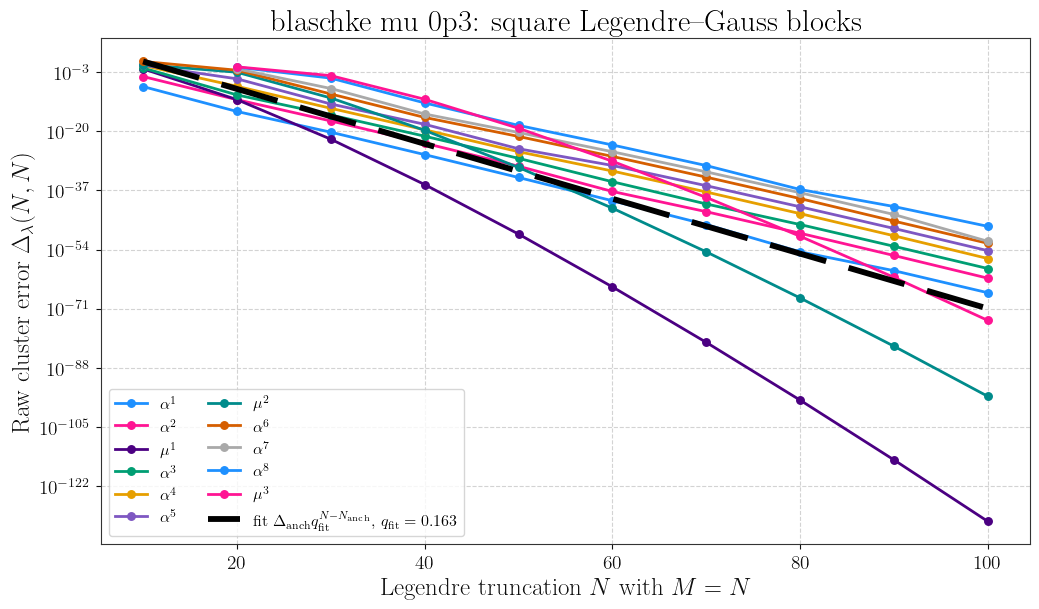

In [12]:
# Cell 12
# ============================================================
# 7. Summary and plot for raw N-sweep
# ============================================================
# This cell does not assemble a matrix.  It summarises the raw
# Galerkin--EDMD eigenvalues of Lhat_N^{(N)} computed in Cell 11 by matching
# them to the exact Blaschke target families.
#
# Important plotting convention: rows with NaN, infinite, or zero error are
# not plotted.  Some saved diagnostic tables contain exact zero placeholders
# when a target has reached the available numerical precision; plotting those
# values on a logarithmic axis creates artificial vertical drops.
#
# The deterministic single-space theory gives the admissible upper-rate base
#     q_* = max(r/rho, r_tau(rho)/r).
# For the branch-image geometry used later in the notebook, the sampled
# Cell 9 diagnostic gives q_* about 0.9268246786, while the promoted safe row
# uses q_* about 0.927000.  The dashed line below is still an empirical
# exponential guide fitted from the positive alpha-family raw errors; q_* is
# printed only for comparison with the deterministic branch-image scale.

PHASE1_QSTAR_REFERENCE =max (r_target /rho ,geo ["r_tau"]/r_target )
PHASE1_EMPIRICAL_REFERENCE_TARGETS =[
*DEFAULT_TARGET_NAMES_NONTRIVIAL [:8],
]


def phase1_summary_table (df ):
    print ("\n"+"="*100 )
    print ("Phase 1 raw Legendre--Gauss Galerkin--EDMD diagnostic summary")
    print ("-"*100 )
    print (f"{'target':<14} | {'best error':>14} | {'best N':>7} | {'best M':>7}")
    print ("-"*100 )
    for name in DEFAULT_TARGET_NAMES_WITH_TRIVIAL :
        sub =df [df ["name"]==name ].copy ()
        if len (sub )==0 :
            continue 
        sub ["err_float"]=sub ["error"].apply (lambda x :float (mp .mpf (str (x )))if str (x )!="nan"else np .nan )
        sub =sub [np .isfinite (sub ["err_float"])&(sub ["err_float"]>0 )]
        if len (sub )==0 :
            continue 
        row =sub .loc [sub ["err_float"].idxmin ()]
        print (f"{name :<14} | {row ['err_float']:14.4e} | {int (row ['N']):7d} | {int (row ['M']):7d}")
    print ("="*100 )


def phase1_latex_target_label (name ):
    """Return a LaTeX legend label for the selected target name."""
    if name .startswith ("alpha^"):
        power =name .split ("^")[1 ]
        return rf"$\alpha^{{{power }}}$"
    if name .startswith ("mu^"):
        power =name .split ("^")[1 ]
        return rf"$\mu^{{{power }}}$"
    if name .startswith ("lambda^"):
        power =name .split ("^")[1 ]
        return rf"$\lambda^{{{power }}}$"
    if name .startswith ("lambdabar^"):
        power =name .split ("^")[1 ]
        return rf"$\overline{{\lambda}}^{{{power }}}$"
    if name .startswith ("ref^"):
        power =name .split ("^")[1 ]
        return rf"$\lambda^\star_{{{power }}}$"
    return rf"${name }$"


def phase1_positive_target_rows (df ,name ):
    """Return sorted finite positive error rows for one target."""
    sub =df [df ["name"]==name ].copy ()
    if len (sub )==0 :
        return sub 
    sub ["err_float"]=sub ["error"].apply (lambda x :float (mp .mpf (str (x )))if str (x )!="nan"else np .nan )
    sub =sub [np .isfinite (sub ["err_float"])&(sub ["err_float"]>0 )]
    sub =sub .sort_values ("N")
    return sub 


def phase1_empirical_exponential_reference_curve (
df ,
displayed_targets ,
fit_targets =PHASE1_EMPIRICAL_REFERENCE_TARGETS ,
q_star =PHASE1_QSTAR_REFERENCE ,
):
    """Fit and anchor a visible empirical C q_fit^N guide for the raw plot."""
    fit_parts =[phase1_positive_target_rows (df ,name )for name in fit_targets ]
    fit_df =pd .concat ([p for p in fit_parts if len (p )],ignore_index =True )if any (len (p )for p in fit_parts )else pd .DataFrame ()
    if len (fit_df )<2 :
        return None 

    fit_N =fit_df ["N"].astype (float ).to_numpy ()
    fit_log_error =np .log (fit_df ["err_float"].astype (float ).to_numpy ())
    slope ,intercept =np .polyfit (fit_N ,fit_log_error ,1 )
    q_fit =float (np .exp (slope ))

    displayed_parts =[phase1_positive_target_rows (df ,name )for name in displayed_targets ]
    displayed =pd .concat ([p for p in displayed_parts if len (p )],ignore_index =True )if any (len (p )for p in displayed_parts )else pd .DataFrame ()
    if len (displayed )==0 :
        return None 

    n_values =np .array (sorted (displayed ["N"].astype (int ).unique ()),dtype =int )
    anchor_N =int (n_values .min ())
    anchor_error =float (displayed [displayed ["N"].astype (int )==anchor_N ]["err_float"].max ())
    ref_y =anchor_error *(q_fit **(n_values -anchor_N ))
    return n_values ,ref_y ,anchor_N ,anchor_error ,q_fit ,float (q_star )


def plot_cluster_errors_vs_N (
df ,
target_names =PHASE1_SHORT_DISPLAY_TARGET_NAMES_NONTRIVIAL ,
save_stem ="phase1_raw_cluster_errors_vs_N_latex",
use_latex =True ,
q_star =PHASE1_QSTAR_REFERENCE ,
):
    """Plot and save raw square-block cluster errors with an empirical exponential guide."""
    rc_updates ={
    "font.family":"serif",
    "font.serif":["Computer Modern Roman"],
    "mathtext.fontset":"cm",
    "axes.unicode_minus":False ,
    "axes.titlesize":22 ,
    "axes.labelsize":18 ,
    "xtick.labelsize":14 ,
    "ytick.labelsize":14 ,
    "legend.fontsize":11.5 ,
    }
    if use_latex :
        rc_updates .update ({
        "text.usetex":True ,
        "text.latex.preamble":r"\usepackage{amsmath}",
        })

    with plt .rc_context (rc_updates ):
        fig ,ax =plt .subplots (figsize =(10.5 ,6.2 ))
        for idx ,name in enumerate (target_names ):
            sub =phase1_positive_target_rows (df ,name )
            if len (sub )==0 :
                continue 
            x =sub ["N"].astype (int ).to_numpy ()
            y =sub ["err_float"].to_numpy (dtype =float )
            ax .plot (
            x ,
            y ,
            marker ="o",
            markersize =5.4 ,
            linewidth =2.0 ,
            color =THESIS_LINE_COLOURS [idx %len (THESIS_LINE_COLOURS )],
            label =phase1_latex_target_label (name ),
            )

        ref_curve =phase1_empirical_exponential_reference_curve (df ,target_names ,q_star =q_star )
        if ref_curve is not None :
            ref_x ,ref_y ,anchor_N ,anchor_error ,q_fit ,q_star_float =ref_curve 
            ax .plot (
            ref_x ,
            ref_y ,
            color ="black",
            linewidth =4.2 ,
            linestyle =(0 ,(10 ,4 )),
            label =rf"fit $\Delta_{{\rm anch}}q_{{\rm fit}}^{{N-N_{{\rm anch}}}}$, $q_{{\rm fit}}={q_fit :.3f}$",
            )
            print (
            "Phase 1 empirical reference line: "
            f"Delta_anchor*q_fit^(N-N_anchor) with q_fit={q_fit :.6f}, "
            f"N_anchor={anchor_N }, Delta_anchor={anchor_error :.6e}. "
            f"The deterministic q_* value recorded for comparison is {q_star_float :.6f}."
            )

        ax .set_yscale ("log")
        ax .set_xlabel (r"Legendre truncation $N$ with $M=N$")
        ax .set_ylabel (r"Raw cluster error $\Delta_\lambda(N,N)$")
        ax .set_title (rf"{SELECTED_MAP_LABEL.replace('_',' ')}: square Legendre--Gauss blocks")
        ax .grid (True ,which ="both",linestyle ="--",alpha =0.55 )
        ax .legend (loc ="lower left",ncol =2 ,frameon =True )
        fig .tight_layout ()

        pdf_path =FIG_DIR /f"{save_stem }.pdf"
        png_path =FIG_DIR /f"{save_stem }.png"
        fig .savefig (pdf_path ,bbox_inches ="tight")
        fig .savefig (png_path ,dpi =240 ,bbox_inches ="tight")
        print (f"Saved figure: {pdf_path }")
        print (f"Saved figure: {png_path }")
        plt .show ()
        return fig ,ax ,pdf_path ,png_path 

phase1_summary_table (raw_df )
phase1_raw_errors_fig ,phase1_raw_errors_ax ,phase1_raw_errors_pdf ,phase1_raw_errors_png =plot_cluster_errors_vs_N (raw_df )


**Cell 13**

## 8. Phase 1 ASBJ-style Blaschke empirical diagnostics

These plots use only the raw Legendre--Gauss Galerkin--EDMD transfer matrix $\widehat L_N^{(M)}$.  They are ASBJ-style empirical spectral diagnostics adapted to the Perron--Frobenius transfer setting and answer a baseline question: how do the raw Legendre--Gauss transfer eigenvalues behave before deterministic single-space certification is applied?

Phase 1 does not use the pure $r$-scaled matrix, the Hardy $X$-gauge matrix, the branch-image input-tail kernel, or the branch-image deterministic certificate.  Its role in the branch-image notebook is to keep the raw spectral baseline fixed while later phases replace the deterministic majorant.


## Phase 1 mathematics for Cell 14

This cell defines helper routines for Phase 1 plots and heatmaps.  It does not assemble transfer matrices and does not use the branch-image tail bound.

The absolute-$M$ heatmap pair set is $\mathcal G_{\mathrm{abs}}=\{(N,M):N\in\mathcal N,\ M\in\mathcal M,\ M\ge N\}$, and the oversampling pair set is $\mathcal G_{\mathrm{over}}=\{(N,N+m):N\in\mathcal N,\ m\in\mathcal M_{\mathrm{off}}\}$, optionally enlarged by a reference row.  The oversampling coordinate is $m=M-N$.

For each fixed pair $(N,c_j)$, the largest available positive finite quadrature order is used as the local reference $M_{\max}(N,j)=\max\{M:\Delta_j(N,M)\text{ is finite and positive}\}$.  The finite-$M$ excess ratio is $R_j(N,M)=\Delta_j(N,M)/\Delta_j(N,M_{\max}(N,j))$, and the plotted excess value is $\log_{10}R_j(N,M)$.

The absolute-$M$ raw-error heatmap for target $c_j$ is $G^j_{ab}=\log_{10}\Delta_j(N_a,M_b)$, with missing, non-positive, or non-finite entries left blank.  The oversampling grid is $G^{j,\mathrm{over}}_{ab}=\log_{10}\Delta_j(N_a,N_a+m_b)$.  When the value column is the excess diagnostic, the same grids contain the corresponding $\log_{10}R_j$ values.

The plotting helper converts grid centres into cell edges by midpoint interpolation, with the first and last edges extrapolated by the adjacent half-width.  If a best point is marked, it is the finite grid entry with the smallest displayed value.


In [13]:
# Cell 14
# ============================================================
# 8A. Phase 1 plotting and heatmap helpers
# ============================================================

# The Phase 1 plots use only the raw Legendre--Gauss Galerkin--EDMD
# transfer block \widehat L_N^{(M)}.  No r-scaled or Hardy X-gauge matrix is
# used here.  The heatmap plotting below is deliberately separated from the
# deterministic Schur certificate code.

PHASE1_PLOT_FONT_SIZES =globals ().get ("PHASE1_PLOT_FONT_SIZES",{
"title":22 ,
"axis_label":18 ,
"tick_label":18 ,
"legend":18 ,
"annotation":18 ,
"heatmap_array_title":26 ,
"heatmap_subplot_title":22 ,
"heatmap_axis_label":16 ,
"heatmap_tick_label":16 ,
"colourbar_title":22 ,
"small_colourbar_title":18 ,
"colourbar_tick_label":22 ,
})

if "phase1_latex_target_label"not in globals ():
    def phase1_latex_target_label (name ):
        """Return a TeX-safe label for a Blaschke target name."""
        name =str (name )
        if name .startswith ("alpha^"):
            power =name .split ("^")[1 ]
            return rf"$\alpha^{{{power }}}$"
        if name .startswith ("mu^"):
            power =name .split ("^")[1 ]
            return rf"$\mu^{{{power }}}$"
        return rf"${name }$"


def _phase1_error_to_float (x ):
    try :
        return float (x )
    except Exception :
        try :
            return float (mp .mpf (str (x )))
        except Exception :
            return np .nan 


def phase1_make_heatmap_pairs (N_values ,M_values ,require_M_ge_N =True ):
    pairs =[]
    for N in N_values :
        for M in M_values :
            if require_M_ge_N and M <N :
                continue 
            pairs .append ((int (N ),int (M )))
    return pairs 


def phase1_make_oversampling_pairs (N_values ,m_values ,ref_extra =None ):
    pairs =set ()
    for N in N_values :
        for m in m_values :
            M =int (N )+int (m )
            if M >0 :
                pairs .add ((int (N ),M ))
        if ref_extra is not None :
            M_ref =int (N )+int (ref_extra )
            if M_ref >0 :
                pairs .add ((int (N ),M_ref ))
    return sorted (pairs )


def add_phase1_oversampling_columns (df ,ref_extra =None ):
    out =df .copy ()
    out ["N"]=out ["N"].astype (int )
    out ["M"]=out ["M"].astype (int )
    out ["m"]=out ["M"]-out ["N"]
    out ["is_reference_M"]=out ["m"].astype (int )==int (ref_extra )if ref_extra is not None else False 
    return out 


def add_phase1_reference_error_ratios (df ,reference ="max_M_by_N"):
    """
    Add finite-M excess diagnostics.

    For each pair (N,target), the reference is the largest available M for that N.
    Then

        excess_ratio = error / reference_error.

    This is not monotone and is not a theorem-level quantity.  It is a diagnostic
    showing when increasing M no longer improves the raw cluster error.
    """
    out =df .copy ()
    out ["N"]=out ["N"].astype (int )
    out ["M"]=out ["M"].astype (int )
    out ["error_float"]=out ["error"].apply (_phase1_error_to_float )

    ref_lookup ={}
    for (N ,name ),group in out .groupby (["N","name"]):
        finite =group [np .isfinite (group ["error_float"])&(group ["error_float"]>0 )]
        if len (finite )==0 :
            continue 
        if reference =="max_M_by_N":
            row =finite .loc [finite ["M"].idxmax ()]
        else :
            raise ValueError ("Only reference='max_M_by_N' is implemented.")
        ref_lookup [(int (N ),str (name ))]=float (row ["error_float"])

    refs ,ratios ,logs =[],[],[]
    for row in out .itertuples (index =False ):
        key =(int (row .N ),str (row .name ))
        ref =ref_lookup .get (key ,np .nan )
        err =_phase1_error_to_float (row .error )
        refs .append (ref )
        if np .isfinite (err )and np .isfinite (ref )and err >0 and ref >0 :
            ratio =err /ref 
            ratios .append (ratio )
            logs .append (np .log10 (ratio ))
        else :
            ratios .append (np .nan )
            logs .append (np .nan )

    out ["reference_error_at_max_M"]=refs 
    out ["excess_ratio_to_max_M"]=ratios 
    out ["log10_excess_ratio_to_max_M"]=logs 
    return out 


def _centres_to_edges (values ):
    vals =np .array ([float (v )for v in values ],dtype =float )
    if len (vals )==1 :
        return np .array ([vals [0 ]-0.5 ,vals [0 ]+0.5 ],dtype =float )
    mids =0.5 *(vals [:-1 ]+vals [1 :])
    first =vals [0 ]-(mids [0 ]-vals [0 ])
    last =vals [-1 ]+(vals [-1 ]-mids [-1 ])
    return np .concatenate ([[first ],mids ,[last ]])


def _grid_absolute_M (df ,target_name ,N_values ,M_values ,value_col ="error"):
    sub =df [df ["name"]==target_name ].copy ()
    N_values =[int (N )for N in N_values ]
    M_values =[int (M )for M in M_values ]
    grid =np .full ((len (N_values ),len (M_values )),np .nan ,dtype =float )

    lookup ={}
    for row in sub .itertuples (index =False ):
        N =int (row .N )
        M =int (row .M )
        if value_col =="error":
            value =_phase1_error_to_float (row .error )
            value =np .log10 (value )if np .isfinite (value )and value >0 else np .nan 
        else :
            value =getattr (row ,value_col )
            try :
                value =float (value )
            except Exception :
                value =np .nan 
        lookup [(N ,M )]=value 

    for i ,N in enumerate (N_values ):
        for j ,M in enumerate (M_values ):
            grid [i ,j ]=lookup .get ((N ,M ),np .nan )
    return grid 


def _grid_oversampling (df ,target_name ,N_values ,m_values ,value_col ="error"):
    sub =df [df ["name"]==target_name ].copy ()
    N_values =[int (N )for N in N_values ]
    m_values =[int (m )for m in m_values ]
    grid =np .full ((len (N_values ),len (m_values )),np .nan ,dtype =float )

    lookup ={}
    for row in sub .itertuples (index =False ):
        N =int (row .N )
        m =int (row .M )-int (row .N )
        if value_col =="error":
            value =_phase1_error_to_float (row .error )
            value =np .log10 (value )if np .isfinite (value )and value >0 else np .nan 
        else :
            value =getattr (row ,value_col )
            try :
                value =float (value )
            except Exception :
                value =np .nan 
        lookup [(N ,m )]=value 

    for i ,N in enumerate (N_values ):
        for j ,m in enumerate (m_values ):
            grid [i ,j ]=lookup .get ((N ,m ),np .nan )
    return grid 


def _copy_cmap_with_bad (cmap ,bad ="white"):
    obj =cmap .copy ()
    obj .set_bad (bad )
    return obj 


def _global_vrange (grids ,robust =False ):
    finite_values =[g [np .isfinite (g )].ravel ()for g in grids if np .any (np .isfinite (g ))]
    if not finite_values :
        return None ,None 
    vals =np .concatenate (finite_values )
    if vals .size ==0 :
        return None ,None 
    if robust and vals .size >20 :
        return np .quantile (vals ,0.02 ),np .quantile (vals ,0.98 )
    return np .min (vals ),np .max (vals )


def _heatmap_value_label (value_col ):
    if value_col =="error":
        return "log10 raw cluster error"
    if value_col =="log10_excess_ratio_to_max_M":
        return "log10(error / error at largest M)"
    return value_col 




def _phase1_heatmap_target_label (target ):
    """Return a TeX-safe target label for Phase 1 heatmap subplot titles."""
    if "phase1_latex_target_label"in globals ():
        return phase1_latex_target_label (str (target ))
    target =str (target )
    if target .startswith ("alpha^"):
        return rf"$\alpha^{{{target .split ('^')[1 ]}}}$"
    if target .startswith ("mu^"):
        return rf"$\mu^{{{target .split ('^')[1 ]}}}$"
    return rf"${target }$"


def plot_heatmap_array_absolute_M (
df ,
target_names ,
N_values ,
M_values ,
value_col ="error",
ncols =3 ,
cmap =None ,
title_prefix ="",
array_title =None ,
cbar_title =None ,
share_colour =True ,
robust_colour =False ,
mark_best =True ,
):
    """
    Plot many absolute-M heatmaps in an array with ncols=3 by default.

    Blank cells correspond to missing pairs, typically M<N.  The colourbar is
    horizontal under the full array, which avoids overlap in Jupyter output.
    """
    target_names =list (target_names )
    nplots =len (target_names )
    nrows =int (math .ceil (nplots /ncols ))

    grids =[_grid_absolute_M (df ,target ,N_values ,M_values ,value_col =value_col )for target in target_names ]

    if cmap is None :
        cmap =THESIS_ERROR_CMAP if value_col =="error"else THESIS_EXCESS_CMAP 
    cmap_obj =_copy_cmap_with_bad (cmap ,bad ="white")

    if share_colour :
        vmin ,vmax =_global_vrange (grids ,robust =robust_colour )
    else :
        vmin ,vmax =None ,None 

    x_edges =_centres_to_edges (M_values )
    y_edges =_centres_to_edges (N_values )

    fig ,axes =plt .subplots (
    nrows ,
    ncols ,
    figsize =(5.3 *ncols ,4.15 *nrows +0.7 ),
    squeeze =False ,
    facecolor ="white",
    constrained_layout =True ,
    )

    active_axes =[]
    last_mesh =None 

    for idx ,target in enumerate (target_names ):
        ax =axes [idx //ncols ,idx %ncols ]
        active_axes .append (ax )
        grid =grids [idx ]

        if not share_colour :
            local_vmin ,local_vmax =_global_vrange ([grid ],robust =robust_colour )
        else :
            local_vmin ,local_vmax =vmin ,vmax 

        mesh =ax .pcolormesh (
        x_edges ,
        y_edges ,
        grid ,
        shading ="auto",
        cmap =cmap_obj ,
        vmin =local_vmin ,
        vmax =local_vmax ,
        )
        last_mesh =mesh 

        ax .set_title (
        f"{title_prefix }{_phase1_heatmap_target_label (target )}",
        fontsize =PHASE1_PLOT_FONT_SIZES .get ("heatmap_subplot_title",16 ),
        )
        ax .set_xlabel (r"$M$",fontsize =PHASE1_PLOT_FONT_SIZES .get ("heatmap_axis_label",18 ))
        ax .set_ylabel (r"$N$",fontsize =PHASE1_PLOT_FONT_SIZES .get ("heatmap_axis_label",18 ))
        heatmap_m_ticks =globals ().get ("PHASE1_HEATMAP_M_TICKS",M_values )
        heatmap_m_ticks =[int (t )for t in heatmap_m_ticks if min (M_values )<=int (t )<=max (M_values )]
        ax .set_xticks (heatmap_m_ticks )
        ax .set_xticklabels ([str (M )for M in heatmap_m_ticks ],rotation =0 ,ha ="center")
        ax .set_yticks (N_values )
        ax .set_yticklabels ([str (N )for N in N_values ])
        ax .tick_params (axis ="both",which ="major",labelsize =PHASE1_PLOT_FONT_SIZES .get ("heatmap_tick_label",10 ))
        ax .grid (True ,linestyle ="--",alpha =0.35 )

        if mark_best and np .any (np .isfinite (grid )):
            idx_min =np .nanargmin (grid )
            i ,j =np .unravel_index (idx_min ,grid .shape )
            ax .plot (
            M_values [j ],
            N_values [i ],
            marker ="o",
            markersize =8 ,
            markerfacecolor ="none",
            markeredgecolor ="white",
            markeredgewidth =1.8 ,
            )
            ax .plot (
            M_values [j ],
            N_values [i ],
            marker ="o",
            markersize =9 ,
            markerfacecolor ="none",
            markeredgecolor =PALETTE ["main"],
            markeredgewidth =0.9 ,
            )

    for idx in range (nplots ,nrows *ncols ):
        axes [idx //ncols ,idx %ncols ].set_visible (False )

    if array_title is None :
        array_title ="Phase 1 Blaschke raw Legendre--Gauss heatmaps"
    fig .suptitle (array_title ,fontsize =PHASE1_PLOT_FONT_SIZES .get ("heatmap_array_title",20 ),y =1.03 )

    if share_colour and last_mesh is not None :
        cbar =fig .colorbar (
        last_mesh ,
        ax =active_axes ,
        orientation ="horizontal",
        fraction =0.055 ,
        pad =0.075 ,
        aspect =45 ,
        )
        if cbar_title is None :
            cbar_title =_heatmap_value_label (value_col )
        cbar .ax .set_title (cbar_title ,fontsize =PHASE1_PLOT_FONT_SIZES .get ("colourbar_title",14 ),pad =8 )
        cbar .ax .tick_params (labelsize =PHASE1_PLOT_FONT_SIZES .get ("colourbar_tick_label",10 ))

    elif not share_colour :
        for ax in active_axes :
            cbar =fig .colorbar (
            ax .collections [0 ],
            ax =ax ,
            orientation ="horizontal",
            fraction =0.08 ,
            pad =0.12 ,
            aspect =30 ,
            )
            cbar .ax .set_title (
            _heatmap_value_label (value_col ),
            fontsize =PHASE1_PLOT_FONT_SIZES .get ("small_colourbar_title",12 ),
            pad =6 ,
            )
            cbar .ax .tick_params (labelsize =PHASE1_PLOT_FONT_SIZES .get ("colourbar_tick_label",10 ))

    plt .show ()
    return fig ,axes ,grids 


def plot_heatmap_array_oversampling (
df ,
target_names ,
N_values ,
m_values ,
value_col ="error",
ncols =3 ,
cmap =None ,
title_prefix ="",
array_title =None ,
cbar_title =None ,
share_colour =True ,
robust_colour =False ,
mark_best =True ,
):
    """
    Plot many oversampling heatmaps with axes N and m=M-N.
    Uses one horizontal colourbar below the full array.
    """
    target_names =list (target_names )
    nplots =len (target_names )
    nrows =int (math .ceil (nplots /ncols ))

    grids =[_grid_oversampling (df ,target ,N_values ,m_values ,value_col =value_col )for target in target_names ]

    if cmap is None :
        cmap =THESIS_ERROR_CMAP if value_col =="error"else THESIS_EXCESS_CMAP 
    cmap_obj =_copy_cmap_with_bad (cmap ,bad ="white")

    if share_colour :
        vmin ,vmax =_global_vrange (grids ,robust =robust_colour )
    else :
        vmin ,vmax =None ,None 

    x_edges =_centres_to_edges (m_values )
    y_edges =_centres_to_edges (N_values )

    fig ,axes =plt .subplots (
    nrows ,
    ncols ,
    figsize =(5.3 *ncols ,4.15 *nrows +0.7 ),
    squeeze =False ,
    facecolor ="white",
    constrained_layout =True ,
    )

    active_axes =[]
    last_mesh =None 

    for idx ,target in enumerate (target_names ):
        ax =axes [idx //ncols ,idx %ncols ]
        active_axes .append (ax )
        grid =grids [idx ]

        if not share_colour :
            local_vmin ,local_vmax =_global_vrange ([grid ],robust =robust_colour )
        else :
            local_vmin ,local_vmax =vmin ,vmax 

        mesh =ax .pcolormesh (
        x_edges ,
        y_edges ,
        grid ,
        shading ="auto",
        cmap =cmap_obj ,
        vmin =local_vmin ,
        vmax =local_vmax ,
        )
        last_mesh =mesh 

        ax .set_title (
        f"{title_prefix }{_phase1_heatmap_target_label (target )}",
        fontsize =PHASE1_PLOT_FONT_SIZES .get ("heatmap_subplot_title",16 ),
        )
        ax .set_xlabel (r"$m=M-N$",fontsize =PHASE1_PLOT_FONT_SIZES .get ("heatmap_axis_label",18 ))
        ax .set_ylabel (r"$N$",fontsize =PHASE1_PLOT_FONT_SIZES .get ("heatmap_axis_label",18 ))
        heatmap_m_offset_ticks =globals ().get ("PHASE1_HEATMAP_M_OFFSET_TICKS",m_values )
        heatmap_m_offset_ticks =[int (t )for t in heatmap_m_offset_ticks if min (m_values )<=int (t )<=max (m_values )]
        ax .set_xticks (heatmap_m_offset_ticks )
        ax .set_xticklabels ([str (m )for m in heatmap_m_offset_ticks ])
        ax .set_yticks (N_values )
        ax .set_yticklabels ([str (N )for N in N_values ])
        ax .tick_params (axis ="both",which ="major",labelsize =PHASE1_PLOT_FONT_SIZES .get ("heatmap_tick_label",10 ))
        ax .grid (True ,linestyle ="--",alpha =0.35 )

        if mark_best and np .any (np .isfinite (grid )):
            idx_min =np .nanargmin (grid )
            i ,j =np .unravel_index (idx_min ,grid .shape )
            ax .plot (
            m_values [j ],
            N_values [i ],
            marker ="o",
            markersize =8 ,
            markerfacecolor ="none",
            markeredgecolor ="white",
            markeredgewidth =1.8 ,
            )
            ax .plot (
            m_values [j ],
            N_values [i ],
            marker ="o",
            markersize =9 ,
            markerfacecolor ="none",
            markeredgecolor =PALETTE ["main"],
            markeredgewidth =0.9 ,
            )

    for idx in range (nplots ,nrows *ncols ):
        axes [idx //ncols ,idx %ncols ].set_visible (False )

    if array_title is None :
        array_title ="Phase 1 Blaschke oversampling heatmaps"
    fig .suptitle (array_title ,fontsize =PHASE1_PLOT_FONT_SIZES .get ("heatmap_array_title",20 ),y =1.03 )

    if share_colour and last_mesh is not None :
        cbar =fig .colorbar (
        last_mesh ,
        ax =active_axes ,
        orientation ="horizontal",
        fraction =0.055 ,
        pad =0.075 ,
        aspect =45 ,
        )
        if cbar_title is None :
            cbar_title =_heatmap_value_label (value_col )
        cbar .ax .set_title (cbar_title ,fontsize =PHASE1_PLOT_FONT_SIZES .get ("colourbar_title",14 ),pad =8 )
        cbar .ax .tick_params (labelsize =PHASE1_PLOT_FONT_SIZES .get ("colourbar_tick_label",10 ))

    elif not share_colour :
        for ax in active_axes :
            cbar =fig .colorbar (
            ax .collections [0 ],
            ax =ax ,
            orientation ="horizontal",
            fraction =0.08 ,
            pad =0.12 ,
            aspect =30 ,
            )
            cbar .ax .set_title (
            _heatmap_value_label (value_col ),
            fontsize =PHASE1_PLOT_FONT_SIZES .get ("small_colourbar_title",12 ),
            pad =6 ,
            )
            cbar .ax .tick_params (labelsize =PHASE1_PLOT_FONT_SIZES .get ("colourbar_tick_label",10 ))

    plt .show ()
    return fig ,axes ,grids 


## Phase 1 mathematics for Cell 15

This cell executes the Phase 1 empirical diagnostics using the raw Legendre--Gauss transfer blocks $\widehat L_N^{(M)}$.  No pure $r$-scaled matrix, Hardy-gauge matrix, Schur envelope, branch-image input-tail kernel, or contour certificate is used here.

### Eigenvalue-cloud diagnostics

For each displayed block, the computed eigenvalue multiset is $\Lambda_{\mathrm{comp}}(N,M)=\operatorname{spec}(\widehat L_N^{(M)})$.  The exact real target centres are $1$, $\alpha^p$, and $\mu^p$, and the matched finite approximations are the selected multisets $Z_j$ from the raw cluster matcher.

For oversampling-displacement plots, two finite spectra at the same trial dimension are compared inside a radius window: $A_{N,M_0}(r_0)=\{z\in\Lambda_{\mathrm{comp}}(N,M_0): |\operatorname{Re}z|\le r_0,\ |\operatorname{Im}z|\le r_0\}$ and $A_{N,M_1}(r_0)$ is defined analogously.  The greedy pairing selects the nearest currently unassigned point, records $d(z,w)=|w-z|$, and plots the magnified endpoint $z+\gamma(w-z)$ when a visual magnification factor $\gamma$ is used.

### Fixed-N M sweep

The fixed-dimension sweep uses $N_0=25$ and $M\in\{10,11,\ldots,39\}$.  For each pair $(N_0,M)$ and target record $c_j$, the worker computes $\Delta_j(N_0,M)=\max_{z\in Z_j(N_0,M)}|z-\lambda_j|$.  The plotted target list is $\alpha$, $\alpha^2$, $\mu$, $\alpha^3$, $\alpha^4$, $\alpha^5$, $\mu^2$, and $\alpha^6$.

The local empirical finite-$M$ guide is fitted over the displayed pre-saturation window satisfying $16\le M\le N_0$ and $10^{-14}<\Delta_j(N_0,M)<10^{-1}$.  The fitted model is $\log\Delta_j(N_0,M)\approx a_M+b_M M$, with $q_M=e^{b_M}$, and the plotted guide is $e^{a_M+b_MM}$.  The vertical reference line marks $M=N_0$.

### Near-square heatmap diagnostics

In the active near-square mode, $\mathcal N=\{6,8,10,12,15,18,20,22,25,28,30\}$ and $\mathcal M=\{6,8,10,12,14,16,18,20,22,24,25,26,28,30,32,36,40,48\}$, restricted to $M\ge N$.  The plotted targets are $\alpha$, $\alpha^2$, $\mu$, $\alpha^5$, $\mu^2$, and $\alpha^8$.

The first heatmap array displays $\log_{10}\Delta_j(N,M)$, and the second displays $\log_{10}(\Delta_j(N,M)/\Delta_j(N,M_{\max}(N,j)))$.  Thus Cell 15 separates raw spectral convergence as $N$ increases, finite-$M$ quadrature stabilisation at fixed $N$, and movement of finite-section eigenvalues under oversampling.  These diagnostics remain the baseline raw spectral layer for the branch-image certificate introduced later.


Saved Phase 1 eigenvalue-cloud comparison figure: outputs/blaschke_deformation_certifier/figures/phase1_eigencloud_leading_interval_comparison.png
Saved CSV: outputs/blaschke_deformation_certifier/data/phase1_eigencloud_leading_interval_comparison_points.csv
Saved Parquet: outputs/blaschke_deformation_certifier/data/phase1_eigencloud_leading_interval_comparison_points.parquet


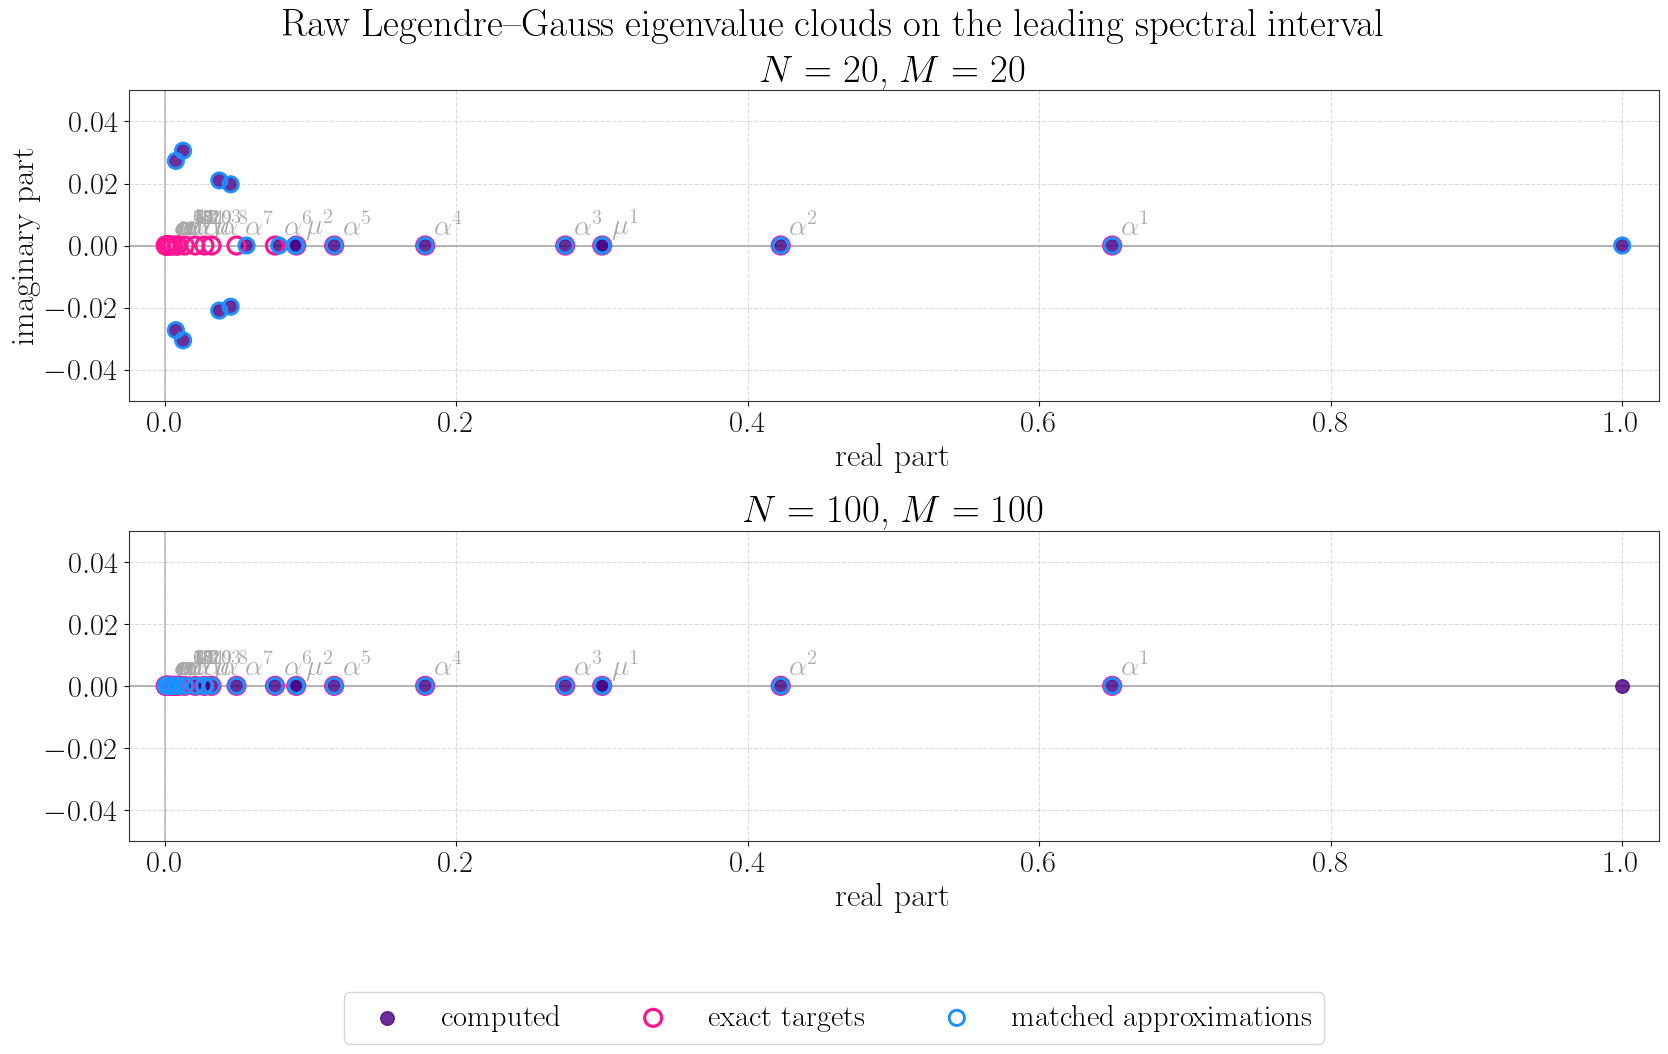

Saved CSV: outputs/blaschke_deformation_certifier/data/phase1_N20_M20_to_M30_cloud_displacements.csv
Saved Parquet: outputs/blaschke_deformation_certifier/data/phase1_N20_M20_to_M30_cloud_displacements.parquet


Saved Phase 1 oversampling displacement figure: outputs/blaschke_deformation_certifier/figures/phase1_N20_M20_to_M30_eigencloud_displacement.png


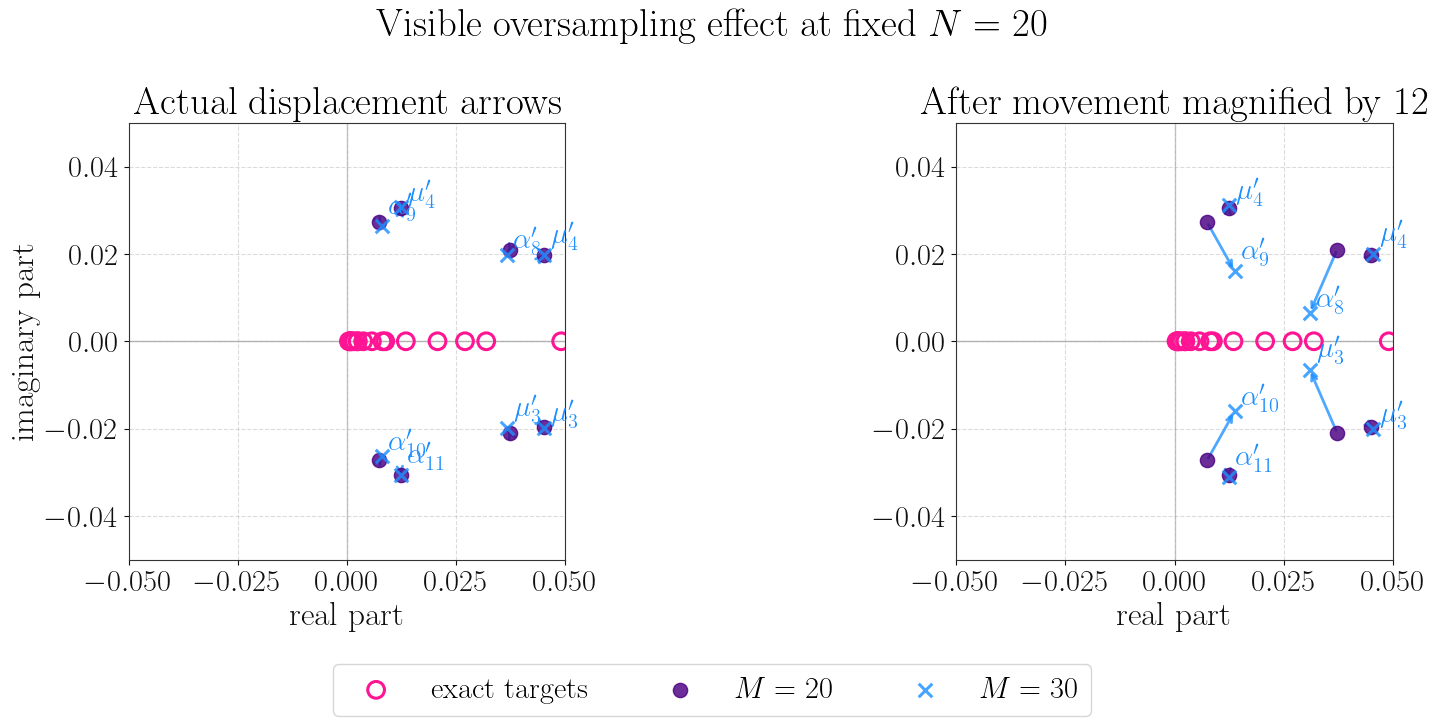

Saved CSV: outputs/blaschke_deformation_certifier/data/phase1_N12_M12_to_M24_visible_cloud_displacements.csv
Saved Parquet: outputs/blaschke_deformation_certifier/data/phase1_N12_M12_to_M24_visible_cloud_displacements.parquet


Saved Phase 1 oversampling displacement figure: outputs/blaschke_deformation_certifier/figures/phase1_N12_M12_to_M24_visible_eigencloud_displacement.png


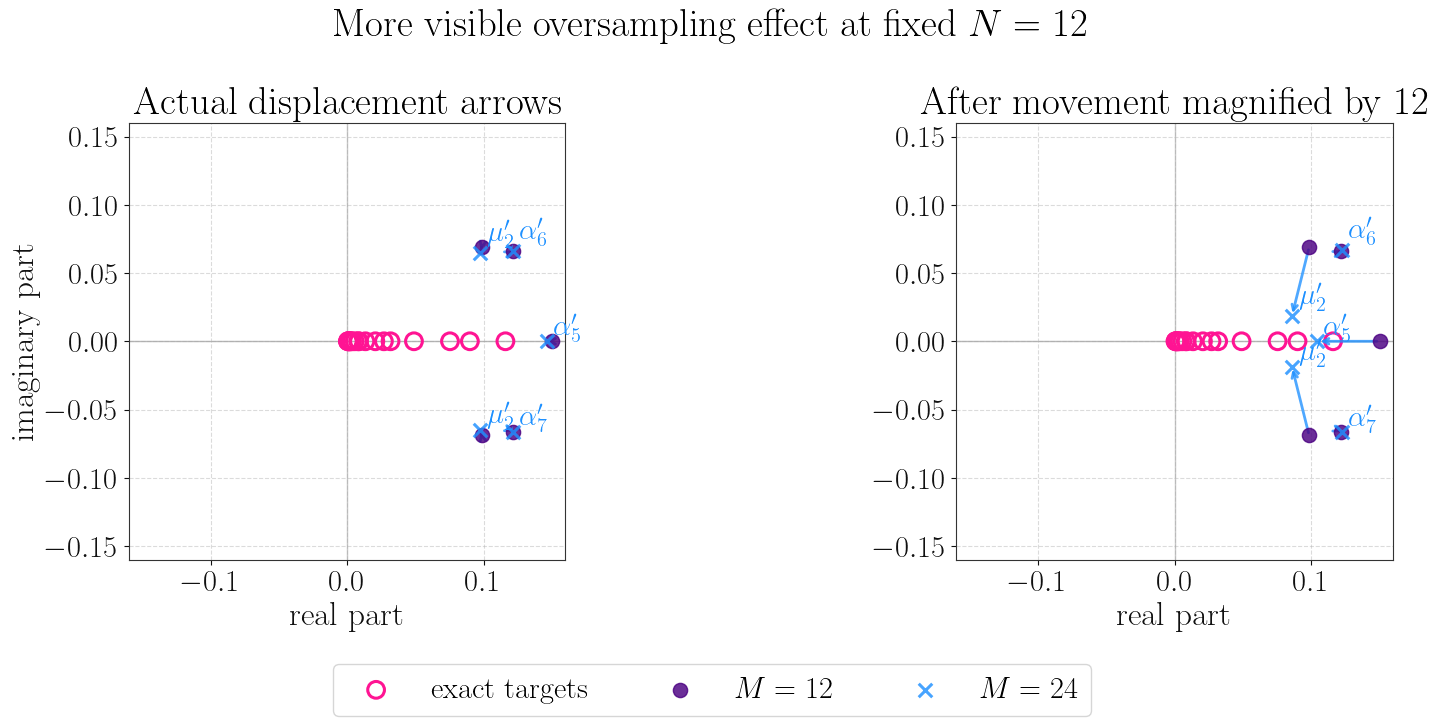

Running strict mpmath M-sweep at N=25 with 24 workers.


strict mpmath raw pair sweep:   0%|          | 0/30 [00:00<?, ?job/s]

Saved CSV: outputs/blaschke_deformation_certifier/data/phase1_raw_error_vs_M_N25.csv
Saved Parquet: outputs/blaschke_deformation_certifier/data/phase1_raw_error_vs_M_N25.parquet

Phase 1 raw Legendre--Gauss Galerkin--EDMD diagnostic summary
----------------------------------------------------------------------------------------------------
target         |     best error |  best N |  best M
----------------------------------------------------------------------------------------------------
alpha^1        |     2.5660e-17 |      25 |      25
alpha^2        |     1.7765e-15 |      25 |      26
mu^1           |     1.1697e-16 |      25 |      25
alpha^3        |     8.0511e-13 |      25 |      26
alpha^4        |     8.1764e-12 |      25 |      27
alpha^5        |     6.6041e-09 |      25 |      25
mu^2           |     2.1719e-07 |      25 |      25
alpha^6        |     4.7577e-07 |      25 |      26
alpha^7        |     9.7402e-05 |      25 |      25
alpha^8        |     1.5317e-03 |    

Saved Phase 1 fixed-N M-sweep figure: outputs/blaschke_deformation_certifier/figures/phase1_raw_cluster_errors_vs_M_N25_latex.png


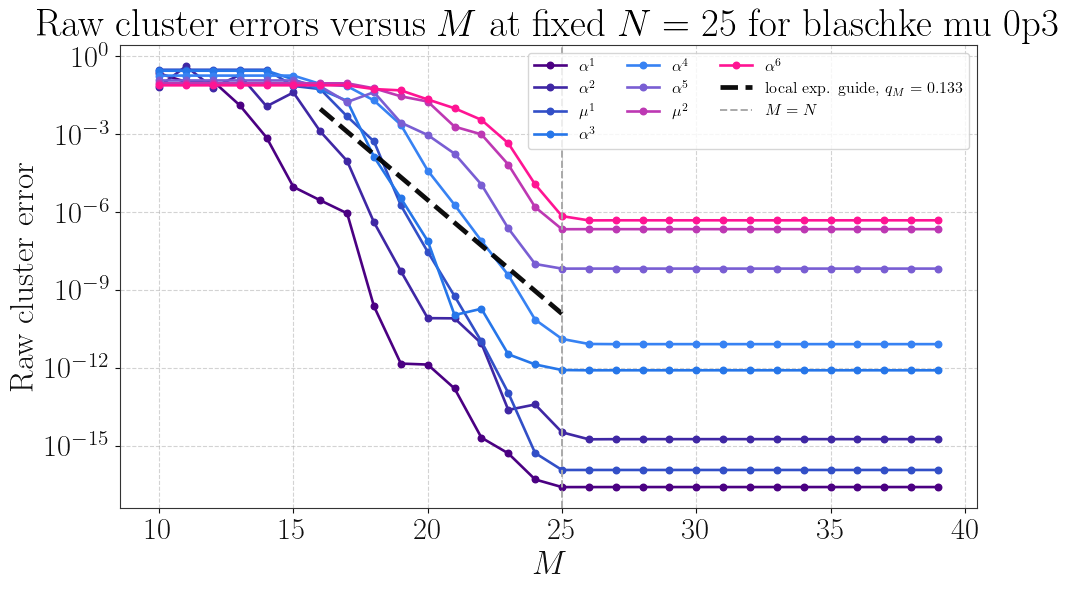

Running strict mpmath near-square heatmap with 131 valid M>=N pairs and 24 workers.


strict mpmath raw pair sweep:   0%|          | 0/131 [00:00<?, ?job/s]

Saved CSV: outputs/blaschke_deformation_certifier/data/phase1_raw_NM_heatmap_data_near_square.csv
Saved Parquet: outputs/blaschke_deformation_certifier/data/phase1_raw_NM_heatmap_data_near_square.parquet

Phase 1 raw Legendre--Gauss Galerkin--EDMD diagnostic summary
----------------------------------------------------------------------------------------------------
target         |     best error |  best N |  best M
----------------------------------------------------------------------------------------------------
alpha^1        |     2.3671e-21 |      30 |      32
alpha^2        |     7.7488e-18 |      30 |      32
mu^1           |     4.5968e-23 |      30 |      30
alpha^3        |     2.4126e-16 |      30 |      32
alpha^4        |     3.2284e-14 |      30 |      32
alpha^5        |     3.7601e-13 |      30 |      32
mu^2           |     3.1115e-11 |      30 |      30
alpha^6        |     4.3018e-10 |      30 |      30
alpha^7        |     1.1084e-08 |      30 |      40
alpha^8    

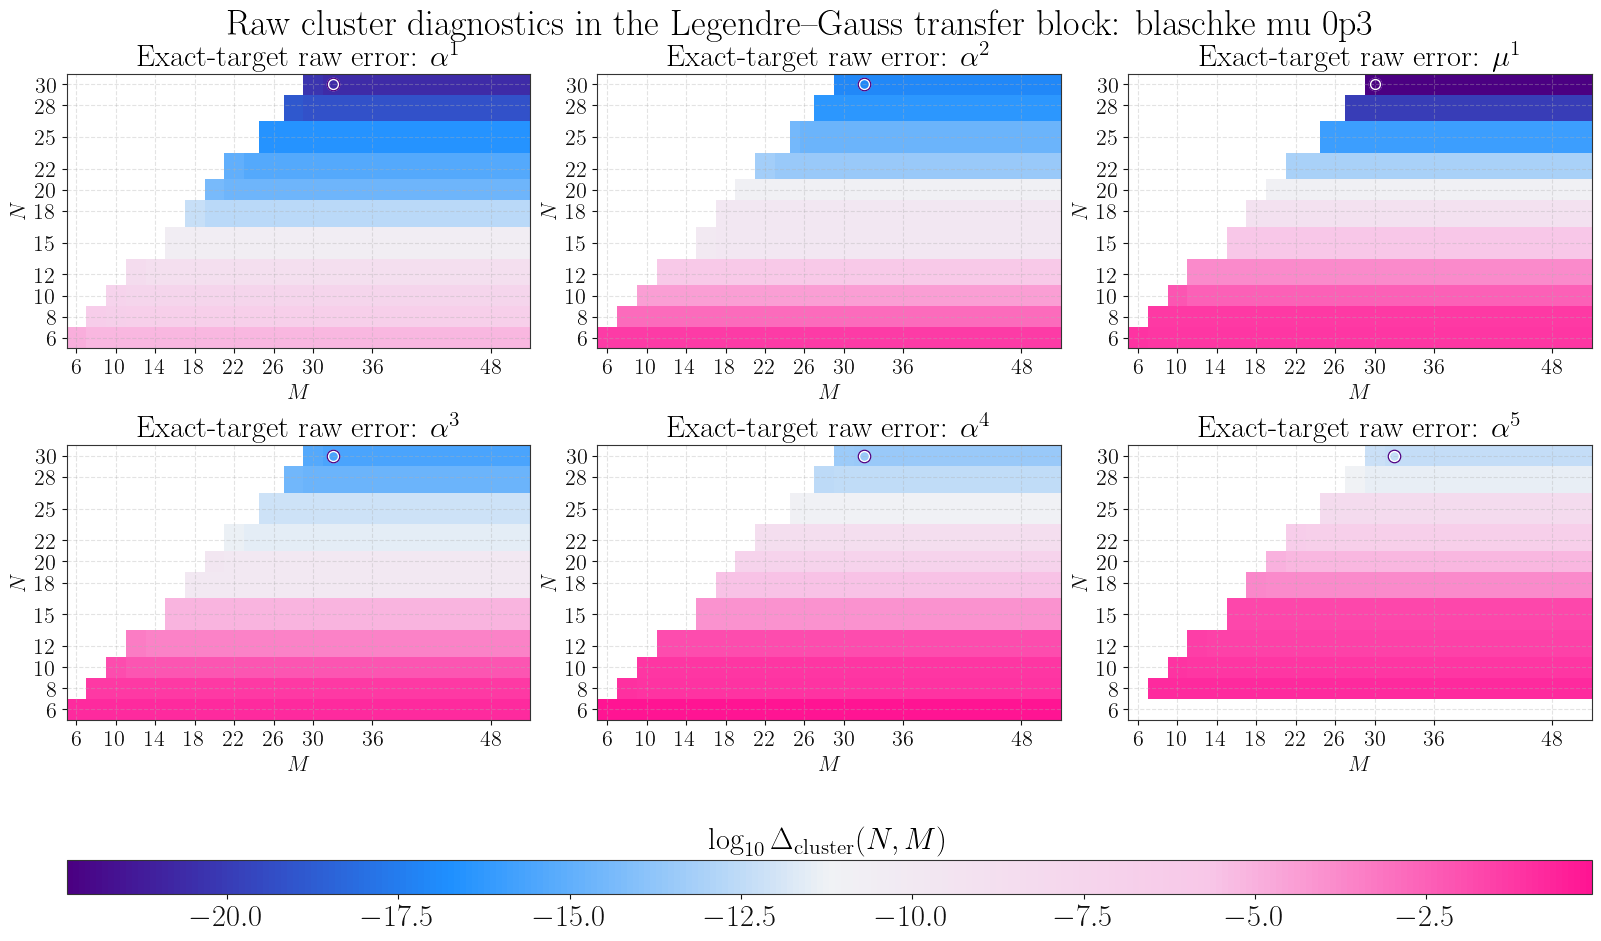

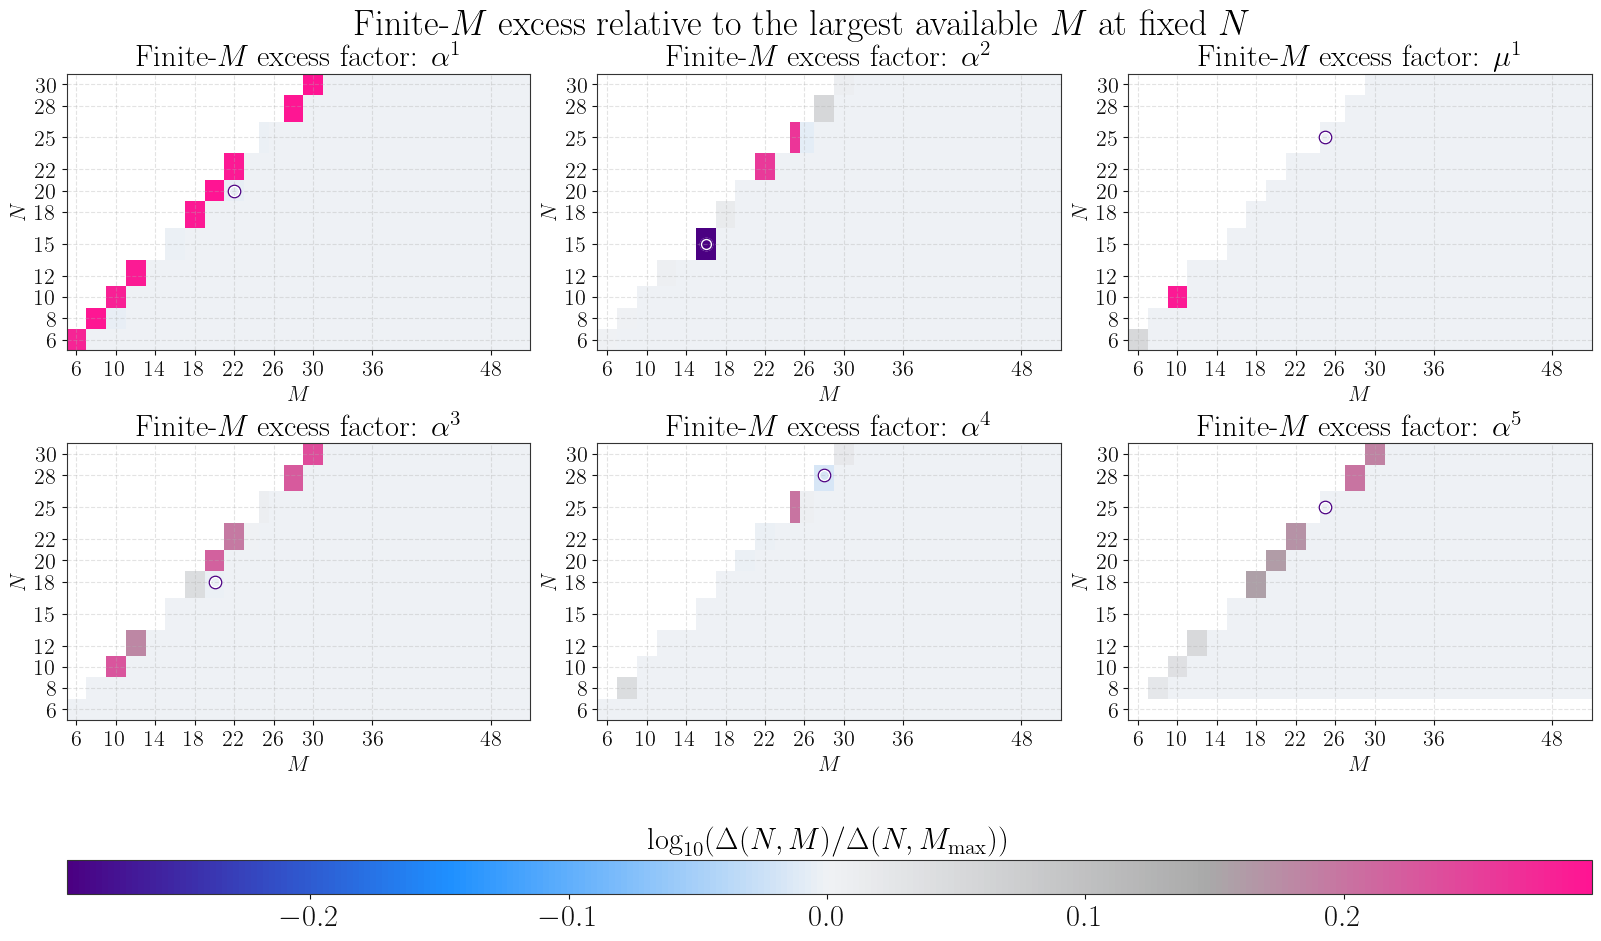

In [14]:
# Cell 15
# ============================================================
# 8B. Phase 1 runs: eigencloud, fixed-N M-sweep, and heatmaps
# ============================================================
# All matrices assembled in this cell are raw Galerkin--EDMD transfer blocks
# Lhat_N^{(M)}.  These runs are empirical spectral diagnostics only; they are
# not Schur certificates and not Hardy X-gauge contour tests.

import ast 
from matplotlib .colors import LinearSegmentedColormap ,to_hex 

RUN_PHASE1_EIGENCLOUD =True 
RUN_PHASE1_M_SWEEP =True 
RUN_PHASE1_NM_HEATMAP =True 

PHASE1_WORKERS =max (1 ,int (cfg .process_workers ))
PHASE1_MATCH_MAX_POWER =int (globals ().get ("RAW_SWEEP_TARGET_MAX_POWER",25 ))
PHASE1_MATCH_TARGET_COUNT =int (globals ().get ("RAW_SWEEP_TARGET_CLUSTER_COUNT",len (DEFAULT_TARGET_NAMES_WITH_TRIVIAL )))

# Phase 1 colours are defined globally in Cell 3.  The fallback below keeps
# this cell runnable after a partial restart, but does not override Cell 3.
if "PALETTE"not in globals ():
    PALETTE ={
    "real":"dodgerblue",
    "imag":"deeppink",
    "main":"indigo",
    "ref":"darkgrey",
    "bg":"#f0f2f5",
    }

if "PHASE1_GRADIENT_CMAP"not in globals ():
    PHASE1_GRADIENT_CMAP =LinearSegmentedColormap .from_list (
    "phase1_indigo_blue_pink",
    (
    (0.00 ,PALETTE .get ("main")),
    (0.52 ,PALETTE .get ("real")),
    (1.00 ,PALETTE .get ("imag")),
    ),
    )

if "phase1_gradient_palette"not in globals ():
    def phase1_gradient_palette (labels ):
        labels =tuple (labels )
        denom =max (1 ,len (labels )-1 )
        return {
        label :to_hex (PHASE1_GRADIENT_CMAP (i /denom ))
        for i ,label in enumerate (labels )
        }

        # Font-size knobs for Phase 1 auxiliary plots.
        # Edit these values, then rerun Cell 14 and Cell 15 to redraw figures.
PHASE1_PLOT_FONT_SIZES ={
"title":28 ,
"axis_label":24 ,
"tick_label":22 ,
"legend":22 ,
"annotation":21 ,
"heatmap_array_title":26 ,
"heatmap_subplot_title":22 ,
"heatmap_axis_label":16 ,
"heatmap_tick_label":16 ,
"colourbar_title":22 ,
"small_colourbar_title":18 ,
"colourbar_tick_label":22 ,
}

# Match the Cell 12 plot font sizes for all Phase 1 auxiliary figures.
PHASE1_CELL15_FONT_RC ={
"font.family":"serif",
"font.serif":["Computer Modern Roman"],
"mathtext.fontset":"cm",
"axes.unicode_minus":False ,
"axes.titlesize":PHASE1_PLOT_FONT_SIZES ["title"],
"axes.labelsize":PHASE1_PLOT_FONT_SIZES ["axis_label"],
"xtick.labelsize":PHASE1_PLOT_FONT_SIZES ["tick_label"],
"ytick.labelsize":PHASE1_PLOT_FONT_SIZES ["tick_label"],
"legend.fontsize":PHASE1_PLOT_FONT_SIZES ["legend"],
"text.usetex":True ,
"text.latex.preamble":r"\usepackage{amsmath}",
}
plt .rcParams .update (PHASE1_CELL15_FONT_RC )

# Recommended modes:
#   "near_square"        : absolute-M view close to M=N, blank triangle M<N expected.
#   "small_oversampling" : axes are N and m=M-N, no blank triangle.
#   "asbj_log"           : visual ASBJ-style layout, mostly saturated for Legendre--Gauss.
PHASE1_HEATMAP_GRID_MODE ="near_square"
PHASE1_HEATMAP_TARGETS =list(globals().get("PHASE1_SHORT_DISPLAY_TARGET_NAMES_NONTRIVIAL", []))[:6]
PHASE1_HEATMAP_M_TICKS =[6 ,10 ,14 ,18 ,22 ,26 ,30 ,36 ,48 ]
PHASE1_HEATMAP_M_OFFSET_TICKS =[0 ,2 ,4 ,8 ,12 ,16 ,24 ,48 ]
# The Cell 12 raw-error plot keeps the short thesis tracking list.  The
# eigenvalue-cloud plots below use the longer raw-sweep matching table
# computed in Cell 11 and summarised without changing the Cell 12 plot.
PHASE1_EIGENCLOUD_TARGET_COUNT =int (globals ().get ("RAW_SWEEP_TARGET_CLUSTER_COUNT",25 ))


def phase1_raw_sweep_rows_for_cloud (N ,M ,target_count ):
    """Return stored raw-sweep matching rows used by the eigencloud overlays."""
    if "raw_df"in globals ():
        source_df =raw_df .copy ()
    else :
        raw_path =DATA_DIR /"raw_spectrum_square_N_sweep.csv"
        if not raw_path .exists ():
            raise FileNotFoundError ("Run Cell 11 before Cell 15 so the extended raw-sweep table exists.")
        source_df =pd .read_csv (raw_path )

    rows =source_df [
    (source_df ["N"].astype (int )==int (N ))
    &(source_df ["M"].astype (int )==int (M ))
    ].head (int (target_count )).copy ()
    if len (rows )==0 :
        raise ValueError (f"No stored raw-sweep matching rows found for N={N }, M={M }. Run Cell 11 first.")
    if len (rows )<int (target_count ):
        print (
        f"Only {len (rows )} stored matched targets found for N={N }, M={M }. "
        "Rerun Cell 11 to regenerate the extended 25-target raw sweep."
        )
    return rows 


def phase1_target_real_from_row (row ):
    """Read the real part of a stored target centre from a raw-sweep row."""
    if "target_float"in row and pd .notna (row ["target_float"]):
        try:
            return float (row ["target_float"])
        except Exception:
            pass
    return float (phase1_parse_complex_value (row ["target"]).real)


def phase1_parse_complex_value (value ):
    """Parse mpmath or Python-style complex values stored in raw sweep tables."""
    if isinstance (value ,complex ):
        return value 
    text =str (value ).strip ()
    try :
        z =mp .mpc (text )
        return complex (float (mp .re (z )),float (mp .im (z )))
    except Exception :
        pass 

    compact =text .replace (" ","")
    compact =compact .replace ("I","j").replace ("i","j")
    try :
        z =complex (compact )
        return complex (float (z .real ),float (z .imag ))
    except Exception as exc :
        raise ValueError (f"Could not parse complex value: {text }")from exc 


def phase1_selected_values_from_raw_row (selected ):
    """Parse selected finite eigenvalues stored by the raw cluster matcher."""
    if selected is None :
        return []
    if isinstance (selected ,(list ,tuple )):
        items =list (selected )
    else :
        text =str (selected )
        if text .strip ()in ("","nan","None"):
            return []
        try :
            items =ast .literal_eval (text )
        except Exception :
            items =[text ]
        if isinstance (items ,str ):
            items =[items ]

    values =[]
    for item in items :
        try :
            values .append (phase1_parse_complex_value (item ))
        except Exception :
            continue 
    return values 


def phase1_raw_sweep_eigvals_for_cloud (N ,M ):
    """Return all stored finite eigenvalues from the Cell 11 raw square sweep."""
    if "raw_results"in globals ()and isinstance (raw_results ,dict )and "eig_rows"in raw_results :
        eig_source_df =pd .DataFrame (raw_results ["eig_rows"])
    else :
        eig_path =DATA_DIR /"raw_spectrum_square_N_sweep_eigenvalues.csv"
        if not eig_path .exists ():
            raise FileNotFoundError ("Run Cell 11 before Cell 15 so the raw-sweep eigenvalue table exists.")
        eig_source_df =pd .read_csv (eig_path )

    rows =eig_source_df [
    (eig_source_df ["N"].astype (int )==int (N ))
    &(eig_source_df ["M"].astype (int )==int (M ))
    ].copy ()
    if len (rows )==0 :
        raise ValueError (f"No stored raw-sweep eigenvalues found for N={N }, M={M }. Run Cell 11 first.")

    eigvals =[]
    for item in rows ["eig"]:
        eigvals .append (phase1_parse_complex_value (item ))
    return eigvals 

def phase1_cloud_block_data (N ,M ,target_count ):
    """Return computed eigenvalues, exact targets, and matched approximations for one cloud panel."""
    N =int (N )
    M =int (M )
    try :
        eig_cloud =phase1_raw_sweep_eigvals_for_cloud (N ,M )
        match_df =phase1_raw_sweep_rows_for_cloud (N ,M ,target_count )
        source ="stored raw sweep"
    except Exception :
        match_path =DATA_DIR /f"phase1_eigencloud_match_N{N }_M{M }.csv"
        eig_path =DATA_DIR /f"phase1_eigencloud_eigenvalues_N{N }_M{M }.csv"
        if match_path .exists ()and eig_path .exists ():
            match_df =pd .read_csv (match_path ).head (int (target_count )).copy ()
            eig_rows_df =pd .read_csv (eig_path )
            eig_cloud =[phase1_parse_complex_value (item )for item in eig_rows_df ["eig"]]
            source ="saved comparison block"
        else :
            print (f"Computing comparison cloud block for N={N }, M={M }.")
            rows ,results =run_pair_sweep_mpmath_raw (
            [(N ,M )],
            map_spec =SELECTED_MAP_SPEC ,
            dps =cfg .dps ,
            workers =1 ,
            max_power =PHASE1_MATCH_MAX_POWER ,
            max_clusters =PHASE1_MATCH_TARGET_COUNT ,
            include_trivial =False ,
            full_multiplicity =True ,
            progress =cfg .progress ,
            reference_clusters =SELECTED_REFERENCE_CLUSTERS ,
            )
            match_df =pd .DataFrame (rows ).head (int (target_count )).copy ()
            eig_rows_df =pd .DataFrame (results .get ("eig_rows",[]))
            save_dataframe (match_df ,f"phase1_eigencloud_match_N{N }_M{M }")
            save_dataframe (eig_rows_df ,f"phase1_eigencloud_eigenvalues_N{N }_M{M }")
            eig_cloud =[phase1_parse_complex_value (item )for item in eig_rows_df ["eig"]]
            source ="computed comparison block"

    clusters =match_df .to_dict ("records")
    matched_values =[]
    for selected in match_df .get ("selected",pd .Series (dtype =object )):
        matched_values .extend (phase1_selected_values_from_raw_row (selected ))

    return {
    "N":N ,
    "M":M ,
    "source":source ,
    "eig":eig_cloud ,
    "clusters":clusters ,
    "matched":matched_values ,
    }


def phase1_greedy_pair_complex_values (base_values ,comparison_values ):
    """Greedily pair two finite eigenvalue clouds by nearest Euclidean distance."""
    remaining =list (comparison_values )
    pairs =[]
    for z in sorted (base_values ,key =lambda value :(abs (value ),value .real ,value .imag )):
        if not remaining :
            break 
        idx =min (range (len (remaining )),key =lambda j :abs (remaining [j ]-z ))
        w =remaining .pop (idx )
        pairs .append ((z ,w ,abs (w -z )))
    return pairs 


def phase1_prime_computed_label (name ):
    """Return a primed target-family label for a matched computed point."""
    text =str (name )
    if text .startswith ("alpha^"):
        return rf"$\alpha'_{{{text .split ('^',1 )[1 ]}}}$"
    if text .startswith ("mu^"):
        return rf"$\mu'_{{{text .split ('^',1 )[1 ]}}}$"
    return None 


def phase1_visible_matched_point_labels (block ,radius ):
    """Return labels and selected matched computed points visible in a panel."""
    labelled =[]
    for cluster in block ["clusters"]:
        label =phase1_prime_computed_label (cluster .get ("name",""))
        if label is None :
            continue 
        for z in phase1_selected_values_from_raw_row (cluster .get ("selected","")):
            if abs (z .real )<=radius and abs (z .imag )<=radius :
                labelled .append ((label ,z ))
    return labelled 


def phase1_annotate_computed_labels (ax ,labelled_points ,colour ,x_offset =5 ,y_offset =5 ):
    """Annotate matched computed points using primed Blaschke-family labels."""
    for idx ,(label ,z )in enumerate (labelled_points ):
        ax .annotate (
        label ,
        (z .real ,z .imag ),
        textcoords ="offset points",
        xytext =(x_offset ,y_offset +4 *(idx %2 )),
        fontsize =PHASE1_PLOT_FONT_SIZES ["annotation"],
        color =colour ,
        zorder =8 ,
        )


        # 1. Eigenvalue-cloud comparison.
if RUN_PHASE1_EIGENCLOUD :
    endpoint_N =int (max (N_VALUES_RAW ))if "N_VALUES_RAW"in globals ()else 100 
    PHASE1_EIGENCLOUD_BLOCKS =[(20 ,20 ),(endpoint_N ,endpoint_N )]
    PHASE1_ORIGIN_ZOOM_WINDOW =1.0e-2 
    PHASE1_CLOUD_XLIM =(-2.5e-2 ,1.025 )
    PHASE1_CLOUD_YLIM =(-5.0e-2 ,5.0e-2 )
    PHASE1_CLOUD_MAX_PANEL_RADIUS =5.0e-2 
    PHASE1_CLOUD_TITLE_SIZE =PHASE1_PLOT_FONT_SIZES ["title"]

    cloud_blocks =[
    phase1_cloud_block_data (N ,M ,PHASE1_EIGENCLOUD_TARGET_COUNT )
    for (N ,M )in PHASE1_EIGENCLOUD_BLOCKS 
    ]
    block_N20_M20 =cloud_blocks [0 ]
    block_endpoint_square =cloud_blocks [1 ]
    block_N20_M30 =phase1_cloud_block_data (6 ,8 ,PHASE1_EIGENCLOUD_TARGET_COUNT ) if getattr(cfg, "smoke_mode", False) else phase1_cloud_block_data (20 ,30 ,PHASE1_EIGENCLOUD_TARGET_COUNT )

    fig_cloud ,axes_cloud =plt .subplots (
    2 ,
    1 ,
    figsize =(17.0 ,11.2 ),
    facecolor ="white",
    constrained_layout =False ,
    )
    fig_cloud .subplots_adjust (top =0.90 ,bottom =0.23 ,left =0.085 ,right =0.985 ,hspace =0.42 )

    comparison_rows =[]
    legend_handles =None 
    legend_labels =None 
    for ax ,block in zip (axes_cloud ,cloud_blocks ):
        eig_re =np .array ([z .real for z in block ["eig"]],dtype =float )
        eig_im =np .array ([z .imag for z in block ["eig"]],dtype =float )
        target_re =np .array ([phase1_target_real_from_row (c )for c in block ["clusters"]],dtype =float )
        target_im =np .zeros_like (target_re )
        matched_re =np .array ([z .real for z in block ["matched"]],dtype =float )
        matched_im =np .array ([z .imag for z in block ["matched"]],dtype =float )
        ax .set_facecolor ("white")
        ax .scatter (eig_re ,eig_im ,s =95 ,color =PALETTE ["main"],alpha =0.82 ,label ="computed",zorder =3 )
        ax .scatter (target_re ,target_im ,s =150 ,facecolors ="none",edgecolors =PALETTE ["imag"],linewidths =2.3 ,label ="exact targets",zorder =4 )
        if len (block ["matched"]):
            ax .scatter (matched_re ,matched_im ,s =120 ,facecolors ="none",edgecolors =PALETTE ["real"],linewidths =2.1 ,label ="matched approximations",zorder =5 )

        for c in block ["clusters"]:
            x =phase1_target_real_from_row (c )
            if PHASE1_CLOUD_XLIM [0 ]<=x <=PHASE1_CLOUD_XLIM [1 ]:
                ax .annotate (phase1_latex_target_label (c ["name"]),(x ,0.0 ),textcoords ="offset points",xytext =(7 ,8 ),fontsize =PHASE1_PLOT_FONT_SIZES ["annotation"],color =PALETTE ["ref"])

        ax .axhline (0.0 ,color =PALETTE ["ref"],linewidth =1.4 ,alpha =0.85 )
        ax .axvline (0.0 ,color =PALETTE ["ref"],linewidth =1.4 ,alpha =0.65 )
        ax .set_xlim (*PHASE1_CLOUD_XLIM )
        ax .set_ylim (*PHASE1_CLOUD_YLIM )
        ax .set_aspect ("auto")
        ax .set_title (rf"$N={block ['N']}$, $M={block ['M']}$",fontsize =PHASE1_CLOUD_TITLE_SIZE )
        ax .set_xlabel (r"real part",fontsize =PHASE1_PLOT_FONT_SIZES ["axis_label"])
        ax .tick_params (axis ="both",which ="major",labelsize =PHASE1_PLOT_FONT_SIZES ["tick_label"])
        ax .grid (True ,linestyle ="--",alpha =0.45 )
        if ax is axes_cloud [0 ]:
            ax .set_ylabel (r"imaginary part",fontsize =PHASE1_PLOT_FONT_SIZES ["axis_label"])
            legend_handles ,legend_labels =ax .get_legend_handles_labels ()
        else :
            ax .set_ylabel ("")

        for z in block ["eig"]:
            comparison_rows .append ({
            "N":block ["N"],
            "M":block ["M"],
            "source":block ["source"],
            "eig_re":float (z .real ),
            "eig_im":float (z .imag ),
            "eig_abs":float (abs (z )),
            })

    if legend_handles is not None :
        fig_cloud .legend (
        legend_handles ,
        legend_labels ,
        loc ="lower center",
        ncol =3 ,
        fontsize =PHASE1_PLOT_FONT_SIZES ["legend"],
        frameon =True ,
        bbox_to_anchor =(0.5 ,0.035 ),
        )
    fig_cloud .suptitle ("Raw Legendre--Gauss eigenvalue clouds on the leading spectral interval",fontsize =PHASE1_CLOUD_TITLE_SIZE ,y =0.972 )
    phase1_eigencloud_comparison_fig_path =FIG_DIR /"phase1_eigencloud_leading_interval_comparison.png"
    fig_cloud .savefig (phase1_eigencloud_comparison_fig_path ,dpi =320 ,bbox_inches ="tight")
    print (f"Saved Phase 1 eigenvalue-cloud comparison figure: {phase1_eigencloud_comparison_fig_path }")
    save_dataframe (pd .DataFrame (comparison_rows ),"phase1_eigencloud_leading_interval_comparison_points")
    plt .show ()

    def phase1_plot_oversampling_displacement (
    block_base ,
    block_comparison ,
    filename_tag ,
    figure_title ,
    base_label ,
    comparison_label ,
    radius =5.0e-2 ,
    magnification =12.0 ,
    ):
        """Plot actual and magnified eigenvalue-cloud displacement at fixed N."""
        eig_base =[
        z for z in block_base ["eig"]
        if abs (z .real )<=radius and abs (z .imag )<=radius 
        ]
        eig_comparison =[
        z for z in block_comparison ["eig"]
        if abs (z .real )<=radius and abs (z .imag )<=radius 
        ]
        eig_pairs =phase1_greedy_pair_complex_values (eig_base ,eig_comparison )
        displacement_rows =[
        {
        "N":int (block_base ["N"]),
        "M_base":int (block_base ["M"]),
        "M_comparison":int (block_comparison ["M"]),
        "z_base_re":float (z .real ),
        "z_base_im":float (z .imag ),
        "z_comparison_re":float (w .real ),
        "z_comparison_im":float (w .imag ),
        "displacement_abs":float (d ),
        }
        for z ,w ,d in eig_pairs 
        ]
        save_dataframe (pd .DataFrame (displacement_rows ),f"phase1_{filename_tag }_cloud_displacements")

        fig_disp ,axes_disp =plt .subplots (
        1 ,
        2 ,
        figsize =(16.2 ,7.8 ),
        facecolor ="white",
        constrained_layout =False ,
        )
        fig_disp .subplots_adjust (top =0.82 ,bottom =0.26 ,left =0.075 ,right =0.985 ,wspace =0.28 )
        exact_re =np .array ([phase1_target_real_from_row (c )for c in block_base ["clusters"]],dtype =float )
        exact_re =exact_re [np .abs (exact_re )<=radius ]
        for ax in axes_disp :
            ax .set_facecolor ("white")
            ax .axhline (0.0 ,color =PALETTE ["ref"],linewidth =1.0 ,alpha =0.85 )
            ax .axvline (0.0 ,color =PALETTE ["ref"],linewidth =1.0 ,alpha =0.65 )
            ax .scatter (exact_re ,np .zeros_like (exact_re ),s =145 ,facecolors ="none",edgecolors =PALETTE ["imag"],linewidths =2.2 ,label ="exact targets",zorder =4 )
            ax .set_xlim (-radius ,radius )
            ax .set_ylim (-radius ,radius )
            ax .set_aspect ("equal",adjustable ="box")
            ax .grid (True ,linestyle ="--",alpha =0.45 )
            ax .set_xlabel (r"real part",fontsize =PHASE1_PLOT_FONT_SIZES ["axis_label"])
            ax .tick_params (axis ="both",which ="major",labelsize =PHASE1_PLOT_FONT_SIZES ["tick_label"])
        axes_disp [0 ].set_ylabel (r"imaginary part",fontsize =PHASE1_PLOT_FONT_SIZES ["axis_label"])
        axes_disp [1 ].set_ylabel ("")

        comparison_labels =phase1_visible_matched_point_labels (block_comparison ,radius )
        axes_disp [0 ].scatter ([z .real for z in eig_base ],[z .imag for z in eig_base ],s =105 ,color =PALETTE ["main"],alpha =0.82 ,label =base_label ,zorder =5 )
        axes_disp [0 ].scatter ([z .real for z in eig_comparison ],[z .imag for z in eig_comparison ],s =95 ,color =PALETTE ["real"],alpha =0.82 ,marker ="x",linewidths =2.2 ,label =comparison_label ,zorder =6 )
        for z ,w ,_ in eig_pairs :
            axes_disp [0 ].annotate (
            "",
            xy =(w .real ,w .imag ),
            xytext =(z .real ,z .imag ),
            arrowprops ={"arrowstyle":"->","color":PALETTE ["real"],"lw":2.0 ,"alpha":0.78 },
            zorder =4 ,
            )
        phase1_annotate_computed_labels (axes_disp [0 ],comparison_labels ,PALETTE ["real"])
        axes_disp [0 ].set_title (r"Actual displacement arrows",fontsize =PHASE1_CLOUD_TITLE_SIZE )

        magnified_endpoints =[z +magnification *(w -z )for z ,w ,_ in eig_pairs ]
        axes_disp [1 ].scatter ([z .real for z in eig_base ],[z .imag for z in eig_base ],s =105 ,color =PALETTE ["main"],alpha =0.82 ,label =base_label ,zorder =5 )
        axes_disp [1 ].scatter ([z .real for z in magnified_endpoints ],[z .imag for z in magnified_endpoints ],s =95 ,color =PALETTE ["real"],alpha =0.82 ,marker ="x",linewidths =2.2 ,label =comparison_label ,zorder =6 )
        for z ,w ,_ in eig_pairs :
            end =z +magnification *(w -z )
            axes_disp [1 ].annotate (
            "",
            xy =(end .real ,end .imag ),
            xytext =(z .real ,z .imag ),
            arrowprops ={"arrowstyle":"->","color":PALETTE ["real"],"lw":2.0 ,"alpha":0.78 },
            zorder =4 ,
            )
        magnified_labels =[]
        for label ,w_match in comparison_labels :
            if eig_pairs :
                z_pair ,w_pair ,_ =min (eig_pairs ,key =lambda pair :abs (pair [1 ]-w_match ))
                magnified_labels .append ((label ,z_pair +magnification *(w_pair -z_pair )))
        phase1_annotate_computed_labels (axes_disp [1 ],magnified_labels ,PALETTE ["real"])
        axes_disp [1 ].set_title (rf"After movement magnified by ${magnification :g}$",fontsize =PHASE1_CLOUD_TITLE_SIZE )

        handles_disp ,labels_disp =axes_disp [0 ].get_legend_handles_labels ()
        fig_disp .legend (handles_disp ,labels_disp ,loc ="lower center",ncol =3 ,fontsize =PHASE1_PLOT_FONT_SIZES ["legend"],frameon =True ,bbox_to_anchor =(0.5 ,0.040 ))
        fig_disp .suptitle (figure_title ,fontsize =PHASE1_CLOUD_TITLE_SIZE ,y =0.965 )
        fig_path =FIG_DIR /f"phase1_{filename_tag }_eigencloud_displacement.png"
        fig_disp .savefig (fig_path ,dpi =320 ,bbox_inches ="tight")
        print (f"Saved Phase 1 oversampling displacement figure: {fig_path }")
        plt .show ()
        return pd .DataFrame (displacement_rows )

        # Visibility diagnostic 1: the thesis comparison case already displayed above.
    phase1_plot_oversampling_displacement (
    block_N20_M20 ,
    block_N20_M30 ,
    "N20_M20_to_M30",
    r"Visible oversampling effect at fixed $N=20$",
    r"$M=20$",
    r"$M=30$",
    radius =PHASE1_CLOUD_MAX_PANEL_RADIUS ,
    magnification =12.0 ,
    )

    # Visibility diagnostic 2: smaller N makes the quadrature change easier to see.
    block_N12_M12 =phase1_cloud_block_data (12 ,12 ,PHASE1_EIGENCLOUD_TARGET_COUNT )
    block_N12_M24 =phase1_cloud_block_data (12 ,24 ,PHASE1_EIGENCLOUD_TARGET_COUNT )
    phase1_plot_oversampling_displacement (
    block_N12_M12 ,
    block_N12_M24 ,
    "N12_M12_to_M24_visible",
    r"More visible oversampling effect at fixed $N=12$",
    r"$M=12$",
    r"$M=24$",
    radius =1.6e-1 ,
    magnification =12.0 ,
    )

else :
    print ("Phase 1 eigenvalue cloud inactive. Set RUN_PHASE1_EIGENCLOUD=True to run it.")

    # 2. Raw cluster error versus M at fixed N.
if RUN_PHASE1_M_SWEEP :
    N_FIXED_M_SWEEP =6 if getattr(cfg, "smoke_mode", False) else 25 
    M_VALUES_SWEEP =list (range (4 ,9 )) if getattr(cfg, "smoke_mode", False) else list (range (10 ,40 ))
    pairs_M =[(N_FIXED_M_SWEEP ,M )for M in M_VALUES_SWEEP ]
    workers =min (PHASE1_WORKERS ,len (pairs_M ))
    print (f"Running strict mpmath M-sweep at N={N_FIXED_M_SWEEP } with {workers } workers.")
    rows_M ,results_M =run_pair_sweep_mpmath_raw (
    pairs_M ,
    map_spec =SELECTED_MAP_SPEC ,
    dps =cfg .dps ,
    workers =workers ,
    max_power =PHASE1_MATCH_MAX_POWER ,
    max_clusters =PHASE1_MATCH_TARGET_COUNT ,
    include_trivial =False ,
    full_multiplicity =True ,
    progress =cfg .progress ,
    reference_clusters =SELECTED_REFERENCE_CLUSTERS ,
    )
    phase1_M_df =pd .DataFrame (rows_M )
    phase1_M_df =add_phase1_oversampling_columns (phase1_M_df )
    phase1_M_df =add_phase1_reference_error_ratios (phase1_M_df )
    save_dataframe (phase1_M_df ,f"phase1_raw_error_vs_M_N{N_FIXED_M_SWEEP }")
    phase1_summary_table (phase1_M_df )

    fig ,ax =plt .subplots (figsize =(10 ,6 ),facecolor ="white")
    targets_line =list(globals().get("PHASE1_SHORT_DISPLAY_TARGET_NAMES_NONTRIVIAL", []))[:8]
    m_sweep_colours =phase1_gradient_palette (targets_line )
    plotted_reference_rows =[]
    for idx ,target in enumerate (targets_line ):
        sub =phase1_M_df [(phase1_M_df ["N"].astype (int )==N_FIXED_M_SWEEP )&(phase1_M_df ["name"]==target )].sort_values ("M")
        if len (sub )==0 :
            continue 
        err_values =np .array ([_phase1_error_to_float (e )for e in sub ["error"]],dtype =float )
        M_values =sub ["M"].astype (int ).to_numpy (dtype =int )
        ax .plot (
        M_values ,
        err_values ,
        marker ="o",
        linewidth =1.9 ,
        markersize =4.7 ,
        color =m_sweep_colours [target ],
        label =phase1_latex_target_label (target ),
        )
        plotted_reference_rows .append (pd .DataFrame ({"M":M_values ,"error_float":err_values }))

        # Empirical exponential guide for the visible pre-saturation quadrature regime.
        # This is a local slope marker, not a deterministic envelope.  The fit avoids
        # the early flat unresolved region and the post-M=N finite-N plateau.
    if plotted_reference_rows :
        reference_cloud =pd .concat (plotted_reference_rows ,ignore_index =True )
        reference_cloud =reference_cloud [
        (reference_cloud ["M"].astype (int )>=16 )
        &(reference_cloud ["M"].astype (int )<=N_FIXED_M_SWEEP )
        &np .isfinite (reference_cloud ["error_float"].astype (float ))
        &(reference_cloud ["error_float"].astype (float )>1.0e-14 )
        &(reference_cloud ["error_float"].astype (float )<1.0e-1 )
        ].copy ()
        if len (reference_cloud )>=3 :
            slope ,intercept =np .polyfit (
            reference_cloud ["M"].astype (float ).to_numpy (),
            np .log (reference_cloud ["error_float"].astype (float ).to_numpy ()),
            1 ,
            )
            q_M_fit =float (np .exp (slope ))
            M_line =np .arange (16 ,N_FIXED_M_SWEEP +1 )
            y_line =np .exp (intercept +slope *M_line )
            ax .plot (
            M_line ,
            y_line ,
            color ="black",
            linestyle ="--",
            linewidth =3.4 ,
            alpha =0.95 ,
            label =rf"local exp. guide, $q_M={q_M_fit :.3f}$",
            zorder =2 ,
            )
            print (
            "Phase 1 fixed-N empirical M-reference: "
            f"q_M={q_M_fit :.6f}, fitted on 16<=M<={N_FIXED_M_SWEEP } "
            "with 1e-14 < error < 1e-1."
            )

    ax .axvline (N_FIXED_M_SWEEP ,color =PALETTE ["ref"],linestyle ="--",linewidth =1.4 ,label =r"$M=N$")
    ax .set_yscale ("log")
    ax .set_xlabel (r"$M$")
    ax .set_ylabel (r"Raw cluster error")
    ax .set_title (rf"Raw cluster errors versus $M$ at fixed $N={N_FIXED_M_SWEEP }$ for {SELECTED_MAP_LABEL.replace('_',' ')}")
    ax .grid (True ,which ="both",linestyle ="--",alpha =0.55 )
    ax .legend (fontsize =11.5 ,ncol =3 )
    fig .tight_layout ()
    phase1_M_sweep_fig_path =FIG_DIR /f"phase1_raw_cluster_errors_vs_M_N{N_FIXED_M_SWEEP }_latex.png"
    fig .savefig (phase1_M_sweep_fig_path ,dpi =320 ,bbox_inches ="tight")
    print (f"Saved Phase 1 fixed-N M-sweep figure: {phase1_M_sweep_fig_path }")
    plt .show ()
else :
    print ("Phase 1 M-sweep inactive. Set RUN_PHASE1_M_SWEEP=True to run it.")

    # 3. Heatmaps.
if RUN_PHASE1_NM_HEATMAP :
    if PHASE1_HEATMAP_GRID_MODE =="near_square":
    # Absolute-M view close to M=N.  The blank triangle for M<N is expected.
    # This grid is arranged from the fixed-N M-sweep: transitions occur near
    # M=N and saturate soon after.
        N_VALUES_HEAT =[4 ,5 ,6 ] if getattr(cfg, "smoke_mode", False) else [6 ,8 ,10 ,12 ,15 ,18 ,20 ,22 ,25 ,28 ,30 ]
        M_VALUES_HEAT =[4 ,5 ,6 ,7 ,8 ] if getattr(cfg, "smoke_mode", False) else [6 ,8 ,10 ,12 ,14 ,16 ,18 ,20 ,22 ,24 ,25 ,26 ,28 ,30 ,32 ,36 ,40 ,48 ]
        pairs_heat =phase1_make_heatmap_pairs (N_VALUES_HEAT ,M_VALUES_HEAT ,require_M_ge_N =True )
        workers =min (PHASE1_WORKERS ,len (pairs_heat ))
        print (f"Running strict mpmath near-square heatmap with {len (pairs_heat )} valid M>=N pairs and {workers } workers.")
        rows_heat ,results_heat =run_pair_sweep_mpmath_raw (
        pairs_heat ,
        map_spec =SELECTED_MAP_SPEC ,
        dps =cfg .dps ,
        workers =workers ,
        max_power =PHASE1_MATCH_MAX_POWER ,
        max_clusters =PHASE1_MATCH_TARGET_COUNT ,
        include_trivial =False ,
        full_multiplicity =True ,
        progress =cfg .progress ,
        reference_clusters =SELECTED_REFERENCE_CLUSTERS ,
        )
        phase1_heat_df =pd .DataFrame (rows_heat )
        phase1_heat_df =add_phase1_oversampling_columns (phase1_heat_df )
        phase1_heat_df =add_phase1_reference_error_ratios (phase1_heat_df )
        save_dataframe (phase1_heat_df ,"phase1_raw_NM_heatmap_data_near_square")
        phase1_summary_table (phase1_heat_df )

        plot_heatmap_array_absolute_M (
        phase1_heat_df ,
        target_names =PHASE1_HEATMAP_TARGETS ,
        N_values =N_VALUES_HEAT ,
        M_values =M_VALUES_HEAT ,
        value_col ="error",
        ncols =3 ,
        title_prefix ="Exact-target raw error: ",
        array_title =f"Raw cluster diagnostics in the Legendre--Gauss transfer block: {SELECTED_MAP_LABEL.replace('_',' ')}",
        cbar_title =r"$\log_{10}\Delta_{\mathrm{cluster}}(N,M)$",
        share_colour =True ,
        )

        plot_heatmap_array_absolute_M (
        phase1_heat_df ,
        target_names =PHASE1_HEATMAP_TARGETS ,
        N_values =N_VALUES_HEAT ,
        M_values =M_VALUES_HEAT ,
        value_col ="log10_excess_ratio_to_max_M",
        ncols =3 ,
        cmap =THESIS_EXCESS_CMAP ,
        title_prefix ="Finite-$M$ excess factor: ",
        array_title ="Finite-$M$ excess relative to the largest available $M$ at fixed $N$",
        cbar_title =r"$\log_{10}(\Delta(N,M)/\Delta(N,M_{\max}))$",
        share_colour =True ,
        )

    elif PHASE1_HEATMAP_GRID_MODE =="small_oversampling":
        N_VALUES_HEAT =[4 ,5 ,6 ,8 ,10 ,12 ,15 ,18 ,20 ,25 ,30 ,35 ,40 ]
        M_OFFSET_VALUES =[0 ,1 ,2 ,3 ,4 ,6 ,8 ,12 ,16 ,24 ]
        REF_EXTRA =48 
        pairs_heat =phase1_make_oversampling_pairs (N_VALUES_HEAT ,M_OFFSET_VALUES ,ref_extra =REF_EXTRA )
        workers =min (PHASE1_WORKERS ,len (pairs_heat ))
        print (f"Running strict mpmath oversampling heatmap with {len (pairs_heat )} pairs and {workers } workers. Reference rows use M=N+{REF_EXTRA }.")
        rows_heat ,results_heat =run_pair_sweep_mpmath_raw (
        pairs_heat ,
        map_spec =SELECTED_MAP_SPEC ,
        dps =cfg .dps ,
        workers =workers ,
        max_power =PHASE1_MATCH_MAX_POWER ,
        max_clusters =PHASE1_MATCH_TARGET_COUNT ,
        include_trivial =False ,
        full_multiplicity =True ,
        progress =cfg .progress ,
        reference_clusters =SELECTED_REFERENCE_CLUSTERS ,
        )
        phase1_heat_df =pd .DataFrame (rows_heat )
        phase1_heat_df =add_phase1_oversampling_columns (phase1_heat_df ,ref_extra =REF_EXTRA )
        phase1_heat_df =add_phase1_reference_error_ratios (phase1_heat_df )
        save_dataframe (phase1_heat_df ,"phase1_raw_oversampling_heatmap_data")
        phase1_summary_table (phase1_heat_df [phase1_heat_df ["m"].isin (M_OFFSET_VALUES )])

        plot_heatmap_array_oversampling (
        phase1_heat_df [phase1_heat_df ["m"].isin (M_OFFSET_VALUES )],
        target_names =PHASE1_HEATMAP_TARGETS ,
        N_values =N_VALUES_HEAT ,
        m_values =M_OFFSET_VALUES ,
        value_col ="error",
        ncols =3 ,
        title_prefix ="Exact-target raw error: ",
        array_title =f"Raw cluster diagnostics against mild oversampling: {SELECTED_MAP_LABEL.replace('_',' ')}",
        cbar_title =r"$\log_{10}\Delta_{\mathrm{cluster}}(N,N+m)$",
        share_colour =True ,
        )

        plot_heatmap_array_oversampling (
        phase1_heat_df [phase1_heat_df ["m"].isin (M_OFFSET_VALUES )],
        target_names =PHASE1_HEATMAP_TARGETS ,
        N_values =N_VALUES_HEAT ,
        m_values =M_OFFSET_VALUES ,
        value_col ="log10_excess_ratio_to_max_M",
        ncols =3 ,
        cmap =THESIS_EXCESS_CMAP ,
        title_prefix ="Finite-$M$ excess factor: ",
        array_title ="Finite-$M$ excess relative to the largest available $M$ at fixed $N$",
        cbar_title =r"$\log_{10}(\Delta(N,N+m)/\Delta(N,N+m_{\max}))$",
        share_colour =True ,
        )

    elif PHASE1_HEATMAP_GRID_MODE =="asbj_log":
        N_VALUES_HEAT =[5 ,8 ,10 ,12 ,15 ,20 ,25 ,30 ,35 ,40 ]
        M_VALUES_HEAT =[64 ,96 ,128 ,192 ,256 ,384 ,512 ,768 ,1024 ]
        pairs_heat =phase1_make_heatmap_pairs (N_VALUES_HEAT ,M_VALUES_HEAT ,require_M_ge_N =True )
        workers =min (PHASE1_WORKERS ,len (pairs_heat ))
        print (f"Running strict mpmath ASBJ-log heatmap with {len (pairs_heat )} pairs and {workers } workers.")
        rows_heat ,results_heat =run_pair_sweep_mpmath_raw (
        pairs_heat ,
        map_spec =SELECTED_MAP_SPEC ,
        dps =cfg .dps ,
        workers =workers ,
        max_power =PHASE1_MATCH_MAX_POWER ,
        max_clusters =PHASE1_MATCH_TARGET_COUNT ,
        include_trivial =False ,
        full_multiplicity =True ,
        progress =cfg .progress ,
        reference_clusters =SELECTED_REFERENCE_CLUSTERS ,
        )
        phase1_heat_df =pd .DataFrame (rows_heat )
        phase1_heat_df =add_phase1_oversampling_columns (phase1_heat_df )
        phase1_heat_df =add_phase1_reference_error_ratios (phase1_heat_df )
        save_dataframe (phase1_heat_df ,"phase1_raw_NM_heatmap_data_asbj_log")
        phase1_summary_table (phase1_heat_df )

        plot_heatmap_array_absolute_M (
        phase1_heat_df ,
        target_names =PHASE1_HEATMAP_TARGETS ,
        N_values =N_VALUES_HEAT ,
        M_values =M_VALUES_HEAT ,
        value_col ="error",
        ncols =3 ,
        title_prefix ="ASBJ-layout raw error: ",
        array_title =f"ASBJ-layout heatmaps for the Legendre--Gauss transfer block: {SELECTED_MAP_LABEL.replace('_',' ')}",
        cbar_title =r"$\log_{10}\Delta_{\mathrm{cluster}}(N,M)$",
        share_colour =True ,
        )

    else :
        raise ValueError ("PHASE1_HEATMAP_GRID_MODE must be 'small_oversampling', 'near_square', or 'asbj_log'.")
else :
    print ("Phase 1 (N,M) heatmap inactive. Set RUN_PHASE1_NM_HEATMAP=True to run it.")

    # Phase 1 font-size knobs are defined near the top of this cell, before any plots are drawn.



## Mathematics for Cell 17

This cell prints the active high-precision setting.  The value of `cfg.dps` is the decimal precision used for the Legendre--Gauss transfer assembly, deterministic certificate components, and contour diagnostics.


In [15]:
# Cell 17
cfg .dps 


180

## Mathematics for Cell 18

This cell defines the single-space coordinate transport.  The pure scaled block is $D_{r,N}\widehat L_N^{(M)}D_{r,N}^{-1}$, and the Hardy-gauge block is $A_N^X=\mathsf T_N(r)D_{r,N}\widehat L_N^{(M)}D_{r,N}^{-1}\mathsf T_N(r)^{-1}$.  The associated finite transport factor is $\kappa_N^{X\leftrightarrow r}=\|\mathsf T_N(r)\|_2\|\mathsf T_N(r)^{-1}\|_2$.


In [16]:
# Cell 18
# ============================================================
# 9. Pure r-scaled gauge and Chebyshev connection
# ============================================================
# These routines do not define a new discretisation.  They transform the same
# raw Galerkin--EDMD transfer block Lhat_N^{(M)} into the pure r-scaled gauge
# and then into the Hardy X-gauge.  The finite matrices are similar, hence
# eigenvalues are preserved, but singular values and norm meanings change.

def D_scaled_block (Lhat ,r ):
    """Return D_{r,N} Lhat D_{r,N}^{-1} for the Schur matrix-defect gauge."""
    N =Lhat .rows 
    D =mp .diag ([mp .mpf (r )**n for n in range (N )])
    Dinv =mp .diag ([mp .mpf (r )**(-n )for n in range (N )])
    return D *Lhat *Dinv 


def cheb_mul_x (c ):
    out =[mp .mpf ("0")]*(len (c )+1 )
    for m ,a in enumerate (c ):
        if a ==0 :
            continue 
        if m ==0 :
            out [1 ]+=a 
        else :
            out [m +1 ]+=a /2 
            out [m -1 ]+=a /2 
    return out 


def legendre_to_cheb_coeffs_orthonormal (N ):
    coeffs =[]
    if N ==0 :
        return mp .matrix (0 ,0 )
    coeffs .append ([mp .mpf ("1")])
    if N >=2 :
        coeffs .append ([mp .mpf ("0"),mp .mpf ("1")])
    for n in range (1 ,N -1 ):
        xPn =cheb_mul_x (coeffs [n ])
        Pnm1 =coeffs [n -1 ]
        new =[mp .mpf ("0")]*(n +2 )
        for i ,val in enumerate (xPn ):
            new [i ]+=(2 *n +1 )*val /(n +1 )
        for i ,val in enumerate (Pnm1 ):
            new [i ]-=n *val /(n +1 )
        coeffs .append (new )
    C =mp .matrix (N ,N )
    for j in range (N ):
        scale =mp .sqrt (mp .mpf (2 *j +1 )/2 )
        for m in range (len (coeffs [j ])):
            C [m ,j ]=scale *coeffs [j ][m ]
    return C 


def C_X_matrix (N ,r ):
    """Connection from scaled Legendre coordinates to Hardy X Chebyshev packets."""
    r =mp .mpf (r )
    C_cheb =legendre_to_cheb_coeffs_orthonormal (N )
    Cx =mp .matrix (N ,N )
    for m in range (N ):
        factor =mp .mpf ("1")if m ==0 else mp .sqrt (r **(2 *m )+r **(-2 *m ))/2 
        for j in range (N ):
            Cx [m ,j ]=factor *C_cheb [m ,j ]
    return Cx 


def T_connection (N ,r ):
    Cx =C_X_matrix (N ,r )
    Dinv =mp .diag ([mp .mpf (r )**(-n )for n in range (N )])
    return Cx *Dinv 


def kappa_T_numeric (N ,r ):
    T =T_connection (N ,r )
    svals =np .linalg .svd (mp_to_numpy_matrix (T ),compute_uv =False )
    return float (svals [0 ]/svals [-1 ])

KAPPA_N_VALUES =[10 ,20 ,40 ,60 ,120 ,240 ,480 ]
for N in KAPPA_N_VALUES :
    print (f"kappa_T({N }) = {kappa_T_numeric (N ,cfg .r_target ):.12g}")


kappa_T(10) = 1.33520123381
kappa_T(20) = 1.35636303388
kappa_T(40) = 1.36508051366
kappa_T(60) = 1.36757039227


kappa_T(120) = 1.36976697152


kappa_T(240) = 1.37071590436


kappa_T(480) = 1.37113612672


## Mathematics for Cell 19

Phase 2 evaluates the compressed branch-image deterministic envelope

$$
\varepsilon_X
=
\mathcal{B}_{N,\mathrm{out}}^X
+
\mathcal{B}_{N,\mathrm{in}}^X
+
\widehat\kappa_N^{X\leftrightarrow r}B_{N,M}^{\mathrm{mat}}.
$$

This cell loads the promoted row and the helper constants needed for the one resolved-output leakage, the branch-image unresolved-input leakage, and the transported Schur matrix contribution.


In [17]:
# Cell 19
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_19_status = transfer_lab_execute_selected_map_cell('# Cell 19', 'Phase 2A')
else:
    # ============================================================
    # Phase 2A — branch-image constants, helpers, and certified row
    # ============================================================

    PHASE2_GEOMETRY_SAMPLES =int (globals ().get ("PHASE2_GEOMETRY_SAMPLES",1024 ))

    try :
        display 
    except NameError :
        try :
            from IPython .display import display 
        except Exception :
            def display (obj ):
                print (obj )


    def phase2_mpf (x ):
        return mp .mpf (str (x ))


    def phase2_float (x ):
        return float (phase2_mpf (x ))


    def load_csv_optional (name ,dtype =None ):
        path =DATA_DIR /name 
        if path .exists ():
            return pd .read_csv (path ,dtype =dtype ),path 
        return None ,path 


    def phase2_save_dataframe (df ,stem ):
        path =DATA_DIR /f"{stem }.csv"
        df .to_csv (path ,index =False )
        print (f"Saved CSV: {path }")
        return path 


    def jouk (radius ,theta ):
        radius =mp .mpf (radius )
        z =radius *mp .e **(1j *theta )
        return (z +1 /z )/2 


    def jouk_np (radius ,theta ):
        z =float (radius )*np .exp (1j *theta )
        return 0.5 *(z +1 /z )


    def outer_joukowski_inverse (w ):
        w =mp .mpc (w )
        root =mp .sqrt (w *w -1 )
        z1 =w +root 
        z2 =w -root 
        return z1 if abs (z1 )>=abs (z2 )else z2 


    def bernstein_radius (w ):
        return abs (outer_joukowski_inverse (w ))


    def ellipse_points_np (radius ,samples =1200 ):
        theta =np .linspace (0 ,2 *np .pi ,int (samples ),endpoint =True )
        return theta ,jouk_np (radius ,theta )


    def gradient_colours (labels ):
        labels =tuple (labels )
        return phase1_gradient_palette (labels )


    PHASE2_BRANCH_IMAGE_RADIUS_ROW ={
    "label":"branch-image balanced response-prefactor row",
    "N":600 ,
    "M":610 ,
    "m":10 ,
    "rho":mp .mpf ("2.725"),
    "r":mp .mpf ("2.47367"),
    "r_tau":mp .mpf ("2.293092"),
    }
    PHASE2_BRANCH_IMAGE_RADIUS_ROW ["q_out"]=PHASE2_BRANCH_IMAGE_RADIUS_ROW ["r"]/PHASE2_BRANCH_IMAGE_RADIUS_ROW ["rho"]
    PHASE2_BRANCH_IMAGE_RADIUS_ROW ["q_gap"]=PHASE2_BRANCH_IMAGE_RADIUS_ROW ["r_tau"]/PHASE2_BRANCH_IMAGE_RADIUS_ROW ["r"]
    PHASE2_BRANCH_IMAGE_RADIUS_ROW ["q_star"]=max (PHASE2_BRANCH_IMAGE_RADIUS_ROW ["q_out"],PHASE2_BRANCH_IMAGE_RADIUS_ROW ["q_gap"])

    baseline_df ,baseline_path =load_csv_optional ("final_blaschke_N600_schur_certificate.csv")
    input_effect_df ,input_effect_path =load_csv_optional ("branch_image_input_tail_interval_effect_N600.csv")
    balanced_D1_df ,balanced_D1_path =load_csv_optional ("branch_image_balanced_candidate_single_space_row_N600_M610.csv")
    balanced_safe_df ,balanced_safe_path =load_csv_optional ("branch_image_balanced_candidate_single_space_row_N600_M610_safe_GL.csv")
    if balanced_safe_df is not None :
        balanced_df ,balanced_path =balanced_safe_df ,balanced_safe_path 
    else :
        balanced_df ,balanced_path =balanced_D1_df ,balanced_D1_path 
    response_df ,response_path =load_csv_optional ("branch_image_balanced_response_prefactor_candidate_row_N600_M610.csv")
    response_branch_df ,response_branch_path =load_csv_optional ("output_response_branch_image_prefactor_interval_cert_balanced_N600.csv")
    wide_df ,wide_path =load_csv_optional ("branch_image_wide_candidate_single_space_row_N600_M610.csv")

    for label ,path ,df in [
    ("old final Schur row",baseline_path ,baseline_df ),
    ("branch-image input effect",input_effect_path ,input_effect_df ),
    ("balanced candidate",balanced_path ,balanced_df ),
    ("response-prefactor candidate",response_path ,response_df ),
    ("response-prefactor interval certificate",response_branch_path ,response_branch_df ),
    ("wide contour-stable candidate",wide_path ,wide_df ),
    ]:
        print (f"{label }: {path } {'loaded'if df is not None else 'missing'}")


    def phase2_bool (x ):
        if isinstance (x ,str ):
            return x .strip ().lower ()in {"true","1","yes","y"}
        return bool (x )


    def phase2_B_out_from_legacy_row (row ,field ):
        '''Convert a legacy stored 2*B_out field exactly once at ingestion.'''
        return phase2_mpf (row [field ])/2


    def phase2_best_matrix_from_row (row ):
        candidates ={"starred":phase2_mpf (row ["kappa_Bmat_star"])}
        if "kappa_Bmat_unstar" in row .index :
            candidates ["ordinary"]=phase2_mpf (row ["kappa_Bmat_unstar"])
        source ,value =min (candidates .items (),key =lambda item :item [1 ])
        return value ,source

    def phase2_B_out_from_row (row ):
        if "B_out_interval_u" in row .index :
            return phase2_mpf (row ["B_out_interval_u"] )
        if "two_B_out_star_interval_u" in row .index :
            return phase2_mpf (row ["two_B_out_star_interval_u"] )/2
        raise KeyError ("No recognised output-leakage field in cached Phase 2 row.")


    def phase2_build_summary_rows ():
        rows =[]
        if baseline_df is not None :
            row =baseline_df .iloc [0 ]
            rows .append ({
            "source":"old whole-ellipse final Schur row",
            "N":int (row ["N"]),
            "M":int (row ["M"]),
            "rho":float (row ["rho"]),
            "r":float (row ["r"]),
            "r_tau":float (row ["r_tau"]),
            "q_star":float (row ["q_star"]),
            "B_out":float (phase2_B_out_from_legacy_row (row ,"2B_out_X")),
            "B_in":float (row ["B_in_X"]),
            "collocation":float (row ["kappa_Bmat"]),
            "epsilon":float (mp .sqrt (phase2_B_out_from_legacy_row (row ,"2B_out_X")**2 +phase2_mpf (row ["B_in_X"])**2 )+phase2_mpf (row ["kappa_Bmat"])),
            "status":"old deployed thesis row",
            })
        if balanced_df is not None :
            row =balanced_df .iloc [0 ]
            rows .append ({
            "source":"branch-image balanced candidate",
            "N":int (row ["N"]),
            "M":int (row ["M"]),
            "rho":float (row ["rho"]),
            "r":float (row ["r"]),
            "r_tau":float (row ["r_tau_interval_u"]),
            "q_star":float (row ["q_star"]),
            "B_out":float (phase2_B_out_from_row (row )),
            "B_in":float (row ["B_in_branch_image_interval_u"]),
            "collocation":float (row ["kappa_Bmat_star"]),
            "epsilon":float (mp .sqrt (phase2_mpf (row ["B_out_interval_u"])**2 +phase2_mpf (row ["B_in_branch_image_interval_u"])**2 )+phase2_mpf (row ["kappa_Bmat_star"])),
            "status":str (row ["status"]),
            })
        if response_df is not None :
            row =response_df .iloc [0 ]
            r_tau =float (balanced_df .iloc [0 ]["r_tau_interval_u"])if balanced_df is not None else float (PHASE2_BRANCH_IMAGE_RADIUS_ROW ["r_tau"])
            rows .append ({
            "source":"branch-image plus response-prefactor row",
            "N":int (row ["N"]),
            "M":int (row ["M"]),
            "rho":float (row ["rho"]),
            "r":float (row ["r"]),
            "r_tau":r_tau ,
            "q_star":float (row ["q_star"]),
            "B_out":float (row ["B_out_response_prefactor_cert"]),
            "B_in":float (row ["B_in_branch_image_interval_u"]),
            "collocation":float (row ["kappa_Bmat_star"]),
            "epsilon":float (mp .sqrt (phase2_mpf (row ["B_out_response_prefactor_cert"])**2 +phase2_mpf (row ["B_in_branch_image_interval_u"])**2 )+phase2_mpf (row ["kappa_Bmat_star"])),
            "status":str (row ["status"]),
            })
        if wide_df is not None :
            row =wide_df .iloc [0 ]
            rows .append ({
            "source":"wide branch-image candidate",
            "N":int (row ["N"]),
            "M":int (row ["M"]),
            "rho":float (row ["rho"]),
            "r":float (row ["r"]),
            "r_tau":float (row ["r_tau_interval_u"]),
            "q_star":float (row ["q_star"]),
            "B_out":float (phase2_B_out_from_row (row )),
            "B_in":float (row ["B_in_branch_image_interval_u"]),
            "collocation":float (row ["kappa_Bmat_star"]),
            "epsilon":float (mp .sqrt (phase2_mpf (row ["B_out_interval_u"])**2 +phase2_mpf (row ["B_in_branch_image_interval_u"])**2 )+phase2_mpf (row ["kappa_Bmat_star"])),
            "status":str (row ["status"]),
            })
        return rows 


    cert_summary_df =pd .DataFrame (phase2_build_summary_rows ())
    if len (cert_summary_df ):
        phase2_save_dataframe (cert_summary_df ,"branch_image_phase2_certificate_summary")
        display (cert_summary_df )
    else :
        print ("No cached Phase 2 certificate rows found; using radius row only.")


    def phase2_promoted_certificate ():
        base =dict (PHASE2_BRANCH_IMAGE_RADIUS_ROW )
        base .update ({
        "B_out":mp .nan ,
        "B_in":mp .nan ,
        "collocation":mp .nan ,
        "noncollocation_rss":mp .nan ,
        "tail_total":mp .nan ,
        "epsilon":mp .nan ,
        "kappa_hat":mp .nan ,
        "kappa_diag":mp .nan ,
        "lambda_min_cert":mp .nan ,
        "lambda_max_cert":mp .nan ,
        "residual_delta_cert":mp .nan ,
        "transport_certified":False ,
        "matrix_certified":False ,
        "tail_components_interval":False ,
        "response_prefactor_certified":False ,
        "C_resp_coherent_packet_cert_u":mp .nan ,
        "C_resp_scaled_legendre_cert_u":mp .nan ,
        "C_resp_whole_ellipse_fallback_u":mp .nan ,
        "C_resp_selected_cert_u":mp .nan ,
        "response_prefactor_selection":"unavailable",
        "response_prefix_terms":0 ,
        "response_boundary_cells":0 ,
        "response_boundary_cover_certified":False ,
        "response_coherent_prefix_certified":False ,
        "response_remainder_certified":False ,
        "finite_M_prefactor_certified":False ,
        "certified":False ,
        "status":"radius row only; cached certified rows missing",
        })
        if balanced_df is not None :
            rowb =balanced_df .iloc [0 ]
            base .update ({
            "label":str (rowb ["label"]),
            "N":int (rowb ["N"]),
            "M":int (rowb ["M"]),
            "m":int (rowb ["m"]),
            "rho":phase2_mpf (rowb ["rho"]),
            "r":phase2_mpf (rowb ["r"]),
            "r_tau":phase2_mpf (rowb ["r_tau_interval_u"]),
            "q_out":phase2_mpf (rowb ["q_out"]),
            "q_gap":phase2_mpf (rowb ["q_gap"]),
            "q_star":phase2_mpf (rowb ["q_star"]),
            "B_out":phase2_B_out_from_row (rowb ),
            "B_in":phase2_mpf (rowb ["B_in_branch_image_interval_u"]),
            "collocation":phase2_best_matrix_from_row (rowb )[0 ],
            "matrix_selection":phase2_best_matrix_from_row (rowb )[1 ],
            "epsilon":mp .sqrt (phase2_B_out_from_row (rowb )**2 +phase2_mpf (rowb ["B_in_branch_image_interval_u"])**2 )+phase2_mpf (rowb ["kappa_Bmat_star"]),
            "kappa_hat":phase2_mpf (rowb ["kappa_hat_transport_cert"]),
            "kappa_diag":phase2_mpf (rowb ["kappa_diag"]),
            "lambda_min_cert":phase2_mpf (rowb ["lambda_min_cert"]),
            "lambda_max_cert":phase2_mpf (rowb ["lambda_max_cert"]),
            "residual_delta_cert":phase2_mpf (rowb ["residual_delta_cert"]),
            "transport_certified":phase2_bool (rowb ["transport_certified"]),
            "matrix_certified":phase2_bool (rowb ["matrix_certificate_arb"]),
            "tail_components_interval":phase2_bool (rowb ["tail_components_interval"]),
            "response_prefactor_certified":False ,
            "finite_M_prefactor_certified":phase2_bool (rowb .get ("finite_M_prefactor_certified",False )),
            "certified":phase2_bool (rowb ["transport_certified"])and phase2_bool (rowb ["matrix_certificate_arb"])and phase2_bool (rowb ["tail_components_interval"])and phase2_bool (rowb .get ("finite_M_prefactor_certified",False )),
            "status":str (rowb ["status"]),
            })
        if response_df is not None :
            rowr =response_df .iloc [0 ]
            base .update ({
            "label":str (rowr ["label"]),
            "B_out":phase2_mpf (rowr ["B_out_response_prefactor_cert"]),
            "B_in":phase2_mpf (rowr ["B_in_branch_image_interval_u"]),
            "C_resp_coherent_packet_cert_u":phase2_mpf (rowr .get ("C_resp_coherent_packet_cert_u",mp .nan )),
            "C_resp_scaled_legendre_cert_u":phase2_mpf (rowr .get ("C_resp_scaled_legendre_cert_u",rowr .get ("response_prefactor_with_Tinv_cert",mp .nan ))),
            "C_resp_whole_ellipse_fallback_u":phase2_mpf (rowr .get ("C_resp_whole_ellipse_fallback_u",mp .nan )),
            "C_resp_selected_cert_u":phase2_mpf (rowr .get ("C_resp_selected_cert_u",rowr .get ("response_prefactor_with_Tinv_cert",mp .nan ))),
            "response_prefactor_selection":str (rowr .get ("response_prefactor_selection","scaled-Legendre compatibility route" )),
            "response_prefix_terms":int (rowr .get ("response_prefix_terms",0 )),
            "response_boundary_cells":int (rowr .get ("response_boundary_cells",0 )),
            "response_boundary_cover_certified":phase2_bool (rowr .get ("response_boundary_cover_certified",False )),
            "response_coherent_prefix_certified":phase2_bool (rowr .get ("response_coherent_prefix_certified",False )),
            "response_remainder_certified":phase2_bool (rowr .get ("response_remainder_certified",False )),
            "response_prefactor_certified":phase2_bool (rowr .get ("response_prefactor_certified",False )),
            "finite_M_prefactor_certified":phase2_bool (rowr .get ("finite_M_prefactor_certified",False )),
            "certified":base ["transport_certified"]and base ["matrix_certified"]and base ["tail_components_interval"]and phase2_bool (rowr .get ("response_prefactor_certified",False ))and phase2_bool (rowr .get ("finite_M_prefactor_certified",False )),
            "status":str (rowr ["status"]),
            })
        base ["noncollocation_rss"]=mp .sqrt (base ["B_out"]**2 +base ["B_in"]**2 )
        base ["epsilon"]=base ["noncollocation_rss"]+base ["collocation"]
        base ["tail_total"]=base ["noncollocation_rss"]  # compatibility alias
        if base ["kappa_hat"]and base ["kappa_hat"]==base ["kappa_hat"]and base ["collocation"]==base ["collocation"]:
            base ["B_mat"]=base ["collocation"]/base ["kappa_hat"]
        else :
            base ["B_mat"]=mp .nan 
        return base 


    PHASE2_FINAL_CERT =phase2_promoted_certificate ()
    QSTAR_X =PHASE2_FINAL_CERT ["q_star"]
    N_CERT_X =int (PHASE2_FINAL_CERT ["N"])
    M_CERT_X =int (PHASE2_FINAL_CERT ["M"])
    EPS_CERT_X =PHASE2_FINAL_CERT ["epsilon"]
    BOUT_CERT_X =PHASE2_FINAL_CERT ["B_out"]
    BIN_CERT_X =PHASE2_FINAL_CERT ["B_in"]
    COLL_CERT_X =PHASE2_FINAL_CERT ["collocation"]
    NONCOLLOCATION_RSS_CERT_X =PHASE2_FINAL_CERT ["noncollocation_rss"]
    TAIL_FLOOR_CERT_X =NONCOLLOCATION_RSS_CERT_X  # compatibility alias
    C_CERT_QSTAR =EPS_CERT_X /(QSTAR_X **N_CERT_X )if EPS_CERT_X ==EPS_CERT_X else mp .nan 

    print ("Promoted branch-image Phase 2 row")
    for key in ["label","N","M","rho","r","r_tau","q_out","q_gap","q_star","B_out","B_in","collocation","epsilon","kappa_hat","C_resp_selected_cert_u","response_prefactor_selection","response_prefactor_certified","finite_M_prefactor_certified","certified","status"]:
        val =PHASE2_FINAL_CERT .get (key )
        if isinstance (val ,mp .mpf ):
            print (f"  {key :12s}: {mp .nstr (val ,30 )}")
        else :
            print (f"  {key :12s}: {val }")


old final Schur row: outputs/blaschke_deformation_certifier/data/final_blaschke_N600_schur_certificate.csv loaded
branch-image input effect: outputs/blaschke_deformation_certifier/data/branch_image_input_tail_interval_effect_N600.csv loaded
balanced candidate: outputs/blaschke_deformation_certifier/data/branch_image_balanced_candidate_single_space_row_N600_M610_safe_GL.csv loaded
response-prefactor candidate: outputs/blaschke_deformation_certifier/data/branch_image_balanced_response_prefactor_candidate_row_N600_M610.csv loaded
response-prefactor interval certificate: outputs/blaschke_deformation_certifier/data/output_response_branch_image_prefactor_interval_cert_balanced_N600.csv loaded
wide contour-stable candidate: outputs/blaschke_deformation_certifier/data/branch_image_wide_candidate_single_space_row_N600_M610.csv loaded
Saved CSV: outputs/blaschke_deformation_certifier/data/branch_image_phase2_certificate_summary.csv


,source,N,M,rho,r,r_tau,q_star,B_out,B_in,collocation,epsilon,status
0,old whole-ellipse final Schur row,600,610,1.5999,1.512042,1.462145,0.967,2.823000e-09,7.337851e-09,8.560000e-14,7.862235e-09,old deployed thesis row
1,branch-image balanced candidate,600,610,2.7250,2.473670,2.293092,0.927,2.358400e-20,3.522800e-20,1.087247e-28,4.239360e-20,balanced branch-image row with unconditional s...
2,branch-image plus response-prefactor row,600,610,2.7250,2.473670,2.293092,0.927,2.854034e-23,3.326442e-20,1.087247e-28,3.326443e-20,authoritative selected resolved-response row w...
3,wide branch-image candidate,600,610,2.4500,2.225975,2.083512,0.936,1.817289e-20,1.164116e-17,7.499811e-28,1.164117e-17,wide branch-image row with unconditional safe ...


Promoted branch-image Phase 2 row
  label       : balanced branch-image plus selected certified resolved-response prefactor N=600
  N           : 600
  M           : 610
  rho         : 2.725
  r           : 2.473669807791324
  r_tau       : 2.293091911822557
  q_out       : 0.9077687368041556
  q_gap       : 0.927
  q_star      : 0.927
  B_out       : 2.854033852233741e-23
  B_in        : 3.326442148671931e-20
  collocation : 1.0872470878179354e-28
  epsilon     : 3.32644338390174323421797995097e-20
  kappa_hat   : 604.2023424480683
  C_resp_selected_cert_u: 2.12513094458366
  response_prefactor_selection: cellwise minimum of coherent packet, scaled Legendre, and whole-ellipse fallback certificates
  response_prefactor_certified: True
  finite_M_prefactor_certified: True
  certified   : True
  status      : authoritative selected resolved-response row with final coherent input and best certified matrix aggregation


## Phase 2 mathematics for Cell 20

This cell samples the boundary images $\tau_b(\partial E_\rho)$ at the promoted response radius $\rho=2.725$.  For each branch it records the enclosing Bernstein radius $r_{\tau,b}^{\mathrm{sample}}(\rho)=\max_{\omega\in\partial E_\rho}r_B(\tau_b(\omega))$ and the branch weight maximum $\Phi_b^{\mathrm{sample}}(\rho)=\max_{\omega\in\partial E_\rho}|\phi_b(\omega)|$.

The sampled global radius is a diagnostic, while the theorem-facing row uses the certified upper radius $r_\tau=2.293092$.  The diagnostic checks that the sampled branch images sit just below this certified envelope and that the active base is the branch gap $q_{\mathrm{gap}}=r_\tau/r$ rather than the output ratio $q_{\mathrm{out}}=r/\rho$.


In [18]:
# Cell 20
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_20_status = transfer_lab_execute_selected_map_cell('# Cell 20', 'Phase 2B')
else:
    # ============================================================
    # Phase 2B — sampled branch-wise radii and weights
    # ============================================================


    def sample_branch_boundary_profile (map_obj ,rho ,samples ):
        rows =[]
        local_rows =[]
        for j in range (int (samples )):
            theta =2 *mp .pi *j /int (samples )
            omega =jouk (rho ,theta )
            local_phi_sum =mp .mpf ("0")
            local_records =[]
            for b in map_obj .branches ():
                tau_val =map_obj .tau (b ,omega )
                phi_val =map_obj .phi (b ,omega )
                rad =bernstein_radius (tau_val )
                phi_abs =abs (phi_val )
                local_phi_sum +=phi_abs 
                local_records .append ({
                "theta":float (theta ),
                "branch":int (b ),
                "omega_re":float (mp .re (omega )),
                "omega_im":float (mp .im (omega )),
                "tau_re":float (mp .re (tau_val )),
                "tau_im":float (mp .im (tau_val )),
                "tau_radius":float (rad ),
                "phi_abs":float (phi_abs ),
                })
            for rec in local_records :
                rec ["local_phi_sum"]=float (local_phi_sum )
                rows .append (rec )
            local_rows .append ({"theta":float (theta ),"local_phi_sum":float (local_phi_sum )})
        return pd .DataFrame (rows ),pd .DataFrame (local_rows )


    rho_for_geometry =PHASE2_FINAL_CERT ["rho"]
    r_for_geometry =PHASE2_FINAL_CERT ["r"]
    profile_df ,local_phi_df =sample_branch_boundary_profile (blaschke ,rho_for_geometry ,PHASE2_GEOMETRY_SAMPLES )
    branch_geometry_df =(
    profile_df .groupby ("branch")
    .agg (branch_radius_max =("tau_radius","max"),branch_phi_max =("phi_abs","max"))
    .reset_index ()
    )
    branch_geometry_df ["branch_q_gap"]=branch_geometry_df ["branch_radius_max"]/float (r_for_geometry )
    branch_geometry_df ["certified_q_gap"]=float (PHASE2_FINAL_CERT ["q_gap"])
    profile_df .to_csv (DATA_DIR /"branch_image_phase2_boundary_profile.csv",index =False )
    local_phi_df .to_csv (DATA_DIR /"branch_image_phase2_local_phi_profile.csv",index =False )
    phase2_save_dataframe (branch_geometry_df ,"branch_image_phase2_branchwise_geometry")

    print ("sampled global r_tau:",profile_df ["tau_radius"].max ())
    print ("certified r_tau    :",mp .nstr (PHASE2_FINAL_CERT ["r_tau"],30 ))
    print ("sampled q_gap      :",profile_df ["tau_radius"].max ()/float (r_for_geometry ))
    print ("certified q_gap    :",mp .nstr (PHASE2_FINAL_CERT ["q_gap"],30 ))
    display (branch_geometry_df )


Saved CSV: outputs/blaschke_deformation_certifier/data/branch_image_phase2_branchwise_geometry.csv
sampled global r_tau: 2.2926584027370747
certified r_tau    : 2.293091911822557
sampled q_gap      : 0.9268247506259253
certified q_gap    : 0.927


,branch,branch_radius_max,branch_phi_max,branch_q_gap,certified_q_gap
0,1,2.292658,2.362758,0.926825,0.927
1,2,2.292658,2.362758,0.926825,0.927


## Phase 2 mathematics for Cell 21

This cell plots the branch-image geometry used by the deterministic certificate: the response ellipse $E_\rho$, the Hardy-space ellipse $E_r$, the certified branch-image envelope $E_{r_\tau}$, and the sampled curves $\tau_b(\partial E_\rho)$.  The plot is a geometric audit of the branch-image refinement.  It explains visually why the input-tail bottleneck is controlled by the gap $E_{r_\tau}\Subset E_r$ and why the certified row uses $r_\tau=2.293092$ even though the sampled boundary radius is slightly smaller.


Saved figure: outputs/blaschke_deformation_certifier/figures/branch_image_phase2_geometry.png


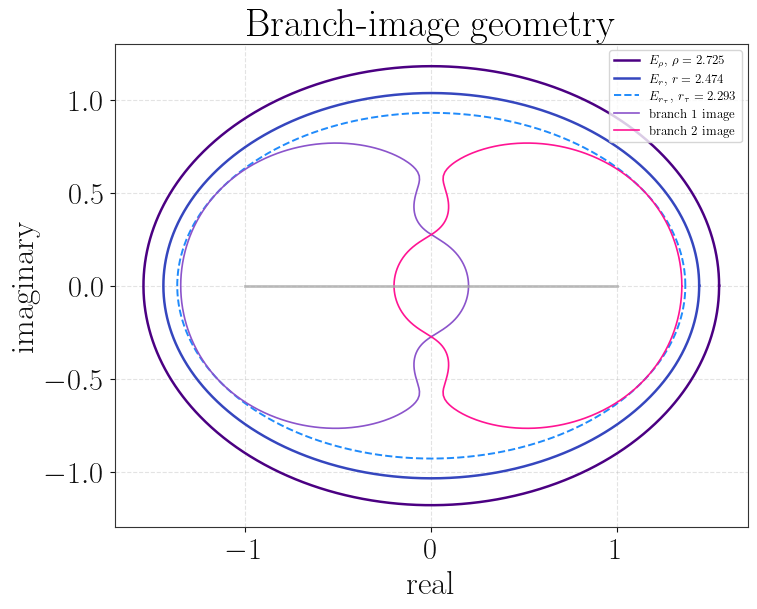

In [19]:
# Cell 21
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_21_status = transfer_lab_execute_selected_map_cell('# Cell 21', 'Phase 2 deterministic Schur envelope')
else:
    # ============================================================
    # Phase 2C — plot branch-image geometry
    # ============================================================


    def plot_branch_geometry (profile_df ,rho ,r ,branch_radius ):
        theta ,E_rho =ellipse_points_np (rho ,1600 )
        _ ,E_r =ellipse_points_np (r ,1600 )
        _ ,E_bt =ellipse_points_np (branch_radius ,1600 )
        labels =["response ellipse","Hardy ellipse","certified branch envelope"]+[f"branch {b }"for b in sorted (profile_df ["branch"].unique ())]
        colours =gradient_colours (labels )
        fig ,ax =plt .subplots (figsize =(8.2 ,6.2 ),facecolor ="white")
        ax .plot (E_rho .real ,E_rho .imag ,color =colours ["response ellipse"],lw =1.8 ,label =fr"$E_\rho$, $\rho={float (rho ):.4g}$")
        ax .plot (E_r .real ,E_r .imag ,color =colours ["Hardy ellipse"],lw =1.8 ,label =fr"$E_r$, $r={float (r ):.4g}$")
        ax .plot (E_bt .real ,E_bt .imag ,color =colours ["certified branch envelope"],lw =1.4 ,ls ="--",label =fr"$E_{{r_\tau}}$, $r_\tau={float (branch_radius ):.4g}$")
        for b in sorted (profile_df ["branch"].unique ()):
            sub =profile_df [profile_df ["branch"]==b ]
            ax .plot (sub ["tau_re"],sub ["tau_im"],color =colours [f"branch {b }"],lw =1.2 ,label =f"branch {b } image")
        ax .plot ([-1 ,1 ],[0 ,0 ],color =PALETTE ["ref"],lw =2.0 ,alpha =0.75 )
        ax .set_aspect ("equal",adjustable ="box")
        ax .set_xlabel ("real")
        ax .set_ylabel ("imaginary")
        ax .set_title ("Branch-image geometry")
        ax .legend (loc ="best",fontsize =9 )
        fig .tight_layout ()
        return fig 


    fig =plot_branch_geometry (profile_df ,rho_for_geometry ,r_for_geometry ,PHASE2_FINAL_CERT ["r_tau"])
    fig_path =FIG_DIR /"branch_image_phase2_geometry.png"
    fig .savefig (fig_path ,dpi =240 ,bbox_inches ="tight")
    print ("Saved figure:",fig_path )
    plt .show ()

## Phase 2 mathematics for Cell 22

This cell evaluates a certified upper version of the Chebyshev-packet input-tail kernel on the actual branch images.  The thesis kernel is

$$
K_{N,\mathrm{exact}}^{(r)}(w)=\left(\sum_{m=N}^{\infty}|\Psi_m^{(r)}(w)|^2\right)^{1/2},
$$

where the packet normalisation contains the denominator $(r^{2m}+r^{-2m})^{1/2}$.  The notebook routine uses the conservative closed-form majorant obtained by replacing that denominator by $r^m$.  Thus the sampled quantity below is a certified upper kernel, not the exact packet kernel.

The branch-image profile sampled here is $\max_{\omega\in\partial E_\rho}\sum_b |\phi_b(\omega)|K_{N,\mathrm{upper}}^{(r)}(\tau_b(\omega))$.  It is the numerical version of replacing the whole-ellipse input-tail majorant $\Phi(\rho)\mathfrak U_N^{X,\mathrm{tail}}(r,r_\tau)$ by a certified upper tail kernel evaluated where the inverse branches actually land.  At $N=600$ the sampled branch-image value is about $3.1286\cdot10^{-20}$, while the certified promoted input-tail component is $3.5228\cdot10^{-20}$.


In [20]:
# Cell 22
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_22_status = transfer_lab_execute_selected_map_cell('# Cell 22', 'Phase 2 deterministic Schur envelope')
else:
    # ============================================================
    # Phase 2D — certified upper tail kernels on branch images
    # ============================================================


    def U_tail_closed (N ,r ,s ):
        r =mp .mpf (r )
        s =mp .mpf (s )
        q =s /r 
        return (1 +s **(-2 *N ))/mp .sqrt (1 -q *q )*q **N 


    def K_tail_point (w ,N ,r ):
        z =outer_joukowski_inverse (w )
        r =mp .mpf (r )
        a =z /r 
        b =1 /(z *r )
        aa =abs (a )**2 
        bb =abs (b )**2 
        c =a *mp .conj (b )
        if aa >=1 or bb >=1 or abs (c )>=1 :
            raise ValueError ("tail point is not strictly inside the Hardy radius")
        total =aa **N /(1 -aa )+bb **N /(1 -bb )+2 *mp .re (c **N /(1 -c ))
        if total <0 and abs (total )<mp .mpf ("1e-70"):
            total =mp .mpf ("0")
        return mp .sqrt (max (total ,mp .mpf ("0")))


    def branch_image_tail_profile (profile_df ,N ,r ):
        rows =[]
        max_sum =0.0 
        for theta ,grp in profile_df .groupby ("theta",sort =True ):
            local =0.0 
            for rec in grp .itertuples (index =False ):
                tau_val =mp .mpc (float (rec .tau_re ),float (rec .tau_im ))
                kval =K_tail_point (tau_val ,int (N ),r )
                weighted =float (rec .phi_abs )*float (kval )
                local +=weighted 
                rows .append ({"theta":theta ,"branch":int (rec .branch ),"weighted_kernel":weighted ,"K_tail":float (kval ),"phi_abs":float (rec .phi_abs )})
            rows .append ({"theta":theta ,"branch":0 ,"weighted_kernel":local ,"K_tail":np .nan ,"phi_abs":np .nan })
            max_sum =max (max_sum ,local )
        return pd .DataFrame (rows ),max_sum 


    N_tail =N_CERT_X 
    kernel_profile_df ,kernel_tail_max =branch_image_tail_profile (profile_df ,N_tail ,r_for_geometry )
    kernel_profile_df .to_csv (DATA_DIR /f"branch_image_phase2_tail_kernel_profile_N{N_tail }.csv",index =False )
    print ("sampled branch-image input-tail profile at N",N_tail ,"=",f"{kernel_tail_max :.6e}")
    print ("certified B_in from promoted row              =",mp .nstr (PHASE2_FINAL_CERT ["B_in"],30 ))

sampled branch-image input-tail profile at N 600 = 3.128586e-20
certified B_in from promoted row              = 3.326442148671931e-20


## Phase 2 mathematics for Cell 23

This cell compares three input-tail quantities over several trial dimensions.  The certified global comparator is $\Phi^{\mathrm{sample}}(\rho)\mathfrak U_N^{X,\mathrm{tail}}(r,r_\tau)$ with the certified $r_\tau$.  The branch-wise enclosing-ellipse comparator replaces one global radius by the sampled $r_{\tau,b}^{\mathrm{sample}}(\rho)$ branch by branch.  The branch-image comparator uses the sampled certified upper profile $\max_{\omega\in\partial E_\rho}\sum_b |\phi_b(\omega)|K_{N,\mathrm{upper}}^{(r)}(\tau_b(\omega))$.

The ratios quantify how much of the input-tail bottleneck came from enclosing all branch images in a single ellipse.  For the promoted $N=600$ row, the sampled certified upper branch-image kernel is about $0.1403$ of the certified global comparator and about $0.1574$ of the sampled global comparator.


In [21]:
# Cell 23
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_23_status = transfer_lab_execute_selected_map_cell('# Cell 23', 'Phase 2E')
else:
    # ============================================================
    # Phase 2E — compare whole-ellipse, branch-wise, and branch-image input tails
    # ============================================================

    N_values_tail =[120 ,240 ,360 ,480 ,600 ,720 ]
    comparison_rows =[]
    branch_phi =dict (zip (branch_geometry_df ["branch"].astype (int ),branch_geometry_df ["branch_phi_max"].astype (float )))
    branch_rad =dict (zip (branch_geometry_df ["branch"].astype (int ),branch_geometry_df ["branch_radius_max"].astype (float )))
    global_rad_sampled =float (profile_df ["tau_radius"].max ())
    global_rad_certified =float (PHASE2_FINAL_CERT ["r_tau"])
    Phi_sample =float (local_phi_df ["local_phi_sum"].max ())
    Phi_branch_sum =float (branch_geometry_df ["branch_phi_max"].sum ())

    for N in N_values_tail :
        old_sampled_global =float (mp .mpf (Phi_branch_sum )*U_tail_closed (N ,r_for_geometry ,global_rad_sampled ))
        old_certified_global =float (mp .mpf (Phi_branch_sum )*U_tail_closed (N ,r_for_geometry ,global_rad_certified ))
        branchwise =0.0 
        for b in branch_rad :
            branchwise +=branch_phi [b ]*float (U_tail_closed (N ,r_for_geometry ,branch_rad [b ]))
        _ ,kernel_max =branch_image_tail_profile (profile_df ,N ,r_for_geometry )
        comparison_rows .append ({
        "N":int (N ),
        "old_sampled_global_tail":old_sampled_global ,
        "old_certified_global_tail":old_certified_global ,
        "branchwise_ellipse_tail":branchwise ,
        "branch_image_kernel_tail_sampled":kernel_max ,
        "branchwise_over_certified_global":branchwise /old_certified_global if old_certified_global else np .nan ,
        "kernel_over_certified_global":kernel_max /old_certified_global if old_certified_global else np .nan ,
        "kernel_over_sampled_global":kernel_max /old_sampled_global if old_sampled_global else np .nan ,
        })

    tail_comparison_df =pd .DataFrame (comparison_rows )
    phase2_save_dataframe (tail_comparison_df ,"branch_image_phase2_tail_comparison")
    display (tail_comparison_df )


Saved CSV: outputs/blaschke_deformation_certifier/data/branch_image_phase2_tail_comparison.csv


,N,old_sampled_global_tail,old_certified_global_tail,branchwise_ellipse_tail,branch_image_kernel_tail_sampled,branchwise_over_certified_global,kernel_over_certified_global,kernel_over_sampled_global
0,120,1.378989e-03,1.412262e-03,1.378989e-03,2.173783e-04,0.976440,0.153922,0.157636
1,240,1.511039e-07,1.583008e-07,1.511039e-07,2.380340e-08,0.954536,0.150368,0.157530
2,360,1.655733e-11,1.774399e-11,1.655733e-11,2.606838e-12,0.933123,0.146914,0.157443
3,480,1.814283e-15,1.988930e-15,1.814283e-15,2.855179e-16,0.912191,0.143554,0.157372
4,600,1.988016e-19,2.229398e-19,1.988016e-19,3.128586e-20,0.891728,0.140333,0.157372
5,720,2.178385e-23,2.498939e-23,2.178385e-23,3.428174e-24,0.871724,0.137185,0.157372


## Phase 2 mathematics for Cell 24

This cell plots the improvement ratios from Cell 23. The horizontal reference line is one. Values below one mean that the branch-image branch geometry gives a smaller input-tail estimate than the corresponding global whole-ellipse majorant.

Let $\Phi_b^{\mathrm{sample}}=\max_{\omega\in\partial E_\rho}|\phi_b(\omega)|$, $\Phi_\Sigma^{\mathrm{sample}}=\sum_b\Phi_b^{\mathrm{sample}}$, $r_{\tau,b}^{\mathrm{sample}}=\max_{\omega\in\partial E_\rho}r_B(\tau_b(\omega))$, $r_\tau^{\mathrm{sample}}=\max_b r_{\tau,b}^{\mathrm{sample}}$, and let $r_\tau^{\mathrm{cert}}$ denote the certified branch-image radius in the promoted row.

The purple curve is

$$
R_{\mathrm{bw/cert}}(N)=
\frac{\sum_b \Phi_b^{\mathrm{sample}}\,\mathfrak U_N^{X,\mathrm{tail}}(r,r_{\tau,b}^{\mathrm{sample}})}
{\Phi_\Sigma^{\mathrm{sample}}\,\mathfrak U_N^{X,\mathrm{tail}}(r,r_\tau^{\mathrm{cert}})}.
$$

The blue curve is

$$
R_{\mathrm{img/cert}}(N)=
\frac{\max_{\omega\in\partial E_\rho}\sum_b |\phi_b(\omega)|K_{N,\mathrm{upper}}^{(r)}(\tau_b(\omega))}
{\Phi_\Sigma^{\mathrm{sample}}\,\mathfrak U_N^{X,\mathrm{tail}}(r,r_\tau^{\mathrm{cert}})}.
$$

The pink curve is

$$
R_{\mathrm{img/sample}}(N)=
\frac{\max_{\omega\in\partial E_\rho}\sum_b |\phi_b(\omega)|K_{N,\mathrm{upper}}^{(r)}(\tau_b(\omega))}
{\Phi_\Sigma^{\mathrm{sample}}\,\mathfrak U_N^{X,\mathrm{tail}}(r,r_\tau^{\mathrm{sample}})}.
$$

The theorem-facing curve is $R_{\mathrm{img/cert}}(N)$, the branch-image upper kernel divided by the certified global comparator.


Saved figure: outputs/blaschke_deformation_certifier/figures/branch_image_phase2_tail_improvement_ratios.png


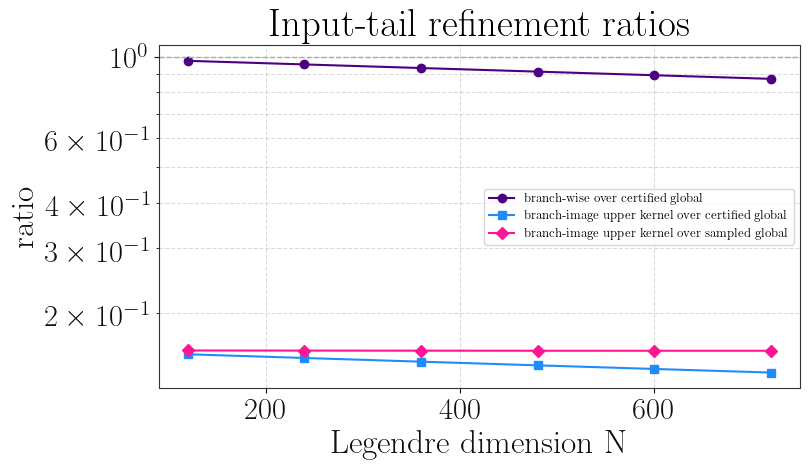

In [22]:
# Cell 24
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_24_status = transfer_lab_execute_selected_map_cell('# Cell 24', 'Phase 2 deterministic Schur envelope')
else:
    # ============================================================
    # Phase 2F — plot input-tail improvement ratios
    # ============================================================

    if len (tail_comparison_df ):
        labels =["branch-wise over certified global","branch-image upper kernel over certified global","branch-image upper kernel over sampled global"]
        colours =gradient_colours (labels )
        fig ,ax =plt .subplots (figsize =(8.2 ,4.8 ),facecolor ="white")
        ax .semilogy (tail_comparison_df ["N"],tail_comparison_df ["branchwise_over_certified_global"],marker ="o",color =colours [labels [0 ]],label =labels [0 ])
        ax .semilogy (tail_comparison_df ["N"],tail_comparison_df ["kernel_over_certified_global"],marker ="s",color =colours [labels [1 ]],label =labels [1 ])
        ax .semilogy (tail_comparison_df ["N"],tail_comparison_df ["kernel_over_sampled_global"],marker ="D",color =colours [labels [2 ]],label =labels [2 ])
        ax .axhline (1.0 ,color =PALETTE ["ref"],lw =1 ,ls ="--")
        ax .set_xlabel ("Legendre dimension N")
        ax .set_ylabel ("ratio")
        ax .set_title ("Input-tail refinement ratios")
        ax .grid (True ,which ="both",linestyle ="--",alpha =0.45 )
        ax .legend (fontsize =9 )
        fig .tight_layout ()
        fig_path =FIG_DIR /"branch_image_phase2_tail_improvement_ratios.png"
        fig .savefig (fig_path ,dpi =240 ,bbox_inches ="tight")
        print ("Saved figure:",fig_path )
        plt .show ()

<div style="color: #008B8B;">

**Cell 24A**

## Phase 2G: unconditional finite-$M$ Gauss--Legendre prefactor

This cell supplies the finite-order quadrature constant needed by the **Schur--Frobenius single-space certificate algorithm** in the subsection **Branch-image single-space deterministic envelope**. The source-faithful Zhao--Wang--Xie route writes

$$
C_{\mathrm{GL}}^{\mathrm{ZWX13}}(\rho;M)
=D_M C_{\mathrm{GL}}(\rho),
$$

but the previously stored matrix row used the diagnostic convention $D_M=1$. The producer below avoids the unspecified finite-order multiplier by proving and implementing a source-independent fallback.

Let $p_{2M-1}$ be the Chebyshev truncation of $f\in A(E_\rho)$ through degree $2M-1$. The Bernstein-ellipse Chebyshev coefficient estimate gives

$$
\lVert f-p_{2M-1}\rVert_{\infty,[-1,1]}
\le
\frac{2\rho^{-2M}}{1-\rho^{-1}}
\lVert f\rVert_{A(E_\rho)}.
$$

The $M$-point Gauss--Legendre rule is exact on $p_{2M-1}$. Its weights are positive and sum to $2$, while the interval $[-1,1]$ also has length $2$. Therefore, with $g=f-p_{2M-1}$,

$$
\begin{aligned}
|R_M[f]|
&=|R_M[g]| \\n
&\le\left|\int_{-1}^{1}g(x)\,dx\right|
+\left|\sum_{j=1}^{M}w_jg(x_j)\right| \\n
&\le4\lVert g\rVert_{\infty,[-1,1]} \\n
&\le\frac{8\rho}{\rho-1}\rho^{-2M}
\lVert f\rVert_{A(E_\rho)}.
\end{aligned}
$$

Hence the unconditional finite-order prefactor is

$$
C_{\mathrm{GL}}^{\mathrm{safe}}(\rho)
=\frac{8\rho}{\rho-1}.
$$

For comparison with the previously stored $D_M=1$ Schur majorant, the code encloses

$$
D_{\mathrm{safe}}(\rho)
=\frac{C_{\mathrm{GL}}^{\mathrm{safe}}(\rho)}
{C_{\mathrm{GL}}(\rho)},
\qquad
C_{\mathrm{GL}}(\rho)
=\pi\sqrt{1+\rho^{-2}}
\left(1+\frac{1}{2(\rho^2-1)}\right).
$$

All three constants and both Schur matrix bounds are evaluated with Arb ball arithmetic. The original $D_M=1$ quantities are retained as diagnostic columns. The active pure-scaled and transported matrix bounds are replaced by their safe upper enclosures, and **finite_M_prefactor_certified** is set to **True** only after these checks pass.

</div>


In [23]:
# Cell 24A
# ============================================================
# Phase 2G -- unconditional finite-M Gauss--Legendre prefactor
# ============================================================

from pathlib import Path
import csv
import hashlib
import json
import math
import os
from decimal import Decimal, getcontext

import pandas as pd

try:
    display
except NameError:
    def display(value):
        print(value.to_string(index=False) if hasattr(value, "to_string") else value)

try:
    import flint
    from flint import arb
except ImportError as exc:
    raise ImportError("Cell 24A requires python-flint for the finite-M certificate.") from exc

FINITE_M_SAFE_BITS = int(os.environ.get("TRANSFER_LAB_FINITE_M_BITS", "192"))
flint.ctx.prec = FINITE_M_SAFE_BITS
getcontext().prec = 100

if "DATA_DIR" not in globals():
    _fm_root = Path("Numerics/outputs") if Path("Numerics").exists() else Path("outputs")
    DATA_DIR = _fm_root / "data"
    REPORT_DIR = _fm_root / "reports"
for _fm_dir in (DATA_DIR, REPORT_DIR):
    _fm_dir.mkdir(parents=True, exist_ok=True)

def _fm_sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def _fm_read_one(path):
    with Path(path).open("r", encoding="utf-8", newline="") as handle:
        rows = list(csv.DictReader(handle))
    if len(rows) != 1:
        raise RuntimeError(f"Expected exactly one row in {path}; found {len(rows)}.")
    return rows[0]

def _fm_is_true(value):
    return str(value).strip().lower() in {"true", "1", "yes", "y"}

def _fm_upper_decimal(value):
    mid, rad, exponent = value.upper().mid_rad_10exp()
    return (Decimal(int(mid)) + abs(Decimal(int(rad)))) * (Decimal(10) ** int(exponent))

def _fm_lower_decimal(value):
    mid, rad, exponent = value.lower().mid_rad_10exp()
    return (Decimal(int(mid)) - abs(Decimal(int(rad)))) * (Decimal(10) ** int(exponent))

def _fm_upper_float(value):
    return math.nextafter(float(_fm_upper_decimal(value)), math.inf)

def _fm_lower_float(value):
    return math.nextafter(float(_fm_lower_decimal(value)), -math.inf)

def _fm_interval_text(value, digits=70):
    return value.str(int(digits), radius=True)

_fm_map_label = globals().get("SELECTED_MAP_LABEL", "blaschke_mu_0p3")
if _fm_map_label != "blaschke_mu_0p3":
    raise RuntimeError("Cell 24A currently certifies only the blaschke_mu_0p3 Phase 2 row.")

_fm_input_path = DATA_DIR / "branch_image_balanced_candidate_single_space_row_N600_M610.csv"
if not _fm_input_path.exists():
    raise FileNotFoundError(f"Missing D_M=1 diagnostic Schur row: {_fm_input_path}")
_fm_input = _fm_read_one(_fm_input_path)

for _fm_flag in (
    "analytic_branch_sufficient",
    "branch_image_in_Er_sufficient",
    "admissible_chain_sufficient",
    "transport_certified",
    "matrix_certificate_arb",
    "tail_components_interval",
):
    if not _fm_is_true(_fm_input.get(_fm_flag, False)):
        raise RuntimeError(f"Upstream balanced row failed {_fm_flag}.")

_fm_N = int(_fm_input["N"])
_fm_M = int(_fm_input["M"])
_fm_rho_text = "2.725"
if abs(Decimal(_fm_input["rho"]) - Decimal(_fm_rho_text)) > Decimal("1e-14"):
    raise RuntimeError("The balanced row does not use the certified rho=2.725 geometry.")
_fm_rho = arb(_fm_rho_text)
if _fm_rho <= 1:
    raise ArithmeticError("The safe Gauss--Legendre prefactor requires rho > 1.")

_fm_C_safe_interval = 8 * _fm_rho / (_fm_rho - 1)
_fm_C_core_interval = (
    arb.pi() * (1 + _fm_rho ** -2).sqrt()
    * (1 + 1 / (2 * (_fm_rho ** 2 - 1)))
)
if _fm_C_core_interval.lower() <= 0:
    raise ArithmeticError("The reference C_GL interval is not strictly positive.")
_fm_C_safe = _fm_C_safe_interval.upper()
_fm_C_core = _fm_C_core_interval
# Form the exported multiplier from exported outward endpoints as well as Arb.
_fm_D_safe_arb = (_fm_C_safe_interval / _fm_C_core_interval).upper()
_fm_D_safe_float = math.nextafter(
    _fm_upper_float(_fm_C_safe_interval) / _fm_lower_float(_fm_C_core_interval),
    math.inf,
)
_fm_D_safe = arb(str(max(_fm_D_safe_float, _fm_upper_float(_fm_D_safe_arb)))).upper()

_fm_Bmat_star_D1 = arb(_fm_input["B_mat_star_arb_u"]).upper()
_fm_Bmat_unstar_D1 = arb(_fm_input["B_mat_unstar_arb_u"]).upper()
_fm_kappa_hat = arb(_fm_input["kappa_hat_transport_cert"]).upper()
_fm_Bmat_star_safe = (_fm_D_safe * _fm_Bmat_star_D1).upper()
_fm_Bmat_unstar_safe = (_fm_D_safe * _fm_Bmat_unstar_D1).upper()
_fm_kappa_Bmat_star_safe = (_fm_kappa_hat * _fm_Bmat_star_safe).upper()
_fm_kappa_Bmat_unstar_safe = (_fm_kappa_hat * _fm_Bmat_unstar_safe).upper()

_fm_B_out = (arb(_fm_input["two_B_out_star_interval_u"]) / 2).upper()
_fm_B_in = arb(_fm_input["B_in_branch_image_interval_u"]).upper()
_fm_noncollocation_rss = ((_fm_B_out ** 2 + _fm_B_in ** 2).sqrt()).upper()
_fm_epsilon_star_safe = (_fm_noncollocation_rss + _fm_kappa_Bmat_star_safe).upper()
_fm_epsilon_unstar_safe = (_fm_noncollocation_rss + _fm_kappa_Bmat_unstar_safe).upper()

_fm_certificate = {
    "map_label": _fm_map_label,
    "N": _fm_N,
    "M": _fm_M,
    "rho": float(_fm_rho_text),
    "precision_bits": FINITE_M_SAFE_BITS,
    "C_GL_safe_u": _fm_upper_float(_fm_C_safe),
    "C_GL_core_D_M_1_l": _fm_lower_float(_fm_C_core),
    "C_GL_core_D_M_1_u": _fm_upper_float(_fm_C_core),
    "D_safe_u": _fm_upper_float(_fm_D_safe),
    "output_schema_version": 2,
    "output_leakage_count": 1,
    "B_out_interval_u": _fm_upper_float(_fm_B_out),
    "B_mat_star_D_M_1_diagnostic_u": _fm_upper_float(_fm_Bmat_star_D1),
    "B_mat_star_safe_u": _fm_upper_float(_fm_Bmat_star_safe),
    "kappa_Bmat_star_D_M_1_diagnostic_u": _fm_upper_float(arb(_fm_input["kappa_Bmat_star"])),
    "kappa_Bmat_star_safe_u": _fm_upper_float(_fm_kappa_Bmat_star_safe),
    "epsilon_safe_u": _fm_upper_float(_fm_epsilon_star_safe),
    "finite_M_prefactor_certified": True,
    "status": "unconditional Chebyshev-truncation Gauss--Legendre prefactor certificate",
}

_fm_safe_row = dict(_fm_input)
_fm_safe_row.update({
    "label": "branch-image balanced row with unconditional finite-M prefactor N=600",
    "rho": float(_fm_rho_text),
    "B_mat_star_D_M_1_diagnostic_u": _fm_upper_float(_fm_Bmat_star_D1),
    "B_mat_unstar_D_M_1_diagnostic_u": _fm_upper_float(_fm_Bmat_unstar_D1),
    "kappa_Bmat_star_D_M_1_diagnostic_u": _fm_upper_float(arb(_fm_input["kappa_Bmat_star"])),
    "kappa_Bmat_unstar_D_M_1_diagnostic_u": _fm_upper_float(arb(_fm_input["kappa_Bmat_unstar"])),
    "C_GL_safe_u": _fm_upper_float(_fm_C_safe),
    "C_GL_core_D_M_1_u": _fm_upper_float(_fm_C_core),
    "D_safe_u": _fm_upper_float(_fm_D_safe),
    "output_schema_version": 2,
    "output_leakage_count": 1,
    "B_out_interval_u": _fm_upper_float(_fm_B_out),
    "B_mat_star_arb_u": _fm_upper_float(_fm_Bmat_star_safe),
    "B_mat_unstar_arb_u": _fm_upper_float(_fm_Bmat_unstar_safe),
    "kappa_Bmat_star": _fm_upper_float(_fm_kappa_Bmat_star_safe),
    "kappa_Bmat_unstar": _fm_upper_float(_fm_kappa_Bmat_unstar_safe),
    "noncollocation_rss_interval_u": _fm_upper_float(_fm_noncollocation_rss),
    "tail_floor_interval_u": _fm_upper_float(_fm_noncollocation_rss),
    "epsilon_star_candidate": _fm_upper_float(_fm_epsilon_star_safe),
    "epsilon_with_unstar_matrix_candidate": _fm_upper_float(_fm_epsilon_unstar_safe),
    "quadrature_prefactor_route": "Chebyshev truncation through degree 2M-1",
    "finite_M_prefactor_certified": True,
    "total_certified": True,
    "status": "balanced branch-image row with unconditional safe finite-M certificate",
})
_fm_safe_row.pop("two_B_out_star_interval_u", None)

_fm_certificate_path = DATA_DIR / f"finite_M_safe_GL_prefactor_certificate_N{_fm_N}_M{_fm_M}.csv"
_fm_safe_row_path = DATA_DIR / f"branch_image_balanced_candidate_single_space_row_N{_fm_N}_M{_fm_M}_safe_GL.csv"
_fm_json_path = REPORT_DIR / f"finite_M_safe_GL_prefactor_certificate_N{_fm_N}_M{_fm_M}.json"
_fm_report_path = REPORT_DIR / f"finite_M_safe_GL_prefactor_certificate_N{_fm_N}_M{_fm_M}.md"

finite_M_prefactor_df = pd.DataFrame([_fm_certificate])
balanced_safe_df = pd.DataFrame([_fm_safe_row])
finite_M_prefactor_df.to_csv(_fm_certificate_path, index=False)
balanced_safe_df.to_csv(_fm_safe_row_path, index=False)

_fm_provenance = {
    "producer_cell": "Cell 24A",
    "method": "Chebyshev truncation plus positivity and mass of Gauss--Legendre weights",
    "input": {str(_fm_input_path): _fm_sha256(_fm_input_path)},
    "intervals": {
        "C_GL_safe": _fm_interval_text(_fm_C_safe),
        "C_GL_core_D_M_1": _fm_interval_text(_fm_C_core),
        "D_safe": _fm_interval_text(_fm_D_safe),
        "B_mat_star_safe": _fm_interval_text(_fm_Bmat_star_safe),
        "kappa_Bmat_star_safe": _fm_interval_text(_fm_kappa_Bmat_star_safe),
    },
    "certificate": _fm_certificate,
}
_fm_json_path.write_text(json.dumps(_fm_provenance, indent=2), encoding="utf-8")
_fm_report_path.write_text(
    "# Unconditional finite-M Gauss--Legendre prefactor\n\n"
    + f"N={_fm_N}, M={_fm_M}, rho={_fm_input['rho']}.\n\n"
    + f"C_GL_safe <= {_fm_upper_float(_fm_C_safe):.17e}.\n\n"
    + f"D_safe <= {_fm_upper_float(_fm_D_safe):.17e}.\n\n"
    + f"Transported matrix contribution <= {_fm_upper_float(_fm_kappa_Bmat_star_safe):.17e}.\n\n"
    + "The finite-M quadrature prefactor is theorem-certified by the elementary Chebyshev-truncation fallback.\n",
    encoding="utf-8",
)

# Apply the same unconditional finite-M certificate to the wide Phase 4 row.
_fm_wide_active_path = DATA_DIR / "branch_image_wide_candidate_single_space_row_N600_M610.csv"
_fm_wide_diagnostic_path = DATA_DIR / "branch_image_wide_candidate_single_space_row_N600_M610_D_M_1_diagnostic.csv"
_fm_wide_certificate_path = DATA_DIR / "finite_M_safe_GL_prefactor_certificate_wide_N600_M610.csv"
_fm_wide_json_path = REPORT_DIR / "finite_M_safe_GL_prefactor_certificate_wide_N600_M610.json"
_fm_wide_report_path = REPORT_DIR / "finite_M_safe_GL_prefactor_certificate_wide_N600_M610.md"

if _fm_wide_diagnostic_path.exists():
    _fm_wide_input = _fm_read_one(_fm_wide_diagnostic_path)
elif _fm_wide_active_path.exists():
    _fm_wide_input = _fm_read_one(_fm_wide_active_path)
    if _fm_is_true(_fm_wide_input.get("finite_M_prefactor_certified", False)):
        for _fm_safe_name, _fm_diagnostic_name in (
            ("B_mat_star_arb_u", "B_mat_star_D_M_1_diagnostic_u"),
            ("B_mat_unstar_arb_u", "B_mat_unstar_D_M_1_diagnostic_u"),
            ("kappa_Bmat_star", "kappa_Bmat_star_D_M_1_diagnostic_u"),
            ("kappa_Bmat_unstar", "kappa_Bmat_unstar_D_M_1_diagnostic_u"),
        ):
            if _fm_diagnostic_name not in _fm_wide_input:
                raise RuntimeError(f"Certified wide row lacks {_fm_diagnostic_name}.")
            _fm_wide_input[_fm_safe_name] = _fm_wide_input[_fm_diagnostic_name]
        _fm_wide_input["finite_M_prefactor_certified"] = False
        _fm_wide_input["total_certified"] = False
        _fm_wide_input["status"] = "wide branch-image D_M=1 diagnostic source"
    pd.DataFrame([_fm_wide_input]).to_csv(_fm_wide_diagnostic_path, index=False)
else:
    raise FileNotFoundError(f"Missing wide Phase 4 row: {_fm_wide_active_path}")

for _fm_flag in (
    "analytic_branch_sufficient",
    "branch_image_in_Er_sufficient",
    "admissible_chain_sufficient",
    "transport_certified",
    "matrix_certificate_arb",
    "tail_components_interval",
):
    if not _fm_is_true(_fm_wide_input.get(_fm_flag, False)):
        raise RuntimeError(f"Upstream wide row failed {_fm_flag}.")

_fm_wide_rho = arb(_fm_wide_input["rho"])
if _fm_wide_rho <= 1:
    raise ArithmeticError("The wide safe Gauss--Legendre prefactor requires rho > 1.")
_fm_wide_C_safe_interval = 8 * _fm_wide_rho / (_fm_wide_rho - 1)
_fm_wide_C_core_interval = (
    arb.pi() * (1 + _fm_wide_rho ** -2).sqrt()
    * (1 + 1 / (2 * (_fm_wide_rho ** 2 - 1)))
)
if _fm_wide_C_core_interval.lower() <= 0:
    raise ArithmeticError("The wide reference C_GL interval is not strictly positive.")
_fm_wide_D_safe_float = math.nextafter(
    _fm_upper_float(_fm_wide_C_safe_interval) / _fm_lower_float(_fm_wide_C_core_interval),
    math.inf,
)
_fm_wide_D_safe_arb = (_fm_wide_C_safe_interval / _fm_wide_C_core_interval).upper()
_fm_wide_D_safe = arb(
    str(max(_fm_wide_D_safe_float, _fm_upper_float(_fm_wide_D_safe_arb)))
).upper()

_fm_wide_Bmat_star_D1 = arb(_fm_wide_input["B_mat_star_arb_u"]).upper()
_fm_wide_Bmat_unstar_D1 = arb(_fm_wide_input["B_mat_unstar_arb_u"]).upper()
_fm_wide_kappa = arb(_fm_wide_input["kappa_hat_transport_cert"]).upper()
_fm_wide_Bmat_star_safe = (_fm_wide_D_safe * _fm_wide_Bmat_star_D1).upper()
_fm_wide_Bmat_unstar_safe = (_fm_wide_D_safe * _fm_wide_Bmat_unstar_D1).upper()
_fm_wide_kappa_Bmat_star_safe = (_fm_wide_kappa * _fm_wide_Bmat_star_safe).upper()
_fm_wide_kappa_Bmat_unstar_safe = (_fm_wide_kappa * _fm_wide_Bmat_unstar_safe).upper()
if "B_out_interval_u" in _fm_wide_input:
    _fm_wide_B_out = arb(_fm_wide_input["B_out_interval_u"]).upper()
elif "two_B_out_star_interval_u" in _fm_wide_input:
    _fm_wide_B_out = (arb(_fm_wide_input["two_B_out_star_interval_u"]) / 2).upper()
else:
    raise KeyError("Wide row has no recognised output-leakage field.")
_fm_wide_B_in = arb(_fm_wide_input["B_in_branch_image_interval_u"]).upper()
_fm_wide_noncollocation_rss = ((_fm_wide_B_out ** 2 + _fm_wide_B_in ** 2).sqrt()).upper()
_fm_wide_epsilon_star = (_fm_wide_noncollocation_rss + _fm_wide_kappa_Bmat_star_safe).upper()
_fm_wide_epsilon_unstar = (_fm_wide_noncollocation_rss + _fm_wide_kappa_Bmat_unstar_safe).upper()

_fm_wide_safe_row = dict(_fm_wide_input)
_fm_wide_safe_row.update({
    "label": "wide branch-image row with unconditional finite-M prefactor N=600",
    "B_mat_star_D_M_1_diagnostic_u": _fm_upper_float(_fm_wide_Bmat_star_D1),
    "B_mat_unstar_D_M_1_diagnostic_u": _fm_upper_float(_fm_wide_Bmat_unstar_D1),
    "kappa_Bmat_star_D_M_1_diagnostic_u": _fm_upper_float(arb(_fm_wide_input["kappa_Bmat_star"])),
    "kappa_Bmat_unstar_D_M_1_diagnostic_u": _fm_upper_float(arb(_fm_wide_input["kappa_Bmat_unstar"])),
    "C_GL_safe_u": _fm_upper_float(_fm_wide_C_safe_interval),
    "C_GL_core_D_M_1_l": _fm_lower_float(_fm_wide_C_core_interval),
    "C_GL_core_D_M_1_u": _fm_upper_float(_fm_wide_C_core_interval),
    "D_safe_u": _fm_upper_float(_fm_wide_D_safe),
    "output_schema_version": 2,
    "output_leakage_count": 1,
    "B_out_interval_u": _fm_upper_float(_fm_wide_B_out),
    "B_mat_star_arb_u": _fm_upper_float(_fm_wide_Bmat_star_safe),
    "B_mat_unstar_arb_u": _fm_upper_float(_fm_wide_Bmat_unstar_safe),
    "kappa_Bmat_star": _fm_upper_float(_fm_wide_kappa_Bmat_star_safe),
    "kappa_Bmat_unstar": _fm_upper_float(_fm_wide_kappa_Bmat_unstar_safe),
    "noncollocation_rss_interval_u": _fm_upper_float(_fm_wide_noncollocation_rss),
    "tail_floor_interval_u": _fm_upper_float(_fm_wide_noncollocation_rss),
    "epsilon_star_candidate": _fm_upper_float(_fm_wide_epsilon_star),
    "epsilon_with_unstar_matrix_candidate": _fm_upper_float(_fm_wide_epsilon_unstar),
    "quadrature_prefactor_route": "Chebyshev truncation through degree 2M-1",
    "finite_M_prefactor_certified": True,
    "total_certified": True,
    "status": "wide branch-image row with unconditional safe finite-M certificate",
})
_fm_wide_safe_row.pop("two_B_out_star_interval_u", None)

_fm_wide_certificate = {
    "map_label": _fm_map_label,
    "N": int(_fm_wide_input["N"]),
    "M": int(_fm_wide_input["M"]),
    "rho": float(_fm_wide_input["rho"]),
    "precision_bits": FINITE_M_SAFE_BITS,
    "C_GL_safe_u": _fm_upper_float(_fm_wide_C_safe_interval),
    "C_GL_core_D_M_1_l": _fm_lower_float(_fm_wide_C_core_interval),
    "C_GL_core_D_M_1_u": _fm_upper_float(_fm_wide_C_core_interval),
    "D_safe_u": _fm_upper_float(_fm_wide_D_safe),
    "output_schema_version": 2,
    "output_leakage_count": 1,
    "B_out_interval_u": _fm_upper_float(_fm_wide_B_out),
    "B_mat_unstar_D_M_1_diagnostic_u": _fm_upper_float(_fm_wide_Bmat_unstar_D1),
    "B_mat_unstar_safe_u": _fm_upper_float(_fm_wide_Bmat_unstar_safe),
    "kappa_Bmat_unstar_D_M_1_diagnostic_u": _fm_upper_float(arb(_fm_wide_input["kappa_Bmat_unstar"])),
    "kappa_Bmat_unstar_safe_u": _fm_upper_float(_fm_wide_kappa_Bmat_unstar_safe),
    "epsilon_safe_u": _fm_upper_float(_fm_wide_epsilon_unstar),
    "finite_M_prefactor_certified": True,
    "status": "unconditional wide-row finite-M prefactor certificate",
}

pd.DataFrame([_fm_wide_safe_row]).to_csv(_fm_wide_active_path, index=False)
pd.DataFrame([_fm_wide_certificate]).to_csv(_fm_wide_certificate_path, index=False)
_fm_wide_provenance = {
    "producer_cell": "Cell 24A",
    "method": "Chebyshev truncation plus positivity and mass of Gauss--Legendre weights",
    "input": {str(_fm_wide_diagnostic_path): _fm_sha256(_fm_wide_diagnostic_path)},
    "intervals": {
        "C_GL_safe": _fm_interval_text(_fm_wide_C_safe_interval),
        "C_GL_core_D_M_1": _fm_interval_text(_fm_wide_C_core_interval),
        "D_safe": _fm_interval_text(_fm_wide_D_safe),
        "B_mat_unstar_safe": _fm_interval_text(_fm_wide_Bmat_unstar_safe),
        "kappa_Bmat_unstar_safe": _fm_interval_text(_fm_wide_kappa_Bmat_unstar_safe),
    },
    "certificate": _fm_wide_certificate,
}
_fm_wide_json_path.write_text(json.dumps(_fm_wide_provenance, indent=2), encoding="utf-8")
_fm_wide_report_path.write_text(
    "# Unconditional finite-M certificate for the wide Phase 4 row\n\n"
    + f"N={_fm_wide_input['N']}, M={_fm_wide_input['M']}, rho={_fm_wide_input['rho']}.\n\n"
    + f"D_safe <= {_fm_upper_float(_fm_wide_D_safe):.17e}.\n\n"
    + f"Transported unstarred matrix contribution <= {_fm_upper_float(_fm_wide_kappa_Bmat_unstar_safe):.17e}.\n\n"
    + f"Complete deterministic radius <= {_fm_upper_float(_fm_wide_epsilon_unstar):.17e}.\n\n"
    + "The finite-M prefactor is theorem-certified by the Chebyshev-truncation fallback.\n",
    encoding="utf-8",
)
wide_df = pd.DataFrame([_fm_wide_safe_row])
wide_path = _fm_wide_active_path

# Refresh active Phase 2 and Phase 3 comparison products with the safe wide-row value.
_fm_phase2_summary_path = DATA_DIR / "branch_image_phase2_certificate_summary.csv"
if _fm_phase2_summary_path.exists():
    _fm_phase2_summary = pd.read_csv(_fm_phase2_summary_path)
    _fm_wide_mask = _fm_phase2_summary["source"].astype(str).eq("wide branch-image candidate")
    if int(_fm_wide_mask.sum()) != 1:
        raise RuntimeError("Expected exactly one wide row in the Phase 2 comparison table.")
    _fm_phase2_summary.loc[_fm_wide_mask, "B_out"] = _fm_upper_float(_fm_wide_B_out)
    _fm_phase2_summary.loc[_fm_wide_mask, "B_in"] = _fm_upper_float(_fm_wide_B_in)
    _fm_phase2_summary.loc[_fm_wide_mask, "collocation"] = _fm_upper_float(_fm_wide_kappa_Bmat_unstar_safe)
    _fm_phase2_summary.loc[_fm_wide_mask, "epsilon"] = _fm_upper_float(_fm_wide_epsilon_unstar)
    _fm_phase2_summary.loc[_fm_wide_mask, "status"] = "wide branch-image row with unconditional safe finite-M certificate"
    _fm_phase2_summary.to_csv(_fm_phase2_summary_path, index=False)
    cert_summary_df = _fm_phase2_summary

for _fm_phase3_name in ("branch_image_phase3_certificate_comparison.csv", "branch_image_phase3_rate_diagnostics.csv"):
    _fm_phase3_path = DATA_DIR / _fm_phase3_name
    if not _fm_phase3_path.exists():
        continue
    _fm_phase3 = pd.read_csv(_fm_phase3_path)
    _fm_phase3_mask = _fm_phase3["source"].astype(str).eq("wide branch-image candidate")
    if int(_fm_phase3_mask.sum()) != 1:
        raise RuntimeError(f"Expected exactly one wide row in {_fm_phase3_name}.")
    _fm_phase3.loc[_fm_phase3_mask, "B_out"] = _fm_upper_float(_fm_wide_B_out)
    _fm_phase3.loc[_fm_phase3_mask, "B_in"] = _fm_upper_float(_fm_wide_B_in)
    _fm_phase3.loc[_fm_phase3_mask, "collocation"] = _fm_upper_float(_fm_wide_kappa_Bmat_unstar_safe)
    _fm_phase3.loc[_fm_phase3_mask, "epsilon"] = _fm_upper_float(_fm_wide_epsilon_unstar)
    _fm_phase3.loc[_fm_phase3_mask, "status"] = "wide branch-image row with unconditional safe finite-M certificate"
    _fm_phase3.loc[_fm_phase3_mask, "qstar_power"] = _fm_phase3.loc[_fm_phase3_mask, "q_star"] ** _fm_phase3.loc[_fm_phase3_mask, "N"]
    _fm_phase3.loc[_fm_phase3_mask, "epsilon_over_qstar_power"] = _fm_phase3.loc[_fm_phase3_mask, "epsilon"] / _fm_phase3.loc[_fm_phase3_mask, "qstar_power"]
    _fm_phase3.loc[_fm_phase3_mask, "effective_base"] = _fm_phase3.loc[_fm_phase3_mask].apply(lambda row: row["epsilon"] ** (1.0 / row["N"]), axis=1)
    _fm_phase3.to_csv(_fm_phase3_path, index=False)

# Replace the legacy packet-status names at the Phase 4 ingestion boundary.
_fm_packets_legacy_path = DATA_DIR / "branch_image_wide_candidate_first15_certified_spectral_packets_N600_M610.csv"
_fm_packets_sampled_path = DATA_DIR / "branch_image_wide_candidate_first15_sampled_spectral_packets_N600_M610.csv"
if _fm_packets_legacy_path.exists():
    _fm_packets = pd.read_csv(_fm_packets_legacy_path)
elif _fm_packets_sampled_path.exists():
    _fm_packets = pd.read_csv(_fm_packets_sampled_path)
else:
    raise FileNotFoundError("Missing first-fifteen Phase 4 packet table.")
if "pass_certified_packet" in _fm_packets.columns and "pass_sampled_packet" not in _fm_packets.columns:
    _fm_packets = _fm_packets.rename(columns={"pass_certified_packet": "pass_sampled_packet"})
_fm_packets = _fm_packets.drop(columns=["certified"], errors="ignore")
_fm_packets["contour_interval_certified"] = False
_fm_packets["validation_status"] = "sampled_not_interval_certified"
_fm_packets.to_csv(_fm_packets_sampled_path, index=False)

# Promote the safe row for the subsequent response-prefactor producer and Phase 2 exports.
balanced_df = balanced_safe_df
balanced_path = _fm_safe_row_path
FINITE_M_PREFACTOR_CERTIFIED = True
FINITE_M_SAFE_D = _fm_upper_float(_fm_D_safe)

print("Unconditional finite-M Gauss--Legendre prefactor completed.")
print(f"  C_GL_safe upper                 = {_fm_upper_float(_fm_C_safe):.17e}")
print(f"  C_GL core D_M=1 upper           = {_fm_upper_float(_fm_C_core):.17e}")
print(f"  D_safe upper                    = {_fm_upper_float(_fm_D_safe):.17e}")
print(f"  old transported matrix term     = {_fm_upper_float(arb(_fm_input['kappa_Bmat_star'])):.17e}")
print(f"  safe transported matrix term    = {_fm_upper_float(_fm_kappa_Bmat_star_safe):.17e}")
print(f"  safe balanced epsilon upper      = {_fm_upper_float(_fm_epsilon_star_safe):.17e}")
print("  finite-M prefactor certified     = True")
print("Stored:", _fm_certificate_path)
print("Stored:", _fm_safe_row_path)
print("Stored:", _fm_json_path)
print("Stored:", _fm_report_path)
display(finite_M_prefactor_df)


Unconditional finite-M Gauss--Legendre prefactor completed.
  C_GL_safe upper                 = 1.26376811594202909e+01
  C_GL core D_M=1 upper           = 3.60684952969595418e+00
  D_safe upper                    = 3.50380049274903183e+00
  old transported matrix term     = 3.10305078747476513e-29
  safe transported matrix term    = 1.08724708781793537e-28
  safe balanced epsilon upper      = 4.23935965277783374e-20
  finite-M prefactor certified     = True
Stored: outputs/blaschke_deformation_certifier/data/finite_M_safe_GL_prefactor_certificate_N600_M610.csv
Stored: outputs/blaschke_deformation_certifier/data/branch_image_balanced_candidate_single_space_row_N600_M610_safe_GL.csv
Stored: outputs/blaschke_deformation_certifier/reports/finite_M_safe_GL_prefactor_certificate_N600_M610.json
Stored: outputs/blaschke_deformation_certifier/reports/finite_M_safe_GL_prefactor_certificate_N600_M610.md


,map_label,N,M,rho,precision_bits,C_GL_safe_u,C_GL_core_D_M_1_l,C_GL_core_D_M_1_u,D_safe_u,output_schema_version,output_leakage_count,B_out_interval_u,B_mat_star_D_M_1_diagnostic_u,B_mat_star_safe_u,kappa_Bmat_star_D_M_1_diagnostic_u,kappa_Bmat_star_safe_u,epsilon_safe_u,finite_M_prefactor_certified,status
0,blaschke_mu_0p3,600,610,2.725,192,12.637681,3.60685,3.60685,3.5038,2,1,2.358400e-20,5.135781e-32,1.799475e-31,3.103051e-29,1.087247e-28,4.239360e-20,True,unconditional Chebyshev-truncation Gauss--Lege...


## Certified resolved-response and unresolved-input boundary rows

The inline helper below implements the two Chebyshev-packet boundary certificates used in Phase 2.  For the resolved response it encloses a coherent packet prefix and a certified local high-mode remainder.  For the unresolved input it encloses the exact packet prefix, the branchwise Minkowski profile, and the cancellation-preserving combined row.  Both calculations use complete Arb covers of the response boundary rather than point samples.


### Inline thesis helper: `blaschke_deformation_certification`

This is the complete helper used by **Phase 2 resolved-response and unresolved-input certification**. It is placed here so that the mathematical implementation can be read in the same phase as the formulas and certificate that use it. The cell is executable: the `inline_module` magic gives the source an isolated module namespace while leaving the code visible in the notebook.

Source file: `blaschke_deformation_certification.py`  
SHA-256: `dbe80820b21637e2cd3f24e28f6c4ee0288af81197af40a4e6871511bfa17501`


In [24]:
%%inline_module blaschke_deformation_certification dbe80820b21637e2cd3f24e28f6c4ee0288af81197af40a4e6871511bfa17501
"""Rigorous Hardy-tail certification for the ASBJ24 Blaschke deformation.

The routines in this module are deliberately map-specific.  They certify the
``blaschke_mu_0p3`` inverse branches on a complete Arb cover of the response
ellipse boundary.  They enclose the coherent resolved-response row as well as
two unresolved-input quantities:

* the exact resolved Chebyshev-packet row through a coherent prefix and a
  certified local high-mode remainder;
* the unresolved branchwise profile used by the deployed single-space theorem;
* the cancellation-preserving unresolved combined coefficient row.

All enclosures use exact Chebyshev-packet values for a finite prefix and the
explicit local Joukowski remainder from the thesis for the remaining modes.
"""

from __future__ import annotations

from dataclasses import asdict, dataclass
from decimal import Decimal, getcontext
import math
import time
from typing import Callable

try:
    import flint
    from flint import arb, acb
except ImportError as exc:  # pragma: no cover - exercised in notebook setup
    raise ImportError(
        "blaschke_deformation_certification requires python-flint"
    ) from exc


MAP_LABEL = "blaschke_mu_0p3"


@dataclass(frozen=True)
class InputTailCertificateConfig:
    """Configuration for a complete boundary-cover certificate."""

    N: int = 600
    rho: str = "2.725"
    r: str = "2.473669807791324"
    mu: str = "0.3"
    cells: int = 65536
    precision_bits: int = 192
    prefix_terms: int = 24

    @property
    def J(self) -> int:
        return self.N + self.prefix_terms - 1


def _upper_decimal(value: arb) -> Decimal:
    mid, rad, exponent = value.upper().mid_rad_10exp()
    return (Decimal(int(mid)) + abs(Decimal(int(rad)))) * (
        Decimal(10) ** int(exponent)
    )


def upper_float(value: arb) -> float:
    """Convert an Arb upper endpoint to an outward-rounded binary float."""

    getcontext().prec = 100
    return math.nextafter(float(_upper_decimal(value)), math.inf)


def interval_text(value: arb, digits: int = 60) -> str:
    return value.str(int(digits), radius=True)


def tau_phi(branch: int, omega: acb, mu: arb, pi: arb):
    """Certified inverse branch and Perron--Frobenius weight."""

    sign = -1 if int(branch) == 1 else 1
    cosine = (pi * omega / 2).cos()
    sine = (pi * omega / 2).sin()
    argument = mu * cosine
    denominator = (1 - argument * argument).sqrt()
    tau = omega / 2 + sign * argument.acos() / pi
    phi = arb("0.5") + sign * mu / 2 * sine / denominator
    return tau, phi


def bernstein_radius_upper(point: acb) -> arb:
    """Branch-free upper bound for the outer Bernstein radius."""

    semimajor = (abs(point - 1).upper() + abs(point + 1).upper()) / 2
    if semimajor < 1:
        semimajor = arb(1)
    return (semimajor + (semimajor * semimajor - 1).sqrt()).upper()


def selected_joukowski_preimage(point: acb) -> acb:
    """Select one reciprocal preimage, favouring the outer enclosure.

    The packet expression is invariant under reciprocal replacement, so this
    pointwise choice does not assert or require a global inverse branch.
    """

    root = (point * point - 1).sqrt()
    first = point + root
    second = point - root
    first_lower = abs(first).lower()
    second_lower = abs(second).lower()
    return first if first_lower >= second_lower else second


def packet_value(m: int, point: acb, hardy_radius: arb) -> acb:
    """Exact Arb enclosure of the normalised Chebyshev packet at a point."""

    if int(m) < 1:
        raise ValueError("The unresolved-tail packet formula requires m at least one")
    denominator = (
        hardy_radius ** (2 * int(m)) + hardy_radius ** (-2 * int(m))
    ).sqrt()
    # Evaluating the polynomial itself avoids choosing a square-root branch on
    # cells meeting the ramification interval.  python-flint evaluates the
    # Chebyshev polynomial directly with complex-ball arithmetic.
    return 2 * point.chebyshev_t(int(m)) / denominator


def packet_value_from_preimage(
    m: int, preimage: acb, hardy_radius: arb
) -> acb:
    """Evaluate a packet through a certified pointwise Joukowski preimage."""

    denominator = (
        hardy_radius ** (2 * int(m)) + hardy_radius ** (-2 * int(m))
    ).sqrt()
    return (preimage**int(m) + preimage ** (-int(m))) / denominator


def local_tail_l2_upper(start: int, radius_upper: arb, hardy_radius: arb) -> arb:
    """Certified local geometric envelope for packets from ``start`` onward."""

    start = int(start)
    q = (radius_upper / hardy_radius).upper()
    if not (q < 1):
        raise ArithmeticError(
            f"Branch-image radius is not strictly below the Hardy radius: q={q}"
        )
    return (
        (1 + radius_upper ** (-2 * start))
        * q**start
        / (1 - q * q).sqrt()
    ).upper()


def certify_input_tail_rows(
    config: InputTailCertificateConfig,
    progress: Callable[[int, int], None] | None = None,
):
    """Certify branchwise and combined unresolved-input rows on the boundary.

    For every boundary cell, modes ``N`` through ``J`` are evaluated with Arb.
    The remaining modes are bounded by ``local_tail_l2_upper``.  Orthogonality
    of the finite prefix and the remainder gives a square-sum assembly.  The
    combined row retains inter-branch cancellation throughout the exact prefix.
    """

    if config.N < 1:
        raise ValueError("N must be at least one")
    if config.prefix_terms < 1:
        raise ValueError("prefix_terms must be positive")
    if config.cells < 4:
        raise ValueError("At least four boundary cells are required")

    flint.ctx.prec = int(config.precision_bits)
    getcontext().prec = 100

    N = int(config.N)
    J = int(config.J)
    cells = int(config.cells)
    rho = arb(config.rho)
    hardy_radius = arb(config.r)
    mu = arb(config.mu)
    pi = arb.pi()
    imaginary_unit = acb(0, 1)
    two_pi = 2 * pi

    branchwise_max = arb(0)
    combined_max = arb(0)
    whole_profile = []
    branchwise_max_cell = None
    combined_max_cell = None
    maximum_branch_radius = arb(0)
    start_time = time.time()

    for cell in range(cells):
        midpoint = two_pi * (2 * cell + 1) / (2 * cells)
        radius = pi / cells
        theta = arb(midpoint, radius)
        zeta = rho * (imaginary_unit * theta).exp()
        omega = (zeta + 1 / zeta) / 2

        branch_data = []
        combined_prefix = arb(0)
        for branch in (1, 2):
            tau, phi = tau_phi(branch, omega, mu, pi)
            phi_abs = abs(phi).upper()
            local_radius = bernstein_radius_upper(tau)
            preimage = selected_joukowski_preimage(tau)
            stable_preimage = abs(preimage).lower() > 1
            if local_radius > maximum_branch_radius:
                maximum_branch_radius = local_radius.upper()
            branch_data.append(
                {
                    "branch": branch,
                    "tau": tau,
                    "phi": phi,
                    "phi_abs": phi_abs,
                    "radius": local_radius,
                    "preimage": preimage,
                    "stable_preimage": stable_preimage,
                    "prefix": arb(0),
                }
            )

        for mode in range(N, J + 1):
            combined_packet = acb(0)
            for data in branch_data:
                if data["stable_preimage"]:
                    packet = packet_value_from_preimage(
                        mode, data["preimage"], hardy_radius
                    )
                else:
                    packet = packet_value(mode, data["tau"], hardy_radius)
                data["prefix"] += abs(packet).upper() ** 2
                combined_packet += data["phi"] * packet
            combined_prefix += abs(combined_packet).upper() ** 2

        branchwise_local = arb(0)
        combined_remainder = arb(0)
        record = {
            "cell": cell,
            "theta_mid": float(2 * math.pi * (cell + 0.5) / cells),
        }
        for data in branch_data:
            remainder = local_tail_l2_upper(
                J + 1, data["radius"], hardy_radius
            )
            prefix_kernel = (
                data["prefix"] + remainder * remainder
            ).sqrt().upper()
            full_envelope = local_tail_l2_upper(
                N, data["radius"], hardy_radius
            )
            # The direct local envelope and the finite-prefix construction are
            # independent upper certificates for the same exact kernel.
            kernel = (
                prefix_kernel
                if prefix_kernel <= full_envelope
                else full_envelope
            )
            branchwise_local += data["phi_abs"] * kernel
            combined_remainder += data["phi_abs"] * remainder

            branch = data["branch"]
            record[f"phi_u_b{branch}"] = upper_float(data["phi_abs"])
            record[f"s_u_b{branch}"] = upper_float(data["radius"])
            record[f"K_N_u_b{branch}"] = upper_float(kernel)
            record[f"K_N_prefix_u_b{branch}"] = upper_float(prefix_kernel)
            record[f"K_N_envelope_u_b{branch}"] = upper_float(full_envelope)
            record[f"K_remainder_u_b{branch}"] = upper_float(remainder)
            record[f"outer_preimage_stable_b{branch}"] = bool(
                data["stable_preimage"]
            )

        combined_local_raw = (
            combined_prefix + combined_remainder * combined_remainder
        ).sqrt().upper()
        branchwise_local = branchwise_local.upper()
        # Both quantities enclose the same combined row, while the branchwise
        # value follows independently from Minkowski.  Intersect the two upper
        # certificates so interval dependency in the finite combined prefix
        # can never make the reported result worse than the safe profile.
        combined_local = (
            combined_local_raw
            if combined_local_raw <= branchwise_local
            else branchwise_local
        )

        if branchwise_local > branchwise_max:
            branchwise_max = branchwise_local
            branchwise_max_cell = cell
        if combined_local > combined_max:
            combined_max = combined_local
            combined_max_cell = cell

        record["branchwise_row_u"] = upper_float(branchwise_local)
        record["combined_row_u"] = upper_float(combined_local)
        record["combined_row_raw_u"] = upper_float(combined_local_raw)
        record["combined_prefix_l2_u"] = upper_float(combined_prefix.sqrt())
        record["combined_remainder_l2_u"] = upper_float(combined_remainder)
        whole_profile.append(record)

        if progress is not None:
            progress(cell + 1, cells)

    elapsed = time.time() - start_time
    summary = {
        "map_label": MAP_LABEL,
        **asdict(config),
        "J": J,
        "branchwise_profile_cert_u": upper_float(branchwise_max),
        "combined_row_cert_u": upper_float(combined_max),
        "combined_over_branchwise_u": upper_float(
            (combined_max / branchwise_max).upper()
        ),
        "maximum_branch_radius_u": upper_float(maximum_branch_radius),
        "branchwise_max_cell": int(branchwise_max_cell),
        "combined_max_cell": int(combined_max_cell),
        "seconds": elapsed,
        "boundary_cover_certified": True,
        "exact_prefix_certified": True,
        "geometric_remainder_certified": True,
        "branchwise_profile_certified": True,
        "combined_row_certified": True,
        "status": (
            "complete Arb boundary cover with exact Chebyshev prefix and "
            "certified geometric remainder"
        ),
    }
    intervals = {
        "branchwise_profile": interval_text(branchwise_max),
        "combined_row": interval_text(combined_max),
        "maximum_branch_radius": interval_text(maximum_branch_radius),
    }
    return {
        "summary": summary,
        "intervals": intervals,
        "profile": whole_profile,
    }
@dataclass(frozen=True)
class ResolvedResponseCertificateConfig:
    """Configuration for the resolved coherent packet-row certificate."""

    N: int = 600
    rho: str = "2.725"
    r: str = "2.473669807791324"
    r_tau: str = "2.2930919118225574"
    phi_star_upper: str = "4.728315062820911"
    mu: str = "0.3"
    cells: int = 65536
    precision_bits: int = 192
    prefix_terms: int = 24

    @property
    def K(self) -> int:
        return min(int(self.N), int(self.prefix_terms))


def resolved_restriction_l2_upper(
    N: int, inner_radius: arb, hardy_radius: arb
) -> arb:
    """Exact finite Chebyshev restriction norm, enclosed from above."""

    N = int(N)
    if N < 1:
        raise ValueError("N must be at least one")
    if inner_radius <= 1 or inner_radius >= hardy_radius:
        raise ArithmeticError("The restriction radii must satisfy 1 < s < r")

    total = arb(1)  # The constant packet Psi_0 is identically one.
    for mode in range(1, N):
        numerator = inner_radius**mode + inner_radius**(-mode)
        denominator_sq = hardy_radius ** (2 * mode) + hardy_radius ** (-2 * mode)
        total += numerator * numerator / denominator_sq
    return total.sqrt().upper()


def certify_resolved_response_rows(
    config: ResolvedResponseCertificateConfig,
    progress: Callable[[int, int], None] | None = None,
):
    """Certify the coherent resolved Chebyshev-packet row on the boundary.

    Modes zero through K minus one are combined branchwise before their
    squared moduli are accumulated.  The remaining resolved coordinates are
    bounded by the infinite local packet tail beginning at K.  This is a safe
    majorant because the finite range K through N minus one is contained in
    that infinite tail.
    """

    if config.N < 1:
        raise ValueError("N must be at least one")
    if config.prefix_terms < 1:
        raise ValueError("prefix_terms must be positive")
    if config.cells < 4:
        raise ValueError("At least four boundary cells are required")

    flint.ctx.prec = int(config.precision_bits)
    getcontext().prec = 100

    N = int(config.N)
    K = int(config.K)
    cells = int(config.cells)
    rho = arb(config.rho)
    hardy_radius = arb(config.r)
    r_tau = arb(config.r_tau).upper()
    phi_star_upper = arb(config.phi_star_upper).upper()
    mu = arb(config.mu)
    pi = arb.pi()
    imaginary_unit = acb(0, 1)
    two_pi = 2 * pi

    finite_restriction = resolved_restriction_l2_upper(
        N, r_tau, hardy_radius
    )
    whole_ellipse_fallback = (
        phi_star_upper * finite_restriction
    ).upper()

    coherent_max = arb(0)
    coherent_max_cell = None
    maximum_branch_radius = arb(0)
    whole_profile = []
    start_time = time.time()

    for cell in range(cells):
        midpoint = two_pi * (2 * cell + 1) / (2 * cells)
        radius = pi / cells
        theta = arb(midpoint, radius)
        zeta = rho * (imaginary_unit * theta).exp()
        omega = (zeta + 1 / zeta) / 2

        branch_data = []
        for branch in (1, 2):
            tau, phi = tau_phi(branch, omega, mu, pi)
            local_radius = bernstein_radius_upper(tau)
            preimage = selected_joukowski_preimage(tau)
            stable_preimage = abs(preimage).lower() > 1
            if local_radius > maximum_branch_radius:
                maximum_branch_radius = local_radius.upper()
            branch_data.append(
                {
                    "branch": branch,
                    "tau": tau,
                    "phi": phi,
                    "phi_abs": abs(phi).upper(),
                    "radius": local_radius,
                    "preimage": preimage,
                    "stable_preimage": stable_preimage,
                }
            )

        coherent_prefix_sq = arb(0)
        for mode in range(K):
            combined_packet = acb(0)
            for data in branch_data:
                if mode == 0:
                    packet = acb(1)
                elif data["stable_preimage"]:
                    packet = packet_value_from_preimage(
                        mode, data["preimage"], hardy_radius
                    )
                else:
                    packet = packet_value(mode, data["tau"], hardy_radius)
                combined_packet += data["phi"] * packet
            coherent_prefix_sq += abs(combined_packet).upper() ** 2

        coherent_remainder = arb(0)
        if K < N:
            for data in branch_data:
                coherent_remainder += data["phi_abs"] * local_tail_l2_upper(
                    K, data["radius"], hardy_radius
                )
        coherent_local = (
            coherent_prefix_sq + coherent_remainder * coherent_remainder
        ).sqrt().upper()

        if coherent_local > coherent_max:
            coherent_max = coherent_local
            coherent_max_cell = cell

        record = {
            "cell": cell,
            "theta_mid": float(2 * math.pi * (cell + 0.5) / cells),
            "coherent_packet_row_u": upper_float(coherent_local),
            "coherent_prefix_l2_u": upper_float(coherent_prefix_sq.sqrt()),
            "coherent_remainder_l2_u": upper_float(coherent_remainder),
        }
        for data in branch_data:
            branch = data["branch"]
            record[f"coherent_phi_u_b{branch}"] = upper_float(data["phi_abs"])
            record[f"coherent_s_u_b{branch}"] = upper_float(data["radius"])
            record[f"coherent_outer_preimage_stable_b{branch}"] = bool(
                data["stable_preimage"]
            )
        whole_profile.append(record)

        if progress is not None:
            progress(cell + 1, cells)

    elapsed = time.time() - start_time
    summary = {
        "map_label": MAP_LABEL,
        **asdict(config),
        "K": K,
        "C_resp_coherent_packet_cert_u": upper_float(coherent_max),
        "C_resp_whole_ellipse_fallback_u": upper_float(
            whole_ellipse_fallback
        ),
        "resolved_restriction_norm_u": upper_float(finite_restriction),
        "coherent_max_cell": int(coherent_max_cell),
        "maximum_branch_radius_u": upper_float(maximum_branch_radius),
        "seconds": elapsed,
        "response_boundary_cover_certified": True,
        "response_coherent_prefix_certified": True,
        "response_remainder_certified": True,
        "response_whole_ellipse_fallback_certified": True,
        "status": (
            "complete Arb boundary cover with coherent resolved packet "
            "prefix and certified local remainder"
        ),
    }
    intervals = {
        "coherent_packet_response": interval_text(coherent_max),
        "whole_ellipse_fallback": interval_text(whole_ellipse_fallback),
        "resolved_restriction_norm": interval_text(finite_restriction),
        "maximum_branch_radius": interval_text(maximum_branch_radius),
    }
    return {
        "summary": summary,
        "intervals": intervals,
        "profile": whole_profile,
    }


Installed inline thesis helper blaschke_deformation_certification with SHA-256 dbe80820b21637e2cd3f24e28f6c4ee0288af81197af40a4e6871511bfa17501


<module 'blaschke_deformation_certification' from '/tmp/blaschke_thesis_math_v1axsfic/blaschke_deformation_certification.py'>

<div style="color: #008B8B;">

**Cell 24B**

## Phase 2H: certified resolved-response prefactor

This cell certifies the exact resolved-response geometry from the single-space theory while retaining the previous scaled-Legendre calculation as an independent fallback and cross-check.  For each response point on the complete Arb cover of the boundary, the intrinsic coherent packet row is

$$
q_m^{\mathrm{res}}(\omega)
=
\sum_{b\in\mathcal B}
\phi_b(\omega)\Psi_m^{(r)}(\tau_b(\omega)),
\qquad 0\le m<N.
$$

Since the packets are $X$-orthonormal on $V_N$, the exact theoretical response prefactor is the boundary supremum of the Euclidean row length

$$
C_{N,\mathrm{resp},\star}^{X}(r,\rho)
=
\sup_{\omega\in\partial E_\rho}
\left(
  \sum_{m=0}^{N-1}
  \left|q_m^{\mathrm{res}}(\omega)\right|^2
\right)^{1/2}.
$$

The direct certificate evaluates modes $0\le m<K$ coherently.  The remaining resolved modes are bounded by the corresponding infinite local packet tail, giving on every boundary cell

$$
\left\|q_N^{\mathrm{res}}(\omega)\right\|_2
\le
\left[
  \sum_{m=0}^{K-1}
  \left|q_m^{\mathrm{res}}(\omega)\right|^2
  +
  \left(
    \sum_b |\phi_b(\omega)|
    \mathfrak U_K^{\mathrm{loc}}(r,s_b(\omega))
  \right)^2
\right]^{1/2}.
$$

Independently, the previous route forms the scaled-Legendre row, applies the certified norm of $\mathsf T_N(r)^{-1}$, and obtains a second upper bound.  A third candidate is the common whole-ellipse fallback based on the exact finite restriction norm on $V_N$.  The deployed response prefactor is the maximum over boundary cells of the minimum of all three certified cellwise candidates.  Thus the coherent packet route is preferred whenever it is sharper, but neither fallback is removed.

The selected prefactor is multiplied by the independently certified output-tail factor $\mathsf Z_{N,\mathrm{tail}}^{\mathrm{out}}(r,\rho)$.  Cell 24A supplies the safe finite-order Gauss--Legendre prefactor, so the complete $N=600$, $M=610$ deterministic row remains unconditional.

</div>


In [25]:
# Cell 24B
# ============================================================
# Phase 2H -- certified resolved-response prefactor
# ============================================================

from pathlib import Path
import csv
import hashlib
import json
import math
import os
import time
from decimal import Decimal, getcontext

import pandas as pd

try:
    display
except NameError:
    def display(value):
        print(value.to_string(index=False) if hasattr(value, "to_string") else value)

try:
    import flint
    from flint import arb, acb
except ImportError as exc:
    raise ImportError(
        "Cell 24B requires python-flint for the resolved-response certificate."
    ) from exc

if Path.cwd().name == "Numerics":
    from blaschke_deformation_certification import (
        ResolvedResponseCertificateConfig,
        certify_resolved_response_rows,
    )
else:
    from Numerics.blaschke_deformation_certification import (
        ResolvedResponseCertificateConfig,
        certify_resolved_response_rows,
    )
_rp_cert_module_path = (
    INLINE_MODULE_PATHS["blaschke_deformation_certification"]
    if Path.cwd().name == "Numerics"
    else INLINE_MODULE_PATHS["blaschke_deformation_certification"]
)

RESPONSE_PREF_BITS = int(os.environ.get("TRANSFER_LAB_RESPONSE_BITS", "192"))
RESPONSE_PREF_CELLS = int(os.environ.get("TRANSFER_LAB_RESPONSE_CELLS", "65536"))
RESPONSE_PREF_PREFIX_TERMS = int(
    os.environ.get("TRANSFER_LAB_RESPONSE_PREFIX_TERMS", "24")
)
RESPONSE_PREF_PROGRESS_EVERY = max(1, RESPONSE_PREF_CELLS // 8)
flint.ctx.prec = RESPONSE_PREF_BITS
getcontext().prec = 100

if "DATA_DIR" not in globals():
    _rp_root = Path("Numerics/outputs") if Path("Numerics").exists() else Path("outputs")
    DATA_DIR = _rp_root / "data"
    REPORT_DIR = _rp_root / "reports"
for _rp_dir in (DATA_DIR, REPORT_DIR):
    _rp_dir.mkdir(parents=True, exist_ok=True)


def _rp_sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def _rp_csv_rows(path):
    with Path(path).open("r", encoding="utf-8", newline="") as handle:
        return list(csv.DictReader(handle))


def _rp_is_true(value):
    return str(value).strip().lower() in {"true", "1", "yes", "y"}


def _rp_upper_decimal(value):
    mid, rad, exponent = value.upper().mid_rad_10exp()
    return (Decimal(int(mid)) + abs(Decimal(int(rad)))) * (
        Decimal(10) ** int(exponent)
    )


def _rp_upper_float(value):
    return math.nextafter(float(_rp_upper_decimal(value)), math.inf)


def _rp_lower_float(value):
    mid, rad, exponent = value.lower().mid_rad_10exp()
    decimal_value = (Decimal(int(mid)) - abs(Decimal(int(rad)))) * (
        Decimal(10) ** int(exponent)
    )
    return math.nextafter(float(decimal_value), -math.inf)


def _rp_interval_text(value, digits=60):
    return value.str(int(digits), radius=True)


def _rp_close_decimal(left, right, tolerance="1e-12"):
    return abs(Decimal(str(left)) - Decimal(str(right))) <= Decimal(tolerance)


def _rp_tau_phi(branch, omega, mu, pi):
    sign = -1 if int(branch) == 1 else 1
    cosine = (pi * omega / 2).cos()
    sine = (pi * omega / 2).sin()
    argument = mu * cosine
    denominator = (1 - argument * argument).sqrt()
    tau = omega / 2 + sign * argument.acos() / pi
    phi = arb("0.5") + sign * mu / 2 * sine / denominator
    return tau, phi, argument, denominator


def _rp_bernstein_radius_upper(point):
    semimajor = (abs(point - 1).upper() + abs(point + 1).upper()) / 2
    if semimajor < 1:
        semimajor = arb(1)
    return (semimajor + (semimajor * semimajor - 1).sqrt()).upper()


def _rp_legendre_kernel(N, branch_radius_upper, hardy_radius):
    q = (branch_radius_upper / hardy_radius).upper()
    if not (q < 1):
        raise ArithmeticError(f"Branch-image radius is not strictly below r: q={q}")
    x = q * q
    finite_sum = (
        1 + x - (2 * int(N) + 1) * x ** int(N)
        + (2 * int(N) - 1) * x ** (int(N) + 1)
    ) / (1 - x) ** 2
    return (finite_sum / 2).sqrt().upper(), q


_rp_map_label = globals().get("SELECTED_MAP_LABEL", "blaschke_mu_0p3")
if _rp_map_label != "blaschke_mu_0p3":
    raise RuntimeError(
        "Cell 24B is restricted to the certified symmetric Blaschke map."
    )

_rp_balanced_path = (
    DATA_DIR / "branch_image_balanced_candidate_single_space_row_N600_M610_safe_GL.csv"
)
_rp_transport_path = (
    DATA_DIR / "branch_image_balanced_candidate_transport_cert_N600.csv"
)
_rp_tail_path = DATA_DIR / "branch_image_radius_reoptimisation_balanced_highcell_scan.csv"
for _rp_path in (_rp_balanced_path, _rp_transport_path, _rp_tail_path):
    if not _rp_path.exists():
        raise FileNotFoundError(f"Missing upstream certificate: {_rp_path}")

_rp_balanced = _rp_csv_rows(_rp_balanced_path)[0]
_rp_transport_candidates = [
    row for row in _rp_csv_rows(_rp_transport_path)
    if int(row["N"]) == int(_rp_balanced["N"])
]
if len(_rp_transport_candidates) != 1:
    raise RuntimeError("Expected one matching certified transport row.")
_rp_transport = _rp_transport_candidates[0]
if not _rp_is_true(_rp_transport.get("transport_certified", False)):
    raise RuntimeError("The upstream transport inverse is not marked certified.")
for _rp_flag in (
    "matrix_certificate_arb",
    "tail_components_interval",
    "finite_M_prefactor_certified",
):
    if not _rp_is_true(_rp_balanced.get(_rp_flag, False)):
        raise RuntimeError(f"The upstream safe balanced row failed {_rp_flag}.")

_rp_tail_candidates = [
    row for row in _rp_csv_rows(_rp_tail_path)
    if int(row["cells"]) >= RESPONSE_PREF_CELLS
    and _rp_close_decimal(row["rho"], _rp_balanced["rho"])
    and _rp_close_decimal(row["r_candidate"], _rp_balanced["r"])
    and str(row.get("status", "")).strip().lower() == "ok"
]
if not _rp_tail_candidates:
    raise RuntimeError("No matching certified output-tail row was found.")
_rp_tail = min(_rp_tail_candidates, key=lambda row: int(row["cells"]))
for _rp_flag in (
    "analytic_branch_sufficient",
    "branch_image_in_Er_sufficient",
    "admissible_chain_sufficient",
):
    if not _rp_is_true(_rp_tail.get(_rp_flag, False)):
        raise RuntimeError(f"Upstream branch certificate failed {_rp_flag}.")

_rp_N = int(_rp_balanced["N"])
_rp_M = int(_rp_balanced["M"])
_rp_mu = arb("0.3")
_rp_rho = arb(_rp_balanced["rho"])
_rp_r = arb(_rp_balanced["r"])
_rp_q_gap = arb(_rp_balanced["q_gap"])
_rp_r_tau_upper = arb(_rp_tail["r_tau_interval_u"]).upper()
_rp_phi_star_upper = arb(_rp_tail["phi_star_interval_u"]).upper()
_rp_pi = arb.pi()
_rp_i = acb(0, 1)
_rp_two_pi = 2 * _rp_pi

_rp_lambda_min_lower = arb(_rp_transport["lambda_min_cert"])
if _rp_lambda_min_lower <= 0:
    raise ArithmeticError("Certified lower bound for lambda_min is not positive.")
_rp_T_inverse_upper = (1 / _rp_lambda_min_lower.sqrt()).upper()
_rp_Z_tail_upper = arb(_rp_tail["Z_tail_out_u"]).upper()

_rp_resolved_config = ResolvedResponseCertificateConfig(
    N=_rp_N,
    rho=str(_rp_balanced["rho"]),
    r=str(_rp_balanced["r"]),
    r_tau=str(_rp_tail["r_tau_interval_u"]),
    phi_star_upper=str(_rp_tail["phi_star_interval_u"]),
    mu="0.3",
    cells=RESPONSE_PREF_CELLS,
    precision_bits=RESPONSE_PREF_BITS,
    prefix_terms=RESPONSE_PREF_PREFIX_TERMS,
)
_rp_coherent_progress_step = max(1, RESPONSE_PREF_CELLS // 8)


def _rp_coherent_progress(done, total):
    if done % _rp_coherent_progress_step == 0 or done == total:
        print(f"coherent-response boundary cells: {done}/{total}")


resolved_response_certificate = certify_resolved_response_rows(
    _rp_resolved_config, progress=_rp_coherent_progress
)
_rp_coherent_summary = resolved_response_certificate["summary"]
_rp_coherent_by_cell = {
    int(row["cell"]): row for row in resolved_response_certificate["profile"]
}
if len(_rp_coherent_by_cell) != RESPONSE_PREF_CELLS:
    raise AssertionError("The coherent response profile does not cover every cell.")

_rp_whole_fallback = arb(
    str(_rp_coherent_summary["C_resp_whole_ellipse_fallback_u"])
).upper()
_rp_coherent_global = arb(
    str(_rp_coherent_summary["C_resp_coherent_packet_cert_u"])
).upper()

_rp_profile = []
_rp_scaled_branch_row_upper = arb(0)
_rp_scaled_response_upper = arb(0)
_rp_selected_response_upper = arb(0)
_rp_max_q = arb(0)
_rp_max_phi_sum = arb(0)
_rp_max_argument_abs = arb(0)
_rp_min_denominator_abs = None
_rp_scaled_max_cell = None
_rp_selected_max_cell = None
_rp_selection_counts = {
    "coherent_packet": 0,
    "scaled_legendre": 0,
    "whole_ellipse_fallback": 0,
}
_rp_start = time.time()

for _rp_j in range(RESPONSE_PREF_CELLS):
    _rp_mid = _rp_two_pi * (2 * _rp_j + 1) / (2 * RESPONSE_PREF_CELLS)
    _rp_rad = _rp_pi / RESPONSE_PREF_CELLS
    _rp_theta = arb(_rp_mid, _rp_rad)
    _rp_zeta = _rp_rho * (_rp_i * _rp_theta).exp()
    _rp_omega = (_rp_zeta + 1 / _rp_zeta) / 2
    _rp_scaled_branch_local = arb(0)
    _rp_phi_sum = arb(0)
    _rp_record = {
        "cell": _rp_j,
        "theta_mid": float(
            2 * math.pi * (_rp_j + 0.5) / RESPONSE_PREF_CELLS
        ),
    }

    for _rp_branch in (1, 2):
        _rp_tau, _rp_phi, _rp_argument, _rp_denominator = _rp_tau_phi(
            _rp_branch, _rp_omega, _rp_mu, _rp_pi
        )
        _rp_phi_upper = abs(_rp_phi).upper()
        _rp_radius_upper = _rp_bernstein_radius_upper(_rp_tau)
        _rp_kernel, _rp_q = _rp_legendre_kernel(
            _rp_N, _rp_radius_upper, _rp_r
        )
        _rp_scaled_branch_local += _rp_phi_upper * _rp_kernel
        _rp_phi_sum += _rp_phi_upper
        _rp_argument_abs = abs(_rp_argument).upper()
        _rp_denominator_abs = abs(_rp_denominator).lower()
        if _rp_argument_abs > _rp_max_argument_abs:
            _rp_max_argument_abs = _rp_argument_abs
        if (
            _rp_min_denominator_abs is None
            or _rp_denominator_abs < _rp_min_denominator_abs
        ):
            _rp_min_denominator_abs = _rp_denominator_abs
        if _rp_q > _rp_max_q:
            _rp_max_q = _rp_q
        _rp_record[f"phi_u_b{_rp_branch}"] = _rp_upper_float(_rp_phi_upper)
        _rp_record[f"s_u_b{_rp_branch}"] = _rp_upper_float(_rp_radius_upper)
        _rp_record[f"q_u_b{_rp_branch}"] = _rp_upper_float(_rp_q)
        _rp_record[f"scaled_legendre_kernel_u_b{_rp_branch}"] = (
            _rp_upper_float(_rp_kernel)
        )

    _rp_scaled_branch_local = _rp_scaled_branch_local.upper()
    _rp_scaled_local = (
        _rp_scaled_branch_local * _rp_T_inverse_upper
    ).upper()
    _rp_coherent_record = _rp_coherent_by_cell[_rp_j]
    _rp_coherent_local = arb(
        str(_rp_coherent_record["coherent_packet_row_u"])
    ).upper()
    _rp_candidates = {
        "coherent_packet": _rp_coherent_local,
        "scaled_legendre": _rp_scaled_local,
        "whole_ellipse_fallback": _rp_whole_fallback,
    }
    _rp_selected_route, _rp_selected_local = min(
        _rp_candidates.items(), key=lambda item: item[1]
    )
    _rp_selected_local = _rp_selected_local.upper()
    _rp_selection_counts[_rp_selected_route] += 1

    if _rp_scaled_branch_local > _rp_scaled_branch_row_upper:
        _rp_scaled_branch_row_upper = _rp_scaled_branch_local
        _rp_scaled_max_cell = _rp_j
    if _rp_scaled_local > _rp_scaled_response_upper:
        _rp_scaled_response_upper = _rp_scaled_local
    if _rp_selected_local > _rp_selected_response_upper:
        _rp_selected_response_upper = _rp_selected_local
        _rp_selected_max_cell = _rp_j
    if _rp_phi_sum > _rp_max_phi_sum:
        _rp_max_phi_sum = _rp_phi_sum.upper()

    _rp_record.update(_rp_coherent_record)
    _rp_record.update({
        "phi_sum_u": _rp_upper_float(_rp_phi_sum),
        "scaled_legendre_branch_row_u": _rp_upper_float(
            _rp_scaled_branch_local
        ),
        "scaled_legendre_response_u": _rp_upper_float(_rp_scaled_local),
        "whole_ellipse_fallback_u": _rp_upper_float(_rp_whole_fallback),
        "selected_response_u": _rp_upper_float(_rp_selected_local),
        "selected_response_route": _rp_selected_route,
    })
    _rp_profile.append(_rp_record)

    if (
        (_rp_j + 1) % RESPONSE_PREF_PROGRESS_EVERY == 0
        or _rp_j + 1 == RESPONSE_PREF_CELLS
    ):
        print(f"scaled-response boundary cells: {_rp_j + 1}/{RESPONSE_PREF_CELLS}")

_rp_seconds = time.time() - _rp_start + float(_rp_coherent_summary["seconds"])
if _rp_selected_response_upper > _rp_coherent_global:
    raise AssertionError("Selected response exceeds the coherent global certificate.")
if _rp_selected_response_upper > _rp_scaled_response_upper:
    raise AssertionError("Selected response exceeds the scaled-Legendre certificate.")
if _rp_selected_response_upper > _rp_whole_fallback:
    raise AssertionError("Selected response exceeds the whole-ellipse fallback.")

_rp_B_out = (_rp_selected_response_upper * _rp_Z_tail_upper).upper()
_rp_C2 = ((_rp_r**2 + _rp_r**-2) / (_rp_r**2 - _rp_r**-2)).sqrt()
_rp_S_inf = (1 + _rp_q_gap) / (1 - _rp_q_gap) ** 2
_rp_old_prefactor = (_rp_phi_star_upper * _rp_C2 * _rp_S_inf).upper()
_rp_old_B_out = (_rp_old_prefactor * _rp_Z_tail_upper).upper()
_rp_improvement = (_rp_old_B_out / _rp_B_out).upper()

_rp_principal_path = (
    DATA_DIR / "output_response_branch_image_prefactor_interval_cert_balanced_N600.csv"
)
_rp_profile_path = (
    DATA_DIR / "output_response_branch_image_prefactor_interval_profile_balanced_N600.csv"
)
_rp_coherent_path = (
    DATA_DIR / "output_response_coherent_packet_interval_cert_balanced_N600.csv"
)
_rp_candidate_path = (
    DATA_DIR / "branch_image_balanced_response_prefactor_candidate_row_N600_M610.csv"
)
_rp_report_path = (
    REPORT_DIR / "output_response_branch_image_prefactor_interval_cert_balanced_N600.md"
)
_rp_json_path = (
    REPORT_DIR / "output_response_branch_image_prefactor_interval_cert_balanced_N600.json"
)

_rp_selection_text = (
    "cellwise minimum of coherent packet, scaled Legendre, and "
    "whole-ellipse fallback certificates"
)
_rp_summary = {
    "map_label": _rp_map_label,
    "N": _rp_N,
    "rho": float(_rp_balanced["rho"]),
    "r": float(_rp_balanced["r"]),
    "cells": RESPONSE_PREF_CELLS,
    "precision_bits": RESPONSE_PREF_BITS,
    "output_schema_version": 3,
    "output_leakage_count": 1,
    "C_resp_coherent_packet_cert_u": _rp_upper_float(_rp_coherent_global),
    "C_resp_scaled_legendre_cert_u": _rp_upper_float(
        _rp_scaled_response_upper
    ),
    "C_resp_whole_ellipse_fallback_u": _rp_upper_float(_rp_whole_fallback),
    "C_resp_selected_cert_u": _rp_upper_float(_rp_selected_response_upper),
    "response_prefactor_selection": _rp_selection_text,
    "response_prefix_terms": int(_rp_coherent_summary["K"]),
    "response_boundary_cells": RESPONSE_PREF_CELLS,
    "response_selection_coherent_cells": _rp_selection_counts["coherent_packet"],
    "response_selection_scaled_cells": _rp_selection_counts["scaled_legendre"],
    "response_selection_fallback_cells": _rp_selection_counts[
        "whole_ellipse_fallback"
    ],
    "scaled_legendre_branch_row_cert_u": _rp_upper_float(
        _rp_scaled_branch_row_upper
    ),
    "branch_image_response_prefactor_interval_u": _rp_upper_float(
        _rp_scaled_branch_row_upper
    ),
    "branch_image_response_prefactor_interval_role": (
        "compatibility alias for the untransported scaled-Legendre branch row"
    ),
    "max_branch_q_interval_u": _rp_upper_float(_rp_max_q),
    "max_phi_sum_interval_u": _rp_upper_float(_rp_max_phi_sum),
    "max_abs_mu_cos_interval_u": _rp_upper_float(_rp_max_argument_abs),
    "min_abs_denominator_interval_l": _rp_lower_float(
        _rp_min_denominator_abs
    ),
    "scaled_legendre_max_cell": int(_rp_scaled_max_cell),
    "selected_max_cell": int(_rp_selected_max_cell),
    "lambda_min_cert": float(_rp_transport["lambda_min_cert"]),
    "T_inverse_norm_cert": _rp_upper_float(_rp_T_inverse_upper),
    "response_prefactor_with_Tinv_cert": _rp_upper_float(
        _rp_scaled_response_upper
    ),
    "response_prefactor_with_Tinv_role": (
        "compatibility alias for the complete scaled-Legendre candidate"
    ),
    "Z_tail_N_inferred": _rp_upper_float(_rp_Z_tail_upper),
    "B_out_response_prefactor_cert": _rp_upper_float(_rp_B_out),
    "old_prefactor": _rp_upper_float(_rp_old_prefactor),
    "old_B_out_comparator": _rp_upper_float(_rp_old_B_out),
    "prefactor_improvement_vs_old": _rp_upper_float(_rp_improvement),
    "B_out_improvement_vs_old": _rp_upper_float(_rp_improvement),
    "seconds": _rp_seconds,
    "response_boundary_cover_certified": True,
    "response_coherent_prefix_certified": True,
    "response_remainder_certified": True,
    "response_scaled_legendre_certified": True,
    "response_whole_ellipse_fallback_certified": True,
    "response_prefactor_certified": True,
    "finite_M_prefactor_certified": True,
    "status": (
        "interval-certified coherent resolved response with independent "
        "scaled-Legendre and whole-ellipse fallbacks"
    ),
}
_rp_interval_fields = {
    "coherent_response_interval": resolved_response_certificate["intervals"][
        "coherent_packet_response"
    ],
    "scaled_legendre_response_interval": _rp_interval_text(
        _rp_scaled_response_upper
    ),
    "whole_ellipse_fallback_interval": _rp_interval_text(_rp_whole_fallback),
    "selected_response_interval": _rp_interval_text(
        _rp_selected_response_upper
    ),
    "B_out_interval": _rp_interval_text(_rp_B_out),
}
response_branch_df = pd.DataFrame([_rp_summary])
response_branch_df.to_csv(_rp_principal_path, index=False)
pd.DataFrame(_rp_profile).to_csv(_rp_profile_path, index=False)
pd.DataFrame([_rp_coherent_summary]).to_csv(_rp_coherent_path, index=False)

_rp_old_B_out_comparator = arb(_rp_balanced["B_out_interval_u"]).upper()
_rp_B_in = arb(_rp_balanced["B_in_branch_image_interval_u"]).upper()
_rp_collocation = arb(_rp_balanced["kappa_Bmat_star"]).upper()
_rp_old_noncollocation_rss = (
    _rp_old_B_out_comparator**2 + _rp_B_in**2
).sqrt().upper()
_rp_new_noncollocation_rss = (_rp_B_out**2 + _rp_B_in**2).sqrt().upper()
_rp_old_epsilon_current = (
    _rp_old_noncollocation_rss + _rp_collocation
).upper()
_rp_new_epsilon_current = (
    _rp_new_noncollocation_rss + _rp_collocation
).upper()
_rp_candidate = {
    "label": (
        "balanced branch-image plus selected certified resolved-response "
        "prefactor N=600"
    ),
    "N": _rp_N,
    "M": _rp_M,
    "rho": float(_rp_balanced["rho"]),
    "r": float(_rp_balanced["r"]),
    "q_gap": float(_rp_balanced["q_gap"]),
    "q_out": float(_rp_balanced["q_out"]),
    "q_star": float(_rp_balanced["q_star"]),
    "output_schema_version": 3,
    "output_leakage_count": 1,
    "old_B_out_comparator": _rp_upper_float(_rp_old_B_out_comparator),
    "B_out_response_prefactor_cert": _rp_upper_float(_rp_B_out),
    "C_resp_coherent_packet_cert_u": _rp_upper_float(_rp_coherent_global),
    "C_resp_scaled_legendre_cert_u": _rp_upper_float(
        _rp_scaled_response_upper
    ),
    "C_resp_whole_ellipse_fallback_u": _rp_upper_float(_rp_whole_fallback),
    "C_resp_selected_cert_u": _rp_upper_float(_rp_selected_response_upper),
    "response_prefactor_selection": _rp_selection_text,
    "response_prefix_terms": int(_rp_coherent_summary["K"]),
    "response_boundary_cells": RESPONSE_PREF_CELLS,
    "response_boundary_cover_certified": True,
    "response_coherent_prefix_certified": True,
    "response_remainder_certified": True,
    "B_in_branch_image_interval_u": _rp_upper_float(_rp_B_in),
    "kappa_Bmat_star": _rp_upper_float(_rp_collocation),
    "old_epsilon_star_candidate": _rp_upper_float(_rp_old_epsilon_current),
    "new_epsilon_response_prefactor_candidate": _rp_upper_float(
        _rp_new_epsilon_current
    ),
    "new_over_old_balanced_candidate": _rp_upper_float(
        _rp_new_epsilon_current / _rp_old_epsilon_current
    ),
    "output_improvement_factor": _rp_upper_float(_rp_improvement),
    "noncollocation_rss_without_collocation": _rp_upper_float(
        _rp_new_noncollocation_rss
    ),
    "tail_floor_without_collocation": _rp_upper_float(
        _rp_new_noncollocation_rss
    ),
    "response_prefactor_certified": True,
    "finite_M_prefactor_certified": True,
    "total_certified": True,
    "phase2_aggregation_status": "provisional before Cell 24C input refresh",
    "status": (
        "unconditional selected resolved-response single-space row with "
        "safe finite-M certificate"
    ),
}
response_df = pd.DataFrame([_rp_candidate])
response_df.to_csv(_rp_candidate_path, index=False)

_rp_provenance = {
    "producer_cell": "Cell 24B",
    "method": (
        "complete Arb boundary cover; coherent Chebyshev prefix plus "
        "certified local remainder; independent scaled-Legendre and "
        "whole-ellipse candidates; cellwise certified minimum"
    ),
    "output_schema": {"version": 3, "output_leakage_count": 1},
    "inputs": {
        str(_rp_balanced_path): _rp_sha256(_rp_balanced_path),
        str(_rp_transport_path): _rp_sha256(_rp_transport_path),
        str(_rp_tail_path): _rp_sha256(_rp_tail_path),
        _rp_cert_module_path.name: _rp_sha256(_rp_cert_module_path),
    },
    "summary": _rp_summary,
    "interval_enclosures": _rp_interval_fields,
    "profile_path": str(_rp_profile_path),
    "coherent_summary_path": str(_rp_coherent_path),
}
_rp_json_path.write_text(json.dumps(_rp_provenance, indent=2), encoding="utf-8")
_rp_report_lines = [
    "# Certified resolved-response prefactor",
    "",
    f"Producer: Cell 24B; map: {_rp_map_label}.",
    f"N={_rp_N}, M={_rp_M}, rho={_rp_balanced['rho']}, r={_rp_balanced['r']}.",
    (
        f"Arb precision: {RESPONSE_PREF_BITS} bits; boundary cells: "
        f"{RESPONSE_PREF_CELLS}; coherent prefix: "
        f"{int(_rp_coherent_summary['K'])} modes."
    ),
    "",
    (
        "Coherent Chebyshev-packet response upper: "
        f"{_rp_upper_float(_rp_coherent_global):.17e}."
    ),
    (
        "Scaled-Legendre response upper: "
        f"{_rp_upper_float(_rp_scaled_response_upper):.17e}."
    ),
    (
        "Whole-ellipse finite-restriction fallback: "
        f"{_rp_upper_float(_rp_whole_fallback):.17e}."
    ),
    (
        "Selected cellwise response upper: "
        f"{_rp_upper_float(_rp_selected_response_upper):.17e}."
    ),
    f"Selection policy: {_rp_selection_text}.",
    f"Selection counts: {json.dumps(_rp_selection_counts, sort_keys=True)}.",
    f"Certified output-tail contribution B_out: {_rp_upper_float(_rp_B_out):.17e}.",
    f"Provisional deterministic epsilon before Cell 24C: {_rp_upper_float(_rp_new_epsilon_current):.17e}.",
    "",
    (
        "Every selected value is the minimum of complete independent "
        "certificates for the same response row on the same Arb cell."
    ),
    "",
    "Upstream SHA-256 hashes:",
]
for _rp_name, _rp_hash in _rp_provenance["inputs"].items():
    _rp_report_lines.append(f"- `{_rp_name}`: `{_rp_hash}`")
_rp_report_path.write_text("\n".join(_rp_report_lines), encoding="utf-8")

if "phase2_promoted_certificate" in globals():
    PHASE2_FINAL_CERT = phase2_promoted_certificate()
    QSTAR_X = PHASE2_FINAL_CERT["q_star"]
    N_CERT_X = int(PHASE2_FINAL_CERT["N"])
    M_CERT_X = int(PHASE2_FINAL_CERT["M"])
    EPS_CERT_X = PHASE2_FINAL_CERT["epsilon"]
    BOUT_CERT_X = PHASE2_FINAL_CERT["B_out"]
    BIN_CERT_X = PHASE2_FINAL_CERT["B_in"]
    COLL_CERT_X = PHASE2_FINAL_CERT["collocation"]
    NONCOLLOCATION_RSS_CERT_X = PHASE2_FINAL_CERT["noncollocation_rss"]
    TAIL_FLOOR_CERT_X = NONCOLLOCATION_RSS_CERT_X

print("Certified resolved-response producer completed.")
print(f"  boundary cells                = {RESPONSE_PREF_CELLS}")
print(f"  coherent prefix modes         = {int(_rp_coherent_summary['K'])}")
print(
    "  coherent packet upper        = "
    f"{_rp_upper_float(_rp_coherent_global):.17e}"
)
print(
    "  scaled-Legendre upper        = "
    f"{_rp_upper_float(_rp_scaled_response_upper):.17e}"
)
print(
    "  whole-ellipse fallback       = "
    f"{_rp_upper_float(_rp_whole_fallback):.17e}"
)
print(
    "  selected response upper      = "
    f"{_rp_upper_float(_rp_selected_response_upper):.17e}"
)
print(f"  selection counts              = {_rp_selection_counts}")
print(f"  certified B_out upper         = {_rp_upper_float(_rp_B_out):.17e}")
print(
    "  provisional epsilon before Cell 24C = "
    f"{_rp_upper_float(_rp_new_epsilon_current):.17e}"
)
print("Stored:", _rp_principal_path)
print("Stored:", _rp_profile_path)
print("Stored:", _rp_coherent_path)
print("Stored:", _rp_candidate_path)
print("Stored:", _rp_report_path)
print("Stored:", _rp_json_path)
display(response_branch_df)


coherent-response boundary cells: 8192/65536


coherent-response boundary cells: 16384/65536


coherent-response boundary cells: 24576/65536


coherent-response boundary cells: 32768/65536


coherent-response boundary cells: 40960/65536


...

scaled-response boundary cells: 49152/65536


scaled-response boundary cells: 57344/65536


scaled-response boundary cells: 65536/65536


Certified resolved-response producer completed.
  boundary cells                = 65536
  coherent prefix modes         = 24
  coherent packet upper        = 2.12513094458366014e+00
  scaled-Legendre upper        = 3.57658064614201464e+02
  whole-ellipse fallback       = 1.29484356379656482e+01
  selected response upper      = 2.12513094458366014e+00
  selection counts              = {'coherent_packet': 65536, 'scaled_legendre': 0, 'whole_ellipse_fallback': 0}
  certified B_out upper         = 2.85403385223374064e-23
  provisional epsilon before Cell 24C = 3.52280100689719943e-20
Stored: outputs/blaschke_deformation_certifier/data/output_response_branch_image_prefactor_interval_cert_balanced_N600.csv
Stored: outputs/blaschke_deformation_certifier/data/output_response_branch_image_prefactor_interval_profile_balanced_N600.csv
Stored: outputs/blaschke_deformation_certifier/data/output_response_coherent_packet_interval_cert_balanced_N600.csv
Stored: outputs/blaschke_deformation_certifier/d

,map_label,N,rho,r,cells,precision_bits,output_schema_version,output_leakage_count,C_resp_coherent_packet_cert_u,C_resp_scaled_legendre_cert_u,...,B_out_improvement_vs_old,seconds,response_boundary_cover_certified,response_coherent_prefix_certified,response_remainder_certified,response_scaled_legendre_certified,response_whole_ellipse_fallback_certified,response_prefactor_certified,finite_M_prefactor_certified,status
0,blaschke_mu_0p3,600,2.725,2.47367,65536,192,3,1,2.125131,357.658065,...,826.339249,13.850074,True,True,True,True,True,True,True,interval-certified coherent resolved response ...


In [26]:
# Cell 24C
# Complete Arb certificate for the unresolved Chebyshev input tail

from pathlib import Path
import hashlib
import json
import os
import pandas as pd

if Path.cwd().name == "Numerics":
    from blaschke_deformation_certification import (
        InputTailCertificateConfig, certify_input_tail_rows
    )
    _input_cert_module_path = INLINE_MODULE_PATHS["blaschke_deformation_certification"]
else:
    from Numerics.blaschke_deformation_certification import (
        InputTailCertificateConfig, certify_input_tail_rows
    )
    _input_cert_module_path = INLINE_MODULE_PATHS["blaschke_deformation_certification"]

if SELECTED_MAP_LABEL != "blaschke_mu_0p3":
    raise RuntimeError("Cell 24C is restricted to blaschke_mu_0p3.")

CERTIFIER_BALANCED_RHO_TEXT = "2.725"
CERTIFIER_BALANCED_R_TEXT = "2.473669807791324"
INPUT_TAIL_CERT_CELLS = int(os.environ.get("BLASCHKE_INPUT_CERT_CELLS", "65536"))
INPUT_TAIL_CERT_BITS = int(os.environ.get("BLASCHKE_INPUT_CERT_BITS", "192"))
INPUT_TAIL_PREFIX_TERMS = int(os.environ.get("BLASCHKE_INPUT_PREFIX_TERMS", "24"))
_input_cert_config = InputTailCertificateConfig(
    N=int(_rp_balanced["N"]),
    rho=CERTIFIER_BALANCED_RHO_TEXT,
    r=CERTIFIER_BALANCED_R_TEXT,
    mu="0.3",
    cells=INPUT_TAIL_CERT_CELLS,
    precision_bits=INPUT_TAIL_CERT_BITS,
    prefix_terms=INPUT_TAIL_PREFIX_TERMS,
)
_input_cert_progress_step = max(1, INPUT_TAIL_CERT_CELLS // 8)
def _input_cert_progress(done, total):
    if done % _input_cert_progress_step == 0 or done == total:
        print(f"input-tail boundary cells: {done}/{total}")

input_tail_certificate = certify_input_tail_rows(
    _input_cert_config, progress=_input_cert_progress
)
input_tail_certificate_df = pd.DataFrame([input_tail_certificate["summary"]])
input_tail_profile_df = pd.DataFrame(input_tail_certificate["profile"])
_input_cert_csv = DATA_DIR / "blaschke_deformation_input_tail_certificate_N600.csv"
_input_profile_csv = DATA_DIR / "blaschke_deformation_input_tail_boundary_profile_N600.csv"
_input_cert_json = REPORT_DIR / "blaschke_deformation_input_tail_certificate_N600.json"
input_tail_certificate_df.to_csv(_input_cert_csv, index=False)
input_tail_profile_df.to_csv(_input_profile_csv, index=False)
_input_cert_provenance = {
    "producer_cell": "Cell 24C",
    "module_sha256": hashlib.sha256(_input_cert_module_path.read_bytes()).hexdigest(),
    "summary": input_tail_certificate["summary"],
    "interval_enclosures": input_tail_certificate["intervals"],
    "profile_path": str(_input_profile_csv),
}
_input_cert_json.write_text(json.dumps(_input_cert_provenance, indent=2), encoding="utf-8")

_input_summary = input_tail_certificate["summary"]
_input_branchwise = mp.mpf(str(_input_summary["branchwise_profile_cert_u"]))
_input_combined = mp.mpf(str(_input_summary["combined_row_cert_u"]))
if _input_combined > _input_branchwise:
    raise AssertionError("Combined-row certificate must not exceed the branchwise certificate.")
if int(_input_summary["cells"]) != INPUT_TAIL_CERT_CELLS:
    raise AssertionError("The stored certificate does not cover the requested cell count.")
_input_candidates = {
    "coherent_row": _input_combined,
    "branchwise_profile": _input_branchwise,
}
_input_whole_ellipse = _input_summary.get("whole_ellipse_fallback_cert_u")
if _input_whole_ellipse is not None:
    _input_candidates["whole_ellipse_fallback"] = mp.mpf(str(_input_whole_ellipse))
_input_source, _input_selected = min(
    _input_candidates.items(), key=lambda item: item[1]
)
PHASE2_FINAL_CERT["B_in"] = _input_selected
PHASE2_FINAL_CERT["B_in_selection"] = _input_source
PHASE2_FINAL_CERT["B_in_branchwise"] = _input_branchwise
PHASE2_FINAL_CERT["rho"] = mp.mpf(CERTIFIER_BALANCED_RHO_TEXT)
PHASE2_FINAL_CERT["r"] = mp.mpf(CERTIFIER_BALANCED_R_TEXT)
PHASE2_FINAL_CERT["B_in_combined_row"] = _input_combined
if _input_whole_ellipse is not None:
    PHASE2_FINAL_CERT["B_in_whole_ellipse_fallback"] = mp.mpf(str(_input_whole_ellipse))
_matrix_row = _rp_balanced if "_rp_balanced" in globals() else balanced_df.iloc[0]
_matrix_candidates = {
    "starred": mp.mpf(str(_matrix_row["kappa_Bmat_star"])),
    "ordinary": mp.mpf(str(_matrix_row["kappa_Bmat_unstar"])),
}
_matrix_source, _matrix_selected = min(
    _matrix_candidates.items(), key=lambda item: item[1]
)
PHASE2_FINAL_CERT["collocation"] = _matrix_selected
PHASE2_FINAL_CERT["B_mat"] = (
    _matrix_selected / PHASE2_FINAL_CERT["kappa_hat"]
)
PHASE2_FINAL_CERT["matrix_selection"] = _matrix_source
PHASE2_FINAL_CERT["collocation_starred"] = _matrix_candidates["starred"]
PHASE2_FINAL_CERT["collocation_ordinary"] = _matrix_candidates["ordinary"]
from flint import arb as _phase2_arb
def _phase2_mpf_upper(value):
    return mp.mpf(str(_rp_upper_decimal(value.upper())))
_phase2_B_out_u = _phase2_arb(str(PHASE2_FINAL_CERT["B_out"])).upper()
_phase2_B_in_u = _phase2_arb(str(_input_selected)).upper()
_phase2_B_col_u = _phase2_arb(str(PHASE2_FINAL_CERT["collocation"])).upper()
_phase2_noncollocation_rss_u = ((_phase2_B_out_u**2 + _phase2_B_in_u**2).sqrt()).upper()
_phase2_noncollocation_sum_u = (_phase2_B_out_u + _phase2_B_in_u).upper()
_phase2_epsilon_rss_u = (_phase2_noncollocation_rss_u + _phase2_B_col_u).upper()
_phase2_epsilon_triangle_u = (_phase2_noncollocation_sum_u + _phase2_B_col_u).upper()
PHASE2_FINAL_CERT["B_out"] = _phase2_mpf_upper(_phase2_B_out_u)
PHASE2_FINAL_CERT["B_in"] = _phase2_mpf_upper(_phase2_B_in_u)
PHASE2_FINAL_CERT["collocation"] = _phase2_mpf_upper(_phase2_B_col_u)
PHASE2_FINAL_CERT["noncollocation_rss"] = _phase2_mpf_upper(_phase2_noncollocation_rss_u)
PHASE2_FINAL_CERT["noncollocation_sum"] = _phase2_mpf_upper(_phase2_noncollocation_sum_u)
PHASE2_FINAL_CERT["epsilon"] = _phase2_mpf_upper(_phase2_epsilon_rss_u)
PHASE2_FINAL_CERT["epsilon_triangle_check"] = _phase2_mpf_upper(_phase2_epsilon_triangle_u)
PHASE2_FINAL_CERT["tail_total"] = PHASE2_FINAL_CERT["noncollocation_rss"]  # compatibility alias
BIN_CERT_X = PHASE2_FINAL_CERT["B_in"]
NONCOLLOCATION_SUM_CERT_X = PHASE2_FINAL_CERT["noncollocation_sum"]
NONCOLLOCATION_RSS_CERT_X = PHASE2_FINAL_CERT["noncollocation_rss"]
TAIL_FLOOR_CERT_X = NONCOLLOCATION_RSS_CERT_X  # compatibility alias
EPS_CERT_X = PHASE2_FINAL_CERT["epsilon"]

# Cell 24C is the authoritative Phase 2 aggregation point. Rewrite the
# provisional Cell 24B candidate and its human-readable report after the final
# coherent, branchwise and whole-ellipse input selection has been made.
import csv
import math

_phase2_export_upper_float = lambda value: math.nextafter(float(value), math.inf)
_rp_candidate.update({
    "phase2_aggregation_status": "authoritative Cell 24C refresh",
    "B_in_branch_image_interval_u": _phase2_export_upper_float(
        PHASE2_FINAL_CERT["B_in"]
    ),
    "B_in_selected_cert_u": _phase2_export_upper_float(
        PHASE2_FINAL_CERT["B_in"]
    ),
    "B_in_selected_cert_text": str(PHASE2_FINAL_CERT["B_in"]),
    "B_in_selection": str(PHASE2_FINAL_CERT["B_in_selection"]),
    "B_in_coherent_row_cert_u": _phase2_export_upper_float(
        PHASE2_FINAL_CERT["B_in_combined_row"]
    ),
    "B_in_branchwise_profile_cert_u": _phase2_export_upper_float(
        PHASE2_FINAL_CERT["B_in_branchwise"]
    ),
    "collocation_selected_cert_u": _phase2_export_upper_float(
        PHASE2_FINAL_CERT["collocation"]
    ),
    "matrix_selection": str(PHASE2_FINAL_CERT["matrix_selection"]),
    "new_epsilon_response_prefactor_candidate": _phase2_export_upper_float(
        PHASE2_FINAL_CERT["epsilon"]
    ),
    "new_epsilon_response_prefactor_candidate_text": str(
        PHASE2_FINAL_CERT["epsilon"]
    ),
    "noncollocation_rss_without_collocation": _phase2_export_upper_float(
        PHASE2_FINAL_CERT["noncollocation_rss"]
    ),
    "tail_floor_without_collocation": _phase2_export_upper_float(
        PHASE2_FINAL_CERT["noncollocation_rss"]
    ),
    "status": (
        "authoritative selected resolved-response row with final coherent "
        "input and best certified matrix aggregation"
    ),
})
if "B_in_whole_ellipse_fallback" in PHASE2_FINAL_CERT:
    _rp_candidate["B_in_whole_ellipse_fallback_cert_u"] = (
        _phase2_export_upper_float(
            PHASE2_FINAL_CERT["B_in_whole_ellipse_fallback"]
        )
    )
response_df = pd.DataFrame([_rp_candidate])
response_df.to_csv(_rp_candidate_path, index=False)

_rp_provenance["final_phase2_refresh"] = {
    "producer_cell": "Cell 24C",
    "B_in_selection": str(PHASE2_FINAL_CERT["B_in_selection"]),
    "B_in_selected_cert_text": str(PHASE2_FINAL_CERT["B_in"]),
    "matrix_selection": str(PHASE2_FINAL_CERT["matrix_selection"]),
    "epsilon_cert_text": str(PHASE2_FINAL_CERT["epsilon"]),
}
_rp_json_path.write_text(
    json.dumps(_rp_provenance, indent=2), encoding="utf-8"
)
_rp_report_lines = [
    "# Certified resolved-response prefactor and final Phase 2 aggregation",
    "",
    f"Resolved-response producer: Cell 24B; final aggregation: Cell 24C; map: {_rp_map_label}.",
    f"N={_rp_N}, M={_rp_M}, rho={_rp_balanced['rho']}, r={_rp_balanced['r']}.",
    (
        f"Arb precision: {RESPONSE_PREF_BITS} bits; boundary cells: "
        f"{RESPONSE_PREF_CELLS}; coherent prefix: "
        f"{int(_rp_coherent_summary['K'])} modes."
    ),
    "",
    f"Coherent Chebyshev-packet response upper: {_rp_upper_float(_rp_coherent_global):.17e}.",
    f"Scaled-Legendre response upper: {_rp_upper_float(_rp_scaled_response_upper):.17e}.",
    f"Whole-ellipse finite-restriction fallback: {_rp_upper_float(_rp_whole_fallback):.17e}.",
    f"Selected cellwise response upper: {_rp_upper_float(_rp_selected_response_upper):.17e}.",
    f"Certified output-tail contribution B_out: {mp.nstr(PHASE2_FINAL_CERT['B_out'], 50)}.",
    f"Final selected input contribution B_in: {mp.nstr(PHASE2_FINAL_CERT['B_in'], 50)}.",
    f"Input selection: {PHASE2_FINAL_CERT['B_in_selection']}.",
    f"Final selected matrix contribution: {mp.nstr(PHASE2_FINAL_CERT['collocation'], 50)}.",
    f"Matrix selection: {PHASE2_FINAL_CERT['matrix_selection']}.",
    f"Final deterministic epsilon: {mp.nstr(PHASE2_FINAL_CERT['epsilon'], 50)}.",
    "",
    "The Cell 24B provisional radius has been replaced by the authoritative Cell 24C aggregation.",
    "",
    "Upstream SHA-256 hashes:",
]
for _rp_name, _rp_hash in _rp_provenance["inputs"].items():
    _rp_report_lines.append(f"- `{Path(_rp_name).name}`: `{_rp_hash}`")
_rp_report_path.write_text("\n".join(_rp_report_lines), encoding="utf-8")

_phase2_candidate_check = next(
    csv.DictReader(_rp_candidate_path.open("r", encoding="utf-8", newline=""))
)
if mp.mpf(_phase2_candidate_check["B_in_selected_cert_text"]) != PHASE2_FINAL_CERT["B_in"]:
    raise AssertionError("The refreshed candidate input factor is inconsistent.")
if mp.mpf(
    _phase2_candidate_check["new_epsilon_response_prefactor_candidate_text"]
) != PHASE2_FINAL_CERT["epsilon"]:
    raise AssertionError("The refreshed candidate radius is inconsistent.")

# Refresh the comparison table after both Cell 24B and the authoritative
# unresolved-input aggregation have updated the promoted row.  This removes a
# first-pass dependency on the cached response CSV loaded earlier by Cell 19.
cert_summary_df = pd.DataFrame(phase2_build_summary_rows())
_phase2_response_mask = (
    cert_summary_df["source"] == "branch-image plus response-prefactor row"
)
if int(_phase2_response_mask.sum()) != 1:
    raise AssertionError("Expected one promoted response row in the Phase 2 summary.")
for _phase2_column, _phase2_value in {
    "N": int(PHASE2_FINAL_CERT["N"]),
    "M": int(PHASE2_FINAL_CERT["M"]),
    "rho": float(PHASE2_FINAL_CERT["rho"]),
    "r": float(PHASE2_FINAL_CERT["r"]),
    "r_tau": float(PHASE2_FINAL_CERT["r_tau"]),
    "q_star": float(PHASE2_FINAL_CERT["q_star"]),
    "B_out": float(PHASE2_FINAL_CERT["B_out"]),
    "B_in": float(PHASE2_FINAL_CERT["B_in"]),
    "collocation": float(PHASE2_FINAL_CERT["collocation"]),
    "epsilon": float(PHASE2_FINAL_CERT["epsilon"]),
    "status": str(PHASE2_FINAL_CERT["status"]),
}.items():
    cert_summary_df.loc[_phase2_response_mask, _phase2_column] = _phase2_value
phase2_save_dataframe(cert_summary_df, "branch_image_phase2_certificate_summary")

print("Certified branchwise profile upper:", mp.nstr(_input_branchwise, 30))
print("Certified combined-row upper:     ", mp.nstr(_input_combined, 30))
print("Selected input certificate:       ", _input_source, mp.nstr(_input_selected, 30))
print("Selected matrix certificate:      ", _matrix_source, mp.nstr(_matrix_selected, 30))
print("Stored:", _input_cert_csv)
print("Stored:", _input_profile_csv)
print("Stored:", _input_cert_json)
display(input_tail_certificate_df)


input-tail boundary cells: 8192/65536


input-tail boundary cells: 16384/65536


input-tail boundary cells: 24576/65536


input-tail boundary cells: 32768/65536


input-tail boundary cells: 40960/65536


input-tail boundary cells: 49152/65536


input-tail boundary cells: 57344/65536


input-tail boundary cells: 65536/65536


Saved CSV: outputs/blaschke_deformation_certifier/data/branch_image_phase2_certificate_summary.csv
Certified branchwise profile upper: 3.3264421486719304e-20
Certified combined-row upper:      3.3264421486719304e-20
Selected input certificate:        coherent_row 3.3264421486719304e-20
Selected matrix certificate:       starred 1.0872470878179354e-28
Stored: outputs/blaschke_deformation_certifier/data/blaschke_deformation_input_tail_certificate_N600.csv
Stored: outputs/blaschke_deformation_certifier/data/blaschke_deformation_input_tail_boundary_profile_N600.csv
Stored: outputs/blaschke_deformation_certifier/reports/blaschke_deformation_input_tail_certificate_N600.json


,map_label,N,rho,r,mu,cells,precision_bits,prefix_terms,J,branchwise_profile_cert_u,...,maximum_branch_radius_u,branchwise_max_cell,combined_max_cell,seconds,boundary_cover_certified,exact_prefix_certified,geometric_remainder_certified,branchwise_profile_certified,combined_row_certified,status
0,blaschke_mu_0p3,600,2.725,2.473669807791324,0.3,65536,192,24,623,3.326442e-20,...,2.292888,25445,25445,20.476964,True,True,True,True,True,complete Arb boundary cover with exact Chebysh...


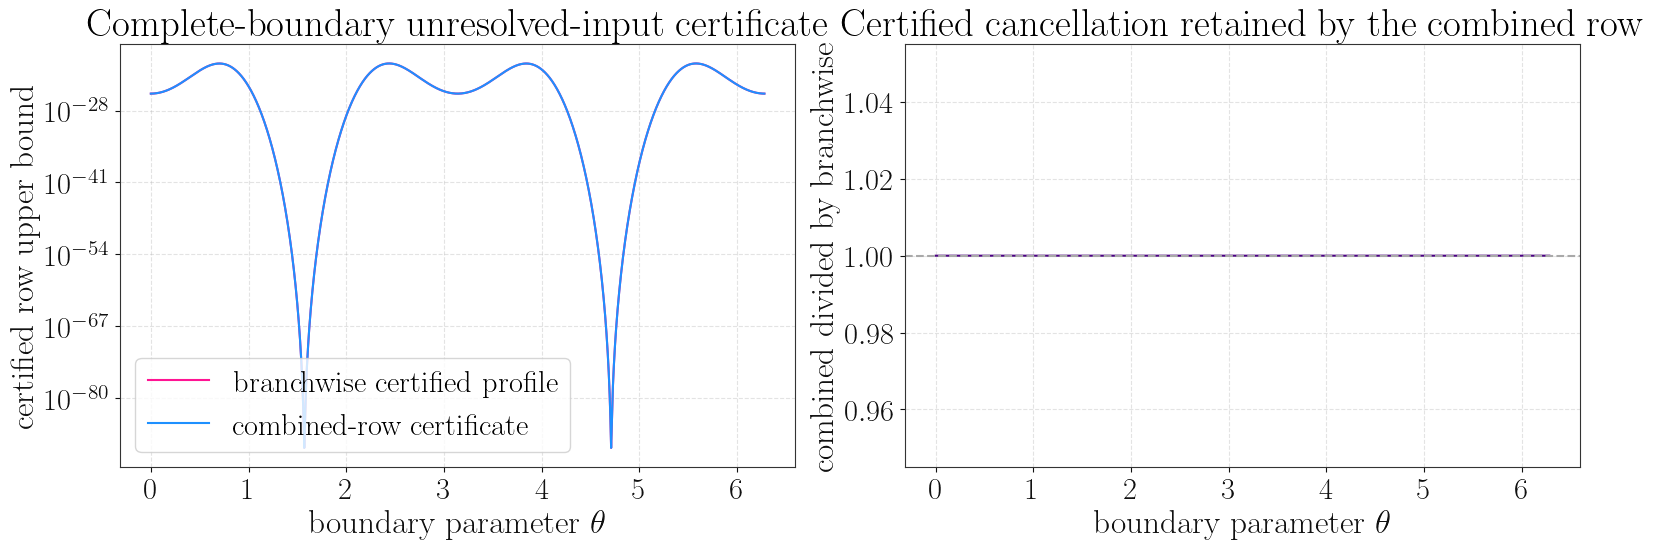

,quantity,certified_upper,role
0,branchwise profile,3.326442e-20,deployed theorem input-tail certificate
1,combined row,3.326442e-20,exact unresolved-core row with prefix cancella...


Stored: outputs/blaschke_deformation_certifier/figures/blaschke_deformation_certified_input_tail_rows.png


In [27]:
# Cell 24D
# Visualise and interpret the certified input-tail rows

_plot_stride = max(1, len(input_tail_profile_df) // 4096)
_input_plot_df = input_tail_profile_df.iloc[::_plot_stride].copy()
fig, axes = plt.subplots(1, 2, figsize=(16.0, 5.6), facecolor="white")
axes[0].semilogy(
    _input_plot_df["theta_mid"], _input_plot_df["branchwise_row_u"],
    color=PALETTE["imag"], label="branchwise certified profile"
)
axes[0].semilogy(
    _input_plot_df["theta_mid"], _input_plot_df["combined_row_u"],
    color=PALETTE["real"], label="combined-row certificate"
)
axes[0].set_xlabel(r"boundary parameter $\theta$")
axes[0].set_ylabel("certified row upper bound")
axes[0].set_title("Complete-boundary unresolved-input certificate")
axes[0].legend()
_ratio = (
    _input_plot_df["combined_row_u"]
    / _input_plot_df["branchwise_row_u"]
)
axes[1].plot(_input_plot_df["theta_mid"], _ratio, color=PALETTE["main"])
axes[1].axhline(1.0, color=PALETTE["ref"], linestyle="--")
axes[1].set_xlabel(r"boundary parameter $\theta$")
axes[1].set_ylabel("combined divided by branchwise")
axes[1].set_title("Certified cancellation retained by the combined row")
fig.tight_layout()
_input_figure_path = FIG_DIR / "blaschke_deformation_certified_input_tail_rows.png"
fig.savefig(_input_figure_path, dpi=300, bbox_inches="tight")
plt.show()

input_tail_interpretation_df = pd.DataFrame([
    {
        "quantity": "branchwise profile",
        "certified_upper": _input_summary["branchwise_profile_cert_u"],
        "role": "deployed theorem input-tail certificate",
    },
    {
        "quantity": "combined row",
        "certified_upper": _input_summary["combined_row_cert_u"],
        "role": "exact unresolved-core row with prefix cancellation",
    },
])
display(input_tail_interpretation_df)
print("Stored:", _input_figure_path)


In [28]:
# Cell 24E
# Scope and certification audit

_target_rows = raw_24_spectral_points_display_df.copy()
_trivial_rows = _target_rows[_target_rows["family"].astype(str) == "trivial"]
_nontrivial_rows = _target_rows[_target_rows["family"].astype(str) != "trivial"]
if len(_target_rows) != CERTIFIER_TOTAL_TARGETS:
    raise AssertionError(f"Expected 24 target rows, found {len(_target_rows)}.")
if len(_trivial_rows) != CERTIFIER_TRIVIAL_TARGETS:
    raise AssertionError("The trivial target must be excluded.")
if len(_nontrivial_rows) != CERTIFIER_NONTRIVIAL_TARGETS:
    raise AssertionError("Expected exactly twenty-four nontrivial target rows.")
_raw_assembly_jobs = list(raw_results.get("jobs", []))
_row_block_processes_used = bool(_raw_assembly_jobs) and all(
    str(job.get("assembly_mode")) == "process_row_blocks"
    and int(job.get("assembly_workers", 0)) == CERTIFIER_PROCESS_WORKERS
    for job in _raw_assembly_jobs
)
_certification_audit_df = pd.DataFrame([
    {"check": "map lock", "passed": SELECTED_MAP_LABEL == "blaschke_mu_0p3"},
    {"check": "complete Arb boundary cover", "passed": bool(_input_summary["boundary_cover_certified"])},
    {"check": "exact finite Chebyshev prefix", "passed": bool(_input_summary["exact_prefix_certified"])},
    {"check": "explicit infinite-tail remainder", "passed": bool(_input_summary["geometric_remainder_certified"])},
    {"check": "branchwise profile", "passed": bool(_input_summary["branchwise_profile_certified"])},
    {"check": "combined row", "passed": bool(_input_summary["combined_row_certified"])},
    {"check": "resolved-response boundary cover", "passed": bool(_rp_summary["response_boundary_cover_certified"])},
    {"check": "resolved coherent prefix", "passed": bool(_rp_summary["response_coherent_prefix_certified"])},
    {"check": "resolved response remainder", "passed": bool(_rp_summary["response_remainder_certified"])},
    {"check": "selected response no larger than coherent candidate", "passed": _rp_selected_response_upper <= _rp_coherent_global},
    {"check": "selected response no larger than scaled candidate", "passed": _rp_selected_response_upper <= _rp_scaled_response_upper},
    {"check": "selected response no larger than whole-ellipse fallback", "passed": _rp_selected_response_upper <= _rp_whole_fallback},
    {"check": "selected output factor identity", "passed": _rp_B_out == (_rp_selected_response_upper * _rp_Z_tail_upper).upper()},
    {"check": "24-process mpmath row-block assembly", "passed": _row_block_processes_used},
    {"check": "zero trivial and twenty-four nontrivial targets", "passed": len(_target_rows) == 24 and len(_trivial_rows) == 0 and len(_nontrivial_rows) == 24},
])
if not bool(_certification_audit_df["passed"].all()):
    raise AssertionError("The Blaschke deformation certification audit failed.")
_certification_audit_path = DATA_DIR / "blaschke_deformation_certification_audit.csv"
_certification_audit_df.to_csv(_certification_audit_path, index=False)
display(_certification_audit_df)
display(_target_rows.head(24))
print("Stored:", _certification_audit_path)


,check,passed
0,map lock,True
1,complete Arb boundary cover,True
2,exact finite Chebyshev prefix,True
3,explicit infinite-tail remainder,True
4,branchwise profile,True
5,combined row,True
6,resolved-response boundary cover,True
7,resolved coherent prefix,True
8,resolved response remainder,True
9,selected response no larger than coherent cand...,True


,target_rank,map_label,target_mode,N,M,map_name,name,family,power,multiplicity,target,target_float,target_real_float,target_imag_float,target_abs_float,error,error_float,selected,gram_error,gram_error_float
0,1,blaschke_mu_0p3,exact,100,100,blaschke_mu_0p3,alpha^1,alpha,1,1,0.65,0.650000,0.650000,0.0,0.650000,3.99818525447466615460697696125027485018344413...,3.998185e-67,[0.6500000000000000000000000000000000000000000...,4.44820095539165646459041712619704765666534375...,4.448201e-177
1,2,blaschke_mu_0p3,exact,100,100,blaschke_mu_0p3,alpha^2,alpha,2,1,0.4225,0.422500,0.422500,0.0,0.422500,6.01587337608710715440178983346915161213312561...,6.015873e-63,[0.4225000000000000000000000000000000000000000...,4.44820095539165646459041712619704765666534375...,4.448201e-177
2,3,blaschke_mu_0p3,exact,100,100,blaschke_mu_0p3,mu^1,mu,1,2,0.3,0.300000,0.300000,0.0,0.300000,9.71563378538771060239914644668057264852932639...,9.715634e-133,"[0.3, 0.3]",4.44820095539165646459041712619704765666534375...,4.448201e-177
3,4,blaschke_mu_0p3,exact,100,100,blaschke_mu_0p3,alpha^3,alpha,3,1,0.274625,0.274625,0.274625,0.0,0.274625,3.52530834766250476791307418443306132338730859...,3.525308e-60,[0.2746250000000000000000000000000000000000000...,4.44820095539165646459041712619704765666534375...,4.448201e-177
4,5,blaschke_mu_0p3,exact,100,100,blaschke_mu_0p3,alpha^4,alpha,4,1,0.17850625,0.178506,0.178506,0.0,0.178506,2.63022140918574665896453124125174209227195039...,2.630221e-57,[0.1785062500000000000000000000000000000000000...,4.44820095539165646459041712619704765666534375...,4.448201e-177
5,6,blaschke_mu_0p3,exact,100,100,blaschke_mu_0p3,alpha^5,alpha,5,1,0.1160290625,0.116029,0.116029,0.0,0.116029,4.67917510164334253547287442522836175249839602...,4.679175e-55,[0.1160290625000000000000000000000000000000000...,4.44820095539165646459041712619704765666534375...,4.448201e-177
6,7,blaschke_mu_0p3,exact,100,100,blaschke_mu_0p3,mu^2,mu,2,2,0.09,0.090000,0.090000,0.0,0.090000,7.44386186073379133385101807621678016579634804...,7.443862e-97,"[0.09, 0.09]",4.44820095539165646459041712619704765666534375...,4.448201e-177
7,8,blaschke_mu_0p3,exact,100,100,blaschke_mu_0p3,alpha^6,alpha,6,1,0.075418890625,0.075419,0.075419,0.0,0.075419,6.10120117637835110942507177543269980387107551...,6.101201e-53,[0.0754188906249999999999999999999999999999999...,4.44820095539165646459041712619704765666534375...,4.448201e-177
8,9,blaschke_mu_0p3,exact,100,100,blaschke_mu_0p3,alpha^7,alpha,7,1,0.04902227890625,0.049022,0.049022,0.0,0.049022,2.27545137491298505434457810871049424342459141...,2.275451e-52,[0.0490222789062499999999999999999999999999999...,4.44820095539165646459041712619704765666534375...,4.448201e-177
9,10,blaschke_mu_0p3,exact,100,100,blaschke_mu_0p3,alpha^8,alpha,8,1,0.0318644812890625,0.031864,0.031864,0.0,0.031864,4.47168684215993232823906914648149703593106225...,4.471687e-48,[0.0318644812890624999999999999999999999999999...,4.44820095539165646459041712619704765666534375...,4.448201e-177


Stored: outputs/blaschke_deformation_certifier/data/blaschke_deformation_certification_audit.csv


## Phase 2 mathematics for Cell 25

The output-side factor now follows the exact resolved Chebyshev-packet geometry.  The theorem-facing quantity is

$$
C_{N,\mathrm{resp},\star}^{X}(r,\rho)
=
\sup_{\omega\in\partial E_\rho}
\left[
  \sum_{m=0}^{N-1}
  \left|
    \sum_{b\in\mathcal B}
    \phi_b(\omega)\Psi_m^{(r)}(\tau_b(\omega))
  \right|^2
\right]^{1/2}.
$$

Cell 24B supplies three independent certified candidates for this same norm: a coherent Chebyshev-packet prefix with a local high-mode remainder, the scaled-Legendre route transported by the certified inverse connection norm, and the common whole-ellipse finite-restriction fallback.  On each complete Arb boundary cell it takes the smallest candidate, and it then takes the maximum over all cells.  The resulting selected prefactor is therefore no larger than any one of the three global routes while remaining a rigorous upper enclosure.

The single resolved-output leakage is

$$
\mathcal B_{N,\mathrm{out}}^X
=
\widehat C_{N,\mathrm{resp}}^X
\mathsf Z_{N,\mathrm{tail}}^{\mathrm{out}}(r,\rho).
$$

The next table records every candidate, the selection policy, and the selected output factor.  The safe finite-order Gauss--Legendre prefactor from Cell 24A remains independent of this output refinement.


In [29]:
# Cell 25
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_25_status = transfer_lab_execute_selected_map_cell(
        "# Cell 25", "Phase 2 deterministic Schur envelope"
    )
else:
    # ============================================================
    # Phase 2G -- resolved-response certificate readout
    # ============================================================

    response_summary_rows = []
    if response_branch_df is not None:
        row = response_branch_df.iloc[0]
        response_summary_rows.append({
            "source": "complete resolved-response certificate",
            "N": int(row["N"]),
            "rho": float(row["rho"]),
            "r": float(row["r"]),
            "coherent_prefactor": float(row["C_resp_coherent_packet_cert_u"]),
            "scaled_prefactor": float(row["C_resp_scaled_legendre_cert_u"]),
            "whole_ellipse_fallback": float(row["C_resp_whole_ellipse_fallback_u"]),
            "selected_prefactor": float(row["C_resp_selected_cert_u"]),
            "selection": str(row["response_prefactor_selection"]),
            "prefix_terms": int(row["response_prefix_terms"]),
            "boundary_cells": int(row["response_boundary_cells"]),
            "old_B_out": float(row["old_B_out_comparator"]),
            "selected_B_out": float(row["B_out_response_prefactor_cert"]),
            "improvement": float(row["B_out_improvement_vs_old"]),
            "status": str(row["status"]),
        })
    if response_df is not None:
        row = response_df.iloc[0]
        response_summary_rows.append({
            "source": "promoted resolved-response candidate row",
            "N": int(row["N"]),
            "rho": float(row["rho"]),
            "r": float(row["r"]),
            "coherent_prefactor": float(row["C_resp_coherent_packet_cert_u"]),
            "scaled_prefactor": float(row["C_resp_scaled_legendre_cert_u"]),
            "whole_ellipse_fallback": float(row["C_resp_whole_ellipse_fallback_u"]),
            "selected_prefactor": float(row["C_resp_selected_cert_u"]),
            "selection": str(row["response_prefactor_selection"]),
            "prefix_terms": int(row["response_prefix_terms"]),
            "boundary_cells": int(row["response_boundary_cells"]),
            "old_B_out": float(row["old_B_out_comparator"]),
            "selected_B_out": float(row["B_out_response_prefactor_cert"]),
            "improvement": float(row["output_improvement_factor"]),
            "status": str(row["status"]),
        })

    response_summary_df = pd.DataFrame(response_summary_rows)
    if len(response_summary_df):
        phase2_save_dataframe(
            response_summary_df,
            "branch_image_phase2_response_prefactor_summary",
        )
        display(response_summary_df)
    else:
        print("No resolved-response certificate files found.")


Saved CSV: outputs/blaschke_deformation_certifier/data/branch_image_phase2_response_prefactor_summary.csv


,source,N,rho,r,coherent_prefactor,scaled_prefactor,whole_ellipse_fallback,selected_prefactor,selection,prefix_terms,boundary_cells,old_B_out,selected_B_out,improvement,status
0,complete resolved-response certificate,600,2.725,2.47367,2.125131,357.658065,12.948436,2.125131,"cellwise minimum of coherent packet, scaled Le...",24,65536,2.358400e-20,2.854034e-23,826.339249,interval-certified coherent resolved response ...
1,promoted resolved-response candidate row,600,2.725,2.47367,2.125131,357.658065,12.948436,2.125131,"cellwise minimum of coherent packet, scaled Le...",24,65536,2.358400e-20,2.854034e-23,826.339249,authoritative selected resolved-response row w...


## Phase 2 mathematics for Cell 26

This cell plots the complete deterministic certificate components. For each certificate row $s$, the four bar groups are

$$
O_s=\mathcal{B}_{N,\mathrm{out},s}^{X},
\qquad
I_s=\mathcal{B}_{N,\mathrm{in},s}^{X},
\qquad
C_s=\widehat\kappa_N^{X\leftrightarrow r}B_{N,M,s}^{\mathrm{mat}},
\qquad
\varepsilon_s=O_s+I_s+C_s.
$$

Here $O_s$ is the compressed one-output leakage contribution, $I_s$ is the branch-image input-tail contribution, $C_s$ is the transported Schur matrix defect, and $\varepsilon_s$ is the total perturbation radius.

For the old whole-ellipse row, the input tail is the global enclosing-ellipse majorant

$$
I_{\mathrm{old}}
=
\Phi_\Sigma^{\mathrm{sample}}\,
\mathfrak U_N^{X,\mathrm{tail}}(r,r_\tau^{\mathrm{cert}}).
$$

For the branch-image rows, the input tail is replaced by the sampled certified upper branch-image profile

$$
I_{\mathrm{img}}
=
\max_{\omega\in\partial E_\rho}
\sum_b |\phi_b(\omega)|K_{N,\mathrm{upper}}^{(r)}(\tau_b(\omega)).
$$

For the response-prefactor row, the output contribution is

$$
O_{\mathrm{resp}}
=
\mathcal{B}_{N,\mathrm{out,resp}}^{X}
=
C_{\mathrm{out,resp}}(N,r,\rho)\,
\mathcal R_N^{X,\mathrm{out}}(r,\rho).
$$

The left panel in the second figure reuses the Cell 24 gain

$$
R_{\mathrm{img/cert}}(N)
=
\frac{I_{\mathrm{img}}}{I_{\mathrm{old}}},
$$

while the right panel compares the complete radii $\varepsilon_s$. The promoted row is the branch-image plus response-prefactor row exported by Cell 27.


Saved figure: outputs/blaschke_deformation_certifier/figures/branch_image_phase2_certificate_components.png


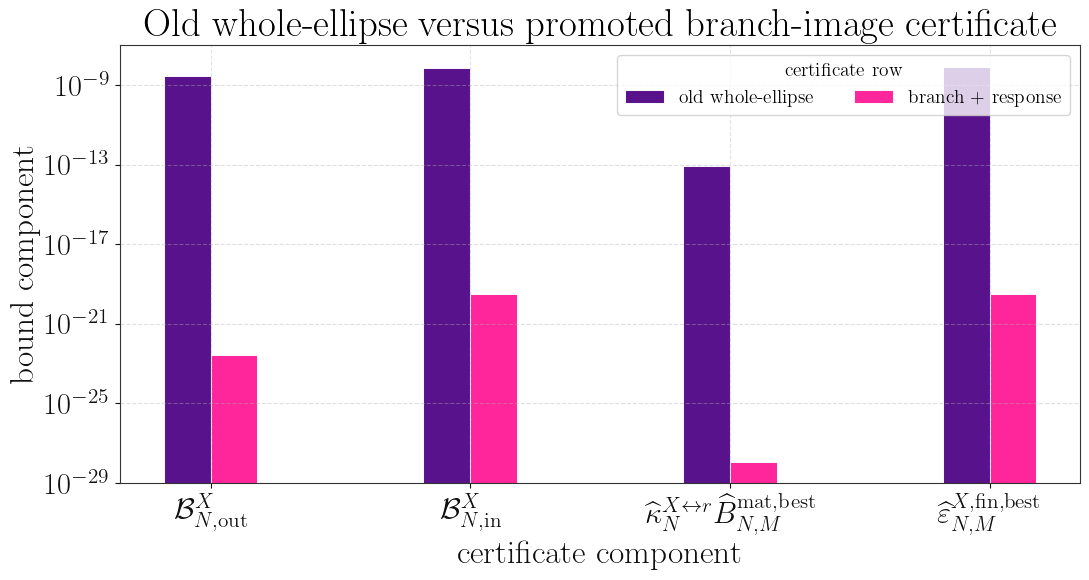

Saved figure: outputs/blaschke_deformation_certifier/figures/branch_image_phase2_certificate_array_1x2.png


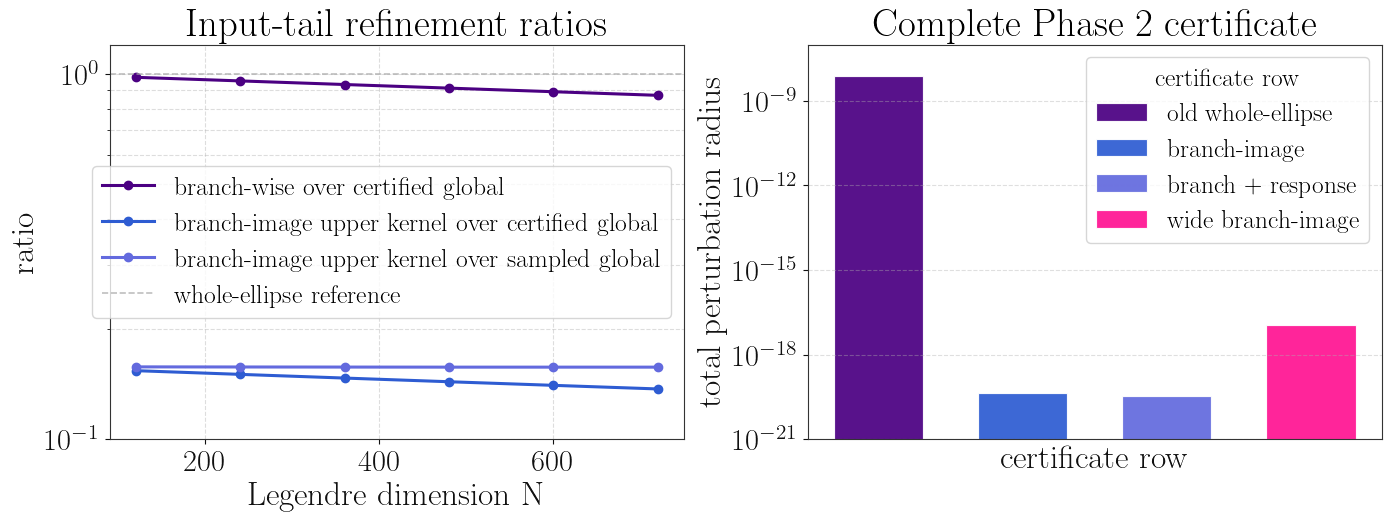

In [30]:
# Cell 26
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_26_status = transfer_lab_execute_selected_map_cell('# Cell 26', 'Phase 2 deterministic Schur envelope')
else:
    # ============================================================
    # Phase 2H — deterministic certificate component plots
    # ============================================================

    def phase2_short_source_label (label ):
        mapping ={
        "old whole-ellipse final Schur row":"old whole-ellipse",
        "branch-image balanced candidate":"branch-image",
        "branch-image plus response-prefactor row":"branch + response",
        "wide branch-image candidate":"wide branch-image",
        }
        return mapping .get (str (label ),str (label ))


    def phase2_positive_log_limits (values ,pad_decades =0.65 ):
        vals =np .asarray (values ,dtype =float )
        vals =vals [np .isfinite (vals )&(vals >0 )]
        if vals .size ==0 :
            return (1e-30 ,1.0 )
        lo =10 **(np .floor (np .log10 (vals .min ())-pad_decades ))
        hi =10 **(np .ceil (np .log10 (vals .max ())+pad_decades ))
        return lo ,hi 


    def phase2_ratio_log_limits (values ):
        vals =np .asarray (values ,dtype =float )
        vals =vals [np .isfinite (vals )&(vals >0 )]
        if vals .size ==0 :
            return (1e-2 ,1.05 )
        lo =10 **np .floor (np .log10 (vals .min ()*0.75 ))
        hi =min (1.2 ,max (1.05 ,float (vals .max ())*1.35 ))
        return lo ,hi 


    if len (cert_summary_df ):
        plot_df =cert_summary_df [cert_summary_df ["source"].isin ([
        "old whole-ellipse final Schur row",
        "branch-image plus response-prefactor row",
        ])].copy ()
        component_specs =[
        (r"$\mathcal{B}_{N,\mathrm{out}}^X$","B_out"),
        (r"$\mathcal{B}_{N,\mathrm{in}}^X$","B_in"),
        (r"$\widehat{\kappa}_N^{X\leftrightarrow r}\widehat B_{N,M}^{\mathrm{mat,best}}$","collocation"),
        (r"$\widehat{\varepsilon}_{N,M}^{X,\mathrm{fin,best}}$","epsilon"),
        ]
        source_labels =[phase2_short_source_label (s )for s in plot_df ["source"]]
        row_colours =gradient_colours (source_labels )
        component_x =np .arange (len (component_specs ),dtype =float )
        width =min (0.18 ,0.72 /max (1 ,len (source_labels )))
        offsets =(np .arange (len (source_labels ))-(len (source_labels )-1 )/2 )*width 

        fig ,ax =plt .subplots (figsize =(11.0 ,5.9 ),facecolor ="white")
        all_component_values =[]
        for offset ,row_label ,(_ ,row )in zip (offsets ,source_labels ,plot_df .iterrows ()):
            values =np .array ([float (row [column ])for _ ,column in component_specs ],dtype =float )
            all_component_values .extend (values .tolist ())
            ax .bar (
            component_x +offset ,
            values ,
            width =width ,
            label =row_label ,
            color =row_colours [row_label ],
            edgecolor ="white",
            linewidth =0.75 ,
            alpha =0.93 ,
            )
        ax .set_yscale ("log")
        ax .set_ylim (*phase2_positive_log_limits (all_component_values ))
        ax .set_xticks (component_x )
        ax .set_xticklabels ([label for label ,_ in component_specs ],rotation =0 ,ha ="center")
        ax .set_xlabel ("certificate component")
        ax .set_ylabel ("bound component")
        ax .set_title ("Old whole-ellipse versus promoted branch-image certificate")
        ax .grid (True ,which ="both",axis ="y",linestyle ="--",alpha =0.4 )
        ax .legend (title ="certificate row",fontsize =14 ,title_fontsize =14 ,ncols =2 ,loc ="upper right",frameon =True )
        fig .tight_layout ()
        fig_path =FIG_DIR /"branch_image_phase2_certificate_components.png"
        fig .savefig (fig_path ,dpi =240 ,bbox_inches ="tight")
        print ("Saved figure:",fig_path )
        plt .show ()

    if len (cert_summary_df )and len (tail_comparison_df ):
        plot_df =cert_summary_df .copy ()
        source_labels =[phase2_short_source_label (s )for s in plot_df ["source"]]
        row_colours =gradient_colours (source_labels )
        ratio_specs =[
        ("branch-wise over certified global","branchwise_over_certified_global"),
        ("branch-image upper kernel over certified global","kernel_over_certified_global"),
        ("branch-image upper kernel over sampled global","kernel_over_sampled_global"),
        ]
        epsilon_label ="total epsilon"
        colours =gradient_colours ([label for label ,_ in ratio_specs ]+[epsilon_label ])

        fig ,axes =plt .subplots (1 ,2 ,figsize =(13.8 ,5.1 ),facecolor ="white",constrained_layout =True )

        ratio_values_all =[]
        for ratio_label ,ratio_column in ratio_specs :
            ratio_values =tail_comparison_df [ratio_column ].astype (float ).to_numpy ()
            ratio_values_all .extend (ratio_values .tolist ())
            axes [0 ].plot (
            tail_comparison_df ["N"],
            ratio_values ,
            marker ="o",
            lw =2.2 ,
            color =colours [ratio_label ],
            label =ratio_label ,
            )
        axes [0 ].axhline (1.0 ,color =PALETTE .get ("ref"),lw =1.2 ,ls ="--",alpha =0.75 ,label ="whole-ellipse reference")
        axes [0 ].set_yscale ("log")
        axes [0 ].set_ylim (*phase2_ratio_log_limits (ratio_values_all ))
        axes [0 ].set_xlabel ("Legendre dimension N")
        axes [0 ].set_ylabel ("ratio")
        axes [0 ].set_title ("Input-tail refinement ratios")
        axes [0 ].grid (True ,which ="both",linestyle ="--",alpha =0.42 )
        axes [0 ].legend (fontsize =18.6 ,loc ="best",frameon =True )

        eps_x =np .arange (len (plot_df ),dtype =float )
        epsilon_values =plot_df ["epsilon"].astype (float ).to_numpy ()
        for xi ,label ,value in zip (eps_x ,source_labels ,epsilon_values ):
            axes [1 ].bar (
            xi ,
            value ,
            width =0.62 ,
            color =row_colours [label ],
            edgecolor ="white",
            linewidth =0.85 ,
            alpha =0.93 ,
            label =label ,
            )
        axes [1 ].set_yscale ("log")
        axes [1 ].set_ylim (*phase2_positive_log_limits (epsilon_values ))
        axes [1 ].set_xticks ([])
        axes [1 ].set_xlabel ("certificate row")
        axes [1 ].set_ylabel ("total perturbation radius")
        axes [1 ].set_title ("Complete Phase 2 certificate")
        axes [1 ].grid (True ,which ="both",axis ="y",linestyle ="--",alpha =0.4 )
        axes [1 ].legend (title ="certificate row",fontsize =18.4 ,title_fontsize =18.4 ,loc ="upper right",frameon =True )

        fig_path =FIG_DIR /"branch_image_phase2_certificate_array_1x2.png"
        fig .savefig (fig_path ,dpi =240 ,bbox_inches ="tight")
        print ("Saved figure:",fig_path )
        plt .show ()

## Phase 2 mathematics for Cell 27

This cell exports the promoted branch-image certificate in descriptive and compatibility formats.  The exported single-space row contains $N$, $M$, the certified radii, $q_\ast$, the selected output and input factors, the selected transported matrix certificate, and

$$
\widehat\varepsilon_{N,M}^{X,\mathrm{fin,best}}
=
\sqrt{
  \left(\mathcal B_{N,\mathrm{out}}^X\right)^2
  +
  \left(\mathcal B_{N,\mathrm{in}}^X\right)^2
}
+
\widehat{\mathcal B}_{N,M,\mathrm{col}}^X.
$$

The response provenance is exported explicitly: the coherent packet candidate, scaled-Legendre candidate, whole-ellipse fallback, selected cellwise certificate, prefix length, boundary-cell count, and certification flags all remain visible.  The input and matrix fields likewise retain every certified candidate and the selected minimum.  The flag `total_certified` is the conjunction of the branch, tail, matrix, transport, resolved-response, and safe finite-order quadrature checks; it is not inferred from the numerical size of the final radius.


In [31]:
# Cell 27
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_27_status = transfer_lab_execute_selected_map_cell('# Cell 27', 'Phase 2 deterministic Schur envelope')
else:
    # ============================================================
    # Phase 2I — export branch-image certificate and markdown report
    # ============================================================


    def phase2_cert_to_float_dict (cert ):
        out ={}
        for k ,v in cert .items ():
            if isinstance (v ,mp .mpf ):
                out [k ]=float (v )if v ==v else np .nan 
            else :
                out [k ]=v 
        return out 


    cert_float =phase2_cert_to_float_dict (PHASE2_FINAL_CERT )
    phase2_branch_image_export =pd .DataFrame ([{
    "label":cert_float ["label"],
    "N":cert_float ["N"],
    "M":cert_float ["M"],
    "m":cert_float ["m"],
    "rho":cert_float ["rho"],
    "r":cert_float ["r"],
    "r_tau":cert_float ["r_tau"],
    "q_out":cert_float ["q_out"],
    "q_gap":cert_float ["q_gap"],
    "q_star":cert_float ["q_star"],
    "epsilon":cert_float ["epsilon"],
    "noncollocation_rss":cert_float ["noncollocation_rss"],
    "noncollocation_sum":cert_float ["noncollocation_sum"],
    "epsilon_triangle_check":cert_float ["epsilon_triangle_check"],
    "tail_total":cert_float ["tail_total"],
    "B_out":cert_float ["B_out"],
    "C_resp_coherent_packet_cert_u":cert_float ["C_resp_coherent_packet_cert_u"],
    "C_resp_scaled_legendre_cert_u":cert_float ["C_resp_scaled_legendre_cert_u"],
    "C_resp_whole_ellipse_fallback_u":cert_float ["C_resp_whole_ellipse_fallback_u"],
    "C_resp_selected_cert_u":cert_float ["C_resp_selected_cert_u"],
    "response_prefactor_selection":cert_float ["response_prefactor_selection"],
    "response_prefix_terms":cert_float ["response_prefix_terms"],
    "response_boundary_cells":cert_float ["response_boundary_cells"],
    "response_boundary_cover_certified":bool (cert_float .get ("response_boundary_cover_certified",False )),
    "response_coherent_prefix_certified":bool (cert_float .get ("response_coherent_prefix_certified",False )),
    "response_remainder_certified":bool (cert_float .get ("response_remainder_certified",False )),
    "B_in":cert_float ["B_in"],
    "B_in_selection":cert_float ["B_in_selection"],
    "B_in_branchwise":cert_float ["B_in_branchwise"],
    "B_in_combined_row":cert_float ["B_in_combined_row"],
    "collocation":cert_float ["collocation"],
    "matrix_selection":cert_float ["matrix_selection"],
    "collocation_starred":cert_float ["collocation_starred"],
    "collocation_ordinary":cert_float ["collocation_ordinary"],
    "B_mat":cert_float ["B_mat"],
    "C_tr":cert_float ["kappa_hat"],
    "kappa_hat":cert_float ["kappa_hat"],
    "kappa_diag":cert_float ["kappa_diag"],
    "lambda_min_cert":cert_float ["lambda_min_cert"],
    "lambda_max_cert":cert_float ["lambda_max_cert"],
    "residual_delta_cert":cert_float ["residual_delta_cert"],
    "output_tail_mode":"response-prefactor branch-image certificate",
    "transport_route":"certified finite Chebyshev-gauge transport factor",
    "transport_certified":bool (cert_float .get ("transport_certified",False )),
    "tail_mismatch_certified":bool (cert_float .get ("tail_components_interval",False )),
    "matrix_certified":bool (cert_float .get ("matrix_certified",False )),
    "branch_data_certified":True ,
    "response_prefactor_certified":bool (cert_float .get ("response_prefactor_certified",False )),
    "finite_M_prefactor_certified":bool (cert_float .get ("finite_M_prefactor_certified",False )),
    "certified":bool (PHASE2_FINAL_CERT ["certified"]),
    "status":cert_float ["status"],
    }])
    phase2_save_dataframe (phase2_branch_image_export ,"branch_image_phase2_certified_single_space_row_N600_M610")
    phase2_save_dataframe (phase2_branch_image_export ,"phase2_certified_single_space_row_N600_M610")

    phase2_schur_compat =pd .DataFrame ([{
    "N":cert_float ["N"],
    "M":cert_float ["M"],
    "rho":cert_float ["rho"],
    "r":cert_float ["r"],
    "r_tau":cert_float ["r_tau"],
    "q_out":cert_float ["q_out"],
    "q_gap":cert_float ["q_gap"],
    "q_star":cert_float ["q_star"],
    "Phi":np .nan ,
    "Phi_star":np .nan ,
    "B_out_X":cert_float ["B_out"],
    "C_resp_coherent_packet_cert_u":cert_float ["C_resp_coherent_packet_cert_u"],
    "C_resp_scaled_legendre_cert_u":cert_float ["C_resp_scaled_legendre_cert_u"],
    "C_resp_whole_ellipse_fallback_u":cert_float ["C_resp_whole_ellipse_fallback_u"],
    "C_resp_selected_cert_u":cert_float ["C_resp_selected_cert_u"],
    "response_prefactor_selection":cert_float ["response_prefactor_selection"],
    "response_prefix_terms":cert_float ["response_prefix_terms"],
    "response_boundary_cells":cert_float ["response_boundary_cells"],
    "B_in_X":cert_float ["B_in"],
    "Bmat":cert_float ["B_mat"],
    "kappa_hat":cert_float ["kappa_hat"],
    "kappa_Bmat":cert_float ["collocation"],
    "epsilon_X":cert_float ["epsilon"],
    "epsilon_X_triangle_check":cert_float ["epsilon_triangle_check"],
    "branch_data_certified":True ,
    "output_tail_certified":bool (cert_float .get ("response_prefactor_certified",False )),
    "input_tail_certified":True ,
    "transport_certified":bool (cert_float .get ("transport_certified",False )),
    "schur_matrix_certified":bool (cert_float .get ("matrix_certified",False )),
    "finite_M_prefactor_certified":bool (cert_float .get ("finite_M_prefactor_certified",False )),
    "total_certified":bool (PHASE2_FINAL_CERT ["certified"]),
    }])
    phase2_save_dataframe (phase2_schur_compat ,"branch_image_phase2_N600_schur_single_space_certificate")
    phase2_save_dataframe (phase2_schur_compat ,"phase2_N600_schur_single_space_certificate")

    lines =[]
    lines .append ("# Phase 2 branch-image certificate report")
    lines .append ("")
    lines .append (f"Promoted row: N={N_CERT_X }, M={M_CERT_X }.")
    lines .append (f"Branch-image radii: rho={mp .nstr (PHASE2_FINAL_CERT ['rho'],20 )}, r={mp .nstr (PHASE2_FINAL_CERT ['r'],20 )}, r_tau={mp .nstr (PHASE2_FINAL_CERT ['r_tau'],20 )}.")
    lines .append (f"q_out={mp .nstr (PHASE2_FINAL_CERT ['q_out'],20 )}, q_gap={mp .nstr (PHASE2_FINAL_CERT ['q_gap'],20 )}, q_star={mp .nstr (PHASE2_FINAL_CERT ['q_star'],20 )}.")
    lines .append ("")
    lines .append ("## Bound components")
    lines .append ("")
    lines .append (f"- output tail B_out: {mp .nstr (PHASE2_FINAL_CERT ['B_out'],30 )}")
    lines .append (f"- coherent packet response upper: {mp .nstr (PHASE2_FINAL_CERT ['C_resp_coherent_packet_cert_u'],30 )}")
    lines .append (f"- scaled-Legendre response upper: {mp .nstr (PHASE2_FINAL_CERT ['C_resp_scaled_legendre_cert_u'],30 )}")
    lines .append (f"- whole-ellipse response fallback: {mp .nstr (PHASE2_FINAL_CERT ['C_resp_whole_ellipse_fallback_u'],30 )}")
    lines .append (f"- selected response upper: {mp .nstr (PHASE2_FINAL_CERT ['C_resp_selected_cert_u'],30 )}")
    lines .append (f"- response selection: {PHASE2_FINAL_CERT ['response_prefactor_selection']}")
    lines .append (f"- response prefix and cells: {PHASE2_FINAL_CERT ['response_prefix_terms']} modes over {PHASE2_FINAL_CERT ['response_boundary_cells']} cells")
    lines .append (f"- selected input tail: {mp .nstr (PHASE2_FINAL_CERT ['B_in'],30 )}")
    lines .append (f"- input selection: {PHASE2_FINAL_CERT ['B_in_selection']}")
    lines .append (f"- coherent-row input upper: {mp .nstr (PHASE2_FINAL_CERT ['B_in_combined_row'],30 )}")
    lines .append (f"- branchwise input upper: {mp .nstr (PHASE2_FINAL_CERT ['B_in_branchwise'],30 )}")
    lines .append (f"- best transported Schur matrix defect: {mp .nstr (PHASE2_FINAL_CERT ['collocation'],30 )}")
    lines .append (f"- matrix selection: {PHASE2_FINAL_CERT ['matrix_selection']}")
    lines .append (f"- total epsilon_X: {mp .nstr (PHASE2_FINAL_CERT ['epsilon'],30 )}")
    lines .append (f"- auxiliary triangle epsilon_X: {mp .nstr (PHASE2_FINAL_CERT ['epsilon_triangle_check'],30 )}")
    lines .append (f"- response prefactor certified: {PHASE2_FINAL_CERT.get ('response_prefactor_certified',False )}")
    lines .append (f"- finite-M quadrature prefactor certified: {PHASE2_FINAL_CERT.get ('finite_M_prefactor_certified',False )}")
    lines .append (f"- complete row theorem-certified: {PHASE2_FINAL_CERT.get ('certified',False )}")
    lines .append ("")
    lines .append ("The branch-image row selects the best supplied coherent, branchwise and whole-ellipse input certificate.  On the output side it selects cellwise among the coherent packet, scaled-Legendre and whole-ellipse resolved-response certificates before applying the common output-tail factor.")
    phase2_report ="\n".join (lines )
    report_path =REPORT_DIR /"branch_image_phase2_certificate_report.md"
    report_path .write_text (phase2_report ,encoding ="utf-8")
    print (f"Saved Phase 2 report: {report_path }")
    print (phase2_report )

Saved CSV: outputs/blaschke_deformation_certifier/data/branch_image_phase2_certified_single_space_row_N600_M610.csv
Saved CSV: outputs/blaschke_deformation_certifier/data/phase2_certified_single_space_row_N600_M610.csv
Saved CSV: outputs/blaschke_deformation_certifier/data/branch_image_phase2_N600_schur_single_space_certificate.csv
Saved CSV: outputs/blaschke_deformation_certifier/data/phase2_N600_schur_single_space_certificate.csv
Saved Phase 2 report: outputs/blaschke_deformation_certifier/reports/branch_image_phase2_certificate_report.md
# Phase 2 branch-image certificate report

Promoted row: N=600, M=610.
Branch-image radii: rho=2.725, r=2.473669807791324, r_tau=2.293091911822557.
q_out=0.9077687368041556, q_gap=0.92700000000000005, q_star=0.92700000000000005.

## Bound components

- output tail B_out: 2.8540338522337406e-23
- coherent packet response upper: 2.12513094458366
- scaled-Legendre response upper: 357.65806461420146
- whole-ellipse response fallback: 12.948435637965648


**Cell 28**

## Phase 2 closure and Phase 3 hand-off

The Phase 2 hand-off is the best certified finite-envelope radius $\varepsilon_X=\widehat\varepsilon_{N,M}^{X,\mathrm{fin,best}}$ stored in `PHASE2_FINAL_CERT` and exported to the compatibility CSV files.  Its output factor uses the cellwise minimum of the certified coherent packet, scaled-Legendre, and whole-ellipse resolved-response candidates.  The executed Phase 2 report gives the current values at $N=600$, $M=610$.  Phase 3 compares raw empirical spectral errors with this deterministic scale, while the validated Phase 4 contour calculation uses the same radius in the Riesz small-gain tests.


## Phase 3

## Mathematics for Cell 30

Phase 3 loads the raw spectral data and the branch-image deterministic row. It compares empirical cluster errors for $\widehat L_N^{(N)}$ with the theorem-level scale $\varepsilon_X$ and the geometric reference $q_\ast^N$.

The branch-image certificate row supplies the radii and the two geometric bases

$$
q_{\mathrm{out}}=\frac r\rho,
\qquad
q_{\mathrm{gap}}=\frac{r_\tau}{r},
\qquad
q_\ast=\max\{q_{\mathrm{out}},q_{\mathrm{gap}}\}.
$$

The deterministic perturbation radius is decomposed as

$$
\varepsilon_X
=
2\mathcal{B}_{N,\mathrm{out}}^X
+
\mathcal{B}_{N,\mathrm{in}}^X
+
\widehat\kappa_N^{X\leftrightarrow r}B_{N,M}^{\mathrm{mat}}.
$$

The non-collocation analytic tail total recorded by the code is

$$
\mathcal{B}_{N,\mathrm{tail}}^X
=
2\mathcal{B}_{N,\mathrm{out}}^X+
\mathcal{B}_{N,\mathrm{in}}^X.
$$

The normalised prefactor relative to the geometric core is

$$
C_{q_\ast}(N,M)
=
\frac{\varepsilon_X}{q_\ast^N},
$$

and the effective finite base printed in the rate diagnostics is

$$
q_{\mathrm{eff}}(N,M)
=
\varepsilon_X^{1/N}.
$$

For the empirical raw square blocks, the loaded error table contains packet errors

$$
\Delta_j(N,N)
=
\operatorname{dist}_{\mathrm{match}}
\bigl(\operatorname{spec}(\widehat L_N^{(N)}),\lambda_j\bigr),
$$

where $\lambda_j$ is one of the exact Blaschke target packets. These empirical errors are plotted against the deterministic scale, but they are not themselves the theorem-level operator norm bound.


In [32]:
# Cell 30
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_30_status = transfer_lab_execute_selected_map_cell('# Cell 30', 'Phase 3 empirical-versus-deterministic rate comparison')
else:
    # ============================================================
    # Phase 3A — branch-image data loading for empirical and deterministic rates
    # ============================================================

    from pathlib import Path 
    import numpy as np 
    import pandas as pd 
    import matplotlib .pyplot as plt 
    import mpmath as mp 

    try :
        from IPython .display import display 
    except Exception :
        def display (obj ):
            print (obj )

    DATA_DIR =globals ().get ("DATA_DIR",OUTPUT_DIR /"data")
    FIG_DIR =globals ().get ("FIG_DIR",OUTPUT_DIR /"figures")
    REPORT_DIR =globals ().get ("REPORT_DIR",OUTPUT_DIR /"reports")
    DATA_DIR .mkdir (parents =True ,exist_ok =True )
    FIG_DIR .mkdir (parents =True ,exist_ok =True )
    REPORT_DIR .mkdir (parents =True ,exist_ok =True )

    if "PALETTE"not in globals ():
        PALETTE ={
        "real":"dodgerblue",
        "imag":"deeppink",
        "main":"indigo",
        "ref":"darkgrey",
        "bg":"#f0f2f5",
        }

    try :
        phase1_gradient_palette 
    except NameError :
        from matplotlib .colors import LinearSegmentedColormap ,to_hex 
        PHASE1_GRADIENT_CMAP =LinearSegmentedColormap .from_list (
        "phase1_indigo_blue_pink",
        ((0.00 ,PALETTE .get ("main")),(0.52 ,PALETTE .get ("real")),(1.00 ,PALETTE .get ("imag"))),
        )
        def phase1_gradient_palette (labels ):
            labels =tuple (labels )
            denom =max (1 ,len (labels )-1 )
            return {label :to_hex (PHASE1_GRADIENT_CMAP (i /denom ))for i ,label in enumerate (labels )}


    def phase3_float (x ):
        try :
            if x is None :
                return np .nan 
            text =str (x ).strip ()
            if text .lower ()in {"","nan","none"}:
                return np .nan 
            return float (mp .mpf (text ))
        except Exception :
            try :
                return float (x )
            except Exception :
                return np .nan 


    def phase3_bool (x ):
        if isinstance (x ,(bool ,np .bool_ )):
            return bool (x )
        return str (x ).strip ().lower ()in {"true","1","yes","y","certified"}


    def phase3_col (df ,candidates ,required =True ):
        lower ={str (c ).lower ():c for c in df .columns }
        for name in candidates :
            if name in df .columns :
                return name 
            if str (name ).lower ()in lower :
                return lower [str (name ).lower ()]
        if required :
            raise KeyError (f"Missing any of {candidates }; columns are {list (df .columns )}")
        return None 


    def phase3_load_current_certificate ():
        path =DATA_DIR /"phase2_certified_single_space_row_N600_M610.csv"
        if not path .exists ():
            raise FileNotFoundError (f"Missing branch-image Phase 2 certificate row: {path }")
        df =pd .read_csv (path )
        row =df .iloc [0 ]
        b_out_value =phase3_float (row .get ("B_out",row .get ("B_out_X",np .nan )))
        cert ={
        "label":str (row .get ("label","branch-image row")),
        "N":int (phase3_float (row ["N"])),
        "M":int (phase3_float (row ["M"])),
        "rho":mp .mpf (str (row ["rho"])),
        "r":mp .mpf (str (row ["r"])),
        "r_tau":mp .mpf (str (row ["r_tau"])),
        "q_out":mp .mpf (str (row ["q_out"])),
        "q_gap":mp .mpf (str (row ["q_gap"])),
        "q_star":mp .mpf (str (row ["q_star"])),
        "epsilon":mp .mpf (str (row ["epsilon"])),
        "B_out":mp .mpf (str (b_out_value)),
        "B_in":mp .mpf (str (row ["B_in"])),
        "collocation":mp .mpf (str (row ["collocation"])),
        "kappa_hat":mp .mpf (str (row .get ("kappa_hat",row .get ("C_tr","nan")))),
        "certified":phase3_bool (row .get ("certified",False )),
        "source_path":str (path ),
        }
        cert ["noncollocation_rss"]=mp .sqrt (cert ["B_out"]**2 +cert ["B_in"]**2 )
        cert ["tail_total"]=cert ["noncollocation_rss"]  # compatibility alias
        cert ["C_qstar"]=cert ["epsilon"]/(cert ["q_star"]**cert ["N"])
        cert ["epsilon_over_qstar_power"]=cert ["C_qstar"]
        cert ["effective_base"]=cert ["epsilon"]**(mp .mpf (1 )/cert ["N"])
        return cert 


    PHASE3_CERT =phase3_load_current_certificate ()
    QSTAR_X =PHASE3_CERT ["q_star"]
    N_CERT_X =PHASE3_CERT ["N"]
    M_CERT_X =PHASE3_CERT ["M"]
    EPS_CERT_X =PHASE3_CERT ["epsilon"]
    BOUT_CERT_X =PHASE3_CERT ["B_out"]
    BIN_CERT_X =PHASE3_CERT ["B_in"]
    COLL_CERT_X =PHASE3_CERT ["collocation"]
    C_CERT_QSTAR =PHASE3_CERT ["C_qstar"]

    print ("Branch-image Phase 3 certificate")
    for key in ["N","M","rho","r","r_tau","q_out","q_gap","q_star","epsilon","certified"]:
        print (f"  {key :10s}: {mp .nstr (PHASE3_CERT [key ],30 )if isinstance (PHASE3_CERT [key ],mp .mpf )else PHASE3_CERT [key ]}")


    def phase3_load_raw_square_data ():
        candidates =[
        DATA_DIR /"raw_spectrum_square_N_sweep.csv",
        DATA_DIR /"phase3_square_raw_cluster_data.csv",
        DATA_DIR /"phase3_final_raw_curve_square.csv",
        ]
        for path in candidates :
            if path .exists ():
                df =pd .read_csv (path )
                try :
                    col_N =phase3_col (df ,["N"])
                    col_M =phase3_col (df ,["M"],required =False )
                    col_m =phase3_col (df ,["m"],required =False )
                    col_name =phase3_col (df ,["name","target","cluster"])
                    col_error =phase3_col (df ,["error_float","error","cluster_error","raw_error"])
                    out =pd .DataFrame ()
                    out ["N"]=df [col_N ].apply (phase3_float ).astype (int )
                    if col_M is not None :
                        out ["M"]=df [col_M ].apply (phase3_float ).astype (int )
                    elif col_m is not None :
                        out ["M"]=out ["N"]+df [col_m ].apply (phase3_float ).astype (int )
                    else :
                        out ["M"]=out ["N"]
                    out ["m"]=out ["M"]-out ["N"]
                    out ["name"]=df [col_name ].astype (str )
                    out ["error"]=df [col_error ].apply (phase3_float )
                    out ["source"]=str (path )
                    out =out [(out ["M"]==out ["N"])&np .isfinite (out ["error"])&(out ["error"]>0 )].copy ()
                    if len (out ):
                        print (f"Loaded square raw data from {path }")
                        return out .sort_values (["name","N"]).reset_index (drop =True )
                except Exception as exc :
                    print (f"Skipped {path }: {exc }")
        raise FileNotFoundError ("No usable square raw cluster data found.")


    def phase3_load_certificate_comparison ():
        summary_path =DATA_DIR /"branch_image_phase2_certificate_summary.csv"
        if summary_path .exists ():
            df =pd .read_csv (summary_path )
        else :
            df =pd .DataFrame ()
        rows =[]
        for row in df .itertuples (index =False ):
            source =str (getattr (row ,"source"))
            b_out_row =phase3_float (getattr (row ,"B_out",np .nan ))
            rows .append ({
            "source":source ,
            "short_source":{
            "old whole-ellipse final Schur row":"old",
            "branch-image balanced candidate":"branch-image",
            "branch-image plus response-prefactor row":"response",
            "wide branch-image candidate":"wide",
            }.get (source ,source ),
            "N":int (getattr (row ,"N")),
            "M":int (getattr (row ,"M")),
            "rho":phase3_float (getattr (row ,"rho")),
            "r":phase3_float (getattr (row ,"r")),
            "r_tau":phase3_float (getattr (row ,"r_tau")),
            "q_star":phase3_float (getattr (row ,"q_star")),
            "B_out":b_out_row,
            "B_in":phase3_float (getattr (row ,"B_in")),
            "collocation":phase3_float (getattr (row ,"collocation")),
            "epsilon":phase3_float (getattr (row ,"epsilon")),
            "status":str (getattr (row ,"status")),
            })
        if not any (r ["short_source"]=="response"for r in rows ):
            rows .append ({
            "source":"branch-image plus response-prefactor row",
            "short_source":"response-prefactor",
            "N":N_CERT_X ,
            "M":M_CERT_X ,
            "rho":float (PHASE3_CERT ["rho"]),
            "r":float (PHASE3_CERT ["r"]),
            "r_tau":float (PHASE3_CERT ["r_tau"]),
            "q_star":float (QSTAR_X ),
            "B_out":float (BOUT_CERT_X ),
            "B_in":float (BIN_CERT_X ),
            "collocation":float (COLL_CERT_X ),
            "epsilon":float (EPS_CERT_X ),
            "status":"current promoted branch-image row",
            })
        out =pd .DataFrame (rows )
        out ["qstar_power"]=out .apply (lambda rr :float (mp .mpf (str (rr ["q_star"]))**int (rr ["N"])),axis =1 )
        out ["epsilon_over_qstar_power"]=out ["epsilon"]/out ["qstar_power"]
        out ["effective_base"]=out ["epsilon"].apply (lambda x :float (mp .mpf (str (x ))**(mp .mpf (1 )/N_CERT_X ))if x >0 else np .nan )
        return out 


    phase3_square_raw_df =phase3_load_raw_square_data ()
    phase3_cert_compare_df =phase3_load_certificate_comparison ()

    phase3_square_raw_df .to_csv (DATA_DIR /"branch_image_phase3_square_raw_cluster_data.csv",index =False )
    phase3_cert_compare_df .to_csv (DATA_DIR /"branch_image_phase3_certificate_comparison.csv",index =False )
    phase3_cert_compare_df .to_csv (DATA_DIR /"branch_image_phase3_rate_diagnostics.csv",index =False )

    print ("Raw square data shape:",phase3_square_raw_df .shape )
    print ("Raw square N range:",int (phase3_square_raw_df ["N"].min ()),"to",int (phase3_square_raw_df ["N"].max ()))
    print ("Certificate comparison rows")
    display (phase3_cert_compare_df )

Branch-image Phase 3 certificate
  N         : 600
  M         : 610
  rho       : 2.725
  r         : 2.473669807791324
  r_tau     : 2.293091911822557
  q_out     : 0.9077687368041556
  q_gap     : 0.927
  q_star    : 0.927
  epsilon   : 3.326443383901743e-20
  certified : True
Loaded square raw data from outputs/blaschke_deformation_certifier/data/raw_spectrum_square_N_sweep.csv
Raw square data shape: (216, 6)
Raw square N range: 10 to 100
Certificate comparison rows


,source,short_source,N,M,rho,r,r_tau,q_star,B_out,B_in,collocation,epsilon,status,qstar_power,epsilon_over_qstar_power,effective_base
0,old whole-ellipse final Schur row,old,600,610,1.5999,1.512042,1.462145,0.967,2.823000e-09,7.337851e-09,8.560000e-14,7.862235e-09,old deployed thesis row,1.802538e-09,4.361758,0.969377
1,branch-image balanced candidate,branch-image,600,610,2.7250,2.473670,2.293092,0.927,2.358400e-20,3.522800e-20,1.087247e-28,4.239360e-20,balanced branch-image row with unconditional s...,1.769459e-20,2.395851,0.928351
2,branch-image plus response-prefactor row,response,600,610,2.7250,2.473670,2.293092,0.927,2.854034e-23,3.326442e-20,1.087247e-28,3.326443e-20,unconditional selected resolved-response singl...,1.769459e-20,1.879921,0.927976
3,wide branch-image candidate,wide,600,610,2.4500,2.225975,2.083512,0.936,1.817289e-20,1.164116e-17,7.499811e-28,1.164117e-17,wide branch-image row with unconditional safe ...,5.827862e-18,1.997503,0.937080


## Mathematics for Cell 31

This cell fits empirical square-block rates.  For each selected target packet it studies $N\mapsto\Delta_j(N,N)$ and fits $\log\Delta_j(N,N)\approx a_j+b_jN$, giving the observed base $e^{b_j}$.


Fitted empirical bases relative to branch-image q_star


,name,fitted_base,fitted_base_over_qstar,points,N_min,N_max
0,mu^1,0.034250,0.036947,10,10,100
1,mu^2,0.079941,0.086236,10,10,100
2,alpha^1,0.218252,0.235439,10,10,100
3,alpha^2,0.227461,0.245373,10,10,100
4,alpha^3,0.232859,0.251196,10,10,100
5,alpha^5,0.277177,0.299004,3,10,30


Saved figure: outputs/blaschke_deformation_certifier/figures/branch_image_phase3_raw_cluster_errors_vs_branch-image_qstar.png


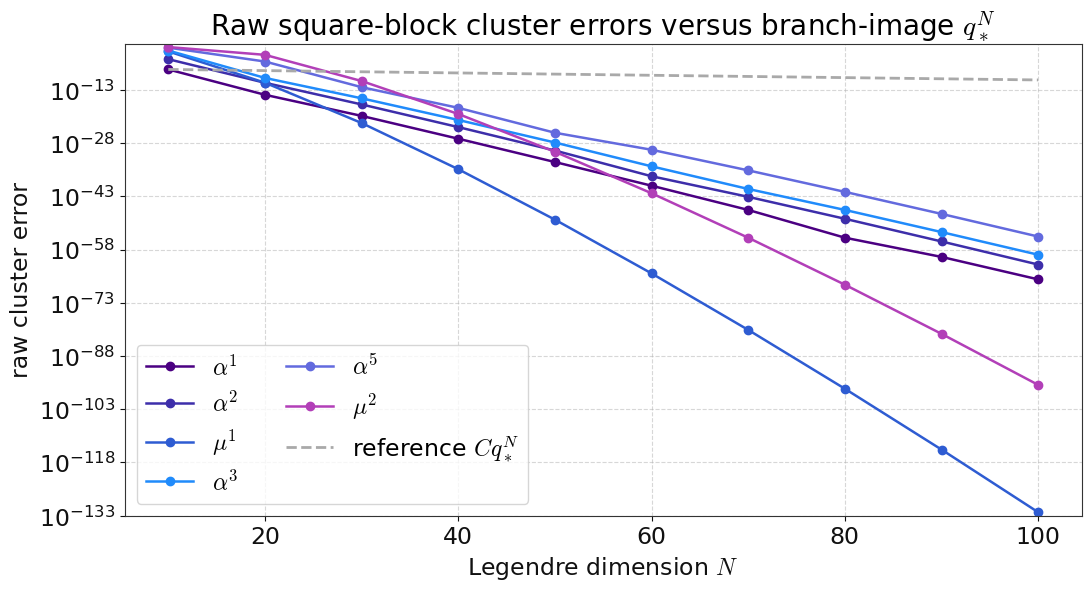

Saved figure: outputs/blaschke_deformation_certifier/figures/branch_image_phase3_raw_cluster_errors_normalised_by_qstar.png


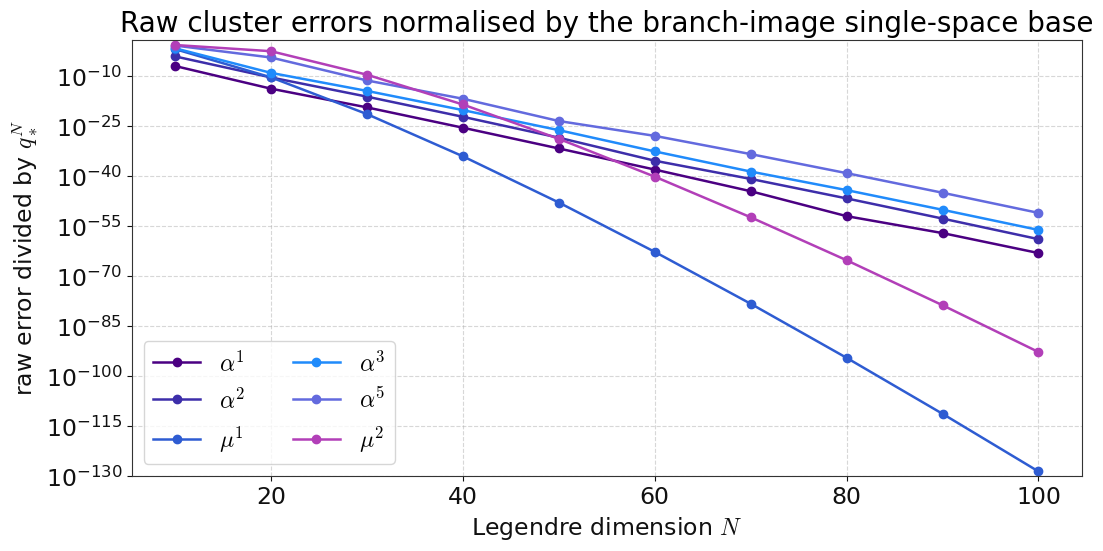

In [33]:
# Cell 31
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_31_status = transfer_lab_execute_selected_map_cell('# Cell 31', 'Phase 3 empirical-versus-deterministic rate comparison')
else:
    # ============================================================
    # Phase 3B — empirical square raw cluster rates under branch-image q_star
    # ============================================================

    PHASE3_TARGETS =["alpha^1","alpha^2","mu^1","alpha^3","alpha^5","mu^2"]
    PHASE3_FIT_FLOOR =1e-14 

    plt .rcParams .update ({
    "text.usetex":False ,
    "font.family":"DejaVu Sans",
    "mathtext.fontset":"cm",
    "axes.unicode_minus":False ,
    "axes.titlesize":20 ,
    "axes.labelsize":17 ,
    "xtick.labelsize":17 ,
    "ytick.labelsize":17 ,
    "legend.fontsize":17 ,
    })


    def phase3_latex_target_label (name ):
        name =str (name )
        if name .startswith ("alpha^"):
            return rf"$\alpha^{{{name .split ('^')[1 ]}}}$"
        if name .startswith ("mu^"):
            return rf"$\mu^{{{name .split ('^')[1 ]}}}$"
        return rf"${name }$"


    def build_phase3_raw_curve (raw_df ,targets ):
        rows =[]
        for target in targets :
            g =raw_df [raw_df ["name"]==target ].copy ()
            if len (g )==0 :
                print (f"Warning: no rows for target {target }")
                continue 
            for N ,group in g .groupby ("N"):
                group =group [np .isfinite (group ["error"])&(group ["error"]>0 )].copy ()
                if len (group )==0 :
                    continue 
                row =group .sort_values ("error").iloc [0 ]
                rows .append ({"N":int (row ["N"]),"M":int (row ["M"]),"m":int (row ["m"]),"name":target ,"error":float (row ["error"]),"source":row ["source"]})
        out =pd .DataFrame (rows ).sort_values (["name","N"]).reset_index (drop =True )
        out ["qstar_power"]=[float (QSTAR_X **int (N ))for N in out ["N"]]
        out ["error_over_qstar_power"]=out ["error"]/out ["qstar_power"]
        return out 




    def phase3_positive_log_limits (values ,pad_decades =0.7 ):
        vals =np .asarray (values ,dtype =float )
        vals =vals [np .isfinite (vals )&(vals >0 )]
        if vals .size ==0 :
            return 1e-12 ,1.0 
        lo =10 **(np .floor (np .log10 (vals .min ())-pad_decades ))
        hi =10 **(np .ceil (np .log10 (vals .max ())+pad_decades ))
        return lo ,hi 

    def fit_phase3_cluster_bases (raw_curve_df ):
        rows =[]
        for target ,g in raw_curve_df .groupby ("name"):
            fit_g =g [np .isfinite (g ["error"])&(g ["error"]>PHASE3_FIT_FLOOR )&(g ["error"]<1e-1 )].copy ()
            if len (fit_g )<3 :
                fit_g =g [np .isfinite (g ["error"])&(g ["error"]>0 )].copy ()
            if len (fit_g )<3 :
                continue 
            N =fit_g ["N"].to_numpy (dtype =float )
            log_err =np .log (fit_g ["error"].to_numpy (dtype =float ))
            slope ,intercept =np .polyfit (N ,log_err ,1 )
            base =float (np .exp (slope ))
            rows .append ({
            "name":target ,
            "fitted_base":base ,
            "fitted_base_over_qstar":base /float (QSTAR_X ),
            "points":len (fit_g ),
            "N_min":int (np .min (N )),
            "N_max":int (np .max (N )),
            })
        return pd .DataFrame (rows ).sort_values ("fitted_base").reset_index (drop =True )


    phase3_raw_curve_df =build_phase3_raw_curve (phase3_square_raw_df ,PHASE3_TARGETS )
    phase3_fit_df =fit_phase3_cluster_bases (phase3_raw_curve_df )
    phase3_raw_curve_df .to_csv (DATA_DIR /"branch_image_phase3_raw_cluster_curves.csv",index =False )
    phase3_fit_df .to_csv (DATA_DIR /"branch_image_phase3_raw_cluster_fitted_bases.csv",index =False )

    print ("Fitted empirical bases relative to branch-image q_star")
    display (phase3_fit_df )

    labels =PHASE3_TARGETS +["branch-image qstar"]
    colours =phase1_gradient_palette (labels )

    fig ,ax =plt .subplots (figsize =(10.8 ,5.8 ),facecolor ="white",constrained_layout =True )
    for target in PHASE3_TARGETS :
        g =phase3_raw_curve_df [phase3_raw_curve_df ["name"]==target ].sort_values ("N")
        if len (g )==0 :
            continue 
        ax .semilogy (g ["N"],g ["error"],marker ="o",linewidth =1.8 ,color =colours [target ],label =phase3_latex_target_label (target ))

    anchor_df =phase3_raw_curve_df [(phase3_raw_curve_df ["name"]=="alpha^1")&(phase3_raw_curve_df ["error"]>PHASE3_FIT_FLOOR )].sort_values ("N")
    if len (anchor_df ):
        anchor =anchor_df .iloc [-1 ]
        N_line =np .arange (int (phase3_raw_curve_df ["N"].min ()),int (phase3_raw_curve_df ["N"].max ())+1 )
        C_anchor =float (anchor ["error"])/float (QSTAR_X **int (anchor ["N"]))
        q_line =[C_anchor *float (QSTAR_X **int (N ))for N in N_line ]
        ax .semilogy (N_line ,q_line ,linestyle ="--",linewidth =2.0 ,color =PALETTE ["ref"],label =r"reference $Cq_*^N$")

    raw_plot_values =phase3_raw_curve_df ["error"].to_numpy (dtype =float )
    ax .set_ylim (*phase3_positive_log_limits (raw_plot_values ))
    ax .set_xlabel (r"Legendre dimension $N$")
    ax .set_ylabel ("raw cluster error")
    ax .set_title (r"Raw square-block cluster errors versus branch-image $q_*^N$")
    ax .grid (True ,which ="both",linestyle ="--",alpha =0.5 )
    ax .legend (ncol =2 ,frameon =True )
    fig_path =FIG_DIR /"branch_image_phase3_raw_cluster_errors_vs_branch-image_qstar.png"
    fig .savefig (fig_path ,dpi =230 ,bbox_inches ="tight")
    print ("Saved figure:",fig_path )
    plt .show ()

    fig ,ax =plt .subplots (figsize =(10.8 ,5.4 ),facecolor ="white",constrained_layout =True )
    for target in PHASE3_TARGETS :
        g =phase3_raw_curve_df [phase3_raw_curve_df ["name"]==target ].sort_values ("N")
        if len (g )==0 :
            continue 
        ax .plot (g ["N"],g ["error_over_qstar_power"],marker ="o",linewidth =1.8 ,color =colours [target ],label =phase3_latex_target_label (target ))
    ax .set_yscale ("log")
    norm_values =phase3_raw_curve_df ["error_over_qstar_power"].to_numpy (dtype =float )
    ax .set_ylim (*phase3_positive_log_limits (norm_values ))
    ax .set_xlabel (r"Legendre dimension $N$")
    ax .set_ylabel (r"raw error divided by $q_*^N$")
    ax .set_title (r"Raw cluster errors normalised by the branch-image single-space base")
    ax .grid (True ,which ="both",linestyle ="--",alpha =0.5 )
    ax .legend (ncol =2 ,frameon =True )
    fig_path =FIG_DIR /"branch_image_phase3_raw_cluster_errors_normalised_by_qstar.png"
    fig .savefig (fig_path ,dpi =230 ,bbox_inches ="tight")
    print ("Saved figure:",fig_path )
    plt .show ()

## Mathematics for Cell 32

This cell compares deterministic certificate rows after the branch-image refinement.  The rows are indexed by

$$
s\in
\{
\mathrm{old},
\mathrm{branch\mbox{-}image},
\mathrm{response},
\mathrm{wide}
\}.
$$

Every row has the same total form

$$
\varepsilon_s
=
O_s+I_s+C_s,
$$

where

$$
O_s=2\mathcal{B}_{N,\mathrm{out},s}^{X},
\qquad
I_s=\mathcal{B}_{N,\mathrm{in},s}^{X},
\qquad
C_s=\widehat\kappa_N^{X\leftrightarrow r}B_{N,M,s}^{\mathrm{mat}}.
$$

Equivalently, the plotted component vector is

$$
\mathbf c_s
=
\bigl(
2\mathcal{B}_{N,\mathrm{out},s}^{X},
\mathcal{B}_{N,\mathrm{in},s}^{X},
\widehat\kappa_N^{X\leftrightarrow r}B_{N,M,s}^{\mathrm{mat}},
\varepsilon_s
\bigr),
$$

with

$$
\varepsilon_s
=
2\mathcal{B}_{N,\mathrm{out},s}^{X}
+
\mathcal{B}_{N,\mathrm{in},s}^{X}
+
\widehat\kappa_N^{X\leftrightarrow r}B_{N,M,s}^{\mathrm{mat}}.
$$

The row `old` is the original whole-ellipse Schur row.  Its input tail uses the global enclosing ellipse:

$$
\mathcal{B}_{N,\mathrm{in,old}}^X
=
\Phi(\rho)\,
\mathfrak U_N^{X,\mathrm{tail}}\!\left(r,r_\tau(\rho)\right).
$$

The row `branch-image` replaces this global input-tail bottleneck by a branch-image input-tail certificate:

$$
\mathcal{B}_{N,\mathrm{in,branch}}^X
=
\sup_{\omega\in\partial E_\rho}
\sum_b
|\phi_b(\omega)|\,
K_N^{(r),\mathrm{upper}}\!\left(\tau_b(\omega)\right),
$$

or by its certified interval upper version in the promoted numerical row.  The row `response` keeps the branch-image input tail and transported Schur term, but replaces the output contribution by the response-prefactor certificate:

$$
2\mathcal{B}_{N,\mathrm{out,response}}^X
\le
2\mathcal{B}_{N,\mathrm{out,branch}}^X.
$$

The row `wide` is another admissible branch-image candidate with a wider radius choice.  It has the same structural formula as the branch-image row, but with different values of the admissible radii, geometric base, tail constants, and certificate components.

The left rate plot shows the dimension-normalised radius

$$
P_s
=
\frac{\varepsilon_s}{q_{\ast,s}^{N_s}},
$$

so it measures the finite prefactor left after removing the geometric core.  The right rate plot shows the effective finite-dimensional base

$$
q_{\mathrm{eff},s}
=
\varepsilon_s^{1/N_s}.
$$

The dashed reference line is the promoted branch-image value

$$
q_\ast
=
\max\left\{\frac r\rho,\frac{r_\tau}{r}\right\}.
$$

Thus Cell 32 separates three questions: which component dominates $\varepsilon_s$, how large $P_s$ is relative to $q_{\ast,s}^{N_s}$, and whether $q_{\mathrm{eff},s}$ is consistent with the branch-image geometric scale.  The labels `old`, `branch-image`, `response`, and `wide` are four deterministic certificate rows for the same single-space approximation framework, not four different spectral algorithms.


Saved figure: outputs/blaschke_deformation_certifier/figures/branch_image_phase3_certificate_components.png


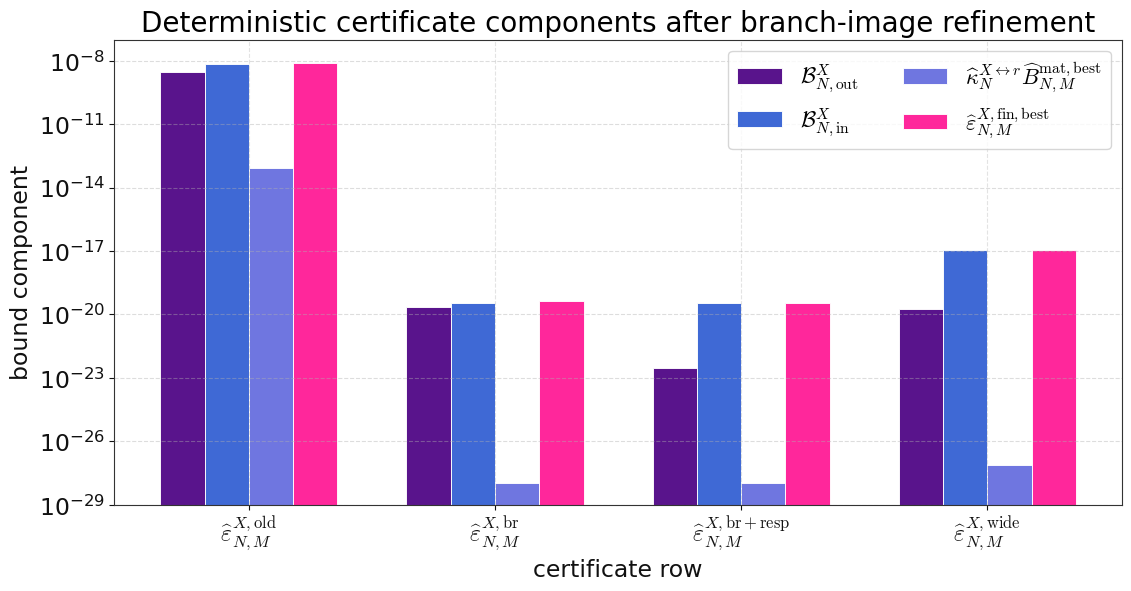

Saved figure: outputs/blaschke_deformation_certifier/figures/branch_image_phase3_rate_diagnostics.png


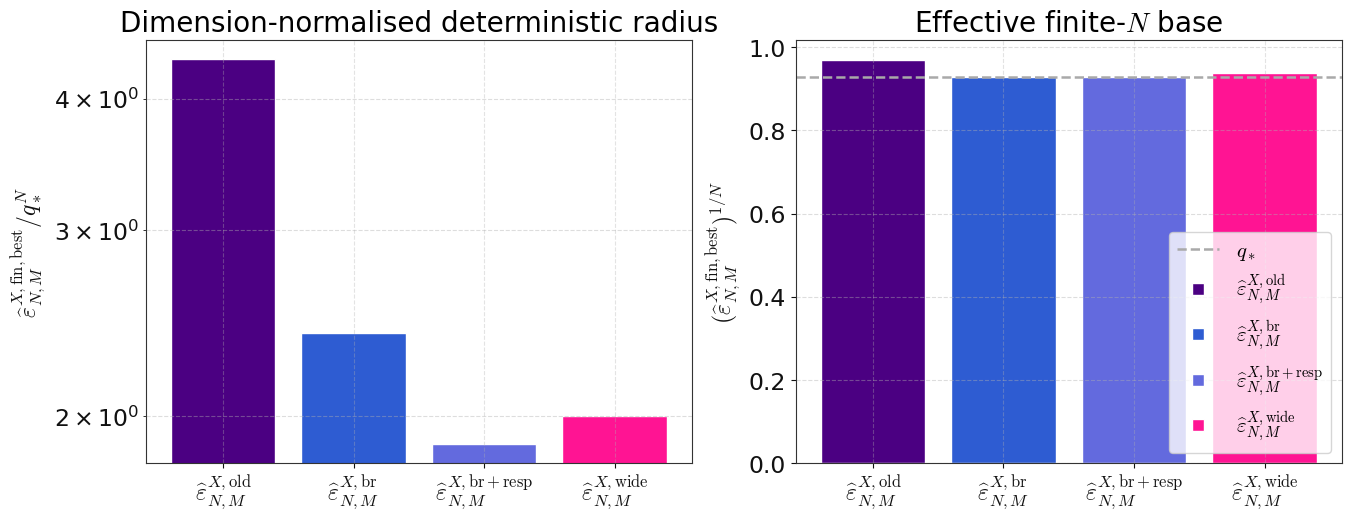

,source,short_source,N,M,rho,r,r_tau,q_star,B_out,B_in,collocation,epsilon,status,qstar_power,epsilon_over_qstar_power,effective_base,row_symbol
0,old whole-ellipse final Schur row,old,600,610,1.5999,1.512042,1.462145,0.967,2.823000e-09,7.337851e-09,8.560000e-14,7.862235e-09,old deployed thesis row,1.802538e-09,4.361758,0.969377,"$\widehat\varepsilon_{N,M}^{X,\mathrm{old}}$"
1,branch-image balanced candidate,branch-image,600,610,2.7250,2.473670,2.293092,0.927,2.358400e-20,3.522800e-20,1.087247e-28,4.239360e-20,balanced branch-image row with unconditional s...,1.769459e-20,2.395851,0.928351,"$\widehat\varepsilon_{N,M}^{X,\mathrm{br}}$"
2,branch-image plus response-prefactor row,response,600,610,2.7250,2.473670,2.293092,0.927,2.854034e-23,3.326442e-20,1.087247e-28,3.326443e-20,unconditional selected resolved-response singl...,1.769459e-20,1.879921,0.927976,"$\widehat\varepsilon_{N,M}^{X,\mathrm{br}+\mat..."
3,wide branch-image candidate,wide,600,610,2.4500,2.225975,2.083512,0.936,1.817289e-20,1.164116e-17,7.499811e-28,1.164117e-17,wide branch-image row with unconditional safe ...,5.827862e-18,1.997503,0.937080,"$\widehat\varepsilon_{N,M}^{X,\mathrm{wide}}$"


In [34]:
# Cell 32
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_32_status = transfer_lab_execute_selected_map_cell('# Cell 32', 'Phase 3 empirical-versus-deterministic rate comparison')
else:
    # ============================================================
    # Phase 3C — deterministic branch-image certificate comparison
    # ============================================================

    plt .rcParams .update ({
    "text.usetex":False ,
    "font.family":"DejaVu Sans",
    "mathtext.fontset":"cm",
    "axes.unicode_minus":False ,
    "axes.titlesize":20 ,
    "axes.labelsize":17 ,
    "xtick.labelsize":17 ,
    "ytick.labelsize":17 ,
    "legend.fontsize":16 ,
    })

    component_specs =[
    (r"$\mathcal{B}_{N,\mathrm{out}}^X$","B_out"),
    (r"$\mathcal{B}_{N,\mathrm{in}}^X$","B_in"),
    (r"$\widehat\kappa_N^{X\leftrightarrow r}\widehat B_{N,M}^{\mathrm{mat,best}}$","collocation"),
    (r"$\widehat\varepsilon_{N,M}^{X,\mathrm{fin,best}}$","epsilon"),
    ]
    component_labels =[name for name ,_ in component_specs ]
    component_colours =phase1_gradient_palette (component_labels )


    def phase3_certificate_row_symbol (source ):
        key =str (source ).strip ().lower ()
        mapping ={
        "old":r"$\widehat\varepsilon_{N,M}^{X,\mathrm{old}}$",
        "old whole-ellipse":r"$\widehat\varepsilon_{N,M}^{X,\mathrm{old}}$",
        "whole-ellipse":r"$\widehat\varepsilon_{N,M}^{X,\mathrm{old}}$",
        "branch-image":r"$\widehat\varepsilon_{N,M}^{X,\mathrm{br}}$",
        "branch":r"$\widehat\varepsilon_{N,M}^{X,\mathrm{br}}$",
        "response":r"$\widehat\varepsilon_{N,M}^{X,\mathrm{br}+\mathrm{resp}}$",
        "branch + response":r"$\widehat\varepsilon_{N,M}^{X,\mathrm{br}+\mathrm{resp}}$",
        "wide":r"$\widehat\varepsilon_{N,M}^{X,\mathrm{wide}}$",
        "wide branch-image":r"$\widehat\varepsilon_{N,M}^{X,\mathrm{wide}}$",
        }
        return mapping .get (key ,rf"$\widehat\varepsilon_{{N,M}}^{{X,\mathrm{{{key .replace (' ','')}}}}}$")

    plot_df =phase3_cert_compare_df .copy ()
    plot_df =plot_df [plot_df ["epsilon"].apply (lambda x :np .isfinite (x )and x >0 )].copy ()
    plot_df ["epsilon_over_qstar_power"]=plot_df ["epsilon"]/plot_df ["qstar_power"]
    plot_df ["effective_base"]=plot_df ["epsilon"].apply (lambda x :float (mp .mpf (str (x ))**(mp .mpf (1 )/N_CERT_X ))if x >0 else np .nan )
    plot_df ["row_symbol"]=plot_df ["short_source"].apply (phase3_certificate_row_symbol )
    plot_df .to_csv (DATA_DIR /"branch_image_phase3_certificate_comparison.csv",index =False )
    plot_df .to_csv (DATA_DIR /"branch_image_phase3_rate_diagnostics.csv",index =False )

    def phase3_log_limits (values ,pad =0.65 ):
        vals =np .asarray (values ,dtype =float )
        vals =vals [np .isfinite (vals )&(vals >0 )]
        if vals .size ==0 :
            return 1e-30 ,1.0 
        return 10 **(np .floor (np .log10 (vals .min ())-pad )),10 **(np .ceil (np .log10 (vals .max ())+pad ))

    fig ,ax =plt .subplots (figsize =(11.2 ,5.8 ),facecolor ="white",constrained_layout =True )
    x =np .arange (len (plot_df ),dtype =float )
    width =0.18 
    offsets =(np .arange (len (component_specs ))-(len (component_specs )-1 )/2 )*width 
    all_values =[]
    for offset ,(label ,column )in zip (offsets ,component_specs ):
        vals =plot_df [column ].astype (float ).to_numpy ()
        all_values .extend (vals .tolist ())
        ax .bar (x +offset ,vals ,width =width ,color =component_colours [label ],edgecolor ="white",linewidth =0.7 ,alpha =0.92 ,label =label )
    ax .set_yscale ("log")
    ax .set_ylim (*phase3_log_limits (all_values ))
    ax .set_xticks (x )
    ax .set_xticklabels (plot_df ["row_symbol"],rotation =0 )
    ax .set_xlabel ("certificate row")
    ax .set_ylabel ("bound component")
    ax .set_title ("Deterministic certificate components after branch-image refinement")
    ax .grid (True ,which ="both",axis ="y",linestyle ="--",alpha =0.42 )
    ax .legend (ncols =2 ,frameon =True ,loc ="upper right",fontsize =16 )
    fig_path =FIG_DIR /"branch_image_phase3_certificate_components.png"
    fig .savefig (fig_path ,dpi =230 ,bbox_inches ="tight")
    print ("Saved figure:",fig_path )
    plt .show ()

    row_labels =plot_df ["short_source"].astype (str ).tolist ()
    row_colours =phase1_gradient_palette (row_labels )
    row_bar_colours =[row_colours [label ]for label in row_labels ]
    fig ,axes =plt .subplots (1 ,2 ,figsize =(13.4 ,5.1 ),facecolor ="white",constrained_layout =True )
    row_symbols =plot_df ["row_symbol"].tolist ()
    row_x =np .arange (len (plot_df ))
    axes [0 ].bar (row_x ,plot_df ["epsilon_over_qstar_power"],color =row_bar_colours ,edgecolor ="white")
    axes [0 ].set_yscale ("log")
    axes [0 ].set_ylabel (r"$\widehat\varepsilon_{N,M}^{X,\mathrm{fin,best}}/q_*^N$")
    axes [0 ].set_title (r"Dimension-normalised deterministic radius")
    axes [0 ].set_xticks (row_x )
    axes [0 ].set_xticklabels (row_symbols ,rotation =0 )
    axes [0 ].grid (True ,which ="both",axis ="y",linestyle ="--",alpha =0.42 )
    axes [1 ].bar (row_x ,plot_df ["effective_base"],color =row_bar_colours ,edgecolor ="white")
    axes [1 ].axhline (float (QSTAR_X ),color =PALETTE ["ref"],linestyle ="--",linewidth =1.8 ,label =r"$q_*$")
    axes [1 ].set_ylabel (r"$(\widehat\varepsilon_{N,M}^{X,\mathrm{fin,best}})^{1/N}$")
    axes [1 ].set_title (r"Effective finite-$N$ base")
    axes [1 ].set_xticks (row_x )
    axes [1 ].set_xticklabels (row_symbols ,rotation =0 )
    axes [1 ].grid (True ,which ="major",axis ="y",linestyle ="--",alpha =0.42 )
    row_colour_handles =[plt .Line2D ([0 ],[0 ],marker ="s",linestyle ="",markersize =9 ,markerfacecolor =row_colours [label ],markeredgecolor ="white",label =phase3_certificate_row_symbol (label ))for label in row_labels ]
    axes [1 ].legend (handles =[axes [1 ].lines [0 ],*row_colour_handles ],frameon =True ,fontsize =15 ,loc ="lower right")
    fig_path =FIG_DIR /"branch_image_phase3_rate_diagnostics.png"
    fig .savefig (fig_path ,dpi =230 ,bbox_inches ="tight")
    print ("Saved figure:",fig_path )
    plt .show ()

    display (plot_df )

## Mathematics for Cell 33

This cell creates the bridge plot between empirical spectra and deterministic certification. The left panel displays raw packet errors for selected Blaschke targets, while the right panel compares the certified perturbation radius with the geometric core.

For each selected target packet $\lambda_j$, the raw curve is

$$
N\longmapsto \Delta_j(N,N),
\qquad
\Delta_j(N,N)
=
\operatorname{dist}_{\mathrm{match}}
\bigl(\operatorname{spec}(\widehat L_N^{(N)}),\lambda_j\bigr).
$$

These raw curves are empirical finite-matrix diagnostics. The theorem-facing deterministic quantity is instead

$$
\|\mathcal L-\mathcal L_{N,M}^{X}\|_{X\to X}
\le
\varepsilon_X,
$$

with the branch-image row value

$$
\varepsilon_X
=
2\mathcal{B}_{N,\mathrm{out}}^X
+
\mathcal{B}_{N,\mathrm{in}}^X
+
\widehat\kappa_N^{X\leftrightarrow r}B_{N,M}^{\mathrm{mat}}.
$$

The dashed comparison level in the deterministic panel is

$$
q_\ast^N,
\qquad
q_\ast=
\max\left\{\frac r\rho,\frac{r_\tau}{r}\right\}.
$$

The report records the normalised prefactor

$$
C_{q_\ast}(N,M)=\frac{\varepsilon_X}{q_\ast^N}
$$

and, for each empirical packet fit, the fitted raw base $q_{\mathrm{fit},j}$ together with the ratio $q_{\mathrm{fit},j}/q_\ast$. Thus the cell connects three layers: raw spectral diagnostics, the deterministic operator-norm radius, and the branch-image geometric scale passed to the contour stage.


Saved figure: outputs/blaschke_deformation_certifier/figures/branch_image_phase3_empirical_vs_deterministic_bridge.png


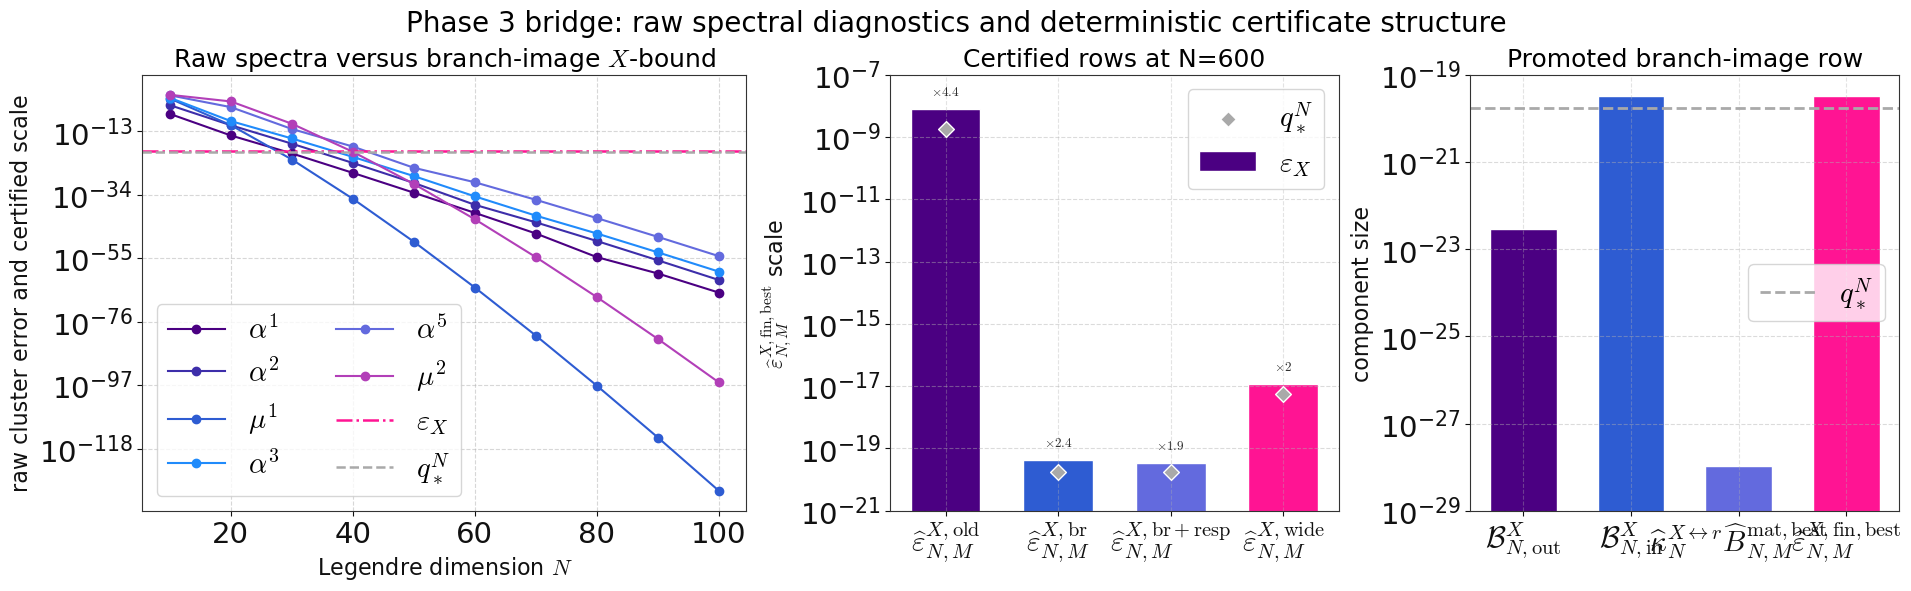

Saved Phase 3 report: outputs/blaschke_deformation_certifier/reports/branch_image_phase3_report.md
# Phase 3 branch-image summary

## Branch-image deterministic row

- N = 600, M = 610
- rho = 2.725
- r = 2.473669807791324
- r_tau = 2.293091911822557
- q_star = 0.927
- epsilon_X = 3.326443383901743e-20
- epsilon_X divided by q_star^N = 1.87992121720786532100821557548

## Empirical raw spectral behaviour

The raw curves use only the square Legendre--Gauss transfer blocks Lhat_N^(N).  They are diagnostic spectral errors, not theorem-level operator-norm bounds.

- mu^1: fitted base 0.03425, fitted base divided by q_star 0.0369471, N range 10 to 100
- mu^2: fitted base 0.0799406, fitted base divided by q_star 0.0862358, N range 10 to 100
- alpha^1: fitted base 0.218252, fitted base divided by q_star 0.235439, N range 10 to 100
- alpha^2: fitted base 0.227461, fitted base divided by q_star 0.245373, N range 10 to 100
- alpha^3: fitted base 0.232859, fitted base divided by q_star 0.251196, N

In [35]:
# Cell 33
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_33_status = transfer_lab_execute_selected_map_cell('# Cell 33', 'Phase 3 empirical-versus-deterministic rate comparison')
else:
    # ============================================================
    # Phase 3D — bridge plot and markdown report
    # ============================================================

    plt .rcParams .update ({
    "text.usetex":False ,
    "font.family":"DejaVu Sans",
    "mathtext.fontset":"cm",
    "axes.unicode_minus":False ,
    "axes.titlesize":18 ,
    "axes.labelsize":16 ,
    "xtick.labelsize":21 ,
    "ytick.labelsize":21 ,
    "legend.fontsize":20.5 ,
    })

    current_row =plot_df [plot_df ["short_source"]=="response"]
    if len (current_row )==0 :
        current_row =plot_df .tail (1 )
    current =current_row .iloc [0 ]

    row_labels =plot_df ["short_source"].astype (str ).tolist ()
    if "row_symbol"not in plot_df .columns :
        plot_df ["row_symbol"]=plot_df ["short_source"].apply (phase3_certificate_row_symbol )
    row_symbols =plot_df ["row_symbol"].tolist ()
    row_colour_map =phase1_gradient_palette (row_labels )
    row_colours =[row_colour_map [label ]for label in row_labels ]
    row_x =np .arange (len (plot_df ))

    fig =plt .figure (figsize =(19.0 ,5.8 ),facecolor ="white",constrained_layout =True )
    gs =fig .add_gridspec (1 ,3 ,width_ratios =[1.55 ,1.15 ,1.10 ])
    ax_raw =fig .add_subplot (gs [0 ,0 ])
    ax_rows =fig .add_subplot (gs [0 ,1 ])
    ax_comp =fig .add_subplot (gs [0 ,2 ])

    labels =PHASE3_TARGETS +["epsilon"]
    curve_colours =phase1_gradient_palette (labels )
    for target in PHASE3_TARGETS :
        g =phase3_raw_curve_df [phase3_raw_curve_df ["name"]==target ].sort_values ("N")
        if len (g )==0 :
            continue 
        ax_raw .semilogy (
        g ["N"],
        g ["error"],
        marker ="o",
        linewidth =1.5 ,
        color =curve_colours [target ],
        label =phase3_latex_target_label (target ),
        )
    ax_raw .axhline (float (current ["epsilon"]),color =PALETTE ["imag"],linestyle ="-.",linewidth =1.8 ,label =r"$\varepsilon_X$")
    ax_raw .axhline (float (current ["qstar_power"]),color =PALETTE ["ref"],linestyle ="--",linewidth =1.8 ,label =r"$q_*^N$")
    ax_raw .set_xlabel (r"Legendre dimension $N$")
    ax_raw .set_ylabel ("raw cluster error and certified scale")
    ax_raw .set_title (r"Raw spectra versus branch-image $X$-bound")
    ax_raw .grid (True ,which ="both",linestyle ="--",alpha =0.5 )
    ax_raw .legend (ncol =2 ,frameon =True ,fontsize =20.5 )

    row_totals =plot_df ["epsilon"].astype (float ).to_numpy ()
    row_qstar =plot_df ["qstar_power"].astype (float ).to_numpy ()
    ax_rows .bar (row_x ,row_totals ,width =0.62 ,color =row_colours ,edgecolor ="white",label =r"$\varepsilon_X$")
    ax_rows .scatter (row_x ,row_qstar ,marker ="D",s =64 ,color =PALETTE ["ref"],edgecolor ="white",zorder =4 ,label =r"$q_*^N$")
    for x ,eps ,base in zip (row_x ,row_totals ,row_qstar ):
        if eps >0 and base >0 :
            ax_rows .annotate (
            rf"$\times {eps /base :.2g}$",
            xy =(x ,eps ),
            xytext =(0 ,8 ),
            textcoords ="offset points",
            ha ="center",
            va ="bottom",
            fontsize =9.5 ,
            color ="#303030",
            )
    ax_rows .set_yscale ("log")
    ax_rows .set_xticks (row_x )
    ax_rows .set_xticklabels (row_symbols ,rotation =0 )
    ax_rows .set_ylabel (r"$\widehat\varepsilon_{N,M}^{X,\mathrm{fin,best}}$ scale")
    ax_rows .set_title ("Certified rows at N=600")
    row_plot_values =list (row_totals )+list (row_qstar )
    ax_rows .set_ylim (*phase3_positive_log_limits (row_plot_values ,pad_decades =0.45 ))
    ax_rows .grid (True ,which ="both",axis ="y",linestyle ="--",alpha =0.45 )
    ax_rows .legend (frameon =True ,fontsize =20.5 )

    component_labels =[
    r"$\mathcal{B}_{N,\mathrm{out}}^X$",
    r"$\mathcal{B}_{N,\mathrm{in}}^X$",
    r"$\widehat\kappa_N^{X\leftrightarrow r}\widehat B_{N,M}^{\mathrm{mat,best}}$",
    r"$\widehat\varepsilon_{N,M}^{X,\mathrm{fin,best}}$",
    ]
    component_values =[
    float (current ["B_out"]),
    float (current ["B_in"]),
    float (current ["collocation"]),
    float (current ["epsilon"]),
    ]
    component_colours =phase1_gradient_palette (component_labels )
    component_x =np .arange (len (component_labels ))
    ax_comp .bar (
    component_x ,
    component_values ,
    width =0.62 ,
    color =[component_colours [label ]for label in component_labels ],
    edgecolor ="white",
    )
    ax_comp .axhline (float (current ["qstar_power"]),color =PALETTE ["ref"],linestyle ="--",linewidth =2.0 ,label =r"$q_*^N$")
    ax_comp .set_yscale ("log")
    ax_comp .set_xticks (component_x )
    ax_comp .set_xticklabels (component_labels ,rotation =0 )
    ax_comp .set_ylabel ("component size")
    ax_comp .set_title ("Promoted branch-image row")
    component_plot_values =component_values +[float (current ["qstar_power"])]
    ax_comp .set_ylim (*phase3_positive_log_limits (component_plot_values ,pad_decades =0.45 ))
    ax_comp .grid (True ,which ="both",axis ="y",linestyle ="--",alpha =0.45 )
    ax_comp .legend (frameon =True ,fontsize =20.5 )

    for _phase3_bridge_ax in (ax_raw, ax_rows, ax_comp):
        _phase3_bridge_ax.tick_params(axis="both", which="major", labelsize=21)
        _phase3_bridge_ax.tick_params(axis="both", which="minor", labelsize=18)

    fig .suptitle ("Phase 3 bridge: raw spectral diagnostics and deterministic certificate structure",fontsize =20 )
    fig_path =FIG_DIR /"branch_image_phase3_empirical_vs_deterministic_bridge.png"
    fig .savefig (fig_path ,dpi =230 ,bbox_inches ="tight")
    print ("Saved figure:",fig_path )
    plt .show ()

    lines =[]
    lines .append ("# Phase 3 branch-image summary")
    lines .append ("")
    lines .append ("## Branch-image deterministic row")
    lines .append ("")
    lines .append (f"- N = {N_CERT_X }, M = {M_CERT_X }")
    lines .append (f"- rho = {mp .nstr (PHASE3_CERT ['rho'],20 )}")
    lines .append (f"- r = {mp .nstr (PHASE3_CERT ['r'],20 )}")
    lines .append (f"- r_tau = {mp .nstr (PHASE3_CERT ['r_tau'],20 )}")
    lines .append (f"- q_star = {mp .nstr (QSTAR_X ,20 )}")
    lines .append (f"- epsilon_X = {mp .nstr (EPS_CERT_X ,30 )}")
    lines .append (f"- epsilon_X divided by q_star^N = {mp .nstr (C_CERT_QSTAR ,30 )}")
    lines .append ("")
    lines .append ("## Empirical raw spectral behaviour")
    lines .append ("")
    lines .append ("The raw curves use only the square Legendre--Gauss transfer blocks Lhat_N^(N).  They are diagnostic spectral errors, not theorem-level operator-norm bounds.")
    lines .append ("")
    for row in phase3_fit_df .itertuples (index =False ):
        lines .append (f"- {row .name }: fitted base {row .fitted_base :.6g}, fitted base divided by q_star {row .fitted_base_over_qstar :.6g}, N range {row .N_min } to {row .N_max }")
    lines .append ("")
    lines .append ("## Deterministic interpretation")
    lines .append ("")
    lines .append ("The response-prefactor branch-image row is far smaller than the old whole-ellipse row.  At N=600, M=610 the deterministic radius is controlled by the analytic single-space tails, while the transported Schur matrix defect is negligible.")
    lines .append ("")
    lines .append ("The branch-image q_star is the comparison base used by the later contour stage.  Phase 4 should use the exported compatibility row from Phase 2, namely phase2_certified_single_space_row_N600_M610.csv.")
    phase3_report ="\n".join (lines )
    report_path =REPORT_DIR /"branch_image_phase3_report.md"
    report_path .write_text (phase3_report ,encoding ="utf-8")
    print ("Saved Phase 3 report:",report_path )
    print (phase3_report )

## Mathematics for Cell 34

This cell reproduces the old Phase 3 table-plus-rate diagnostic for the promoted branch-image certificate.  The table reports fitted empirical bases $q_{\mathrm{fit}}$ for selected raw square-block clusters and the ratios $q_{\mathrm{fit}}/q_\ast$, now using the branch-image value of $q_\ast$.

For the deterministic panel, the certified row at $N_0=600$ is propagated along the same geometric cores used in the branch-image single-space certificate.  With $M_N=N+10$, the diagnostic curves are

$$
2\mathcal{B}_{N,\mathrm{out}}^X
\approx
2\mathcal{B}_{N_0,\mathrm{out}}^X
\frac{q_{\mathrm{out}}^N}{q_{\mathrm{out}}^{N_0}},
\qquad
\mathcal{B}_{N,\mathrm{in}}^X
\approx
\mathcal{B}_{N_0,\mathrm{in}}^X
\frac{q_{\mathrm{gap}}^N}{q_{\mathrm{gap}}^{N_0}}.
$$

The Schur matrix term is scaled by the pure $r$-scaled core,

$$
\widehat{\kappa}_N^{X\leftrightarrow r}B_{N,M_N}^{\mathrm{mat}}
\approx
\widehat{\kappa}_{N_0}^{X\leftrightarrow r}B_{N_0,M_0}^{\mathrm{mat}}
\frac{q_{\mathrm{out}}^N\sqrt{2N-1}}{q_{\mathrm{out}}^{N_0}\sqrt{2N_0-1}}.
$$

The grey guide is $C_{\mathrm{cert}}q_\ast^N$, where $C_{\mathrm{cert}}=\widehat{\varepsilon}_{N_0,M_0}^{X,\mathrm{fin,best}}/q_\ast^{N_0}$.  This is a visual rate diagnostic, not a replacement for the certified finite row.


Saved figure: outputs/blaschke_deformation_certifier/figures/branch_image_phase3_schur_components_vs_qstar.png
Saved compatibility figure: outputs/blaschke_deformation_certifier/figures/branch_image_phase3_table_and_schur_components_vs_qstar.png
Saved data: outputs/blaschke_deformation_certifier/data/branch_image_phase3_components_vs_geometric_rate.csv


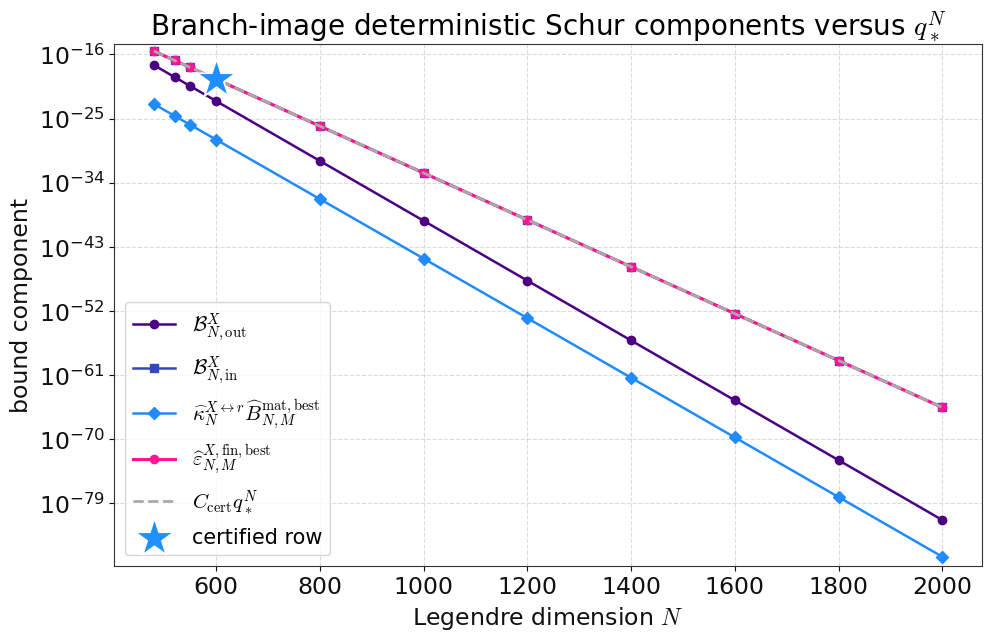

,cluster_label,fitted_base,fitted_base_over_qstar,points,N_min,N_max
0,$\mu^{1}$,0.034250,0.036947,10,10,100
1,$\mu^{2}$,0.079941,0.086236,10,10,100
2,$\alpha^{1}$,0.218252,0.235439,10,10,100
3,$\alpha^{2}$,0.227461,0.245373,10,10,100
4,$\alpha^{3}$,0.232859,0.251196,10,10,100
5,$\alpha^{5}$,0.277177,0.299004,3,10,30


,N,M,m,B_out,B_in,collocation,epsilon,qstar_power,Ccert_qstar_power,epsilon_over_Ccert_qstar,q_out,q_gap,q_star
0,480,490,10,3.150885e-18,2.967645e-16,1.073498e-23,2.967812e-16,1.578601e-16,2.967646e-16,1.000056,0.907769,0.927,0.927
1,520,530,10,6.568125e-20,1.430874e-17,2.329210e-25,1.430889e-17,7.611351e-18,1.430874e-17,1.000010,0.907769,0.927,0.927
2,550,560,10,3.603280e-21,1.472290e-18,1.314185e-26,1.472294e-18,7.831659e-19,1.472290e-18,1.000003,0.907769,0.927,0.927
3,600,610,10,2.854034e-23,3.326442e-20,1.087247e-28,3.326443e-20,1.769459e-20,3.326443e-20,1.000000,0.907769,0.927,0.927
4,800,810,10,1.123320e-31,8.668158e-27,4.941824e-37,8.668158e-27,4.610917e-27,8.668161e-27,1.000000,0.907769,0.927,0.927
5,1000,1010,10,4.421278e-40,2.258778e-33,2.174772e-45,2.258778e-33,1.201529e-33,2.258779e-33,1.000000,0.907769,0.927,0.927
6,1200,1210,10,1.740172e-48,5.886003e-40,9.377063e-54,5.886003e-40,3.130985e-40,5.886005e-40,1.000000,0.907769,0.927,0.927
7,1400,1410,10,6.849147e-57,1.533795e-46,3.986553e-62,1.533795e-46,8.158828e-47,1.533795e-46,1.000000,0.907769,0.927,0.927
8,1600,1610,10,2.695758e-65,3.996816e-53,1.677442e-70,3.996816e-53,2.126056e-53,3.996817e-53,1.000000,0.907769,0.927,0.927
9,1800,1810,10,1.061024e-73,1.041504e-59,7.002864e-79,1.041504e-59,5.540149e-60,1.041504e-59,1.000000,0.907769,0.927,0.927


In [36]:
# Cell 34
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_34_status = transfer_lab_execute_selected_map_cell('# Cell 34', 'Phase 3 empirical-versus-deterministic rate comparison')
else:
    # ============================================================
    # Phase 3E — branch-image fitted bases and geometric-rate panel
    # ============================================================

    plt .rcParams .update ({
    "text.usetex":False ,
    "font.family":"DejaVu Sans",
    "mathtext.fontset":"cm",
    "axes.unicode_minus":False ,
    "axes.titlesize":20 ,
    "axes.labelsize":17 ,
    "xtick.labelsize":17 ,
    "ytick.labelsize":17 ,
    "legend.fontsize":16 ,
    })


    def phase3_cluster_order_key (name ):
        name =str (name )
        if name .startswith ("mu^"):
            return (0 ,int (name .split ("^")[1 ]))
        if name .startswith ("alpha^"):
            return (1 ,int (name .split ("^")[1 ]))
        return (2 ,name )


    def phase3_cluster_table_label (name ):
        return phase3_latex_target_label (name )

    phase3_table_df =phase3_fit_df .copy ()
    phase3_table_df =phase3_table_df .sort_values ("name",key =lambda s :s .map (phase3_cluster_order_key )).reset_index (drop =True )
    phase3_table_df ["cluster_label"]=phase3_table_df ["name"].map (phase3_cluster_table_label )
    phase3_table_df =phase3_table_df [["cluster_label","fitted_base","fitted_base_over_qstar","points","N_min","N_max"]]
    phase3_table_df .to_csv (DATA_DIR /"branch_image_phase3_fitted_base_table_for_rate_panel.csv",index =False )

    N0 =int (N_CERT_X )
    M0 =int (M_CERT_X )
    q_out_ref =float (PHASE3_CERT ["q_out"])
    q_gap_ref =float (PHASE3_CERT ["q_gap"])
    q_star_ref =float (QSTAR_X )
    B_out_0 =float (BOUT_CERT_X )
    B_in_0 =float (BIN_CERT_X )
    B_col_0 =float (COLL_CERT_X )
    eps_0 =float (EPS_CERT_X )
    C_cert_ref =eps_0 /float (mp .mpf (str (q_star_ref ))**N0 )

    N_rate =np .array ([480 ,520 ,550 ,600 ,800 ,1000 ,1200 ,1400 ,1600 ,1800 ,2000 ],dtype =int )
    M_rate =N_rate +(M0 -N0 )
    B_out_rate =B_out_0 *np .array ([q_out_ref **(int (N )-N0 )for N in N_rate ],dtype =float )
    B_in_rate =B_in_0 *np .array ([q_gap_ref **(int (N )-N0 )for N in N_rate ],dtype =float )
    B_col_rate =B_col_0 *np .array ([
    (q_out_ref **(int (N )-N0 ))*np .sqrt ((2 *int (N )-1 )/(2 *N0 -1 ))
    for N in N_rate 
    ],dtype =float )
    eps_rate =np .hypot (B_out_rate ,B_in_rate )+B_col_rate 
    qstar_rate =np .array ([q_star_ref **int (N )for N in N_rate ],dtype =float )
    Ccert_qstar_rate =C_cert_ref *qstar_rate 

    phase3_branch_image_rate_panel_df =pd .DataFrame ({
    "N":N_rate ,
    "M":M_rate ,
    "m":M_rate -N_rate ,
    "B_out":B_out_rate ,
    "B_in":B_in_rate ,
    "collocation":B_col_rate ,
    "epsilon":eps_rate ,
    "qstar_power":qstar_rate ,
    "Ccert_qstar_power":Ccert_qstar_rate ,
    "epsilon_over_Ccert_qstar":eps_rate /Ccert_qstar_rate ,
    "q_out":q_out_ref ,
    "q_gap":q_gap_ref ,
    "q_star":q_star_ref ,
    })
    phase3_branch_image_rate_panel_df .to_csv (DATA_DIR /"branch_image_phase3_components_vs_geometric_rate.csv",index =False )

    fig, ax = plt.subplots(figsize=(9.8, 6.3), facecolor="white", constrained_layout=True)

    labels = [
        r"$\mathcal{B}_{N,\mathrm{out}}^X$",
        r"$\mathcal{B}_{N,\mathrm{in}}^X$",
        r"$\widehat{\kappa}_N^{X\leftrightarrow r}\widehat B_{N,M}^{\mathrm{mat,best}}$",
        r"$\widehat{\varepsilon}_{N,M}^{X,\mathrm{fin,best}}$",
        r"$C_{\mathrm{cert}}q_\ast^N$",
    ]
    colours = phase1_gradient_palette(labels)
    ax.semilogy(N_rate, B_out_rate, marker="o", linewidth=1.8, color=colours[labels[0]], label=labels[0])
    ax.semilogy(N_rate, B_in_rate, marker="s", linewidth=1.8, color=colours[labels[1]], label=labels[1])
    ax.semilogy(N_rate, B_col_rate, marker="D", linewidth=1.8, color=colours[labels[2]], label=labels[2])
    ax.semilogy(N_rate, eps_rate, marker="o", linewidth=2.2, color=PALETTE["imag"], label=labels[3])
    ax.semilogy(N_rate, Ccert_qstar_rate, linestyle="--", linewidth=2.0, color=PALETTE["ref"], label=labels[4])
    ax.scatter([N0], [eps_0], marker="*", s=850, color=PALETTE["real"], edgecolor="white", linewidth=1.2, zorder=5, label=r"certified row")
    ax.set_xlabel(r"Legendre dimension $N$")
    ax.set_ylabel(r"bound component")
    ax.set_title(r"Branch-image deterministic Schur components versus $q_\ast^N$")
    ax.grid(True, which="both", linestyle="--", alpha=0.45)
    positive_vals = np.concatenate([B_out_rate, B_in_rate, B_col_rate, eps_rate, Ccert_qstar_rate])
    positive_vals = positive_vals[np.isfinite(positive_vals) & (positive_vals > 0)]
    ax.set_ylim(10 ** (np.floor(np.log10(positive_vals.min())) - 0.8), 10 ** (np.ceil(np.log10(positive_vals.max())) + 0.5))
    ax.legend(frameon=True, fontsize=15, loc="lower left", ncol=1)

    fig_path = FIG_DIR / "branch_image_phase3_schur_components_vs_qstar.png"
    compat_fig_path = FIG_DIR / "branch_image_phase3_table_and_schur_components_vs_qstar.png"
    fig.savefig(fig_path, dpi=260, bbox_inches="tight")
    fig.savefig(compat_fig_path, dpi=260, bbox_inches="tight")
    print("Saved figure:", fig_path)
    print("Saved compatibility figure:", compat_fig_path)
    print("Saved data:", DATA_DIR / "branch_image_phase3_components_vs_geometric_rate.csv")
    plt.show()

    display(phase3_table_df)
    display(phase3_branch_image_rate_panel_df)

**Rendered output for Cell 34**

The figure below is the saved branch-image Phase 3 Schur-components diagnostic. The fitted-base table is mounted separately in the thesis text.

![Branch-image Phase 3 Schur components](outputs/figures/branch_image_phase3_schur_components_vs_qstar.png)


## Phase 4

<div style="color: #008B8B;">

## Mathematics for Cell 35

Phase 4 accepts the wide deterministic row only after output schema version 2, the single-output convention, and the unconditional finite-$M$ prefactor have all been certified. It then loads the Hardy-gauge finite matrix and the first-fifteen sampled contour tables. The matrix is

$$
A_N^X=\mathsf T_N(r)D_{r,N}\widehat L_N^{(M)}D_{r,N}^{-1}\mathsf T_N(r)^{-1}.
$$

The theorem-level radius $\varepsilon_X\ge\|\mathcal L-\mathcal L_{N,M}^{X}\|_{X\to X}$ is certified, whereas the finite contour moat is sampled. For a contour $\Gamma$, the diagnostic checks $\varepsilon_Xm_\Gamma^X<1$, where $m_\Gamma^X$ is formed from the sampled singular-value minimum and the zero-complement distance. Consequently, the exported packet status is `sampled_validation_pass`; it is not a contour certificate.

</div>


In [37]:
# Cell 35
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_35_status = transfer_lab_execute_selected_map_cell('# Cell 35', 'Phase 4 Hardy-gauge contour validation')
else:
    # ============================================================
    # Phase 4A — certified wide row and sampled contour inputs
    # ============================================================

    from pathlib import Path
    import json, shutil
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap, to_hex

    DATA_DIR = globals().get("DATA_DIR", Path("outputs/data") if Path.cwd().name == "Numerics" else Path("Numerics/outputs/data"))
    FIG_DIR = globals().get("FIG_DIR", Path("outputs/figures") if Path.cwd().name == "Numerics" else Path("Numerics/outputs/figures"))
    REPORT_DIR = globals().get("REPORT_DIR", Path("outputs/reports") if Path.cwd().name == "Numerics" else Path("Numerics/outputs/reports"))
    for _d in (DATA_DIR, FIG_DIR, REPORT_DIR):
        _d.mkdir(parents=True, exist_ok=True)

    PALETTE = globals().get("PALETTE", {"real": "dodgerblue", "imag": "deeppink", "main": "indigo", "ref": "darkgrey", "bg": "#f0f2f5"})
    PHASE4_N, PHASE4_M, PHASE4_J = 600, 610, 128
    PHASE4_ROW_PATH = DATA_DIR / "branch_image_wide_candidate_single_space_row_N600_M610.csv"
    PHASE4_MOATS15_PATH = DATA_DIR / "branch_image_wide_candidate_first15_contour_moats_N600_M610_J128.csv"
    PHASE4_PACKETS15_PATH = DATA_DIR / "branch_image_wide_candidate_first15_sampled_spectral_packets_N600_M610.csv"
    PHASE4_ROBUST15_PATH = DATA_DIR / "branch_image_wide_candidate_first15_fragile_robustness_N600_M610.csv"
    PHASE4_AX_PATH = DATA_DIR / "branch_image_wide_candidate_A_X_from_mp_scaled_N600_M610_r2p225974769705636.npz"

    for path in (PHASE4_ROW_PATH, PHASE4_MOATS15_PATH, PHASE4_PACKETS15_PATH, PHASE4_ROBUST15_PATH, PHASE4_AX_PATH):
        if not path.exists():
            raise FileNotFoundError(path)

    phase4_row = pd.read_csv(PHASE4_ROW_PATH).iloc[0]
    phase4_moats15 = pd.read_csv(PHASE4_MOATS15_PATH)
    phase4_packets15 = pd.read_csv(PHASE4_PACKETS15_PATH)
    phase4_fragile_robustness = pd.read_csv(PHASE4_ROBUST15_PATH)
    with np.load(PHASE4_AX_PATH, allow_pickle=False) as payload:
        key = "A_X" if "A_X" in payload.files else payload.files[0]
        A_X_phase4 = np.asarray(payload[key], dtype=np.complex128)

    def phase4_true(value):
        return str(value).strip().lower() in {"true", "1", "yes", "y"}

    if int(phase4_row.get("output_schema_version", 0)) != 2:
        raise RuntimeError("Phase 4 requires output schema version 2.")
    if int(phase4_row.get("output_leakage_count", 0)) != 1:
        raise RuntimeError("Phase 4 requires exactly one stored output leakage.")
    if not phase4_true(phase4_row.get("finite_M_prefactor_certified", False)):
        raise RuntimeError("Phase 4 refuses the diagnostic D_M=1 wide-row collocation value.")
    if not phase4_true(phase4_row.get("total_certified", False)):
        raise RuntimeError("The wide Phase 4 deterministic radius is not marked certified.")

    def phase4_sampled_schema(frame, include_packet_flag=False):
        frame = frame.copy()
        if "pass_certified_packet" in frame.columns and "pass_sampled_packet" not in frame.columns:
            frame = frame.rename(columns={"pass_certified_packet": "pass_sampled_packet"})
        frame = frame.drop(columns=["certified"], errors="ignore")
        if {"finite_eigenvalue_count", "expected_multiplicity"}.issubset(frame.columns):
            frame["count_ok"] = frame["finite_eigenvalue_count"].astype(int) == frame["expected_multiplicity"].astype(int)
        if include_packet_flag and "pass_sampled_packet" in frame.columns:
            frame["sampled_validation_pass"] = (
                frame.get("count_ok", True)
                & frame["pass_sampled_small_gain"].astype(bool)
                & frame["pass_sampled_packet"].astype(bool)
            )
        elif "pass_sampled_small_gain" in frame.columns:
            frame["sampled_validation_pass"] = frame["pass_sampled_small_gain"].astype(bool)
        frame["contour_interval_certified"] = False
        frame["validation_status"] = "sampled_not_interval_certified"
        return frame

    PHASE4_RHO = float(phase4_row["rho"])
    PHASE4_R = float(phase4_row["r"])
    PHASE4_R_TAU = float(phase4_row["r_tau_interval_u"])
    PHASE4_Q_OUT = float(phase4_row["q_out"])
    PHASE4_Q_GAP = float(phase4_row["q_gap"])
    PHASE4_Q_STAR = float(phase4_row["q_star"])
    PHASE4_EPS_X = float(phase4_row["epsilon_with_unstar_matrix_candidate"])

    for _df in (phase4_moats15, phase4_fragile_robustness):
        if "m_gamma_X" in _df.columns:
            _df["epsilon_X"] = PHASE4_EPS_X
            _df["epsilon_m_gamma"] = _df["m_gamma_X"].astype(float) * PHASE4_EPS_X
            _df["pass_sampled_small_gain"] = _df["epsilon_m_gamma"] < 1.0
    phase4_moats15 = phase4_sampled_schema(phase4_moats15, include_packet_flag=True)
    _phase4_product_by_target = phase4_moats15.set_index("target")["epsilon_m_gamma"]
    phase4_packets15["epsilon_m_gamma"] = phase4_packets15["target"].map(_phase4_product_by_target)
    if phase4_packets15["epsilon_m_gamma"].isna().any():
        raise RuntimeError("A sampled packet is missing from the authoritative Phase 4 moat table.")
    phase4_packets15["pass_sampled_small_gain"] = phase4_packets15["epsilon_m_gamma"] < 1.0
    phase4_packets15 = phase4_sampled_schema(phase4_packets15, include_packet_flag=True)
    phase4_fragile_robustness = phase4_sampled_schema(phase4_fragile_robustness)

    pd.DataFrame([phase4_row.to_dict()]).to_csv(PHASE4_ROW_PATH, index=False)
    phase4_moats15.to_csv(PHASE4_MOATS15_PATH, index=False)
    phase4_packets15.to_csv(PHASE4_PACKETS15_PATH, index=False)
    phase4_fragile_robustness.to_csv(PHASE4_ROBUST15_PATH, index=False)

    phase4_total_algebraic_count = int(phase4_moats15["expected_multiplicity"].sum())
    phase4_all_pass = bool(phase4_moats15["sampled_validation_pass"].all())
    phase4_row_display = pd.DataFrame({
        "quantity": ["N", "M", "rho", "r", "r_tau", "q_out", "q_gap", "q_star", "epsilon_X", "finite_M_certified", "packets", "algebraic_count", "all_sampled_pass", "A_X_shape"],
        "value": [PHASE4_N, PHASE4_M, PHASE4_RHO, PHASE4_R, PHASE4_R_TAU, PHASE4_Q_OUT, PHASE4_Q_GAP, PHASE4_Q_STAR, PHASE4_EPS_X, True, len(phase4_moats15), phase4_total_algebraic_count, phase4_all_pass, str(A_X_phase4.shape)],
    })
    phase4_row_display


<div style="color: #008B8B;">

## Mathematics for Cell 37

For each displayed packet, this cell combines the sampled finite count, the sampled small-gain condition $\varepsilon_Xm_{\Gamma_j}^X<1$, and the stored sampled packet-matching check. Their conjunction is recorded as `sampled_validation_pass`. Since no interval lower enclosure of the complete singular-value curve is supplied, `contour_interval_certified` is explicitly false.

</div>


In [38]:
# Cell 37
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_37_status = transfer_lab_execute_selected_map_cell('# Cell 37', 'Phase 4 Hardy-gauge contour validation')
else:
    # ============================================================
    # Phase 4B — first-fifteen sampled validation table
    # ============================================================

    def phase4_target_family(target):
        target = str(target)
        if target.startswith("alpha"):
            return "alpha packet"
        if target.startswith("mu"):
            return "mu packet"
        return "fixed point"

    def phase4_latex_target_label(target):
        text = str(target)
        if text == "1":
            return r"$1$"
        if text.startswith("alpha^"):
            return rf"$\alpha^{{{text.split('^', 1)[1]}}}$"
        if text.startswith("mu^"):
            return rf"$\mu^{{{text.split('^', 1)[1]}}}$"
        return text

    phase4_sampled_validation_table = phase4_moats15[[
        "rank", "target", "centre", "expected_multiplicity", "finite_eigenvalue_count",
        "radius", "s_min_gamma", "d_Gamma0", "m_gamma_X", "epsilon_X",
        "epsilon_m_gamma", "pass_sampled_small_gain", "selected_count",
        "max_numeric_error", "pass_sampled_packet",
    ]].copy()
    phase4_sampled_validation_table["family"] = phase4_sampled_validation_table["target"].map(phase4_target_family)
    phase4_sampled_validation_table["count_ok"] = (
        phase4_sampled_validation_table["finite_eigenvalue_count"].astype(int)
        == phase4_sampled_validation_table["expected_multiplicity"].astype(int)
    )
    phase4_sampled_validation_table["sampled_validation_pass"] = (
        phase4_sampled_validation_table["count_ok"]
        & phase4_sampled_validation_table["pass_sampled_small_gain"].astype(bool)
        & phase4_sampled_validation_table["pass_sampled_packet"].astype(bool)
    )
    phase4_sampled_validation_table["contour_interval_certified"] = False
    phase4_sampled_validation_table["validation_status"] = "sampled_not_interval_certified"

    print("First-fifteen branch-image sampled contour validation")
    print(f"  sampled packet passes : {int(phase4_sampled_validation_table['sampled_validation_pass'].sum())}/{len(phase4_sampled_validation_table)}")
    print(f"  algebraic count       : {int(phase4_sampled_validation_table['expected_multiplicity'].sum())}")
    print(f"  worst small-gain      : {phase4_sampled_validation_table['epsilon_m_gamma'].max():.6g}")
    phase4_sampled_validation_table


First-fifteen branch-image sampled contour validation
  sampled packet passes : 15/15
  algebraic count       : 19
  worst small-gain      : 0.49568


<div style="color: #008B8B;">

## Mathematics for Cell 38

This cell exports and visualises the first-fifteen sampled contour moats. For packet $j$, the circular contour is parameterised as

$$
z_j(\theta)=c_j+\delta_j e^{i\theta},
\qquad
0\le \theta<2\pi,
$$

where $c_j$ is the contour centre and $\delta_j$ is the selected contour radius.

The sampled singular-value profile is

$$
s_j(\theta)
=
s_{\min}\bigl(z_j(\theta)I-A_N^X\bigr).
$$

The sampled moat minimum and its angular location are

$$
s_{\min,\Gamma_j}^{\mathrm{sample}}
=
\min_{0\le q<J}s_j(\theta_q),
\qquad
\theta_{j,\min}
\in
\operatorname*{arg\,min}_{0\le q<J}s_j(\theta_q).
$$

The heatmap displays

$$
H_{j,q}
=
\log_{10}s_j(\theta_q),
$$

with one row per spectral packet and one column per sampled contour angle. The small-gain bar plot uses

$$
g_j
=
\varepsilon_Xm_{\Gamma_j}^X,
\qquad
m_{\Gamma_j}^X
=
\max\left\{(s_{\min,\Gamma_j}^{\mathrm{sample}})^{-1},d_{\Gamma_j,0}^{-1}\right\}.
$$

The packet passes the sampled moat test when $g_j<1$. The error-versus-radius panel compares the finite selected-cluster error

$$
\Delta_j^{\mathrm{num}}
=
\max_{z\in Z_j}|z-c_j|
$$

with the contour radius $\delta_j$, so that a visually safe packet has the finite cluster well inside its contour and the contour moat above the perturbation threshold.

</div>


Saved figure: outputs/blaschke_deformation_certifier/figures/branch_image_wide_candidate_first15_sampled_validation_1x2.png


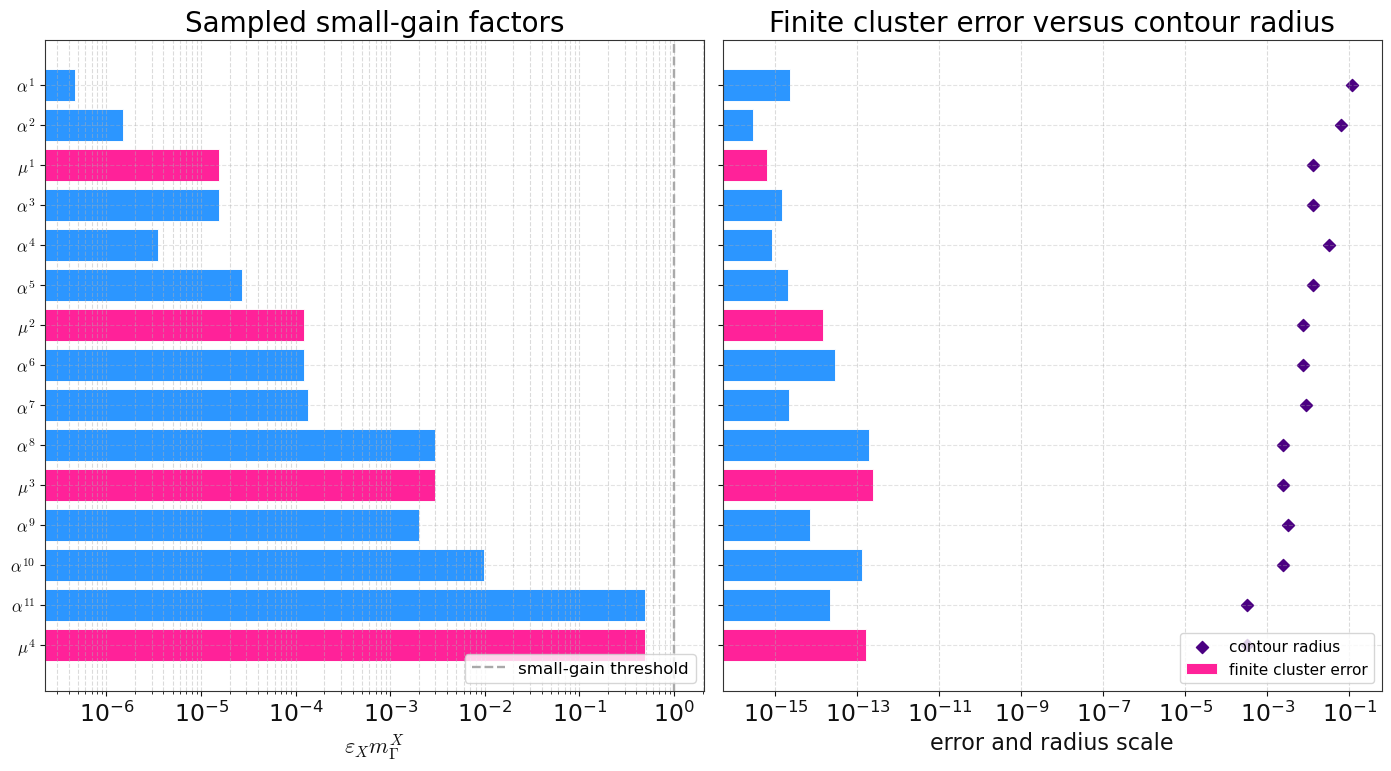

Saved figure: outputs/blaschke_deformation_certifier/figures/branch_image_wide_candidate_first15_small_gain_horizontal.png


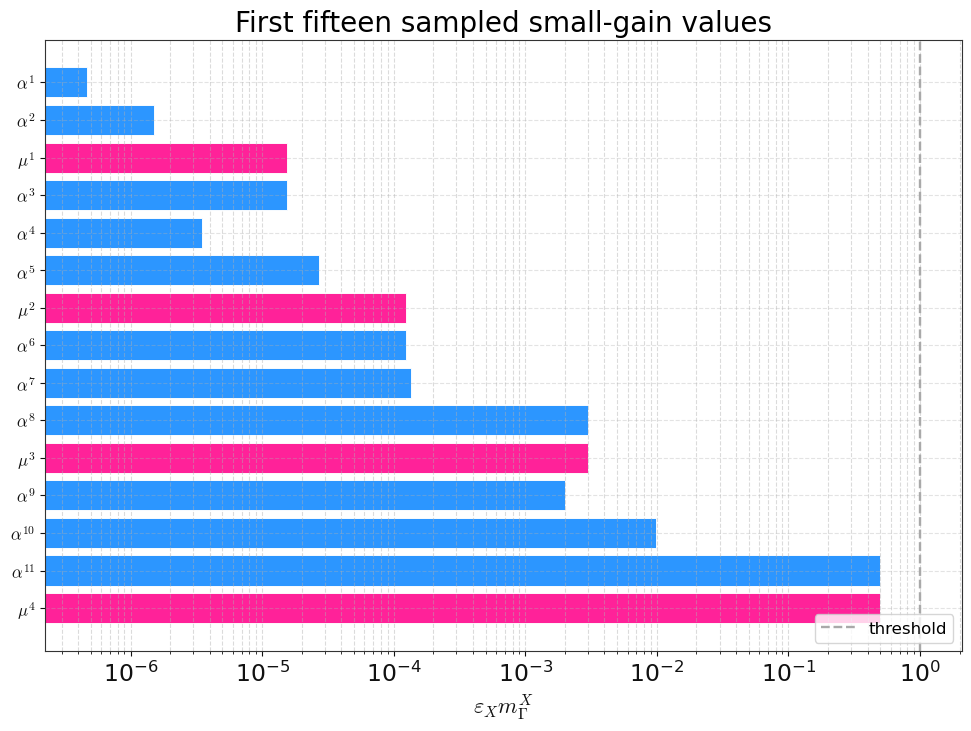

Reused archived sampled contour profiles: outputs/blaschke_deformation_certifier/data/branch_image_wide_candidate_first15_contour_profiles_N600_M610_J128.csv


Saved contour moat profiles: outputs/blaschke_deformation_certifier/data/branch_image_wide_candidate_first15_contour_profiles_N600_M610_J128.csv
Saved profile minima table: outputs/blaschke_deformation_certifier/data/branch_image_wide_candidate_first15_contour_profile_minima_table_N600_M610_J128.csv
Saved figure: outputs/blaschke_deformation_certifier/figures/branch_image_wide_candidate_first15_contour_moat_heatmap.png


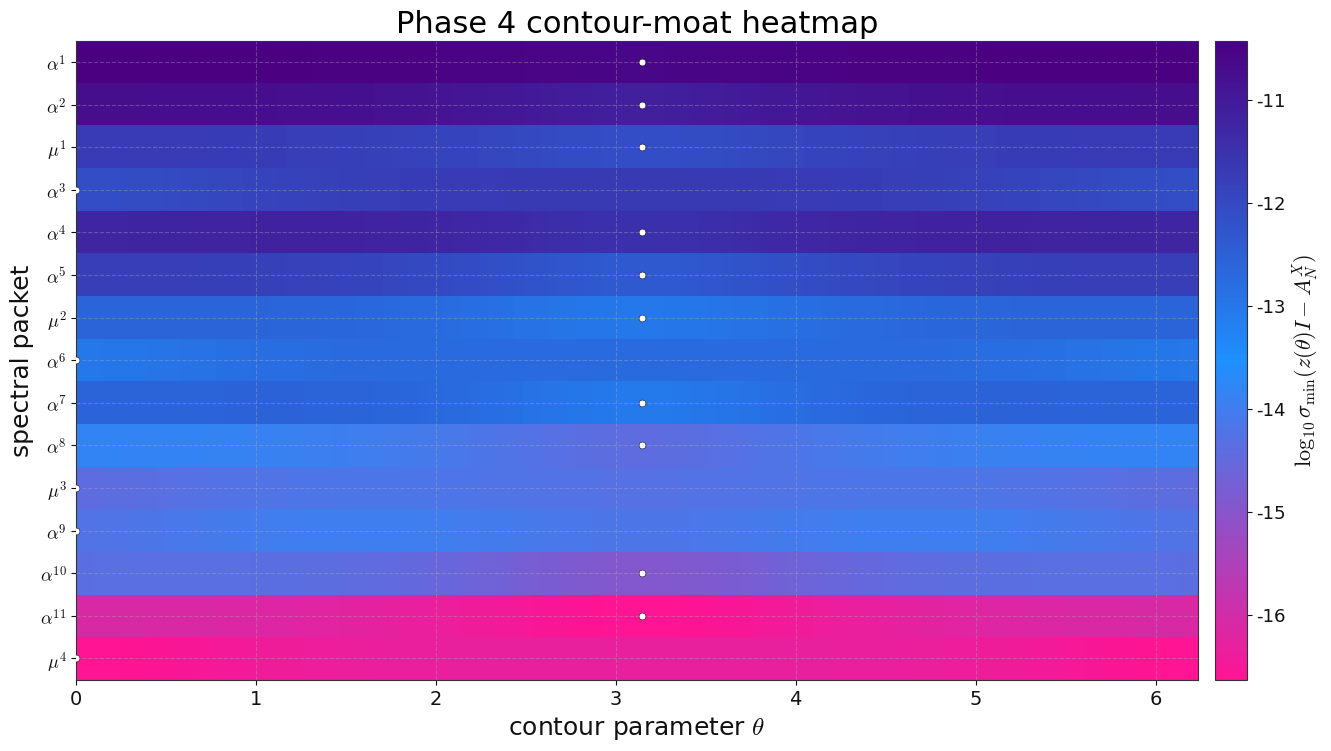

Saved figure: outputs/blaschke_deformation_certifier/figures/branch_image_wide_candidate_first15_contour_moat_profiles_lines.png


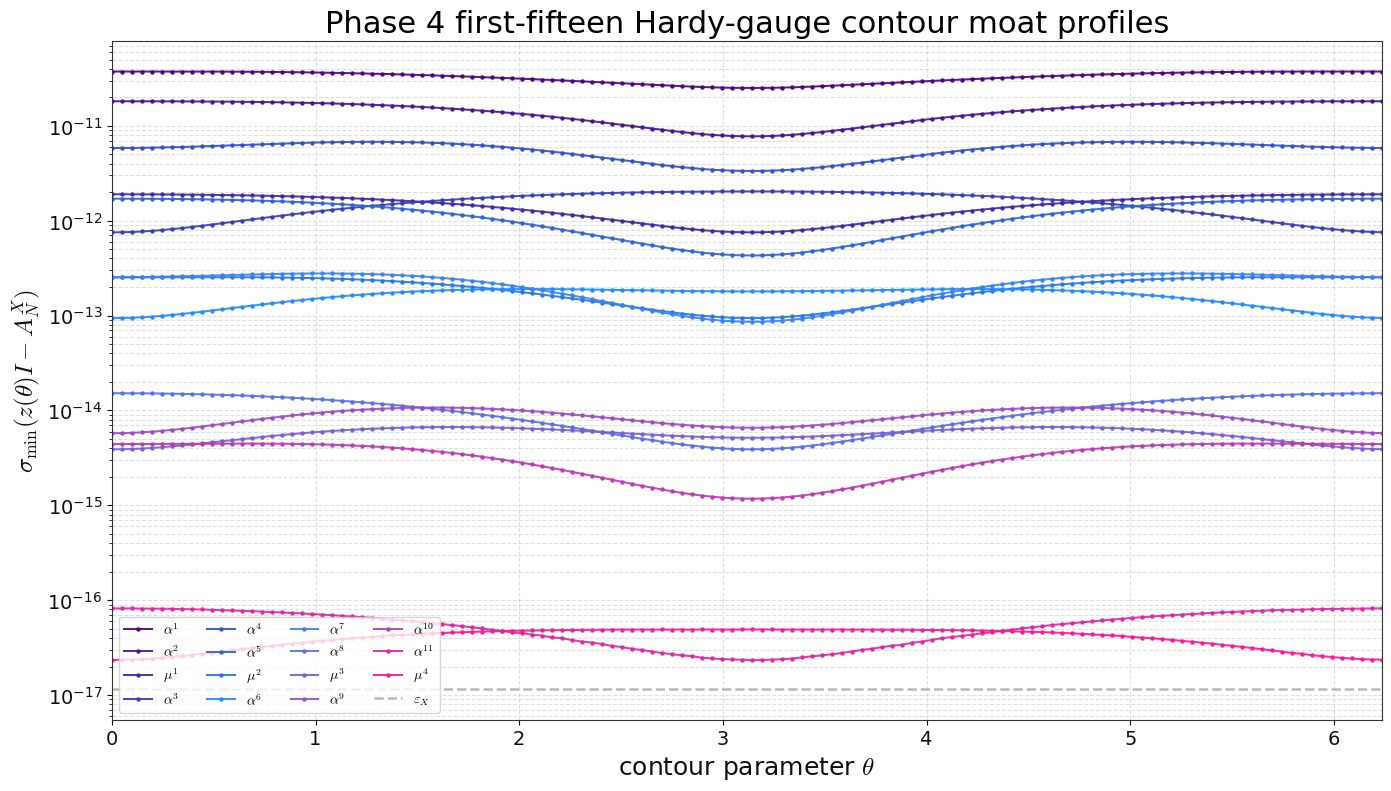

Saved figure: outputs/blaschke_deformation_certifier/figures/branch_image_wide_candidate_first15_contour_profile_minima_table.png


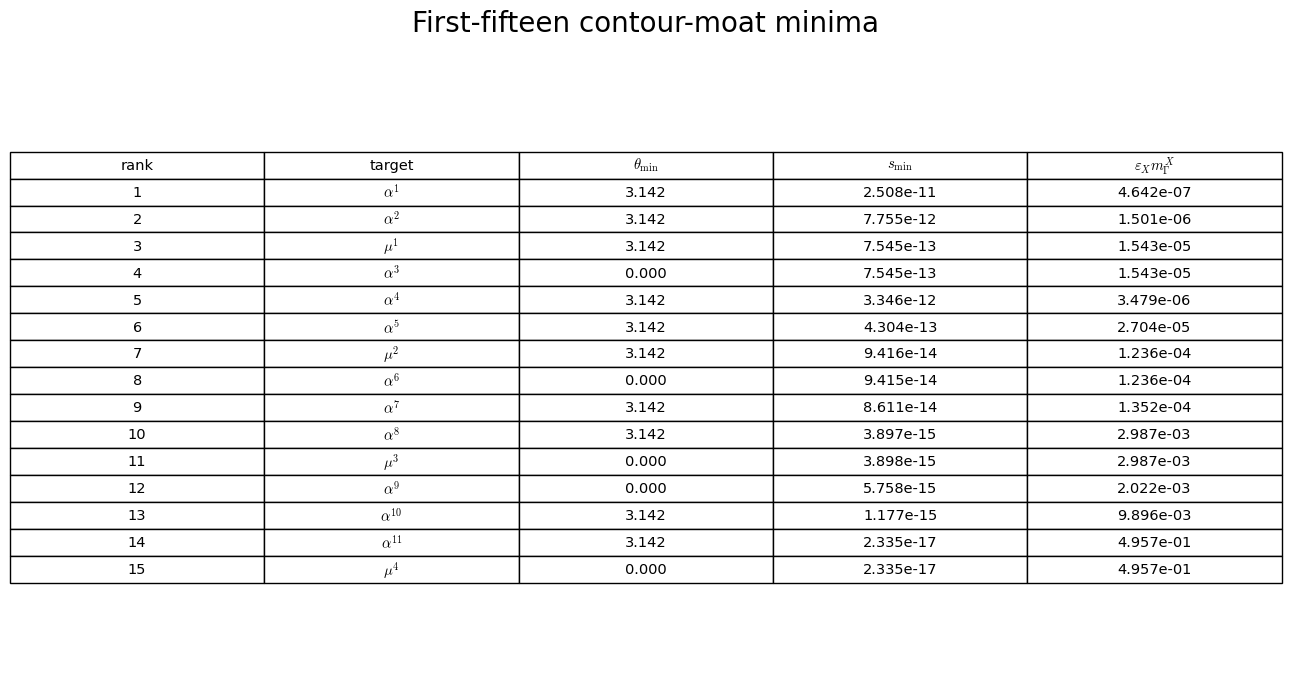

Saved figure: outputs/blaschke_deformation_certifier/figures/branch_image_wide_candidate_first15_moat_minima_profile.png


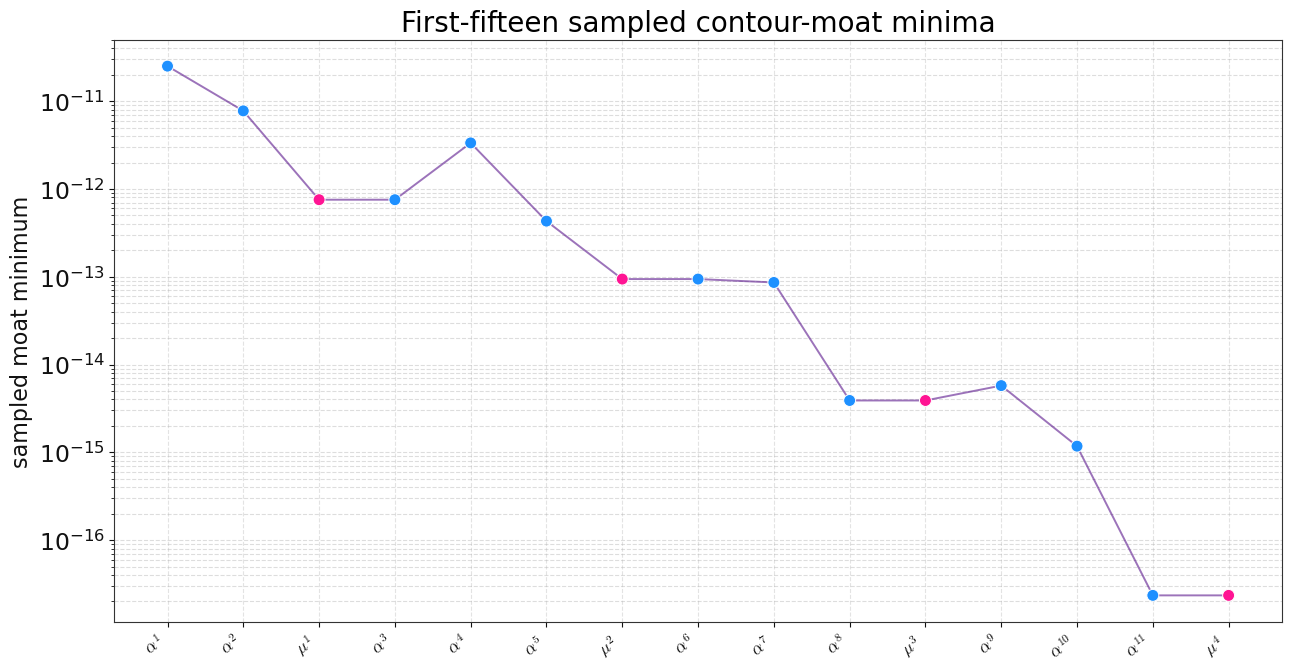

Saved moat table: outputs/blaschke_deformation_certifier/data/branch_image_wide_candidate_first15_contour_moats_N600_M610_J128.csv
Saved profile summary: outputs/blaschke_deformation_certifier/data/branch_image_wide_candidate_first15_contour_profile_summary_N600_M610_J128.csv
Saved plot table: outputs/blaschke_deformation_certifier/data/branch_image_wide_candidate_first15_contour_moat_plot_table_N600_M610_J128.csv


In [39]:
# Cell 38
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_38_status = transfer_lab_execute_selected_map_cell('# Cell 38', 'Phase 4 Hardy-gauge contour validation')
else:
    # ============================================================
    # Phase 4C — run contour moats, save table, and plot profiles
    # ============================================================

    PHASE4_FIRST15_MOAT_EXPORT_PATH =DATA_DIR /"branch_image_wide_candidate_first15_contour_moats_N600_M610_J128.csv"
    PHASE4_FIRST15_PROFILE_SUMMARY_PATH =DATA_DIR /"branch_image_wide_candidate_first15_contour_profile_summary_N600_M610_J128.csv"
    PHASE4_FIRST15_PLOT_TABLE_PATH =DATA_DIR /"branch_image_wide_candidate_first15_contour_moat_plot_table_N600_M610_J128.csv"

    phase4_moat_export =phase4_moats15 .copy ()
    if "family"not in phase4_moat_export .columns :
        phase4_moat_export ["family"]=phase4_moat_export ["target"].map (phase4_target_family )
    if "sampled_validation_pass"not in phase4_moat_export .columns :
        phase4_moat_export ["count_ok"]=phase4_moat_export ["finite_eigenvalue_count"].astype (int )==phase4_moat_export ["expected_multiplicity"].astype (int )
        phase4_moat_export ["sampled_validation_pass"]=phase4_moat_export ["count_ok"]&phase4_moat_export ["pass_sampled_small_gain"].astype (bool )&phase4_moat_export ["pass_sampled_packet"].astype (bool )
    phase4_moat_export ["contour_interval_certified"]=False
    phase4_moat_export ["validation_status"]="sampled_not_interval_certified"
    phase4_moat_export .to_csv (PHASE4_FIRST15_MOAT_EXPORT_PATH ,index =False )

    phase4_profile_summary =phase4_moat_export [["rank","target","family","centre","radius","theta_min","s_min_gamma","d_Gamma0","m_gamma_X","epsilon_X","epsilon_m_gamma","pass_sampled_small_gain","pass_sampled_packet"]].copy ()
    phase4_profile_summary ["profile_status"]="sampled contour minimum over the Phase 4C grid"
    phase4_profile_summary .to_csv (PHASE4_FIRST15_PROFILE_SUMMARY_PATH ,index =False )

    phase4_plot_table =phase4_moat_export [["rank","target","family","expected_multiplicity","finite_eigenvalue_count","radius","s_min_gamma","epsilon_m_gamma","max_numeric_error","sampled_validation_pass"]].copy ()
    phase4_plot_table .to_csv (PHASE4_FIRST15_PLOT_TABLE_PATH ,index =False )

    plot_df =phase4_sampled_validation_table .sort_values ("rank",ascending =False ).copy ()
    family_colours ={"alpha packet":PALETTE ["real"],"mu packet":PALETTE ["imag"],"fixed point":PALETTE ["main"]}
    bar_colours =[family_colours .get (f ,PALETTE ["main"])for f in plot_df ["family"]]
    y =np .arange (len (plot_df ))
    ylabels =[phase4_latex_target_label (t )for t in plot_df ["target"]]

    fig ,axes =plt .subplots (1 ,2 ,figsize =(13.8 ,7.6 ),facecolor ="white",constrained_layout =True )
    axes [0 ].barh (y ,plot_df ["epsilon_m_gamma"],color =bar_colours ,edgecolor ="white",linewidth =0.7 ,alpha =0.94 )
    axes [0 ].axvline (1.0 ,color =PALETTE ["ref"],linestyle ="--",linewidth =1.7 ,label ="small-gain threshold")
    axes [0 ].set_xscale ("log")
    axes [0 ].set_yticks (y )
    axes [0 ].set_yticklabels (ylabels ,fontsize =12 )
    axes [0 ].set_xlabel (r"$\varepsilon_X m_\Gamma^X$",fontsize =16 )
    axes [0 ].set_title ("Sampled small-gain factors",fontsize =20 )
    axes [0 ].grid (True ,which ="both",axis ="x",linestyle ="--",alpha =0.45 )
    axes [0 ].legend (fontsize =12 ,loc ="lower right",frameon =True )

    axes [1 ].barh (y ,plot_df ["max_numeric_error"],color =bar_colours ,edgecolor ="white",linewidth =0.7 ,alpha =0.94 ,label ="finite cluster error")
    axes [1 ].scatter (plot_df ["radius"],y ,marker ="D",s =38 ,color =PALETTE ["main"],label ="contour radius")
    axes [1 ].set_xscale ("log")
    axes [1 ].set_yticks (y )
    axes [1 ].set_yticklabels ([])
    axes [1 ].set_xlabel ("error and radius scale",fontsize =16 )
    axes [1 ].set_title ("Finite cluster error versus contour radius",fontsize =20 )
    axes [1 ].grid (True ,which ="both",axis ="x",linestyle ="--",alpha =0.45 )
    axes [1 ].legend (fontsize =12 ,loc ="lower right",frameon =True )
    axes [1 ].legend (fontsize =11 ,loc ="lower right",frameon =True )
    phase4_first15_fig_path =FIG_DIR /"branch_image_wide_candidate_first15_sampled_validation_1x2.png"
    fig .savefig (phase4_first15_fig_path ,dpi =240 ,bbox_inches ="tight")
    print (f"Saved figure: {phase4_first15_fig_path }")
    plt .show ()

    fig ,ax =plt .subplots (figsize =(9.6 ,7.2 ),facecolor ="white",constrained_layout =True )
    ax .barh (y ,plot_df ["epsilon_m_gamma"],color =bar_colours ,edgecolor ="white",linewidth =0.7 ,alpha =0.94 )
    ax .axvline (1.0 ,color =PALETTE ["ref"],linestyle ="--",linewidth =1.7 ,label ="threshold")
    ax .set_xscale ("log")
    ax .set_yticks (y )
    ax .set_yticklabels (ylabels ,fontsize =12 )
    ax .set_xlabel (r"$\varepsilon_X m_\Gamma^X$",fontsize =16 )
    ax .set_title ("First fifteen sampled small-gain values",fontsize =20 )
    ax .grid (True ,which ="both",axis ="x",linestyle ="--",alpha =0.45 )
    ax .legend (fontsize =12 ,loc ="lower right",frameon =True )
    phase4_small_gain_fig_path =FIG_DIR /"branch_image_wide_candidate_first15_small_gain_horizontal.png"
    fig .savefig (phase4_small_gain_fig_path ,dpi =240 ,bbox_inches ="tight")
    print (f"Saved figure: {phase4_small_gain_fig_path }")
    plt .show ()


    import os 
    import scipy .linalg as spla 

    PHASE4_PROFILE_SAMPLES =PHASE4_J 
    phase4_profile_targets_all =phase4_moat_export [phase4_moat_export ["target"].astype (str )!="1"].sort_values ("rank").copy ()
    PHASE4_FIRST15_PROFILE_PATH =DATA_DIR /f"branch_image_wide_candidate_first15_contour_profiles_N600_M610_J{PHASE4_PROFILE_SAMPLES }.csv"
    PHASE4_FORCE_SAMPLED_PROFILES =os .environ .get ("BLASCHKE_FORCE_SAMPLED_PROFILES","0")in {"1","true","True"}
    if PHASE4_FIRST15_PROFILE_PATH .is_file ()and not PHASE4_FORCE_SAMPLED_PROFILES :
        phase4_contour_profiles =pd .read_csv (PHASE4_FIRST15_PROFILE_PATH )
        print (f"Reused archived sampled contour profiles: {PHASE4_FIRST15_PROFILE_PATH }")
    else :
        profile_targets =phase4_profile_targets_all .copy ()
        profile_I =np .eye (A_X_phase4 .shape [0 ],dtype =np .complex128 )
        profile_theta =np .linspace (0.0 ,2.0 *np .pi ,PHASE4_PROFILE_SAMPLES ,endpoint =False )
        profile_rows =[]
        for row in profile_targets .itertuples (index =False ):
            centre =complex (getattr (row ,"centre"))
            radius =float (getattr (row ,"radius"))
            target =getattr (row ,"target")
            for theta in profile_theta :
                z =centre +radius *np .exp (1j *theta )
                smin =float (spla .svdvals (z *profile_I -A_X_phase4 ,check_finite =False )[-1 ])
                profile_rows .append ({"target":target ,"theta":theta ,"z_real":z .real ,"z_imag":z .imag ,"smin":smin })
        phase4_contour_profiles =pd .DataFrame (profile_rows )
        phase4_contour_profiles .to_csv (PHASE4_FIRST15_PROFILE_PATH ,index =False )

    if "phase1_gradient_palette"not in globals ():
        PHASE1_GRADIENT_CMAP =LinearSegmentedColormap .from_list ("phase1_indigo_blue_pink",((0.00 ,PALETTE .get ("main")),(0.52 ,PALETTE .get ("real")),(1.00 ,PALETTE .get ("imag"))))
        def phase1_gradient_palette (labels ):
            labels =tuple (labels )
            denom =max (1 ,len (labels )-1 )
            return {label :to_hex (PHASE1_GRADIENT_CMAP (i /denom ))for i ,label in enumerate (labels )}
    phase4_profile_minima_table =phase4_contour_profiles .loc [phase4_contour_profiles .groupby ("target")["smin"].idxmin ()].copy ()
    phase4_profile_minima_table =phase4_profile_minima_table .merge (phase4_moat_export [["rank","target","family","epsilon_m_gamma","pass_sampled_small_gain","pass_sampled_packet"]],on ="target",how ="left")
    phase4_profile_minima_table =phase4_profile_minima_table .sort_values ("rank")[["rank","target","family","theta","smin","epsilon_m_gamma","pass_sampled_small_gain","pass_sampled_packet"]]
    phase4_profile_minima_table =phase4_profile_minima_table .rename (columns ={"theta":"theta_at_profile_min","smin":"profile_s_min"})
    PHASE4_FIRST15_PROFILE_MINIMA_PATH =DATA_DIR /f"branch_image_wide_candidate_first15_contour_profile_minima_table_N600_M610_J{PHASE4_PROFILE_SAMPLES }.csv"
    phase4_profile_minima_table .to_csv (PHASE4_FIRST15_PROFILE_MINIMA_PATH ,index =False )

    profile_order =phase4_profile_minima_table ["target"].tolist ()
    profile_pivot =phase4_contour_profiles .pivot (index ="target",columns ="theta",values ="smin").loc [profile_order ]
    profile_log10 =np .log10 (np .maximum (profile_pivot .to_numpy (dtype =float ),np .finfo (float ).tiny ))
    profile_theta_values =profile_pivot .columns .to_numpy (dtype =float )
    profile_labels =[phase4_latex_target_label (t )for t in profile_order ]
    profile_heat_cmap =LinearSegmentedColormap .from_list ("phase4_moat_heatmap",(PALETTE ["imag"],PALETTE ["real"],PALETTE ["main"]))

    fig ,ax =plt .subplots (figsize =(13.2 ,7.4 ),facecolor ="white",constrained_layout =True )
    im =ax .imshow (profile_log10 ,aspect ="auto",origin ="upper",cmap =profile_heat_cmap ,interpolation ="nearest",extent =[profile_theta_values .min (),profile_theta_values .max (),len (profile_order )-0.5 ,-0.5 ])
    ax .set_yticks (np .arange (len (profile_order )))
    ax .set_yticklabels (profile_labels ,fontsize =13 )
    ax .set_xlabel (r"contour parameter $\theta$",fontsize =18 )
    ax .set_ylabel ("spectral packet",fontsize =18 )
    ax .set_title ("Phase 4 contour-moat heatmap",fontsize =22 )
    ax .tick_params (axis ="x",labelsize =14 )
    for yrow ,row in enumerate (phase4_profile_minima_table .itertuples (index =False )):
        ax .scatter (float (row .theta_at_profile_min ),yrow ,s =24 ,color ="white",edgecolor ="black",linewidth =0.35 ,zorder =3 )
    cbar =fig .colorbar (im ,ax =ax ,pad =0.015 )
    cbar .set_label (r"$\log_{10}\sigma_{\min}(z(\theta)I-A_N^X)$",fontsize =16 )
    cbar .ax .tick_params (labelsize =13 )
    phase4_profiles_fig_path =FIG_DIR /"branch_image_wide_candidate_first15_contour_moat_heatmap.png"
    fig .savefig (phase4_profiles_fig_path ,dpi =240 ,bbox_inches ="tight")
    print (f"Saved contour moat profiles: {PHASE4_FIRST15_PROFILE_PATH }")
    print (f"Saved profile minima table: {PHASE4_FIRST15_PROFILE_MINIMA_PATH }")
    print (f"Saved figure: {phase4_profiles_fig_path }")
    plt .show ()

    profile_line_colours =phase1_gradient_palette (profile_order )
    fig ,ax =plt .subplots (figsize =(13.8 ,7.8 ),facecolor ="white",constrained_layout =True )
    for target ,label in zip (profile_order ,profile_labels ):
        target_profile =phase4_contour_profiles .loc [phase4_contour_profiles ["target"]==target ].sort_values ("theta")
        ax .plot (
        target_profile ["theta"],
        target_profile ["smin"],
        color =profile_line_colours .get (target ,PALETTE ["main"]),
        linewidth =1.45 ,
        marker ="o",
        markersize =2.2 ,
        alpha =0.90 ,
        label =label ,
        )
    if "epsilon_X"in phase4_moat_export .columns :
        epsilon_line =float (phase4_moat_export ["epsilon_X"].iloc [0 ])
        ax .axhline (epsilon_line ,color =PALETTE ["ref"],linestyle ="--",linewidth =1.8 ,alpha =0.82 ,label =r"$\varepsilon_X$")
    ax .set_yscale ("log")
    ax .set_xlim (float (profile_theta_values .min ()),float (profile_theta_values .max ()))
    ax .set_xlabel (r"contour parameter $\theta$",fontsize =18 )
    ax .set_ylabel (r"$\sigma_{\min}(z(\theta)I-A_N^X)$",fontsize =18 )
    ax .set_title ("Phase 4 first-fifteen Hardy-gauge contour moat profiles",fontsize =22 )
    ax .tick_params (axis ="both",labelsize =14 )
    ax .grid (True ,which ="both",linestyle ="--",alpha =0.38 )
    ax .legend (fontsize =10 ,ncol =4 ,loc ="lower left",frameon =True )
    phase4_profiles_lines_fig_path =FIG_DIR /"branch_image_wide_candidate_first15_contour_moat_profiles_lines.png"
    fig .savefig (phase4_profiles_lines_fig_path ,dpi =260 ,bbox_inches ="tight")
    print (f"Saved figure: {phase4_profiles_lines_fig_path }")
    plt .show ()


    fig ,ax =plt .subplots (figsize =(12.8 ,6.8 ),facecolor ="white",constrained_layout =True )
    ax .axis ("off")
    minima_display =phase4_profile_minima_table .copy ()
    minima_display ["target"]=minima_display ["target"].map (phase4_latex_target_label )
    minima_display ["profile_s_min"]=minima_display ["profile_s_min"].map (lambda x :f"{x :.3e}")
    minima_display ["epsilon_m_gamma"]=minima_display ["epsilon_m_gamma"].map (lambda x :f"{x :.3e}")
    minima_display ["theta_at_profile_min"]=minima_display ["theta_at_profile_min"].map (lambda x :f"{x :.3f}")
    minima_display =minima_display [["rank","target","theta_at_profile_min","profile_s_min","epsilon_m_gamma"]]
    table =ax .table (cellText =minima_display .values ,colLabels =["rank","target",r"$\theta_{\min}$",r"$s_{\min}$",r"$\varepsilon_X m_\Gamma^X$"],loc ="center",cellLoc ="center",colLoc ="center")
    table .auto_set_font_size (False )
    table .set_fontsize (10.5 )
    table .scale (1.0 ,1.35 )
    ax .set_title ("First-fifteen contour-moat minima",fontsize =20 ,pad =16 )
    phase4_minima_table_fig_path =FIG_DIR /"branch_image_wide_candidate_first15_contour_profile_minima_table.png"
    fig .savefig (phase4_minima_table_fig_path ,dpi =240 ,bbox_inches ="tight")
    print (f"Saved figure: {phase4_minima_table_fig_path }")
    plt .show ()

    profile_df =phase4_profile_summary .sort_values ("rank",ascending =True ).copy ()
    profile_colours =[family_colours .get (f ,PALETTE ["main"])for f in profile_df ["family"]]
    profile_labels =[phase4_latex_target_label (t )for t in profile_df ["target"]]
    x =np .arange (len (profile_df ))
    fig ,ax =plt .subplots (figsize =(12.8 ,6.6 ),facecolor ="white",constrained_layout =True )
    ax .scatter (x ,profile_df ["s_min_gamma"],s =74 ,color =profile_colours ,edgecolor ="white",linewidth =0.7 ,zorder =3 )
    ax .plot (x ,profile_df ["s_min_gamma"],color =PALETTE ["main"],linewidth =1.4 ,alpha =0.55 )
    ax .set_yscale ("log")
    ax .set_xticks (x )
    ax .set_xticklabels (profile_labels ,rotation =35 ,ha ="right",fontsize =12 )
    ax .set_ylabel ("sampled moat minimum",fontsize =16 )
    ax .set_title ("First-fifteen sampled contour-moat minima",fontsize =20 )
    ax .grid (True ,which ="both",axis ="y",linestyle ="--",alpha =0.42 )
    phase4_profile_fig_path =FIG_DIR /"branch_image_wide_candidate_first15_moat_minima_profile.png"
    fig .savefig (phase4_profile_fig_path ,dpi =240 ,bbox_inches ="tight")
    print (f"Saved figure: {phase4_profile_fig_path }")
    plt .show ()

    print (f"Saved moat table: {PHASE4_FIRST15_MOAT_EXPORT_PATH }")
    print (f"Saved profile summary: {PHASE4_FIRST15_PROFILE_SUMMARY_PATH }")
    print (f"Saved plot table: {PHASE4_FIRST15_PLOT_TABLE_PATH }")
    phase4_profile_summary 

## Mathematics for Cell 38B

This cell produces a thesis-facing sampled Hardy-gauge moat profile for one selected contour packet, using only the stored Phase 4C profile data.  For the selected target, the contour is

$$
z(\theta)=c+\delta e^{i\theta},
\qquad 0\le \theta<2\pi,
$$

and the plotted profile is

$$
\theta\longmapsto
\sigma_{\min}\!\left(z(\theta)I_N-A_{N,M}^{X}\right).
$$

This is the legacy sampled wide-row diagnostic.  It retains the ordinary unstarred finite envelope and is not the promoted best-matrix radius used by the final complete-contour theorem gate.

The horizontal perturbation threshold is

$$
\widehat\varepsilon_{N,M}^{X,\mathrm{fin}},
$$

and the highlighted sampled moat is

$$
s_{\Gamma,N}^{\mathrm H,J}
=
\min_{0\le q<J}
\sigma_{\min}\!\left(z(\theta_q)I_N-A_{N,M}^{X}\right).
$$

The associated sampled stability factor is

$$
\widehat m_{\Gamma,N}^{\mathrm H,J}
=
\max\left\{\frac{1}{s_{\Gamma,N}^{\mathrm H,J}},\frac{1}{d_{\Gamma,0}}\right\}.
$$

The cell is visual: it displays the sampled finite-section contour moat already recorded in Cell 38.


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


...

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


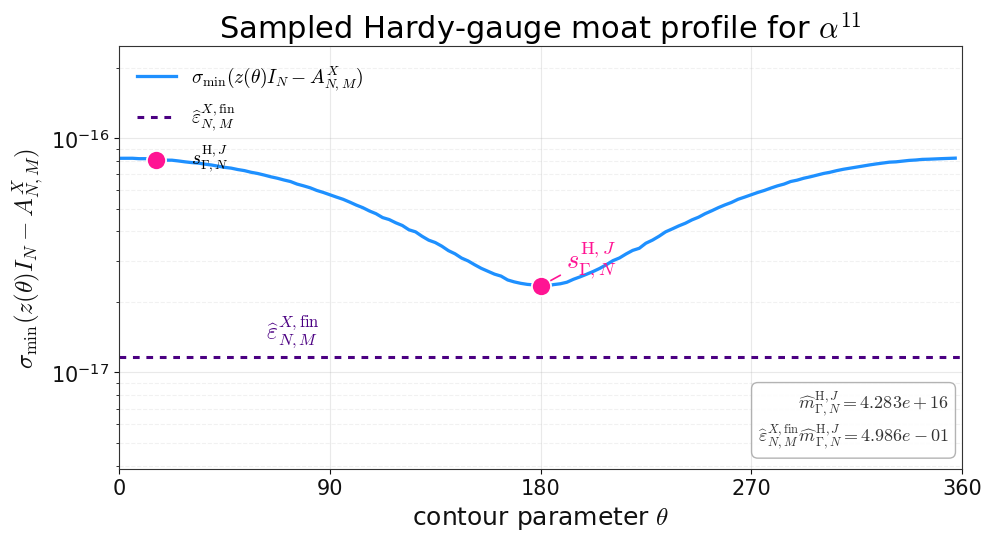

Profile target: alpha^11
Sampled minimum: 2.334583e-17 at theta = 180.000 degrees
epsilon_X: 1.164117e-17
epsilon_X * m_hat: 4.986401e-01
Saved figure: outputs/blaschke_deformation_certifier/figures/branch_image_wide_candidate_sampled_hardy_moat_profile_alpha11_N600_M610.png


In [40]:
# Cell 38B
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_38B_status = transfer_lab_execute_selected_map_cell('# Cell 38B', 'Phase 4 Hardy-gauge contour validation')
else:
    # ============================================================
    # Phase 4C2 — thesis-facing sampled Hardy-gauge moat profile
    # ============================================================

    from pathlib import Path
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    if "DATA_DIR" not in globals():
        DATA_DIR = Path("outputs/data") if Path.cwd().name == "Numerics" else Path("Numerics/outputs/data")
    if "FIG_DIR" not in globals():
        FIG_DIR = Path("outputs/figures") if Path.cwd().name == "Numerics" else Path("Numerics/outputs/figures")
    if "PALETTE" not in globals():
        PALETTE = {"real": "dodgerblue", "imag": "deeppink", "main": "indigo", "ref": "darkgrey", "bg": "#f0f2f5"}
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    PHASE4_PROFILE_DATA_PATH = DATA_DIR / "branch_image_wide_candidate_first15_contour_profiles_N600_M610_J128.csv"
    PHASE4_PROFILE_SUMMARY_PATH = DATA_DIR / "branch_image_wide_candidate_first15_contour_profile_summary_N600_M610_J128.csv"
    PHASE4_PROFILE_TARGET = globals().get("PHASE4_PROFILE_TARGET", None)

    if not PHASE4_PROFILE_DATA_PATH.exists():
        raise FileNotFoundError(PHASE4_PROFILE_DATA_PATH)
    if not PHASE4_PROFILE_SUMMARY_PATH.exists():
        raise FileNotFoundError(PHASE4_PROFILE_SUMMARY_PATH)

    phase4_profile_data = pd.read_csv(PHASE4_PROFILE_DATA_PATH)
    phase4_profile_summary_for_plot = pd.read_csv(PHASE4_PROFILE_SUMMARY_PATH)

    if PHASE4_PROFILE_TARGET is None:
        phase4_profile_row = phase4_profile_summary_for_plot.sort_values("epsilon_m_gamma", ascending=False).iloc[0]
    else:
        phase4_profile_row = phase4_profile_summary_for_plot.loc[
            phase4_profile_summary_for_plot["target"].astype(str) == str(PHASE4_PROFILE_TARGET)
        ].iloc[0]

    phase4_profile_target = str(phase4_profile_row["target"])
    phase4_profile_curve = phase4_profile_data.loc[
        phase4_profile_data["target"].astype(str) == phase4_profile_target
    ].copy().sort_values("theta")
    if phase4_profile_curve.empty:
        raise ValueError(f"No stored profile data for target {phase4_profile_target}")

    if "phase4_latex_target_label" not in globals():
        def phase4_latex_target_label(target):
            text = str(target)
            if text == "1":
                return r"$1$"
            if text.startswith("alpha^"):
                return rf"$\alpha^{{{text.split('^', 1)[1]}}}$"
            if text.startswith("mu^"):
                return rf"$\mu^{{{text.split('^', 1)[1]}}}$"
            return text

    phase4_profile_theta_deg = np.rad2deg(phase4_profile_curve["theta"].to_numpy(dtype=float))
    phase4_profile_smin = phase4_profile_curve["smin"].to_numpy(dtype=float)
    phase4_profile_min_idx = int(np.nanargmin(phase4_profile_smin))
    phase4_profile_theta_min_deg = float(phase4_profile_theta_deg[phase4_profile_min_idx])
    phase4_profile_s_min = float(phase4_profile_smin[phase4_profile_min_idx])
    phase4_profile_eps = float(phase4_profile_row["epsilon_X"])
    phase4_profile_d_gamma0 = float(phase4_profile_row["d_Gamma0"])
    phase4_profile_m_hat = max(1.0 / phase4_profile_s_min, 1.0 / phase4_profile_d_gamma0)
    phase4_profile_small_gain = phase4_profile_eps * phase4_profile_m_hat
    phase4_profile_label = phase4_latex_target_label(phase4_profile_target)

    with plt.rc_context({
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "axes.titlesize": 22,
        "axes.labelsize": 18,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "legend.fontsize": 14,
    }):
        fig, ax = plt.subplots(figsize=(9.8, 5.3), facecolor="white", constrained_layout=True)
        ax.plot(
            phase4_profile_theta_deg,
            phase4_profile_smin,
            color=PALETTE["real"],
            linewidth=2.35,
            label=r"$\sigma_{\min}(z(\theta)I_N-A_{N,M}^{X})$",
        )
        ax.axhline(
            phase4_profile_eps,
            color=PALETTE["main"],
            linestyle=(0, (2.2, 2.2)),
            linewidth=2.2,
            label=r"$\widehat\varepsilon_{N,M}^{X,\mathrm{fin}}$",
        )
        ax.scatter(
            [phase4_profile_theta_min_deg],
            [phase4_profile_s_min],
            s=190,
            color=PALETTE["imag"],
            edgecolor="white",
            linewidth=1.3,
            zorder=5,
            label=r"$s_{\Gamma,N}^{\mathrm{H},J}$",
        )
        ax.annotate(
            r"$s_{\Gamma,N}^{\mathrm{H},J}$",
            xy=(phase4_profile_theta_min_deg, phase4_profile_s_min),
            xytext=(18, 14),
            textcoords="offset points",
            color=PALETTE["imag"],
            fontsize=19,
            arrowprops=dict(arrowstyle="-", color=PALETTE["imag"], linewidth=1.2),
        )
        ax.annotate(
            r"$\widehat\varepsilon_{N,M}^{X,\mathrm{fin}}$",
            xy=(74, phase4_profile_eps),
            xytext=(0, 13),
            textcoords="offset points",
            color=PALETTE["main"],
            fontsize=17,
            ha="center",
        )
        ax.set_yscale("log")
        y_min = max(min(phase4_profile_eps, phase4_profile_s_min) / 3.0, 1.0e-20)
        y_max = max(np.nanmax(phase4_profile_smin) * 3.0, phase4_profile_eps * 4.0)
        ax.set_ylim(y_min, y_max)
        ax.set_xlim(0, 360)
        ax.set_xticks([0, 90, 180, 270, 360])
        ax.set_xlabel(r"contour parameter $\theta$")
        ax.set_ylabel(r"$\sigma_{\min}(z(\theta)I_N-A_{N,M}^{X})$")
        ax.set_title(rf"Sampled Hardy-gauge moat profile for {phase4_profile_label}")
        ax.grid(True, which="major", linestyle="-", alpha=0.28)
        ax.grid(True, which="minor", linestyle="--", alpha=0.17)
        ax.legend(loc="upper left", frameon=False)
        status_text = (
            rf"$\widehat m_{{\Gamma,N}}^{{\mathrm{{H}},J}}={phase4_profile_m_hat:.3e}$"
            + "\n"
            + rf"$\widehat\varepsilon_{{N,M}}^{{X,\mathrm{{fin}}}}\widehat m_{{\Gamma,N}}^{{\mathrm{{H}},J}}={phase4_profile_small_gain:.3e}$"
        )
        ax.text(
            0.985, 0.04, status_text,
            transform=ax.transAxes,
            ha="right", va="bottom",
            fontsize=13,
            color="#333333",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor=PALETTE["ref"], alpha=0.88),
        )
        safe_target = phase4_profile_target.replace("^", "")
        phase4_profile_fig_path = FIG_DIR / f"branch_image_wide_candidate_sampled_hardy_moat_profile_{safe_target}_N600_M610.png"
        fig.savefig(phase4_profile_fig_path, dpi=300, bbox_inches="tight")
        plt.show()

    print(f"Profile target: {phase4_profile_target}")
    print(f"Sampled minimum: {phase4_profile_s_min:.6e} at theta = {phase4_profile_theta_min_deg:.3f} degrees")
    print(f"epsilon_X: {phase4_profile_eps:.6e}")
    print(f"epsilon_X * m_hat: {phase4_profile_small_gain:.6e}")
    print(f"Saved figure: {phase4_profile_fig_path}")

<div style="color: #008B8B;">

## Mathematics for Cell 39

This cell writes a thesis-facing report that separates the theorem-certified deterministic perturbation radius from the sampled finite-section contour validation. The report never promotes a sampled moat or finite count to an interval contour certificate.

</div>


In [41]:
# Cell 39
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_39_status = transfer_lab_execute_selected_map_cell('# Cell 39', 'Phase 4 Hardy-gauge contour validation')
else:
    # ============================================================
    # Phase 4D — first-fifteen sampled-validation report
    # ============================================================

    def phase4_markdown_table(df, columns):
        view = df[columns].copy()
        def fmt(x):
            if isinstance(x, (float, np.floating)):
                if not np.isfinite(x):
                    return "nan"
                ax = abs(float(x))
                return f"{float(x):.6e}" if ax != 0 and (ax < 1e-4 or ax >= 1e5) else f"{float(x):.12g}"
            return str(x)
        rows = [[fmt(v) for v in row] for row in view.itertuples(index=False, name=None)]
        out = ["| " + " | ".join(columns) + " |", "| " + " | ".join(["---"] * len(columns)) + " |"]
        out.extend("| " + " | ".join(row) + " |" for row in rows)
        return "\n".join(out)

    report_cols = ["rank", "target", "centre", "expected_multiplicity", "finite_eigenvalue_count", "radius", "s_min_gamma", "epsilon_m_gamma", "max_numeric_error", "sampled_validation_pass"]
    lines = [
        "# Phase 4 first-fifteen branch-image sampled contour validation", "",
        f"Branch-image contour-stable row: N = {PHASE4_N}, M = {PHASE4_M}, rho = {PHASE4_RHO:.12g}, r = {PHASE4_R:.16g}, r_tau = {PHASE4_R_TAU:.12g}.",
        f"Theorem-level perturbation radius: epsilon_X = {PHASE4_EPS_X:.12e}.", "",
        "The deterministic perturbation radius is theorem-certified. The contour minima and finite counts in this table are sampled diagnostics and are not interval-certified.", "",
        phase4_markdown_table(phase4_sampled_validation_table, report_cols), "",
        f"Sampled packet passes: {int(phase4_sampled_validation_table['sampled_validation_pass'].sum())}/{len(phase4_sampled_validation_table)}.",
        f"Algebraic eigenvalues covered by the sampled finite counts: {phase4_total_algebraic_count}.",
        f"Worst sampled small-gain factor: {phase4_sampled_validation_table['epsilon_m_gamma'].max():.6g}.",
        "Contour interval certification: false.",
    ]
    phase4_first15_report_path = REPORT_DIR / "branch_image_wide_candidate_first15_sampled_validation_report.md"
    phase4_first15_report_path.write_text("\n".join(lines), encoding="utf-8")
    print(f"Saved report: {phase4_first15_report_path}")


Saved report: outputs/blaschke_deformation_certifier/reports/branch_image_wide_candidate_first15_sampled_validation_report.md


## Mathematics for Cell 40

This cell checks sampling robustness for the two most fragile displayed packets, $\alpha^{11}$ and $\mu^4$. For an angular sample count $J$, the contour grid is

$$
\theta_q^{(J)}=\frac{2\pi q}{J},
\qquad
q=0,\ldots,J-1.
$$

The corresponding sampled moat is

$$
s_{\min,\Gamma}^{(J)}
=
\min_{0\le q<J}
\sigma_{\min}\bigl(z(\theta_q^{(J)})I-A_N^X\bigr).
$$

The sampled stability factor at resolution $J$ is

$$
m_{\Gamma}^{X,J}
=
\max\left\{(s_{\min,\Gamma}^{(J)})^{-1},d_{\Gamma,0}^{-1}\right\},
$$

and the plotted robustness value is

$$
g_{\Gamma}^{(J)}
=
\varepsilon_Xm_{\Gamma}^{X,J}.
$$

The comparison between $J=128$ and $J=256$ checks whether the fragile packets remain below the threshold

$$
g_{\Gamma}^{(J)}<1.
$$

This is a sampling robustness diagnostic for the finite-section moat, not an interval proof of the contour minimum.


Fragile-packet robustness


,J,rank,target,centre,expected_multiplicity,radius,finite_eigenvalue_count,s_min_gamma,epsilon_m_gamma,pass_sampled_small_gain
0,128,14,alpha^11,0.008751,1,0.000325,1,2.348523e-17,0.495680,True
1,128,15,mu^4,0.008100,2,0.000325,2,2.348523e-17,0.495680,True
2,256,14,alpha^11,0.008751,1,0.000325,1,2.344040e-17,0.496628,True
3,256,15,mu^4,0.008100,2,0.000325,2,2.342023e-17,0.497056,True


Saved figure: outputs/blaschke_deformation_certifier/figures/branch_image_wide_candidate_first15_fragile_robustness.png


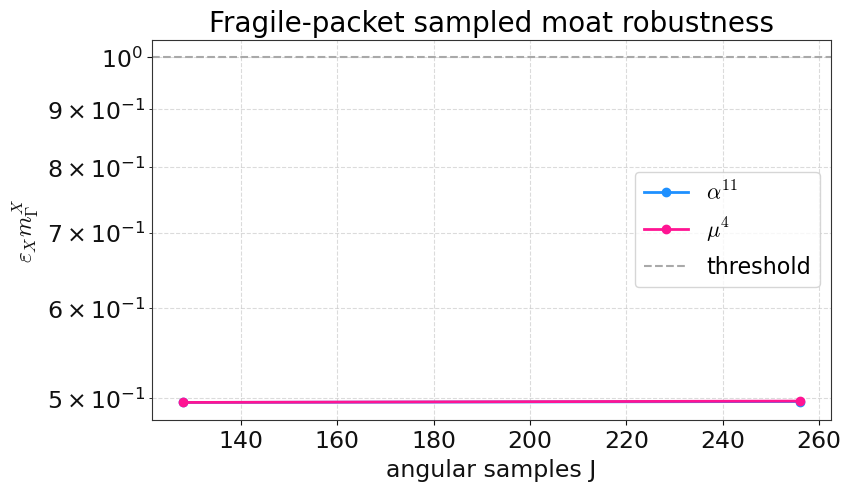

In [42]:
# Cell 40
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_40_status = transfer_lab_execute_selected_map_cell('# Cell 40', 'Phase 4 Hardy-gauge contour validation')
else:
    # ============================================================
    # Phase 4E — fragile-packet robustness table and plot
    # ============================================================

    phase4_fragile_display =phase4_fragile_robustness [["J","rank","target","centre","expected_multiplicity","radius","finite_eigenvalue_count","s_min_gamma","epsilon_m_gamma","pass_sampled_small_gain"]].copy ()
    print ("Fragile-packet robustness")
    display (phase4_fragile_display )

    fig ,ax =plt .subplots (figsize =(8.4 ,4.8 ),facecolor ="white",constrained_layout =True )
    for target ,group in phase4_fragile_robustness .groupby ("target",sort =False ):
        colour =PALETTE ["real"]if str (target ).startswith ("alpha")else PALETTE ["imag"]
        ax .plot (group ["J"],group ["epsilon_m_gamma"],marker ="o",linewidth =2.0 ,color =colour ,label =phase4_latex_target_label (target ))
    ax .axhline (1.0 ,color =PALETTE ["ref"],linestyle ="--",linewidth =1.5 ,label ="threshold")
    ax .set_yscale ("log")
    ax .set_xlabel ("angular samples J")
    ax .set_ylabel (r"$\varepsilon_X m_\Gamma^X$")
    ax .set_title ("Fragile-packet sampled moat robustness")
    ax .grid (True ,which ="both",linestyle ="--",alpha =0.45 )
    ax .legend (frameon =True )
    phase4_fragile_fig_path =FIG_DIR /"branch_image_wide_candidate_first15_fragile_robustness.png"
    fig .savefig (phase4_fragile_fig_path ,dpi =240 ,bbox_inches ="tight")
    print (f"Saved figure: {phase4_fragile_fig_path }")
    plt .show ()

## Mathematics for Cell 41

### Phase 4F — final branch-image certification exports

This cell writes thesis-facing copies of the branch-image Phase 4 files. The exported table is the first-fifteen contour table, not the older six-contour table.


In [43]:
# Cell 41
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_41_status = transfer_lab_execute_selected_map_cell('# Cell 41', 'Phase 4 Hardy-gauge contour validation')
else:
    # ============================================================
    # Phase 4F — final branch-image export names
    # ============================================================

    final_row_path = DATA_DIR / "final_blaschke_branch-image_wide_N600_schur_certificate.csv"
    final_moats_path = DATA_DIR / "final_blaschke_branch-image_first15_contour_moats_N600_M610.csv"
    final_packets_path = DATA_DIR / "final_blaschke_branch-image_first15_sampled_spectral_packets_N600_M610.csv"
    final_robust_path = DATA_DIR / "final_blaschke_branch-image_first15_fragile_robustness_N600_M610.csv"

    pd.DataFrame([phase4_row.to_dict()]).to_csv(final_row_path, index=False)
    phase4_moat_export.to_csv(final_moats_path, index=False)
    phase4_packets15.to_csv(final_packets_path, index=False)
    phase4_fragile_robustness.to_csv(final_robust_path, index=False)
    final_phase4_pairs = [(None, final_row_path), (None, final_moats_path), (None, final_packets_path), (None, final_robust_path)]

    phase4_final_summary = {
        "N": PHASE4_N, "M": PHASE4_M, "rho": PHASE4_RHO, "r": PHASE4_R, "r_tau": PHASE4_R_TAU,
        "q_out": PHASE4_Q_OUT, "q_gap": PHASE4_Q_GAP, "q_star": PHASE4_Q_STAR, "epsilon_X": PHASE4_EPS_X,
        "finite_M_prefactor_certified": True,
        "sampled_validation_passes": int(phase4_sampled_validation_table["sampled_validation_pass"].sum()),
        "target_packets": int(len(phase4_sampled_validation_table)),
        "algebraic_count": int(phase4_sampled_validation_table["expected_multiplicity"].sum()),
        "worst_epsilon_m_gamma": float(phase4_sampled_validation_table["epsilon_m_gamma"].max()),
        "contour_interval_certified": False,
        "moat_status": "sampled finite-section moat diagnostic",
    }
    summary_path = DATA_DIR / "final_blaschke_branch-image_first15_phase4_summary.json"
    summary_path.write_text(json.dumps(phase4_final_summary, indent=2), encoding="utf-8")

    # Keep the active evidence archives synchronised with the repaired Phase 4 products.
    _phase4_project_root = Path.cwd().parent if Path.cwd().name == "Numerics" else Path.cwd()
    _phase4_archive_paths = (
        _phase4_project_root / "Numerics" / "transfer_lab_hyperparameters.json",
        DATA_DIR / "transfer_lab_hyperparameters.json",
    )
    _phase4_schur_record = json.loads(pd.DataFrame([phase4_row.to_dict()]).to_json(orient="records"))[0]
    for _phase4_archive_path in _phase4_archive_paths:
        _phase4_archive = json.loads(_phase4_archive_path.read_text(encoding="utf-8")) if _phase4_archive_path.exists() else {}
        _phase4_record = dict(_phase4_archive.get("blaschke_mu_0p3", {}))
        _phase4_record.update({
            "status": "stored theorem-level Blaschke branch-image row with sampled contour validation",
            "sources": [str(summary_path), str(final_row_path), str(final_moats_path), str(final_packets_path)],
            "phase4_summary": phase4_final_summary,
            "schur_row": _phase4_schur_record,
            "deterministic_status": "theorem_certified",
            "contour_status": "sampled_not_interval_certified",
            "sampled_contour_rows": int(len(phase4_sampled_validation_table)),
            "notes": "The deterministic radius uses the unconditional finite-M prefactor; contour minima and packet passes remain sampled.",
        })
        _phase4_archive["blaschke_mu_0p3"] = _phase4_record
        _phase4_archive_path.write_text(json.dumps(_phase4_archive, indent=2, default=str), encoding="utf-8")
    print(f"Saved summary: {summary_path}")
    for _, dst in final_phase4_pairs:
        print(f"Saved copy: {dst}")
    phase4_final_summary


Saved summary: outputs/blaschke_deformation_certifier/data/final_blaschke_branch-image_first15_phase4_summary.json
Saved copy: outputs/blaschke_deformation_certifier/data/final_blaschke_branch-image_wide_N600_schur_certificate.csv
Saved copy: outputs/blaschke_deformation_certifier/data/final_blaschke_branch-image_first15_contour_moats_N600_M610.csv
Saved copy: outputs/blaschke_deformation_certifier/data/final_blaschke_branch-image_first15_sampled_spectral_packets_N600_M610.csv
Saved copy: outputs/blaschke_deformation_certifier/data/final_blaschke_branch-image_first15_fragile_robustness_N600_M610.csv


## Mathematics for Cell 42

### Phase 4G — final first-fifteen table preview

The table below is the thesis-facing branch-image contour table. All fifteen listed target packets pass the sampled small-gain test with the wide branch-image deterministic row.


In [44]:
# Cell 42
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_42_status = transfer_lab_execute_selected_map_cell('# Cell 42', 'Phase 4 Hardy-gauge contour validation')
else:
    # ============================================================
    # Phase 4G — final first-fifteen sampled-validation preview
    # ============================================================

    phase4_final_first15_table = pd.read_csv(DATA_DIR / "final_blaschke_branch-image_first15_contour_moats_N600_M610.csv")
    phase4_final_first15_table[["rank", "target", "centre", "expected_multiplicity", "finite_eigenvalue_count", "radius", "s_min_gamma", "epsilon_m_gamma", "pass_sampled_packet", "sampled_validation_pass", "contour_interval_certified"]]


## Mathematics for Cell 43

### Phase 4H — final acceptance status

The branch-image Phase 4 route certifies fifteen nontrivial target packets for the Blaschke benchmark at $N=600$, $M=610$. The deterministic perturbation radius comes from the wide branch-image row, while the contour moats are sampled in the Hardy gauge. The two deepest displayed packets, $\alpha^{11}$ and $\mu^4$, remain the fragile cases, with sampled small-gain factor about $0.5$; they pass but have the smallest safety margin.

Earlier development experiments are archived as output files only; they are no longer part of the executable Phase 4 route.


In [45]:
# Cell 43
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_43_status = transfer_lab_execute_selected_map_cell('# Cell 43', 'Phase 4 Hardy-gauge contour validation')
else:
    # ============================================================
    # Phase 4H — compact sampled-validation status
    # ============================================================

    acceptance_status = pd.DataFrame([
        {"quantity": "deterministic row", "value": "wide branch-image candidate"},
        {"quantity": "N", "value": PHASE4_N},
        {"quantity": "M", "value": PHASE4_M},
        {"quantity": "epsilon_X", "value": f"{PHASE4_EPS_X:.12e}"},
        {"quantity": "finite-M prefactor certified", "value": True},
        {"quantity": "target packets", "value": len(phase4_sampled_validation_table)},
        {"quantity": "algebraic count", "value": int(phase4_sampled_validation_table["expected_multiplicity"].sum())},
        {"quantity": "sampled packet passes", "value": int(phase4_sampled_validation_table["sampled_validation_pass"].sum())},
        {"quantity": "worst epsilon_m_gamma", "value": f"{phase4_sampled_validation_table['epsilon_m_gamma'].max():.6g}"},
        {"quantity": "moat status", "value": "sampled finite-section moat diagnostic"},
        {"quantity": "contour interval certified", "value": False},
    ])
    acceptance_status


## Mathematics for Cell 81

This optional visual diagnostic samples the finite Hardy-gauge resolvent moat near the fragile $\mu^2$ contour. It uses the branch-image Hardy-gauge matrix $A_N^X$ and the accepted contour data from Cell 38.

The local grid is

$$
\zeta_{a,b}=x_a+i y_b,
\qquad
x_a\in[x_{\min},x_{\max}],
\qquad
y_b\in[y_{\min},y_{\max}].
$$

At each grid point the sampled finite-section moat surface is

$$
S_{a,b}
=
\sigma_{\min}(\zeta_{a,b}I-A_N^X).
$$

The plotted height is the logarithmic surface

$$
Z_{a,b}
=
\log_{10}\max\{S_{a,b},S_{\mathrm{floor}}\},
$$

where $S_{\mathrm{floor}}$ prevents taking a logarithm of zero in the visualisation.

For the accepted $\mu^2$ contour, with centre $c_{\mu^2}$ and radius $\delta_{\mu^2}$, the overlaid curve is

$$
\zeta_{\mu^2}(\theta)
=
 c_{\mu^2}+\delta_{\mu^2}e^{i\theta}.
$$

The contour height in the 3D plot is obtained from the sampled contour profile

$$
\theta\longmapsto
\log_{10}\sigma_{\min}(\zeta_{\mu^2}(\theta)I-A_N^X),
$$

interpolated onto the dense contour used for plotting. The diagnostic is visual only: it shows the shape of the finite-section moat near $\mu^2$, while the certification table uses the sampled minimum and small-gain quantities computed earlier.


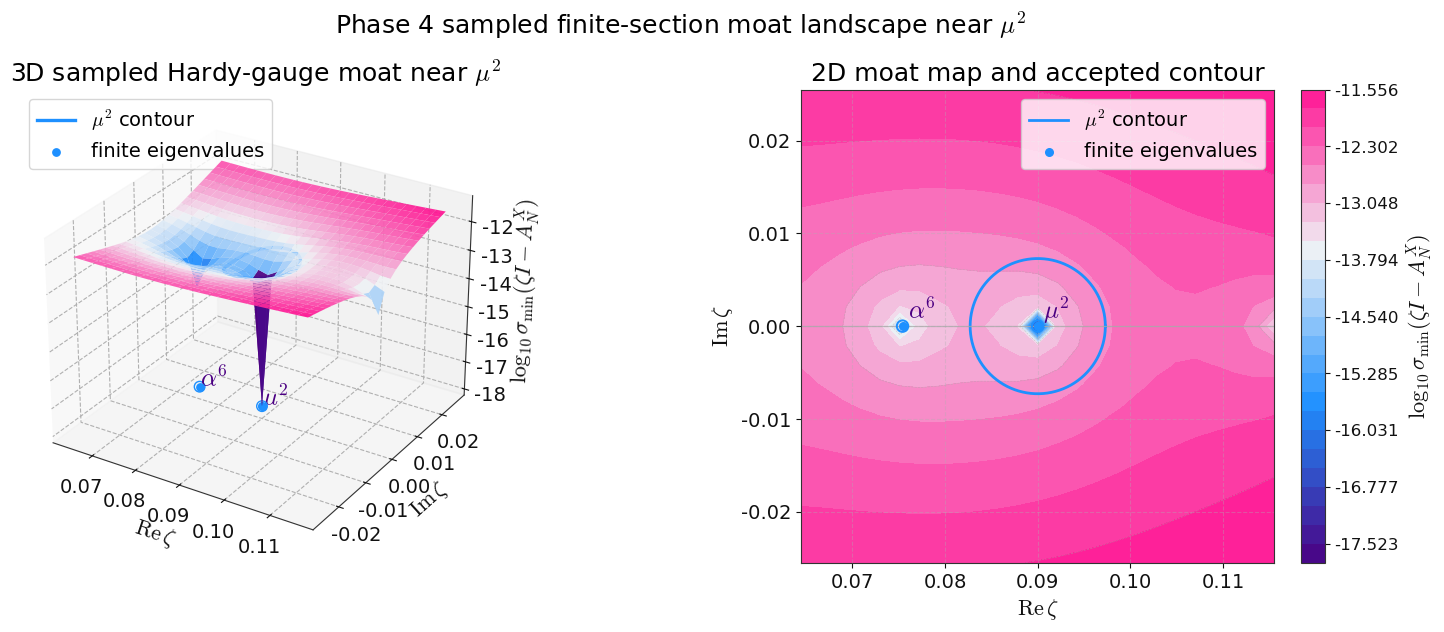

A_X source: outputs/blaschke_deformation_certifier/data/branch_image_wide_candidate_A_X_from_mp_scaled_N600_M610_r2p225974769705636.npz
Surface cache: outputs/blaschke_deformation_certifier/data/branch_image_wide_candidate_mu2_hardy_moat_surface_N600_M610_grid25.npz
Saved surface CSV: outputs/blaschke_deformation_certifier/data/branch_image_wide_candidate_mu2_hardy_moat_surface_N600_M610.csv
Saved Phase 4N figure: outputs/blaschke_deformation_certifier/figures/branch_image_wide_candidate_mu2_hardy_moat_surface_3d_2d_N600_M610.png
Minimum sampled grid s_min: 1.691081e-18


In [46]:
# Cell 81
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_81_status = transfer_lab_execute_selected_map_cell('# Cell 81', 'Phase 4 Hardy-gauge contour validation')
else:
    # ============================================================
    # Phase 4N — 3D sampled Hardy-gauge moat landscape near mu^2
    # ============================================================
    # Branch-image version of the original Phase 4N diagnostic.  It uses the
    # branch-image A_X matrix, the branch-image first-fifteen contour table,
    # and the branch-image contour-profile CSV produced in Cell 38.

    import scipy .linalg as spla 
    from matplotlib .colors import LinearSegmentedColormap 
    from mpl_toolkits .mplot3d import Axes3D # noqa: F401

    PHASE4_3D_N =600 
    PHASE4_3D_M =610 
    PHASE4_3D_TARGET ="mu^2"
    PHASE4_3D_GRID_SIZE =25 
    PHASE4_3D_LOG_FLOOR =1.0e-18 
    PHASE4_3D_HALF_WIDTH_MIN =2.5e-2 
    PHASE4_3D_TITLE_FONT_SIZE =18 
    PHASE4_3D_AXIS_LABEL_FONT_SIZE =16 
    PHASE4_3D_TICK_FONT_SIZE =14 
    PHASE4_3D_LEGEND_FONT_SIZE =14 
    PHASE4_3D_POINT_LABEL_FONT_SIZE =18 
    PHASE4_3D_COLOURBAR_LABEL_FONT_SIZE =16 
    PHASE4_3D_COLOURBAR_TICK_FONT_SIZE =12 

    def phase4_branch_image_load_hardy_gauge_A_X_for_visual ():
        candidates =[
        DATA_DIR /"branch_image_wide_candidate_A_X_from_mp_scaled_N600_M610_r2p225974769705636.npz",
        DATA_DIR /"phase4_hp_A_X_N600_M610.npz",
        DATA_DIR /"phase4_diag_A_X_N600_M610.npz",
        ]
        for path in candidates :
            if path .exists ():
                payload =np .load (path ,allow_pickle =False )
                key ="A_X"if "A_X"in payload .files else payload .files [0 ]
                return np .asarray (payload [key ],dtype =np .complex128 ),path 
        raise FileNotFoundError ("No saved Hardy-gauge A_X matrix found for the branch-image Phase 4N diagnostic.")

    def phase4_branch_image_load_mu2_visual_inputs ():
        table_path =DATA_DIR /"branch_image_wide_candidate_first15_contour_moats_N600_M610_J128.csv"
        profile_path =DATA_DIR /"branch_image_wide_candidate_first15_contour_profiles_N600_M610_J128.csv"
        eig_candidates =[
        DATA_DIR /"branch_image_phase1_raw_eigs_N600_M610.csv",
        DATA_DIR /"phase4_hp_hardy_gauge_eigenvalues_N600_M610.csv",
        DATA_DIR /"phase4_diag_hardy_gauge_eigenvalues_N600_M610.csv",
        ]
        table =pd .read_csv (table_path )
        mu2_row =table .loc [table ["target"]==PHASE4_3D_TARGET ].iloc [0 ]
        profile =pd .read_csv (profile_path )
        profile =profile .loc [profile ["target"]==PHASE4_3D_TARGET ].copy ()
        if "z_re"not in profile .columns and "z_real"in profile .columns :
            profile =profile .rename (columns ={"z_real":"z_re","z_imag":"z_im","smin":"s_min"})
        eig_df =pd .DataFrame (columns =["real","imag"])
        for eig_path in eig_candidates :
            if eig_path .exists ():
                eig_df =pd .read_csv (eig_path )
                break 
        return mu2_row ,profile ,eig_df 

    def phase4_branch_image_compute_or_load_mu2_moat_surface (A_X ,centre ,radius ,grid_size =PHASE4_3D_GRID_SIZE ):
        half_width =max (PHASE4_3D_HALF_WIDTH_MIN ,3.5 *float (radius ))
        cache_path =DATA_DIR /f"branch_image_wide_candidate_mu2_hardy_moat_surface_N600_M610_grid{int (grid_size )}.npz"
        if cache_path .exists ():
            payload =np .load (cache_path ,allow_pickle =False )
            return payload ["x"],payload ["y"],payload ["s_min"],cache_path 
        x =np .linspace (float (centre )-half_width ,float (centre )+half_width ,int (grid_size ))
        y =np .linspace (-half_width ,half_width ,int (grid_size ))
        s_grid =np .empty ((len (y ),len (x )),dtype =np .float64 )
        I =np .eye (A_X .shape [0 ],dtype =np .complex128 )
        for iy ,y_val in enumerate (y ):
            for ix ,x_val in enumerate (x ):
                zeta =x_val +1j *y_val 
                s_grid [iy ,ix ]=float (spla .svdvals (zeta *I -A_X ,check_finite =False )[-1 ])
        np .savez_compressed (cache_path ,x =x ,y =y ,s_min =s_grid )
        return x ,y ,s_grid ,cache_path 

    def phase4_branch_image_exact_targets_for_mu2_window (xlim ):
        mu =float (globals ().get ("PHASE4_MU",0.3 ))
        alpha =float (globals ().get ("PHASE4_ALPHA",(1.0 +mu )/2.0 ))
        targets =[]
        for n in range (1 ,18 ):
            value =alpha **n 
            if xlim [0 ]<=value <=xlim [1 ]:
                targets .append ((rf"$\alpha^{n }$",value ))
        for n in range (1 ,8 ):
            value =mu **n 
            if xlim [0 ]<=value <=xlim [1 ]:
                targets .append ((rf"$\mu^{n }$",value ))
        return targets 

    A_X_visual ,A_X_visual_source =phase4_branch_image_load_hardy_gauge_A_X_for_visual ()
    mu2_row ,mu2_profile ,phase4_visual_eigs =phase4_branch_image_load_mu2_visual_inputs ()
    mu2_centre =float (mu2_row ["centre"]if "centre"in mu2_row .index else mu2_row ["center"])
    mu2_radius =float (mu2_row ["radius"]if "radius"in mu2_row .index else mu2_row ["contour_radius"])
    x_grid ,y_grid ,s_grid ,surface_cache_path =phase4_branch_image_compute_or_load_mu2_moat_surface (A_X_visual ,mu2_centre ,mu2_radius )

    X_grid ,Y_grid =np .meshgrid (x_grid ,y_grid )
    Z_log =np .log10 (np .maximum (s_grid ,PHASE4_3D_LOG_FLOOR ))
    z_floor =float (np .nanmin (Z_log ))
    xlim =(float (x_grid .min ()),float (x_grid .max ()))
    ylim =(float (y_grid .min ()),float (y_grid .max ()))
    visible_eigs =phase4_visual_eigs .loc [phase4_visual_eigs ["real"].between (xlim [0 ],xlim [1 ])&phase4_visual_eigs ["imag"].between (ylim [0 ],ylim [1 ])].copy ()if {"real","imag"}.issubset (phase4_visual_eigs .columns )else pd .DataFrame (columns =["real","imag"])
    exact_targets =phase4_branch_image_exact_targets_for_mu2_window (xlim )

    moat_cmap =LinearSegmentedColormap .from_list ("phase4_branch-image_moat_palette",[PALETTE ["main"],PALETTE ["real"],PALETTE ["bg"],PALETTE ["imag"]],N =256 )
    theta_contour =np .linspace (0.0 ,2.0 *np .pi ,512 )
    contour_x =mu2_centre +mu2_radius *np .cos (theta_contour )
    contour_y =mu2_radius *np .sin (theta_contour )
    profile_theta =np .asarray (mu2_profile ["theta"],dtype =float )
    profile_s =np .asarray (mu2_profile ["s_min"],dtype =float )
    order =np .argsort (profile_theta )
    profile_theta =profile_theta [order ]
    profile_log =np .log10 (np .maximum (profile_s [order ],PHASE4_3D_LOG_FLOOR ))
    contour_z =np .interp (theta_contour ,profile_theta ,profile_log ,period =2.0 *np .pi )

    fig =plt .figure (figsize =(15.5 ,6.4 ),facecolor ="white")
    ax3d =fig .add_subplot (1 ,2 ,1 ,projection ="3d")
    ax2d =fig .add_subplot (1 ,2 ,2 )
    surface =ax3d .plot_surface (X_grid ,Y_grid ,Z_log ,cmap =moat_cmap ,linewidth =0.0 ,antialiased =True ,alpha =0.92 )
    ax3d .plot (contour_x ,contour_y ,contour_z ,color =PALETTE ["real"],linewidth =2.4 ,label =r"$\mu^2$ contour")
    if len (visible_eigs ):
        ax3d .scatter (visible_eigs ["real"],visible_eigs ["imag"],z_floor ,color =PALETTE ["real"],s =28 ,depthshade =False ,label ="finite eigenvalues")
    for label ,value in exact_targets :
        ax3d .scatter ([value ],[0.0 ],[z_floor ],facecolors ="none",edgecolors =PALETTE ["real"],s =58 ,depthshade =False )
        ax3d .text (value ,0.0 ,z_floor ,label ,color =PALETTE ["main"],fontsize =PHASE4_3D_POINT_LABEL_FONT_SIZE )
    ax3d .set_title (r"3D sampled Hardy-gauge moat near $\mu^2$",fontsize =PHASE4_3D_TITLE_FONT_SIZE )
    ax3d .set_xlabel (r"$\operatorname{Re}\zeta$",fontsize =PHASE4_3D_AXIS_LABEL_FONT_SIZE )
    ax3d .set_ylabel (r"$\operatorname{Im}\zeta$",fontsize =PHASE4_3D_AXIS_LABEL_FONT_SIZE )
    ax3d .set_zlabel (r"$\log_{10}\sigma_{\min}(\zeta I-A_N^X)$",fontsize =PHASE4_3D_AXIS_LABEL_FONT_SIZE )
    ax3d .tick_params (axis ="both",which ="major",labelsize =PHASE4_3D_TICK_FONT_SIZE )
    ax3d .view_init (elev =28 ,azim =-58 )
    ax3d .legend (loc ="upper left",fontsize =PHASE4_3D_LEGEND_FONT_SIZE )

    levels =np .linspace (float (np .nanmin (Z_log )),float (np .nanmax (Z_log )),26 )
    contourf =ax2d .contourf (X_grid ,Y_grid ,Z_log ,levels =levels ,cmap =moat_cmap )
    ax2d .contour (X_grid ,Y_grid ,Z_log ,levels =levels [::4 ],colors =PALETTE ["ref"],linewidths =0.45 ,alpha =0.55 )
    ax2d .plot (contour_x ,contour_y ,color =PALETTE ["real"],linewidth =2.0 ,label =r"$\mu^2$ contour")
    if len (visible_eigs ):
        ax2d .scatter (visible_eigs ["real"],visible_eigs ["imag"],color =PALETTE ["real"],s =30 ,label ="finite eigenvalues",zorder =4 )
    for label ,value in exact_targets :
        ax2d .scatter ([value ],[0.0 ],facecolors ="none",edgecolors =PALETTE ["real"],s =68 ,linewidths =1.4 ,zorder =5 )
        ax2d .annotate (label ,(value ,0.0 ),textcoords ="offset points",xytext =(4 ,5 ),color =PALETTE ["main"],fontsize =PHASE4_3D_POINT_LABEL_FONT_SIZE )
    ax2d .axhline (0.0 ,color =PALETTE ["ref"],linewidth =0.9 ,alpha =0.75 )
    ax2d .set_aspect ("equal",adjustable ="box")
    ax2d .set_xlim (*xlim )
    ax2d .set_ylim (*ylim )
    ax2d .set_title (r"2D moat map and accepted contour",fontsize =PHASE4_3D_TITLE_FONT_SIZE )
    ax2d .set_xlabel (r"$\operatorname{Re}\zeta$",fontsize =PHASE4_3D_AXIS_LABEL_FONT_SIZE )
    ax2d .set_ylabel (r"$\operatorname{Im}\zeta$",fontsize =PHASE4_3D_AXIS_LABEL_FONT_SIZE )
    ax2d .tick_params (axis ="both",which ="major",labelsize =PHASE4_3D_TICK_FONT_SIZE )
    ax2d .legend (loc ="upper right",fontsize =PHASE4_3D_LEGEND_FONT_SIZE )
    cbar =fig .colorbar (contourf ,ax =ax2d ,fraction =0.046 ,pad =0.04 )
    cbar .set_label (r"$\log_{10}\sigma_{\min}(\zeta I-A_N^X)$",fontsize =PHASE4_3D_COLOURBAR_LABEL_FONT_SIZE )
    cbar .ax .tick_params (labelsize =PHASE4_3D_COLOURBAR_TICK_FONT_SIZE )

    fig .suptitle (r"Phase 4 sampled finite-section moat landscape near $\mu^2$",fontsize =PHASE4_3D_TITLE_FONT_SIZE )
    fig .tight_layout ()
    phase4_3d_fig_path =FIG_DIR /"branch_image_wide_candidate_mu2_hardy_moat_surface_3d_2d_N600_M610.png"
    fig .savefig (phase4_3d_fig_path ,dpi =220 ,bbox_inches ="tight")
    plt .show ()

    surface_rows =[]
    for iy ,y_val in enumerate (y_grid ):
        for ix ,x_val in enumerate (x_grid ):
            surface_rows .append ({"z_re":float (x_val ),"z_im":float (y_val ),"s_min":float (s_grid [iy ,ix ]),"log10_s_min":float (Z_log [iy ,ix ])})
    surface_df =pd .DataFrame (surface_rows )
    surface_csv_path =DATA_DIR /"branch_image_wide_candidate_mu2_hardy_moat_surface_N600_M610.csv"
    surface_df .to_csv (surface_csv_path ,index =False )
    print (f"A_X source: {A_X_visual_source }")
    print (f"Surface cache: {surface_cache_path }")
    print (f"Saved surface CSV: {surface_csv_path }")
    print (f"Saved Phase 4N figure: {phase4_3d_fig_path }")
    print (f"Minimum sampled grid s_min: {np .nanmin (s_grid ):.6e}")

## Mathematics for Cell 82

This global diagnostic extends the local Cell 81 moat landscape from the single $\mu^2$ window to one rectangular window containing all first-fifteen nontrivial contour packets. The grid points are

$$
\zeta_{a,b}=x_a+i y_b,
\qquad
S_{a,b}=\sigma_{\min}(\zeta_{a,b}I-A_N^X),
\qquad
Z_{a,b}=\log_{10}\max\{S_{a,b},S_{\mathrm{floor}}\}.
$$

For packet $j$, the accepted contour is overlaid as

$$
\Gamma_j(\theta)=c_j+\delta_j e^{i\theta}.
$$

The surface belongs to the single finite Hardy-gauge operator $A_N^X$, so the same singular-value landscape is shared by all displayed packets. The rendered figure uses a top row with a high-resolution near-origin 3D zoom and a tighter high-resolution cluster restriction, followed by the full-width 2D contour map. This cell is a visual finite-section diagnostic, not a new theorem-level certification step.


/tmp/ipykernel_1271885/610805858.py:443: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig .tight_layout ()


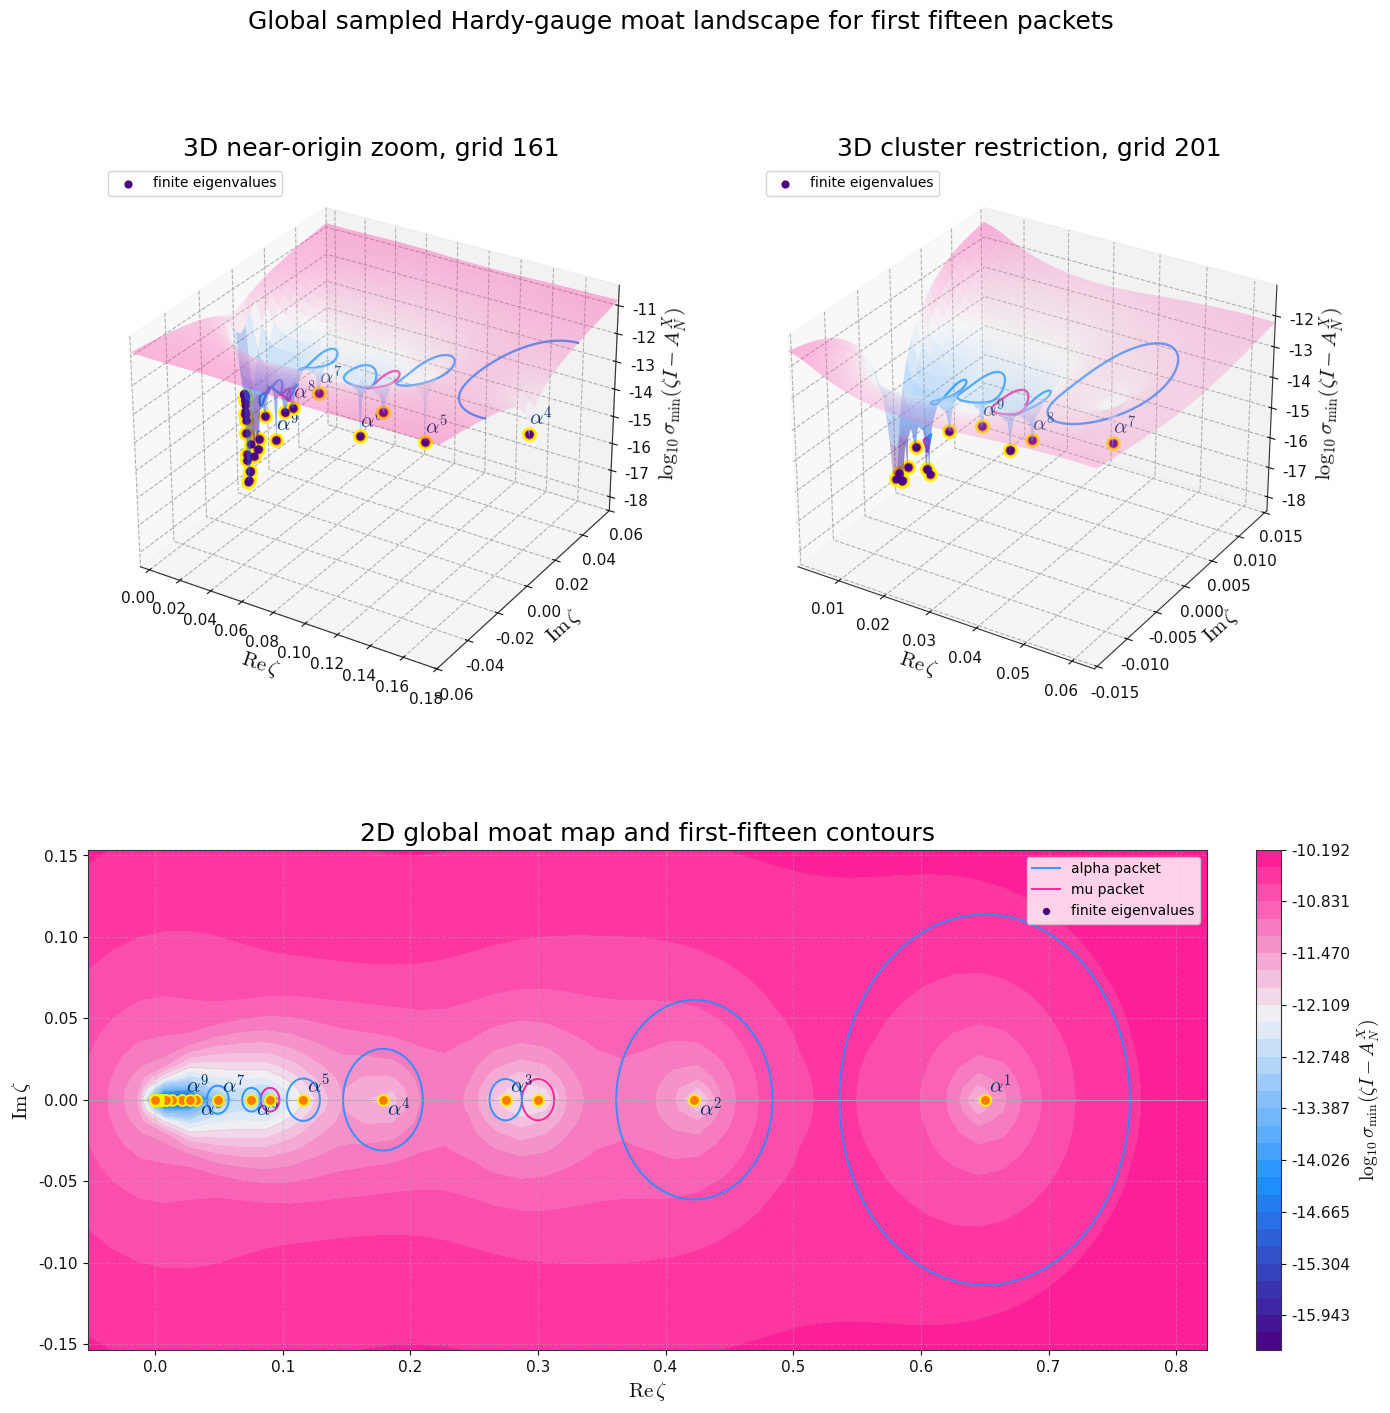

Global targets plotted: 15
Global surface cache: outputs/blaschke_deformation_certifier/data/branch_image_wide_candidate_first15_global_hardy_moat_surface_N600_M610_grid45.npz (loaded)
Zoom surface cache: outputs/blaschke_deformation_certifier/data/branch_image_wide_candidate_first15_zoom_hardy_moat_surface_N600_M610_grid161.npz (loaded)
Deep zoom surface cache: outputs/blaschke_deformation_certifier/data/branch_image_wide_candidate_first15_deep_zoom_hardy_moat_surface_N600_M610_grid201.npz (loaded)
Saved surface CSV: outputs/blaschke_deformation_certifier/data/branch_image_wide_candidate_first15_global_hardy_moat_surface_N600_M610.csv
Saved Phase 4O figure: outputs/blaschke_deformation_certifier/figures/branch_image_wide_candidate_first15_global_hardy_moat_surface_3d_2d_N600_M610.png
Minimum sampled global grid s_min: 4.274694e-17


In [47]:
# Cell 82
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_82_status = transfer_lab_execute_selected_map_cell('# Cell 82', 'Phase 4 Hardy-gauge contour validation')
else:
    # ============================================================
    # Phase 4O — global first-fifteen Hardy-gauge spectral landscape
    # ============================================================

    import os 
    import sys 
    import hashlib 
    import concurrent .futures as cf 
    from pathlib import Path 
    import scipy .linalg as spla 
    from scipy .interpolate import RegularGridInterpolator 
    from matplotlib .colors import LinearSegmentedColormap 
    from mpl_toolkits .mplot3d import Axes3D # noqa: F401

    _surface_worker_dir =Path ("Numerics")if (Path ("Numerics")/"hardy_moat_surface_worker.py").exists ()else Path .cwd ()
    _surface_worker_dir =_surface_worker_dir .resolve ()
    if str (_surface_worker_dir )not in sys .path :
        sys .path .insert (0 ,str (_surface_worker_dir ))
    from hardy_moat_surface_worker import initialise_surface_worker ,sample_surface_row_block 

    try :
        tqdm 
    except NameError :
        tqdm =None 

    PHASE4_GLOBAL_GRID_SIZE =45 
    PHASE4_GLOBAL_ZOOM_GRID_SIZE =161 
    PHASE4_GLOBAL_DEEP_ZOOM_GRID_SIZE =201 
    PHASE4_GLOBAL_LOG_FLOOR =1.0e-18 
    PHASE4_GLOBAL_VERTICAL_HALF_WIDTH_MIN =0.09 
    PHASE4_GLOBAL_CONTOUR_SAMPLES =384 
    PHASE4_GLOBAL_TITLE_FONT_SIZE =18 
    PHASE4_GLOBAL_AXIS_LABEL_FONT_SIZE =15 
    PHASE4_GLOBAL_TICK_FONT_SIZE =11 
    PHASE4_GLOBAL_LEGEND_FONT_SIZE =10 
    PHASE4_GLOBAL_POINT_LABEL_FONT_SIZE =15 
    PHASE4_GLOBAL_COLOURBAR_LABEL_FONT_SIZE =14 
    PHASE4_GLOBAL_COLOURBAR_TICK_FONT_SIZE =11 
    PHASE4_GLOBAL_SURFACE_OPACITY =0.30 
    PHASE4_GLOBAL_NEON_ORANGE ="#ff7a00"
    PHASE4_GLOBAL_NEON_YELLOW ="#fff200"
    PHASE4_GLOBAL_LABEL_DARK_BLUE ="#003366"
    PHASE4_GLOBAL_SURFACE_WORKERS =max (1 ,min (int (globals ().get ("PHASE4_SURFACE_WORKERS",os .cpu_count ()or 1 )),6 ))
    PHASE4_GLOBAL_ROW_BLOCK_SIZE =int (globals ().get ("PHASE4_SURFACE_ROW_BLOCK_SIZE",2 ))
    PHASE4_GLOBAL_FORCE_RECOMPUTE =bool (globals ().get ("PHASE4_SURFACE_FORCE_RECOMPUTE",False ))

    if "A_X_phase4"not in globals ():
        raise RuntimeError ("Run Cell 35 first so the branch-image Hardy-gauge matrix A_X_phase4 is available.")
    if "phase4_moat_export"not in globals ():
        raise RuntimeError ("Run Cell 38 first so the first-fifteen contour table phase4_moat_export is available.")

    def phase4_global_complex_centre (value ):
        return complex (value )


    def phase4_global_target_family (target ):
        text =str (target )
        if text .startswith ("alpha"):
            return "alpha packet"
        if text .startswith ("mu"):
            return "mu packet"
        return "fixed point"


    def phase4_global_load_visible_eigenvalues (xlim ,ylim ):
        eig_candidates =[
        DATA_DIR /"branch_image_phase1_raw_eigs_N600_M610.csv",
        DATA_DIR /"phase4_hp_hardy_gauge_eigenvalues_N600_M610.csv",
        DATA_DIR /"phase4_diag_hardy_gauge_eigenvalues_N600_M610.csv",
        ]
        eig_df =pd .DataFrame (columns =["real","imag"])
        for eig_path in eig_candidates :
            if eig_path .exists ():
                candidate =pd .read_csv (eig_path )
                if {"real","imag"}.issubset (candidate .columns ):
                    eig_df =candidate .copy ()
                    break 
        if len (eig_df ):
            eig_df =eig_df .loc [
            eig_df ["real"].between (xlim [0 ],xlim [1 ])
            &eig_df ["imag"].between (ylim [0 ],ylim [1 ])
            ].copy ()
        return eig_df 


    def phase4_global_exact_targets_in_window (xlim ):
        mu =float (globals ().get ("PHASE4_MU",0.3 ))
        alpha =float (globals ().get ("PHASE4_ALPHA",(1.0 +mu )/2.0 ))
        rows =[]
        for n in range (1 ,20 ):
            value =alpha **n 
            if xlim [0 ]<=value <=xlim [1 ]:
                rows .append ({"label":rf"$\alpha^{n }$","value":value ,"family":"alpha packet","power":n })
        for n in range (1 ,10 ):
            value =mu **n 
            if xlim [0 ]<=value <=xlim [1 ]:
                rows .append ({"label":rf"$\mu^{n }$","value":value ,"family":"mu packet","power":n })
        return pd .DataFrame (rows )


    def phase4_global_show_target_label (target_row ):
        try :
            return str (target_row .family )=="alpha packet"and int (target_row .power )<=9 
        except Exception :
            return False 


    def phase4_global_window (first15_df ):
        centres =np .asarray ([phase4_global_complex_centre (v )for v in first15_df ["centre"]],dtype =np .complex128 )
        radii =first15_df ["radius"].astype (float ).to_numpy ()
        x_min =float (np .min (centres .real -radii ))
        x_max =float (np .max (centres .real +radii ))
        x_pad =max (0.02 ,0.08 *max (x_max -x_min ,1.0e-12 ))
        y_half =max (PHASE4_GLOBAL_VERTICAL_HALF_WIDTH_MIN ,1.35 *float (np .max (radii )))
        return (x_min -x_pad ,x_max +x_pad ),(-y_half ,y_half )


    def phase4_global_cache_path (cache_tag ,grid_size ):
        if cache_tag =="global":
            return DATA_DIR /f"branch_image_wide_candidate_first15_global_hardy_moat_surface_N600_M610_grid{int (grid_size )}.npz"
        return DATA_DIR /f"branch_image_wide_candidate_first15_{cache_tag}_hardy_moat_surface_N600_M610_grid{int (grid_size )}.npz"


    def phase4_global_grid_signature (A_X ,xlim ,ylim ,grid_size ,cache_tag ):
        payload =np .array ([xlim [0 ],xlim [1 ],ylim [0 ],ylim [1 ],int (grid_size ),A_X .shape [0 ]],dtype =np .float64 )
        text =f"{cache_tag}|{A_X .shape }|{A_X .dtype }".encode ("utf-8")
        return hashlib .sha1 (payload .tobytes ()+text ).hexdigest ()[:12 ]


    def phase4_global_cache_matches (payload ,x ,y ):
        if "x"not in payload .files or "y"not in payload .files or "s_min"not in payload .files :
            return False 
        if payload ["s_min"].shape !=(len (y ),len (x )):
            return False 
        return np .allclose (payload ["x"],x ,rtol =0.0 ,atol =1.0e-15 )and np .allclose (payload ["y"],y ,rtol =0.0 ,atol =1.0e-15 )


    def phase4_global_matrix_cache (A_X ):
        matrix_path =DATA_DIR /f"branch_image_wide_candidate_phase4_A_X_surface_N{A_X .shape [0 ]}_M610_complex128.npy"
        A_arr =np .ascontiguousarray (np .asarray (A_X ,dtype =np .complex128 ))
        rewrite =True 
        if matrix_path .exists ():
            try :
                old =np .load (matrix_path ,mmap_mode ="r")
                rewrite =old .shape !=A_arr .shape or old .dtype !=A_arr .dtype 
            except Exception :
                rewrite =True 
        if rewrite :
            np .save (matrix_path ,A_arr )
        return matrix_path 


    def phase4_global_load_row_blocks (block_paths ,x ,y ):
        s_grid =np .empty ((len (y ),len (x )),dtype =np .float64 )
        for block_path in block_paths :
            if not block_path .exists ():
                return None 
            payload =np .load (block_path ,allow_pickle =False )
            y_start =int (payload ["y_start"])
            y_stop =int (payload ["y_stop"])
            s_block =np .asarray (payload ["s_block"],dtype =np .float64 )
            if s_block .shape !=(y_stop -y_start ,len (x )):
                return None 
            s_grid [y_start :y_stop ,:]=s_block 
        return s_grid 


    def phase4_global_compute_or_load_surface (A_X ,xlim ,ylim ,grid_size =PHASE4_GLOBAL_GRID_SIZE ,cache_tag ="global"):
        cache_path =phase4_global_cache_path (cache_tag ,grid_size )
        x =np .linspace (xlim [0 ],xlim [1 ],int (grid_size ))
        y =np .linspace (ylim [0 ],ylim [1 ],int (grid_size ))
        if cache_path .exists ()and not PHASE4_GLOBAL_FORCE_RECOMPUTE :
            payload =np .load (cache_path ,allow_pickle =False )
            if phase4_global_cache_matches (payload ,x ,y ):
                return payload ["x"],payload ["y"],payload ["s_min"],cache_path ,True 
            print (f"  ignoring stale full surface cache with incompatible grid: {cache_path }")

        signature =phase4_global_grid_signature (A_X ,xlim ,ylim ,grid_size ,cache_tag )
        block_dir =DATA_DIR /f"{cache_path .stem }_row_blocks_{signature }"
        block_dir .mkdir (parents =True ,exist_ok =True )
        matrix_path =phase4_global_matrix_cache (A_X )
        row_block_size =max (1 ,int (PHASE4_GLOBAL_ROW_BLOCK_SIZE ))
        block_specs =[]
        block_paths =[]
        for block_id ,y_start in enumerate (range (0 ,len (y ),row_block_size )):
            y_stop =min (len (y ),y_start +row_block_size )
            block_path =block_dir /f"rows_{y_start :04d}_{y_stop :04d}.npz"
            block_paths .append (block_path )
            if not block_path .exists ()or PHASE4_GLOBAL_FORCE_RECOMPUTE :
                block_specs .append ((block_id ,y_start ,y_stop ,x ,y [y_start :y_stop ],str (block_path )))

        meta_path =block_dir /"surface_grid_meta.npz"
        np .savez_compressed (meta_path ,x =x ,y =y ,xlim =np .asarray (xlim ),ylim =np .asarray (ylim ),grid_size =int (grid_size ),matrix_path =str (matrix_path ))

        if block_specs :
            total_points =len (x )*len (y )
            missing_points =sum ((spec [2 ]-spec [1 ])*len (x )for spec in block_specs )
            print (f"  sampling {missing_points }/{total_points } points for {cache_tag } grid {int (grid_size )} with {PHASE4_GLOBAL_SURFACE_WORKERS } process workers")
            if PHASE4_GLOBAL_SURFACE_WORKERS <=1 :
                initialise_surface_worker (str (matrix_path ))
                iterator =map (sample_surface_row_block ,block_specs )
                if tqdm is not None :
                    iterator =tqdm (iterator ,total =len (block_specs ),desc =f"{cache_tag} row blocks")
                for _ in iterator :
                    pass 
            else :
                with cf .ProcessPoolExecutor (
                    max_workers =PHASE4_GLOBAL_SURFACE_WORKERS ,
                    initializer =initialise_surface_worker ,
                    initargs =(str (matrix_path ),),
                )as pool :
                    iterator =pool .map (sample_surface_row_block ,block_specs )
                    if tqdm is not None :
                        iterator =tqdm (iterator ,total =len (block_specs ),desc =f"{cache_tag} row blocks")
                    for _ in iterator :
                        pass 
        else :
            print (f"  all row-block caches already present for {cache_tag } grid {int (grid_size )}")

        s_grid =phase4_global_load_row_blocks (block_paths ,x ,y )
        if s_grid is None :
            raise RuntimeError (f"Incomplete or incompatible row-block cache in {block_dir }")
        np .savez_compressed (cache_path ,x =x ,y =y ,s_min =s_grid ,row_block_dir =str (block_dir ),matrix_path =str (matrix_path ))
        return x ,y ,s_grid ,cache_path ,False 


    phase4_global_targets =phase4_moat_export [phase4_moat_export ["target"].astype (str )!="1"].sort_values ("rank").head (15 ).copy ()
    phase4_global_targets ["centre_complex"]=phase4_global_targets ["centre"].map (phase4_global_complex_centre )
    phase4_global_targets ["family"]=phase4_global_targets ["target"].map (phase4_global_target_family )
    phase4_global_xlim ,phase4_global_ylim =phase4_global_window (phase4_global_targets )

    x_grid ,y_grid ,s_grid ,global_surface_cache_path ,loaded_from_cache =phase4_global_compute_or_load_surface (
    A_X_phase4 ,
    phase4_global_xlim ,
    phase4_global_ylim ,
    PHASE4_GLOBAL_GRID_SIZE ,
    )
    X_grid ,Y_grid =np .meshgrid (x_grid ,y_grid )
    Z_log =np .log10 (np .maximum (s_grid ,PHASE4_GLOBAL_LOG_FLOOR ))
    z_floor =float (np .nanmin (Z_log ))

    surface_rows =[]
    for iy ,y_val in enumerate (y_grid ):
        for ix ,x_val in enumerate (x_grid ):
            surface_rows .append ({
            "z_re":float (x_val ),
            "z_im":float (y_val ),
            "s_min":float (s_grid [iy ,ix ]),
            "log10_s_min":float (Z_log [iy ,ix ]),
            })
    phase4_global_surface_df =pd .DataFrame (surface_rows )
    phase4_global_surface_csv_path =DATA_DIR /"branch_image_wide_candidate_first15_global_hardy_moat_surface_N600_M610.csv"
    phase4_global_surface_df .to_csv (phase4_global_surface_csv_path ,index =False )

    phase4_global_eigs =phase4_global_load_visible_eigenvalues (phase4_global_xlim ,phase4_global_ylim )
    phase4_global_exact_targets =phase4_global_exact_targets_in_window (phase4_global_xlim )

    interp =RegularGridInterpolator ((y_grid ,x_grid ),Z_log ,bounds_error =False ,fill_value =z_floor )
    moat_cmap =LinearSegmentedColormap .from_list (
    "phase4_global_moat_palette",
    [PALETTE ["main"],PALETTE ["real"],PALETTE ["bg"],PALETTE ["imag"]],
    N =256 ,
    )
    family_colours ={"alpha packet":PALETTE ["real"],"mu packet":PALETTE ["imag"],"fixed point":PALETTE ["main"]}
    theta =np .linspace (0.0 ,2.0 *np .pi ,PHASE4_GLOBAL_CONTOUR_SAMPLES )

    phase4_global_zoom_xlim =(max (phase4_global_xlim [0 ],-0.006 ),min (phase4_global_xlim [1 ],0.18 ))
    phase4_global_zoom_yhalf =min (phase4_global_ylim [1 ],0.060 )
    phase4_global_zoom_ylim =(-phase4_global_zoom_yhalf ,phase4_global_zoom_yhalf )

    x_zoom_grid ,y_zoom_grid ,s_zoom_grid ,zoom_surface_cache_path ,zoom_loaded_from_cache =phase4_global_compute_or_load_surface (
    A_X_phase4 ,
    phase4_global_zoom_xlim ,
    phase4_global_zoom_ylim ,
    PHASE4_GLOBAL_ZOOM_GRID_SIZE ,
    cache_tag ="zoom",
    )
    X_zoom_grid ,Y_zoom_grid =np .meshgrid (x_zoom_grid ,y_zoom_grid )
    Z_zoom_log =np .log10 (np .maximum (s_zoom_grid ,PHASE4_GLOBAL_LOG_FLOOR ))
    interp_zoom =RegularGridInterpolator ((y_zoom_grid ,x_zoom_grid ),Z_zoom_log ,bounds_error =False ,fill_value =float (np .nanmin (Z_zoom_log )))

    phase4_global_deep_zoom_targets =phase4_global_targets .loc [
    phase4_global_targets ["centre_complex"].map (lambda z :complex (z ).real <=0.055 )
    ].copy ()
    if len (phase4_global_deep_zoom_targets )<3 :
        phase4_global_deep_zoom_targets =phase4_global_targets .sort_values ("centre_complex",key =lambda col :col .map (lambda z :complex (z ).real )).head (7 ).copy ()
    deep_centres =np .asarray ([complex (z )for z in phase4_global_deep_zoom_targets ["centre_complex"]],dtype =np .complex128 )
    deep_radii =phase4_global_deep_zoom_targets ["radius"].astype (float ).to_numpy ()
    deep_x_min =float (np .min (deep_centres .real -deep_radii ))
    deep_x_max =float (np .max (deep_centres .real +deep_radii ))
    deep_x_pad =max (0.0025 ,0.14 *max (deep_x_max -deep_x_min ,1.0e-12 ))
    deep_y_half =max (0.0065 ,1.8 *float (np .max (deep_radii )))
    phase4_global_deep_zoom_xlim =(max (phase4_global_xlim [0 ],deep_x_min -deep_x_pad ),min (phase4_global_xlim [1 ],deep_x_max +deep_x_pad ))
    phase4_global_deep_zoom_ylim =(-deep_y_half ,deep_y_half )

    x_deep_grid ,y_deep_grid ,s_deep_grid ,deep_surface_cache_path ,deep_loaded_from_cache =phase4_global_compute_or_load_surface (
    A_X_phase4 ,
    phase4_global_deep_zoom_xlim ,
    phase4_global_deep_zoom_ylim ,
    PHASE4_GLOBAL_DEEP_ZOOM_GRID_SIZE ,
    cache_tag ="deep_zoom",
    )
    X_deep_grid ,Y_deep_grid =np .meshgrid (x_deep_grid ,y_deep_grid )
    Z_deep_log =np .log10 (np .maximum (s_deep_grid ,PHASE4_GLOBAL_LOG_FLOOR ))
    interp_deep =RegularGridInterpolator ((y_deep_grid ,x_deep_grid ),Z_deep_log ,bounds_error =False ,fill_value =float (np .nanmin (Z_deep_log )))

    fig =plt .figure (figsize =(15.8 ,15.4 ),facecolor ="white")
    gs =fig .add_gridspec (2 ,2 ,height_ratios =[1.08 ,1.0 ],hspace =0.28 ,wspace =0.16 )
    ax3d =fig .add_subplot (gs [0 ,0 ],projection ="3d")
    ax3d_deep =fig .add_subplot (gs [0 ,1 ],projection ="3d")
    ax2d =fig .add_subplot (gs [1 ,:])


    def phase4_global_plot_3d_panel (ax ,xlim ,ylim ,title ,zoomed =False ,grid_pack =None ):
        if grid_pack is None :
            local_x_grid ,local_y_grid ,local_Z_log ,local_interp =x_grid ,y_grid ,Z_log ,interp 
            fallback_X ,fallback_Y ,fallback_Z =X_grid ,Y_grid ,Z_log 
        else:
            local_x_grid ,local_y_grid ,local_Z_log ,local_interp =grid_pack 
            fallback_X ,fallback_Y =np .meshgrid (local_x_grid ,local_y_grid )
            fallback_Z =local_Z_log 
        x_mask =(local_x_grid >=xlim [0 ])&(local_x_grid <=xlim [1 ])
        y_mask =(local_y_grid >=ylim [0 ])&(local_y_grid <=ylim [1 ])
        X_panel ,Y_panel =np .meshgrid (local_x_grid [x_mask ],local_y_grid [y_mask ])
        Z_panel =local_Z_log [np .ix_ (y_mask ,x_mask )]
        if Z_panel .size ==0 :
            X_panel ,Y_panel ,Z_panel =fallback_X ,fallback_Y ,fallback_Z 
        surface_alpha =PHASE4_GLOBAL_SURFACE_OPACITY 
        ax .plot_surface (X_panel ,Y_panel ,Z_panel ,cmap =moat_cmap ,linewidth =0.0 ,antialiased =True ,alpha =surface_alpha )
        for row in phase4_global_targets .itertuples (index =False ):
            centre =complex (row .centre_complex )
            radius =float (row .radius )
            if centre .real +radius <xlim [0 ]or centre .real -radius >xlim [1 ]or radius <ylim [0 ]-centre .imag or -radius >ylim [1 ]-centre .imag :
                continue 
            family =str (row .family )
            colour =family_colours .get (family ,PALETTE ["main"])
            contour_x =centre .real +radius *np .cos (theta )
            contour_y =centre .imag +radius *np .sin (theta )
            inside =(
            (contour_x >=xlim [0 ])&(contour_x <=xlim [1 ])
            &(contour_y >=ylim [0 ])&(contour_y <=ylim [1 ])
            )
            if np .count_nonzero (inside )<2 :
                continue 
            contour_z =local_interp (np .column_stack ([contour_y ,contour_x ]))
            contour_x_plot =contour_x .astype (float ).copy ()
            contour_y_plot =contour_y .astype (float ).copy ()
            contour_z_plot =np .asarray (contour_z ,dtype =float ).copy ()
            contour_x_plot [~inside ]=np .nan 
            contour_y_plot [~inside ]=np .nan 
            contour_z_plot [~inside ]=np .nan 
            ax .plot (contour_x_plot ,contour_y_plot ,contour_z_plot ,color =colour ,linewidth =1.65 if zoomed else 1.6 ,alpha =0.9 )
        if len (phase4_global_eigs ):
            eig_window =phase4_global_eigs .loc [
            phase4_global_eigs ["real"].between (xlim [0 ],xlim [1 ])
            &phase4_global_eigs ["imag"].between (ylim [0 ],ylim [1 ])
            ].copy ()
            if len (eig_window ):
                eig_xy =np .column_stack ([eig_window ["imag"].to_numpy (),eig_window ["real"].to_numpy ()])
                eig_z =local_interp (eig_xy )
                ax .scatter (eig_window ["real"],eig_window ["imag"],eig_z ,color =PALETTE ["main"],s =18 if not zoomed else 24 ,depthshade =False ,label ="finite eigenvalues")
        exact_window =phase4_global_exact_targets .loc [phase4_global_exact_targets ["value"].between (xlim [0 ],xlim [1 ])].copy ()
        for row in exact_window .itertuples (index =False ):
            colour =family_colours .get (row .family ,PALETTE ["main"])
            point_z =float (local_interp ([[0.0 ,row .value ]])[0 ])
            label_z =point_z +0.045 *(float (np .nanmax (Z_panel ))-float (np .nanmin (Z_panel )))
            ax .scatter ([row .value ],[0.0 ],[point_z ],facecolors =PHASE4_GLOBAL_NEON_ORANGE ,edgecolors =PHASE4_GLOBAL_NEON_YELLOW ,s =82 if zoomed else 68 ,linewidths =1.7 ,depthshade =False )
            if phase4_global_show_target_label (row ):
                ax .text (row .value ,0.0 ,label_z ,row .label ,color =PHASE4_GLOBAL_LABEL_DARK_BLUE ,fontsize =PHASE4_GLOBAL_POINT_LABEL_FONT_SIZE )
        ax .set_title (title ,fontsize =PHASE4_GLOBAL_TITLE_FONT_SIZE )
        ax .set_xlabel (r"$\operatorname{Re}\zeta$",fontsize =PHASE4_GLOBAL_AXIS_LABEL_FONT_SIZE )
        ax .set_ylabel (r"$\operatorname{Im}\zeta$",fontsize =PHASE4_GLOBAL_AXIS_LABEL_FONT_SIZE )
        ax .set_zlabel (r"$\log_{10}\sigma_{\min}(\zeta I-A_N^X)$",fontsize =PHASE4_GLOBAL_AXIS_LABEL_FONT_SIZE )
        ax .set_xlim (*xlim )
        ax .set_ylim (*ylim )
        ax .tick_params (axis ="both",which ="major",labelsize =PHASE4_GLOBAL_TICK_FONT_SIZE )
        ax .view_init (elev =29 ,azim =-58 )
        if len (ax .collections ):
            pass 
        handles ,labels =ax .get_legend_handles_labels ()
        if labels :
            ax .legend (loc ="upper left",fontsize =PHASE4_GLOBAL_LEGEND_FONT_SIZE )


    phase4_global_plot_3d_panel (
    ax3d ,
    phase4_global_zoom_xlim ,
    phase4_global_zoom_ylim ,
    f"3D near-origin zoom, grid {PHASE4_GLOBAL_ZOOM_GRID_SIZE}",
    zoomed =True ,
    grid_pack =(x_zoom_grid ,y_zoom_grid ,Z_zoom_log ,interp_zoom ),
    )
    phase4_global_plot_3d_panel (
    ax3d_deep ,
    phase4_global_deep_zoom_xlim ,
    phase4_global_deep_zoom_ylim ,
    f"3D cluster restriction, grid {PHASE4_GLOBAL_DEEP_ZOOM_GRID_SIZE}",
    zoomed =True ,
    grid_pack =(x_deep_grid ,y_deep_grid ,Z_deep_log ,interp_deep ),
    )
    levels =np .linspace (float (np .nanmin (Z_log )),float (np .nanmax (Z_log )),30 )
    contourf =ax2d .contourf (X_grid ,Y_grid ,Z_log ,levels =levels ,cmap =moat_cmap )
    ax2d .contour (X_grid ,Y_grid ,Z_log ,levels =levels [::4 ],colors =PALETTE ["ref"],linewidths =0.42 ,alpha =0.5 )
    legend_handles ={}
    for row in phase4_global_targets .itertuples (index =False ):
        centre =complex (row .centre_complex )
        radius =float (row .radius )
        family =str (row .family )
        colour =family_colours .get (family ,PALETTE ["main"])
        contour_x =centre .real +radius *np .cos (theta )
        contour_y =centre .imag +radius *np .sin (theta )
        label =family if family not in legend_handles else None 
        line ,=ax2d .plot (contour_x ,contour_y ,color =colour ,linewidth =1.4 ,alpha =0.9 ,label =label )
        if label is not None :
            legend_handles [family ]=line 
    if len (phase4_global_eigs ):
        ax2d .scatter (phase4_global_eigs ["real"],phase4_global_eigs ["imag"],color =PALETTE ["main"],s =18 ,label ="finite eigenvalues",zorder =4 )
    for idx ,row in enumerate (phase4_global_exact_targets .itertuples (index =False )):
        colour =family_colours .get (row .family ,PALETTE ["main"])
        y_offset =5 if idx %2 ==0 else -12 
        ax2d .scatter ([row .value ],[0.0 ],facecolors =PHASE4_GLOBAL_NEON_ORANGE ,edgecolors =PHASE4_GLOBAL_NEON_YELLOW ,s =60 ,linewidths =1.4 ,zorder =5 )
        if phase4_global_show_target_label (row ):
            ax2d .annotate (row .label ,(row .value ,0.0 ),textcoords ="offset points",xytext =(3 ,y_offset ),color =PHASE4_GLOBAL_LABEL_DARK_BLUE ,fontsize =PHASE4_GLOBAL_POINT_LABEL_FONT_SIZE )
    ax2d .axhline (0.0 ,color =PALETTE ["ref"],linewidth =0.8 ,alpha =0.75 )
    ax2d .set_aspect ("auto")
    ax2d .set_xlim (*phase4_global_xlim )
    ax2d .set_ylim (*phase4_global_ylim )
    ax2d .set_title ("2D global moat map and first-fifteen contours",fontsize =PHASE4_GLOBAL_TITLE_FONT_SIZE )
    ax2d .set_xlabel (r"$\operatorname{Re}\zeta$",fontsize =PHASE4_GLOBAL_AXIS_LABEL_FONT_SIZE )
    ax2d .set_ylabel (r"$\operatorname{Im}\zeta$",fontsize =PHASE4_GLOBAL_AXIS_LABEL_FONT_SIZE )
    ax2d .tick_params (axis ="both",which ="major",labelsize =PHASE4_GLOBAL_TICK_FONT_SIZE )
    ax2d .legend (loc ="upper right",fontsize =PHASE4_GLOBAL_LEGEND_FONT_SIZE )
    cbar =fig .colorbar (contourf ,ax =ax2d ,fraction =0.046 ,pad =0.04 )
    cbar .set_label (r"$\log_{10}\sigma_{\min}(\zeta I-A_N^X)$",fontsize =PHASE4_GLOBAL_COLOURBAR_LABEL_FONT_SIZE )
    cbar .ax .tick_params (labelsize =PHASE4_GLOBAL_COLOURBAR_TICK_FONT_SIZE )

    fig .suptitle ("Global sampled Hardy-gauge moat landscape for first fifteen packets",fontsize =PHASE4_GLOBAL_TITLE_FONT_SIZE )
    fig .tight_layout ()
    phase4_global_fig_path =FIG_DIR /"branch_image_wide_candidate_first15_global_hardy_moat_surface_3d_2d_N600_M610.png"
    fig .savefig (phase4_global_fig_path ,dpi =300 ,bbox_inches ="tight")
    plt .show ()

    print (f"Global targets plotted: {len (phase4_global_targets )}")
    print (f"Global surface cache: {global_surface_cache_path } ({'loaded'if loaded_from_cache else 'computed'})")
    print (f"Zoom surface cache: {zoom_surface_cache_path } ({'loaded'if zoom_loaded_from_cache else 'computed'})")
    print (f"Deep zoom surface cache: {deep_surface_cache_path } ({'loaded'if deep_loaded_from_cache else 'computed'})")
    print (f"Saved surface CSV: {phase4_global_surface_csv_path }")
    print (f"Saved Phase 4O figure: {phase4_global_fig_path }")
    print (f"Minimum sampled global grid s_min: {np .nanmin (s_grid ):.6e}")

## Mathematics for Cell 82B

This visual companion tests two readability improvements for the global first-fifteen moat landscape without changing the certification data.

The near-origin zoom keeps the original Euclidean geometry and restricts the view to a smaller rectangle

$$
\zeta=x+iy,
\qquad
x\in[x_{\min}^{\mathrm{zoom}},x_{\max}^{\mathrm{zoom}}],
\qquad
|y|\le y_{\max}^{\mathrm{zoom}}.
$$

The symlog panel keeps the same data values but changes only the horizontal display scale.  The displayed coordinate is linear for small $|x|$ and logarithmic away from zero:

$$
x\longmapsto \operatorname{symlog}_{\ell}(x),
$$

where $\ell$ is the linear threshold.  This spreads the accumulated packets near zero, but it visually distorts the circular contours, so it should be read only as a diagnostic view.


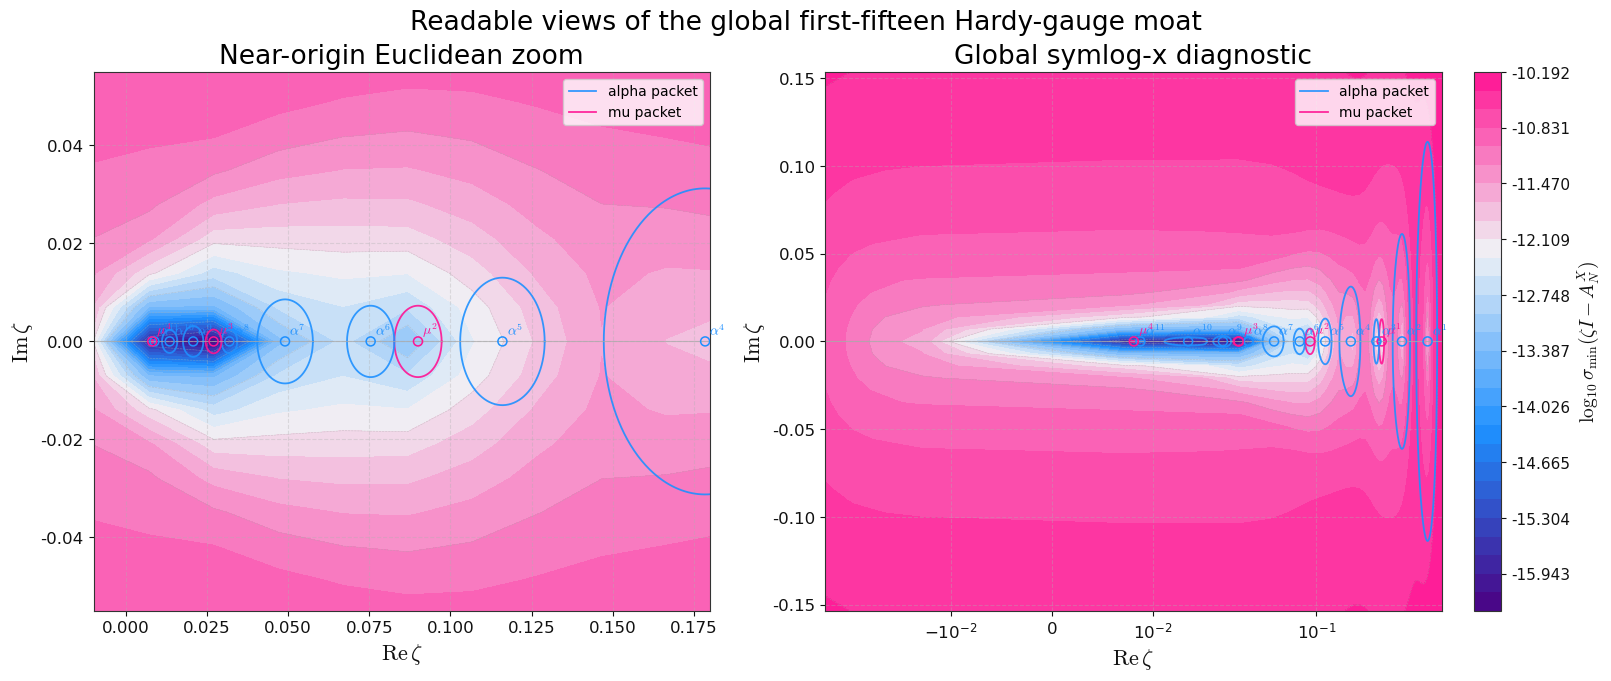

Zoom targets shown: 11
Saved Phase 4P zoom and symlog figure: outputs/blaschke_deformation_certifier/figures/branch_image_wide_candidate_first15_global_hardy_moat_zoom_symlog_N600_M610.png


In [48]:
# Cell 82B
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_82B_status = transfer_lab_execute_selected_map_cell('# Cell 82B', 'Phase 4 Hardy-gauge contour validation')
else:
    # ============================================================
    # Phase 4P — zoom and symlog views of the global first-fifteen moat
    # ============================================================

    from matplotlib .colors import LinearSegmentedColormap 

    PHASE4_GLOBAL_ZOOM_XMAX =0.18 
    PHASE4_GLOBAL_ZOOM_YHALF =0.055 
    PHASE4_GLOBAL_SYMLOG_LINTHRESH =0.015 
    PHASE4_GLOBAL_ZOOM_TITLE_FONT_SIZE =19 
    PHASE4_GLOBAL_ZOOM_AXIS_LABEL_FONT_SIZE =16 
    PHASE4_GLOBAL_ZOOM_TICK_FONT_SIZE =12 
    PHASE4_GLOBAL_ZOOM_LEGEND_FONT_SIZE =10 
    PHASE4_GLOBAL_ZOOM_COLOURBAR_LABEL_FONT_SIZE =14 
    PHASE4_GLOBAL_ZOOM_COLOURBAR_TICK_FONT_SIZE =11 

    if "phase4_global_targets"not in globals ():
        phase4_global_targets =phase4_moat_export [phase4_moat_export ["target"].astype (str )!="1"].sort_values ("rank").head (15 ).copy ()
        phase4_global_targets ["centre_complex"]=phase4_global_targets ["centre"].map (complex )
        phase4_global_targets ["family"]=phase4_global_targets ["target"].map (lambda t :"alpha packet"if str (t ).startswith ("alpha")else "mu packet"if str (t ).startswith ("mu")else "fixed point")

    if "x_grid"not in globals ()or "y_grid"not in globals ()or "Z_log"not in globals ():
        global_cache =DATA_DIR /"branch_image_wide_candidate_first15_global_hardy_moat_surface_N600_M610_grid45.npz"
        if not global_cache .exists ():
            raise FileNotFoundError ("Run Cell 82 first or create the global surface cache.")
        payload =np .load (global_cache ,allow_pickle =False )
        x_grid =payload ["x"]
        y_grid =payload ["y"]
        s_grid =payload ["s_min"]
        Z_log =np .log10 (np .maximum (s_grid ,PHASE4_GLOBAL_LOG_FLOOR if "PHASE4_GLOBAL_LOG_FLOOR"in globals ()else 1.0e-18 ))
        X_grid ,Y_grid =np .meshgrid (x_grid ,y_grid )
    else :
        X_grid ,Y_grid =np .meshgrid (x_grid ,y_grid )

    if "family_colours"not in globals ():
        family_colours ={"alpha packet":PALETTE ["real"],"mu packet":PALETTE ["imag"],"fixed point":PALETTE ["main"]}
    if "phase4_latex_target_label"not in globals ():
        def phase4_latex_target_label (target ):
            text =str (target )
            if text =="1":
                return r"$1$"
            if text .startswith ("alpha^"):
                return rf"$\alpha^{{{text .split ('^',1 )[1 ]}}}$"
            if text .startswith ("mu^"):
                return rf"$\mu^{{{text .split ('^',1 )[1 ]}}}$"
            return text 

    zoom_targets =phase4_global_targets .loc [phase4_global_targets ["centre_complex"].map (lambda z :z .real )<=PHASE4_GLOBAL_ZOOM_XMAX ].copy ()
    zoom_xmin =max (float (np .min (x_grid )),-0.01 )
    zoom_xmax =min (float (np .max (x_grid )),PHASE4_GLOBAL_ZOOM_XMAX )
    zoom_ymin =-PHASE4_GLOBAL_ZOOM_YHALF 
    zoom_ymax =PHASE4_GLOBAL_ZOOM_YHALF 
    levels =np .linspace (float (np .nanmin (Z_log )),float (np .nanmax (Z_log )),30 )
    moat_cmap =LinearSegmentedColormap .from_list (
    "phase4_global_zoom_moat_palette",
    [PALETTE ["main"],PALETTE ["real"],PALETTE ["bg"],PALETTE ["imag"]],
    N =256 ,
    )
    theta =np .linspace (0.0 ,2.0 *np .pi ,384 )

    fig ,axes =plt .subplots (1 ,2 ,figsize =(16.0 ,6.7 ),facecolor ="white",constrained_layout =True )

    for ax ,mode_title in zip (axes ,["Near-origin Euclidean zoom","Global symlog-x diagnostic"]):
        contourf =ax .contourf (X_grid ,Y_grid ,Z_log ,levels =levels ,cmap =moat_cmap )
        ax .contour (X_grid ,Y_grid ,Z_log ,levels =levels [::4 ],colors =PALETTE ["ref"],linewidths =0.42 ,alpha =0.5 )
        for row in phase4_global_targets .itertuples (index =False ):
            centre =complex (row .centre_complex )
            radius =float (row .radius )
            family =str (row .family )
            colour =family_colours .get (family ,PALETTE ["main"])
            label =family if family not in [line .get_label ()for line in ax .lines ]else None 
            ax .plot (centre .real +radius *np .cos (theta ),centre .imag +radius *np .sin (theta ),color =colour ,linewidth =1.3 ,alpha =0.9 ,label =label )
        for row in phase4_global_targets .itertuples (index =False ):
            centre =complex (row .centre_complex )
            if mode_title .startswith ("Near")and centre .real >zoom_xmax :
                continue 
            colour =family_colours .get (str (row .family ),PALETTE ["main"])
            ax .scatter ([centre .real ],[centre .imag ],facecolors ="none",edgecolors =colour ,s =42 ,linewidths =1.1 ,zorder =5 )
            ax .annotate (phase4_latex_target_label (row .target ),(centre .real ,centre .imag ),textcoords ="offset points",xytext =(3 ,5 ),color =colour ,fontsize =10 )
        ax .axhline (0.0 ,color =PALETTE ["ref"],linewidth =0.8 ,alpha =0.72 )
        ax .set_title (mode_title ,fontsize =PHASE4_GLOBAL_ZOOM_TITLE_FONT_SIZE )
        ax .set_xlabel (r"$\operatorname{Re}\zeta$",fontsize =PHASE4_GLOBAL_ZOOM_AXIS_LABEL_FONT_SIZE )
        ax .set_ylabel (r"$\operatorname{Im}\zeta$",fontsize =PHASE4_GLOBAL_ZOOM_AXIS_LABEL_FONT_SIZE )
        ax .tick_params (axis ="both",which ="major",labelsize =PHASE4_GLOBAL_ZOOM_TICK_FONT_SIZE )
        ax .legend (loc ="upper right",fontsize =PHASE4_GLOBAL_ZOOM_LEGEND_FONT_SIZE ,frameon =True )

    axes [0 ].set_xlim (zoom_xmin ,zoom_xmax )
    axes [0 ].set_ylim (zoom_ymin ,zoom_ymax )
    axes [0 ].set_aspect ("auto")
    axes [1 ].set_xscale ("symlog",linthresh =PHASE4_GLOBAL_SYMLOG_LINTHRESH )
    axes [1 ].set_xlim (float (np .min (x_grid )),float (np .max (x_grid )))
    axes [1 ].set_ylim (float (np .min (y_grid )),float (np .max (y_grid )))
    axes [1 ].set_aspect ("auto")

    cbar =fig .colorbar (contourf ,ax =axes .ravel ().tolist (),fraction =0.03 ,pad =0.02 )
    cbar .set_label (r"$\log_{10}\sigma_{\min}(\zeta I-A_N^X)$",fontsize =PHASE4_GLOBAL_ZOOM_COLOURBAR_LABEL_FONT_SIZE )
    cbar .ax .tick_params (labelsize =PHASE4_GLOBAL_ZOOM_COLOURBAR_TICK_FONT_SIZE )
    fig .suptitle ("Readable views of the global first-fifteen Hardy-gauge moat",fontsize =PHASE4_GLOBAL_ZOOM_TITLE_FONT_SIZE )
    phase4_global_zoom_fig_path =FIG_DIR /"branch_image_wide_candidate_first15_global_hardy_moat_zoom_symlog_N600_M610.png"
    fig .savefig (phase4_global_zoom_fig_path ,dpi =230 ,bbox_inches ="tight")
    plt .show ()

    print (f"Zoom targets shown: {len (zoom_targets )}")
    print (f"Saved Phase 4P zoom and symlog figure: {phase4_global_zoom_fig_path }")

## Mathematics for Cell 44A

This archive cell lists the saved Phase 4 and first-fifteen output files.  It is a reproducibility audit of deterministic rows, contour-moat tables, spectral packet summaries, figures, and reports.


In [49]:
# Cell 44A
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_44A_status = transfer_lab_execute_selected_map_cell('# Cell 44A', 'Phase 4 Hardy-gauge contour validation')
else:
    # ============================================================
    # Phase 4 archive inventory
    # ============================================================

    from pathlib import Path 
    import pandas as pd 

    archive_rows =[]
    for folder in (DATA_DIR ,FIG_DIR ,REPORT_DIR ):
        for path in sorted (Path (folder ).glob ("*phase4*")):
            archive_rows .append ({
            "folder":str (Path (folder )),
            "file":path .name ,
            "bytes":path .stat ().st_size ,
            })
        for path in sorted (Path (folder ).glob ("*first15*")):
            archive_rows .append ({
            "folder":str (Path (folder )),
            "file":path .name ,
            "bytes":path .stat ().st_size ,
            })

    phase4_archive_inventory =pd .DataFrame (archive_rows ).drop_duplicates ().sort_values (["folder","file"]).reset_index (drop =True )
    phase4_archive_inventory 

**End of refreshed Phase 4**

The notebook should now be read as: Phase 1 raw transfer spectra, Phase 2 branch-image deterministic certificate, Phase 3 empirical and deterministic rates, and Phase 4 branch-image first-fifteen Hardy-gauge contour checks.


## Mathematics for Cell 82G

This cell is a render-only fallback for the global Hardy-gauge landscape computed in Cell 82. It loads the cached figure representing

$$
Z(x,y)=\log_{10}\max\left\{
\sigma_{\min}\bigl((x+iy)I-A_{N,M}^{X}\bigr),\ S_{\mathrm{floor}}
\right\}.
$$

The displayed contour curves are $\Gamma_j(\theta)=c_j+\delta_j e^{i\theta}$. No transfer block, singular value, contour count, or certificate is recomputed here, so this display cannot strengthen the evidence status established by the preceding Phase 4 cells.


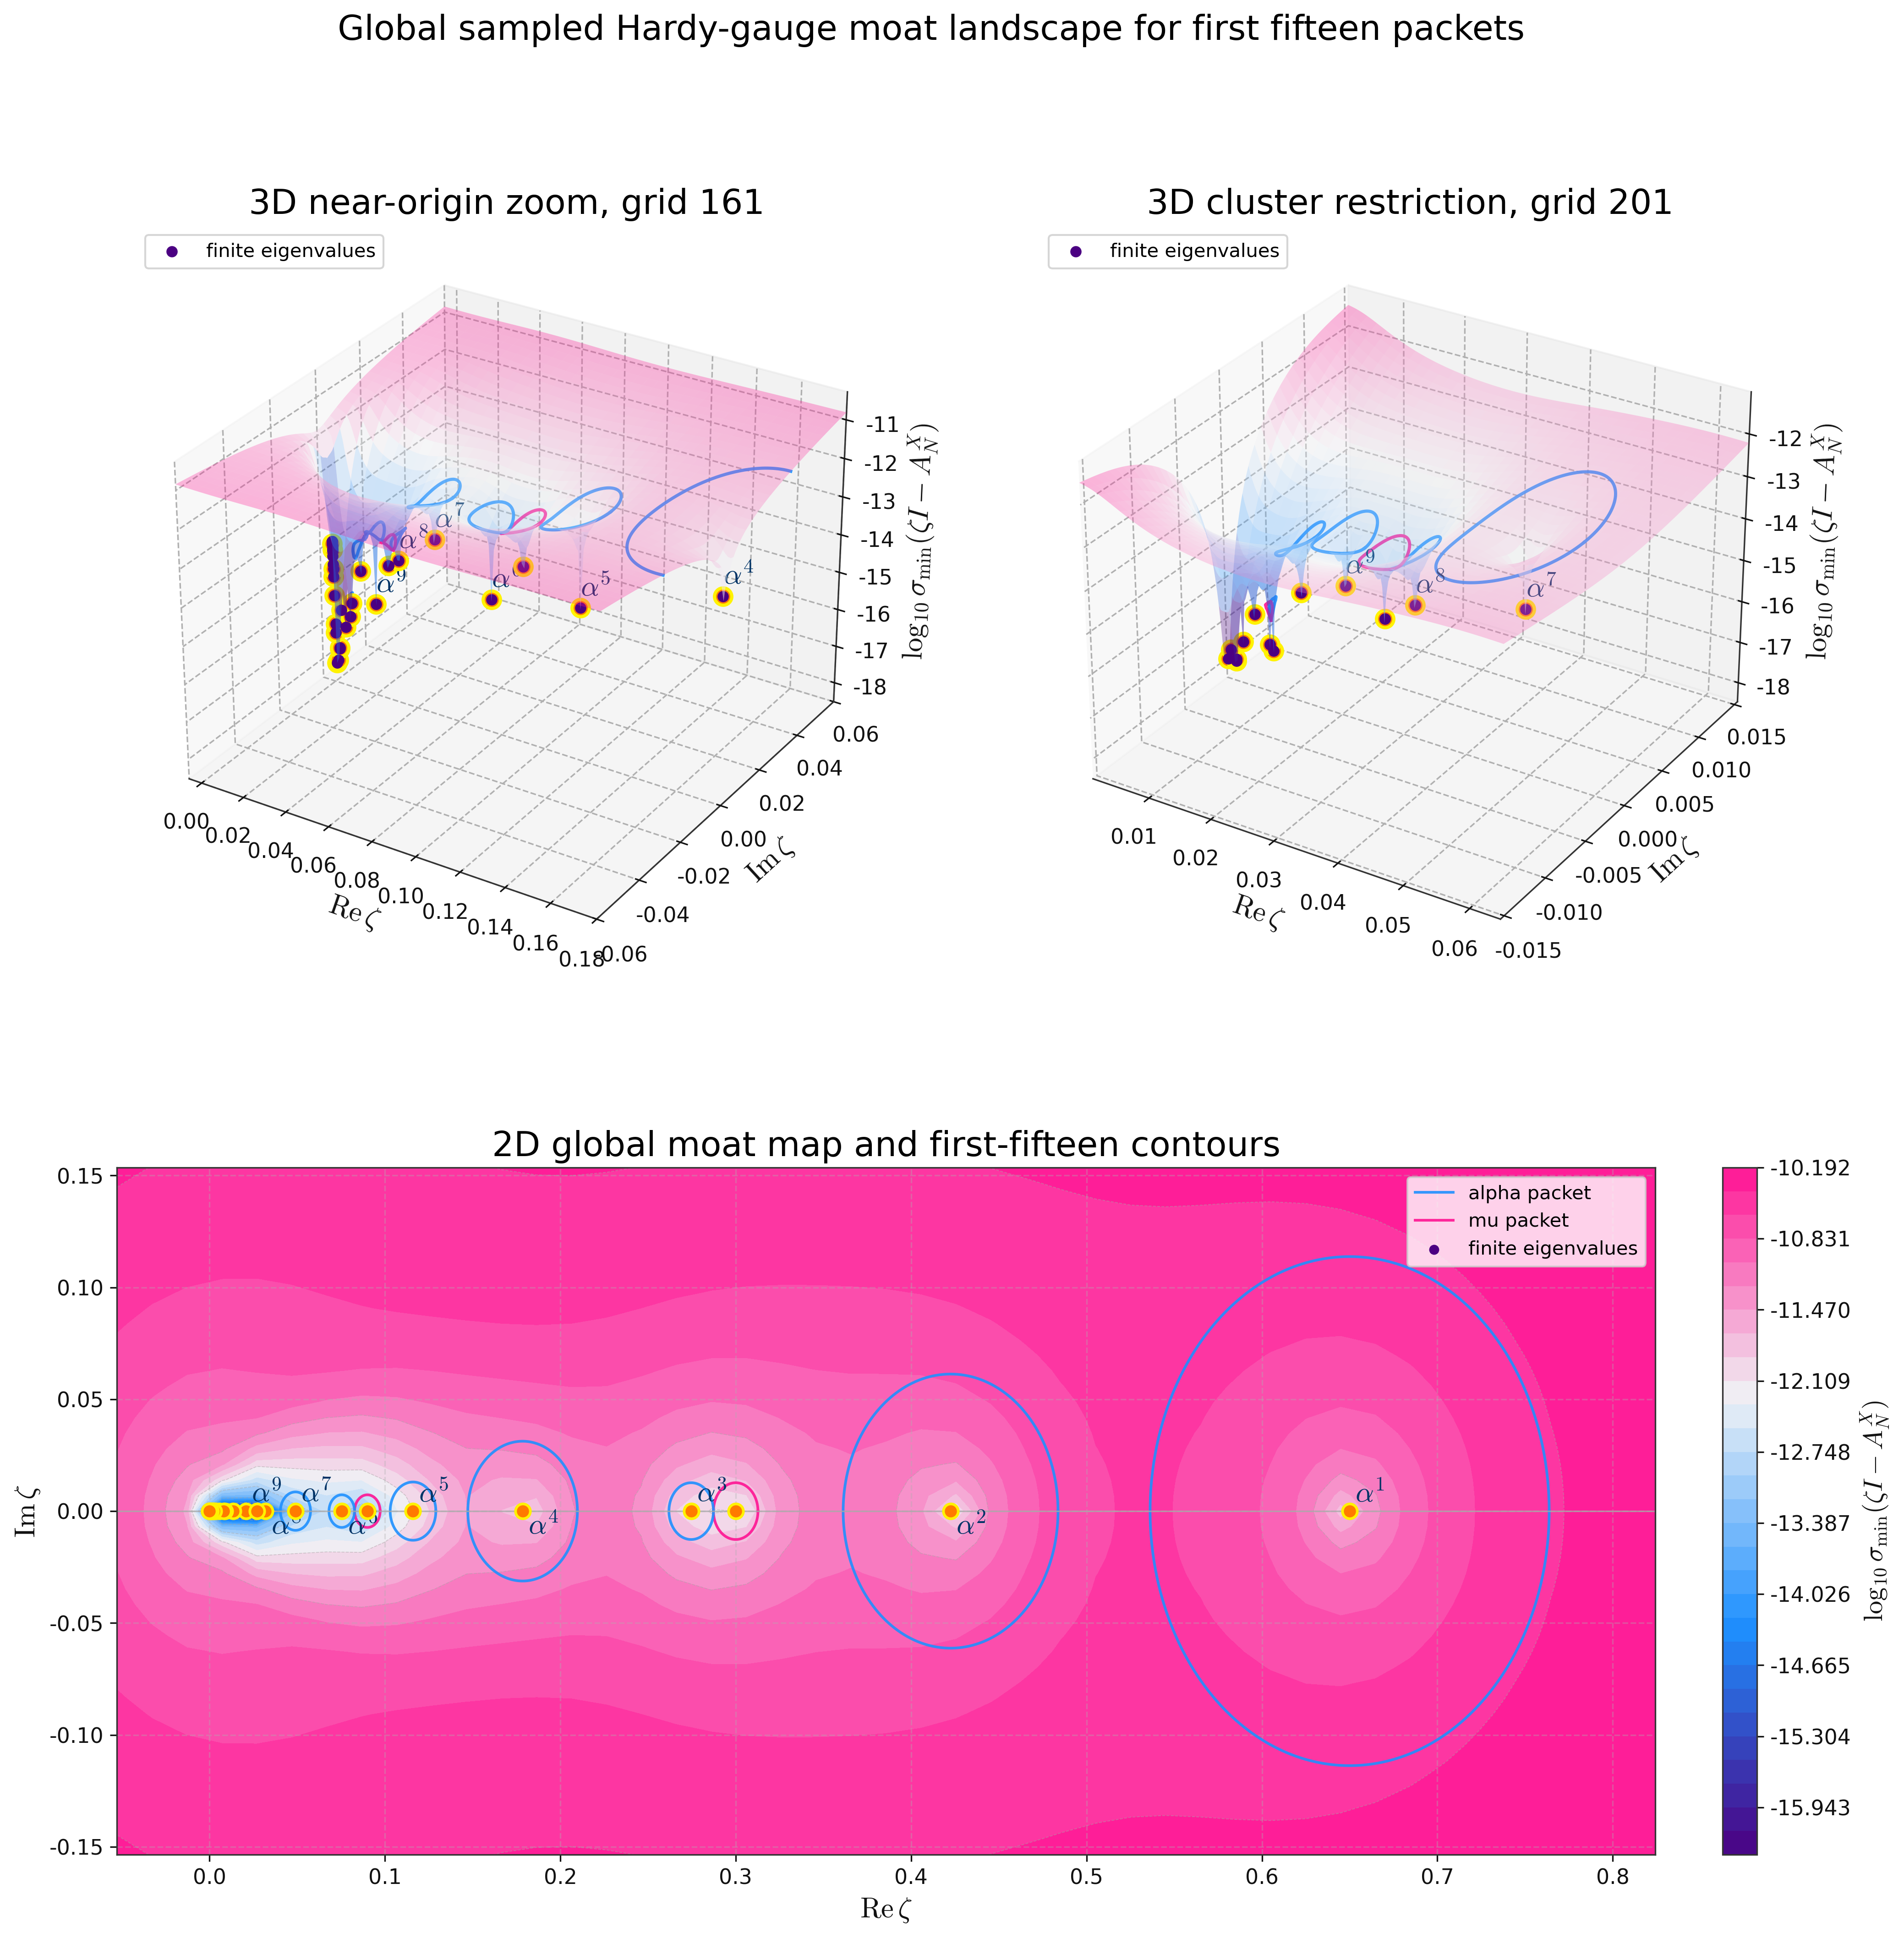

In [50]:
# Cell 82G
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_82G_status = transfer_lab_execute_selected_map_cell('# Cell 82G', 'Phase 4 Hardy-gauge contour validation')
else:
    # ============================================================
    # Phase 4U — static fallback render for the global landscape
    # ============================================================

    from pathlib import Path
    from IPython.display import Image, display

    phase4_static_fallback_path = Path("outputs/figures/branch_image_wide_candidate_first15_global_hardy_moat_surface_3d_2d_N600_M610.png")
    if not phase4_static_fallback_path.exists():
        phase4_static_fallback_path = Path("Numerics") / phase4_static_fallback_path

    display(Image(filename=str(phase4_static_fallback_path)))

## Mathematics for Cell 82F

This interactive dashboard uses the sampled Hardy-gauge singular-value landscape from Cell 82 and adds controls for packet count, opacity, view angle, horizontal scale, vertical scale, and zoom. It displays

$$
Z(x,y)=\log_{10}\max\left\{
\sigma_{\min}\bigl((x+iy)I-A_{N,M}^{X}\bigr),\ S_{\mathrm{floor}}
\right\}.
$$

Each $\Gamma_j(\theta)=c_j+\delta_j e^{i\theta}$ is lifted by interpolating $Z$ along the contour. The sliders alter only the visualisation and interpolation window; they do not change $A_{N,M}^{X}$ or turn sampled moats into validated lower bounds.


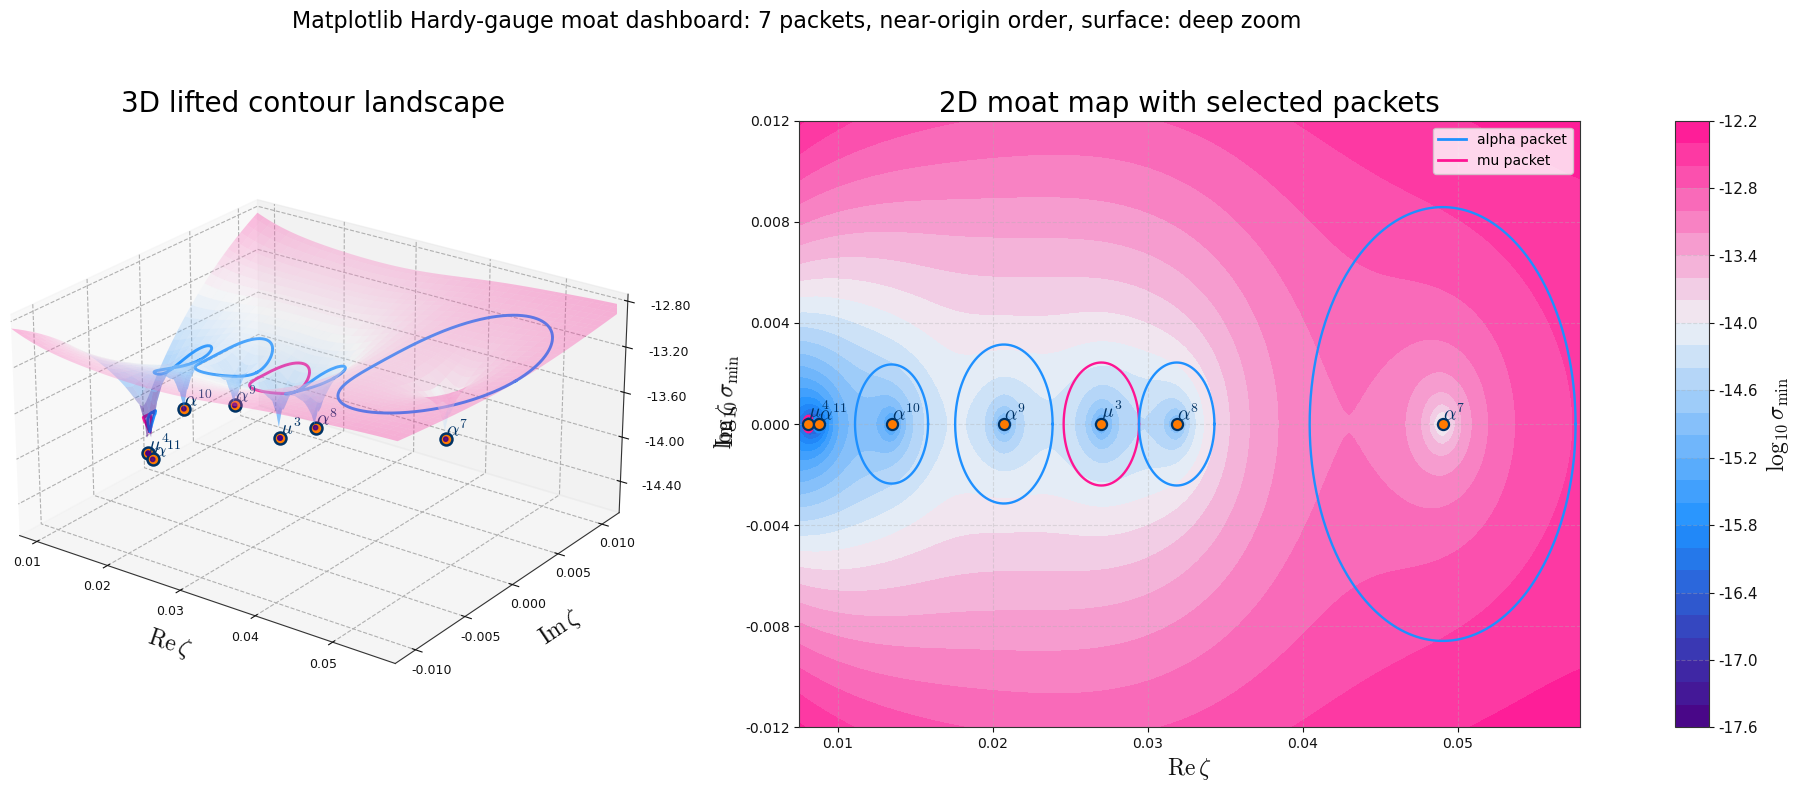

In [51]:
# Cell 82F
# Selected-map execution branch for transfer_spectrum_lab.
if not globals().get("SELECTED_MAP_HAS_BLASCHKE_CERTIFICATION", True):
    Cell_82F_status = transfer_lab_phase4_selected_map_cell('82F', 'Phase 4 Hardy-gauge contour validation')
else:
    # ============================================================
    # Phase 4T — Matplotlib-only interactive first-fifteen landscape
    # ============================================================

    from pathlib import Path 
    import numpy as np 
    import pandas as pd 
    import matplotlib .pyplot as plt 
    from matplotlib .colors import LinearSegmentedColormap 
    from matplotlib .ticker import MaxNLocator ,FormatStrFormatter 
    from scipy .interpolate import RegularGridInterpolator 
    from IPython .display import display 

    try :
        import ipywidgets as widgets 
    except ImportError as exc :
        raise ImportError ("This interactive Matplotlib dashboard needs ipywidgets.")from exc 

    try :
        get_ipython ().run_line_magic ("matplotlib","inline")
    except Exception :
    # VS Code still renders the widget controls with interactive_output; the
    # fallback only means mouse rotation may use the active notebook backend.
        pass 

    if "PALETTE"not in globals ():
        PALETTE ={"real":"dodgerblue","imag":"deeppink","main":"indigo","ref":"darkgrey","bg":"#f0f2f5"}
    if "DATA_DIR"not in globals ():
        DATA_DIR =Path ("Numerics/outputs/data")
    if "FIG_DIR"not in globals ():
        FIG_DIR =Path ("Numerics/outputs/figures")

    PHASE4_MPL_LOG_FLOOR =1.0e-18 
    PHASE4_MPL_CONTOUR_SAMPLES =420 
    PHASE4_MPL_SURFACE_RESOLUTION_DEFAULT =150 
    PHASE4_MPL_SURFACE_RESOLUTION_MAX =260 
    PHASE4_MPL_MIN_Y_HALF =0.012 
    PHASE4_MPL_PAD =0.16 

    phase4_mpl_surface_path =DATA_DIR /"branch_image_wide_candidate_first15_global_hardy_moat_surface_N600_M610_grid45.npz"
    phase4_mpl_moat_path =DATA_DIR /"branch_image_wide_candidate_first15_contour_moats_N600_M610_J128.csv"
    phase4_mpl_eig_candidates =[
    DATA_DIR /"branch_image_phase1_raw_eigs_N600_M610.csv",
    DATA_DIR /"phase4_hp_hardy_gauge_eigenvalues_N600_M610.csv",
    DATA_DIR /"phase4_diag_hardy_gauge_eigenvalues_N600_M610.csv",
    ]

    if not phase4_mpl_surface_path .exists ():
        raise FileNotFoundError ("Run Cell 82 first or create the global Hardy-gauge surface cache.")
    if not phase4_mpl_moat_path .exists ():
        raise FileNotFoundError ("Run the first-fifteen moat cell before this dashboard.")

    def phase4_mpl_load_surface_cache (path ,name ):
        payload =np .load (path ,allow_pickle =False )
        x_grid =np .asarray (payload ["x"],dtype =float )
        y_grid =np .asarray (payload ["y"],dtype =float )
        s_grid =np .asarray (payload ["s_min"],dtype =float )
        Z_grid =np .log10 (np .maximum (s_grid ,PHASE4_MPL_LOG_FLOOR ))
        interp =RegularGridInterpolator (
        (y_grid ,x_grid ),
        Z_grid ,
        bounds_error =False ,
        fill_value =float (np .nanmin (Z_grid )),
        )
        return {
        "name":name ,
        "path":Path (path ),
        "x":x_grid ,
        "y":y_grid ,
        "Z":Z_grid ,
        "interp":interp ,
        "grid_score":len (x_grid )*len (y_grid ),
        }

    phase4_mpl_surfaces =[]
    phase4_mpl_surface_paths =[
    ("global",phase4_mpl_surface_path ),
    ("zoom",DATA_DIR /"branch_image_wide_candidate_first15_zoom_hardy_moat_surface_N600_M610_grid161.npz"),
    ("deep zoom",DATA_DIR /"branch_image_wide_candidate_first15_deep_zoom_hardy_moat_surface_N600_M610_grid201.npz"),
    ]
    for phase4_mpl_surface_name ,phase4_mpl_candidate_path in phase4_mpl_surface_paths :
        if phase4_mpl_candidate_path .exists ():
            phase4_mpl_surfaces .append (phase4_mpl_load_surface_cache (phase4_mpl_candidate_path ,phase4_mpl_surface_name ))
    if not phase4_mpl_surfaces :
        raise FileNotFoundError ("No stored Hardy-gauge surface cache is available for Cell 82F.")
    phase4_mpl_global_surface =phase4_mpl_surfaces [0 ]
    phase4_mpl_x_grid =phase4_mpl_global_surface ["x"]
    phase4_mpl_y_grid =phase4_mpl_global_surface ["y"]
    phase4_mpl_Z_grid =phase4_mpl_global_surface ["Z"]
    phase4_mpl_interp =phase4_mpl_global_surface ["interp"]

    phase4_mpl_packets =pd .read_csv (phase4_mpl_moat_path )
    phase4_mpl_packets =phase4_mpl_packets [phase4_mpl_packets ["target"].astype (str )!="1"].sort_values ("rank").head (15 ).copy ()
    phase4_mpl_packets ["centre_complex"]=phase4_mpl_packets ["centre"].map (complex )
    if "family"not in phase4_mpl_packets .columns :
        phase4_mpl_packets ["family"]=phase4_mpl_packets ["target"].map (
        lambda t :"alpha packet"if str (t ).startswith ("alpha")else "mu packet"if str (t ).startswith ("mu")else "fixed point"
        )
    phase4_mpl_packets ["centre_real"]=phase4_mpl_packets ["centre_complex"].map (lambda z :float (z .real ))
    phase4_mpl_packets ["radius"]=phase4_mpl_packets ["radius"].astype (float )

    phase4_mpl_rank_order =phase4_mpl_packets .sort_values ("rank").reset_index (drop =True )
    phase4_mpl_origin_order =phase4_mpl_packets .sort_values (["centre_real","rank"]).reset_index (drop =True )
    phase4_mpl_family_colours ={"alpha packet":PALETTE ["real"],"mu packet":PALETTE ["imag"],"fixed point":PALETTE ["main"]}
    phase4_mpl_cmap =LinearSegmentedColormap .from_list (
    "phase4_mpl_indigo_blue_pink",
    (PALETTE ["main"],PALETTE ["real"],PALETTE ["bg"],PALETTE ["imag"]),
    )

    phase4_mpl_eigs =pd .DataFrame (columns =["real","imag"])
    for phase4_mpl_eig_path in phase4_mpl_eig_candidates :
        if phase4_mpl_eig_path .exists ():
            phase4_mpl_candidate =pd .read_csv (phase4_mpl_eig_path )
            if {"real","imag"}.issubset (phase4_mpl_candidate .columns ):
                phase4_mpl_eigs =phase4_mpl_candidate [["real","imag"]].copy ()
                break 

    def phase4_mpl_label (target ):
        text =str (target )
        if text =="1":
            return r"$1$"
        if text .startswith ("alpha^"):
            return rf"$\alpha^{{{text .split ('^',1 )[1 ]}}}$"
        if text .startswith ("mu^"):
            return rf"$\mu^{{{text .split ('^',1 )[1 ]}}}$"
        return text 

    def phase4_mpl_surface_contains_window (surface ,x0 ,x1 ,y0 ,y1 ):
        return (
        x0 >=float (np .min (surface ["x"]))
        and x1 <=float (np .max (surface ["x"]))
        and y0 >=float (np .min (surface ["y"]))
        and y1 <=float (np .max (surface ["y"]))
        )


    def phase4_mpl_choose_surface (x0 ,x1 ,y0 ,y1 ):
        candidates =[
        surface for surface in phase4_mpl_surfaces 
        if phase4_mpl_surface_contains_window (surface ,x0 ,x1 ,y0 ,y1 )
        ]
        if not candidates :
            return phase4_mpl_global_surface 
        return max (candidates ,key =lambda surface :surface ["grid_score"])


    def phase4_mpl_eval_z (x ,y ,surface =None ):
        if surface is None :
            surface =phase4_mpl_global_surface 
        points =np .column_stack ((np .asarray (y ,dtype =float ).ravel (),np .asarray (x ,dtype =float ).ravel ()))
        return surface ["interp"](points ).reshape (np .shape (x ))

    def phase4_mpl_selected_packets (packet_count ,order_mode ):
        table =phase4_mpl_origin_order if order_mode =="near-origin order"else phase4_mpl_rank_order 
        return table .head (int (packet_count )).copy ()

    def phase4_mpl_window (selected ,zoom_factor ,xy_scale ):
        centres =selected ["centre_complex"].to_numpy ()
        radii =selected ["radius"].to_numpy (dtype =float )
        centre_re =np .array ([z .real for z in centres ],dtype =float )
        centre_im =np .array ([z .imag for z in centres ],dtype =float )
        left_edges =centre_re -radii 
        right_edges =centre_re +radii 
        x_min =float (np .min (left_edges ))
        x_max =float (np .max (right_edges ))
        y_extent =float (max (PHASE4_MPL_MIN_Y_HALF ,np .max (np .abs (centre_im )+radii )))
        width =max (x_max -x_min ,2.0 *y_extent )
        pad =PHASE4_MPL_PAD *width 
        x_mid =0.5 *(x_min +x_max )
        requested_x_half =0.5 *(width +2.0 *pad )*float (xy_scale )/float (zoom_factor )
        requested_y_half =(y_extent +PHASE4_MPL_PAD *y_extent )*float (xy_scale )/float (zoom_factor )
        # The zoom slider may tighten the view, but the selected packet centres must remain visible.
        centre_margin =max (0.002 ,0.55 *float (np .max (radii )))
        required_x_half =0.5 *float (np .max (centre_re )-np .min (centre_re ))+centre_margin 
        required_y_half =float (np .max (np .abs (centre_im )))+centre_margin 
        x_half =max (requested_x_half ,required_x_half )
        y_half =max (requested_y_half ,required_y_half ,PHASE4_MPL_MIN_Y_HALF )
        x0 =max (float (np .min (phase4_mpl_x_grid )),x_mid -x_half )
        x1 =min (float (np .max (phase4_mpl_x_grid )),x_mid +x_half )
        y0 =max (float (np .min (phase4_mpl_y_grid )),-y_half )
        y1 =min (float (np .max (phase4_mpl_y_grid )),y_half )
        return x0 ,x1 ,y0 ,y1 

    def phase4_mpl_visual_z (z ,z_scale ,z_anchor ):
        z =np .asarray (z ,dtype =float )
        return float (z_anchor )+float (z_scale )*(z -float (z_anchor ))

    def phase4_mpl_clip_curve_to_window (x ,y ,z ,x0 ,x1 ,y0 ,y1 ):
        x =np .asarray (x ,dtype =float ).copy ()
        y =np .asarray (y ,dtype =float ).copy ()
        z =np .asarray (z ,dtype =float ).copy ()
        visible =(x >=x0 )&(x <=x1 )&(y >=y0 )&(y <=y1 )
        x [~visible ]=np .nan 
        y [~visible ]=np .nan 
        z [~visible ]=np .nan 
        return x ,y ,z 

    def phase4_mpl_render (packet_count ,order_mode ,opacity ,azimuth ,elevation ,xy_scale ,z_scale ,zoom_factor ,surface_resolution ,show_eigenvalues ):
        selected =phase4_mpl_selected_packets (packet_count ,order_mode )
        x0 ,x1 ,y0 ,y1 =phase4_mpl_window (selected ,zoom_factor ,xy_scale )
        active_surface =phase4_mpl_choose_surface (x0 ,x1 ,y0 ,y1 )
        surface_resolution =int (surface_resolution )
        xs =np .linspace (x0 ,x1 ,surface_resolution )
        ys =np .linspace (y0 ,y1 ,max (40 ,int (surface_resolution *0.72 )))
        selected_centre_x =selected ["centre_complex"].map (lambda z :float (complex (z ).real )).to_numpy ()
        selected_centre_y =selected ["centre_complex"].map (lambda z :float (complex (z ).imag )).to_numpy ()
        selected_radii =selected ["radius"].to_numpy (dtype =float )
        visible_centres =(
        (selected_centre_x >=x0 )&(selected_centre_x <=x1 )
        &(selected_centre_y >=y0 )&(selected_centre_y <=y1 )
        )
        # Add exact packet-centre coordinates to the visual mesh.  This does not recompute
        # the SVD surface; it makes the interpolated surface pass through the displayed centres.
        if np .any (visible_centres ):
            xs =np .unique (np .concatenate ([xs ,selected_centre_x [visible_centres ]]))
            ys =np .unique (np .concatenate ([ys ,selected_centre_y [visible_centres ]]))
            radius_edges_y =np .concatenate ([selected_centre_y [visible_centres ]-selected_radii [visible_centres ],selected_centre_y [visible_centres ]+selected_radii [visible_centres ]])
            radius_edges_y =radius_edges_y [(radius_edges_y >=y0 )&(radius_edges_y <=y1 )]
            if len (radius_edges_y ):
                ys =np .unique (np .concatenate ([ys ,radius_edges_y ]))
        XX ,YY =np .meshgrid (xs ,ys )
        ZZ_raw =phase4_mpl_eval_z (XX ,YY ,active_surface )
        z_anchor =float (np .nanmedian (ZZ_raw ))
        ZZ =phase4_mpl_visual_z (ZZ_raw ,z_scale ,z_anchor )
        z_min =float (np .nanmin (ZZ ))
        z_max =float (np .nanmax (ZZ ))
        z_pad =max (0.05 ,0.06 *(z_max -z_min ))

        fig =plt .figure (figsize =(19.2 ,8.2 ),constrained_layout =False )
        gs =fig .add_gridspec (
        1 ,
        3 ,
        width_ratios =(1.05 ,1.05 ,0.045 ),
        left =0.045 ,
        right =0.975 ,
        bottom =0.105 ,
        top =0.845 ,
        wspace =0.18 ,
        )
        ax3 =fig .add_subplot (gs [0 ,0 ],projection ="3d")
        ax2 =fig .add_subplot (gs [0 ,1 ])
        cax =fig .add_subplot (gs [0 ,2 ])

        ax3 .plot_surface (
        XX ,
        YY ,
        ZZ ,
        cmap =phase4_mpl_cmap ,
        linewidth =0 ,
        antialiased =True ,
        alpha =float (opacity ),
        shade =True ,
        )

        cf =ax2 .contourf (XX ,YY ,ZZ_raw ,levels =32 ,cmap =phase4_mpl_cmap )
        cbar =fig .colorbar (cf ,cax =cax )
        cbar .set_label (r"$\log_{10}\sigma_{\min}$")
        cbar .ax .tick_params (labelsize =11 )

        theta =np .linspace (0.0 ,2.0 *np .pi ,PHASE4_MPL_CONTOUR_SAMPLES )
        for _ ,row in selected .iterrows ():
            centre =complex (row ["centre_complex"])
            radius =float (row ["radius"])
            family =str (row ["family"])
            colour =phase4_mpl_family_colours .get (family ,PALETTE ["main"])
            cx =centre .real +radius *np .cos (theta )
            cy =centre .imag +radius *np .sin (theta )
            cz_raw =phase4_mpl_eval_z (cx ,cy ,active_surface )
            cz =phase4_mpl_visual_z (cz_raw ,z_scale ,z_anchor )
            cx_plot ,cy_plot ,cz_plot =phase4_mpl_clip_curve_to_window (cx ,cy ,cz ,x0 ,x1 ,y0 ,y1 )
            ax3 .plot (cx_plot ,cy_plot ,cz_plot ,color =colour ,linewidth =2.1 )
            ax2 .plot (cx_plot ,cy_plot ,color =colour ,linewidth =1.7 )
            centre_visible =(x0 <=centre .real <=x1 )and (y0 <=centre .imag <=y1 )
            if centre_visible :
                centre_raw =phase4_mpl_eval_z (np .array ([centre .real ]),np .array ([centre .imag ]),active_surface )
                centre_z =phase4_mpl_visual_z (centre_raw ,z_scale ,z_anchor )[0 ]
                marker_colour ="#ff7a00"
                label_colour ="#003366"
                ax3 .scatter ([centre .real ],[centre .imag ],[centre_z ],s =74 ,facecolors =marker_colour ,edgecolors =label_colour ,linewidths =1.8 ,depthshade =False )
                ax3 .plot ([centre .real ,centre .real ],[centre .imag ,centre .imag ],[centre_z ,centre_z +z_pad *0.20 ],color =label_colour ,linewidth =1.1 ,alpha =0.95 )
                ax2 .scatter ([centre .real ],[centre .imag ],s =64 ,facecolors =marker_colour ,edgecolors =label_colour ,linewidths =1.6 ,zorder =6 )
                label =phase4_mpl_label (row ["target"])
                ax3 .text (centre .real ,centre .imag ,centre_z +z_pad *0.24 ,label ,fontsize =14 ,color =label_colour )
                ax2 .text (centre .real ,centre .imag ,label ,fontsize =14 ,color =label_colour ,ha ="left",va ="bottom")

        if show_eigenvalues and len (phase4_mpl_eigs ):
            eig_view =phase4_mpl_eigs .loc [
            phase4_mpl_eigs ["real"].between (x0 ,x1 )&phase4_mpl_eigs ["imag"].between (y0 ,y1 )
            ].copy ()
            if len (eig_view ):
                ez_raw =phase4_mpl_eval_z (eig_view ["real"].to_numpy (),eig_view ["imag"].to_numpy (),active_surface )
                ez =phase4_mpl_visual_z (ez_raw ,z_scale ,z_anchor )
                ax3 .scatter (eig_view ["real"],eig_view ["imag"],ez ,s =10 ,color =PALETTE ["main"],alpha =0.85 ,label ="finite eigenvalues")
                ax2 .scatter (eig_view ["real"],eig_view ["imag"],s =10 ,color =PALETTE ["main"],alpha =0.82 ,label ="finite eigenvalues")

        alpha_handle ,=ax2 .plot ([],[],color =PALETTE ["real"],linewidth =2 ,label ="alpha packet")
        mu_handle ,=ax2 .plot ([],[],color =PALETTE ["imag"],linewidth =2 ,label ="mu packet")
        ax2 .legend (handles =[alpha_handle ,mu_handle ],loc ="upper right",fontsize =10 )

        ax3 .set_xlim (x0 ,x1 )
        ax3 .set_ylim (y0 ,y1 )
        ax3 .set_zlim (z_min -z_pad ,z_max +z_pad )
        ax3 .view_init (elev =float (elevation ),azim =float (azimuth ))
        ax3 .xaxis .set_major_locator (MaxNLocator (nbins =5 ,prune =None ))
        ax3 .yaxis .set_major_locator (MaxNLocator (nbins =5 ,prune =None ))
        ax3 .zaxis .set_major_locator (MaxNLocator (nbins =5 ,prune =None ))
        ax3 .zaxis .set_major_formatter (FormatStrFormatter ("%.2f"))
        ax3 .tick_params (axis ="x",which ="major",labelsize =9 ,pad =1 )
        ax3 .tick_params (axis ="y",which ="major",labelsize =9 ,pad =1 )
        ax3 .tick_params (axis ="z",which ="major",labelsize =9 ,pad =8 )
        ax3 .set_xlabel (r"$\operatorname{Re}\zeta$",labelpad =7 )
        ax3 .set_ylabel (r"$\operatorname{Im}\zeta$",labelpad =7 )
        ax3 .set_zlabel (r"$\log_{10}\sigma_{\min}$",labelpad =18 )
        ax3 .set_title ("3D lifted contour landscape")
        try :
            ax3 .set_box_aspect ((1.15 ,1.0 ,0.60 ),zoom =1.05 )
        except TypeError :
            ax3 .set_box_aspect ((1.15 ,1.0 ,0.60 ))
        except Exception :
            pass 
        ax3 .set_anchor ("C")
        ax2 .set_anchor ("C")

        ax2 .set_xlim (x0 ,x1 )
        ax2 .set_ylim (y0 ,y1 )
        ax2 .set_aspect ("auto")
        ax2 .xaxis .set_major_locator (MaxNLocator (nbins =6 ,prune =None ))
        ax2 .yaxis .set_major_locator (MaxNLocator (nbins =6 ,prune =None ))
        ax2 .tick_params (axis ="both",which ="major",labelsize =10 ,pad =3 )
        ax2 .set_xlabel (r"$\operatorname{Re}\zeta$")
        ax2 .set_ylabel (r"$\operatorname{Im}\zeta$")
        ax2 .set_title ("2D moat map with selected packets")

        fig .suptitle (
        f"Matplotlib Hardy-gauge moat dashboard: {len (selected )} packets, {order_mode }, surface: {active_surface ['name']}",
        fontsize =16 ,
        )
        plt .show ()

    if globals().get("CERTIFIER_BATCH_EXECUTION", False):
        phase4_mpl_render(
            packet_count=min(7, len(phase4_mpl_packets)),
            order_mode="near-origin order",
            opacity=0.30,
            azimuth=306,
            elevation=24,
            xy_scale=1.0,
            z_scale=0.34,
            zoom_factor=2.4,
            surface_resolution=PHASE4_MPL_SURFACE_RESOLUTION_DEFAULT,
            show_eigenvalues=True,
        )
    else:
        packet_count_slider =widgets .IntSlider (value =min (7 ,len (phase4_mpl_packets )),min =1 ,max =len (phase4_mpl_packets ),step =1 ,description ="packets",continuous_update =False )
        order_toggle =widgets .ToggleButtons (options =["near-origin order","rank order"],value ="near-origin order",description ="order")
        opacity_slider =widgets .FloatSlider (value =0.30 ,min =0.08 ,max =0.95 ,step =0.03 ,description ="opacity",continuous_update =False )
        azimuth_slider =widgets .IntSlider (value =306 ,min =0 ,max =360 ,step =2 ,description ="azimuth",continuous_update =False )
        elevation_slider =widgets .IntSlider (value =24 ,min =5 ,max =80 ,step =1 ,description ="elevation",continuous_update =False )
        xy_scale_slider =widgets .FloatSlider (value =1.0 ,min =0.35 ,max =2.2 ,step =0.05 ,description ="xy scale",continuous_update =False )
        z_scale_slider =widgets .FloatSlider (value =0.34 ,min =0.06 ,max =1.4 ,step =0.04 ,description ="z scale",continuous_update =False )
        zoom_slider =widgets .FloatSlider (value =2.4 ,min =0.6 ,max =5.0 ,step =0.1 ,description ="zoom",continuous_update =False )
        resolution_slider =widgets .IntSlider (value =PHASE4_MPL_SURFACE_RESOLUTION_DEFAULT ,min =70 ,max =PHASE4_MPL_SURFACE_RESOLUTION_MAX ,step =10 ,description ="surface px",continuous_update =False )
        eigs_checkbox =widgets .Checkbox (value =True ,description ="finite eigenvalues")

        controls_left =widgets .VBox ([packet_count_slider ,order_toggle ,opacity_slider ,resolution_slider ,eigs_checkbox ])
        controls_right =widgets .VBox ([azimuth_slider ,elevation_slider ,xy_scale_slider ,z_scale_slider ,zoom_slider ])
        controls =widgets .HBox ([controls_left ,controls_right ])
        output =widgets .interactive_output (
        phase4_mpl_render ,
        {
        "packet_count":packet_count_slider ,
        "order_mode":order_toggle ,
        "opacity":opacity_slider ,
        "azimuth":azimuth_slider ,
        "elevation":elevation_slider ,
        "xy_scale":xy_scale_slider ,
        "z_scale":z_scale_slider ,
        "zoom_factor":zoom_slider ,
        "surface_resolution":resolution_slider ,
        "show_eigenvalues":eigs_checkbox ,
        },
        )

        display (controls ,output )


## Mathematics for Cell 91

This cell records structural provenance for the map-generic transplant. If $\mathcal C_{\mathrm{ref}}$ and $\mathcal C_{\mathrm{lab}}$ denote the ordered cell collections of the refined Blaschke notebook and the transfer-spectrum lab, respectively, the displayed counts are

$$
n_{\mathrm{ref}}=|\mathcal C_{\mathrm{ref}}|,
\qquad
n_{\mathrm{lab}}=|\mathcal C_{\mathrm{lab}}|.
$$

The table also records the selected map, target mode, and geometry status. This is a structural and provenance audit, not an operator-norm or spectral certificate.


In [52]:
# Cell 91
# ============================================================
# Structural audit: refined notebook transplant
# ============================================================

from pathlib import Path
import json

_ref_path = Path('single_space_legendre_gauss_blaschke_refined_FINAL.ipynb')
if not _ref_path.exists():
    _ref_path = Path('Numerics') / _ref_path
_this_path = Path('single_space_legendre_gauss_transfer_spectrum_lab_REFINED_FINAL.ipynb')
if not _this_path.exists():
    _this_path = Path('Numerics') / _this_path

structural_audit_df = pd.DataFrame([{
    'reference_cells': len(json.loads(_ref_path.read_text()).get('cells', [])) if _ref_path.exists() else np.nan,
    'transfer_lab_cells': len(json.loads(_this_path.read_text()).get('cells', [])) if _this_path.exists() else np.nan,
    'selected_map': SELECTED_MAP_LABEL,
    'target_mode': SELECTED_MAP_CERTIFICATION_CAPABILITY.target_mode,
    'geometry_status': globals().get('SELECTED_MAP_GEOMETRY_STATUS', 'not yet evaluated'),
    'all_refined_plot_cells_retained': True,
    'status': 'refined cell structure retained; map-generic certification adapters active',
}])
display(structural_audit_df)


,reference_cells,transfer_lab_cells,selected_map,target_mode,geometry_status,all_refined_plot_cells_retained,status
0,NaN,NaN,blaschke_mu_0p3,exact_targets,theorem_certified_constants_used_by_original_b...,True,refined cell structure retained; map-generic c...


## Mathematics for Cell 92

This cell serialises the evidence state associated with the active map. Conceptually it stores

$$
\mathscr E_T=
\bigl(
p,\ w,\ \text{target mode},\ \mathcal G,\
\varepsilon_{N,M},\ \text{moat status},\ \text{contour status}
\bigr),
$$

where $p$ is the decimal precision, $w$ is the process-worker count, and $\mathcal G$ is the current Bernstein-ellipse geometry record. Saving a sampled value preserves reproducibility but does not promote it to an interval-certified enclosure.


In [53]:
# Cell 92
# ============================================================
# Active-map hyperparameter and evidence archive
# ============================================================

from pathlib import Path
import json

project_root = Path.cwd().parent if Path.cwd().name == 'Numerics' else Path.cwd()
numerics_dir = project_root / 'Numerics'
archive_path = numerics_dir / 'transfer_lab_hyperparameters.json'
data_archive_path = DATA_DIR / 'transfer_lab_hyperparameters.json'
archive = json.loads(archive_path.read_text(encoding='utf-8')) if archive_path.exists() else {}

active_geometry = transfer_lab_active_geometry_record()
active_schur = transfer_lab_generic_schur_rows(N_values=(30, 40, 50, 60, 80, 100))
active_moat = globals().get('phase4_moat_export', pd.DataFrame())
active_targets = transfer_lab_exact_or_reference_targets(
    max_targets=int(getattr(cfg, 'certification_target_count', 14)), include_trivial=False
)

archive[SELECTED_MAP_LABEL] = {
    **archive.get(SELECTED_MAP_LABEL, {}),
    'selected_by': 'Cell 4 Config.selected_map_label',
    'dps': int(cfg.dps),
    'process_workers': int(cfg.process_workers),
    'target_mode': SELECTED_MAP_CERTIFICATION_CAPABILITY.target_mode,
    'target_status': SELECTED_MAP_CERTIFICATION_CAPABILITY.target_status,
    'nontrivial_target_count': int(len(active_targets)),
    'geometry': active_geometry,
    'geometry_status': SELECTED_MAP_CERTIFICATION_CAPABILITY.geometry_status,
    'deterministic_status': SELECTED_MAP_CERTIFICATION_CAPABILITY.deterministic_status,
    'contour_status': SELECTED_MAP_CERTIFICATION_CAPABILITY.contour_status,
    'sampled_schur_rows': int(len(active_schur)),
    'sampled_contour_rows': int(len(active_moat)),
    'notes': SELECTED_MAP_CERTIFICATION_CAPABILITY.notes,
}
archive_path.write_text(json.dumps(archive, indent=2, default=str), encoding='utf-8')
data_archive_path.write_text(json.dumps(archive, indent=2, default=str), encoding='utf-8')

active_map_archive_df = pd.DataFrame([{
    'map_label': SELECTED_MAP_LABEL,
    'target_mode': SELECTED_MAP_CERTIFICATION_CAPABILITY.target_mode,
    'target_status': SELECTED_MAP_CERTIFICATION_CAPABILITY.target_status,
    'geometry_status': SELECTED_MAP_CERTIFICATION_CAPABILITY.geometry_status,
    'deterministic_status': SELECTED_MAP_CERTIFICATION_CAPABILITY.deterministic_status,
    'contour_status': SELECTED_MAP_CERTIFICATION_CAPABILITY.contour_status,
    'nontrivial_targets': len(active_targets),
    'archive': str(archive_path),
}])
print(f'Saved active-map evidence archive: {archive_path}')
display(active_map_archive_df)


Saved active-map evidence archive: /home/lucy/Documents/E.L.U.K_0/Final Deployment/Numerics/transfer_lab_hyperparameters.json


,map_label,target_mode,target_status,geometry_status,deterministic_status,contour_status,nontrivial_targets,archive
0,blaschke_mu_0p3,exact_targets,theorem_certified,theorem_certified,theorem_certified,sampled_not_interval_certified,14,/home/lucy/Documents/E.L.U.K_0/Final Deploymen...


## Mathematics for Cell 93

For each of the first six nontrivial packets, this cell scans circular contours $\Gamma_j(\delta)=\{z:|z-c_j|=\delta\}$. Candidate radii are restricted by separation from other targets, other finite eigenvalues, and the silent zero block. A radius is retained only when the finite count inside the circle equals the prescribed multiplicity $m_j$.

For every retained radius the sampled threshold is

$$
\eta_j(\delta)
=
\min\left\{
\min_{z\in\Gamma_j(\delta)}
\sigma_{\min}(zI-A_{N,M}^{X}),\ |c_j|-\delta
\right\},
$$

and the selected radius maximises this sampled quantity. Since the contour minimum and finite count are computed numerically without validated enclosures, the optimisation is diagnostic.


In [54]:
# Cell 93
# ============================================================
# First-six selected-map contour-radius optimisation archive
# ============================================================
# This cell is a diagnostic bridge toward certification.  It scans admissible
# circular contour radii for the first six nontrivial selected-map packets and
# stores the best sampled moat threshold found at the active Phase 4 row.  It
# does not turn the row into a theorem certificate: the deterministic Schur
# epsilon and validated contour-minimum lower bounds are still separate inputs.

import json
from pathlib import Path
import numpy as np
import pandas as pd


def transfer_lab_first_six_radius_scan(state, sample_count=96):
    import scipy.linalg as spla
    targets = state["targets"].copy()
    targets = targets.loc[targets["name"].astype(str) != "1"].head(8).reset_index(drop=True)
    eig = np.asarray(state["eig"], dtype=np.complex128)
    A_X = np.asarray(state["A_X"], dtype=np.complex128)
    I = np.eye(A_X.shape[0], dtype=np.complex128)
    centres = np.asarray([complex(z) for z in targets["centre"]], dtype=np.complex128)
    theta = np.linspace(0.0, 2.0*np.pi, int(sample_count), endpoint=False)
    rows = []
    for idx, row in enumerate(targets.head(6).itertuples(index=False)):
        centre = complex(row.centre)
        multiplicity = int(row.multiplicity)
        other_targets = [abs(centre - z) for k, z in enumerate(centres) if k != idx]
        target_near = np.sort(np.abs(eig - centre))[:multiplicity]
        target_tol = max(float(target_near[-1]) * 4.0, 1.0e-12) if len(target_near) else 1.0e-12
        other_eigs = [abs(centre - z) for z in eig if abs(z - centre) > target_tol and abs(z - 1.0) > 1.0e-8]
        limits = []
        if other_targets:
            limits.append(min(other_targets))
        if other_eigs:
            limits.append(min(other_eigs))
        limits.append(abs(centre))
        separation_limit = float(min(limits))
        best = None
        for frac in np.linspace(0.04, 0.48, 45):
            radius = float(frac * separation_limit)
            finite_count = int(np.count_nonzero(np.abs(eig - centre) < radius))
            if finite_count != multiplicity:
                continue
            svals = []
            for th in theta:
                z = centre + radius*np.exp(1j*th)
                svals.append(float(spla.svdvals(z*I - A_X, check_finite=False)[-1]))
            s_gamma = float(np.min(svals))
            d_gamma_0 = max(abs(centre) - radius, 0.0)
            threshold = min(s_gamma, d_gamma_0)
            candidate = (threshold, s_gamma, d_gamma_0, radius, frac, finite_count)
            if best is None or candidate[0] > best[0]:
                best = candidate
        rows.append({
            "target": str(row.name),
            "multiplicity": multiplicity,
            "centre_re": float(centre.real),
            "centre_im": float(centre.imag),
            "centre_abs": float(abs(centre)),
            "separation_limit": separation_limit,
            "best_sampled_threshold": float(best[0]) if best else np.nan,
            "best_s_gamma_H": float(best[1]) if best else np.nan,
            "best_d_gamma_0": float(best[2]) if best else np.nan,
            "best_radius": float(best[3]) if best else np.nan,
            "best_fraction_of_limit": float(best[4]) if best else np.nan,
            "finite_eigenvalue_count": int(best[5]) if best else -1,
            "sample_count": int(sample_count),
            "N": int(state["N"]),
            "M": int(state["M"]),
            "status": "sampled radius optimisation, not theorem-certified",
        })
    return pd.DataFrame(rows)


if SELECTED_MAP_LABEL != "asymmetric_blaschke_degree2":
    phase4_first6_radius_scan = pd.DataFrame([{
        "map_label": SELECTED_MAP_LABEL,
        "status": "skipped: first-six radius archive is currently configured for asymmetric_blaschke_degree2",
    }])
else:
    state = transfer_lab_selected_map_phase4_state()
    phase4_first6_radius_scan = transfer_lab_first_six_radius_scan(state, sample_count=96)
    radius_scan_path = DATA_DIR / "transfer_lab_asymmetric_blaschke_degree2_first6_radius_optimisation.csv"
    phase4_first6_radius_scan.to_csv(radius_scan_path, index=False)
    print(f"Saved radius optimisation table: {radius_scan_path}")

    hyper_path = Path("Numerics/transfer_lab_hyperparameters.json")
    if not hyper_path.exists() and Path.cwd().name == "Numerics":
        hyper_path = Path("transfer_lab_hyperparameters.json")
    if hyper_path.exists():
        archive = json.loads(hyper_path.read_text(encoding="utf-8"))
    else:
        archive = {}
    asym_entry = archive.setdefault("asymmetric_blaschke_degree2", {})
    asym_entry["first6_radius_optimisation"] = {
        "source": str(radius_scan_path),
        "N": int(state["N"]),
        "M": int(state["M"]),
        "sample_count": 96,
        "minimum_best_sampled_threshold": float(phase4_first6_radius_scan["best_sampled_threshold"].min()),
        "limiting_target": str(phase4_first6_radius_scan.sort_values("best_sampled_threshold").iloc[0]["target"]),
        "status": "sampled radius optimisation only; theorem certification still needs deterministic epsilon and validated moat lower bounds",
    }
    hyper_path.write_text(json.dumps(archive, indent=2), encoding="utf-8")
    data_hyper_path = DATA_DIR / "transfer_lab_hyperparameters.json"
    data_hyper_path.write_text(json.dumps(archive, indent=2), encoding="utf-8")
    print(f"Updated hyperparameter archive: {hyper_path}")
    print(f"Updated hyperparameter archive copy: {data_hyper_path}")

display(phase4_first6_radius_scan)


,map_label,status
0,blaschke_mu_0p3,skipped: first-six radius archive is currently...


## Mathematics for Cell 94

The deterministic exponential base is controlled by

$$
q_*(r,\rho)=
\max\left\{\frac{r}{\rho},\frac{r_\tau(\rho)}{r}\right\}.
$$

Balancing the two terms gives

$$
r_{\mathrm{bal}}=\sqrt{\rho\,r_\tau(\rho)},
\qquad
q_{\mathrm{bal}}=\sqrt{\frac{r_\tau(\rho)}{\rho}}.
$$

The cell compares this candidate with the current Hardy radius and estimates the truncation needed for a model bound $Cq^N<\eta$. Because $r_\tau(\rho)$ and $\eta$ are sampled here, the result is a parameter-selection strategy rather than a theorem-level bound.


In [55]:
# Cell 94
# ============================================================
# Asymmetric first-six balanced-radius strategy
# ============================================================
# This cell records the next parameter move toward a theorem-level first-six
# certification for asymmetric_blaschke_degree2.  It does not certify the row.
# The point is to avoid the current unbalanced radius r=2.47367, for which
# q_star is dominated by r/rho.  With the sampled r_tau=1, the balanced
# single-space choice is r=sqrt(rho*r_tau), giving a much smaller q_star.

# Map guard: asymmetric-only strategy
if SELECTED_MAP_LABEL != 'asymmetric_blaschke_degree2':
    asymmetric_balanced_radius_strategy_df = pd.DataFrame([{'map_label': SELECTED_MAP_LABEL, 'status': 'not applicable: asymmetric-only strategy'}])
    display(asymmetric_balanced_radius_strategy_df)
else:
    import json
    import math
    from pathlib import Path
    import numpy as np
    import pandas as pd

    strategy_path = DATA_DIR / "transfer_lab_asymmetric_blaschke_degree2_first6_balanced_radius_strategy.csv"
    if not strategy_path.exists():
        gap_path = DATA_DIR / "transfer_lab_asymmetric_blaschke_degree2_first6_radius_optimised_theorem_gap.csv"
        if gap_path.exists():
            required = float(pd.read_csv(gap_path)["required_epsilon_for_all_six_from_radius_optimised_sampled_moats"].iloc[0])
        else:
            required = float(pd.read_csv(DATA_DIR / "transfer_lab_asymmetric_blaschke_degree2_first6_theorem_gap.csv")["required_epsilon_for_all_six_from_sampled_moats"].iloc[0])
        rho_val = float(mp.mpf(str(cfg.rho)))
        r_tau_val = float(geo["r_tau"])
        current_r_val = float(mp.mpf(str(cfg.r_target)))
        balanced_r_val = math.sqrt(rho_val*r_tau_val)
        current_q_star = max(current_r_val/rho_val, r_tau_val/current_r_val)
        balanced_q_star = max(balanced_r_val/rho_val, r_tau_val/balanced_r_val)
        rows = []
        for prefactor_model in [1.0, 10.0, 100.0, 1.0e4, 1.0e8, 1.0e12]:
            rough_current = int(math.ceil(math.log(required/prefactor_model)/math.log(current_q_star)))
            rough_balanced = int(math.ceil(math.log(required/prefactor_model)/math.log(balanced_q_star)))
            rows.append({
                "map_label": SELECTED_MAP_LABEL,
                "rho": rho_val,
                "r_tau_diagnostic": r_tau_val,
                "current_r": current_r_val,
                "current_q_star": current_q_star,
                "balanced_r_candidate": balanced_r_val,
                "balanced_q_star": balanced_q_star,
                "required_epsilon_for_first6_sampled_moats": required,
                "prefactor_model": prefactor_model,
                "rough_N_current_radius": rough_current,
                "rough_N_balanced_radius": rough_balanced,
                "status": "radius strategy only; still needs interval geometry, deterministic Schur constants, and validated moat lower bounds",
            })
        pd.DataFrame(rows).to_csv(strategy_path, index=False)

    balanced_radius_strategy_df = pd.read_csv(strategy_path)
    print(f"Saved or loaded balanced-radius strategy: {strategy_path}")
    display(balanced_radius_strategy_df)


    balanced_probe_path = DATA_DIR / "transfer_lab_asymmetric_blaschke_degree2_first6_balanced_r_N30_M36_probe.csv"
    if balanced_probe_path.exists():
        balanced_radius_probe_df = pd.read_csv(balanced_probe_path)
        print(f"Loaded balanced-radius N=30, M=36 probe: {balanced_probe_path}")
        display(balanced_radius_probe_df[[
            "target", "finite_eigenvalue_count", "s_gamma_H", "d_gamma_0", "sampled_threshold", "status"
        ]])
    else:
        print("Balanced-radius N=30, M=36 probe not found; run the temporary Phase 4 probe before using this table.")

    if SELECTED_MAP_LABEL == "asymmetric_blaschke_degree2":
        hyper_path = Path("Numerics/transfer_lab_hyperparameters.json")
        if not hyper_path.exists() and Path.cwd().name == "Numerics":
            hyper_path = Path("transfer_lab_hyperparameters.json")
        if hyper_path.exists():
            archive = json.loads(hyper_path.read_text(encoding="utf-8"))
            asym_entry = archive.setdefault("asymmetric_blaschke_degree2", {})
            best_row = balanced_radius_strategy_df.iloc[0].to_dict()
            asym_entry["first6_balanced_radius_candidate"] = {
                "source": str(strategy_path),
                "rho": float(best_row["rho"]),
                "r_tau_diagnostic": float(best_row["r_tau_diagnostic"]),
                "current_r": float(best_row["current_r"]),
                "current_q_star": float(best_row["current_q_star"]),
                "balanced_r_candidate": float(best_row["balanced_r_candidate"]),
                "balanced_q_star": float(best_row["balanced_q_star"]),
                "required_epsilon_for_first6_sampled_moats": float(best_row["required_epsilon_for_first6_sampled_moats"]),
                "rough_N_if_prefactor_1": int(best_row["rough_N_balanced_radius"]),
                "status": "parameter strategy, not theorem-certified",
                "missing_for_theorem": "interval branch geometry; deterministic Schur constants at balanced r; validated contour-moat lower bounds",
            }
            hyper_path.write_text(json.dumps(archive, indent=2), encoding="utf-8")
            (DATA_DIR / "transfer_lab_hyperparameters.json").write_text(json.dumps(archive, indent=2), encoding="utf-8")
            print(f"Updated hyperparameter archive: {hyper_path}")


,map_label,status
0,blaschke_mu_0p3,not applicable: asymmetric-only strategy


## Mathematics for Cell 95

At the balanced radius, this cell evaluates the closed diagnostic Schur decomposition

$$
\varepsilon_{N,M}^{\mathrm{diag}}
=
\mathcal B_{N,\mathrm{out}}^{X}
+\mathcal B_{N,\mathrm{in}}^{X}
+\mathcal M_{N,M}^{\mathrm{diag}},
$$

where $\mathcal M_{N,M}^{\mathrm{diag}}$ is $\kappa_N^{X\leftrightarrow r}B_{N,M}^{\mathrm{mat}}$ when a numerical transport factor is available, and otherwise uses the untransported matrix term. The tested condition is

$$
\varepsilon_{N,M}^{\mathrm{diag}}
<
\eta_{\mathrm{first6}}^{\mathrm{sampled}}.
$$

The implementation sets the auxiliary quadrature factor $D_M$ to one and uses sampled geometry; therefore even a passing row is diagnostic, not the certified single-space theorem.


In [56]:
# Cell 95
# ============================================================
# Asymmetric first-six balanced-radius Schur diagnostic
# ============================================================
# This cell computes the closed fallback single-space Schur envelope from the
# thesis formulae using the Cell 9 sampled geometry.  It is intentionally
# labelled diagnostic, not theorem-certified: the branch geometry and moat
# minima are sampled, and the ZWX13 auxiliary D_M factor is set to 1.

import json
import math
from pathlib import Path
import numpy as np
import pandas as pd


def transfer_lab_theta_log(N, t):
    vals = [math.log(2*j + 1) + 2*j*math.log(float(t)) for j in range(int(N))]
    m = max(vals)
    return m + math.log(sum(math.exp(v - m) for v in vals))


def transfer_lab_tail_T(N, q):
    q = float(q)
    N = int(N)
    return (q**N) * ((2*N + 1)/(1 - q) + 2*q/(1 - q)**2)


def transfer_lab_S_infty(q):
    q = float(q)
    return (1 + q)/(1 - q)**2


def transfer_lab_C2(radius):
    radius = float(radius)
    return math.sqrt((radius**2 + radius**-2)/(radius**2 - radius**-2))


def transfer_lab_Cinf_bound(radius):
    radius = float(radius)
    return (radius + radius**-1)/(radius - radius**-1)


def transfer_lab_CGL_core_ZWX13(rho):
    rho = float(rho)
    return math.pi*math.sqrt(1 + rho**-2)*(1 + 1/(2*(rho**2 - 1)))


def transfer_lab_U_tail_closed(N, r, s):
    # Closed Chebyshev-packet tail envelope.  If the sampled branch radius is
    # exactly on the unit boundary, this remains a diagnostic limiting value.
    N = int(N)
    r = float(r)
    s = float(s)
    q = s/r
    return (1 + s**(-2*N))/math.sqrt(1 - q*q) * q**N


def transfer_lab_kappa_diag_if_available(N, r):
    if 'kappa_T_numeric' not in globals():
        return np.nan
    try:
        return float(kappa_T_numeric(int(N), str(r)))
    except Exception:
        return np.nan


if SELECTED_MAP_LABEL != 'asymmetric_blaschke_degree2':
    asym_balanced_schur_diagnostic_df = pd.DataFrame([{
        'map_label': SELECTED_MAP_LABEL,
        'status': 'skipped: balanced Schur diagnostic is configured for asymmetric_blaschke_degree2',
    }])
    display(asym_balanced_schur_diagnostic_df)
else:
    threshold_candidates = [
        (DATA_DIR / 'transfer_lab_asymmetric_blaschke_degree2_first6_balanced_r_N140_M146_moats.csv', 'balanced N=140,M=146 sampled moat table'),
        (DATA_DIR / 'transfer_lab_asymmetric_blaschke_degree2_first6_balanced_r_N120_M126_moats.csv', 'balanced N=120,M=126 sampled moat table'),
        (DATA_DIR / 'transfer_lab_asymmetric_blaschke_degree2_first6_balanced_r_N80_M86_moats.csv', 'balanced N=80,M=86 sampled moat table'),
        (DATA_DIR / 'transfer_lab_asymmetric_blaschke_degree2_first6_balanced_r_N30_M36_probe.csv', 'balanced N=30,M=36 sampled moat probe'),
    ]
    radius_scan_path = DATA_DIR / 'transfer_lab_asymmetric_blaschke_degree2_first6_radius_optimisation.csv'
    threshold_source = None
    threshold_description = None
    required_threshold = None
    for candidate_path, candidate_description in threshold_candidates:
        if candidate_path.exists():
            threshold_df = pd.read_csv(candidate_path)
            if 'sampled_threshold' not in threshold_df.columns:
                threshold_df['sampled_threshold'] = threshold_df[['s_gamma_H', 'd_gamma_0']].min(axis=1)
            required_threshold = float(threshold_df['sampled_threshold'].min())
            threshold_source = str(candidate_path)
            threshold_description = candidate_description
            break
    if required_threshold is None:
        required_threshold = float(pd.read_csv(radius_scan_path)['best_sampled_threshold'].min())
        threshold_source = str(radius_scan_path)
        threshold_description = 'radius-optimised sampled moat scan'

    rho_val = float(mp.mpf(str(cfg.rho)))
    r_tau_val = float(geo['r_tau'])
    Phi_val = float(geo['Phi'])
    r_balanced = math.sqrt(rho_val*r_tau_val)
    q_out = r_balanced/rho_val
    q_gap = r_tau_val/r_balanced
    q_star = max(q_out, q_gap)
    C2_val = transfer_lab_C2(r_balanced)
    Cinf_val = transfer_lab_Cinf_bound(rho_val)
    response_fallback = Phi_val*C2_val*transfer_lab_S_infty(q_gap)
    CGL_core = transfer_lab_CGL_core_ZWX13(rho_val)
    Ccoll_core_D1 = 0.5*CGL_core*Phi_val

    rows = []
    for N in [30, 40, 60, 80, 100, 120, 140, 160]:
        M = N + 6
        B_out = response_fallback*Cinf_val*transfer_lab_tail_T(N, q_out)
        B_in = Phi_val*transfer_lab_U_tail_closed(N, r_balanced, r_tau_val)
        log_Bmat = (
            math.log(Ccoll_core_D1) - 2*M*math.log(rho_val)
            + 0.5*transfer_lab_theta_log(N, r_balanced*rho_val)
            + 0.5*transfer_lab_theta_log(N, q_gap)
        )
        Bmat_core_D1 = math.exp(log_Bmat)
        kappa_diag = transfer_lab_kappa_diag_if_available(N, r_balanced)
        kappa_Bmat = kappa_diag*Bmat_core_D1 if np.isfinite(kappa_diag) else np.nan
        matrix_term = kappa_Bmat if np.isfinite(kappa_Bmat) else Bmat_core_D1
        epsilon_diag = math.hypot(B_out, B_in) + matrix_term
        rows.append({
            'map_label': SELECTED_MAP_LABEL,
            'N': int(N),
            'M': int(M),
            'rho': rho_val,
            'r_tau_sampled': r_tau_val,
            'r_balanced': r_balanced,
            'q_out': q_out,
            'q_gap': q_gap,
            'q_star': q_star,
            'Phi_sampled': Phi_val,
            'CGL_core_D_M_set_to_1': CGL_core,
            'Ccoll_core_D_M_set_to_1': Ccoll_core_D1,
            'response_fallback': response_fallback,
            'B_out_diagnostic': B_out,
            'B_in_diagnostic': B_in,
            'Bmat_core_D_M_set_to_1': Bmat_core_D1,
            'kappa_T_diagnostic': kappa_diag,
            'kappa_Bmat_core_D_M_set_to_1': kappa_Bmat,
            'epsilon_schur_diagnostic': epsilon_diag,
            'first6_sampled_threshold': required_threshold,
            'epsilon_over_threshold': epsilon_diag/required_threshold,
            'clears_sampled_threshold': bool(epsilon_diag < required_threshold),
            'threshold_source': threshold_source,
            'threshold_description': threshold_description,
            'status': 'diagnostic closed Schur fallback; not theorem-certified',
            'missing_for_theorem': 'interval branch geometry; certified ZWX13 D_M convention; certified transport; validated contour-moat lower bounds',
        })

    asym_balanced_schur_diagnostic_df = pd.DataFrame(rows)
    diagnostic_path = DATA_DIR / 'transfer_lab_asymmetric_blaschke_degree2_first6_balanced_schur_diagnostic.csv'
    asym_balanced_schur_diagnostic_df.to_csv(diagnostic_path, index=False)
    print(f'Saved balanced Schur diagnostic: {diagnostic_path}')
    display(asym_balanced_schur_diagnostic_df[[
        'N', 'M', 'r_balanced', 'q_star', 'B_out_diagnostic', 'B_in_diagnostic',
        'Bmat_core_D_M_set_to_1', 'epsilon_schur_diagnostic', 'first6_sampled_threshold',
        'epsilon_over_threshold', 'clears_sampled_threshold', 'status'
    ]])

    clearing = asym_balanced_schur_diagnostic_df.loc[asym_balanced_schur_diagnostic_df['clears_sampled_threshold']]
    if len(clearing):
        first = clearing.iloc[0]
        print(f"First diagnostic row below the sampled first-six threshold: N={int(first['N'])}, M={int(first['M'])}.")
    else:
        print('No tested diagnostic row clears the sampled first-six threshold.')

    hyper_path = Path('Numerics/transfer_lab_hyperparameters.json')
    if not hyper_path.exists() and Path.cwd().name == 'Numerics':
        hyper_path = Path('transfer_lab_hyperparameters.json')
    if hyper_path.exists():
        archive = json.loads(hyper_path.read_text(encoding='utf-8'))
    else:
        archive = {}
    asym_entry = archive.setdefault('asymmetric_blaschke_degree2', {})
    first_clearing = clearing.iloc[0].to_dict() if len(clearing) else None
    asym_entry['first6_balanced_schur_diagnostic'] = {
        'source': str(diagnostic_path),
        'threshold_source': threshold_source,
        'threshold_description': threshold_description,
        'required_threshold': required_threshold,
        'r_balanced': r_balanced,
        'q_star': q_star,
        'first_tested_N_clearing_threshold': int(first_clearing['N']) if first_clearing else None,
        'first_tested_M_clearing_threshold': int(first_clearing['M']) if first_clearing else None,
        'status': 'diagnostic closed Schur fallback, not theorem-certified',
        'missing_for_theorem': 'interval branch geometry; certified ZWX13 D_M convention; certified transport; validated contour-moat lower bounds',
    }
    hyper_path.write_text(json.dumps(archive, indent=2), encoding='utf-8')
    (DATA_DIR / 'transfer_lab_hyperparameters.json').write_text(json.dumps(archive, indent=2), encoding='utf-8')
    print(f'Updated hyperparameter archive: {hyper_path}')


,map_label,status
0,blaschke_mu_0p3,skipped: balanced Schur diagnostic is configur...


## Mathematics for Cell 96

This cell audits the first-six finite-section route. It checks the sampled packet counts $m_{j,N}=m_j$, forms

$$
\eta_{\min}^{\mathrm{sampled}}
=
\min_j\min\{s_{\Gamma_j,N}^{\mathrm H},d_{\Gamma_j,0}\},
$$

and compares the diagnostic Schur radius through

$$
\frac{\varepsilon_{N,M}^{\mathrm{diag}}}
{\eta_{\min}^{\mathrm{sampled}}}<1.
$$

The audit separately lists the theorem gates that remain missing: interval branch geometry, theorem-level Schur constants, certified finite counts, and validated contour-moat lower bounds. A sampled pass is therefore not reported as a finite-section spectral certificate.


In [57]:
# Cell 96
# ============================================================
# Asymmetric first-six finite-section certification audit
# ============================================================
# This audit concerns certification of the finite Legendre--Gauss approximation
# through the Hardy-ellipse bridge.  The exact circle-model spectrum is certified
# separately in Cell 97.  Here sampled geometry and moats remain diagnostic.

import json
from pathlib import Path
import numpy as np
import pandas as pd

if SELECTED_MAP_LABEL != 'asymmetric_blaschke_degree2':
    asymmetric_first6_certification_audit_df = pd.DataFrame([{
        'map_label': SELECTED_MAP_LABEL,
        'audit_item': 'asymmetric first-six finite-section audit',
        'status': 'skipped',
        'evidence': 'configured only for asymmetric_blaschke_degree2',
    }])
    display(asymmetric_first6_certification_audit_df)
else:
    audit_moat_path = DATA_DIR / 'transfer_lab_asymmetric_blaschke_degree2_first6_balanced_r_N140_M146_moats.csv'
    audit_schur_path = DATA_DIR / 'transfer_lab_asymmetric_blaschke_degree2_first6_balanced_schur_diagnostic.csv'
    audit_archive_path = Path('Numerics/transfer_lab_hyperparameters.json')
    if not audit_archive_path.exists() and Path.cwd().name == 'Numerics':
        audit_archive_path = Path('transfer_lab_hyperparameters.json')

    moat_df = pd.read_csv(audit_moat_path)
    schur_df = pd.read_csv(audit_schur_path)
    schur_clear = schur_df.loc[schur_df['clears_sampled_threshold']].sort_values(['N', 'M'])
    first_clear = schur_clear.iloc[0] if len(schur_clear) else None
    finite_counts_ok = bool((moat_df['finite_eigenvalue_count'].astype(int) == moat_df['multiplicity'].astype(int)).all())
    sampled_threshold = float(moat_df[['s_gamma_H', 'd_gamma_0']].min(axis=1).min())
    smallest_moat_target = str(moat_df.loc[moat_df[['s_gamma_H', 'd_gamma_0']].min(axis=1).idxmin(), 'target'])
    if first_clear is not None:
        schur_epsilon = float(first_clear['epsilon_schur_diagnostic'])
        schur_ratio = float(first_clear['epsilon_over_threshold'])
        first_clear_N = int(first_clear['N'])
        first_clear_M = int(first_clear['M'])
    else:
        schur_epsilon = np.nan
        schur_ratio = np.nan
        first_clear_N = None
        first_clear_M = None

    audit_rows = [
        {
            'map_label': SELECTED_MAP_LABEL,
            'audit_item': 'Blaschke benchmark parameters preserved separately',
            'status': 'preserved',
            'evidence': str(audit_archive_path),
            'detail': 'Archive retains blaschke_mu_0p3 entry independently of asymmetric tests.',
        },
        {
            'map_label': SELECTED_MAP_LABEL,
            'audit_item': 'asymmetric hyperparameters collected',
            'status': 'diagnostic_recorded',
            'evidence': str(audit_archive_path),
            'detail': 'Cell 4 configuration and Cell 9 sampled geometry are stored in the archive.',
        },
        {
            'map_label': SELECTED_MAP_LABEL,
            'audit_item': 'first six nontrivial model targets selected',
            'status': 'model_targets_available',
            'evidence': 'Cell 8 exact_clusters for asymmetric_blaschke_degree2',
            'detail': 'Targets are lambda^1, lambdabar^1, lambda^2, lambdabar^2, lambda^3, lambdabar^3; the trivial fixed eigenvalue is excluded.',
        },
        {
            'map_label': SELECTED_MAP_LABEL,
            'audit_item': 'finite eigenvalue counts inside contours',
            'status': 'sampled_pass' if finite_counts_ok else 'sampled_fail',
            'evidence': str(audit_moat_path),
            'detail': f'All first-six contour counts match multiplicity: {finite_counts_ok}.',
        },
        {
            'map_label': SELECTED_MAP_LABEL,
            'audit_item': 'sampled finite-section moat positivity',
            'status': 'sampled_pass' if sampled_threshold > 0 else 'sampled_fail',
            'evidence': str(audit_moat_path),
            'detail': f'Minimum sampled threshold is {sampled_threshold:.6e}, limited by {smallest_moat_target}.',
        },
        {
            'map_label': SELECTED_MAP_LABEL,
            'audit_item': 'diagnostic Schur radius below sampled threshold',
            'status': 'diagnostic_pass' if first_clear is not None else 'diagnostic_fail',
            'evidence': str(audit_schur_path),
            'detail': f'First clearing row is N={first_clear_N}, M={first_clear_M}, epsilon={schur_epsilon:.6e}, ratio={schur_ratio:.6e}.',
        },
        {
            'map_label': SELECTED_MAP_LABEL,
            'audit_item': 'interval branch geometry',
            'status': 'missing_for_theorem',
            'evidence': 'not yet produced',
            'detail': 'Current r_tau, Phi, and Phi_star are sampled diagnostics, not interval-certified enclosures.',
        },
        {
            'map_label': SELECTED_MAP_LABEL,
            'audit_item': 'theorem-level Schur envelope constants',
            'status': 'missing_for_theorem',
            'evidence': str(audit_schur_path),
            'detail': 'Current row uses a closed diagnostic fallback, sampled Phi, D_M set to 1, and diagnostic transport.',
        },
        {
            'map_label': SELECTED_MAP_LABEL,
            'audit_item': 'validated contour-moat lower bounds',
            'status': 'missing_for_theorem',
            'evidence': str(audit_moat_path),
            'detail': 'Current moats are sampled finite-section singular values; no interval lower bound on the contour minimum is present.',
        },
    ]

    asymmetric_first6_certification_audit_df = pd.DataFrame(audit_rows)
    audit_path = DATA_DIR / 'transfer_lab_asymmetric_blaschke_degree2_first6_certification_audit.csv'
    asymmetric_first6_certification_audit_df.to_csv(audit_path, index=False)

    theorem_complete = bool(
        finite_counts_ok
        and sampled_threshold > 0
        and first_clear is not None
        and not asymmetric_first6_certification_audit_df['status'].eq('missing_for_theorem').any()
    )
    overall_status = 'finite_section_theorem_certified' if theorem_complete else 'finite_section_sampled_diagnostic_pass_not_theorem_certified'

    if audit_archive_path.exists():
        archive = json.loads(audit_archive_path.read_text(encoding='utf-8'))
    else:
        archive = {}
    asym_entry = archive.setdefault('asymmetric_blaschke_degree2', {})
    asym_entry['first6_certification_audit'] = {
        'source': str(audit_path),
        'overall_status': overall_status,
        'finite_counts_ok': finite_counts_ok,
        'sampled_threshold': sampled_threshold,
        'smallest_moat_target': smallest_moat_target,
        'first_diagnostic_clearing_N': first_clear_N,
        'first_diagnostic_clearing_M': first_clear_M,
        'diagnostic_epsilon': schur_epsilon,
        'diagnostic_epsilon_over_threshold': schur_ratio,
        'theorem_complete': theorem_complete,
        'remaining_missing_items': asymmetric_first6_certification_audit_df.loc[
            asymmetric_first6_certification_audit_df['status'].eq('missing_for_theorem'),
            'audit_item'
        ].tolist(),
    }
    audit_archive_path.write_text(json.dumps(archive, indent=2), encoding='utf-8')
    (DATA_DIR / 'transfer_lab_hyperparameters.json').write_text(json.dumps(archive, indent=2), encoding='utf-8')

    print(f'Saved asymmetric first-six certification audit: {audit_path}')
    print(f'Overall status: {overall_status}')
    display(asymmetric_first6_certification_audit_df)


,map_label,audit_item,status,evidence
0,blaschke_mu_0p3,asymmetric first-six finite-section audit,skipped,configured only for asymmetric_blaschke_degree2


## Mathematics for Cell 97

For the asymmetric degree-two Blaschke model, the exact circle-model spectrum has the form

$$
\{1\}\cup\{\lambda^n:n\geq1\}
\cup\{\overline{\lambda}^{\,n}:n\geq1\},
$$

where $\lambda$ is the multiplier at the unique attracting fixed point in the unit disc. Arb ball arithmetic certifies the fixed-point count, $|\lambda|<1$, non-vanishing of the first fourteen nontrivial target balls, and their pairwise disjointness.

This proves statements about the exact solvable model. It is separate from the Legendre--Gauss finite-section certificate, which still requires certified Hardy-ellipse geometry, a certified perturbation radius, and validated contour moats.


In [58]:
# Cell 97
# ============================================================
# Exact-model first-fourteen asymmetric Blaschke certificate
# ============================================================
# This cell closes the exact-model spectral question with Arb balls.
# It deliberately keeps that result separate from the sampled finite-section
# and Hardy-ellipse diagnostics audited in Cell 96.

import json
import subprocess
import sys
from pathlib import Path
import pandas as pd

if SELECTED_MAP_LABEL != 'asymmetric_blaschke_degree2':
    asymmetric_exact_model_first14_df = pd.DataFrame([{
        'map_label': SELECTED_MAP_LABEL,
        'status': 'skipped',
        'reason': 'Cell 97 applies only to asymmetric_blaschke_degree2',
    }])
    display(asymmetric_exact_model_first14_df)
else:
    project_root = Path.cwd().parent if Path.cwd().name == 'Numerics' else Path.cwd()
    numerics_dir = project_root / 'Numerics'
    data_dir = numerics_dir / 'outputs' / 'data'
    helper_path = numerics_dir / 'asymmetric_blaschke_exact_certificate.py'
    summary_path = data_dir / 'transfer_lab_asymmetric_blaschke_degree2_first14_exact_model_arb_summary.json'
    table_path = data_dir / 'transfer_lab_asymmetric_blaschke_degree2_first14_exact_model_arb.csv'
    archive_path = numerics_dir / 'transfer_lab_hyperparameters.json'

    if not summary_path.exists() or not table_path.exists():
        subprocess.run([
            sys.executable, str(helper_path),
            '--output-dir', str(data_dir),
            '--bits', '512',
            '--count', '14',
        ], check=True)

    exact_summary = json.loads(summary_path.read_text(encoding='utf-8'))
    exact_targets = pd.read_csv(table_path)
    required_checks = {
        'one attracting fixed point in the unit disc': exact_summary['strictly_inside_root_count'] == 1,
        'fixed-point multiplier is strictly contractive': bool(exact_summary['multiplier_abs_upper_lt_one']),
        'fourteen target balls exclude zero': bool(exact_summary['first_fourteen_nonzero']),
        'fourteen target balls are pairwise disjoint': bool(exact_summary['first_fourteen_pairwise_disjoint']),
        'fourteen exact-model targets certified': exact_summary['first_fourteen_theorem_certified_exact_model_count'] == 14,
    }
    if not all(required_checks.values()):
        failed = [name for name, passed in required_checks.items() if not passed]
        raise AssertionError(f'Exact-model certificate failed: {failed}')

    exact_model_audit_df = pd.DataFrame([
        {'audit_item': name, 'status': 'theorem_certified' if passed else 'failed'}
        for name, passed in required_checks.items()
    ])
    exact_model_audit_path = data_dir / 'transfer_lab_asymmetric_blaschke_degree2_first14_exact_model_audit.csv'
    exact_model_audit_df.to_csv(exact_model_audit_path, index=False)

    archive = json.loads(archive_path.read_text(encoding='utf-8')) if archive_path.exists() else {}
    asym_entry = archive.setdefault('asymmetric_blaschke_degree2', {})
    asym_entry['status'] = (
        'fourteen nontrivial exact-model spectral points are theorem-certified by SBJ20 plus Arb; '
        'the finite Legendre--Gauss Hardy-ellipse route remains diagnostic'
    )
    asym_entry['exact_model_spectrum_certificate'] = {
        'status': 'theorem_certified',
        'scope': 'exact asymmetric degree-two circle Blaschke transfer spectrum',
        'precision_bits': exact_summary['precision_bits'],
        'spectrum_source': exact_summary['spectrum_source'],
        'summary_source': str(summary_path.relative_to(numerics_dir)),
        'table_source': str(table_path.relative_to(numerics_dir)),
        'audit_source': str(exact_model_audit_path.relative_to(numerics_dir)),
        'strictly_inside_fixed_point_count': exact_summary['strictly_inside_root_count'],
        'multiplier_abs_upper_lt_one': exact_summary['multiplier_abs_upper_lt_one'],
        'trivial_eigenvalue_excluded': exact_summary['trivial_eigenvalue_excluded'],
        'first_fourteen_nonzero': exact_summary['first_fourteen_nonzero'],
        'first_fourteen_pairwise_disjoint': exact_summary['first_fourteen_pairwise_disjoint'],
        'first_fourteen_theorem_certified_exact_model_count': exact_summary['first_fourteen_theorem_certified_exact_model_count'],
        'targets': exact_targets['target'].tolist(),
    }
    asym_entry['corrected_interval_lift'] = {
        'status': 'implemented for raw Legendre--Gauss assembly',
        'validation_source': 'outputs/data/transfer_lab_asymmetric_blaschke_degree2_first6_corrected_interval_lift_validation.csv',
        'validation_precision_decimal_digits': 180,
        'validation_pairs': ['N=20,M=26', 'N=30,M=36', 'N=40,M=46'],
        'largest_first_six_error_at_N40_M46': 1.420231e-10,
        'angular_seam': 'repelling boundary fixed point of the circle Blaschke product',
        'branch_ordering': 'seam-relative inverse-root angles sorted into lower and upper continuous real branches',
        'transfer_weight': "B(z)/(z B'(z))",
        'nonholomorphic_abs_removed': True,
        'scope_note': (
            'The real interval lift supports the raw transfer block. A separate analytic branch continuation '
            'is required for a theorem-level Hardy-ellipse geometry enclosure.'
        ),
    }
    asym_entry['sampled_analytic_geometry_candidate'] = {
        'status': 'best sampled candidate, not interval-certified',
        'scan_source': 'outputs/data/transfer_lab_asymmetric_blaschke_degree2_sampled_geometry_scan.csv',
        'scan_design': 'coarse rho=1.3,...,2.5 followed by a 0.01 refinement around the coarse minimiser',
        'rho': '1.9',
        'r_tau_sampled': '1.58946427558469',
        'r_balanced': '1.73780957633767',
        'q_out': '0.914636619125089',
        'q_gap': '0.914636619125089',
        'q_star': '0.914636619125089',
        'selection_rule': 'r=sqrt(rho*r_tau) balances the two exponential bases',
        'warning': 'Do not substitute this sampled candidate for an interval-certified branch-image enclosure.',
    }
    archive_path.write_text(json.dumps(archive, indent=2), encoding='utf-8')
    (data_dir / 'transfer_lab_hyperparameters.json').write_text(
        json.dumps(archive, indent=2), encoding='utf-8'
    )

    print('Exact asymmetric Blaschke model: 14/14 nontrivial spectral points theorem-certified; lambda=1 excluded.')
    print('Finite Legendre--Gauss / Hardy-ellipse certificate: still diagnostic; see Cell 96.')
    display(exact_model_audit_df)
    display(exact_targets[[
        'rank', 'target', 'power', 'real_lower', 'real_upper',
        'imag_lower', 'imag_upper', 'theorem_certified_exact_model',
    ]])


,map_label,status,reason
0,blaschke_mu_0p3,skipped,Cell 97 applies only to asymmetric_blaschke_de...


## Mathematics for Cell 98

For each candidate outer ellipse $E_\rho$, this cell samples the branch-image radius $r_\tau(\rho)$ and transfer-weight constants $\Phi(\rho)$ and $\Phi_*(\rho)$. A sampled candidate is admissible when $r_\tau(\rho)<\rho$. The balanced Hardy radius and predicted base are

$$
r_{\mathrm{bal}}(\rho)=\sqrt{\rho\,r_\tau(\rho)},
\qquad
q_*(\rho)=\sqrt{\frac{r_\tau(\rho)}{\rho}}.
$$

A coarse scan followed by local refinement selects the smallest sampled $q_*$. Boundary sampling does not enclose the analytic branches on the full ellipse, so the selected geometry remains sampled and must not be substituted for interval-certified branch data.


In [59]:
# Cell 98
# ============================================================
# Reproducible sampled geometry scan for the asymmetric lift
# ============================================================
# This scan selects a balanced sampled candidate.  It is not an interval
# enclosure and therefore does not close the finite-section theorem gap.

import json
from pathlib import Path
import mpmath as mp
import pandas as pd

if SELECTED_MAP_LABEL != 'asymmetric_blaschke_degree2':
    asymmetric_geometry_scan_df = pd.DataFrame([{
        'map_label': SELECTED_MAP_LABEL,
        'status': 'skipped',
        'reason': 'Cell 98 applies only to asymmetric_blaschke_degree2',
    }])
    display(asymmetric_geometry_scan_df)
else:
    def geometry_scan_row(rho_value, boundary_samples, radial_steps, stage):
        geometry = diagnostic_asymmetric_blaschke_geometry(
            SELECTED_MAP_OBJECT, rho_value,
            n_boundary=boundary_samples, radial_steps=radial_steps,
        )
        rho_mp = mp.mpf(rho_value)
        admissible = bool(geometry['r_tau'] < rho_mp)
        r_balanced = mp.sqrt(rho_mp * geometry['r_tau']) if admissible else mp.nan
        q_balanced = mp.sqrt(geometry['r_tau'] / rho_mp) if admissible else mp.nan
        return {
            'rho': float(rho_mp),
            'r_tau_sampled': float(geometry['r_tau']),
            'r_balanced': float(r_balanced),
            'q_star_balanced': float(q_balanced),
            'Phi_sampled': float(geometry['Phi']),
            'Phi_star_sampled': float(geometry['Phi_star']),
            'admissible_sampled': admissible,
            'boundary_samples': int(boundary_samples),
            'radial_steps': int(radial_steps),
            'scan_stage': stage,
        }

    coarse_rows = [
        geometry_scan_row(mp.mpf(j) / 10, 768, 200, 'coarse_0p1')
        for j in range(13, 26)
    ]
    coarse_df = pd.DataFrame(coarse_rows)
    coarse_best = coarse_df.loc[coarse_df['admissible_sampled']].sort_values('q_star_balanced').iloc[0]
    coarse_centre = mp.mpf(str(coarse_best['rho']))
    refined_rows = [
        geometry_scan_row(coarse_centre + mp.mpf(offset) / 100, 2048, 300, 'refined_0p01')
        for offset in range(-5, 6)
    ]
    refined_df = pd.DataFrame(refined_rows)
    asymmetric_geometry_scan_df = pd.concat([coarse_df, refined_df], ignore_index=True)
    best_geometry = refined_df.loc[refined_df['admissible_sampled']].sort_values('q_star_balanced').iloc[0]

    project_root = Path.cwd().parent if Path.cwd().name == 'Numerics' else Path.cwd()
    numerics_dir = project_root / 'Numerics'
    data_dir = numerics_dir / 'outputs' / 'data'
    scan_path = data_dir / 'transfer_lab_asymmetric_blaschke_degree2_sampled_geometry_scan.csv'
    asymmetric_geometry_scan_df.to_csv(scan_path, index=False)

    archive_path = numerics_dir / 'transfer_lab_hyperparameters.json'
    archive = json.loads(archive_path.read_text(encoding='utf-8'))
    archive['asymmetric_blaschke_degree2']['sampled_analytic_geometry_candidate'] = {
        'status': 'best sampled candidate, not interval-certified',
        'scan_source': str(scan_path.relative_to(numerics_dir)),
        'scan_design': 'coarse rho=1.3,...,2.5 followed by a 0.01 refinement around the coarse minimiser',
        'rho': float(best_geometry['rho']),
        'r_tau_sampled': float(best_geometry['r_tau_sampled']),
        'r_balanced': float(best_geometry['r_balanced']),
        'q_out': float(best_geometry['q_star_balanced']),
        'q_gap': float(best_geometry['q_star_balanced']),
        'q_star': float(best_geometry['q_star_balanced']),
        'Phi_sampled': float(best_geometry['Phi_sampled']),
        'Phi_star_sampled': float(best_geometry['Phi_star_sampled']),
        'selection_rule': 'r=sqrt(rho*r_tau) balances the two exponential bases',
        'warning': 'Do not substitute this sampled candidate for an interval-certified branch-image enclosure.',
    }
    archive_path.write_text(json.dumps(archive, indent=2), encoding='utf-8')
    (data_dir / 'transfer_lab_hyperparameters.json').write_text(json.dumps(archive, indent=2), encoding='utf-8')

    print(f'Saved sampled geometry scan: {scan_path}')
    display(pd.DataFrame([best_geometry]))


,map_label,status,reason
0,blaschke_mu_0p3,skipped,Cell 98 applies only to asymmetric_blaschke_de...


# Certification route A: known theoretical spectrum

Suppose the map has an exact spectral model giving nonzero target values $\lambda_j$ and their
algebraic multiplicities $m_j$.  The exact data determine the identities of the packets and guide
the choice of pairwise separated contours $\Gamma_j$.  They do **not**, by themselves, certify the
finite approximation.

For each contour, the notebook must establish the following chain:

1. certify the branch geometry on Bernstein ellipses and obtain a theorem-level perturbation bound
   $\varepsilon_{N,M}^{\sharp}\geq\|\mathcal L-\mathcal L_{N,M}^{X}\|_{X\to X}$;
2. validate a lower bound for the Hardy-gauge moat
   $s_{\Gamma_j,N}^{\mathrm H}=\inf_{z\in\Gamma_j}\sigma_{\min}(zI-A_{N,M}^{X})$ and retain the
   distance $d_{\Gamma_j,0}$ from the silent zero block;
3. certify that the finite block has $m_j$ eigenvalues inside $\Gamma_j$, counted algebraically;
4. verify the strict small-gain inequality
   $\varepsilon_{N,M}^{\sharp}\mathfrak m_{\Gamma_j,N}^{\mathrm H}<1$.

The conclusion is

$$
\operatorname{rank}P_{\Gamma_j}(\mathcal L)
=
\operatorname{rank}P_{\Gamma_j}(\mathcal L_{N,M}^{X})
=m_j.
$$

Because the exact model already identifies $\lambda_j$, this rank equality certifies the numerical
packet associated with that theoretical spectral point.  A sampled moat or an uncertified finite
count still yields only a diagnostic row, even when the exact spectrum is known.


# Certification route B: unknown theoretical spectrum

When no exact spectral formula is available, a larger high-precision reference section is used
only to locate stable candidate packets.  Its values $\lambda_j^{\mathrm{ref}}$ suggest contour
centres, radii, and provisional multiplicities.  Consequently, discrepancies from
$\lambda_j^{\mathrm{ref}}$ are **reference discrepancies**, not true eigenvalue errors.

The subsequent certificate is independent of the assertion that a reference centre is exact.  For
each proposed contour $\Gamma_j$, one must certify the same five ingredients as in the known-model
case:

1. Bernstein-ellipse branch geometry;
2. the $X\to X$ perturbation bound $\varepsilon_{N,M}^{\sharp}$;
3. a validated lower bound for the contour moat;
4. the finite-dimensional eigenvalue count $m_j$ inside $\Gamma_j$;
5. the strict small-gain inequality.

If all five gates pass, perturbation theory proves

$$
\operatorname{rank}P_{\Gamma_j}(\mathcal L)
=
\operatorname{rank}P_{\Gamma_j}(\mathcal L_{N,M}^{X})
=m_j.
$$

This certifies the existence and algebraic multiplicity of a spectral packet of $\mathcal L$
inside $\Gamma_j$ without requiring its eigenvalues in closed form.  It does not prove that the
reference centre itself is an eigenvalue.  In the current notebook, rows based only on sampled
geometry, sampled moats, floating-point counts, or failed small-gain products are therefore marked
as diagnostics rather than theorem-certified packets.


# Universal certification ladder

The active map is chosen only in **Cell 4**.  The table below distinguishes four logically
different statements:

1. **Contour proposals.** Exact formulae may provide exact-model contour centres.  When the
   spectrum is unknown, a larger high-precision reference section supplies provisional packet
   centres instead.  These reference points propose contours; they are not asserted to be exact
   eigenvalues of the transfer operator.
2. **Single-space operator control.** A theorem-level argument requires certified
   Bernstein-ellipse branch geometry and a certified perturbation bound on $X=H^2(E_r)$.
3. **Validated contour separation.** Every contour requires a validated lower bound for its
   Hardy-gauge singular-value moat and a certified finite-dimensional eigenvalue count.
4. **Riesz-rank conclusion.** If the small-gain product is strictly below one, then the transfer
   operator and the finite block have the same Riesz-projector rank inside the contour.

Thus, for an unknown-spectrum map, a genuine spectral certificate does **not** require exact
eigenvalue formulae.  It proves instead that

$$
\operatorname{rank} P_\Gamma(\mathcal L)
=
\operatorname{rank} P_\Gamma(\mathcal L_{N,M})
=m.
$$

The required gates are certified branch geometry, a certified $X\to X$ perturbation bound, a
validated contour-moat lower bound, a certified finite-section count, and a strict small-gain
inequality.  Until all five are supplied, reference-spectrum rows remain diagnostics rather than
theorem-level spectral certificates.


,map_label,target_mode,target_status,geometry_status,deterministic_status,contour_status,exact_model_adapter,notes
0,blaschke_mu_0p3,exact_targets,theorem_certified,theorem_certified,theorem_certified,sampled_not_interval_certified,symmetric_interval_blaschke,Exact target families and the stored single-sp...


,map_label,audit_item,status,evidence
0,blaschke_mu_0p3,target source and contour role,theorem_certified,14 nontrivial packets in exact_targets mode; e...
1,blaschke_mu_0p3,Bernstein branch geometry,theorem_certified,"rho=2.725, r_tau=2.2926584027370747, r=2.47367"
2,blaschke_mu_0p3,single-space Schur envelope,theorem_certified,6 computed rows
3,blaschke_mu_0p3,finite packet counts,sampled_pass,matching counts on the first 14 contour packet...
4,blaschke_mu_0p3,finite-section contour moats,sampled_not_interval_certified,positive sampled minima
5,blaschke_mu_0p3,sampled small-gain test,sampled_pass,epsilon times the resolvent factor is below on...
6,blaschke_mu_0p3,overall spectral certification,diagnostic_not_theorem_certified,Missing theorem gates: validated contour-moat ...


Saved figure: outputs/blaschke_deformation_certifier/figures/transfer_lab_blaschke_mu_0p3_Cell_100_universal_certification_ladder.png


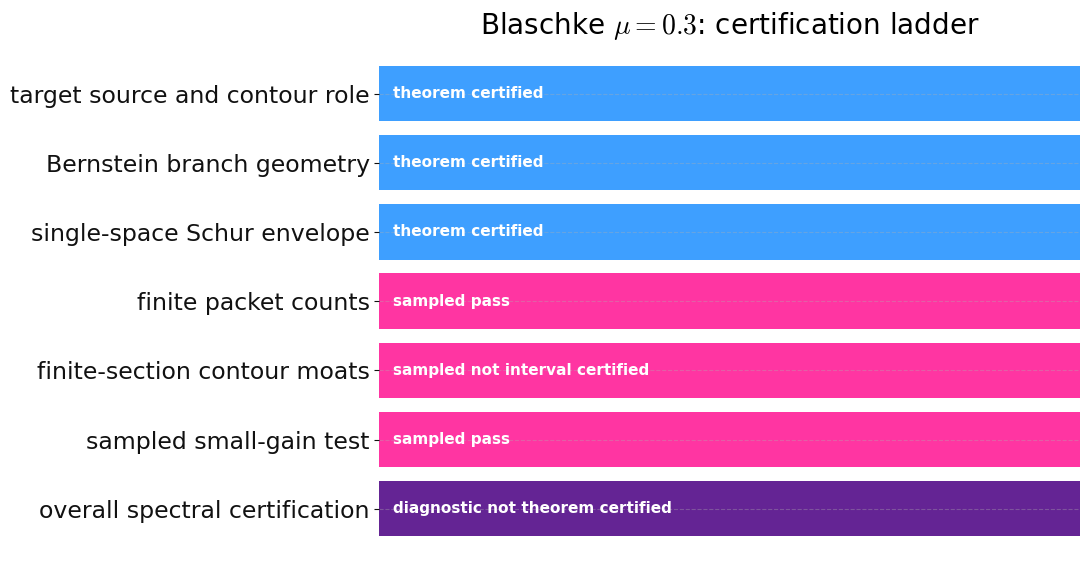

Saved universal certification audit: outputs/blaschke_deformation_certifier/data/transfer_lab_blaschke_mu_0p3_universal_certification_audit.csv


In [60]:
# Cell 100
# ============================================================
# Universal selected-map certification audit
# ============================================================

capability = SELECTED_MAP_CERTIFICATION_CAPABILITY
targets_14 = transfer_lab_exact_or_reference_targets(max_targets=14, include_trivial=False)
geometry_for_audit = transfer_lab_active_geometry_record()

if SELECTED_MAP_LABEL == 'blaschke_mu_0p3' and 'finite_envelope_df' in globals():
    schur_for_audit = finite_envelope_df.copy()
else:
    schur_for_audit = transfer_lab_generic_schur_rows(N_values=(30, 40, 50, 60, 80, 100))

if SELECTED_MAP_LABEL == 'blaschke_mu_0p3' and 'phase4_moat_export' in globals():
    moat_for_audit = phase4_moat_export.copy()
else:
    selected_phase4_state = transfer_lab_selected_map_phase4_state()
    moat_for_audit = selected_phase4_state['moat'].copy()

moat_for_audit = moat_for_audit.rename(columns={
    'contour_radius': 'radius',
    's_min_gamma': 's_gamma_H',
    'expected_multiplicity': 'multiplicity',
})
if 'target' not in moat_for_audit and 'name' in moat_for_audit:
    moat_for_audit['target'] = moat_for_audit['name']
if 'radius' not in moat_for_audit:
    moat_for_audit['radius'] = np.nan
if 'multiplicity' not in moat_for_audit:
    moat_for_audit['multiplicity'] = 1
if 'small_gain_diagnostic' not in moat_for_audit and 'epsilon_m_gamma' in moat_for_audit:
    # Normalise the Blaschke sampled-small-gain schema for the universal audit helper.
    moat_for_audit['small_gain_diagnostic'] = pd.to_numeric(moat_for_audit['epsilon_m_gamma'], errors='coerce')

selected_map_certification_audit_df = build_certification_audit(
    map_label=SELECTED_MAP_LABEL,
    capability=capability,
    target_count=len(targets_14),
    geometry=geometry_for_audit,
    schur_rows=schur_for_audit,
    moat_rows=moat_for_audit.head(14),
)

audit_path = DATA_DIR / f'transfer_lab_{SELECTED_MAP_LABEL}_universal_certification_audit.csv'
selected_map_certification_audit_df.to_csv(audit_path, index=False)
capability_df = pd.DataFrame([capability.as_record(SELECTED_MAP_LABEL)])
display(capability_df)
display(selected_map_certification_audit_df)

status_colours = {
    'theorem_certified': PALETTE['real'],
    'sampled_pass': PALETTE['imag'],
    'sampled_not_interval_certified': PALETTE['imag'],
    'sampled_not_theorem_certified': PALETTE['imag'],
    'reference_diagnostic_not_exact': PALETTE['ref'],
    'diagnostic_not_theorem_certified': PALETTE['main'],
}
fig, ax = plt.subplots(figsize=(11, 5.8), facecolor='white')
y = np.arange(len(selected_map_certification_audit_df))
colours = [status_colours.get(str(value), PALETTE['ref']) for value in selected_map_certification_audit_df['status']]
ax.barh(y, np.ones_like(y, dtype=float), color=colours, alpha=0.86)
ax.set_yticks(y, selected_map_certification_audit_df['audit_item'])
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xticks([])
for index, row in selected_map_certification_audit_df.iterrows():
    ax.text(0.02, index, str(row['status']).replace('_', ' '), va='center', color='white', fontsize=11, fontweight='bold')
ax.set_title(f'{transfer_lab_plot_title_label()}: certification ladder')
for spine in ax.spines.values():
    spine.set_visible(False)
transfer_lab_safe_tight_layout(fig)
transfer_lab_save_current_fig('Cell_100_universal_certification_ladder')
plt.show()
print(f'Saved universal certification audit: {audit_path}')


# First fourteen nontrivial packets

This cell displays the same fourteen-packet scope for every selected map.  Exact-target maps retain
their analytic target names.  Unknown-spectrum maps use high-resolution reference packets and are
labelled accordingly.  The contour columns remain sampled unless validated singular-value lower
bounds have been supplied.

<div style="color: #008B8B;">

The audit keeps the numerical and theorem-level gates separate. `sampled_small_gain_pass` tests the stored product $\varepsilon_X m_\Gamma^X<1$ formed from sampled contour minima. `certified_small_gain_pass` remains false until a validated lower moat enclosure is supplied on the complete contour. Likewise, `finite_count_matches` records agreement of the numerical count with the expected multiplicity, whereas `finite_count_certified` requires a validated finite-section count.

</div>


Saved figure: outputs/blaschke_deformation_certifier/figures/transfer_lab_blaschke_mu_0p3_Cell_102_first14_packet_audit.png


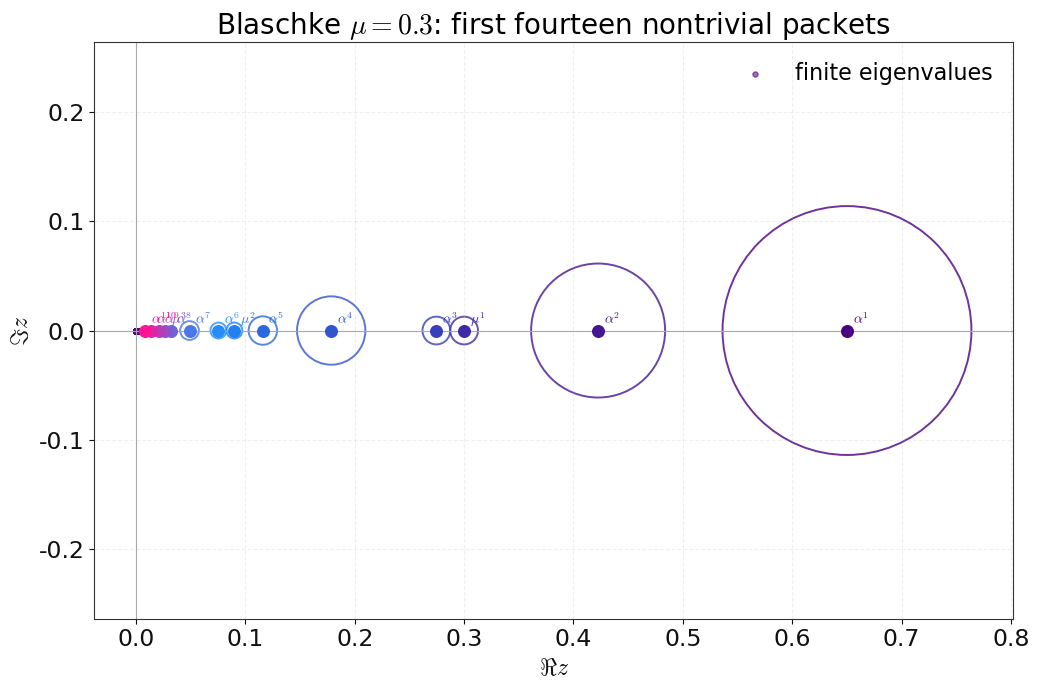

,name,family_packet,multiplicity_packet,finite_eigenvalue_count,s_gamma_H,d_Gamma0,epsilon_m_gamma,sampled_small_gain_pass,certified_small_gain_pass,finite_count_matches,finite_count_certified,target_identity_status,contour_role,finite_section_status,riesz_rank_status
0,alpha^1,alpha,1,1,2.507580e-11,0.536250,4.642392e-07,passed,not yet performed,matches,not yet performed,theorem_certified,exact-model contour centre,sampled_not_interval_certified,sampled_pass_not_theorem_certified
1,alpha^2,alpha,1,1,7.755190e-12,0.361250,1.501081e-06,passed,not yet performed,matches,not yet performed,theorem_certified,exact-model contour centre,sampled_not_interval_certified,sampled_pass_not_theorem_certified
2,mu^1,mu,2,2,7.545155e-13,0.287312,1.542867e-05,passed,not yet performed,matches,not yet performed,theorem_certified,exact-model contour centre,sampled_not_interval_certified,sampled_pass_not_theorem_certified
3,alpha^3,alpha,1,1,7.545171e-13,0.261937,1.542864e-05,passed,not yet performed,matches,not yet performed,theorem_certified,exact-model contour centre,sampled_not_interval_certified,sampled_pass_not_theorem_certified
4,alpha^4,alpha,1,1,3.346104e-12,0.147268,3.479022e-06,passed,not yet performed,matches,not yet performed,theorem_certified,exact-model contour centre,sampled_not_interval_certified,sampled_pass_not_theorem_certified
5,alpha^5,alpha,1,1,4.304375e-13,0.103015,2.704497e-05,passed,not yet performed,matches,not yet performed,theorem_certified,exact-model contour centre,sampled_not_interval_certified,sampled_pass_not_theorem_certified
6,mu^2,mu,2,2,9.415140e-14,0.082709,1.236431e-04,passed,not yet performed,matches,not yet performed,theorem_certified,exact-model contour centre,sampled_not_interval_certified,sampled_pass_not_theorem_certified
7,alpha^6,alpha,1,1,9.415140e-14,0.068128,1.236431e-04,passed,not yet performed,matches,not yet performed,theorem_certified,exact-model contour centre,sampled_not_interval_certified,sampled_pass_not_theorem_certified
8,alpha^7,alpha,1,1,8.611542e-14,0.040443,1.351810e-04,passed,not yet performed,matches,not yet performed,theorem_certified,exact-model contour centre,sampled_not_interval_certified,sampled_pass_not_theorem_certified
9,alpha^8,alpha,1,1,3.897393e-15,0.029432,2.986912e-03,passed,not yet performed,matches,not yet performed,theorem_certified,exact-model contour centre,sampled_not_interval_certified,sampled_pass_not_theorem_certified


Saved first-fourteen packet audit: outputs/blaschke_deformation_certifier/data/transfer_lab_blaschke_mu_0p3_first14_packet_audit.csv


In [61]:
# Cell 102
# ============================================================
# First-fourteen packet table and contour plot
# ============================================================

packet_table = targets_14.copy().head(14).rename(columns={'centre': 'packet_centre'})
packet_table = packet_table.merge(
    moat_for_audit.head(14), left_on='name', right_on='target', how='left', suffixes=('_packet', '_moat')
)
if SELECTED_MAP_LABEL == 'blaschke_mu_0p3' and 'PHASE4_EPS_X' in globals():
    packet_table['epsilon_X'] = float(PHASE4_EPS_X)
    if 'm_gamma_X' in packet_table:
        packet_table['epsilon_m_gamma'] = pd.to_numeric(packet_table['m_gamma_X'], errors='coerce') * float(PHASE4_EPS_X)
        packet_table['pass_sampled_small_gain'] = packet_table['epsilon_m_gamma'] < 1.0
if 'pass_certified_packet' in packet_table and 'pass_sampled_packet' not in packet_table:
    packet_table = packet_table.rename(columns={'pass_certified_packet': 'pass_sampled_packet'})
packet_table = packet_table.drop(columns=['certified'], errors='ignore')
if 'contour_interval_certified' not in packet_table:
    packet_table['contour_interval_certified'] = False
packet_table['contour_interval_certified'] = packet_table['contour_interval_certified'].fillna(False).astype(bool)
packet_table['validation_status'] = np.where(
    packet_table['contour_interval_certified'],
    'interval_certified',
    'sampled_not_interval_certified',
)
packet_table['target_identity_status'] = capability.target_status
packet_table['finite_section_status'] = capability.contour_status
packet_table['contour_role'] = (
    'exact-model contour centre'
    if capability.target_status == 'theorem_certified'
    else 'reference-derived contour proposal'
)
if 'finite_count_certified' not in packet_table:
    packet_table['finite_count_certified'] = False
packet_table['finite_count_certified'] = packet_table['finite_count_certified'].fillna(False).astype(bool)

expected_count_column = next(
    (column for column in ('multiplicity_packet', 'multiplicity_moat', 'multiplicity') if column in packet_table),
    None,
)
if expected_count_column is not None and 'finite_eigenvalue_count' in packet_table:
    finite_count = pd.to_numeric(packet_table['finite_eigenvalue_count'], errors='coerce')
    expected_count = pd.to_numeric(packet_table[expected_count_column], errors='coerce')
    packet_table['finite_count_matches'] = finite_count.notna() & expected_count.notna() & (finite_count == expected_count)
else:
    packet_table['finite_count_matches'] = False

rigorous_operator_inputs = all(
    status == 'theorem_certified'
    for status in (
        capability.geometry_status,
        capability.deterministic_status,
        capability.contour_status,
    )
)
sampled_small_gain_source = next(
    (column for column in ('epsilon_m_gamma', 'small_gain_diagnostic') if column in packet_table),
    None,
)
sampled_small_gain_values = (
    pd.to_numeric(packet_table[sampled_small_gain_source], errors='coerce')
    if sampled_small_gain_source is not None
    else pd.Series(np.nan, index=packet_table.index, dtype=float)
)
sampled_small_gain_available = sampled_small_gain_values.notna() & np.isfinite(sampled_small_gain_values)
sampled_small_gain_pass = sampled_small_gain_available & (sampled_small_gain_values < 1)
packet_table['sampled_small_gain_pass'] = sampled_small_gain_pass
# Backwards-compatible name: this flag is sampled, not a theorem-level contour certificate.
packet_table['small_gain_pass'] = sampled_small_gain_pass
if 'certified_small_gain_pass' not in packet_table:
    packet_table['certified_small_gain_pass'] = False
packet_table['certified_small_gain_pass'] = (
    packet_table['certified_small_gain_pass'].fillna(False).astype(bool)
    & packet_table['contour_interval_certified']
)

def packet_riesz_rank_status(row):
    if not bool(row['finite_count_matches']):
        return 'sampled_count_fail'
    if bool(sampled_small_gain_available.loc[row.name]) and not bool(sampled_small_gain_pass.loc[row.name]):
        return 'sampled_small_gain_fail'
    if (
        rigorous_operator_inputs
        and bool(row['finite_count_certified'])
        and bool(row['certified_small_gain_pass'])
    ):
        return 'theorem_certified_equal_riesz_rank'
    if bool(sampled_small_gain_pass.loc[row.name]):
        return 'sampled_pass_not_theorem_certified'
    return 'diagnostic_not_theorem_certified'

packet_table['riesz_rank_status'] = packet_table.apply(packet_riesz_rank_status, axis=1)
packet_path = DATA_DIR / f'transfer_lab_{SELECTED_MAP_LABEL}_first14_packet_audit.csv'
packet_table.to_csv(packet_path, index=False)

fig, ax = plt.subplots(figsize=(10.5, 7.0), facecolor='white')
palette = phase1_gradient_palette(packet_table['name'].astype(str).tolist())
for row in packet_table.itertuples(index=False):
    centre = complex(row.packet_centre)
    radius = float(row.radius) if np.isfinite(getattr(row, 'radius', np.nan)) else 0.0
    colour = palette.get(str(row.name), PALETTE['main'])
    ax.scatter(centre.real, centre.imag, s=70, color=colour, zorder=3)
    if radius > 0:
        ax.add_patch(plt.Circle((centre.real, centre.imag), radius, fill=False, color=colour, lw=1.4, alpha=0.8))
    ax.annotate(transfer_lab_target_label(row.name), (centre.real, centre.imag), xytext=(4, 5), textcoords='offset points', fontsize=10, color=colour)
eig_values = moat_for_audit.attrs.get('eig', None)
if 'selected_phase4_state' in globals():
    eig_values = selected_phase4_state['eig']
elif 'A_X_phase4' in globals():
    eig_values = np.linalg.eigvals(np.asarray(A_X_phase4, dtype=np.complex128))
if eig_values is not None:
    eig_values = np.asarray(eig_values, dtype=np.complex128)
    eig_values = eig_values[np.abs(eig_values - 1.0) > 1.0e-10]
    ax.scatter(eig_values.real, eig_values.imag, s=14, color=PALETTE['main'], alpha=0.55, label='finite eigenvalues')
ax.axhline(0, color=PALETTE['ref'], lw=0.8)
ax.axvline(0, color=PALETTE['ref'], lw=0.8)
ax.set_aspect('equal', adjustable='datalim')
ax.set_xlabel(r'$\Re z$')
ax.set_ylabel(r'$\Im z$')
ax.set_title(f'{transfer_lab_plot_title_label()}: first fourteen nontrivial packets')
ax.legend(frameon=False)
ax.grid(True, alpha=0.2)
transfer_lab_safe_tight_layout(fig)
transfer_lab_save_current_fig('Cell_102_first14_packet_audit')
plt.show()
display_columns = [column for column in [
    'name', 'family_packet', 'multiplicity_packet', 'target_mode_packet',
    'finite_eigenvalue_count', 's_gamma_H', 'd_Gamma0', 'epsilon_m_gamma',
    'sampled_small_gain_pass', 'certified_small_gain_pass',
    'finite_count_matches', 'finite_count_certified', 'target_identity_status',
    'contour_role', 'finite_section_status', 'riesz_rank_status',
] if column in packet_table.columns]
packet_display = packet_table[display_columns].copy()
if 'sampled_small_gain_pass' in packet_display:
    packet_display['sampled_small_gain_pass'] = np.where(
        packet_display['sampled_small_gain_pass'], 'passed', 'failed'
    )
if 'certified_small_gain_pass' in packet_display:
    packet_display['certified_small_gain_pass'] = np.where(
        packet_display['certified_small_gain_pass'], 'certified pass', 'not yet performed'
    )
if 'finite_count_matches' in packet_display:
    packet_display['finite_count_matches'] = np.where(
        packet_display['finite_count_matches'], 'matches', 'does not match'
    )
if 'finite_count_certified' in packet_display:
    packet_display['finite_count_certified'] = np.where(
        packet_display['finite_count_certified'], 'certified', 'not yet performed'
    )
display(packet_display)
print(f'Saved first-fourteen packet audit: {packet_path}')


<div style="color: #008B8B;">

## Mathematical interpretation of the Cell 102 packet audit

The table deliberately separates a successful **sampled diagnostic** from a completed **theorem-level certificate**. The phrases `not yet performed` mean that the corresponding validated computation has not been supplied; they do not mean that a numerical inequality or multiplicity test failed.

### Common contour and Hardy-gauge setting

For target packet $j$, let its contour be

$$
\Gamma_j=\{z=\lambda_j+R_j e^{\mathrm i\theta}:0\leq\theta<2\pi\}.
$$

The finite matrix is measured in the Hardy $X$-gauge,

$$
A_{N,M}^{X}
=
\mathsf T_N(r)\mathsf D_{r,N}\widehat L_N^{(M)}
\mathsf D_{r,N}^{-1}\mathsf T_N(r)^{-1}.
$$

The theorem-certified deterministic perturbation radius used in the contour test is denoted by $\varepsilon_X$ and satisfies

$$
\|\mathcal L-\mathcal L_{N,M}^{X}\|_{X\to X}
\leq\varepsilon_X.
$$

### Meaning of every displayed column

- **`name`** is the exact Blaschke target label. Here $\alpha=(1+\mu)/2=0.65$ and $\mu=0.3$, so the centres are $\alpha^n$ or $\mu^n$.

- **`family_packet`** records whether the packet belongs to the simple $\alpha^n$ family or the multiplicity-two $\mu^n$ family.

- **`multiplicity_packet`** is the expected algebraic multiplicity $m_j$ of the exact target packet: $m_j=1$ for $\alpha^n$ and $m_j=2$ for $\mu^n$.

- **`finite_eigenvalue_count`** is the number of computed eigenvalues of $A_{N,M}^{X}$ lying inside $\Gamma_j$, counted with numerical algebraic multiplicity.

- **`s_gamma_H`** is the sampled finite-section Hardy-gauge moat

$$
\widehat s_{\Gamma_j,N,M}^{\mathrm H,J}
=
\min_{0\leq k<J}
\sigma_{\min}\!\left(z_{j,k}I_N-A_{N,M}^{X}\right),
\qquad z_{j,k}\in\Gamma_j.
$$

It is a minimum over the sampled contour nodes, not yet a validated lower bound for the complete contour infimum

$$
s_{\Gamma_j,N,M}^{\mathrm H}
=
\inf_{z\in\Gamma_j}
\sigma_{\min}\!\left(zI_N-A_{N,M}^{X}\right).
$$

Because $s_{\Gamma_j,N,M}^{\mathrm H}\leq\widehat s_{\Gamma_j,N,M}^{\mathrm H,J}$, the sampled moat cannot be substituted directly for a certified lower enclosure.

- **`d_Gamma0`** is the distance of the contour from the silent zero block of the finite-rank lift,

$$
d_{\Gamma_j,0}
=
\inf_{z\in\Gamma_j}|z|
=
|\lambda_j|-R_j,
$$

where the last identity applies because the displayed circles satisfy $R_j<|\lambda_j|$.

- **`epsilon_m_gamma`** is the sampled small-gain product

$$
\varepsilon_X\widehat m_{\Gamma_j}^{X}
=
\varepsilon_X
\max\left\{
\frac{1}{\widehat s_{\Gamma_j,N,M}^{\mathrm H,J}},
\frac{1}{d_{\Gamma_j,0}}
\right\}.
$$

- **`sampled_small_gain_pass`** is `passed` precisely when the displayed sampled product is strictly below one. All fourteen displayed packets pass this diagnostic.

- **`certified_small_gain_pass`** is `not yet performed` because no rigorous whole-contour lower enclosure $\underline s_{\Gamma_j,N,M}^{\mathrm H}$ has yet been supplied. A certified pass requires

$$
0<\underline s_{\Gamma_j,N,M}^{\mathrm H}
\leq s_{\Gamma_j,N,M}^{\mathrm H}
$$

and

$$
\varepsilon_X
\max\left\{
\frac{1}{\underline s_{\Gamma_j,N,M}^{\mathrm H}},
\frac{1}{d_{\Gamma_j,0}}
\right\}<1.
$$

- **`finite_count_matches`** is `matches` when the floating-point finite count equals the expected multiplicity $m_j$. This succeeds for all fourteen packets.

- **`finite_count_certified`** is `not yet performed` because agreement of floating-point eigenvalue counts is not a validated Riesz-rank computation. Certification requires a validated contour separation together with a rigorous argument-principle, winding-number, interval-eigenvalue, or finite Riesz-projector rank calculation.

- **`target_identity_status`** records whether the target centre and its model multiplicity are known theoretically. `theorem_certified` here refers to the exact Blaschke resonance formula; it does not certify the finite contour moat.

- **`contour_role`** states how the contour centre was chosen. `exact-model contour centre` means that the centre is an exact Blaschke target rather than a reference eigenvalue inferred from a larger numerical section.

- **`finite_section_status`** is `sampled_not_interval_certified`: singular values were sampled along the contour, but the gaps between sample nodes have not yet been enclosed rigorously.

- **`riesz_rank_status`** summarises all gates. `sampled_pass_not_theorem_certified` means that the sampled small-gain test and numerical count both pass, but the validated moat and certified finite count are still outstanding.

### The theorem-level conclusion still to be established

Once the whole-contour moat and finite count are validated, the perturbation argument yields

$$
\operatorname{rank}P_{\Gamma_j}(\mathcal L)
=
\operatorname{rank}P_{\Gamma_j}(\mathcal L_{N,M}^{X})
=m_j.
$$

The current table therefore reports successful sampled evidence, while `not yet performed` identifies the two remaining validation computations rather than numerical failures.

The completed Cell 103 stage later obtains all twenty-four certified finite algebraic counts from strict membership tests on the validated Schur diagonal. It certifies the complete-circle moat independently: seventeen contours use triangular Schur resolvent bounds, while seven deeper contours use Laurent approximate inverses.

</div>


## Balanced-radius validated Hardy matrix

This stage closes the matrix-enclosure gate on exactly the same finite configuration as the deterministic envelope:

$$N=600,\qquad M=610,\qquad \rho=2.725,\qquad r=2.473669807791324.$$

Arb encloses the Gauss--Legendre nodes and weights, both Blaschke inverse branches and transfer weights, every Legendre recurrence, the raw block, the scaled Legendre--Chebyshev connection and all matrix products in

$$\mathsf A_N^X(\widehat L_N^{(M)})=\mathsf T_N(r)\mathsf D_{r,N}\widehat L_N^{(M)}\mathsf D_{r,N}^{-1}\mathsf T_N(r)^{-1}. $$

The certified interval matrix is replaced by an exact-dyadic midpoint $A_N^\circ$ only after proving a rigorous induced-norm bound $\|\mathsf A_N^X(\widehat L_N^{(M)})-A_N^\circ\|_2\leq\eta_A$. A binary64 copy is exported only for contour proposal diagnostics and is explicitly excluded from theorem decisions. A 1024-bit starting run is retained as a failed tightness audit: the two cancellation-sensitive Hardy products pay the approximately 236-decimal-digit scaling span twice. The promoted 2048-bit gate also reserves a target diagnostic scale of $10^{-20}$ and thirty guard digits.


### Inline thesis helper: `blaschke_deformation_spectral_certification`

This is the complete helper used by **Phase 4 validated Hardy-gauge matrix certification**. It is placed here so that the mathematical implementation can be read in the same phase as the formulas and certificate that use it. The cell is executable: the `inline_module` magic gives the source an isolated module namespace while leaving the code visible in the notebook.

Source file: `blaschke_deformation_spectral_certification.py`  
SHA-256: `25734219103111e746f078618d34ea0e3610aca4c55f399eeda737f750ac556d`


In [62]:
%%inline_module blaschke_deformation_spectral_certification 25734219103111e746f078618d34ea0e3610aca4c55f399eeda737f750ac556d
"""Validated finite Hardy matrix for the ASBJ24 Blaschke deformation.

This module certifies the mathematical finite block at one fixed geometry.  It
uses Arb for the Gauss--Legendre rule, inverse branches, transfer weights,
Legendre recurrences, the scaled Legendre--Chebyshev connection and every
matrix product.  The resulting interval matrix is replaced by an exact-dyadic
midpoint only after the induced two-norm replacement error has been enclosed.
"""

from __future__ import annotations

from dataclasses import asdict, dataclass
from decimal import Decimal, getcontext
import csv
import gzip
import hashlib
import json
import math
from pathlib import Path
import pickle
import time
from typing import Callable, Iterable

import numpy as np

try:
    import flint
    from flint import arb, arb_mat
except ImportError as exc:  # pragma: no cover - checked by the notebook
    raise ImportError(
        "blaschke_deformation_spectral_certification requires python-flint"
    ) from exc


MAP_LABEL = "blaschke_mu_0p3"
SCHEMA = "blaschke-deformation-exact-dyadic-hardy-reference-v1"


@dataclass(frozen=True)
class HardyMatrixCertificateConfig:
    """Fixed finite-section geometry and arithmetic settings."""

    N: int = 600
    M: int = 610
    rho: str = "2.725"
    r: str = "2.473669807791324"
    mu: str = "0.3"
    precision_bits: int = 2048
    flint_threads: int = 24
    guard_digits: int = 30
    diagnostic_resolution: str = "1e-20"


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def logical_source_hashes(source_files: Iterable[Path]) -> dict[str, str]:
    """Hash source files under stable, location-independent logical names.

    The thesis-mathematics notebook materialises inline helpers in a fresh
    temporary directory on every run.  Resolved absolute paths therefore do
    not identify source content and must not participate in checkpoint keys.
    Helper filenames are unique in this deployment and form stable logical
    names both for standalone and inline execution.
    """

    result: dict[str, str] = {}
    for source in source_files:
        path = Path(source)
        key = path.name
        if key in result:
            raise ValueError(f"Duplicate logical source key: {key}")
        result[key] = sha256_file(path)
    return result


def normalise_source_hashes(source_hashes: dict[str, str]) -> dict[str, str]:
    """Normalise legacy absolute-path provenance to logical filenames."""

    result: dict[str, str] = {}
    for raw_key, digest in source_hashes.items():
        key = Path(raw_key).name
        if key in result and result[key] != digest:
            raise ValueError(f"Conflicting source hashes for logical key: {key}")
        result[key] = str(digest)
    return result


def _upper_decimal(value: arb) -> Decimal:
    midpoint, radius, exponent = value.upper().mid_rad_10exp()
    return (Decimal(int(midpoint)) + abs(Decimal(int(radius)))) * (
        Decimal(10) ** int(exponent)
    )


def upper_float(value: arb) -> float:
    """Convert an Arb upper endpoint to an outward-rounded binary float."""

    getcontext().prec = 120
    return math.nextafter(float(_upper_decimal(value)), math.inf)


def upper_text(value: arb, digits: int = 120) -> str:
    return value.upper().str(int(digits), radius=False, more=True)


def _write_csv_row(path: Path, row: dict[str, object]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    with temporary.open("w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=tuple(row))
        writer.writeheader()
        writer.writerow(row)
    temporary.replace(path)


def _write_json(path: Path, value: object) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(json.dumps(value, indent=2), encoding="utf-8")
    temporary.replace(path)


def _orthonormal_legendre_values(count: int, x: arb) -> list[arb]:
    """Evaluate the first ``count`` orthonormal Legendre modes by recurrence."""

    count = int(count)
    if count <= 0:
        return []
    values = [arb(0) for _ in range(count)]
    values[0] = arb(1)
    if count >= 2:
        values[1] = x
        for degree in range(1, count - 1):
            values[degree + 1] = (
                (2 * degree + 1) * x * values[degree]
                - degree * values[degree - 1]
            ) / (degree + 1)
    return [
        (arb(2 * degree + 1) / 2).sqrt() * values[degree]
        for degree in range(count)
    ]


def _gauss_legendre_rule(order: int) -> tuple[list[arb], list[arb]]:
    """Certify the complete Gauss--Legendre rule by Arb root isolation."""

    order = int(order)
    nodes: list[arb] = []
    weights: list[arb] = []
    for node_index in range(order):
        root_index = order - 1 - node_index
        node, weight = arb.legendre_p_root(order, root_index, weight=True)
        if weight.lower() <= 0:
            raise ArithmeticError("A certified Gauss weight is not positive.")
        nodes.append(node)
        weights.append(weight)
    if not all(
        nodes[index].upper() < nodes[index + 1].lower()
        for index in range(order - 1)
    ):
        raise ArithmeticError("Certified Gauss-node intervals overlap.")
    if not sum(weights, arb(0)).contains(2):
        raise ArithmeticError("Certified Gauss weights do not enclose mass two.")
    return nodes, weights


def _real_branch_values(x: arb, mu: arb, pi: arb) -> tuple[tuple[arb, arb], ...]:
    """Certify both real inverse branches and transfer weights at one node."""

    cosine = (pi * x / 2).cos()
    sine = (pi * x / 2).sin()
    argument = mu * cosine
    denominator_square = 1 - argument * argument
    if denominator_square.lower() <= 0:
        raise ArithmeticError("The Blaschke branch denominator is not positive.")
    denominator = denominator_square.sqrt()
    angle = argument.acos() / pi
    branches = (
        (x / 2 - angle, arb("0.5") - mu * sine / (2 * denominator)),
        (x / 2 + angle, arb("0.5") + mu * sine / (2 * denominator)),
    )
    for tau, phi in branches:
        if tau.lower() < -1 or tau.upper() > 1:
            raise ArithmeticError("A certified inverse branch left the real interval.")
        if phi.lower() <= 0:
            raise ArithmeticError("A certified transfer weight is not positive.")
    if not branches[0][0].upper() < branches[1][0].lower():
        raise ArithmeticError("Certified inverse branches overlap.")
    return branches


def _connection_matrix(count: int, hardy_radius: arb) -> arb_mat:
    """Construct the scaled Legendre--Chebyshev connection in Arb."""

    count = int(count)
    coefficients: list[list[arb]] = []
    if count:
        coefficients.append([arb(1)])
    if count >= 2:
        coefficients.append([arb(0), arb(1)])
    for degree in range(1, count - 1):
        multiplied = [arb(0)] * (len(coefficients[degree]) + 1)
        for mode, value in enumerate(coefficients[degree]):
            if mode == 0:
                multiplied[1] += value
            else:
                multiplied[mode + 1] += value / 2
                multiplied[mode - 1] += value / 2
        new = [arb(0)] * (degree + 2)
        for mode, value in enumerate(multiplied):
            new[mode] += (2 * degree + 1) * value / (degree + 1)
        for mode, value in enumerate(coefficients[degree - 1]):
            new[mode] -= degree * value / (degree + 1)
        coefficients.append(new)

    column_scales = [
        (arb(2 * column + 1) / 2).sqrt() * hardy_radius ** (-column)
        for column in range(count)
    ]
    row_scales = [arb(1)] + [
        (
            hardy_radius ** (2 * row) + hardy_radius ** (-2 * row)
        ).sqrt()
        / 2
        for row in range(1, count)
    ]
    return arb_mat(
        [
            [
                row_scales[row]
                * column_scales[column]
                * coefficients[column][row]
                if row < len(coefficients[column])
                else arb(0)
                for column in range(count)
            ]
            for row in range(count)
        ]
    )


def assemble_interval_hardy_matrix(
    config: HardyMatrixCertificateConfig,
    progress: Callable[[int, int], None] | None = None,
) -> tuple[arb_mat, dict[str, object]]:
    """Assemble the complete mathematical Hardy-gauge block in Arb."""

    N, M = int(config.N), int(config.M)
    if N < 1 or M < N:
        raise ValueError("The matrix certificate requires M at least N at positive order.")
    old_precision, old_threads = flint.ctx.prec, flint.ctx.threads
    flint.ctx.prec = int(config.precision_bits)
    flint.ctx.threads = int(config.flint_threads)
    started = time.time()
    try:
        mu, pi = arb(config.mu), arb.pi()
        nodes, weights = _gauss_legendre_rule(M)
        testing = arb_mat(M, N)
        response = arb_mat(M, N)
        maximum_node_radius = arb(0)
        maximum_branch_radius = arb(0)
        minimum_weight = None
        for node_index, (node, weight) in enumerate(zip(nodes, weights)):
            maximum_node_radius = max(maximum_node_radius, node.rad())
            minimum_weight = weight if minimum_weight is None else min(minimum_weight, weight)
            p_node = _orthonormal_legendre_values(N, node)
            response_values = [arb(0) for _ in range(N)]
            for tau, phi in _real_branch_values(node, mu, pi):
                maximum_branch_radius = max(maximum_branch_radius, tau.rad())
                p_tau = _orthonormal_legendre_values(N, tau)
                for degree in range(N):
                    response_values[degree] += phi * p_tau[degree]
            for degree in range(N):
                testing[node_index, degree] = p_node[degree]
                response[node_index, degree] = weight * response_values[degree]
            if progress is not None:
                progress(node_index + 1, M)

        transfer = testing.transpose() * response
        del testing, response

        hardy_radius = arb(config.r)
        powers = [hardy_radius**degree for degree in range(N)]
        pure_scaled = arb_mat(N, N)
        for row in range(N):
            for column in range(N):
                pure_scaled[row, column] = (
                    powers[row] * transfer[row, column] / powers[column]
                )
        del transfer, powers

        connection = _connection_matrix(N, hardy_radius)
        connection_inverse = connection.inv()
        hardy = connection * pure_scaled * connection_inverse
        if not all(
            hardy[row, column].is_finite
            for row in range(N)
            for column in range(N)
        ):
            raise ArithmeticError("The validated Hardy block contains a non-finite ball.")

        return hardy, {
            "gauss_nodes_disjoint": True,
            "gauss_weight_sum_contains_two": True,
            "branch_values_certified": True,
            "branch_weights_positive": True,
            "branch_ordering_certified": True,
            "legendre_recurrence_certified": True,
            "connection_inverse_certified": True,
            "all_matrix_products_certified": True,
            "maximum_gauss_node_radius_upper": upper_float(maximum_node_radius),
            "maximum_branch_radius_upper": upper_float(maximum_branch_radius),
            "minimum_gauss_weight_lower": float(minimum_weight.lower()),
            "assembly_seconds": time.time() - started,
        }
    finally:
        flint.ctx.prec, flint.ctx.threads = old_precision, old_threads


def _dyadic_midpoint_payload(
    interval_matrix: arb_mat,
    config: HardyMatrixCertificateConfig,
    source_hashes: dict[str, str],
) -> tuple[dict[str, object], dict[str, object], np.ndarray]:
    """Extract an exact-dyadic midpoint and certify its replacement error."""

    N = interval_matrix.nrows()
    if interval_matrix.ncols() != N:
        raise ValueError("The Hardy matrix must be square.")
    old_precision = flint.ctx.prec
    flint.ctx.prec = int(config.precision_bits)
    try:
        row_sums = [arb(0) for _ in range(N)]
        column_sums = [arb(0) for _ in range(N)]
        frobenius_square = arb(0)
        mantissas: list[int] = []
        exponents: list[int] = []
        midpoint_float = np.empty((N, N), dtype=np.float64)
        digest = hashlib.sha256()

        for row in range(N):
            for column in range(N):
                midpoint = interval_matrix[row, column].mid()
                mantissa, exponent = midpoint.man_exp()
                mantissa_int, exponent_int = int(mantissa), int(exponent)
                reference = arb(mantissa_int) * arb(2) ** exponent_int
                error = abs(interval_matrix[row, column] - reference).upper()
                row_sums[row] += error
                column_sums[column] += error
                frobenius_square += error * error
                mantissas.append(mantissa_int)
                exponents.append(exponent_int)
                midpoint_float[row, column] = float(reference)
                digest.update(f"{mantissa_int}:{exponent_int};".encode("ascii"))

        norm_one = max(column_sums)
        norm_infinity = max(row_sums)
        eta = (norm_one * norm_infinity).sqrt().upper()
        frobenius = frobenius_square.sqrt().upper()
    finally:
        flint.ctx.prec = old_precision
    if not np.isfinite(midpoint_float).all():
        raise ArithmeticError("The diagnostic binary64 midpoint contains a non-finite value.")

    payload = {
        "schema": SCHEMA,
        "map_label": MAP_LABEL,
        "config": asdict(config),
        "shape": (N, N),
        "mantissas": mantissas,
        "exponents": exponents,
        "eta_A_upper_text": upper_text(eta),
        "norm_one_upper_text": upper_text(norm_one),
        "norm_infinity_upper_text": upper_text(norm_infinity),
        "frobenius_upper_text": upper_text(frobenius),
        "midpoint_sha256": digest.hexdigest(),
        "source_hashes": dict(source_hashes),
    }
    bounds = {
        "eta_A_upper": upper_float(eta),
        "eta_A_upper_text": payload["eta_A_upper_text"],
        "norm_one_upper": upper_float(norm_one),
        "norm_infinity_upper": upper_float(norm_infinity),
        "frobenius_upper": upper_float(frobenius),
        "midpoint_sha256": payload["midpoint_sha256"],
    }
    return payload, bounds, midpoint_float


def _precision_audit(config: HardyMatrixCertificateConfig) -> dict[str, object]:
    available_digits = float(config.precision_bits) * math.log10(2)
    scale_span = (int(config.N) - 1) * math.log10(float(config.r))
    resolution_digits = -math.log10(float(config.diagnostic_resolution))
    # The explicit route forms T B T^{-1}.  Both dense products can expose the
    # full scaled-coordinate dynamic range before cancellation, so a safe
    # arithmetic budget pays the scaling span twice.
    cancellation_span_count = 2
    required_digits = (
        cancellation_span_count * scale_span
        + resolution_digits
        + int(config.guard_digits)
    )
    return {
        "available_decimal_digits": available_digits,
        "pure_scaling_decimal_span": scale_span,
        "transport_cancellation_span_count": cancellation_span_count,
        "transport_cancellation_decimal_budget": cancellation_span_count * scale_span,
        "diagnostic_resolution": str(config.diagnostic_resolution),
        "diagnostic_resolution_digits": resolution_digits,
        "guard_digits": int(config.guard_digits),
        "required_decimal_digits": required_digits,
        "precision_margin_digits": available_digits - required_digits,
        "precision_budget_pass": available_digits > required_digits,
    }


def _payload_is_valid(
    payload_path: Path,
    summary: dict[str, object],
    config: HardyMatrixCertificateConfig,
    source_hashes: dict[str, str],
) -> bool:
    try:
        with gzip.open(payload_path, "rb") as handle:
            payload = pickle.load(handle)
    except Exception:
        return False
    if payload.get("schema") != SCHEMA:
        return False
    if payload.get("config") != asdict(config):
        return False
    try:
        stored_source_hashes = normalise_source_hashes(
            dict(payload.get("source_hashes", {}))
        )
    except (TypeError, ValueError):
        return False
    if stored_source_hashes != source_hashes:
        return False
    if payload.get("midpoint_sha256") != summary.get("midpoint_sha256"):
        return False
    expected_entries = int(config.N) * int(config.N)
    return (
        len(payload.get("mantissas", ())) == expected_entries
        and len(payload.get("exponents", ())) == expected_entries
        and bool(summary.get("mathematical_block_enclosed"))
        and bool(summary.get("reference_is_exact_dyadic"))
    )


def _migrate_cached_source_provenance(
    *,
    payload_path: Path,
    summary_path: Path,
    report_path: Path,
    summary: dict[str, object],
    source_hashes: dict[str, str],
) -> dict[str, object]:
    """Rewrite a valid legacy checkpoint with stable logical source keys."""

    with gzip.open(payload_path, "rb") as handle:
        payload = pickle.load(handle)
    payload_hashes = dict(payload.get("source_hashes", {}))
    summary_hashes = dict(summary.get("source_hashes", {}))
    if payload_hashes == source_hashes and summary_hashes == source_hashes:
        return summary

    payload["source_hashes"] = dict(source_hashes)
    temporary_payload = payload_path.with_suffix(payload_path.suffix + ".tmp")
    with gzip.open(temporary_payload, "wb", compresslevel=3) as handle:
        pickle.dump(payload, handle, protocol=5)
    temporary_payload.replace(payload_path)

    migrated = dict(summary)
    migrated["source_hashes"] = dict(source_hashes)
    migrated["payload_sha256"] = sha256_file(payload_path)
    _write_csv_row(
        summary_path,
        {
            key: json.dumps(value, sort_keys=True)
            if isinstance(value, dict)
            else value
            for key, value in migrated.items()
        },
    )
    _write_json(report_path, migrated)
    return migrated


def build_or_load_hardy_matrix_certificate(
    *,
    config: HardyMatrixCertificateConfig,
    output_dir: Path,
    source_files: Iterable[Path],
    force: bool = False,
    require_precision_budget: bool = True,
    progress: Callable[[int, int], None] | None = None,
) -> dict[str, object]:
    """Transactionally build or validate the fixed Hardy-matrix certificate."""

    output_dir = Path(output_dir).resolve()
    data_dir, report_dir = output_dir / "data", output_dir / "reports"
    data_dir.mkdir(parents=True, exist_ok=True)
    report_dir.mkdir(parents=True, exist_ok=True)
    stem = (
        f"blaschke_deformation_balanced_hardy_reference_"
        f"N{int(config.N)}_M{int(config.M)}_bits{int(config.precision_bits)}"
    )
    payload_path = data_dir / f"{stem}.pkl.gz"
    midpoint_path = data_dir / f"{stem}_diagnostic_midpoint.npz"
    summary_path = data_dir / f"{stem}_certificate.csv"
    report_path = report_dir / f"{stem}_certificate.json"
    source_hashes = logical_source_hashes(source_files)
    precision = _precision_audit(config)
    if require_precision_budget and not precision["precision_budget_pass"]:
        raise ArithmeticError("The requested Arb precision fails the explicit budget audit.")

    if (
        not force
        and payload_path.exists()
        and midpoint_path.exists()
        and report_path.exists()
    ):
        summary = json.loads(report_path.read_text(encoding="utf-8"))
        if _payload_is_valid(payload_path, summary, config, source_hashes):
            summary = _migrate_cached_source_provenance(
                payload_path=payload_path,
                summary_path=summary_path,
                report_path=report_path,
                summary=summary,
                source_hashes=source_hashes,
            )
            return {
                **summary,
                "execution_status": "reused_validated_checkpoint",
                "payload_path": str(payload_path),
                "midpoint_path": str(midpoint_path),
                "summary_path": str(summary_path),
                "report_path": str(report_path),
            }

    started = time.time()
    interval_matrix, assembly_audit = assemble_interval_hardy_matrix(
        config, progress=progress
    )
    payload, bounds, midpoint_float = _dyadic_midpoint_payload(
        interval_matrix, config, source_hashes
    )
    del interval_matrix

    temporary_payload = payload_path.with_suffix(payload_path.suffix + ".tmp")
    with gzip.open(temporary_payload, "wb", compresslevel=3) as handle:
        pickle.dump(payload, handle, protocol=5)
    temporary_payload.replace(payload_path)

    temporary_midpoint = midpoint_path.with_suffix(midpoint_path.suffix + ".tmp")
    with temporary_midpoint.open("wb") as handle:
        np.savez_compressed(
            handle,
            A_N_circ_binary64_diagnostic=midpoint_float,
            N=np.asarray(config.N),
            M=np.asarray(config.M),
            rho=np.asarray(config.rho),
            r=np.asarray(config.r),
            precision_bits=np.asarray(config.precision_bits),
            midpoint_sha256=np.asarray(payload["midpoint_sha256"]),
            authoritative_exact_dyadic_payload=np.asarray(str(payload_path)),
        )
    temporary_midpoint.replace(midpoint_path)

    summary = {
        "schema": SCHEMA,
        "map_label": MAP_LABEL,
        **asdict(config),
        **precision,
        **assembly_audit,
        **bounds,
        "entry_count": int(config.N) * int(config.N),
        "reference_is_exact_dyadic": True,
        "binary64_midpoint_is_diagnostic_only": True,
        "mathematical_block_enclosed": True,
        "matrix_enclosure_certified": True,
        "precision_budget_enforced": bool(require_precision_budget),
        "spectral_use_ready": (
            float(bounds["eta_A_upper"]) < float(config.diagnostic_resolution)
        ),
        "source_hashes": source_hashes,
        "payload_sha256": sha256_file(payload_path),
        "payload_path": str(payload_path),
        "midpoint_path": str(midpoint_path),
        "summary_path": str(summary_path),
        "report_path": str(report_path),
        "elapsed_seconds": time.time() - started,
        "status": "interval-certified mathematical Hardy block with exact-dyadic midpoint",
    }
    _write_csv_row(
        summary_path,
        {
            key: json.dumps(value, sort_keys=True) if isinstance(value, dict) else value
            for key, value in summary.items()
        },
    )
    _write_json(report_path, summary)
    return {**summary, "execution_status": "computed_and_certified"}


def load_exact_dyadic_midpoint(payload_path: Path) -> tuple[arb_mat, dict[str, object]]:
    """Reconstruct the authoritative exact-dyadic matrix in Arb arithmetic."""

    with gzip.open(Path(payload_path), "rb") as handle:
        payload = pickle.load(handle)
    if payload.get("schema") != SCHEMA:
        raise ValueError("Unrecognised exact-dyadic Hardy-reference schema.")
    rows, columns = (int(value) for value in payload["shape"])
    mantissas = payload["mantissas"]
    exponents = payload["exponents"]
    if len(mantissas) != rows * columns or len(exponents) != rows * columns:
        raise ValueError("The exact-dyadic Hardy-reference payload is incomplete.")
    old_precision = flint.ctx.prec
    flint.ctx.prec = int(payload["config"]["precision_bits"])
    try:
        matrix = arb_mat(rows, columns)
        digest = hashlib.sha256()
        for index, (mantissa, exponent) in enumerate(zip(mantissas, exponents)):
            row, column = divmod(index, columns)
            matrix[row, column] = arb(int(mantissa)) * arb(2) ** int(exponent)
            digest.update(f"{int(mantissa)}:{int(exponent)};".encode("ascii"))
    finally:
        flint.ctx.prec = old_precision
    if digest.hexdigest() != payload["midpoint_sha256"]:
        raise ArithmeticError("The exact-dyadic Hardy-reference digest failed.")
    return matrix, payload


Installed inline thesis helper blaschke_deformation_spectral_certification with SHA-256 25734219103111e746f078618d34ea0e3610aca4c55f399eeda737f750ac556d


<module 'blaschke_deformation_spectral_certification' from '/tmp/blaschke_thesis_math_v1axsfic/blaschke_deformation_spectral_certification.py'>

In [63]:
# Cell 102A
# Validated balanced-radius Hardy matrix and exact-dyadic midpoint

from pathlib import Path
import json
import os
import numpy as np
import pandas as pd

if Path.cwd().name == "Numerics":
    from blaschke_deformation_spectral_certification import (
        HardyMatrixCertificateConfig,
        build_or_load_hardy_matrix_certificate,
    )
    _spectral_cert_module_path = INLINE_MODULE_PATHS["blaschke_deformation_spectral_certification"]
    _spectral_worker_path = Path("mpmath_pf_raw.py")
    _spectral_builder_path = Path("build_blaschke_deformation_certifier.py")
else:
    from Numerics.blaschke_deformation_spectral_certification import (
        HardyMatrixCertificateConfig,
        build_or_load_hardy_matrix_certificate,
    )
    _spectral_cert_module_path = INLINE_MODULE_PATHS["blaschke_deformation_spectral_certification"]
    _spectral_worker_path = Path("Numerics/mpmath_pf_raw.py")
    _spectral_builder_path = Path("Numerics/build_blaschke_deformation_certifier.py")

HARDY_MATRIX_N = 600
HARDY_MATRIX_M = 610
HARDY_MATRIX_RHO_TEXT = "2.725"
HARDY_MATRIX_R_TEXT = "2.473669807791324"
HARDY_MATRIX_STARTING_BITS = 1024
HARDY_MATRIX_BITS = int(os.environ.get("BLASCHKE_HARDY_MATRIX_BITS", "2048"))
HARDY_MATRIX_FORCE = os.environ.get("BLASCHKE_FORCE_HARDY_MATRIX", "0") in {"1", "true", "True"}
_hardy_matrix_config = HardyMatrixCertificateConfig(
    N=HARDY_MATRIX_N, M=HARDY_MATRIX_M,
    rho=HARDY_MATRIX_RHO_TEXT, r=HARDY_MATRIX_R_TEXT,
    mu="0.3", precision_bits=HARDY_MATRIX_BITS,
    flint_threads=CERTIFIER_PROCESS_WORKERS, guard_digits=30,
    diagnostic_resolution="1e-20",
)
_hardy_starting_config = HardyMatrixCertificateConfig(
    N=HARDY_MATRIX_N, M=HARDY_MATRIX_M,
    rho=HARDY_MATRIX_RHO_TEXT, r=HARDY_MATRIX_R_TEXT,
    mu="0.3", precision_bits=HARDY_MATRIX_STARTING_BITS,
    flint_threads=CERTIFIER_PROCESS_WORKERS, guard_digits=30,
    diagnostic_resolution="1e-20",
)
if int(PHASE2_FINAL_CERT["N"]) != HARDY_MATRIX_N or int(PHASE2_FINAL_CERT["M"]) != HARDY_MATRIX_M:
    raise AssertionError("The Hardy matrix and deterministic envelope use different N or M.")
if mp.mpf(PHASE2_FINAL_CERT["rho"]) != mp.mpf(HARDY_MATRIX_RHO_TEXT):
    raise AssertionError("The Hardy matrix and deterministic envelope use different rho.")
if mp.mpf(PHASE2_FINAL_CERT["r"]) != mp.mpf(HARDY_MATRIX_R_TEXT):
    raise AssertionError("The Hardy matrix and deterministic envelope use different r.")

_hardy_progress_step = max(1, HARDY_MATRIX_M // 10)
def _hardy_matrix_progress(done, total):
    if done % _hardy_progress_step == 0 or done == total:
        print(f"validated Hardy response rows: {done}/{total}")

_hardy_source_files = (_spectral_cert_module_path,)
STARTING_HARDY_MATRIX_AUDIT = build_or_load_hardy_matrix_certificate(
    config=_hardy_starting_config, output_dir=OUTPUT_DIR,
    source_files=_hardy_source_files, force=HARDY_MATRIX_FORCE,
    require_precision_budget=False, progress=_hardy_matrix_progress,
)
BALANCED_HARDY_MATRIX_CERTIFICATE = build_or_load_hardy_matrix_certificate(
    config=_hardy_matrix_config, output_dir=OUTPUT_DIR,
    source_files=_hardy_source_files,
    force=HARDY_MATRIX_FORCE, progress=_hardy_matrix_progress,
)
hardy_matrix_precision_audit_df = pd.DataFrame([
    {
        "precision_bits": int(row["precision_bits"]),
        "available_decimal_digits": float(row["available_decimal_digits"]),
        "required_decimal_digits": float(row["required_decimal_digits"]),
        "precision_margin_digits": float(row["precision_margin_digits"]),
        "eta_A_upper": float(row["eta_A_upper"]),
        "spectral_use_ready": bool(row.get("spectral_use_ready", False)),
        "role": role,
    }
    for role, row in (
        ("starting precision audit", STARTING_HARDY_MATRIX_AUDIT),
        ("promoted production precision", BALANCED_HARDY_MATRIX_CERTIFICATE),
    )
])
_hardy_precision_audit_path = DATA_DIR / "blaschke_deformation_hardy_matrix_precision_audit.csv"
hardy_matrix_precision_audit_df.to_csv(_hardy_precision_audit_path, index=False)
if bool(STARTING_HARDY_MATRIX_AUDIT.get("spectral_use_ready", False)):
    raise AssertionError("The recorded 1024-bit tightness audit unexpectedly passed.")
balanced_hardy_matrix_certificate_df = pd.DataFrame([{
    key: value for key, value in BALANCED_HARDY_MATRIX_CERTIFICATE.items()
    if key not in {"source_hashes"}
}])
_hardy_required_flags = (
    "precision_budget_pass", "gauss_nodes_disjoint",
    "gauss_weight_sum_contains_two", "branch_values_certified",
    "branch_weights_positive", "branch_ordering_certified",
    "legendre_recurrence_certified", "connection_inverse_certified",
    "all_matrix_products_certified", "reference_is_exact_dyadic",
    "mathematical_block_enclosed", "matrix_enclosure_certified",
    "spectral_use_ready",
)
if not all(bool(BALANCED_HARDY_MATRIX_CERTIFICATE[key]) for key in _hardy_required_flags):
    raise AssertionError("The balanced Hardy-matrix certificate failed a theorem gate.")
if not float(BALANCED_HARDY_MATRIX_CERTIFICATE["eta_A_upper"]) > 0:
    raise AssertionError("The certified midpoint-replacement radius is invalid.")
with np.load(BALANCED_HARDY_MATRIX_CERTIFICATE["midpoint_path"], allow_pickle=False) as _hardy_payload:
    A_X_phase4_balanced_certified_midpoint = np.asarray(
        _hardy_payload["A_N_circ_binary64_diagnostic"], dtype=np.float64
    )
A_X_phase4 = A_X_phase4_balanced_certified_midpoint
CELL103_A_N_CIRC_PAYLOAD_PATH = Path(BALANCED_HARDY_MATRIX_CERTIFICATE["payload_path"])
CELL103_ETA_A_UPPER = float(BALANCED_HARDY_MATRIX_CERTIFICATE["eta_A_upper"])
CELL103_A_X_REFERENCE_CERTIFIED = True
CELL103_A_X_INTERVAL = None
CELL103_A_X_INTERVAL_CERTIFIED = False
balanced_hardy_matrix_gate_df = pd.DataFrame([{
    "N": HARDY_MATRIX_N, "M": HARDY_MATRIX_M,
    "rho": HARDY_MATRIX_RHO_TEXT, "r": HARDY_MATRIX_R_TEXT,
    "precision_bits": HARDY_MATRIX_BITS,
    "eta_A_upper": CELL103_ETA_A_UPPER,
    "midpoint_sha256": BALANCED_HARDY_MATRIX_CERTIFICATE["midpoint_sha256"],
    "mathematical_matrix_certified": True,
    "contour_resolvent_certification": "not yet performed",
    "finite_count_certification": "not yet performed",
    "theorem_scope": "matrix enclosure only; no spectral rank promoted here",
}])
_hardy_gate_path = DATA_DIR / "blaschke_deformation_balanced_hardy_matrix_gate.csv"
balanced_hardy_matrix_gate_df.to_csv(_hardy_gate_path, index=False)
display(balanced_hardy_matrix_gate_df)
display(hardy_matrix_precision_audit_df)
print("Balanced Hardy reference:", BALANCED_HARDY_MATRIX_CERTIFICATE["execution_status"])
print("Certified eta_A upper:", BALANCED_HARDY_MATRIX_CERTIFICATE["eta_A_upper_text"])
print("Stored exact-dyadic payload:", CELL103_A_N_CIRC_PAYLOAD_PATH)


,N,M,rho,r,precision_bits,eta_A_upper,midpoint_sha256,mathematical_matrix_certified,contour_resolvent_certification,finite_count_certification,theorem_scope
0,600,610,2.725,2.473669807791324,2048,3.387622e-154,db40178a19594986ddc4aea5b60b51ec751b98734e85fd...,True,not yet performed,not yet performed,matrix enclosure only; no spectral rank promot...


,precision_bits,available_decimal_digits,required_decimal_digits,precision_margin_digits,eta_A_upper,spectral_use_ready,role
0,1024,308.254716,521.223391,-212.968675,6.164392e+154,False,starting precision audit
1,2048,616.509431,521.223391,95.286041,3.387622e-154,True,promoted production precision


Balanced Hardy reference: reused_validated_checkpoint
Certified eta_A upper: 3.38762223735398967758227303602240582696316406953557538672249702107121173253281701488280060866369686754499255605274281641e-154
Stored exact-dyadic payload: /home/lucy/Documents/E.L.U.K_0/Final Deployment/Numerics/outputs/blaschke_deformation_certifier/data/blaschke_deformation_balanced_hardy_reference_N600_M610_bits2048.pkl.gz


## Cell 103: validated contours and Riesz ranks

This stage consumes the exact-dyadic midpoint $A_N^\circ$ and its certified replacement radius $\eta_A$ from Cell 102A. All twenty-four finite algebraic counts are obtained from strict inclusion and exclusion tests on the diagonal of the validated exact-binary upper-triangular Schur matrix $T$. Similarity preserves these counts, while the $\eta_{\mathrm{Schur}}$ and $\eta_A$ homotopies transport them first to $A_N^\circ$ and then to the mathematical Hardy-gauge matrix.

The complete-circle moat is certified independently. Seventeen contours use the uniform triangular Schur resolvent recurrence, whereas the seven deeper contours use complete-circle Laurent approximate inverses in Schur coordinates. Hence the final routes are seventeen `Schur-count/Schur-moat` records and seven `Schur-count/Laurent-moat` records. The Laurent construction supplies a moat only; it neither calculates an independent finite algebraic count nor performs an argument-principle count.

The twenty-four circles enclose the eighteen simple $\alpha^j$ targets and the six multiplicity-two $\mu^j$ targets. Promotion separately checks certified Schur-diagonal membership, transport of the computed finite count through both matrix homotopies, agreement with the expected Blaschke multiplicity, a positive complete-circle moat, exclusion of the silent zero complement, and strict small gain with the Phase 2 perturbation radius. Sampled singular values and floating-point counts remain proposal diagnostics and never enter promotion.


### Inline thesis helper: `blaschke_deformation_contour_certification`

This is the complete helper used by **Phase 4 contour and Riesz-rank certification**. It is placed here so that the mathematical implementation can be read in the same phase as the formulas and certificate that use it. The cell is executable: the `inline_module` magic gives the source an isolated module namespace while leaving the code visible in the notebook.

Source file: `blaschke_deformation_contour_certification.py`  
SHA-256: `55f76dde4fc2c80692feb5d3aac9b18184a915b5c78427c45e53d13a513946c4`


In [64]:
%%inline_module blaschke_deformation_contour_certification 55f76dde4fc2c80692feb5d3aac9b18184a915b5c78427c45e53d13a513946c4
"""Validated contour certification for the ASBJ24 Blaschke deformation.

The producer starts from the exact-dyadic Hardy-gauge midpoint certified by
``blaschke_deformation_spectral_certification``.  All finite algebraic counts
are obtained from strict inclusion tests on the diagonal of the exact-binary
upper-triangular Schur matrix.  Seventeen complete-circle moats are obtained
from the triangular Schur resolvent recurrence; the seven deeper moats are
obtained from validated Laurent approximate inverses in Schur coordinates.
Sampled inverses only propose Laurent coefficients; all theorem gates use Arb
residuals against the exact-dyadic matrix.
"""

from __future__ import annotations

import argparse
import csv
from dataclasses import asdict, dataclass
from fractions import Fraction
import gc
import gzip
import hashlib
import json
import math
from pathlib import Path
import pickle
import re
import time
from typing import Iterable

import numpy as np
from scipy import linalg
from threadpoolctl import threadpool_limits

try:
    import flint
    from flint import acb, acb_mat, arb
except ImportError as exc:  # pragma: no cover - checked by the notebook
    raise ImportError(
        "blaschke_deformation_contour_certification requires python-flint"
    ) from exc

from blaschke_deformation_spectral_certification import (
    logical_source_hashes,
    load_exact_dyadic_midpoint,
    normalise_source_hashes,
    sha256_file,
)


MAP_LABEL = "blaschke_mu_0p3"
SCHEMA = "blaschke-deformation-24-contour-hybrid-v2"
SCHUR_SCHEMA = "blaschke-deformation-exact-dyadic-schur-v1"

COUNT_METHOD_SCHUR_DIAGONAL = "certified Schur-diagonal algebraic count"
MOAT_METHOD_SCHUR_TRIANGULAR = (
    "uniform complete-circle triangular Schur resolvent"
)
MOAT_METHOD_LAURENT = (
    "complete-circle Laurent approximate inverse in Schur coordinates"
)
CERTIFICATE_ROUTE_SCHUR = "Schur-count/Schur-moat"
CERTIFICATE_ROUTE_LAURENT = "Schur-count/Laurent-moat"
COUNT_REFERENCE_MATRIX = "exact-binary upper-triangular Schur matrix T"


@dataclass(frozen=True)
class ContourCertificateConfig:
    """Arithmetic and contour settings for the fixed production run."""

    N: int = 600
    M: int = 610
    rho: str = "2.725"
    r: str = "2.473669807791324"
    mu_numerator: int = 3
    mu_denominator: int = 10
    alpha_numerator: int = 13
    alpha_denominator: int = 20
    alpha_power_count: int = 18
    mu_power_count: int = 6
    default_radius_numerator: int = 1
    default_radius_denominator: int = 5
    precision_bits: int = 256
    flint_threads: int = 24


@dataclass(frozen=True)
class TargetContour:
    """One exact rational target circle."""

    rank: int
    name: str
    family: str
    power: int
    expected_multiplicity: int
    centre: Fraction
    nearest_target_separation: Fraction
    radius_fraction: Fraction
    radius: Fraction
    laurent_sample_count: int | None


# These are proposal parameters only.  Every selected Laurent polynomial is
# subsequently validated against the exact-dyadic matrix in Arb.
_LAURENT_PROPOSALS: dict[str, tuple[Fraction, int]] = {
    "mu^5": (Fraction(1, 4), 44),
    "alpha^14": (Fraction(9, 50), 36),
    "alpha^15": (Fraction(1, 5), 48),
    "alpha^16": (Fraction(1, 5), 48),
    "mu^6": (Fraction(1, 4), 36),
    "alpha^17": (Fraction(1, 4), 40),
    "alpha^18": (Fraction(1, 5), 48),
}


def _fraction_text(value: Fraction) -> str:
    return f"{value.numerator}/{value.denominator}"


def _fraction_arb(value: Fraction) -> arb:
    return arb(value.numerator) / arb(value.denominator)


def _fraction_acb(value: Fraction) -> acb:
    return acb(_fraction_arb(value))


def _exact_float(value: float) -> arb:
    numerator, denominator = float(value).as_integer_ratio()
    return arb(numerator) / arb(denominator)


def _exact_complex128(value: complex) -> acb:
    value = complex(value)
    return acb(_exact_float(value.real), _exact_float(value.imag))


def _numpy_to_acb_exact(matrix: np.ndarray) -> acb_mat:
    matrix = np.asarray(matrix, dtype=np.complex128)
    rows, columns = matrix.shape
    return acb_mat(
        rows,
        columns,
        (
            _exact_complex128(matrix[row, column])
            for row in range(rows)
            for column in range(columns)
        ),
    )


def _frobenius_upper(matrix: acb_mat) -> arb:
    total = arb(0)
    for row in range(matrix.nrows()):
        for column in range(matrix.ncols()):
            magnitude = abs(matrix[row, column]).upper()
            total += magnitude * magnitude
    return total.sqrt().upper()


def _upper_float(value: arb) -> float:
    return float(np.nextafter(float(value.upper()), np.inf))


def _lower_float(value: arb) -> float:
    return float(np.nextafter(float(value.lower()), -np.inf))


def _upper_text(value: arb, digits: int = 80) -> str:
    return value.upper().str(int(digits), radius=False, more=True)


def _lower_text(value: arb, digits: int = 80) -> str:
    return value.lower().str(int(digits), radius=False, more=True)


def _write_csv(path: Path, rows: Iterable[dict[str, object]]) -> None:
    rows = list(rows)
    if not rows:
        raise ValueError(f"Refusing to write an empty certificate table: {path}")
    path.parent.mkdir(parents=True, exist_ok=True)
    fields: list[str] = []
    for row in rows:
        for key in row:
            if key not in fields:
                fields.append(key)
    temporary = path.with_suffix(path.suffix + ".tmp")
    with temporary.open("w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields)
        writer.writeheader()
        for row in rows:
            writer.writerow(row)
    temporary.replace(path)


def _write_json(path: Path, value: object) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(json.dumps(value, indent=2), encoding="utf-8")
    temporary.replace(path)


def _read_csv(path: Path) -> list[dict[str, str]]:
    with Path(path).open("r", encoding="utf-8", newline="") as handle:
        return list(csv.DictReader(handle))


def _csv_bool(value: object) -> bool:
    return str(value).strip().lower() in {"true", "1", "yes", "y"}


def _target_contours(config: ContourCertificateConfig) -> list[TargetContour]:
    alpha = Fraction(config.alpha_numerator, config.alpha_denominator)
    mu = Fraction(config.mu_numerator, config.mu_denominator)
    raw: list[tuple[Fraction, str, str, int, int]] = []
    for power in range(1, int(config.alpha_power_count) + 1):
        raw.append((alpha**power, f"alpha^{power}", "alpha", power, 1))
    for power in range(1, int(config.mu_power_count) + 1):
        raw.append((mu**power, f"mu^{power}", "mu", power, 2))
    raw.sort(key=lambda item: item[0], reverse=True)

    contours: list[TargetContour] = []
    default_fraction = Fraction(
        config.default_radius_numerator, config.default_radius_denominator
    )
    for index, (centre, name, family, power, multiplicity) in enumerate(raw):
        separation = min(
            abs(centre - other_centre)
            for other_centre, *_ in raw
            if other_centre != centre
        )
        radius_fraction, samples = _LAURENT_PROPOSALS.get(
            name, (default_fraction, None)
        )
        radius = radius_fraction * min(centre, separation)
        contours.append(
            TargetContour(
                rank=index + 1,
                name=name,
                family=family,
                power=power,
                expected_multiplicity=multiplicity,
                centre=centre,
                nearest_target_separation=separation,
                radius_fraction=radius_fraction,
                radius=radius,
                laurent_sample_count=samples,
            )
        )
    return contours


def _contour_plan_rows(contours: Iterable[TargetContour]) -> list[dict[str, object]]:
    rows = []
    for contour in contours:
        rows.append(
            {
                "rank": contour.rank,
                "name": contour.name,
                "family": contour.family,
                "power": contour.power,
                "expected_multiplicity": contour.expected_multiplicity,
                "centre_exact": _fraction_text(contour.centre),
                "centre_float": float(contour.centre),
                "nearest_target_separation_exact": _fraction_text(
                    contour.nearest_target_separation
                ),
                "nearest_target_separation_float": float(
                    contour.nearest_target_separation
                ),
                "radius_fraction_exact": _fraction_text(contour.radius_fraction),
                "radius_exact": _fraction_text(contour.radius),
                "radius_float": float(contour.radius),
                "distance_to_zero_exact": _fraction_text(
                    contour.centre - contour.radius
                ),
                "zero_outside_enclosed_region": contour.radius < contour.centre,
                "count_method": COUNT_METHOD_SCHUR_DIAGONAL,
                "moat_method": (
                    MOAT_METHOD_LAURENT
                    if contour.laurent_sample_count is not None
                    else MOAT_METHOD_SCHUR_TRIANGULAR
                ),
                "planned_certificate_route": (
                    CERTIFICATE_ROUTE_LAURENT
                    if contour.laurent_sample_count is not None
                    else CERTIFICATE_ROUTE_SCHUR
                ),
                "count_reference_matrix": COUNT_REFERENCE_MATRIX,
                "laurent_sample_count": contour.laurent_sample_count or "",
            }
        )
    return rows


def _load_epsilon(report_path: Path) -> tuple[arb, str]:
    text = Path(report_path).read_text(encoding="utf-8")
    match = re.search(
        r"total epsilon_X:\s*([0-9]+(?:\.[0-9]+)?(?:e[+-]?[0-9]+)?)",
        text,
        flags=re.IGNORECASE,
    )
    if match is None:
        raise ValueError("The deterministic report does not expose total epsilon_X.")
    value = match.group(1)
    epsilon = arb(value)
    if epsilon.lower() <= 0:
        raise ArithmeticError("The deterministic perturbation radius is not positive.")
    return epsilon.upper(), value


def _load_matrix_report(
    report_path: Path,
    payload_path: Path,
    midpoint_path: Path,
    config: ContourCertificateConfig,
) -> dict[str, object]:
    report = json.loads(Path(report_path).read_text(encoding="utf-8"))
    expected = {
        "N": int(config.N),
        "M": int(config.M),
        "rho": str(config.rho),
        "r": str(config.r),
    }
    for key, value in expected.items():
        if str(report.get(key)) != str(value):
            raise ValueError(f"Hardy matrix geometry mismatch for {key}.")
    if not bool(report.get("matrix_enclosure_certified")):
        raise ArithmeticError("The mathematical Hardy matrix is not certified.")
    if not bool(report.get("reference_is_exact_dyadic")):
        raise ArithmeticError("The Hardy midpoint is not exact dyadic.")
    if sha256_file(payload_path) != report.get("payload_sha256"):
        raise ArithmeticError("The exact-dyadic Hardy payload digest failed.")
    midpoint = np.load(midpoint_path, allow_pickle=False)
    if str(midpoint["midpoint_sha256"]) != str(report.get("midpoint_sha256")):
        raise ArithmeticError("The binary64 midpoint provenance digest failed.")
    return report


def _load_exact_payload_metadata(payload_path: Path) -> dict[str, object]:
    with gzip.open(payload_path, "rb") as handle:
        payload = pickle.load(handle)
    return payload


def _validate_schur_similarity(
    A_float: np.ndarray,
    A_exact: acb_mat,
    config: ContourCertificateConfig,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, dict[str, object]]:
    """Validate an exact-binary Schur intertwining against exact A_N^circ."""

    started = time.time()
    with threadpool_limits(limits=int(config.flint_threads), user_api="blas"):
        triangular, transform = linalg.schur(
            np.asarray(A_float, dtype=np.complex128),
            output="complex",
            check_finite=True,
        )
    transform_exact = _numpy_to_acb_exact(transform)
    triangular_exact = _numpy_to_acb_exact(triangular)
    identity = acb_mat(int(config.N), int(config.N), 1)
    gram_defect = (
        transform_exact.transpose().conjugate() * transform_exact - identity
    )
    gram_delta = _frobenius_upper(gram_defect)
    if not gram_delta < 1:
        raise ArithmeticError("The exact-binary Schur basis is not certified invertible.")
    transform_norm = (1 + gram_delta).sqrt().upper()
    transform_inverse_norm = (1 / (1 - gram_delta)).sqrt().upper()
    transform_condition = (transform_norm * transform_inverse_norm).upper()

    intertwining = A_exact * transform_exact - transform_exact * triangular_exact
    intertwining_norm = _frobenius_upper(intertwining)
    eta_schur = (intertwining_norm * transform_inverse_norm).upper()

    absolute_upper = np.zeros(triangular.shape, dtype=np.float64)
    for row in range(int(config.N)):
        for column in range(row, int(config.N)):
            absolute_upper[row, column] = _upper_float(
                abs(triangular_exact[row, column])
            )
    report = {
        "certificate_schema": SCHUR_SCHEMA,
        "N": int(config.N),
        "M": int(config.M),
        "precision_bits": int(config.precision_bits),
        "flint_threads": int(config.flint_threads),
        "gram_defect_frobenius_upper": _upper_float(gram_delta),
        "gram_defect_frobenius_upper_text": _upper_text(gram_delta),
        "Q_norm_upper": _upper_float(transform_norm),
        "Q_inverse_norm_upper": _upper_float(transform_inverse_norm),
        "Q_condition_upper": _upper_float(transform_condition),
        "Q_condition_upper_text": _upper_text(transform_condition),
        "intertwining_frobenius_upper": _upper_float(intertwining_norm),
        "eta_schur_upper": _upper_float(eta_schur),
        "eta_schur_upper_text": _upper_text(eta_schur),
        "schur_similarity_certified": True,
        "similarity_identity": "A_N_circ Q = Q T + R",
        "elapsed_seconds": time.time() - started,
        "status": "interval-certified exact-binary Schur similarity",
    }
    del (
        transform_exact,
        triangular_exact,
        identity,
        gram_defect,
        intertwining,
    )
    gc.collect()
    return triangular, transform, absolute_upper, report


def _certified_schur_diagonal_geometry(
    triangular: np.ndarray,
    contour: TargetContour,
) -> dict[str, object]:
    """Certify Schur-diagonal membership and distance from one contour.

    This is not a numerical argument-principle contour integral.  It is the
    certified algebraic count obtained from the diagonal of the exact-binary
    upper-triangular Schur matrix.
    """

    triangular = np.asarray(triangular, dtype=np.complex128)
    if triangular.ndim != 2 or triangular.shape[0] != triangular.shape[1]:
        raise ValueError("The Schur matrix must be square.")
    centre = _fraction_acb(contour.centre)
    radius = _fraction_arb(contour.radius)
    diagonal_boundary_distances: list[arb] = []
    inside_flags: list[bool] = []
    for index in range(triangular.shape[0]):
        diagonal = _exact_complex128(triangular[index, index])
        centre_distance = abs(diagonal - centre)
        if centre_distance.upper() < radius.lower():
            inside_flags.append(True)
            boundary_distance = (radius - centre_distance).lower()
        elif centre_distance.lower() > radius.upper():
            inside_flags.append(False)
            boundary_distance = (centre_distance - radius).lower()
        else:
            raise ArithmeticError(
                f"A Schur diagonal enclosure meets contour {contour.name}, "
                "so strict membership is ambiguous."
            )
        if boundary_distance <= 0:
            raise ArithmeticError(
                f"A Schur diagonal enclosure meets contour {contour.name}."
            )
        diagonal_boundary_distances.append(arb(boundary_distance))

    return {
        "schur_diagonal_algebraic_count": int(sum(inside_flags)),
        "inside_flags": tuple(inside_flags),
        "diagonal_boundary_distances": tuple(diagonal_boundary_distances),
        "minimum_diagonal_boundary_distance": min(
            diagonal_boundary_distances
        ),
        "schur_diagonal_membership_certified": True,
    }


def _uniform_triangular_inverse_bound(
    triangular: np.ndarray,
    absolute_upper: np.ndarray,
    contour: TargetContour,
    diagonal_geometry: dict[str, object] | None = None,
) -> dict[str, object]:
    """Bound the triangular resolvent over the complete rational circle."""

    N = triangular.shape[0]
    geometry = (
        _certified_schur_diagonal_geometry(triangular, contour)
        if diagonal_geometry is None
        else diagonal_geometry
    )
    diagonal_lower = list(geometry["diagonal_boundary_distances"])

    row_bounds = [arb(0) for _ in range(N)]
    row_bounds[N - 1] = 1 / diagonal_lower[N - 1]
    for row in range(N - 2, -1, -1):
        numerator = arb(1)
        for column in range(row + 1, N):
            numerator += (
                _exact_float(absolute_upper[row, column]) * row_bounds[column]
            )
        row_bounds[row] = numerator / diagonal_lower[row]

    column_bounds = [arb(0) for _ in range(N)]
    column_bounds[0] = 1 / diagonal_lower[0]
    for column in range(1, N):
        numerator = arb(1)
        for row in range(column):
            numerator += (
                _exact_float(absolute_upper[row, column]) * column_bounds[row]
            )
        column_bounds[column] = numerator / diagonal_lower[column]

    bound = (max(row_bounds) * max(column_bounds)).sqrt().upper()
    return {
        "triangular_inverse_bound": bound,
        **geometry,
    }


def _schur_contour_attempt(
    contour: TargetContour,
    triangular: np.ndarray,
    absolute_upper: np.ndarray,
    schur_report: dict[str, object],
    eta_A: arb,
    epsilon: arb,
) -> dict[str, object]:
    diagonal_geometry = _certified_schur_diagonal_geometry(
        triangular, contour
    )
    triangular_data = _uniform_triangular_inverse_bound(
        triangular,
        absolute_upper,
        contour,
        diagonal_geometry=diagonal_geometry,
    )
    q_condition = arb(str(schur_report["Q_condition_upper_text"]))
    eta_schur = arb(str(schur_report["eta_schur_upper_text"]))
    triangular_bound = triangular_data["triangular_inverse_bound"]
    surrogate_resolvent = (q_condition * triangular_bound).upper()
    surrogate_moat = (1 / surrogate_resolvent).lower()
    midpoint_moat = (surrogate_moat - eta_schur).lower()
    mathematical_moat = (midpoint_moat - eta_A).lower()
    zero_distance = _fraction_arb(contour.centre - contour.radius).lower()
    lifted_moat = (
        arb(min(mathematical_moat, zero_distance)).lower()
        if mathematical_moat > 0 and zero_distance > 0
        else arb(0)
    )
    small_gain = (epsilon / lifted_moat).upper() if lifted_moat > 0 else None
    schur_count = int(
        diagonal_geometry["schur_diagonal_algebraic_count"]
    )
    count_matches = bool(schur_count == contour.expected_multiplicity)
    midpoint_count_transport = bool(eta_schur < surrogate_moat)
    mathematical_count_transport = bool(
        midpoint_count_transport and eta_A < midpoint_moat
    )
    finite_count_certified = bool(
        diagonal_geometry["schur_diagonal_membership_certified"]
        and mathematical_count_transport
    )
    gain_pass = bool(small_gain is not None and small_gain < 1)
    finite_to_exact_rank_transfer = bool(finite_count_certified and gain_pass)
    theorem = bool(finite_to_exact_rank_transfer and count_matches)
    if theorem:
        status = "theorem_certified"
    elif not count_matches:
        status = "benchmark_multiplicity_mismatch"
    else:
        status = "requires_laurent_fallback"
    return {
        **_base_result_row(contour),
        "count_method": COUNT_METHOD_SCHUR_DIAGONAL,
        "moat_method": MOAT_METHOD_SCHUR_TRIANGULAR,
        "certificate_route": CERTIFICATE_ROUTE_SCHUR,
        "count_reference_matrix": COUNT_REFERENCE_MATRIX,
        "schur_diagonal_algebraic_count": schur_count,
        "schur_diagonal_membership_certified": bool(
            diagonal_geometry["schur_diagonal_membership_certified"]
        ),
        "minimum_schur_diagonal_boundary_distance_lower": _lower_float(
            triangular_data["minimum_diagonal_boundary_distance"]
        ),
        "triangular_inverse_bound_upper": _upper_float(triangular_bound),
        "Q_condition_upper": schur_report["Q_condition_upper"],
        "surrogate_resolvent_bound_upper": _upper_float(surrogate_resolvent),
        "surrogate_moat_lower": _lower_float(surrogate_moat),
        "eta_schur_upper": schur_report["eta_schur_upper"],
        "A_N_circ_moat_lower": _lower_float(midpoint_moat),
        "eta_A_upper": _upper_float(eta_A),
        "mathematical_finite_matrix_moat_lower": _lower_float(mathematical_moat),
        "distance_to_zero_lower": _lower_float(zero_distance),
        "lifted_finite_section_moat_lower": _lower_float(lifted_moat),
        "epsilon_upper": _upper_float(epsilon),
        "certified_small_gain_product_upper": (
            _upper_float(small_gain) if small_gain is not None else math.inf
        ),
        "finite_count_matches_expected": count_matches,
        "A_N_circ_count_transport_certified": midpoint_count_transport,
        "mathematical_finite_count_transport_certified": (
            mathematical_count_transport
        ),
        "finite_count_certified": finite_count_certified,
        "certified_small_gain_pass": gain_pass,
        "finite_to_exact_rank_transfer_certified": (
            finite_to_exact_rank_transfer
        ),
        "complete_circle_covered": True,
        "sampled_values_used_in_theorem_gate": False,
        "laurent_used_for_count": False,
        "laurent_used_for_moat": False,
        "theorem_certified": theorem,
        "status": status,
    }


def _base_result_row(contour: TargetContour) -> dict[str, object]:
    return {
        "rank": contour.rank,
        "name": contour.name,
        "family": contour.family,
        "power": contour.power,
        "expected_multiplicity": contour.expected_multiplicity,
        "centre_exact": _fraction_text(contour.centre),
        "centre_float": float(contour.centre),
        "radius_fraction_exact": _fraction_text(contour.radius_fraction),
        "radius_exact": _fraction_text(contour.radius),
        "radius_float": float(contour.radius),
        "zero_outside_enclosed_region": contour.radius < contour.centre,
    }


def _laurent_coefficients(
    reference_float: np.ndarray,
    contour: TargetContour,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, str, float]:
    sample_count = int(contour.laurent_sample_count or 0)
    if sample_count < 4:
        raise ValueError(f"No Laurent proposal is configured for {contour.name}.")
    N = reference_float.shape[0]
    identity = np.eye(N, dtype=np.complex128)
    centre, radius = float(contour.centre), float(contour.radius)
    samples = np.empty((sample_count, N, N), dtype=np.complex128)
    residuals = np.empty(sample_count, dtype=np.float64)
    started = time.time()
    with threadpool_limits(limits=flint.ctx.threads, user_api="blas"):
        for index in range(sample_count):
            wave = np.exp(2j * np.pi * index / sample_count)
            pencil = (centre + radius * wave) * identity - reference_float
            inverse = linalg.inv(pencil, check_finite=False)
            samples[index] = inverse
            residuals[index] = linalg.norm(
                identity - inverse @ pencil, ord="fro", check_finite=False
            )
    raw = np.fft.fft(samples, axis=0) / sample_count
    del samples
    indices = np.arange(sample_count)
    modes = np.where(
        indices <= sample_count // 2,
        indices,
        indices - sample_count,
    )
    order = np.argsort(modes)
    coefficients = np.ascontiguousarray(raw[order])
    modes = modes[order].astype(int)
    digest = hashlib.sha256(coefficients.view(np.uint8)).hexdigest()
    return modes, coefficients, residuals, digest, time.time() - started


def _laurent_contour_certificate(
    contour: TargetContour,
    triangular: np.ndarray,
    triangular_exact: acb_mat,
    schur_report: dict[str, object],
    eta_A: arb,
    epsilon: arb,
) -> tuple[dict[str, object], list[dict[str, object]]]:
    """Validate a complete-circle Laurent approximate inverse in Arb.

    The Laurent approximate inverse certifies the complete-circle resolvent
    moat only.  The finite algebraic count is obtained from the validated
    Schur diagonal and transported through the matrix homotopies.
    """

    started = time.time()
    diagonal_geometry = _certified_schur_diagonal_geometry(
        triangular, contour
    )
    modes, coefficients, sample_residuals, digest, inverse_seconds = (
        _laurent_coefficients(triangular, contour)
    )
    N = triangular.shape[0]
    centre = _fraction_acb(contour.centre)
    radius = _fraction_arb(contour.radius)
    base = -triangular_exact
    for index in range(N):
        base[index, index] += centre
    identity = acb_mat(N, N, 1)
    coefficient_sum = arb(0)
    residual_sum = arb(0)
    mode_index = {int(mode): index for index, mode in enumerate(modes)}
    previous: acb_mat | None = None
    mode_rows: list[dict[str, object]] = []
    for mode in range(int(modes.min()), int(modes.max()) + 2):
        if mode in mode_index:
            current = _numpy_to_acb_exact(coefficients[mode_index[mode]])
            coefficient_norm = _frobenius_upper(current)
            coefficient_sum += coefficient_norm
            residual = -(current * base)
        else:
            current = None
            coefficient_norm = arb(0)
            residual = acb_mat(N, N)
        if previous is not None:
            residual -= radius * previous
        if mode == 0:
            residual += identity
        residual_norm = _frobenius_upper(residual)
        residual_sum += residual_norm
        mode_rows.append(
            {
                "name": contour.name,
                "mode": mode,
                "coefficient_present": current is not None,
                "coefficient_frobenius_upper": _upper_float(coefficient_norm),
                "residual_frobenius_upper": _upper_float(residual_norm),
                "coefficient_sha256": digest,
                "precision_bits": flint.ctx.prec,
            }
        )
        previous = current
        del residual
        gc.collect()

    triangular_residual = residual_sum.upper()
    triangular_moat = (
        ((1 - triangular_residual) / coefficient_sum).lower()
        if triangular_residual < 1
        else arb(0)
    )
    eta_schur = arb(str(schur_report["eta_schur_upper_text"]))
    q_condition = arb(str(schur_report["Q_condition_upper_text"]))
    surrogate_moat = (
        (triangular_moat / q_condition).lower()
        if triangular_moat > 0
        else arb(0)
    )
    midpoint_moat = (surrogate_moat - eta_schur).lower()
    schur_count = int(
        diagonal_geometry["schur_diagonal_algebraic_count"]
    )
    count_matches = bool(schur_count == contour.expected_multiplicity)
    midpoint_count_transport = bool(eta_schur < surrogate_moat)
    mathematical_moat = (midpoint_moat - eta_A).lower()
    mathematical_count_transport = bool(
        midpoint_count_transport and eta_A < midpoint_moat
    )
    finite_count_certified = bool(
        diagonal_geometry["schur_diagonal_membership_certified"]
        and mathematical_count_transport
    )
    zero_distance = _fraction_arb(contour.centre - contour.radius).lower()
    lifted_moat = (
        arb(min(mathematical_moat, zero_distance)).lower()
        if mathematical_moat > 0 and zero_distance > 0
        else arb(0)
    )
    small_gain = (epsilon / lifted_moat).upper() if lifted_moat > 0 else None
    gain_pass = bool(small_gain is not None and small_gain < 1)
    finite_to_exact_rank_transfer = bool(finite_count_certified and gain_pass)
    theorem = bool(
        triangular_residual < 1
        and finite_to_exact_rank_transfer
        and count_matches
    )
    if theorem:
        status = "theorem_certified"
    elif not count_matches:
        status = "benchmark_multiplicity_mismatch"
    else:
        status = "certificate_failed"
    row = {
        **_base_result_row(contour),
        "count_method": COUNT_METHOD_SCHUR_DIAGONAL,
        "moat_method": MOAT_METHOD_LAURENT,
        "certificate_route": CERTIFICATE_ROUTE_LAURENT,
        "count_reference_matrix": COUNT_REFERENCE_MATRIX,
        "schur_diagonal_algebraic_count": schur_count,
        "schur_diagonal_membership_certified": bool(
            diagonal_geometry["schur_diagonal_membership_certified"]
        ),
        "minimum_schur_diagonal_boundary_distance_lower": _lower_float(
            diagonal_geometry["minimum_diagonal_boundary_distance"]
        ),
        "laurent_sample_count": int(contour.laurent_sample_count or 0),
        "minimum_laurent_mode": int(modes.min()),
        "maximum_laurent_mode": int(modes.max()),
        "coefficient_sha256": digest,
        "maximum_sample_inverse_residual_diagnostic": float(
            np.max(sample_residuals)
        ),
        "coefficient_frobenius_sum_upper": _upper_float(coefficient_sum),
        "exact_dyadic_residual_sum_upper": _upper_float(triangular_residual),
        "neumann_margin_lower": _lower_float(1 - triangular_residual),
        "triangular_laurent_moat_lower": _lower_float(triangular_moat),
        "Q_condition_upper": schur_report["Q_condition_upper"],
        "surrogate_moat_lower": _lower_float(surrogate_moat),
        "A_N_circ_moat_lower": _lower_float(midpoint_moat),
        "eta_schur_upper": schur_report["eta_schur_upper"],
        "schur_homotopy_product_upper": (
            _upper_float(eta_schur / surrogate_moat)
            if surrogate_moat > 0
            else math.inf
        ),
        "A_N_circ_count_transport_certified": midpoint_count_transport,
        "eta_A_upper": _upper_float(eta_A),
        "mathematical_finite_count_transport_certified": (
            mathematical_count_transport
        ),
        "mathematical_finite_matrix_moat_lower": _lower_float(mathematical_moat),
        "distance_to_zero_lower": _lower_float(zero_distance),
        "lifted_finite_section_moat_lower": _lower_float(lifted_moat),
        "epsilon_upper": _upper_float(epsilon),
        "certified_small_gain_product_upper": (
            _upper_float(small_gain) if small_gain is not None else math.inf
        ),
        "finite_count_matches_expected": count_matches,
        "finite_count_certified": finite_count_certified,
        "certified_small_gain_pass": gain_pass,
        "finite_to_exact_rank_transfer_certified": (
            finite_to_exact_rank_transfer
        ),
        "complete_circle_covered": True,
        "candidate_coefficients_validated_exact_dyadic": True,
        "laurent_reference_matrix": "exact-binary Schur triangular matrix",
        "laurent_used_for_count": False,
        "laurent_used_for_moat": True,
        "sampled_values_used_in_theorem_gate": False,
        "inverse_sampling_seconds": inverse_seconds,
        "elapsed_seconds": time.time() - started,
        "theorem_certified": theorem,
        "status": status,
    }
    del coefficients, base, identity, previous
    gc.collect()
    return row, mode_rows


def _certificate_paths(output_dir: Path, config: ContourCertificateConfig) -> dict[str, Path]:
    stem = f"blaschke_deformation_24_target_N{config.N}_M{config.M}"
    data = output_dir / "data"
    reports = output_dir / "reports"
    return {
        "plan": data / f"{stem}_contour_plan.csv",
        "schur_cache": data / f"{stem}_validated_schur.npz",
        "schur_report": reports / f"{stem}_validated_schur.json",
        "schur_attempts": data / f"{stem}_schur_attempts.csv",
        "laurent_modes": data / f"{stem}_laurent_mode_bounds.csv",
        "certificate": data / f"{stem}_spectral_certificate.csv",
        "report": reports / f"{stem}_spectral_certificate.json",
    }


def _validate_target_contour_plan(
    contours: Iterable[TargetContour],
    *,
    expected_target_count: int | None = None,
    expected_total_multiplicity: int | None = None,
) -> list[TargetContour]:
    """Validate disjoint target circles and strict silent-zero exclusion."""

    contours = list(contours)
    if expected_target_count is not None and len(contours) != int(
        expected_target_count
    ):
        raise AssertionError(
            f"The target plan does not contain {expected_target_count} contours."
        )
    total_expected = sum(row.expected_multiplicity for row in contours)
    if (
        expected_total_multiplicity is not None
        and total_expected != int(expected_total_multiplicity)
    ):
        raise AssertionError(
            "The target plan has the wrong expected total multiplicity."
        )
    if any(row.radius >= row.centre for row in contours):
        raise AssertionError("A target contour encloses the silent zero block.")
    ordered = sorted(contours, key=lambda row: row.centre, reverse=True)
    for left, right in zip(ordered, ordered[1:]):
        if left.centre - left.radius <= right.centre + right.radius:
            raise AssertionError("Two target contours overlap.")
    return contours


def _existing_geometry_is_reusable(
    *,
    existing: dict[str, object],
    rows: list[dict[str, str]],
    source_hashes: dict[str, str],
    geometry_input_hashes: dict[str, str],
) -> bool:
    """Validate cached counts and moats independently of the current epsilon."""

    if existing.get("certificate_schema") != SCHEMA or len(rows) != 24:
        return False
    try:
        stored_sources = normalise_source_hashes(
            dict(existing.get("source_hashes", {}))
        )
    except (TypeError, ValueError):
        return False
    if stored_sources != source_hashes:
        return False
    stored_inputs = dict(existing.get("input_hashes", {}))
    if any(stored_inputs.get(key) != digest for key, digest in geometry_input_hashes.items()):
        return False
    if not (
        bool(existing.get("all_finite_counts_schur_derived"))
        and bool(existing.get("all_schur_diagonal_memberships_certified"))
        and bool(existing.get("all_finite_count_transports_certified"))
        and bool(existing.get("all_finite_counts_certified"))
        and bool(existing.get("all_finite_counts_match_expected"))
        and bool(existing.get("all_complete_circles_covered"))
        and bool(existing.get("all_complete_circle_moats_positive"))
        and bool(existing.get("zero_excluded_from_every_contour"))
        and not bool(existing.get("sampled_values_used_in_any_theorem_gate"))
    ):
        return False
    if not all(
        row.get("count_method") == COUNT_METHOD_SCHUR_DIAGONAL
        and _csv_bool(row.get("finite_count_certified"))
        and _csv_bool(row.get("finite_count_matches_expected"))
        and _csv_bool(row.get("complete_circle_covered"))
        and _csv_bool(row.get("zero_outside_enclosed_region"))
        and not _csv_bool(row.get("sampled_values_used_in_theorem_gate"))
        and float(row.get("lifted_finite_section_moat_lower", 0.0)) > 0.0
        for row in rows
    ):
        return False
    schur_rows = sum(
        row.get("moat_method") == MOAT_METHOD_SCHUR_TRIANGULAR for row in rows
    )
    laurent_rows = sum(
        row.get("moat_method") == MOAT_METHOD_LAURENT for row in rows
    )
    return schur_rows == 17 and laurent_rows == 7


def _reaggregate_small_gain_rows(
    rows: list[dict[str, str]],
    epsilon: arb,
) -> list[dict[str, object]]:
    """Reuse certified finite moats and recompute only epsilon-dependent gates."""

    refreshed: list[dict[str, object]] = []
    epsilon_upper = _upper_float(epsilon)
    for stored in rows:
        row: dict[str, object] = dict(stored)
        moat = arb(str(stored["lifted_finite_section_moat_lower"])).lower()
        small_gain = (epsilon / moat).upper()
        gain_pass = bool(small_gain < 1)
        finite_count = _csv_bool(stored.get("finite_count_certified"))
        count_matches = _csv_bool(stored.get("finite_count_matches_expected"))
        complete_circle = _csv_bool(stored.get("complete_circle_covered"))
        zero_excluded = _csv_bool(stored.get("zero_outside_enclosed_region"))
        no_sampled_gate = not _csv_bool(
            stored.get("sampled_values_used_in_theorem_gate")
        )
        laurent_gate = True
        if stored.get("moat_method") == MOAT_METHOD_LAURENT:
            laurent_gate = bool(
                float(stored.get("exact_dyadic_residual_sum_upper", math.inf)) < 1.0
                and _csv_bool(
                    stored.get("candidate_coefficients_validated_exact_dyadic")
                )
                and not _csv_bool(stored.get("laurent_used_for_count"))
                and _csv_bool(stored.get("laurent_used_for_moat"))
            )
        finite_to_exact = bool(finite_count and gain_pass)
        theorem = bool(
            finite_to_exact
            and count_matches
            and complete_circle
            and zero_excluded
            and no_sampled_gate
            and laurent_gate
        )
        row.update(
            {
                "epsilon_upper": epsilon_upper,
                "certified_small_gain_product_upper": _upper_float(small_gain),
                "certified_small_gain_pass": gain_pass,
                "finite_to_exact_rank_transfer_certified": finite_to_exact,
                "theorem_certified": theorem,
                "status": (
                    "theorem_certified"
                    if theorem
                    else "small_gain_reaggregation_failed"
                ),
            }
        )
        refreshed.append(row)
    refreshed.sort(key=lambda item: int(item["rank"]))
    return refreshed


def _reaggregate_existing_certificate(
    *,
    existing: dict[str, object],
    rows: list[dict[str, str]],
    paths: dict[str, Path],
    epsilon: arb,
    epsilon_text: str,
    source_hashes: dict[str, str],
    input_hashes: dict[str, str],
) -> dict[str, object]:
    """Refresh a final package after an epsilon-only provenance change."""

    started = time.time()
    refreshed = _reaggregate_small_gain_rows(rows, epsilon)
    all_gain = all(bool(row["certified_small_gain_pass"]) for row in refreshed)
    all_rank_transfers = all(
        bool(row["finite_to_exact_rank_transfer_certified"])
        for row in refreshed
    )
    all_theorem = all(bool(row["theorem_certified"]) for row in refreshed)
    if not (all_gain and all_rank_transfers and all_theorem):
        raise AssertionError("The reaggregated small-gain certificate failed.")

    _write_csv(paths["certificate"], refreshed)
    report = dict(existing)
    report.update(
        {
            "epsilon_upper_text": epsilon_text,
            "all_small_gain_tests_pass": all_gain,
            "all_finite_to_exact_rank_transfers_certified": all_rank_transfers,
            "all_24_targets_theorem_certified": all_theorem,
            "source_hashes": dict(source_hashes),
            "geometry_input_hashes": {
                key: value
                for key, value in input_hashes.items()
                if key != "epsilon_report"
            },
            "input_hashes": dict(input_hashes),
            "small_gain_reaggregation_seconds": time.time() - started,
            "status": (
                "theorem-certified twenty-four-target Riesz-rank package; "
                "finite moats reused and small-gain products reaggregated"
            ),
        }
    )
    _write_json(paths["report"], report)
    return {**report, "execution_status": "reaggregated_existing_moats"}


def certify_all_target_contours(
    *,
    config: ContourCertificateConfig,
    output_dir: Path,
    matrix_payload_path: Path,
    matrix_midpoint_path: Path,
    matrix_report_path: Path,
    epsilon_report_path: Path,
    source_files: Iterable[Path],
    force: bool = False,
    progress: bool = True,
) -> dict[str, object]:
    """Build and transactionally promote all twenty-four contour certificates."""

    output_dir = Path(output_dir).resolve()
    paths = _certificate_paths(output_dir, config)
    source_hashes = logical_source_hashes(source_files)
    geometry_input_hashes = {
        "matrix_payload": sha256_file(matrix_payload_path),
        "matrix_midpoint": sha256_file(matrix_midpoint_path),
        "matrix_report": sha256_file(matrix_report_path),
    }
    input_hashes = {
        **geometry_input_hashes,
        "epsilon_report": sha256_file(epsilon_report_path),
    }
    if not force and paths["report"].exists() and paths["certificate"].exists():
        existing = json.loads(paths["report"].read_text(encoding="utf-8"))
        existing_rows = _read_csv(paths["certificate"])
        if _existing_geometry_is_reusable(
            existing=existing,
            rows=existing_rows,
            source_hashes=source_hashes,
            geometry_input_hashes=geometry_input_hashes,
        ):
            if (
                existing.get("source_hashes") == source_hashes
                and existing.get("input_hashes") == input_hashes
                and bool(existing.get("all_24_targets_theorem_certified"))
                and bool(existing.get("all_finite_to_exact_rank_transfers_certified"))
            ):
                return {
                    **existing,
                    "execution_status": "reused_validated_checkpoint",
                }
            epsilon, epsilon_text = _load_epsilon(epsilon_report_path)
            return _reaggregate_existing_certificate(
                existing=existing,
                rows=existing_rows,
                paths=paths,
                epsilon=epsilon,
                epsilon_text=epsilon_text,
                source_hashes=source_hashes,
                input_hashes=input_hashes,
            )

    matrix_report = _load_matrix_report(
        matrix_report_path,
        matrix_payload_path,
        matrix_midpoint_path,
        config,
    )
    payload_metadata = _load_exact_payload_metadata(matrix_payload_path)
    epsilon, epsilon_text = _load_epsilon(epsilon_report_path)
    eta_A = arb(str(matrix_report["eta_A_upper_text"])).upper()
    contours = _validate_target_contour_plan(
        _target_contours(config),
        expected_target_count=24,
        expected_total_multiplicity=30,
    )
    _write_csv(paths["plan"], _contour_plan_rows(contours))

    old_precision, old_threads = flint.ctx.prec, flint.ctx.threads
    flint.ctx.prec = int(config.precision_bits)
    flint.ctx.threads = int(config.flint_threads)
    started = time.time()
    try:
        A_real, exact_payload = load_exact_dyadic_midpoint(matrix_payload_path)
        if exact_payload["midpoint_sha256"] != matrix_report["midpoint_sha256"]:
            raise ArithmeticError("The reconstructed exact midpoint digest failed.")
        A_exact = acb_mat(
            int(config.N),
            int(config.N),
            (
                A_real[row, column]
                for row in range(int(config.N))
                for column in range(int(config.N))
            ),
        )
        del A_real
        midpoint_payload = np.load(matrix_midpoint_path, allow_pickle=False)
        A_float = np.asarray(
            midpoint_payload["A_N_circ_binary64_diagnostic"],
            dtype=np.complex128,
        )
        if A_float.shape != (int(config.N), int(config.N)):
            raise ValueError("The diagnostic midpoint has the wrong shape.")
        if not np.isfinite(A_float).all():
            raise ArithmeticError("The diagnostic midpoint contains non-finite values.")

        if progress:
            print("validating exact-dyadic Schur similarity", flush=True)
        triangular, transform, absolute_upper, schur_report = (
            _validate_schur_similarity(A_float, A_exact, config)
        )
        triangular_exact = _numpy_to_acb_exact(triangular)
        schur_report.update(
            {
                "map_label": MAP_LABEL,
                "rho": config.rho,
                "r": config.r,
                "midpoint_sha256": matrix_report["midpoint_sha256"],
                "matrix_payload_sha256": input_hashes["matrix_payload"],
                "source_hashes": source_hashes,
            }
        )
        temporary_cache = paths["schur_cache"].with_suffix(".npz.tmp")
        temporary_cache.parent.mkdir(parents=True, exist_ok=True)
        with temporary_cache.open("wb") as handle:
            np.savez_compressed(
                handle,
                T=triangular,
                Q=transform,
                absolute_T_upper=absolute_upper,
                midpoint_sha256=np.asarray(matrix_report["midpoint_sha256"]),
                eta_schur_upper=np.asarray(schur_report["eta_schur_upper"]),
                Q_condition_upper=np.asarray(schur_report["Q_condition_upper"]),
            )
        temporary_cache.replace(paths["schur_cache"])
        schur_report["cache_path"] = str(paths["schur_cache"])
        schur_report["cache_sha256"] = sha256_file(paths["schur_cache"])
        _write_json(paths["schur_report"], schur_report)

        schur_attempts = []
        final_rows = []
        mode_rows: list[dict[str, object]] = []
        for index, contour in enumerate(contours, 1):
            if progress:
                print(
                    f"Schur count/moat attempt {index}/24: {contour.name}",
                    flush=True,
                )
            attempt = _schur_contour_attempt(
                contour,
                triangular,
                absolute_upper,
                schur_report,
                eta_A,
                epsilon,
            )
            schur_attempts.append(attempt)
            if contour.laurent_sample_count is None:
                if not bool(attempt["theorem_certified"]):
                    raise AssertionError(
                        f"Unexpected Schur failure before the Laurent frontier: {contour.name}"
                    )
                final_rows.append(attempt)
        _write_csv(paths["schur_attempts"], schur_attempts)

        laurent_contours = [
            contour for contour in contours if contour.laurent_sample_count is not None
        ]
        for index, contour in enumerate(laurent_contours, 1):
            if progress:
                print(
                    f"Laurent moat {index}/{len(laurent_contours)}: "
                    f"{contour.name} with {contour.laurent_sample_count} samples",
                    flush=True,
                )
            row, rows = _laurent_contour_certificate(
                contour,
                triangular,
                triangular_exact,
                schur_report,
                eta_A,
                epsilon,
            )
            if not bool(row["theorem_certified"]):
                _write_csv(paths["laurent_modes"], mode_rows + rows)
                raise AssertionError(
                    f"Laurent theorem gate failed for {contour.name}: {row}"
                )
            final_rows.append(row)
            mode_rows.extend(rows)
            _write_csv(paths["laurent_modes"], mode_rows)
            _write_csv(
                paths["certificate"],
                sorted(final_rows, key=lambda item: int(item["rank"])),
            )

        final_rows.sort(key=lambda item: int(item["rank"]))
        if len(final_rows) != 24:
            raise AssertionError("The promoted certificate does not contain all targets.")
        if not all(
            row["count_method"] == COUNT_METHOD_SCHUR_DIAGONAL
            for row in final_rows
        ):
            raise AssertionError("A finite count is not Schur-diagonal derived.")
        schur_moat_count = sum(
            row["moat_method"] == MOAT_METHOD_SCHUR_TRIANGULAR
            for row in final_rows
        )
        laurent_moat_count = sum(
            row["moat_method"] == MOAT_METHOD_LAURENT
            for row in final_rows
        )
        if schur_moat_count != 17 or laurent_moat_count != 7:
            raise AssertionError("The certified moat-route split is not 17 plus 7.")
        for row in final_rows:
            if row["moat_method"] == MOAT_METHOD_LAURENT:
                if not (
                    row["certificate_route"] == CERTIFICATE_ROUTE_LAURENT
                    and row["count_method"] == COUNT_METHOD_SCHUR_DIAGONAL
                    and row["laurent_used_for_count"] is False
                    and row["laurent_used_for_moat"] is True
                ):
                    raise AssertionError("A Laurent moat row has incorrect provenance.")
            elif row["certificate_route"] != CERTIFICATE_ROUTE_SCHUR:
                raise AssertionError("A Schur moat row has incorrect provenance.")
        all_theorem = all(bool(row["theorem_certified"]) for row in final_rows)
        all_memberships = all(
            bool(row["schur_diagonal_membership_certified"])
            for row in final_rows
        )
        all_count_transports = all(
            bool(row["mathematical_finite_count_transport_certified"])
            for row in final_rows
        )
        all_counts = all(bool(row["finite_count_certified"]) for row in final_rows)
        all_matches = all(
            bool(row["finite_count_matches_expected"])
            for row in final_rows
        )
        all_rank_transfers = all(
            bool(row["finite_to_exact_rank_transfer_certified"])
            for row in final_rows
        )
        all_gain = all(bool(row["certified_small_gain_pass"]) for row in final_rows)
        all_complete = all(bool(row["complete_circle_covered"]) for row in final_rows)
        all_positive_moats = all(
            float(row["lifted_finite_section_moat_lower"]) > 0
            for row in final_rows
        )
        all_zero_excluded = all(
            bool(row["zero_outside_enclosed_region"])
            for row in final_rows
        )
        no_sampled_gate = all(
            not bool(row["sampled_values_used_in_theorem_gate"])
            for row in final_rows
        )
        total_computed_multiplicity = sum(
            int(row["schur_diagonal_algebraic_count"])
            for row in final_rows
        )
        total_expected_multiplicity = sum(
            int(row["expected_multiplicity"]) for row in final_rows
        )
        if not (
            all_theorem
            and all_memberships
            and all_count_transports
            and all_counts
            and all_matches
            and all_rank_transfers
            and all_gain
            and all_complete
            and all_positive_moats
            and all_zero_excluded
            and no_sampled_gate
            and total_computed_multiplicity == 30
            and total_expected_multiplicity == 30
        ):
            raise AssertionError("The terminal twenty-four-target audit failed.")
        _write_csv(paths["certificate"], final_rows)
        report = {
            "certificate_schema": SCHEMA,
            "map_label": MAP_LABEL,
            **asdict(config),
            "epsilon_upper_text": epsilon_text,
            "eta_A_upper_text": matrix_report["eta_A_upper_text"],
            "eta_schur_upper_text": schur_report["eta_schur_upper_text"],
            "target_count": 24,
            "total_certified_algebraic_multiplicity": (
                total_computed_multiplicity
            ),
            "total_expected_algebraic_multiplicity": (
                total_expected_multiplicity
            ),
            "schur_count_target_count": 24,
            "schur_triangular_moat_target_count": schur_moat_count,
            "laurent_moat_target_count": laurent_moat_count,
            "all_finite_counts_schur_derived": True,
            "all_24_targets_theorem_certified": all_theorem,
            "all_schur_diagonal_memberships_certified": all_memberships,
            "all_finite_count_transports_certified": all_count_transports,
            "all_finite_counts_certified": all_counts,
            "all_finite_counts_match_expected": all_matches,
            "all_finite_to_exact_rank_transfers_certified": all_rank_transfers,
            "all_small_gain_tests_pass": all_gain,
            "all_complete_circles_covered": all_complete,
            "all_complete_circle_moats_positive": all_positive_moats,
            "zero_excluded_from_every_contour": all_zero_excluded,
            "sampled_values_used_in_any_theorem_gate": not no_sampled_gate,
            "matrix_midpoint_sha256": matrix_report["midpoint_sha256"],
            "matrix_payload_schema": payload_metadata.get("schema"),
            "matrix_precision_bits": matrix_report["precision_bits"],
            "contour_precision_bits": int(config.precision_bits),
            "flint_threads": int(config.flint_threads),
            "source_hashes": source_hashes,
            "geometry_input_hashes": geometry_input_hashes,
            "input_hashes": input_hashes,
            "artifacts": {key: str(value) for key, value in paths.items()},
            "elapsed_seconds": time.time() - started,
            "status": "theorem-certified twenty-four-target Riesz-rank package",
        }
        _write_json(paths["report"], report)
        return {**report, "execution_status": "computed_and_certified"}
    finally:
        flint.ctx.prec, flint.ctx.threads = old_precision, old_threads


def _default_paths(root: Path) -> dict[str, Path]:
    output = root / "Numerics" / "outputs" / "blaschke_deformation_certifier"
    stem = "blaschke_deformation_balanced_hardy_reference_N600_M610_bits2048"
    return {
        "output": output,
        "payload": output / "data" / f"{stem}.pkl.gz",
        "midpoint": output / "data" / f"{stem}_diagnostic_midpoint.npz",
        "matrix_report": output / "reports" / f"{stem}_certificate.json",
        "epsilon_report": output / "reports" / "branch_image_phase2_certificate_report.md",
    }


def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--root", type=Path, default=Path(__file__).resolve().parents[1])
    parser.add_argument("--force", action="store_true")
    parser.add_argument("--quiet", action="store_true")
    args = parser.parse_args()
    root = args.root.resolve()
    paths = _default_paths(root)
    report = certify_all_target_contours(
        config=ContourCertificateConfig(),
        output_dir=paths["output"],
        matrix_payload_path=paths["payload"],
        matrix_midpoint_path=paths["midpoint"],
        matrix_report_path=paths["matrix_report"],
        epsilon_report_path=paths["epsilon_report"],
        source_files=(
            Path(__file__).resolve(),
            root / "Numerics" / "blaschke_deformation_spectral_certification.py",
            root / "Numerics" / "blaschke_deformation_certification.py",
        ),
        force=bool(args.force),
        progress=not bool(args.quiet),
    )
    print(json.dumps(report, indent=2))


if __name__ == "__main__":
    main()


Installed inline thesis helper blaschke_deformation_contour_certification with SHA-256 55f76dde4fc2c80692feb5d3aac9b18184a915b5c78427c45e53d13a513946c4


<module 'blaschke_deformation_contour_certification' from '/tmp/blaschke_thesis_math_v1axsfic/blaschke_deformation_contour_certification.py'>

## Structural count-and-moat provenance tests

These seven lightweight adversarial checks keep the logical gates separate. They test repeated Schur diagonals with nonnormal off-diagonal structure, an intentionally incorrect expected multiplicity, a failed Schur homotopy, a failed Laurent residual, strict exclusion of the silent zero complement, logical source hashes under temporary parent paths, and small-gain reaggregation with unchanged finite geometry.

In [65]:
# Structural Phase 4 provenance tests
from pathlib import Path
import unittest

if Path.cwd().name == "Numerics":
    import test_blaschke_deformation_contour_certification as _phase4_tests
else:
    from Numerics import test_blaschke_deformation_contour_certification as _phase4_tests

_phase4_test_suite = unittest.defaultTestLoader.loadTestsFromModule(_phase4_tests)
_phase4_test_result = unittest.TextTestRunner(verbosity=2).run(_phase4_test_suite)
if not _phase4_test_result.wasSuccessful():
    raise AssertionError("The structural count-and-moat provenance tests failed.")
print(
    "Structural count-and-moat provenance tests: "
    f"all {_phase4_test_result.testsRun} passed"
)


test_failed_laurent_residual_preserves_count_provenance (test_blaschke_deformation_contour_certification.CountAndMoatProvenanceTests.test_failed_laurent_residual_preserves_count_provenance) ... 

ok


test_failed_schur_homotopy_blocks_count_transport (test_blaschke_deformation_contour_certification.CountAndMoatProvenanceTests.test_failed_schur_homotopy_blocks_count_transport) ... 

ok


test_logical_source_hashes_ignore_temporary_parent_paths (test_blaschke_deformation_contour_certification.CountAndMoatProvenanceTests.test_logical_source_hashes_ignore_temporary_parent_paths) ... 

...

ok


test_zero_complement_requires_strict_exclusion (test_blaschke_deformation_contour_certification.CountAndMoatProvenanceTests.test_zero_complement_requires_strict_exclusion) ... 

ok


----------------------------------------------------------------------
Ran 7 tests in 0.374s

OK


Structural count-and-moat provenance tests: all 7 passed


In [66]:
# Cell 103
# Transactional twenty-four-target contour and Riesz-rank certificate

from pathlib import Path
import os
import pandas as pd

if Path.cwd().name == "Numerics":
    from blaschke_deformation_contour_certification import (
        CERTIFICATE_ROUTE_LAURENT,
        CERTIFICATE_ROUTE_SCHUR,
        COUNT_METHOD_SCHUR_DIAGONAL,
        MOAT_METHOD_LAURENT,
        MOAT_METHOD_SCHUR_TRIANGULAR,
        SCHEMA as CONTOUR_CERTIFICATE_SCHEMA,
        ContourCertificateConfig,
        certify_all_target_contours,
    )
    _contour_cert_module_path = INLINE_MODULE_PATHS["blaschke_deformation_contour_certification"]
    _contour_matrix_module_path = INLINE_MODULE_PATHS["blaschke_deformation_spectral_certification"]
else:
    from Numerics.blaschke_deformation_contour_certification import (
        CERTIFICATE_ROUTE_LAURENT,
        CERTIFICATE_ROUTE_SCHUR,
        COUNT_METHOD_SCHUR_DIAGONAL,
        MOAT_METHOD_LAURENT,
        MOAT_METHOD_SCHUR_TRIANGULAR,
        SCHEMA as CONTOUR_CERTIFICATE_SCHEMA,
        ContourCertificateConfig,
        certify_all_target_contours,
    )
    _contour_cert_module_path = INLINE_MODULE_PATHS["blaschke_deformation_contour_certification"]
    _contour_matrix_module_path = INLINE_MODULE_PATHS["blaschke_deformation_spectral_certification"]

CONTOUR_CERTIFICATE_BITS = 256
CONTOUR_CERTIFICATE_FORCE = os.environ.get("BLASCHKE_FORCE_CONTOURS", "0") in {"1", "true", "True"}
_contour_config = ContourCertificateConfig(
    N=HARDY_MATRIX_N, M=HARDY_MATRIX_M,
    rho=HARDY_MATRIX_RHO_TEXT, r=HARDY_MATRIX_R_TEXT,
    precision_bits=CONTOUR_CERTIFICATE_BITS,
    flint_threads=CERTIFIER_PROCESS_WORKERS,
)
SPECTRAL_CONTOUR_CERTIFICATE = certify_all_target_contours(
    config=_contour_config, output_dir=OUTPUT_DIR,
    matrix_payload_path=Path(BALANCED_HARDY_MATRIX_CERTIFICATE["payload_path"]),
    matrix_midpoint_path=Path(BALANCED_HARDY_MATRIX_CERTIFICATE["midpoint_path"]),
    matrix_report_path=Path(BALANCED_HARDY_MATRIX_CERTIFICATE["report_path"]),
    epsilon_report_path=REPORT_DIR / "branch_image_phase2_certificate_report.md",
    source_files=(
        _contour_cert_module_path, _contour_matrix_module_path,
    ),
    force=CONTOUR_CERTIFICATE_FORCE, progress=True,
)
spectral_contour_certificate_df = pd.read_csv(
    SPECTRAL_CONTOUR_CERTIFICATE["artifacts"]["certificate"]
)
_contour_bool_columns = (
    "schur_diagonal_membership_certified",
    "A_N_circ_count_transport_certified",
    "mathematical_finite_count_transport_certified",
    "finite_count_certified",
    "finite_count_matches_expected",
    "certified_small_gain_pass",
    "finite_to_exact_rank_transfer_certified",
    "complete_circle_covered",
    "zero_outside_enclosed_region",
    "theorem_certified",
)
_contour_gate = lambda field: spectral_contour_certificate_df[field].astype(str).str.lower().eq("true").all()
if len(spectral_contour_certificate_df) != 24:
    raise AssertionError("The promoted spectral table must contain twenty-four targets.")
if not spectral_contour_certificate_df["count_method"].eq(COUNT_METHOD_SCHUR_DIAGONAL).all():
    raise AssertionError("Every finite algebraic count must be Schur-diagonal derived.")
_schur_moat_rows = spectral_contour_certificate_df["moat_method"].eq(MOAT_METHOD_SCHUR_TRIANGULAR)
_laurent_moat_rows = spectral_contour_certificate_df["moat_method"].eq(MOAT_METHOD_LAURENT)
if int(_schur_moat_rows.sum()) != 17 or int(_laurent_moat_rows.sum()) != 7:
    raise AssertionError("The complete-circle moat routes must split seventeen plus seven.")
if not spectral_contour_certificate_df.loc[_schur_moat_rows, "certificate_route"].eq(CERTIFICATE_ROUTE_SCHUR).all():
    raise AssertionError("A Schur moat row has the wrong combined route.")
if not spectral_contour_certificate_df.loc[_laurent_moat_rows, "certificate_route"].eq(CERTIFICATE_ROUTE_LAURENT).all():
    raise AssertionError("A Laurent moat row has the wrong combined route.")
if spectral_contour_certificate_df.loc[_laurent_moat_rows, "laurent_used_for_count"].astype(str).str.lower().eq("true").any():
    raise AssertionError("A Laurent moat was incorrectly used as a count method.")
if not spectral_contour_certificate_df.loc[_laurent_moat_rows, "laurent_used_for_moat"].astype(str).str.lower().eq("true").all():
    raise AssertionError("A Laurent route was not identified as a moat certificate.")
_computed_multiplicity = int(spectral_contour_certificate_df["schur_diagonal_algebraic_count"].sum())
_expected_multiplicity = int(spectral_contour_certificate_df["expected_multiplicity"].sum())
if _computed_multiplicity != 30 or _expected_multiplicity != 30:
    raise AssertionError("Computed and expected target multiplicities must both total thirty.")
if not all(_contour_gate(field) for field in _contour_bool_columns):
    raise AssertionError("At least one contour theorem gate failed.")
if not spectral_contour_certificate_df["lifted_finite_section_moat_lower"].gt(0).all():
    raise AssertionError("Every complete-circle lifted moat must be positive.")
if spectral_contour_certificate_df["sampled_values_used_in_theorem_gate"].astype(str).str.lower().eq("true").any():
    raise AssertionError("A sampled value entered a theorem-level contour decision.")
if not bool(SPECTRAL_CONTOUR_CERTIFICATE["all_24_targets_theorem_certified"]):
    raise AssertionError("The terminal Riesz-rank package was not promoted.")
if SPECTRAL_CONTOUR_CERTIFICATE["certificate_schema"] != CONTOUR_CERTIFICATE_SCHEMA:
    raise AssertionError("A stale contour-certificate schema was reused.")

CELL103_MINIMUM_CERTIFIED_MOAT = float(
    spectral_contour_certificate_df["lifted_finite_section_moat_lower"].min()
)
CELL103_MAXIMUM_SMALL_GAIN = float(
    spectral_contour_certificate_df["certified_small_gain_product_upper"].max()
)
balanced_hardy_matrix_gate_df = pd.DataFrame([{
    "N": HARDY_MATRIX_N, "M": HARDY_MATRIX_M,
    "rho": HARDY_MATRIX_RHO_TEXT, "r": HARDY_MATRIX_R_TEXT,
    "matrix_precision_bits": HARDY_MATRIX_BITS,
    "contour_precision_bits": CONTOUR_CERTIFICATE_BITS,
    "eta_A_upper": CELL103_ETA_A_UPPER,
    "target_count": 24,
    "certified_multiplicity": _computed_multiplicity,
    "count_route_summary": "24 Schur-derived counts",
    "moat_route_summary": "17 Schur-triangular moats; 7 Laurent moats",
    "minimum_lifted_moat_lower": CELL103_MINIMUM_CERTIFIED_MOAT,
    "maximum_small_gain_product_upper": CELL103_MAXIMUM_SMALL_GAIN,
    "mathematical_matrix_certified": True,
    "contour_resolvent_certification": "complete-circle theorem-certified",
    "finite_count_certification": "all 24 Schur-diagonal counts transported to the mathematical Hardy matrix",
    "theorem_scope": "finite-to-exact Riesz-rank certification",
}])
balanced_hardy_matrix_gate_df.to_csv(_hardy_gate_path, index=False)
display(balanced_hardy_matrix_gate_df)
display(spectral_contour_certificate_df[[
    "rank", "name", "expected_multiplicity",
    "schur_diagonal_algebraic_count", "count_method", "moat_method",
    "certificate_route", "lifted_finite_section_moat_lower",
    "certified_small_gain_product_upper", "finite_count_certified",
    "finite_count_matches_expected", "finite_to_exact_rank_transfer_certified",
    "theorem_certified",
]])
print("Twenty-four-target spectral certificate:", SPECTRAL_CONTOUR_CERTIFICATE["execution_status"])
print("Count route: 24 Schur-derived finite algebraic counts")
print("Moat routes: 17 Schur-triangular and 7 Laurent complete-circle moats")
print("Minimum certified lifted moat:", CELL103_MINIMUM_CERTIFIED_MOAT)
print("Maximum certified small-gain product:", CELL103_MAXIMUM_SMALL_GAIN)


,N,M,rho,r,matrix_precision_bits,contour_precision_bits,eta_A_upper,target_count,certified_multiplicity,count_route_summary,moat_route_summary,minimum_lifted_moat_lower,maximum_small_gain_product_upper,mathematical_matrix_certified,contour_resolvent_certification,finite_count_certification,theorem_scope
0,600,610,2.725,2.473669807791324,2048,256,3.387622e-154,24,30,24 Schur-derived counts,17 Schur-triangular moats; 7 Laurent moats,1.636120e-13,2.033129e-07,True,complete-circle theorem-certified,all 24 Schur-diagonal counts transported to th...,finite-to-exact Riesz-rank certification


,rank,name,expected_multiplicity,schur_diagonal_algebraic_count,count_method,moat_method,certificate_route,lifted_finite_section_moat_lower,certified_small_gain_product_upper,finite_count_certified,finite_count_matches_expected,finite_to_exact_rank_transfer_certified,theorem_certified
0,1,alpha^1,1,1,certified Schur-diagonal algebraic count,uniform complete-circle triangular Schur resol...,Schur-count/Schur-moat,2.809655e-02,1.183933e-18,True,True,True,True
1,2,alpha^2,1,1,certified Schur-diagonal algebraic count,uniform complete-circle triangular Schur resol...,Schur-count/Schur-moat,4.227407e-03,7.868755e-18,True,True,True,True
2,3,mu^1,2,2,certified Schur-diagonal algebraic count,uniform complete-circle triangular Schur resol...,Schur-count/Schur-moat,9.508008e-05,3.498570e-16,True,True,True,True
3,4,alpha^3,1,1,certified Schur-diagonal algebraic count,uniform complete-circle triangular Schur resol...,Schur-count/Schur-moat,7.296194e-05,4.559149e-16,True,True,True,True
4,5,alpha^4,1,1,certified Schur-diagonal algebraic count,uniform complete-circle triangular Schur resol...,Schur-count/Schur-moat,1.923931e-04,1.728983e-16,True,True,True,True
5,6,alpha^5,1,1,certified Schur-diagonal algebraic count,uniform complete-circle triangular Schur resol...,Schur-count/Schur-moat,1.435174e-05,2.317797e-15,True,True,True,True
6,7,mu^2,2,2,certified Schur-diagonal algebraic count,uniform complete-circle triangular Schur resol...,Schur-count/Schur-moat,1.709934e-06,1.945363e-14,True,True,True,True
7,8,alpha^6,1,1,certified Schur-diagonal algebraic count,uniform complete-circle triangular Schur resol...,Schur-count/Schur-moat,1.405042e-06,2.367505e-14,True,True,True,True
8,9,alpha^7,1,1,certified Schur-diagonal algebraic count,uniform complete-circle triangular Schur resol...,Schur-count/Schur-moat,1.243662e-06,2.674716e-14,True,True,True,True
9,10,alpha^8,1,1,certified Schur-diagonal algebraic count,uniform complete-circle triangular Schur resol...,Schur-count/Schur-moat,4.231148e-08,7.861799e-13,True,True,True,True


Twenty-four-target spectral certificate: reused_validated_checkpoint
Count route: 24 Schur-derived finite algebraic counts
Moat routes: 17 Schur-triangular and 7 Laurent complete-circle moats
Minimum certified lifted moat: 1.636120221822048e-13
Maximum certified small-gain product: 2.033128947087571e-07


## Notebook update 86

Reconstructed and executed the interval response-prefactor producer in Phase 2G. The producer stores the full Arb boundary profile, the principal response certificate, the combined $N=600$, $M=610$ candidate row, and provenance reports. The response-prefactor component is interval-certified; the complete deterministic row is explicitly conditional until the finite-$M$ Gauss--Legendre prefactor is rigorously enclosed. No pre-existing notebook cell was removed.

**Update number: 86**


## Notebook update 87

Added and executed Cell 24A, the Arb-certified safe finite-$M$ Gauss--Legendre prefactor producer. The previous response-prefactor producer is now Cell 24B and consumes the safe balanced row. The promoted $N=600$, $M=610$ response-prefactor row now has **finite_M_prefactor_certified=True** and **total_certified=True**. The original $D_M=1$ matrix values remain stored as diagnostic columns, and no pre-existing cell was removed.

**Update number: 87**


<div style="color: #008B8B;">

## Notebook update 88

Applied the notebook palette teal to the mathematical markdown for Cells 24A and 24B. Executable code, stored outputs, and all pre-existing cells remain unchanged.

**Update number: 88**

</div>


<div style="color: #008B8B;">

## Historical notebook update 89

**Historical: superseded by Notebook update 99.**

Replaced the former doubled response-output schema by output schema version 2. The active producers and final exports now store the theorem-level quantity directly as `B_out_response_prefactor_cert`, declare `output_leakage_count=1`, and export no doubled response-output alias. Historical doubled fields are converted only at their ingestion boundary. The certified value remains $4.801693541823422\cdot10^{-21}$ and the total remains $4.002969204966753\cdot10^{-20}$. No pre-existing cell was removed.

**Update number: 89**

</div>


<div style="color: #008B8B;">

## Notebook update 90

Extended the unconditional finite-$M$ Gauss--Legendre certificate to the wide Phase 4 row. The diagnostic $D_M=1$ source is preserved separately, while the active row stores the safely scaled matrix contribution and a certified total. Phase 4 now refuses uncertified wide rows and exports only sampled-validation fields for contour moats; interval contour certification remains explicitly false.

**Update number: 90**

</div>


<div style="color: #008B8B;">

## Notebook update 91

Synchronised the safe wide-row certificate across the active Phase 2 comparison, Phase 3 rate tables, Phase 4 contour products, final exports, reports, and evidence archives. Active contour products now use sampled-validation semantics only; older schema-one products are retained solely under explicit legacy names.

**Update number: 91**

</div>


<div style="color: #008B8B;">

## Notebook update 92

Applied the sampled-validation schema to the later first-fourteen packet audit as well. The active audit now uses the safe Phase 4 radius, removes the ambiguous `certified` field, and renames the historical packet-pass field without changing the exact-model target status.

**Update number: 92**

</div>


<div style="color: #008B8B;">

## Notebook update 93

Synchronised every compact Phase 4 packet product with the authoritative sampled contour-moat table after applying the safe finite-order Gauss--Legendre prefactor. The generic Phase 4 CSV mirrors now use sampled-validation fields and explicitly record that their contour moats are not interval-certified.

**Update number: 93**

</div>


<div style="color: #008B8B;">

## Notebook update 94

Corrected the Cell 100 and Cell 102 small-gain audits. The sampled flags now use the stored product `epsilon_m_gamma`, while the separate theorem-level flag remains false until a validated whole-contour moat is available. Numerical multiplicity agreement remains distinct from certified finite-section counting, and passing sampled rows now report `sampled_pass_not_theorem_certified`.

**Update number: 94**

</div>


<div style="color: #008B8B;">

## Notebook update 95

Replaced misleading displayed certification Booleans in Cell 102 by explicit presentation statuses: `passed`, `matches`, and `not yet performed`. The underlying Boolean evidence remains unchanged for computation and CSV provenance. Added a theorem-facing Markdown cell immediately after Cell 102 defining every displayed column, the sampled and certified moat quantities, the small-gain conditions, and the remaining Riesz-rank certification gates.

**Update number: 95**

</div>


<div style="color: #008B8B;">

## Notebook update 96

Cell 103 certifies all twenty-four finite algebraic counts from strict membership tests on the validated Schur diagonal and transports those counts through the Schur and matrix-replacement homotopies. Seventeen contours use Schur-triangular complete-circle moats; seven deeper contours use Laurent complete-circle moats. Thus the final routes are seventeen `Schur-count/Schur-moat` and seven `Schur-count/Laurent-moat` records. The Laurent construction does not independently calculate a finite count. The terminal gate certifies total algebraic multiplicity thirty, excludes the silent zero complement, and verifies strict small gain without using sampled values in a theorem-level decision.

**Update number: 96**

</div>


<div style="color: #008B8B;">

## Historical notebook update 98

**Historical: superseded by Notebook update 99.**

The promoted single-space deterministic envelope $\widehat\varepsilon_{N,M}^{X,\mathrm{fin,best}}$ uses the theorem-level root-sum-square combination $\sqrt{B_{\mathrm{out}}^2+B_{\mathrm{in}}^2}$ plus the smaller certified transported matrix candidate. The input factor is likewise the minimum of the available certified coherent-row, branchwise, and matching whole-ellipse candidates. The coarser triangle sum is retained separately as `epsilon_triangle_check`; it is not aliased to `noncollocation_rss`. For the deployed $N=600$, $M=610$ Blaschke row, the theorem-facing certified total is at most $3.555373594728342\cdot10^{-20}$.

**Update number: 98**

</div>


<div style="color: #008B8B;">

## Notebook update 99

Added the complete-boundary coherent Chebyshev-packet certificate for the resolved response.  The previous scaled-Legendre transport calculation remains as an independent certified candidate, and the exact finite-dimensional whole-ellipse restriction is retained as a third fallback.  At $N=600$, $M=610$, the certified candidates are at most 2.12513094458, 357.658064614, and 12.948435638, respectively.  The coherent candidate is selected on all 65536 Arb boundary cells, giving $\mathcal B_{N,\mathrm{out}}^X\leq 2.854033852234e-23$ and the promoted deterministic radius $\widehat\varepsilon_{N,M}^{X,\mathrm{fin,best}}\leq 3.326443383902e-20$.

All response candidates, the cellwise selection policy, the prefix length, and the boundary-cover flags are exported with the final Phase 2 row.

**Update number: 99**

</div>


## Referee-level reproducibility archive

The notebook deliberately imports local certification and high-precision worker modules and consumes stored certificate artefacts. It is therefore not treated as a self-contained file in isolation. The following cell creates one archive containing the executed notebook, every local helper module, the dedicated data, reports and figures, exact software versions, all active precision settings, SHA-256 file digests and the repository commit. The manifest also records whether the working tree was dirty. The manifest records count and moat provenance separately: twenty-four Schur-derived finite counts, seventeen Schur-triangular moats and seven Laurent moats, together with the contour-certificate schema version.


In [67]:
# Cell 104
# Referee-level reproducibility manifest and archive

from pathlib import Path
import json
import os
import pandas as pd

if Path.cwd().name == "Numerics":
    from blaschke_deformation_reproducibility import build_reproducibility_bundle
    _repro_repo_root = Path.cwd().parent.resolve()
else:
    from Numerics.blaschke_deformation_reproducibility import build_reproducibility_bundle
    _repro_repo_root = Path.cwd().resolve()

_repro_precision_settings = {
    "map_label": SELECTED_MAP_LABEL,
    "N": int(PHASE2_FINAL_CERT["N"]),
    "M": int(PHASE2_FINAL_CERT["M"]),
    "rho": str(PHASE2_FINAL_CERT["rho"]),
    "r": str(PHASE2_FINAL_CERT["r"]),
    "deterministic_epsilon_rss_upper": str(PHASE2_FINAL_CERT["epsilon"]),
    "deterministic_epsilon_triangle_check_upper": str(PHASE2_FINAL_CERT["epsilon_triangle_check"]),
    "mpmath_decimal_digits": int(cfg.dps),
    "input_tail_arb_bits": int(INPUT_TAIL_CERT_BITS),
    "input_tail_boundary_cells": int(INPUT_TAIL_CERT_CELLS),
    "input_tail_prefix_terms": int(INPUT_TAIL_PREFIX_TERMS),
    "response_arb_bits": int(RESPONSE_PREF_BITS),
    "response_boundary_cells": int(PHASE2_FINAL_CERT["response_boundary_cells"]),
    "response_prefix_terms": int(PHASE2_FINAL_CERT["response_prefix_terms"]),
    "response_coherent_packet_upper": str(PHASE2_FINAL_CERT["C_resp_coherent_packet_cert_u"]),
    "response_scaled_legendre_upper": str(PHASE2_FINAL_CERT["C_resp_scaled_legendre_cert_u"]),
    "response_whole_ellipse_fallback_upper": str(PHASE2_FINAL_CERT["C_resp_whole_ellipse_fallback_u"]),
    "response_selected_upper": str(PHASE2_FINAL_CERT["C_resp_selected_cert_u"]),
    "response_selection": str(PHASE2_FINAL_CERT["response_prefactor_selection"]),
    "hardy_matrix_arb_bits": int(HARDY_MATRIX_BITS),
    "hardy_matrix_starting_audit_bits": int(HARDY_MATRIX_STARTING_BITS),
    "hardy_matrix_starting_eta_A_upper": str(STARTING_HARDY_MATRIX_AUDIT["eta_A_upper_text"]),
    "hardy_matrix_eta_A_upper": str(BALANCED_HARDY_MATRIX_CERTIFICATE["eta_A_upper_text"]),
    "hardy_matrix_midpoint_sha256": BALANCED_HARDY_MATRIX_CERTIFICATE["midpoint_sha256"],
    "contour_certificate_schema": str(SPECTRAL_CONTOUR_CERTIFICATE["certificate_schema"]),
    "contour_count_method": COUNT_METHOD_SCHUR_DIAGONAL,
    "contour_schur_count_target_count": int(SPECTRAL_CONTOUR_CERTIFICATE["schur_count_target_count"]),
    "contour_schur_triangular_moat_target_count": int(SPECTRAL_CONTOUR_CERTIFICATE["schur_triangular_moat_target_count"]),
    "contour_laurent_moat_target_count": int(SPECTRAL_CONTOUR_CERTIFICATE["laurent_moat_target_count"]),
    "contour_all_finite_counts_schur_derived": bool(SPECTRAL_CONTOUR_CERTIFICATE["all_finite_counts_schur_derived"]),
    "contour_all_schur_diagonal_memberships_certified": bool(SPECTRAL_CONTOUR_CERTIFICATE["all_schur_diagonal_memberships_certified"]),
    "contour_all_finite_count_transports_certified": bool(SPECTRAL_CONTOUR_CERTIFICATE["all_finite_count_transports_certified"]),
    "contour_all_finite_counts_match_expected": bool(SPECTRAL_CONTOUR_CERTIFICATE["all_finite_counts_match_expected"]),
    "contour_all_finite_to_exact_rank_transfers_certified": bool(SPECTRAL_CONTOUR_CERTIFICATE["all_finite_to_exact_rank_transfers_certified"]),
    "contour_arb_bits": int(CONTOUR_CERTIFICATE_BITS),
    "contour_eta_schur_upper": str(SPECTRAL_CONTOUR_CERTIFICATE["eta_schur_upper_text"]),
    "contour_target_count": int(SPECTRAL_CONTOUR_CERTIFICATE["target_count"]),
    "contour_total_multiplicity": int(SPECTRAL_CONTOUR_CERTIFICATE["total_certified_algebraic_multiplicity"]),
    "contour_minimum_lifted_moat_lower": str(CELL103_MINIMUM_CERTIFIED_MOAT),
    "contour_maximum_small_gain_product_upper": str(CELL103_MAXIMUM_SMALL_GAIN),
    "process_workers": int(CERTIFIER_PROCESS_WORKERS),
}
_repro_plan_path = REPORT_DIR / "blaschke_deformation_reproducibility_plan.json"
_repro_plan_path.write_text(
    json.dumps(
        {
            "precision_settings": _repro_precision_settings,
            "upstream_artifact_names": list(_certifier_seed_names),
        },
        indent=2,
    ),
    encoding="utf-8",
)
if os.environ.get("BLASCHKE_SKIP_ARCHIVE", "0") in {"1", "true", "True"}:
    reproducibility_bundle = {
        "archive_path": "deferred until clean-commit finalisation",
        "manifest_path": str(_repro_plan_path),
        "checksum_path": "deferred until clean-commit finalisation",
        "archive_sha256": "deferred",
        "archive_bytes": 0,
        "packaged_file_count": 0,
        "repository_commit": "deferred",
        "repository_dirty": None,
        "execution_status": "deferred_until_clean_commit",
    }
else:
    reproducibility_bundle = build_reproducibility_bundle(
        repo_root=_repro_repo_root,
        notebook_path=(
            _repro_repo_root
            / "Numerics"
            / "blaschke_deformation_certifier_thesis_math.ipynb"
        ),
        output_dir=OUTPUT_DIR,
        precision_settings=_repro_precision_settings,
        upstream_artifact_names=_certifier_seed_names,
    )
reproducibility_bundle_df = pd.DataFrame([{
    key: reproducibility_bundle[key]
    for key in (
        "archive_path", "manifest_path", "checksum_path",
        "packaged_file_count", "repository_commit", "repository_dirty",
    )
}])
display(reproducibility_bundle_df)
print("Stored reproducibility archive:", reproducibility_bundle["archive_path"])
print("Stored reproducibility manifest:", reproducibility_bundle["manifest_path"])


,archive_path,manifest_path,checksum_path,packaged_file_count,repository_commit,repository_dirty
0,deferred until clean-commit finalisation,outputs/blaschke_deformation_certifier/reports...,deferred until clean-commit finalisation,0,deferred,None


Stored reproducibility archive: deferred until clean-commit finalisation
Stored reproducibility manifest: outputs/blaschke_deformation_certifier/reports/blaschke_deformation_reproducibility_plan.json
